# Modeling Work-Disability Onset in Systemic Lupus Erythematosus

**30-month work-disability risk at every routine clinic visit, under competing risks. The primary test is whether a
time-aware LSTM (T-LSTM) over the last 8 visits, with their irregular timing, discriminates better than a
competing-risk logistic regression. Each model reads 7 core clinical variables from the literature and race, plus at
most 5 variables that it chooses itself, by its own criterion, inside every training fold. The sequence models are
trained with a race-fairness penalty. Reported following TRIPOD+AI.**

| | |
|---|---|
| **Primary test** | **T-LSTM-8 − LogReg, visit-level competing-risk IPCW AUROC at 30 months** (5 × 5 CV, paired patient-cluster bootstrap). The verdict is **superior** (lower 95 % bound > 0), **equivalent** (the whole CI within ±0.02), **inferior** (upper bound < 0) or **inconclusive** |
| **Objective 1** | **Predict who will stop working because of lupus.** Estimate each working patient's 30-month risk at every visit and check that it is accurate enough to act on: it separates patients who go on to disability from those who stay at work (H1a), the risks match what happened, also by calendar era (H1b), alarms come early enough (H1c), and acting on them does more good than harm (H1d) |
| **Objective 2** | **How much complexity the prediction needs.** The primary test (H2a primary) and, as secondary results: T-LSTM-8 against T-LSTM-1 and the GRU, and T-LSTM-1 and the GRU against the LogReg (H2a); history length 1, 4, 8, 16 visits (H2b); accuracy 0–12 vs 36–48 months ahead (H2c); pre-specified subgroups (H2d) |
| **Objective 3** | **What drives a patient's risk.** SHAP of T-LSTM-8 and the LogReg's coefficients and nomogram; drivers of the prediction, not proven causes |
| **Outcome** | First work-disability (WD) onset after an employed visit: a visit at which the patient **receives disability benefits**, or a **sick-leave spell without return to employment that lasts ≥ 6 months**, dated at the **start of the spell**; onset is absorbing |
| **Competing events** | Other exits from work (retirement, homemaking, study, unemployment, other); censoring at the **last visit with a recorded employment status** (a death included), at an **unresolved sick-leave spell shorter than 6 months**, or at **age 65** |
| **Target** | Risk of work disability by $\tau$ = 30 months (6–48 months and exclusive 12-month intervals from the same fit) |
| **Landmarks** | **Every employed visit** (before age 65 and the first onset; never the last observed visit). Training weight $1/n_i$; visit-level metrics weight every visit equally |
| **Labels** | Competing-risk IPCW labels with **administrative censoring removed** (revised_v27, Section 7.1): a landmark that cannot be followed to the horizon, because the extract ends or the patient turns 65 first, does not resolve |
| **Variables** | **7 core clinical variables + race + at most 5 chosen per model** (Section 5). The core is forced in every model: age, disease duration, SLEDAI-2K, SDI damage score, average prednisone dose since the previous visit, fatigue and fibromyalgia, **race** (3 indicators; revised_v27), plus the calendar-year terms. Each model then chooses from **pool B** (every candidate passing an outcome-free pre-filter, now with **engineered summaries** such as 12-month peaks, shares and accrual), inside every training fit, by its own criterion: forward selection on its cross-validated deviance for the LogReg, and **the permutation importance of its own network** for each sequence model |
| **Missing data** | Clinic items carried forward; treatment never missing; the rest by **random-forest multiple imputation** (m = 5) fitted on the training rows |
| **Main model** | **T-LSTM-8, cold start**: a **time-aware LSTM** (Baytas et al. 2017) over each landmark's **last 8 visits**. Before each visit the short-term part of its memory is discounted by $g(\Delta t) = 1/\log(e + \Delta t)$, where $\Delta t$ is the months since the previous visit, so the irregular gaps shape what is carried forward. It has a skip connection from the current visit to the hazard heads, three auxiliary 12-month heads, next-visit pretraining, early stopping, a 5-seed ensemble, cause-specific discrete-time hazard heads and interval-censored onsets. Its loss includes a **race-fairness penalty** (soft equalized odds; Section 6.1). Capacity and regularisation are tuned per fold on the cross-fitted AUROC: 16 units / dropout 0.5 / weight decay 0.1, 8 / 0.3 / 0.1, or 16 / 0.5 / 0.3 |
| **Comparators** | The same network on the last **1, 4 and 16** visits; the **GRU** on the same recipe over the whole history; the **competing-risk LogReg** (with its nomogram); the **null LogReg** (age, race and education only); the **Baseline** (H1a's reference: the patient's **age, SDI and SLEDAI-2K at the index visit**, current age, education, race and calendar year); and two ablations of T-LSTM-8, **without the time decay** (LSTM-8) and **without the fairness penalty** |
| **Validation** | Repeated (5 × 5-fold) patient-grouped CV, with the selection, imputation, tuning, recalibration and thresholds learned inside each training fold. Competing-risk IPCW metrics; five metrics per comparison (AUROC, C-index, sensitivity, specificity, balanced accuracy; **no Brier score**), paired on the same patient-cluster bootstrap. Era diagnostics, temporal validation (development before 2012) and refitted sensitivity analyses |
| **Visit level** | Alarm when the calibrated 30-month risk, relative to the calendar era, reaches the threshold that **maximises the cost-weighted net benefit** at R = (1 − onset rate) / onset rate (≈ 23), learned in each training fold; **risk tiers** (< 2 %, 2–5 %, 5–10 %, ≥ 10 %) alongside |
| **Patient level** | **Symmetric 24-month window**: event patients over the 24 months before onset, event-free patients over their last 24 months of follow-up with a known 30-month outcome; **flagged when 2 visits in a row alarm** (lead time from the visit that completed the run) |
| **Fairness** | Race is an input of every model. The sequence models' loss pulls the race groups' mean 30-month risk together among onsets and among non-onsets (equalized odds), with λ = 1. Section 11.11.10b reports each model's sensitivity, specificity, AUROC and O/E by race, with the gaps between groups and the penalty's effect |
| **Reporting** | Per model and level: the five metrics, and the **four visit-level figures repeated at the patient level** (calibration, ROC / precision-recall / sensitivity–specificity / PPV–NPV, decision curve, confusion matrix); calibration slope / intercept, O/E (overall and by era), calibration curves, PPV and NPV (95 % patient-bootstrap CIs). Also: risk tiers, lead times, net benefit, alert burden, sample size, missing data, participant flow, full model specification and nomogram, the variables each model chose, SHAP, subgroups, a conclusion for each objective, a summary, a results overview and risk trajectories |

The analysis follows `revised_v27 build/ANALYSIS_PLAN_revised_v27.md` (objectives and hypotheses: Section 8.1).

**Contents**

1. Motivation
2. Cohort, data and outcome
3. Competing events and censoring
4. Landmark framework and training target
5. Variables: a literature core and each model's own choice from pool B
6. Models
7. Calibration
8. Validation
9. Decisions: visit alarms and patient-level evaluation
10. Known limitations and open problems
11. Code
    * 11.1–11.8 Set-up: configuration, data, follow-up, Table 1, variables, patient-level rule, sequence models,
      cross-validation
    * 11.9 Testing tools
    * 11.10 Model fitting: T-LSTM-8, T-LSTM-1, T-LSTM-4, T-LSTM-16, LogReg and nomogram, Baseline, GRU, null LogReg,
      ablations (LSTM-8 without time decay, T-LSTM-8 without fairness penalty); all models' visit-level summary; the
      variables each model chose
    * **11.11 Objective 1** — predict who will stop working because of lupus: discrimination vs the Baseline (H1a),
      calibration (H1b), risk tiers, lead time (H1c), net benefit (H1d), calibration by calendar era, patient-level
      tables, subgroups; conclusion
    * **11.12 Objective 2** — **the primary test (T-LSTM-8 vs LogReg, 11.12.0)**; complexity (H2a), history length
      (H2b), subgroups (H2d), every model on every metric, horizons and exclusive 12-month intervals (H2c); conclusion
    * **11.13 Objective 3** — what drives the risk: SHAP by feature, group and visit recency; conclusion
    * **11.14 Summary of the objectives**
    * 11.15 Additional analyses: model specification, cause-specific survival evaluation, two-cause heads, results
      overview, risk trajectories
    * 11.16 Sensitivity analyses: temporal validation and the pre-specified sensitivity analyses

The code runs top to bottom from the `updated data/` folder. Every cross-validated fit is checkpointed in
`cv_state_model_revised_v27.pkl` and the temporal validation in `temporal_validation_revised_v27.pkl`, so an
interrupted run resumes where it stopped. **Runtime:** the sequence models train their seeds in parallel worker
processes (`SEQ_N_JOBS`, 4 by default; Section 11.7). Each sequence model's own variable selection trains a wide
network for every fit; these are computed once, in parallel, in Section 11.8.1 and cached. The refitted sensitivity
analyses of Section 11.16.2 add several hours. Keep the laptop plugged in and awake and
close other kernels (8 GB of RAM). The fold inputs that do not depend on the model are computed once (Section 11.8.1)
and kept in `fold_inputs_revised_v27/`. Setting `SLE_SMOKE=1` runs a quick version for testing only; `SLE_SEQ_JOBS=1`
switches the parallel seeds off.

## What changed in revised_v27

revised_v27 keeps revised_v25's design: the visit sequence with its **irregular timing**, not revised_v26's 6-month
calendar grid. It makes five changes (user, 2026-10-06), all fixed before revised_v27 was run.

1. **Time-aware LSTM.** Every LSTM is a **T-LSTM** (Baytas et al., *KDD* 2017). Before each visit, the short-term part
   of the cell memory, $C^S = \tanh(W_d C + b_d)$, is discounted by $g(\Delta t) = 1/\log(e + \Delta t)$, where
   $\Delta t$ is the months since the previous visit. The memory carried forward is then $(C - C^S) + g(\Delta t)\,C^S$.
   * $g$ is 1 for visits on the same day, 0.57 after 3 months, 0.38 after a year and 0.31 after two.
   * $\log(1 + \Delta t)$ stays an input.
   * The ablation **LSTM-8** (an ordinary LSTM cell, otherwise identical) measures what the time decay adds.
2. **Race in every model, with a fairness penalty.** Race enters every model as 3 indicators: Black, Asian (Chinese or
   Filipino), and other / not recorded, with White the reference. Every sequence model adds a **soft equalized-odds
   penalty** to its loss (Section 6.1).
   * **Why:** in revised_v24 and revised_v26, when race was not an input, the AUROC was similar across race groups but
     the alarms were not:
     * the sensitivity of LSTM-8 was 0.32–0.57 for Asian patients against 0.77–0.88 for Black patients;
     * Black patients were under-predicted (calibration intercept +0.2 to +0.5);
     * the other / not recorded group was over-predicted (intercept about −1.3).
   * Race as an input lets each group's risk be calibrated. The penalty limits how far the alarm rates of onsets (and
     of non-onsets) drift apart between groups as a result.
   * The ablation **T-LSTM-8 without the penalty** shows what the penalty costs and gains. Section 11.11.10b reports
     the gaps.
3. **Tuning.**
   * Every tuned model is now chosen on the **cross-fitted AUROC** (the primary metric) instead of the net benefit.
     revised_v25's two LSTM configurations scored 0.0138 and 0.0140 on the net benefit, so the choice was a coin toss.
   * The inner fits use 2 seeds, and only the chosen configuration is refitted on the training fold.
   * The networks' grid moves to **smaller and more strongly penalised** configurations: 16 units, dropout 0.5 and weight
     decay 0.1; 8 units, 0.3 and 0.1; or 16 units, 0.5 and 0.3. In revised_v26, 16 units beat 32 at every lookback and
     dropout 0.5 with weight decay 0.1 was chosen most often.
   * The LogRegs' L2 grid has 7 values.
4. **Baseline and null model.**
   * The **Baseline** (H1a's reference) now reads the patient's status at the **index visit** (first employed visit):
     age, SDI and SLEDAI-2K, plus current age, education, race and the calendar year.
   * A **null LogReg** on age, race and education only shows what needs no clinical information.
5. **Figures.**
   * Each model section repeats its four visit-level figures at the patient level: calibration, the performance grid
     (ROC / precision-recall / sensitivity–specificity / PPV–NPV), the decision curve and the confusion matrix.
   * The calibration histograms are coloured by **each visit's own 30-month status**: onset, other exit, or still
     working at 30 months. revised_v25 coloured them by the patient's final status.
   * The tallest histogram bar reaches **half** the panel height.

## 1. Motivation

Systemic lupus erythematosus (SLE) is a chronic, relapsing–remitting autoimmune disease that disproportionately
affects working-age adults. Over time, its cumulative effects on physical capacity, cognitive function and the
ability to manage the disease itself can erode a patient's capacity to sustain paid employment. Formal work
disability is the endpoint of this process; by the time it is recorded, the underlying functional decline has
typically been accumulating for years, during which patients are seen at routine clinic visits where disease
activity, organ damage and other clinical variables are measured.

**Hypothesis.** These routine data carry a latent signal in each patient's trajectory that identifies those at
high risk of functional decline well before work disability occurs. Functional decline, unlike its endpoint, is
often modifiable, so earlier identification widens the window for vocational support, treatment intensification
or rehabilitation. An early-warning tool built entirely from data already collected at routine visits (disease
activity, damage, treatment burden, symptoms, sick leave) could flag rising risk early enough for intervention to
matter. Its usefulness depends on the statistical model being correctly specified for the data-generating
process it is asked to predict, and on its decisions being evaluated at the level at which they are used: the
patient.

## 2. Cohort, data and outcome

### 2.1 Study population and data structure

Let $i = 1,\dots,N$ index patients. Patient $i$ contributes clinic visits at calendar times
$t_{i,0} < t_{i,1} < \dots < t_{i,n_i}$, with time-varying covariates $X_{i,j} \in \mathbb{R}^p$ (Section 5) and a
recorded employment status $r_{i,j}$, grouped into four states:
**W** employed, **S** sick leave, **D** disabled (on disability benefits), **O** other exit (retired, homemaker,
student, looking for work, other).

**Cohort entry.** A patient enters at their **first employed visit before age 65** (the index visit). Earlier visits
are kept as history for the sequence models.

### 2.2 Visit timing and calendar time

Visits are irregular: gaps range from about 2 months (active disease) to about 6 months (remission), so **the
sampling density is itself informative**. Every outcome window is defined in **calendar time**, never in visit
counts. The sequence models read the gap since the previous visit at every visit (Section 6.1).

**Calendar time.** Work-disability onsets become rarer in later calendar years (Section 11.16.1). A model that ignores
this averages early and recent years, so its risks run too high for recent patients, and variables whose use changed
over time (treatments, recorded symptoms, laboratory tests) pick up part of the trend. Every model is therefore
**adjusted for the calendar year of the visit** (Section 5.4). The year is clipped to the training years at
prediction, so the trend is never extrapolated: a new patient is scored at the rate of the latest training year.

### 2.3 Outcome: work-disability onset

> **Definition 1 (onset, cause 1).** Starting from an employed visit, the first of:
> (a) a visit with $r_{i,j}$ = *disabled*, i.e. the patient **receives disability benefits** — onset at that visit; or
> (b) a **sick-leave spell without return to employment that lasts ≥ 6 months** (`SICK_LEAVE_MIN_MONTHS`), including
> spells that end in another exit from work — onset at the **start of the spell** (its first sick-leave visit; the
> sequence models place it anywhere after the last visit at work).
>
> Onset is **absorbing**: a patient contributes no landmark after their first onset.

A spell lasts from its first sick-leave visit to the visit that ends it (a *disabled* visit or another exit), or to
its last recorded visit if it is still open; its length is therefore known to the nearest visit. A sick-leave spell
followed by an employed visit is **not** an event, however long it lasted, and the patient stays at risk. A spell
shorter than 6 months that ends in disability benefits is an onset by (a), dated at the *disabled* visit; one that
ends in another exit is that competing event, dated at the start of the spell; one still open at the last visit is
censored at the start of the spell (Section 3).

Rule (b) treats leaving work *through* a long sick leave as health-related work loss, whatever label the next visit
carries, and dates it where work actually stopped. The extract has no separate benefits variable: the *disabled*
employment status is the record of disability benefits.

**Returns to work.** A patient can return to work after a sick leave or another exit; every employed visit before the
first onset is a landmark (Section 4), and its event is the **next** end of follow-up after it. Landmarks after a
return to work from disability are excluded (a sensitivity analysis includes them).

**Prediction target.** For a patient employed at visit $j$, the cumulative incidence of onset by horizon $\tau$,
with other exits as competing events:
$$F_{i,j}(\tau) = \Pr\!\left(T_{i,j} \le \tau,\ \text{cause} = 1 \;\middle|\; \mathcal{H}_{i,j},\; \text{employed at } j\right),$$
where $\mathcal{H}_{i,j}$ is everything recorded up to and including visit $j$. Decisions use $\tau$ = 30 months;
the models learn $F$ for every $\tau$ up to 48 months. The sequence models estimate the **cause-specific** risk
$R_{i,j}(\tau) = 1 - \prod_{k}(1 - h_{1,i,j,k})$ instead (Section 4), the estimand for whether routine data carry a
signal for work disability itself.

## 3. Competing events and censoring

From a landmark, follow-up ends at the first of:

| End of follow-up | Treated as | Date |
|---|---|---|
| Work-disability onset (Definition 1) | **cause 1** (event of interest) | *disabled* visit, or start of a sick-leave spell of ≥ 6 months; the sequence models place it anywhere after the last employed visit (interval-censored) |
| Other exit from work (straight from work, or through a sick-leave spell of < 6 months): retired, homemaker, student, looking for work, other | **cause 2** (competing) | first non-working visit (the start of the spell) |
| Age 65 (`AGE_CAP_YEARS`) | censored | 65th birthday |
| Last visit with a recorded employment status | censored | that visit |
| Sick-leave spell still open at the last visit and shorter than 6 months | censored | start of the spell |
| Death | censored at the last recorded employment status (`DEATH_AS_COMPETING_EVENT = False`) | that visit |

Counts in this extract are printed in Section 11.2.

* **Why competing risks.** An other exit removes the possibility of work disability. The cumulative incidence is the
  real-world risk a clinician faces, and a patient who retires at 10 months is a *resolved* negative for "disability by
  30 months", not an unknown. For the question of whether routine data carry a signal for work disability itself, the
  cause-specific hazard is the estimand, so the sequence models model each cause with its own hazard (Section 4).
* **Why the age cap.** Ordinary retirement dominates exits after 60–65 and says nothing about lupus; capping at 65
  keeps cause 2 about working-age exits.
* **Censoring at the last recorded status, no trims.** After the last visit whose employment status was recorded the
  status is unknown; before it, it is known. Follow-up therefore ends there, with no fixed window added or removed, and
  later visits without a recorded status add nothing. No landmark is dropped for short follow-up: a censored landmark
  contributes the intervals it was observed for.
* **Death.** Employment status between the last recorded visit and a death is unknown, so a death is censored at the
  last recorded status like any other end of follow-up. Leaving work before dying, if it matters, belongs in the
  outcome definition or in the exit head (Section 6.1), not in a trim. `DEATH_AS_COMPETING_EVENT = True` counts a death
  within 12 months of the last at-risk visit as cause 3 instead (sensitivity analysis).
* **Event timing.** A transition is only known to lie between the last employed visit and the visit that records it
  (up to one visit gap). The sequence models use that interval in their likelihood; the tabular models and every
  evaluation date the event at the recording visit (for rule (b), the first visit of the sick-leave run).
* **Last contact (`LCDT`).** Not used to extend follow-up: employment status at `LCDT` is unknown.
* **Informative censoring.** Checked directly in Section 11.3.1: a censoring-hazard model on the fixed
  variables, cross-validated. If it carries signal (C-index ≥ 0.60), the sequence models' and the baseline's loss is
  weighted by the inverse probability of remaining uncensored from that model, fitted inside every training set, and
  the survival evaluation adds covariate-adjusted weights. The competing-risk metrics use a Kaplan–Meier fit of the
  censoring times (IPCW, Section 8), with every observed cause ending follow-up.

### 3.1 Pre-specified sensitivity analyses

Each analysis changes one element of the design; everything else is as in the main analysis.

| Analysis | Change | Run |
|---|---|---|
| Sick-leave threshold | a spell without return counts after **any duration**, **3** or **12 months** (main: 6) | refitted |
| Onset dating | onset dated at the **recording visit** (the *disabled* visit, or the first visit at which the spell has lasted the threshold), with no interval censoring | refitted |
| Early retirement | retirement before 60 counted as work disability | refitted |
| Unemployment | *looking for work* counted as work disability | refitted |
| Death | death within 12 months of the last at-risk visit as a competing event (main: censored) | refitted |
| Returns from disability | landmarks after a return to work from disability included (main: onset absorbing) | refitted |
| Landmark spacing | **6-month grid**: the last employed visit of each 6-month period from the first employed visit, each weighted 1 (main: every employed visit) | refitted |
| Landmark weighting | every employed visit with **unit training weights**, so patients seen more often weigh more in the fit (main: $1/n_i$) | refitted |
| Years in the clinic | years since the first employed visit added to the variables (main: not a variable) | refitted |
| Care-pattern variables | visits per year over the last 12 months and the first-visit flag removed (they help the 0–12-month risk but lower the recent-era AUROC in the exploratory analyses) | refitted |
| Patient window | 30 months instead of 24, 2 alarms in a row | refitted |
| Horizon | 12, 24, 36 and 48 months (main: 30) | evaluated on the main fits (one fit gives every horizon, each with its own recalibration) |
| Censoring handling | **complete-case** evaluation: landmarks resolved at 30 months with unit weights (main: IPCW) | evaluated on the main fits |

A refitted analysis rebuilds the outcome and landmarks from the raw extract and cross-validates the competing-risk
LogReg and the LSTM (`SENS_MODELS`, `SENS_REPEATS` repeat(s) of the same 5-fold scheme; Section 11.16.2).

## 4. Landmark framework and training target

> **Definition 2 (landmark).** **Every employed visit** before age 65 and before the patient's first onset (never
> the last observed visit) is a landmark: the model predicts at each clinic visit, as the tool would. The sequence
> models read every visit up to the landmark. Its follow-up time is $\tilde T_{i,j} = \min(T_{i,j}, U_{i,j})$ with cause
> $\delta_{i,j} \in \{0, 1, 2, 3\}$ (Section 3).

**Discrete-time competing-risk target.** Follow-up after a landmark is cut into $K$ = 16 intervals of 3 months up to
48 months. For interval $k$ the target is the class $y_{i,j,k} \in \{0, 1, 2, 3\}$ — no event, or the cause of the
event in that interval. Interval $k$ counts ($m_{i,j,k} = 1$) if the landmark was still under observation through it;
a censoring time in the second half of an interval counts that interval as survived. The models output per-interval
cause probabilities $h_{c,i,j,k}$, and
$$F_{i,j}(\tau) = \sum_{k \le \tau/3} S_{i,j}(k-1)\, h_{1,i,j,k}, \qquad S_{i,j}(k) = \prod_{l \le k} \Big(1 - \sum_{c=1}^{3} h_{c,i,j,l}\Big),$$
so one fit gives the cumulative incidence at every horizon, never decreasing with the horizon.

**Sequence models: cause-specific hazards.** The LSTM, GRU and Transformer give each cause its own discrete-time
(logistic) hazard over the same intervals: $h_{1,k}$ for work disability and, in a second head, $h_{2,k}$ for an other
exit (or death, when it is counted), each treating the other cause as censoring. A landmark contributes exactly the
time it was observed for:

* an event of this cause in interval $j$: survived intervals $0, \dots, j-1$, event in $j$;
* censored in interval $c$: survived intervals $0, \dots, c-1$, nothing after (a censoring time in the second half of an
  interval counts it as survived); the other cause censors the landmark at its last employed visit;
* **interval-censored** event: it happened after the last employed visit (interval $a$) and by the visit that
  records it (interval $b$), so the term is $\log[S(a-1) - S(b)]$, which is $\log S(b-1) + \log h_b$ when $a = b$.

$$\ell_{i,j} = \sum_{k \in \text{survived}} \log(1 - h_k) \;+\; \delta_{i,j} \log\Big(1 - \prod_{k=a}^{b} (1 - h_k)\Big),
\qquad R_{i,j}(\tau) = 1 - \prod_{k \le \tau/3} \big(1 - h_{1,i,j,k}\big).$$

$R(\tau)$ is the cause-specific risk: onset by $\tau$ unless the patient leaves work for another reason first. One fit
gives every horizon.

* **Why every visit.** The tool scores the patient at every clinic visit, so the landmarks are the visits it will
  see, including the more frequent visits of patients who are unwell; how often a patient is seen is itself
  information (days since the previous visit, the gap relative to the patient's usual gap and acute-care events are
  candidates, and the sequence models read the gaps). The **training weight is $1/n_i$**, so a patient with many
  visits does not dominate the fit or the LASSO; the **primary visit-level metrics weight every visit equally**,
  which is the population of predictions the tool makes; a patient-weighted AUROC ($1/n_i$) is reported alongside.
  Landmarks of one patient are **nested, dependent observations**, handled by patient-grouped CV and the
  patient-cluster bootstrap. A 6-month grid (one landmark per period, weight 1) and every visit with unit training
  weights are sensitivity analyses.
* Binary 30-month metrics use **competing-risk IPCW**. A landmark's 30-month outcome is known if it had an onset
  within 30 months (case, weight $1/\hat G(T^-)$), a competing event within 30 months (control, $1/\hat G(T^-)$), or
  was followed beyond 30 months with neither (control, $1/\hat G(30)$). Earlier-censored landmarks get weight 0.

## 5. Variables: a literature core and each model's own choice from pool B

Every model reads the same **core** (Section 5.1) and adds **at most 5 variables** that it chooses itself from **pool B**
(Section 5.2), by **its own criterion** (revised_v27). It therefore reads at most **12 variables + race** (3
indicators), plus the calendar-year adjustment terms. The choice is made **inside every training fit** — each inner cross-fitting part and
each outer training fold — so it is nested in the cross-validation and never sees the patients it is evaluated on.

### 5.1 The core: forced in every model, from the literature

The domains repeatedly reported as predictors of work disability or work loss in SLE (a systematic review: Baker &
Pope, *Rheumatology* 2009; cohort studies including Partridge et al., *Arthritis Rheum* 1997; Yelin et al.,
*Arthritis Rheum* 2007; Bertoli et al. (LUMINA), *Ann Rheum Dis* 2007; Al Dhanhani et al., *Arthritis Rheum* 2009;
Utset et al., *Lupus Sci Med* 2015), each with the variable of this extract that measures it at the visit:

| Domain (literature) | Variable (at the visit) |
|---|---|
| Older age | Age |
| Longer disease duration | Disease duration |
| Disease activity | **SLEDAI-2K** |
| Organ damage | **SDI damage score** |
| Glucocorticoid treatment | Prednisone, average daily dose since the previous visit |
| Fatigue | Fatigue (clinician-recorded) |
| Pain / fibromyalgia | Fibromyalgia |
| Race (forced; revised_v27) | Black, Asian (Chinese, Filipino), other / not recorded; White the reference |
| Adjustment (forced) | Calendar year (linear + spline term; Section 5.6) |

Depression, anxiety, patient-reported function and the physical demands of the job are not in this extract. **Race**
(revised_v27) is a forced input of every model, so each group's risk can be calibrated. The sequence models are also
trained with a fairness penalty on it (Section 6.1).

### 5.2 Pool B and how each model chooses from it

**Pool B** is every candidate variable of the data cell (Section 11.2) that passes the **outcome-free pre-filter**,
minus the core. The candidates cover:

* demographics, the SDI and SLEDAI-2K components, laboratory values, vital signs, treatments, symptoms, care pattern
  and the change since the previous visit;
* (revised_v27) **engineered summaries** of those variables over this and earlier visits:
  * disease activity: adjusted mean SLEDAI-2K; the 12-month SLEDAI-2K peak and slope; flares in the last 12 months;
    years since the last flare; the share of the last 12 months' visits in LLDAS;
  * damage: SDI accrual over 1 and 2 years; SDI per year of disease;
  * treatment: mean and cumulative prednisone since clinic entry; the 12-month prednisone peak; the share of visits on
    prednisone; the 12-month change in prednisone; the highest EULAR treatment step over 12 months; acute-care events;
  * symptoms: the symptom count and its 12-month mean; the share of visits with fatigue; new fibromyalgia;
  * other: infections; the visit gap relative to the usual gap.

The pre-filter keeps a candidate if:

* it is missing at no more than 20 % of the landmarks after carry-forward (treatments exempt);
* a binary candidate has a prevalence of at least 1 %;
* |r| ≤ 0.9 with every variable kept before it. The engineered summaries come last, so the original variable is kept
  when the two correlate.

It also adds a "not measured in the last 12 months" flag for each laboratory value or vital sign missing at more than
5 % of the landmarks.

Each model chooses **at most 5** variables on its own training rows, against onset by 30 months (competing-risk IPCW
label with administrative censoring removed, landmark weights $1/n_i$), by the criterion that suits it:

| Model | How it chooses (inside every training fit) |
|---|---|
| Competing-risk LogReg | **Forward stepwise selection on its own cross-validated deviance.** The model is a ridge logistic regression of onset by 30 months on the core (always in) and the variables chosen so far (imputation 1), evaluated by 3-fold patient-grouped CV of the fit rows. Each step adds the pool-B variable that lowers the held-out IPCW deviance most, and selection stops when none lowers it or at 5 |
| T-LSTM-1, T-LSTM-4, T-LSTM-8, T-LSTM-16, GRU | **The permutation importance of its own network.** The same architecture, history window and cold start (16 units, dropout 0.3, one seed, no pretraining) reads the core and the **whole** of pool B and is trained on 75 % of the fit's patients. Each pool-B variable is then permuted over every visit of the other 25 % (current and past values). The 5 kept are those whose permutation lowers the 30-month IPCW AUROC the most (only those that lower it) |

Each criterion is the model's own: the regression is judged by its likelihood, and a network by what its own trained
weights use, current and past values included. A variable that only helps a network through its history can therefore
be chosen by T-LSTM-8 but not by T-LSTM-1. Section 11.10.9 reports how often each variable was chosen. Two sensitivity
analyses fit the core alone and pool B without the engineered summaries.

### 5.3 Sample size

The Riley et al. criteria (BMJ 2020; time-to-event version) for about 1,060 patients with about 150 onsets at an
anticipated C of 0.72 allow about 10 parameters. The core has 9 (7 variables and 2 calendar-year terms) and a model can
reach 14, so the regression relies on its ridge penalty and the networks on early stopping. Every risk is recalibrated
inside the training folds (Section 7). The exact numbers are printed in Section 11.5.

### 5.4 Inputs of the sequence models

The model's variables (the core and its choice from pool B; the calendar-year terms go to the hazard heads, not the encoder; Section 5.6), plus
$\log(1 + \Delta_{i,j})$ with $\Delta_{i,j}$ the years since the previous visit, and the **employment state of the
visit** (employed / sick leave / disabled / other exit, one-hot), at every visit of the history the model reads.

### 5.5 Scaling and missing data

Skewed, zero-inflated and count variables get a **signed log1p** before standardisation; every standardised value is
**clipped at ±5 SD**; scalers are fitted on the training fold's landmarks.

**Carry-forward.** Clinic items (symptoms, comorbidities, SLEDAI-2K and its items, SDI) are carried forward from the
last visit that recorded them. **Laboratory values and vital signs are carried forward for at most 12 months**: an
older value no longer describes the landmark and counts as missing. Treatment variables are never missing.

**Multiple imputation.** What is still missing is **multiply imputed by chained equations with random-forest
conditional models** (m = 5 imputations, 5 rounds; each draw = the forest's prediction plus out-of-bag residual noise;
Shah et al., Am J Epidemiol 2014), on the signed-log1p scale. The imputation model of a laboratory value or vital sign
also reads its **last value ever recorded and the years since** (auxiliary columns, not model inputs). Imputation
models are fitted on the **training rows only** and applied to the held-out rows, and the outcome is **not** in them
(at deployment it is unknown; Sisk et al. 2023). Imputed values stay within the observed range, binary items are
rounded, and patient-constant items take one value per patient. Each tabular model is fitted on each completed dataset
and the risks are averaged (Rubin's rules for predictions); seed $s$ of the sequence models' ensemble trains on
imputation $s$. revised v14's Bayesian linear
imputation is a sensitivity analysis.

### 5.6 Calendar-time adjustment

The share of landmarks followed by an onset within 30 months falls from the 1990s to the late 2010s, most steeply
after 2014. Some of this
may reflect changes in benefits, work and treatment; some may reflect how employment status was recorded or the
shorter follow-up near the end of the extract (other exits also become rarer). Either way, the level of risk depends
on when the visit took place. Every model therefore receives the **calendar year of the visit** (decimal years) as an
**adjustment term**, a **restricted cubic spline with 3 knots** (10th, 50th and 90th percentiles of the landmark
years): a linear term and one nonlinear term. The fall is not linear: it steepens after about 2010, and in revised_v10
a linear term under-predicted 2006–11 and over-predicted from 2012. The terms are forced into every selection and are not interpreted as predictors.

* **LogReg:** the two terms (standardised, penalised with the other terms).
* **Sequence models:** the year enters the **hazard heads only**, not the encoder: it shifts the per-interval hazards
  of each cause, and the history is read by the encoder as before (Section 6.1).
* **Signal-test baseline** (Section 11.15.2): the year is one of its terms, so the LSTM is compared with a baseline
  that has the same calendar-time information.
* **Alarms:** the alarm threshold is applied to the risk relative to the era's average predicted risk (Section 9.1),
  so the level of risk in a calendar period does not decide how many of its visits alarm.
* **No extrapolation:** at prediction the year is **clipped to the range of the training rows** (the nonlinear term
  increases with the year, so clipping both terms is clipping the year). In the repeated CV
  the test visits lie within the training years, so the clip changes nothing. In the temporal validation the
  validation period is scored at the last development year (Section 11.16.1). The final all-data model scores a new
  patient at the latest year in the extract.

**What revised_v27 tested on revised_v24's stored fits** (`revised_v27 build/era_explore*.py`, before this run):

* **Labels.** The 30-month labels counted cases among landmarks that could not be followed for 30 months, but not
  their controls (Section 7.1), so recent and older-age landmarks were enriched with cases. Removing this raised every
  model's AUROC by about 0.01 and the ≥ 2012 era's by about 0.03. **Adopted.**
* **Extrapolating the year trend** beyond the training years worsened the temporal-validation O/E (0.51 → 0.42): the
  onset rate is flat before 2012 and falls after 2014, so nothing in the development years foretells the fall. **Not
  adopted** (the year stays clipped).
* **Year × core-variable interactions** (effects that change with the era) lowered a logistic model's AUROC by 0.01.
  **Not adopted.**
* **4 or 5 spline knots** did no better than 3. **Not adopted.**
* **A year-aware recalibration** (the recalibration model also reads the year spline) moved the era O/E towards 1 in
  2006–11 and from 2012, but away from 1 in 2000–05, at a small AUROC cost. It is **reported as a diagnostic** (Section
  11.11.8) and not used for decisions.

## 6. Models

**Static and longitudinal models.** Every model reads the core and at most 5 variables it chose from pool B by its own
criterion (Section 5). The **static** models (the competing-risk LogReg, and T-LSTM-1) predict from the current visit
only. The **longitudinal** models read the variables over earlier visits too: the main LSTM over each landmark's last 8
visits (T-LSTM-4 and T-LSTM-16 over 4 and 16), and the GRU over the whole history. Objective 2 (Section 8.1) separates what the history and what the network contribute: the main network on the last **1, 4, 8 and 16** visits (T-LSTM-1, T-LSTM-4, T-LSTM-8, T-LSTM-16; identical otherwise) against each other ("does the history matter?") and against the LogReg on the last visit ("does the LSTM matter?").

### 6.1 Main model: T-LSTM-8, a time-aware residual-history LSTM with cause-specific hazard heads

**Window.** For landmark $j$ the LSTM reads that landmark's **last 8 visits** in order (all of them if the patient has
fewer), including visits before the index visit and while not employed, and predicts at the landmark. The window is
fixed in advance (about 2 years at the clinic's median visit gap of 119 days, the time scale of the 30-month horizon);
nothing is selected per fold. (In revised_v12 the window was chosen per fold and the current visit alone was chosen in
23 of 25 folds.)

**Inputs.** At visit $j$: $\tilde x_{i,j} = \big(z_{i,j},\ \log(1 + \Delta_{i,j}),\ e_{i,j}\big)$, with $z$ the
variables of its arm (scaled), $\Delta$ the years since the previous visit and $e$ the one-hot employment state. The calendar year
$c_{i,j}$ (scaled, clipped to the training years) is not an encoder input; it enters the heads.
**Time-aware recurrence (revised_v27).** Visits are irregular: the gap between two visits ranges from weeks to years.
A T-LSTM (Baytas et al., *KDD* 2017) discounts the **short-term** part of its cell memory by the elapsed time before
it reads the next visit, and keeps the long-term part:
$$C^S_{i,j-1} = \tanh(W_d C_{i,j-1} + b_d), \qquad C^*_{i,j-1} = \big(C_{i,j-1} - C^S_{i,j-1}\big) + g(\Delta t_{i,j})\, C^S_{i,j-1},
\qquad g(\Delta t) = \frac{1}{\log(e + \Delta t)},$$
$$(h_{i,j}, C_{i,j}) = \mathrm{LSTM}\big(\tilde x_{i,j},\, (h_{i,j-1}, C^*_{i,j-1})\big),$$
with $\Delta t$ in months since the previous visit. $g = 1$ at no gap, so the T-LSTM equals an ordinary LSTM then (the
smoke test checks it). $g$ falls to 0.57 after 3 months, 0.38 after 12 and 0.31 after 24, so it is the **logarithm**
of the elapsed time that discounts the memory. The ablation LSTM-8 uses the ordinary recurrence
$h_{i,j} = \mathrm{LSTM}(\tilde x_{i,j}, h_{i,j-1})$.

**Self-supervised pretraining.** Before seeing any disability label, the encoder learns to predict the next visit's
SLEDAI-2K, SDI and steroid dose (squared error) from $h_{i,j}$ and the gap to the next visit, for 10 epochs, on every
patient outside the held-out ones (the test fold, and the inner held-out part in cross-fitting), never-employed
patients included. Each seed pretrains its own encoder.

**Cause-specific hazard heads with a skip connection.** Per interval $k$, a logistic hazard for work disability and, in
a second head, for an other exit (or death, when it is counted), on the LSTM summary **and the current visit's
variables**:
$$h_{c,i,j,k} = \sigma\big(W_{c,k} \operatorname{dropout}(h_{i,j}) + V_{c,k}\, z_{i,j} + \gamma_{c,k}\, c_{i,j} + b_{c,k}\big), \qquad c \in \{1, 2\},$$
trained on the cause-specific, interval-censored likelihood of Section 4 (each head treats the other cause as censoring;
the two likelihoods add). The work-disability risk is $1 - \prod_{k \le \tau/3}(1 - h_{1,k})$.

**Cold start (revised_v27).** Each interval's bias starts at the training landmarks' life-table hazard of that cause;
every other weight — the skip connection, the calendar-year terms and the recurrent summary — starts at random. The
network is therefore **not** started at the regression (revised_v14–v23's warm start), and early stopping cannot leave
it near the static model: it has to learn its own use of the current
visit and of the history. **Tuning (revised_v27).** Its capacity and regularisation are chosen inside each training
fold on the **cross-fitted IPCW AUROC** at 30 months (2 seeds per inner fit). The three configurations are 16 units
with dropout 0.5 and weight decay 0.1, 8 units with 0.3 and 0.1, and 16 units with 0.5 and 0.3. Only the chosen one
is refitted on the training fold. T-LSTM-1, T-LSTM-4 and T-LSTM-16 are the same cold-start network.

**Race-fairness penalty (revised_v27).** Race is an input (Section 5.1). In addition, every sequence model adds to its
loss a **soft equalized-odds** term on $s$, the logit of its 30-month work-disability risk:
$$\lambda \sum_{y \in \{0, 1\}} \sum_{g} \pi_{g y}\, \big(\bar s_{g y} - \bar s_{y}\big)^2, \qquad \lambda = 1,$$
where:

* $y$ is the landmark's 30-month IPCW label in the fit rows (onset / no onset; unresolved landmarks do not count);
* $\bar s_{g y}$ is the weighted mean of $s$ among race group $g$'s landmarks with label $y$, and $\bar s_y$ the same
  over all groups;
* $\pi_{g y}$ is the group's share of that label's weight.

The term pulls the groups' average risk together among the patients who go on to an onset (equal sensitivity) and among
those who do not (equal false-alarm rate). It leaves the ranking within each group to the likelihood.

* **Running group means.** The group means are running averages over batches (momentum 0.9). A small group's
  mini-batch mean is noisy, and squaring it directly would also penalise the spread of risks within the group, and so
  the discrimination.
* **Training only.** The penalty is used in training only: early stopping, tuning and recalibration use the
  likelihood and the AUROC as before.
* **λ is fixed in advance.** It is not tuned: an AUROC criterion would always choose λ = 0.
* **The ablation.** The penalty's cost and effect are measured by **T-LSTM-8 without it** (λ = 0), on the same folds
  (Sections 11.11.10b and 11.12.2).

**Auxiliary heads (multi-task learning; training only).** Three logistic heads on $h_{i,j}$ predict events within
12 months after the landmark: a SLEDAI-2K flare (a rise > 3 from the previous visit), an SDI increase and a **EULAR
treatment escalation** (within 12 months of a landmark: about 18 %, 9 % and 19 %, against an onset about 2 %), so they
give the encoder more supervision about the course of the disease than 150 onsets can. revised v14's fourth head, a
sick-leave spell ending back at work, is dropped (0.4 % prevalence). A landmark with less than 12 months of later
visits is masked for a head unless the event was observed. Total loss = hazard loss + 0.3 × the mean auxiliary loss
(binary cross-entropy, landmark-weighted); the auxiliary heads are not used for prediction.

**Training (visit level).** The likelihood above over landmark visits, weighted by the landmark weight $w_{i,j} = 1/n_i$ (and, with
informative censoring, each interval by $1/\hat G_k(x)$, Section 11.3.1), plus the fairness penalty, AdamW (learning
rate $3\cdot10^{-3}$, weight decay tuned: 0.1 or 0.3), gradient clipping at 1, batches of 64 patients. 20 % of the fit's patients (stratified by event status)
are held out for **early stopping** on the validation loss (up to 60 epochs, patience 8; the best weights are kept).
The outer-fold fit averages the per-interval hazards of **5 seeds** (seed $s$ trains on imputation $s$);
cross-fitting fits use 1 seed.

**Window variants.** **T-LSTM-1**, **T-LSTM-4** and **T-LSTM-16** are the identical network (skip connection, auxiliary heads, cold start, capacity tuned per fold, seeds, folds) on the last 1, 4 and 16 visits, with the full repeated CV: with T-LSTM-8 they give the dose-response of the history (Objective 2, H2b). Each chooses its own 5 variables (Section 5.2).

### 6.2 Comparators

All comparators use the same landmarks, targets, censoring, calendar-year adjustment, landmark weights, calibration and
decision rules; each reads the core and its own choice from pool B:

* **T-LSTM-1, T-LSTM-4, T-LSTM-16**: above.
* **Competing-risk LogReg** (Chen et al.'s regression model; **the comparator of the primary test**): pooled
  **multinomial** logistic regression on landmark × interval rows (none / disability / other exit / death), interval
  dummies as the baseline hazards, the core and its forward-selected variables as **linear** terms, L2 penalty tuned per
  fold. It outputs the cumulative incidence. Its readable form is the **nomogram** (Section 11.10.5): the same variables
  (its selection on all rows) in an unpenalised IPCW logistic regression of onset within 30 months, temporally
  recalibrated.
* **GRU** (revised_v27): the LSTMs' recipe — skip connection, auxiliary heads, next-visit pretraining, cold start,
  16 units / dropout 0.3 or 32 / 0.5 chosen per fold, 5 seeds — with a GRU cell over the **whole** visit history
  instead of a fixed window. revised_v24's GRU (32 units, warm start, no skip connection or auxiliary heads) is replaced.
* **Baseline** (H1a's reference; the signal test of Section 11.15.2; revised_v27): the sequence models'
  cause-specific discrete-time hazard model without the sequence. It is a linear logistic hazard with the same
  intervals, interval-censored likelihood, weights and folds, on:
  * the patient's status at the **index visit** (the first employed visit): **age, SDI damage score and SLEDAI-2K**;
  * **current age, education and race**;
  * the calendar-year terms.

  It is what is known about a patient without following them in the clinic.
* **Null LogReg** (revised_v27): the competing-risk LogReg on **age, race and education** only (no clinical variable,
  no calendar year), tuned and recalibrated like the LogReg.
* **Ablations of T-LSTM-8** (revised_v27; the first 2 CV repeats, the main model's pool-B choice): **LSTM-8**, an
  ordinary LSTM cell instead of the time-aware one, and **T-LSTM-8 without the fairness penalty**.

revised_v24's RSF, cause-specific Cox, Transformer, gradient boosting, LogReg-Flex, stacking ensembles and warm-start
T-LSTM-8 are not fitted (user, 2026-10-06). In revised_v24 none of them beat T-LSTM-8 or the LogReg on the AUROC, and the
primary question is LSTM against regression.


## 7. Calibration

A model's raw risk at horizon $\tau$ is recalibrated by an **IPCW-weighted logistic model** on its logit , against the competing-risk label "onset by $\tau$" (an other exit or death before
$\tau$ counts as a resolved negative). This also puts the cause-specific RSF and Cox on the cumulative-incidence scale and
corrects the sequence models' patient-weighted event rate:
$$\hat F(\tau) = \sigma\big(a_\tau + b_\tau \cdot z(\text{raw})\big).$$
It is fitted, one per horizon, on the **cross-fitted out-of-fold** predictions of the whole training fold
(Section 8), so every training patient trains the model *and* informs calibration and thresholds. A non-positive
slope would invert the ranking, so it is never used: the slope is then kept at 1 and only the event rate is matched.
Every risk in the shared tables is a calibrated probability. The sequence models output a cause-specific risk, like
the Cox model and the RSF, so this step also puts them on the cumulative-incidence scale of those tables. Their raw
output is a likelihood-based probability; Section 11.15.2 evaluates it as it comes, against the Kaplan–Meier observed
risk, with no recalibration.

### 7.1 Administrative censoring in the labels (revised_v27)

The IPCW label "onset by $h$" weights resolved landmarks by the inverse of a Kaplan–Meier censoring curve. Censoring is
partly **administrative and known at the visit**: the extract ends on its last visit date, and follow-up stops at age
65. A landmark less than $h$ before either can resolve **only if it is a case**, because a case shows its onset early,
while a control is censored first. With one censoring curve for every landmark, those landmarks were enriched with
cases: the IPCW onset rate of the 2022–24 landmarks was 0.52 against about 0.02 around them.

revised_v27 therefore gives a landmark whose potential follow-up is shorter than $h$ **weight 0 at horizon $h$**, and
estimates the censoring curve on the other landmarks (`ipcw_rows`). The rule uses only information available at the
visit (its date and the patient's age). It applies to:

* recalibration, thresholds and tuning;
* the variable selection;
* every evaluation, including the C-index cases and the interval labels of H2c;
* the temporal validation, where the development set's follow-up ends at the cutoff.

On revised_v24's fits this removed 12 of 642 cases and raised every model's AUROC by about 0.01. The sensitivity
analysis `admin_labels_off` keeps revised_v24's labels.


## 8. Validation

Landmarks of one patient share an identity, a history and future onsets, so **every split is at the patient
level**, stratified by whether the patient ever has an onset.

* **Repeated K-fold:** $K = 5$ folds, repeated $R = 5$ times with independent partitions. Every model sees
  identical folds, so comparisons are paired.
* **Inside each training fold**: cross-fitting:
  1. the training fold is split into 3 patient-grouped inner folds, and every candidate configuration predicts
     each inner held-out part from the other two, giving out-of-fold (OOF) risks for **every** training patient;
  2. the configuration with the highest OOF **cost-weighted net benefit** (IPCW, at the fold's data-driven cost ratio
     and its best threshold; Section 9.1) is chosen: the LogReg's penalty, and each sequence model's capacity (16 units /
     dropout 0.3 or 32 / 0.5). LogReg candidates are compared on 2 of the 5 imputations; the chosen one's OOF risks are
     then recomputed on all 5, so steps 3–4 use the same pooled risks as the test fold. Each fit (inner part and outer
     fold) reads the core and its own pool-B choice on its own training rows (Section 5.2);
  3. recalibration (Section 7) and the **visit alarm threshold** (Section 9.1) are learned on the calibrated OOF risks;
  4. the chosen configuration is refitted on the whole training fold and scores the test fold.

  Nothing is ever fitted on test patients.
* **Reporting:** the per-model tables of Section 9.3 (mean over repeats, 95 % patient-cluster bootstrap CI). Within each repeat the 5 test folds cover every landmark once. Metrics are computed on that pooled
  out-of-fold set and reported as **mean (SD) across repeats**. The SD describes split-to-split variability, not a
  standard error. Visit-level metrics use competing-risk IPCW: AUROC, the high-sensitivity partial AUROC, a
  patient-weighted AUROC, PR-AUC, calibration slope and intercept, and time-dependent AUROC at
  6–48 months; Uno's C at 30 months is cause-specific (competing events censored), since it has no competing-risk
  form in `scikit-survival`.
* **Cause-specific survival evaluation** (Section 11.15.2, `scikit-survival`, censoring distribution from each
  training fold, competing exits censored, follow-up truncated at 48 months): time-dependent AUROC at 12, 24 and 30
  months (`cumulative_dynamic_auc`), Uno's C truncated at 30 months (`concordance_index_ipcw`), and the raw 30-month
  risk against the Kaplan–Meier observed risk by decile. **Signal test:** the LSTM against a baseline without the sequence on identical folds: ΔAUROC(t) with a 95 %
  patient-cluster bootstrap CI and a paired permutation null.
* **Static vs longitudinal** (Section 11.12.4): from the same pooled out-of-fold risks, the IPCW AUROC of every
  model at 6, 12, …, 48 months (each horizon with its own competing-risk label) and at 30 months by the number of
  prior clinic visits; ΔAUROC (sequence model − LogReg) with a 95 % patient-cluster bootstrap CI (the same resample
  in every repeat).
* A final refit on all landmarks exists only for the risk-sensitivity curves and SHAP. No reported number comes
  from it.

### 8.1 Objectives, hypotheses and metrics

Fixed in the analysis plan before this run (`revised_v27 build/ANALYSIS_PLAN_revised_v27.md`, 2026-10-06), after
revised_v24's results. **The primary test is T-LSTM-8 against the LogReg on the visit-level AUROC**; every other comparison
and metric is secondary, and no hypothesis gatekeeps another.

| Metric | Visit level (every landmark visit, IPCW) | Patient level (Section 9.2) |
|---|---|---|
| **AUROC** (primary metric) | competing-risk IPCW AUROC of the risk at horizon $h$ against "onset by $h$" | AUROC of the patient score (highest risk in the window) |
| **C-index** | competing-risk truncated concordance (Wolbers et al., *Epidemiology* 2014) | = AUROC (binary outcome) |
| **Sensitivity, specificity, balanced accuracy** | at each fold's cost-weighted alarm threshold (Section 9.1) | the patient rule (2 alarms in a row in the window) |

The Brier score is no longer reported: at an onset rate of about 4 % it barely varies between models (0.038–0.039 in
revised_v24). Estimates are the mean over the CV repeats of the metric on the pooled test folds. A difference:

* uses the repeats both terms completed, on identical folds;
* uses the **same patient-cluster bootstrap resamples** (1,000), so it is paired;
* is oriented so that a positive value favours the first term.

**Primary test.**

| | Hypothesis | Estimand | Verdict |
|---|---|---|---|
| **H2a (primary)** | T-LSTM-8 discriminates better than the competing-risk LogReg | T-LSTM-8 − LogReg, visit-level IPCW AUROC of the 30-month risk | **superior** if the lower 95 % bound > 0; **inferior** if the upper bound < 0; **equivalent** if the whole CI lies within ±0.02; otherwise **inconclusive** |

**Objective 1: predict who will stop working because of lupus** — the risk at every routine visit, and whether it is
accurate enough to act on.

| | Hypothesis | Comparison / estimand | Success criterion |
|---|---|---|---|
| **H1a** | The risk separates patients who go on to disability from those who stay at work | T-LSTM-8 − Baseline (index-visit age, SDI and SLEDAI-2K; age, education, race, calendar year), five metrics, visit and patient level | Lower 95 % bound > 0 (per metric) |
| **H1b** | The predicted risks match what happened | Calibration slope and intercept of the 30-month risk, every model; O/E by calendar era (descriptive) | Slope in [0.8, 1.2]; intercept 95 % CI includes 0 |
| **H1c** | Alarms come early enough to intervene | Median lead time from the patient flag (the visit completing 2 alarms in a row) to the onset, flagged event patients | Lower 95 % bound ≥ 6 months |
| **H1d** | Acting on the alarms does more good than harm | Visit-level net benefit vs alarming at every visit and at none | Above both at every threshold from 2 % to 10 % |

Descriptive: risk tiers; sensitivity, specificity, PPV and NPV at fixed 30-month risks of 5 % and 10 %; the share of
event patients flagged at least 6 months ahead; alarms by calendar era; **calibration and discrimination by calendar
era under the main and a year-aware recalibration**; performance by sex, race, age and era.

**Objective 2: how much complexity the prediction needs** (secondary to the primary test).

| | Hypothesis | Comparison | Success criterion |
|---|---|---|---|
| **H2a** | Complexity and architecture | T-LSTM-8 − LogReg (the other metrics and the patient level), T-LSTM-8 − T-LSTM-1, T-LSTM-1 − LogReg, GRU − LogReg, T-LSTM-8 − GRU; five metrics, visit and patient level | Lower 95 % bound > 0 (per metric). **Equivalence:** AUROC / C-index difference with its 95 % CI within ±0.02 |
| **H2b** | More visit history improves prediction | Least-squares slope of each metric on log₂ k, k = 1, 4, 8, 16 visits read | Lower 95 % bound > 0 (per metric) |
| **H2c** | Accuracy is higher close to the visit than further ahead | AUROC of the conditional risk in months 0–12 − months 36–48 (exclusive intervals), T-LSTM-8 | Lower 95 % bound > 0 |
| **H2d** | Machine learning helps where history or nonlinearity could matter (revised_v24's H2e) | T-LSTM-8 − LogReg and GRU − LogReg within three subgroups fixed in advance: ≥ 18 prior clinic visits; irregular visits (SD of the log visit gaps over the last 8 visits in the top quarter); a SLEDAI-2K flare at or in the 12 months before the landmark; visit level | Lower 95 % bound > 0 (per metric) |

Descriptive: every model on every metric; the era-stratified ΔAUROC of the primary pair; the AUROC slope per year over
the four intervals; the cumulative horizons 6–48 months; static vs longitudinal models by horizon and history length;
the trajectory screen; the variables each model chose.

**Objective 3: what drives a patient's risk** (descriptive). SHAP values of T-LSTM-8 by feature across visits, by group
of correlated variables and by visit position, with individual explanations, and the LogReg's coefficients and
nomogram. Attributions describe the model's behaviour; they are drivers of the prediction, not proven causes.

* **One fit, every horizon.** The models output the risk at 6–48 months from one fit; the interval risk of months
  $a$–$b$ is $1 - (1 - F(b)) / (1 - F(a))$, recalibrated per fold on the training landmarks at risk at month $a$.
* **Equivalence margin.** ±0.02 AUROC is about a fifth of the gap between the models and the Baseline (≈ 0.10).
* **Lead time** is measured from the visit at which the patient rule would act (the second consecutive alarm).
* **Wording.** "Prognostic information in the visit trajectory" is a predictive gain, not a latent process; SHAP
  values are drivers of the prediction, not causes of work disability.


## 9. Decisions: visit alarms and patient-level evaluation

### 9.1 Visit level: training and the alarm threshold

Every model is trained on landmark visits (Section 4), and its configuration is chosen on the visit-level
cross-fitted cost-weighted net benefit (below). The alarm threshold is also set at the visit level, inside each training fold, on the calibrated cross-fitted
risks of the training patients (IPCW-weighted):

> $c$ = the threshold that **maximises the cost-weighted net benefit**
> $$\mathrm{NB}(c) = \frac{\mathrm{TP}(c) - \mathrm{FP}(c)/R}{N},$$
> with $R$ the cost of a missed onset (a landmark with an onset within 30 months left without an alarm) relative to one
> false alarm, **set from the data** in each training fold: $R = (1-\pi)/\pi$, with $\pi$ the fold's IPCW share of
> landmarks followed by an onset within 30 months (about 0.04, so $R \approx 23$). There is **no constraint** on
> sensitivity or specificity.

This is the same as minimising the expected cost $R \cdot \mathrm{FN} + \mathrm{FP}$. For calibrated risks the
optimum is the threshold $1/(1+R) = \pi$, the onset rate itself, which has two properties that make it the natural
default when no clinical cost ratio has been agreed: (i) at that threshold flagging every visit has **zero net
benefit**, so an alarm rule with positive net benefit beats both flagging no one and flagging everyone; (ii) a
calibrated risk equal to the onset rate has a likelihood ratio of 1, so the threshold **maximises Youden's $J$** =
sensitivity + specificity − 1. Sensitivity and specificity are not targeted; both follow from $R$.

A landmark **alarms** (the patient is labelled high risk at that visit) when its calibrated 30-month risk is
$\ge c$, relative to its calendar era (below). The test fold is scored with its training fold's $c$ and $f$.

**Era-standardised alarms.** The onset rate, and with it every model's calibrated risk, falls over calendar time
(Section 5.4). With one absolute threshold, the alarms follow the era rather than the patient: in revised_v10, 72–78 %
of landmark visits before 2000 alarmed against 16–19 % from 2012, and sensitivity fell from 0.97–0.99 to 0.43–0.51,
although the within-era AUROC was similar. The rule is therefore applied to the risk **relative to the era**:
$$s_{i,j} = \operatorname{logit} \hat F_{i,j}(30) - f(c_{i,j}),$$
where $f$ is the patient-weighted least-squares fit of the training patients' cross-fitted $\operatorname{logit}
\hat F(30)$ on the calendar year (the linear + spline terms of Section 5.4), clipped to the training years; $c$ is
chosen on $s$ by the rule above. Equivalently, a visit alarms when its calibrated risk is
$\ge \operatorname{expit}(c + f(c_{i,j}))$: the risk threshold follows the era's average risk, and every calendar
period alarms at roughly the same rate for patients at the same relative risk. The calibrated risks themselves, and
every calibration metric, are unchanged. A new patient is scored at the latest training year. Section 11.11.7 compares
the alarm rate, sensitivity and specificity by calendar era under this rule and under the single absolute threshold of
revised_v11 (`ERA_STANDARDISED_ALARMS = False` restores it). The same rule, with its own $f$, sets the threshold at
every horizon from 6 to 48 months (Section 11.12.10).

### 9.2 Patient level: 2 alarms in a row within a symmetric 24-month window

Nothing is fitted or tuned at the patient level. Each held-out patient's visit alarms are read over a window of the
**same length for every patient** (revised_v27, `PATIENT_RULE = 'run'`, `PATIENT_WINDOW_MONTHS = 24`):

| Patient | Visits read | Correct | Wrong |
|---|---|---|---|
| **Work-disability onset** | every landmark in the **24 months before onset** | **TP**: 2 alarms in a row | **FN**: no such run |
| **Event-free**, retired / homemaker at ≥ 60 | every landmark in the 24 months before that exit | **TN**: no such run | **FP**: 2 alarms in a row |
| **Event-free**, every other final status | every landmark in the **last 24 months of follow-up whose 30-month outcome is known** (the 24 months up to the last landmark followed > 30 months with no onset or exit) | **TN** | **FP** |

A window with a single landmark needs that one alarm. An event patient is flagged at the visit that **completes** the
run (lead time = that visit → onset). Patients with no landmark in their window are not evaluated.

**Why this rule.** Both groups are judged over the same length of time and only where the outcome is known, so
sensitivity, specificity and the patient C-index are comparable (revised_v21's rule gave event patients 60 months of
visits to alarm once and judged event-free patients at one visit, which inflated sensitivity and the C-index; its
sensitivity rose from 0.52 to 0.88 as the look-back grew from 6 to 120 months with specificity fixed). Requiring
**2 alarms in a row** suits a risk that behaves like a trait: in the exploratory analyses it raised specificity from
0.56 to 0.71 for a fall in sensitivity from 0.79 to 0.70. The 24-month window gave a slightly higher patient C-index
than 30 months (0.75 vs 0.73) and keeps every alarm inside the 30-month horizon the models predict. Any alarm in the
same window, revised_v21's rule and revised_v18's 30-month windows are reported alongside (Section 11.15.4).

**Reported:** all evaluable patients; then each **final-status stratum** separately; and sensitivity, specificity and
C-index **by age band** at the end of the window (< 40, 40–49, 50–59, ≥ 60).

**Patient probability** (for the C-index and calibration): the **highest** calibrated 30-month risk in
the window, mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted risks.

**PPV and NPV at the cohort's event share.** The evaluated sample's share of event patients is not the clinic's, so
PPV and NPV are also computed from sensitivity and specificity at the cohort's share of patients with an onset (Bayes'
rule). Small strata also get an exact (Clopper–Pearson) CI for specificity.

### 9.3 The tables

For each model, first at the visit level and then at the patient level:

| Metric | Visit level | Patient level |
|---|---|---|
| Concordance index | IPCW AUROC of the 30-month risk (the 30-month C-index for the competing-risk label) | AUROC of the patient probability |
| Calibration slope and intercept | calibrated 30-month risk vs onset within 30 months (IPCW) | patient probability vs event patient |
| Observed / expected (O/E) ratio | IPCW onsets within 30 months / sum of predicted 30-month risks | event patients / sum of patient probabilities |
| Alert burden (supplement) | alerts per 100 landmark visits and per patient-year of employed follow-up; among patients who **stayed employed** throughout follow-up (no onset, no other exit, employed at the last recorded status), the share **never alerted at any landmark** and their alerts per patient-year | — |
| Sensitivity, specificity, PPV, NPV, balanced accuracy | landmark alarms (IPCW) | the rules of 9.2 (+ PPV / NPV at the cohort's event share) |

Values are the mean over the CV repeats of the pooled test folds. **95 % CIs** come from a **patient-cluster
bootstrap** (1,000 resamples of patients, all their landmarks together, the same resample in every repeat). Each level
also gets a **calibration plot** (deciles of risk at the visit level, quintiles at the patient level). The plot shows the **central 95 % of the predictions** (2.5th–97.5th percentile), where most of the data lie and the curve can be read; the smoothed curve is drawn and the bins are formed within that range. The calibration slope and intercept use all predictions.

## 10. Known limitations and open problems

* **Development and internal validation in one cohort, and choices made after seeing results.** Exploratory analyses
  of this cohort (revised v1–v21 and the analyses of 2026-10-04/05) informed the outcome definition, the variables,
  the model architecture, the alarm cost ratio, the patient-level rule and the hypotheses. None of these choices is
  nested in the cross-validation, so the estimates may be somewhat optimistic. The temporal validation (Section 11.16.1)
  is a partial check; external validation in another cohort is needed.
* **Sample size.** The core's 9 parameters (7 variables and 2 calendar-year terms) are within what the Riley et al.
  criteria allow for about 150 patients with an onset at an anticipated C of 0.72; with up to 5 chosen variables a
  model reaches 14, and the networks have far more parameters, so they rely on their penalties, early stopping and the
  recalibration inside the training folds.
* **The core is literature-based, not blind; the rest is chosen on the data.** The 7 core variables come from
  published predictors, chosen by authors who had seen revised_v1–v24's results. The other variables are chosen by each
  model inside every training fit, so their choice is honestly cross-validated, but it can differ from fold to fold
  (Section 11.10.9); the core-only and no-engineered sensitivity analyses show what the choice and the engineered
  summaries add. A sequence model's selector network uses one seed and no pretraining, so its importances are noisier
  than the regression's.
* **Patient-level negatives.** Only a few event-free retirees (≥ 60) have a landmark in the 30 months before
  retiring, so that stratum's specificity has a wide interval (an exact CI is given). The employed and other strata are
  larger, but a still-employed patient's window is the latest fully observed one, which ends 30 months before their last
  visit. Several retirees were last seen employed long before their recorded retirement, so their exit date is
  approximate.
* **Weak per-visit signal bounds patient-level accuracy.** At a visit-level AUROC in the low 0.70s, a sensitivity of
  about 75 % comes with a specificity of about 65 %; at the cost-weighted threshold the balance is set by the cost ratio, not by a sensitivity target. Patient-reported function, depression, anxiety and work productivity, which predict work
  disability strongly in other cohorts, are not in this extract.
* **Laboratory values and imputation.** Labs are carried forward for at most 12 months and then imputed with
  their last value and its age as auxiliaries; a "not measured" indicator can be selected. Missingness in this extract
  is partly informative (tests ordered for sicker patients) and changes with calendar time (hs-CRP is not measured
  before 2000), which no imputation model fully removes.
* **Symptoms and education.** Fatigue, fibromyalgia, arthralgia and dyspnoea are clinician-recorded yes / no items,
  not graded patient-reported scales, and recorded fatigue falls over calendar time (about a quarter of visits in the
  late 1990s vs under a tenth after 2015), which may affect the temporal validation. Dyspnoea is rare at any one visit
  and does not say whether its cause is pulmonary, cardiac, anaemia or deconditioning. Education is not recorded for
  about 15 % of patients; it is imputed (no "not recorded" category).
* **Calendar-time adjustment.** The calendar-year term captures a falling onset rate whatever its cause, including
  changes in how employment status was recorded and shorter follow-up near the end of the extract. It is linear and
  clipped to the training years, so risks for new patients assume that the rate of the latest training year persists.
  A clinic that adopts the model would need to recalibrate its baseline risk periodically. The era-standardised alarm keeps
  the alarm rate from collapsing in the recent years with fewer onsets, at the price of alarming at a lower absolute risk
  there, so PPV is lower in those years.
* **The cost ratio.** R = (1 − onset rate) / onset rate is a default, not a clinical judgement: it makes the alarm
  rule the best rule that beats both flagging everyone and flagging no one, and for calibrated risks it maximises
  sensitivity + specificity. If a clinic values a missed onset differently, the decision curves (Section 11.11.3) and
  the supplementary table at R = 5–30 show the consequences.
* **Days since the previous visit and the acute-visit flag** reflect how the clinic schedules follow-up and treats
  flares, not only the patient's state; they would behave differently where visit schedules or treatment practice
  differ. Steroid pulses are not recorded at about half of the visits and are then counted as none, and hospital
  admissions are not in the extract.
* **Static vs longitudinal by design.** The static models see only the current visit, so a longitudinal model's
  advantage measures what the history adds beyond the current state, not what hand-built history summaries (running
  averages, slopes, counts over the last year) would add to a regression; Section 11.12.5 estimates the latter. The
  main LSTM's window (8 visits) is fixed in advance; the 4- and 16-visit windows and the architecture variants are
  supplementary, on one CV repeat each.
* **Years since the first employed visit** is not a candidate: it reflects when the patient entered the clinic while
  employed rather than their state, and its effect would differ in a clinic with another referral pattern. It was the
  strongest single candidate, so leaving it out costs discrimination; a sensitivity analysis adds it back (Section 11.16.2).
* **Race is a predictor and a fairness constraint (revised_v27).**
  * **What race stands for.** Race enters every model so that each group's risk can be calibrated. It stands for
    differences in access, occupation and social circumstances, not biology.
  * **Calibration and equal error rates conflict.** When the onset rate differs between groups, calibration within
    groups and equal error rates cannot both hold exactly. The equalized-odds penalty trades one against the other
    with a fixed λ = 1, and Section 11.11.10b reports both.
  * **Small groups.** The "other / not recorded" group has about 13 onsets and the Asian group about 85. Their gaps
    have wide intervals, and the gaps are computed over White, Black and Asian only.
* **Outcome definition.** A sick-leave spell of ≥ 6 months without return to employment counts as work disability even
  when it ends in "homemaker" or "retired", and a long spell still open at the last visit also counts; a spell's length
  is known only to the nearest visit. The 6-month threshold is a judgement and is varied in the sensitivity analyses
  (Section 11.16.2). *Disabled* is taken as the record of disability benefits.
* **Censoring assumptions.** The competing-risk metrics' IPCW uses a marginal Kaplan–Meier censoring model.
  Section 11.3.1 tests whether censoring depends on the variables; if it does, the sequence models' and the baseline's
  loss and the cause-specific AUROC use covariate-adjusted weights, while the other models and tables keep the marginal
  ones.
* **Event timing.** Only the sequence models' likelihood uses the interval between the last employed visit and the
  recording visit; the tabular models and every evaluation date the event at the recording visit.
* **Death** is censored at the last recorded employment status, so stopping work shortly before death is not an
  event. `DEATH_AS_COMPETING_EVENT = True` counts deaths within 12 months of the last at-risk visit as a competing event
  instead (about 20 deaths).
* **Mixed estimands among comparators.** The RSF, the cause-specific Cox and the sequence models estimate
  $1 - S_1(t)$; recalibration maps
  them onto the cumulative-incidence scale, but their ranking ignores competing exits.
* **Bootstrap intervals** reflect which patients were evaluated, not the variability from refitting the models
  (the SD over CV repeats in the per-repeat CSV shows the latter).
* **The stack is not a single model.** It needs all six members to score a patient, so it is the most expensive
  to deploy, and it is explained through its weights and its members (SHAP for the LSTM; the nomogram for
  the regression). Its weights are learned on cross-fitted risks of about 150 onsets per training fold and vary
  across folds.
* **Calibration of the ensemble.** Recalibration is fitted on single-seed cross-fitted risks and applied to the 5-seed
  ensemble, whose risks are slightly less extreme.
* **Within-patient dependence and informative visit timing.** Grouped CV and the patient bootstrap address evaluation,
  not the dependence in the training likelihood. Every-visit landmarks over-represent periods of
  poor health, when patients are seen more often. That matches how the tool would be used, but within a patient the
  $1/n_i$ weight does not correct it; the 6-month grid (Section 11.16.2) shows how much the results depend on it.
* **Predictive, not causal.** Risks describe outcomes under the treatment patterns in the data, not the effect of
  changing treatment.
* **The EULAR treatment step and escalation** are harmonised across eras and are candidates; EULAR escalation is also
  an auxiliary training target. Treatment
  reflects both disease severity and the clinic's practice, so its association with the outcome is not causal.
* **Auxiliary heads** add supervision from outcomes other than work disability; they change what the encoder learns,
  not what it predicts, and their contribution is shown by the variant without them (Section 11.12.10).


---
# 11. Code

## 11.1 Configuration and shared utilities

Every tunable constant (outcome definition, horizons, the visit alarm threshold rule, the patient-level definition, CV and
model settings), the censoring-aware (IPCW) metrics, the recalibration model, the cost-weighted threshold rule,
training-fold preprocessing and the plotting helpers.

In [1]:
"""Configuration and shared utilities.

The first block holds every tunable constant of the pipeline. The rest of the cell holds the competing-risk,
censoring-aware (IPCW) metrics, the recalibration model, the cost-weighted threshold rule, training-fold
preprocessing (skew transform + multiple imputation + standardisation + clipping) and the plotting helpers used by every model section."""
import os, io, copy, time, pickle, random, warnings, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
import hashlib
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from lifelines import KaplanMeierFitter

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)   # column-by-column derivations
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")   # forests inside the imputer
try:
    from IPython.display import display
except ImportError:
    display = print
OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================================ CONFIGURATION
# ---------------------------------------------------------------------------- data
SMOKE = os.environ.get("SLE_SMOKE") == "1"   # quick end-to-end test (not for results)
RAW_PATH = "lupus_merged_visit_level.csv"   # visit-level extract (one row per clinic visit)
MONTH_DAYS = 365.25 / 12

# ---------------------------------------------------------------------------- outcome / censoring (Sections 2-3)
# Competing-risk outcome (Section 2.3). From an employed visit, follow-up ends at the first of three causes:
#   cause 1 = work disability : a 'disabled' visit (disability benefits), or a sick-leave spell WITHOUT return to
#                               employment lasting >= SICK_LEAVE_MIN_MONTHS (spells ending in another exit included),
#                               dated at the start of the spell (ONSET_DATING). Absorbing: no landmarks after a first
#                               onset (unless LANDMARKS_AFTER_DISABILITY). A spell that ends back at work is not an event.
#   cause 2 = other exit      : retired / homemaker / student / looking for work / other, straight from employment or
#                               through a sick-leave spell shorter than the threshold (dated at the start of the spell)
#   cause 3 = death           : only if DEATH_AS_COMPETING_EVENT -- death within DEATH_LINK_DAYS of the last (employed) visit
# and is censored (cause 0) at the LAST VISIT WITH A RECORDED EMPLOYMENT STATUS, at an UNRESOLVED sick-leave spell
# shorter than the threshold (at its start), or at AGE_CAP_YEARS, whichever comes first.
SICK_LEAVE_MIN_MONTHS = 6          # a sick-leave spell without return to employment is an onset once it lasts this long
ONSET_DATING = "spell_start"       # 'spell_start' (main) | 'recording_visit' (sensitivity analysis)
EXTRA_EVENT_EXITS = ()             # sensitivity analyses: ('early_retirement',) and / or ('unemployment',) as onsets
EARLY_RETIREMENT_AGE = 60          # 'retired' before this age counts as an onset in the early-retirement analysis
UNEMPLOYED_STATES = {"looking for work"}
LANDMARKS_AFTER_DISABILITY = False # False: onset is absorbing (no landmark at or after a patient's first onset)
LANDMARK_SPACING_MONTHS = None     # None: every employed visit is a landmark (the tool scores every visit); a number:
LANDMARK_PICK = "last"             # one landmark per period of that many months, the LAST employed visit of the period
LANDMARK_WEIGHTING = "patient"     # 'patient': training weight 1 / landmarks of the patient (every patient counts equally);
                                   # 'landmark': every landmark weight 1
DEATH_AS_COMPETING_EVENT = False   # False: a death is censored at the last recorded status, like any end of follow-up;
DEATH_LINK_DAYS = 365              # True: a death <= DEATH_LINK_DAYS after the last (at-risk) visit is cause 3
INTERVAL_CENSORED_ONSET = True     # sequence models: an onset / exit lies between the last employed visit and the visit
                                   # that records it (interval-censored likelihood); False = dated at the recording visit
AGE_CAP_YEARS = 65                 # administrative censoring at age 65 (ordinary retirement); no landmarks at >= 65
WORKING_STATES = {"employed"}      # EMP is lower-case in this extract
SICK_STATES = {"sick leave"}
DISABLED_STATES = {"disabled"}
OTHER_EXIT_STATES = {"retired", "homemaker", "student", "looking for work", "other"}   # cause 2
CAUSE_NAMES = {0: "censored", 1: "work disability", 2: "other exit", 3: "death"}
N_CAUSES = 3
N_CLASSES = N_CAUSES + 1           # per-interval outcome classes of the competing-risk LogReg: none + 3 causes
HAZARD_CAUSES = [(1,), (2, 3)]     # the sequence models' cause-specific hazard heads: work disability; other exit or
                                   # death (the second head is optional: SEQ_CONFIG["exit_head"])

# ---------------------------------------------------------------------------- discrete-time survival target (Section 4)
INTERVAL_MONTHS = 3                 # width of one discrete-time interval
MAX_HORIZON_MONTHS = 48             # the models learn the hazard up to 48 months ...
PRIMARY_HORIZON_MONTHS = 30         # ... decisions and headline metrics use 30 months
EVAL_HORIZONS_MONTHS = [6, 12, 18, 24, 30, 36, 42, 48]
N_INTERVALS = MAX_HORIZON_MONTHS // INTERVAL_MONTHS
INTERVAL_EDGES_DAYS = np.array([round(k * INTERVAL_MONTHS * MONTH_DAYS) for k in range(N_INTERVALS + 1)])
HORIZON_DAYS = round(PRIMARY_HORIZON_MONTHS * MONTH_DAYS)
MAX_HORIZON_DAYS = int(INTERVAL_EDGES_DAYS[-1])
HORIZON_DAYS_GRID = [round(h * MONTH_DAYS) for h in EVAL_HORIZONS_MONTHS]
HORIZON_INTERVALS = [h // INTERVAL_MONTHS for h in EVAL_HORIZONS_MONTHS]
PRIMARY_COL = EVAL_HORIZONS_MONTHS.index(PRIMARY_HORIZON_MONTHS)   # column of the 30-month risk in risk matrices

# ---------------------------------------------------------------------------- variables (Section 5)
# revised_v27: no data-driven selection. Every model reads the PRE-SPECIFIED set MODEL_VARIABLES (Section 5.1):
# the patient's current status at the visit and how the patient uses the clinic, plus the calendar-year terms. It was
# fixed from the revised_v21 results (unstable LASSO choice of SDI / SLEDAI-2K components) and the exploratory
# analyses of 2026-10-04/05 (change-since-last-visit and 12-month trend variables, visit-gap forms, outcome
# definitions; Section 5.2). The LASSO settings below are kept only for the configuration record.
# revised_v27 -- the CORE (forced in every model): 7 variables from the SLE work-disability literature (Section 5.1).
# Every model then adds UP TO SELECT_MAX_EXTRA variables chosen from pool B (the outcome-free pre-filtered pool) inside
# each training fit, its own way (SELECTION_METHOD_OF; Section 5.2), so a model reads at most 7 + 10 = 17 variables
# (+ the calendar-year adjustment terms). No derived (slope / change) variables are added.
MODEL_VARIABLES = ["age_at_record", "disease_duration_yrs", "SLEDAI2_I", "score_n", "STERAVER_0", "FATIGUE",
                   "FIBROMYALGIA"]
# revised_v27 -- race in EVERY model (user, 2026-10-06): 3 indicators, White the reference (Chinese and Filipino combined
# as Asian; other / mixed / Indigenous and not recorded together), forced like the core
RACE_COLS = ["RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN"]
MODEL_VARIABLES = MODEL_VARIABLES + RACE_COLS
SELECT_MAX_EXTRA = 5                # revised_v27: at most 5 per model (user, 2026-10-06)
# revised_v27 -- each model chooses its pool-B variables inside every fit by ITS OWN criterion (Section 5.2):
#   'forward'   (LogReg): forward stepwise selection on the cross-validated IPCW deviance of a logistic regression of
#               onset by 30 months (core forced, ridge SEL_FORWARD['l2'], SEL_FORWARD['splits']-fold patient-grouped CV
#               of the fit rows); a variable enters only while the held-out deviance falls.
#   'seq:<m>'   (sequence model m): the permutation importance of m's OWN network (same architecture, window and cold
#               start; core + the whole pool B; one seed, no pretraining) trained on 75% of the fit's patients: the
#               variables whose permutation over every visit of the other 25% lowers the 30-month IPCW AUROC most.
SELECTION_METHOD_OF = {"LogReg": "forward",
                       **{m: f"seq:{m}" for m in ["LSTM", "LSTM1", "LSTM_w4", "LSTM_w16", "GRU"]},
                       # revised_v27: the ablations read the main model's choice, so each differs from it in one thing
                       "LSTM_plain": "seq:LSTM", "LSTM_nofair": "seq:LSTM"}
SEL_FORWARD = dict(l2=1.0, splits=3)
SEL_SEQ = dict(holdout=0.25, perm_repeats=1, pretrain=False, n_jobs=None)   # n_jobs None = SEQ_N_JOBS
# revised_v27 -- engineered summaries of pool variables (Section 5.2; this and earlier visits only), added to pool B
# after every original candidate (the |r| > 0.9 pre-filter keeps the original). False = revised_v24's pool.
ENGINEERED_POOL = True
ENGINEERED_COLS = ["SLEDAI_AMS", "SLEDAI_MAX_1Y", "SLEDAI_SLOPE_1Y", "FLARES_1Y", "YRS_SINCE_FLARE", "LLDAS_SHARE_1Y",
                   "SDI_ACCRUAL_1Y", "SDI_ACCRUAL_2Y", "SDI_PER_YEAR", "STEROID_MEAN_SINCE_ENTRY", "CUM_STEROID_G",
                   "PROP_ON_STEROID_1Y", "STEROID_MAX_1Y", "STEROID_CHANGE_1Y", "TREAT_STEP_MAX_1Y", "ACUTE_CARE_1Y",
                   "INFECTIONS_12M", "SYMPTOM_COUNT", "SYMPTOM_COUNT_1Y", "FATIGUE_SHARE_1Y", "FIBRO_NEW_1Y",
                   "GAP_RATIO"]
# revised_v27 -- administrative censoring in the IPCW labels (Section 7.1): a landmark whose POTENTIAL follow-up (to the
# end of the extract -- the cutoff for the temporal development set -- and to age 65) is shorter than the horizon h
# cannot resolve by design, so it gets weight 0 at h and the Kaplan-Meier censoring curve is estimated on the rest
# (ipcw_rows). False = revised_v24's labels (one censoring curve for every landmark).
ADMIN_CENSORING_LABELS = True
V22_VARIABLES = ["age_at_record", "score_n", "SLEDAI2_I", "STERAVER_0", "ACUTE_VISIT", "TREAT_STEP", "FATIGUE",
                 "ARTHRALGIA", "DYSPNOEA", "FIBROMYALGIA", "disease_duration_yrs", "VISIT_RATE_1Y", "FIRST_VISIT"]
ARM_B_MODELS = set()                # revised_v27: no wide-pool models (every model reads core + its own selection)ARM_B_MODELS = {"LogReg_B", "GBM_B", "RSF_B", "LSTM_B", "LSTM1_B"}
SELECTION_RULE = "pre-specified"
ANTICIPATED_C = 0.72                # anticipated C of the Riley et al. sample-size criteria (reported, Section 11.5)
PRESPECIFIED_COLS = ["score_n", "SLEDAI2_I"]
EXTRA_CANDIDATES = []               # sensitivity analyses: variables added to the set (years since the first employed visit)
DROP_VARIABLES = []                 # sensitivity analyses: variables removed from the set (the visit-rate pair)
FORCED_COLS = [c for c in MODEL_VARIABLES if c not in DROP_VARIABLES] + list(EXTRA_CANDIDATES) + ["CAL_YEAR", "CAL_YEAR_NL"]
N_MODEL_VARIABLES = len(FORCED_COLS) - 2
# Inputs of the sequence models: with SEQ_WIDE_INPUTS the sequence models (and LogReg-W) read the CV-optimal LASSO set
# (lambda_min, no cap): the cap is a sample-size rule for regression, and a network's extra capacity needs inputs the
# capped regression does not have. Every other model reads the capped selection. False: every model the capped set.
SEQ_WIDE_INPUTS = False             # revised_v27: every model reads the same N_MODEL_VARIABLES set
WIDE_INPUT_MODELS = {"LSTM", "LSTM1", "GRU", "Transformer", "LSTM_w4", "LSTM_w16", "LSTM_noskip", "LSTM_noaux",
                     "LogRegW"}
PREFILTER_MAX_MISSING = 0.20        # a non-treatment candidate missing at > 20% of landmarks is excluded (Chen et al.)
PREFILTER_MIN_PREV = 0.01           # binary candidates with < 1% (or > 99%) prevalence are excluded
PREFILTER_MAX_CORR = 0.90           # |r| > 0.9 with a candidate kept earlier in the list -> excluded
STALE_MONTHS = 12                   # laboratory values and vital signs are carried forward for at most 12 months
MISSING_INDICATORS = True           # 'not measured in the last 12 months' indicators as candidates ...
MISSING_INDICATOR_MIN = 0.05        # ... for kept laboratory values / vital signs missing at > 5% of landmarks
IMPUTATION = "rf"                   # 'rf': random-forest MICE (revised_v15); 'linear': Bayesian linear MICE (revised v14)
LASSO_N_LAMBDA = 15 if SMOKE else 40   # penalties on the path
LASSO_C_DECADES = 2.5               # the path runs from the null model to a 10^2.5 times weaker penalty
LASSO_CV_SPLITS = 5                 # patient-grouped CV folds of the deviance curve (Chen et al.: 5-fold)
LASSO_M_IMPUTATIONS = 5             # imputations stacked in the LASSO design (weight 1/m each)
LASSO_BOOT = 20 if SMOKE else 200   # patient-bootstrap resamples for the all-data selection's stability
SPLINE_COLS = []                    # linear terms only: every parameter counts against the cap (v14: steroid / SDI splines)
# LogReg-Flex (revised_v27, Section 6.2): the LogReg with B-splines on the continuous core variables and pre-specified
# interactions -- what a statistician can add by hand, to separate it from what only the learners find
FLEX_SPLINE_COLS = ["age_at_record", "disease_duration_yrs", "SLEDAI2_I", "score_n", "STERAVER_0"]
FLEX_N_KNOTS = 4
FLEX_INTERACTIONS = [("age_at_record", "score_n"), ("age_at_record", "FATIGUE"), ("SLEDAI2_I", "STERAVER_0")]
# Calendar-time adjustment (Section 5.4): the onset rate falls over calendar time, and the fall steepens after about
# 2010, so every model receives the visit's calendar year (decimal years) as a restricted cubic spline with 3 knots
# (CAL_YEAR_KNOT_PCTS percentiles of the landmark years): a linear term CAL_YEAR and a nonlinear term CAL_YEAR_NL. They
# are adjustment terms, not clinical predictors. The sequence models feed them to the hazard heads only (a shift of the
# baseline hazards); at prediction both are clipped to the training rows' range (CAL_YEAR_NL increases with the year,
# so this is clipping the year), so no model extrapolates the trend beyond its training years.
ADJUST_COLS = ["CAL_YEAR", "CAL_YEAR_NL"]
CLAMP_TO_TRAINING_RANGE = {"CAL_YEAR", "CAL_YEAR_NL"}
CAL_YEAR_KNOT_PCTS = (10, 50, 90)

# ---------------------------------------------------------------------------- decisions (Section 9)
# Models are trained and thresholded at the VISIT level. A landmark alarms when its calibrated 30-month risk is >= the
# threshold that MAXIMISES the cost-weighted net benefit on the training fold's cross-fitted risks (IPCW-weighted):
#     NB(t) = [TP(t) - FP(t) / R] / N   <=>   minimises R x missed onsets + false alarms.
# R is set FROM THE DATA in each training fold, R = (1 - pi) / pi with pi the fold's IPCW onset rate at the
# horizon (about 0.04 at 30 months, so R is about 23), with NO sensitivity >= specificity constraint. For calibrated risks
# the optimum is the threshold equal to the onset rate: there flagging everyone has zero net benefit (a rule with
# positive net benefit beats both 'flag no one' and 'flag everyone'), and Youden's J is maximal (a calibrated risk equal
# to the onset rate has likelihood ratio 1). The same criterion picks configurations.
COST_RATIO_RULE = "prevalence"      # 'prevalence': R = (1 - pi) / pi per training fold; 'fixed': R = COST_FN_TO_FP
COST_FN_TO_FP = 10.0                # revised_v16's fixed R (COST_RATIO_RULE = 'fixed', sensitivity analysis 'threshold_v16')
SENS_GE_SPEC = False                # revised_v16's constraint sensitivity >= specificity (True in 'threshold_v16')
# Era-standardised alarms (Section 9.1): the rule above is applied to logit(risk) - f(year), f = the patient-weighted
# least-squares fit of the training fold's cross-fitted logit risks on the calendar-year spline (clipped to the training
# years). A visit alarms when risk >= expit(c + f(year)), so the era with fewer onsets (from 2012) is not left with few
# alarms. False: one absolute risk threshold (revised_v11). The absolute threshold is always stored too ('absolute').
ERA_STANDARDISED_ALARMS = True
ERA_BANDS = [(1900, 2000, "< 2000"), (2000, 2006, "2000-05"), (2006, 2012, "2006-11"),
             (2012, 2100, ">= 2012")]          # calendar eras of the landmark visit (reporting only, Section 11.15.7)
COST_RATIO_GRID = [5, 10, 15, 20, 30]   # cost ratios reported in the supplementary sensitivity / specificity table
# Patient level (Section 11.6): built from the visit alarms; nothing is tuned there. revised_v27 ('run', main): every
# patient is judged over the same length of time, PATIENT_WINDOW_MONTHS -- event patients over the months before
# their onset, event-free patients over the last months of follow-up whose 30-month outcome is known -- and is
# FLAGGED when PATIENT_ALARM_RUN visits in a row alarmed (all of them if the window has fewer visits); the patient
# score is the highest risk in the window and the lead time runs from the visit that completed the run to the onset.
# 'any' / 'last': any alarm / the last landmark's alarm in the same windows; 'mixed' (revised_v21): events any alarm
# in the MIXED_LOOKBACK_MONTHS before onset, event-free patients the alarm at their last landmark (comparison only).
PATIENT_RULE = "run"
PATIENT_WINDOW_MONTHS = 24
PATIENT_WINDOW_DAYS = round(PATIENT_WINDOW_MONTHS * MONTH_DAYS)
PATIENT_ALARM_RUN = 2
MIXED_LOOKBACK_MONTHS = 60
MIXED_LOOKBACK_DAYS = round(MIXED_LOOKBACK_MONTHS * MONTH_DAYS)
EVENT_LOOKBACK_MONTHS = MIXED_LOOKBACK_MONTHS if PATIENT_RULE == "mixed" else PATIENT_WINDOW_MONTHS
EVENT_LOOKBACK_DAYS = round(EVENT_LOOKBACK_MONTHS * MONTH_DAYS)
NEG_EXIT_STATES = {"retired", "homemaker"}   # final-status stratum: event-free, retired / homemaker at the last visit,
NEG_MIN_AGE = 60                    # having left work for it at >= 60 (window: the 30 months before that exit)
BUDGET_GRID = [0.05, 0.10, 0.15, 0.20, 0.30]   # visit alert budgets reported in the sensitivity-vs-alert-rate table
SENS_PAUC_MIN_TPR = 0.80            # IPCW partial AUROC over sensitivity >= 80% (reported only; not used for tuning)
IPCW_MIN_G = 0.05                   # floor on the censoring survival probability in IPCW weights
CENSORING_IPCW = "auto"             # covariate IPCW in the sequence models' and the baseline's loss (and the survival
                                    # evaluation): True / False, or "auto" = on if the censoring diagnostic (11.3.1) ...
CENSORING_SIGNAL_C = 0.60           # ... finds a cross-validated C-index of the censoring model >= this

# ---------------------------------------------------------------------------- cross-validation (Section 8)
CV_N_SPLITS = 3 if SMOKE else 5
CV_N_REPEATS = 1 if SMOKE else 5
CV_INNER_SPLITS = 3                 # cross-fitting folds inside each training fold (calibration, thresholds, tuning)
CV_SEED = 240
BOOT_N = 100 if SMOKE else 1000     # patient-cluster bootstrap resamples for the 95% CIs of the metric tables
# The main model (LSTM = T-LSTM-8), its pre-specified reference (LSTM1 = the same network on the current visit alone),
# the LogReg on the capped selection, LogReg-W (the same regression on the sequence models' wider variable set: it
# separates what the inputs and what the network add), the other comparators and the stacking ensemble (Section 6.3:
# formed per fold from its members' stored fold results, so it must come last).
# Objective 2 (Section 8.1): the LSTM on the last 1, 4, 8 and 16 visits and the LogReg on the last visit.
# revised_v23-v24: + gradient boosting and LogReg-Flex; revised_v27: LSTM is cold-start, LSTM_warm the warm start
# revised_v27: the LSTM on the last 1, 4, 8 (main) and 16 visits, the GRU and the competing-risk LogReg only
# revised_v27: + the null LogReg (age, race, education) and the two ablations of the main T-LSTM-8 (no time decay;
# no fairness penalty), the ablations on ABLATION_REPEATS CV repeats
CV_MODELS = ["LSTM", "LSTM_w16", "LSTM_w4", "LSTM1", "LogReg", "GRU", "LogRegNull", "LSTM_plain", "LSTM_nofair"]
ABLATION_MODELS = ["LSTM_plain", "LSTM_nofair"]
ABLATION_REPEATS = 1 if SMOKE else 2
STACK_MEMBERS = []                  # revised_v27: no stacking ensemble
STACK_SPECS = {}
SUPP_STACK_MODELS = []
STACK_RIDGE_GRID = [0.001, 0.01, 0.1]   # ridge penalty of the non-negative logistic meta-learner (inner CV)
STACK_MLP = dict(hidden=8, weight_decay=1e-2, epochs=60 if SMOKE else 300)
# Supplementary LSTM variants (Section 11.12.10): run in their own section with MODEL_REPEATS CV repeat(s); they are not
# part of the model tables.
SUPP_LSTM_MODELS = []               # revised_v27: no supplementary LSTM variants
MODEL_REPEATS = {m: 1 for m in SUPP_LSTM_MODELS}   # CV repeats per model (default: CV_N_REPEATS)
MODEL_REPEATS.update({m: ABLATION_REPEATS for m in ABLATION_MODELS})
MODEL_LABELS = {"LSTM": "T-LSTM-8 (main)", "LSTM1": "T-LSTM-1 (current visit)", "LogRegW": "LogReg-W (sequence models' variables)",
                "LSTM_w4": "T-LSTM-4 (last 4 visits)", "LSTM_w16": "T-LSTM-16 (last 16 visits)", "LogReg": "LogReg (last visit)",
                "LSTM_noskip": "T-LSTM-8 without skip connection", "LSTM_noaux": "T-LSTM-8 without auxiliary heads",
                "Stack": "Stack (logistic meta-learner)", "StackMLP": "Stack (MLP meta-learner)",
                "StackTab": "Stack (tabular members only)", "GBM": "Gradient boosting",
                "LogRegFlex": "LogReg-Flex (splines + interactions)", "LSTM_cold": "T-LSTM-8 cold start (tuned)",
                "LogReg_B": "LogReg-B (wide pool, ridge)", "GBM_B": "Gradient boosting-B (wide pool)",
                "RSF_B": "RSF-B (wide pool)", "LSTM_B": "T-LSTM-8-B (wide pool)", "LSTM1_B": "T-LSTM-1-B (wide pool)"}
CV_STATE_PATH = "cv_state_model_revised_v27_smoke.pkl" if SMOKE else "cv_state_model_revised_v27.pkl"
# the main CV starts from revised_v20's finished fits if this checkpoint does not exist yet and the configuration
# is identical (the models are unchanged); stop the revised_v20 run first
CV_RESUME_FROM = None              # revised_v27: new variables and patient rule, nothing to resume from
CV_COLORS = {"LogReg": "#2c7da0", "RSF": "#e67e22", "CoxPH": "#2ecc71", "GRU": "#d95f02", "LSTM": "#6b2d5c",
             "Transformer": "#8e44ad", "Baseline": "#7f8c8d", "Stack": "#111111",
             "StackMLP": "#555555", "StackTab": "#999999", "LSTM1": "#d81b60",
             "LogRegW": "#76b7d6", "LSTM_w4": "#9b59b6", "LSTM_w16": "#4a235a", "LSTM_noskip": "#e84393",
             "LSTM_noaux": "#a29bfe", "GBM": "#c0392b", "LogRegFlex": "#1abc9c", "LSTM_cold": "#b388c9",
             "LogReg_B": "#0b4f6c", "GBM_B": "#7b241c", "RSF_B": "#a04000", "LSTM_B": "#3d1a36", "LSTM1_B": "#880e4f"}
# Plots with several models: T-LSTM-8 (the main model) highlighted -- full colour, thick line -- every other model faded
MAIN_PLOT_MODELS = ("LSTM",)
FADED_ALPHA = 0.45


def model_style(m, lw_main=3.2, lw_other=1.3):
    """Line style of model m in a plot with several models: full colour and a thicker line for MAIN_PLOT_MODELS,
    faded (FADED_ALPHA) and thinner for every other model."""
    main = m in MAIN_PLOT_MODELS
    return dict(color=CV_COLORS.get(m, "#444444"), alpha=1.0 if main else FADED_ALPHA,
                lw=lw_main if main else lw_other, zorder=3 if main else 2)


# Signal test (Section 11.15.5): a baseline discrete-time hazard model without the sequence, on the same folds
# revised_v27: the Baseline reads the patient's status at the INDEX visit (first employed visit): age, SDI and SLEDAI-2K
# then, plus current age, education, race and the calendar-year terms -- what is known without following the patient
BASELINE_COLS = ["age_at_record", "AGE_INDEX", "SDI_INDEX", "SLEDAI_INDEX", "EDU_HIGHER", "RACE_BLACK", "RACE_ASIAN",
                 "RACE_OTHER_UNKNOWN", "CAL_YEAR", "CAL_YEAR_NL"]
# revised_v27: the NULL LogReg -- the competing-risk LogReg on demographics only (no clinical variable, no calendar year)
NULL_COLS = ["age_at_record", "RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN", "EDU_HIGHER"]
BASELINE_L2 = 1e-4                  # small ridge on the baseline's coefficients
SURV_EVAL_TIMES_MONTHS = [12, 24, 30]   # time-dependent AUROC horizons of the survival evaluation
PERM_N = 200 if SMOKE else 1000     # paired permutations for the Delta AUROC null

LOGREG_C_GRID = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 1.0]   # revised_v27: L2 grid of the LogRegs (7 values)
# revised_v27: every tuned model (L2 penalty, network capacity / regularisation) is chosen on the cross-fitted IPCW
# AUROC at 30 months of its training fold (the primary metric); 'net_benefit' = revised_v25's criterion (in revised_v25
# the two LSTM configurations scored 0.0138 vs 0.0140 on it: a coin toss)
TUNE_METRIC = "auroc"
COX_PENALIZER_GRID = [0.1, 1.0, 10.0]
# Gradient boosting (revised_v27, Section 6.2): histogram gradient boosting (scikit-learn, LightGBM-style) on the
# LogReg's person-interval rows and multinomial competing-risk target, the interval index as a feature. Configuration
# tuned per fold on the cross-fitted net benefit like every tabular model: depth 1 (additive, no interactions), 2, 3.
# No early stopping: its validation split is row-level, so it would mix a patient's rows across the split.
GBM_CONFIGS = {
    "d1": dict(max_depth=1, learning_rate=0.10, max_iter=40 if SMOKE else 200, min_samples_leaf=200, l2_regularization=1.0),
    "d2": dict(max_depth=2, learning_rate=0.07, max_iter=40 if SMOKE else 200, min_samples_leaf=200, l2_regularization=1.0),
    "d3": dict(max_depth=3, learning_rate=0.05, max_iter=40 if SMOKE else 200, min_samples_leaf=400, l2_regularization=1.0),
}
# Gradient boosting handles missing values natively (each split learns where they go), so it is fitted ONCE on the
# unimputed data instead of once per imputation (Section 6.2): its own handling of missingness, and 4x fewer fits.
NATIVE_MISSING_MODELS = {"GBM", "GBM_B"}
GBM_GRID = list(GBM_CONFIGS)
RSF_PARAMS = dict(n_estimators=50 if SMOKE else 300, min_samples_leaf=5, min_samples_split=10,
                  max_features="sqrt", max_samples=0.5, low_memory=True, n_jobs=-1)
RSF_TIME_BIN_DAYS = 30
TEMPORAL_RECAL_YEARS = 8            # temporal recalibration: intercepts re-estimated on the last 8 calendar years

# Sequence models (Section 6.1): a light 1-layer, 32-unit encoder over the whole visit history of the fixed
# variables + visit gap + employment state, next-visit pretraining, early stopping on 20% of the fit's patients, 5-seed
# ensemble, with cause-specific discrete-time (logistic) hazard heads trained on an interval-censored likelihood.
SEQ_CONFIG = dict(
    hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64,
    lr=3e-3, weight_decay=1e-2, grad_clip=1.0, batch_patients=64,
    max_epochs=3 if SMOKE else 60,      # early stopping on the validation loss ...
    patience=1 if SMOKE else 8,         # ... after this many epochs without improvement (best weights kept)
    val_frac=0.20,                      # share of the fit's patients held out for early stopping
    pretrain=True, pretrain_epochs=1 if SMOKE else 10,   # self-supervised next-visit pretraining (per seed)
    n_seeds=1 if SMOKE else 5,          # seeds averaged in the outer-fold fit
    n_seeds_inner=1 if SMOKE else 2,    # seeds per cross-fitting fit (tuning, calibration, thresholds)
    max_visits=None,                    # None = whole history (GRU, Transformer); k = each landmark's last k visits
    exit_head=True,                     # second hazard head for other exits (and death, if counted)
    warm_start=True,                    # skip-connection weights from a person-interval logistic regression
    aux=False, aux_weight=0.3,          # auxiliary 12-month heads (AUX_TARGETS, Section 11.2) and their loss weight
)
# LSTM (the main model, T-LSTM-8): a FIXED window of the landmark's last LSTM_MAIN_WINDOW visits (about 2 years at the
# clinic's median visit gap), 16 units, a skip connection that feeds the current visit's variables to the hazard heads
# (warm-started from a person-interval logistic regression, so the history can only add to the static model) and the
# auxiliary 12-month heads. LSTM1 = the identical network on the current visit alone (the reference of H2). Nothing is
# selected per fold. GRU and Transformer: revised_v12's configuration, over the whole history.
LSTM_MAIN_WINDOW = 8
_LSTM_BASE = dict(hidden=16, max_visits=LSTM_MAIN_WINDOW, skip=True, aux=True)
# revised_v27 -- TIME-AWARE LSTM (T-LSTM, Baytas et al. 2017): before visit t the cell memory C is split into a
# short-term part C_S = tanh(W_d C + b_d) and the rest; the short-term part is discounted by g(dt) = 1 / log(e + dt),
# dt = months since the previous visit (TLSTM_DT_UNIT_DAYS), so the log of the elapsed time sets how much of it fades.
# Every LSTM is a T-LSTM except the ablation LSTM_plain (ordinary LSTM cell, otherwise identical).
TLSTM_DT_UNIT_DAYS = MONTH_DAYS
PLAIN_LSTM_MODELS = {"LSTM_plain"}
# revised_v27 -- FAIRNESS PENALTY (race; Section 6.1): every sequence model adds to its loss a soft equalized-odds term,
# lambda x sum over the 30-month IPCW label y (onset / no onset) and race group g of pi_gy (m_gy - m_y)^2, with m_gy the
# weighted mean logit of the 30-month risk among group g's landmarks with label y and m_y the same over all groups
# (pi_gy = the group's share of that label's weight in the fit). The group means are running (EMA) estimates, so the
# mini-batch noise of small groups does not shrink the spread of risks within a group. lambda = 0: LSTM_nofair.
FAIR_LAMBDA = 1.0
FAIR_EMA = 0.9                       # momentum of the running group means
FAIR_GROUP_LABELS = ["White", "Black", "Asian (Chinese, Filipino)", "Other / not recorded"]
# revised_v27 -- the tuning grid of every sequence model (chosen per training fold on the cross-fitted AUROC). revised_v26
# preferred 16 over 32 units at every lookback and dropout 0.5 + weight decay 0.1 most often, so the grid moves to
# smaller and more penalised networks. The first configuration also builds the network's own pool-B selection.
SEQ_TUNE_CONFIGS = {"h16_d05_wd01": dict(hidden=16, drop=0.5, weight_decay=1e-1),
                    "h8_d03_wd01": dict(hidden=8, drop=0.3, weight_decay=1e-1),
                    "h16_d05_wd03": dict(hidden=16, drop=0.5, weight_decay=3e-1)}


def _cold_grid(k, prefix="w", fair=True):
    """The cold-start sequence model on the last k visits (None = whole history): the SEQ_TUNE_CONFIGS grid, with the
    fairness penalty (fair) or without it."""
    return {f"{prefix}{k or 'all'}_{n}": dict(_LSTM_BASE, max_visits=k, warm_start=False,
                                              fair_lambda=FAIR_LAMBDA if fair else 0.0, **c)
            for n, c in SEQ_TUNE_CONFIGS.items()}


SEQ_GRIDS = {
    # revised_v27: every network cold-start, time-aware (except LSTM_plain), with the fairness penalty (except
    # LSTM_nofair), tuned per fold over SEQ_TUNE_CONFIGS
    "LSTM": _cold_grid(8),
    "LSTM1": _cold_grid(1),
    "LSTM_w4": _cold_grid(4),
    "LSTM_w16": _cold_grid(16),
    "LSTM_plain": _cold_grid(8, prefix="plain"),
    "LSTM_nofair": _cold_grid(8, prefix="nofair", fair=False),
    "LSTM_noskip": {"w8_noskip": dict(_LSTM_BASE, warm_start=False, skip=False)},
    "LSTM_noaux": {"w8_noaux": dict(_LSTM_BASE, warm_start=False, aux=False)},
    "LSTM_warm": {"w8_warm": dict(_LSTM_BASE)},
    # the GRU on the same recipe over the WHOLE history
    "GRU": _cold_grid(None, prefix="gru"),
    "Transformer": {"d32_pretrain": dict(hidden=32, lr=1e-3)},
}
WINDOW_TUNED_MODELS = set()         # revised_v12 chose the LSTM's window per fold; revised_v15 fixes it in advance
WINDOW_SELECTION_METRIC = "none"
LSTM_REFIT_ALL_WINDOWS = False
LSTM_COMPARE_REPEATS = 0
# ---------------------------------------------------------------------------- objectives (Section 8.1)
OBJ1_WINDOW_MODELS = ["LSTM1", "LSTM_w4", "LSTM", "LSTM_w16"]   # the LSTM on the last 1, 4, 8 and 16 visits
OBJ1_MODELS = OBJ1_WINDOW_MODELS + ["LogReg"]                     # + the competing-risk LogReg on the last visit
WINDOW_OF = {"LSTM1": 1, "LSTM_w4": 4, "LSTM": 8, "LSTM_w16": 16, "LogReg": 1}   # visits each model reads
OBJ2_MODEL = "LSTM"                 # Objective 2: cumulative horizons (descriptive) and the interval risks of H2c
OBJ2_INTERVALS = [(0, 12), (12, 24), (24, 36), (36, 48)]   # exclusive 12-month intervals (conditional on being at risk)
DCA_RANGE = (0.02, 0.10)            # H1d: net benefit above treat-all and treat-none at every threshold in this range
DCA_PLOT_RANGE = (0.01, 0.40)       # decision curves are drawn over this range (cost-weighted thresholds are ~5 %)
H3A_SLOPE_RANGE = (0.8, 1.2)        # H1b: calibration slope within this range and the intercept's 95% CI includes 0
DECISION_THRESHOLDS = [0.05, 0.10]  # fixed absolute 30-month risks for sensitivity / PPV
# revised_v27 objectives (Section 8.1)
H1A_REFERENCE = "Baseline"          # H1a: T-LSTM-8 against the model without clinical variables
LEAD_TIME_MIN_MONTHS = 6            # H1c: median lead time of the patient flag (lower 95% bound) at least this long
RISK_TIERS = [0.0, 0.02, 0.05, 0.10, 1.0]   # 30-month risk tiers (Objective 1, descriptive)
# revised_v27 (Section 8.1): the PRIMARY test is PRIMARY_PAIR on the visit-level AUROC; the other pairs are secondary
PRIMARY_PAIR = ("LSTM", "LogReg")
H2A_PAIRS = [("LSTM", "LogReg", "T-LSTM-8 - LogReg"), ("LSTM", "LSTM1", "T-LSTM-8 - T-LSTM-1"),
             ("LSTM1", "LogReg", "T-LSTM-1 - LogReg"), ("GRU", "LogReg", "GRU - LogReg"), ("LSTM", "GRU", "T-LSTM-8 - GRU"),
             # revised_v27: the time decay, the fairness penalty, and the clinical variables over demographics
             ("LSTM", "LSTM_plain", "T-LSTM-8 - LSTM-8 (time decay)"),
             ("LSTM", "LSTM_nofair", "T-LSTM-8 - T-LSTM-8 without fairness penalty"),
             ("LSTM", "LogRegNull", "T-LSTM-8 - Null LogReg"), ("LogReg", "LogRegNull", "LogReg - Null LogReg")]
H2D_PAIRS = []                      # revised_v27: no flexible regression
# H2d (revised_v24's H2e): pre-specified subgroups (visit level)
H2E_PAIRS = [("LSTM", "LogReg", "T-LSTM-8 - LogReg"), ("GRU", "LogReg", "GRU - LogReg")]
SUBGROUP_LONG_HISTORY = 18          # H2d: >= this many clinic visits before the landmark
SUBGROUP_IRREGULAR_Q = 0.75         # H2d: SD of the log visit gaps over the last 8 visits in the top quarter (>= 4 prior)
SUBGROUP_FLARE_DAYS = 365           # H2d: a SLEDAI-2K flare (rise > 3) at the landmark or in the year before it
EQUIV_MARGIN = 0.02                 # H2a: equivalence when the 95% CI of the AUROC / C-index difference is within +-0.02
H2C_INTERVALS = ((0, 12), (36, 48)) # H2c: AUROC in the first minus the last exclusive 12-month interval
SUBGROUP_MODELS = ["LSTM", "LSTM_nofair", "LSTM_plain", "LSTM1", "LogReg", "LogRegNull", "GRU"]   # subgroup tables
FAIR_MODELS = ["LSTM", "LSTM_nofair", "LSTM_plain", "LogReg", "LogRegNull", "GRU"]   # revised_v27: race-gap table
MODEL_LABELS.update({"LSTM_plain": "LSTM-8 (no time decay)", "LSTM_nofair": "T-LSTM-8 (no fairness penalty)",
                     "LogRegNull": "Null LogReg (age, race, education)"})
CV_COLORS.update({"LSTM_plain": "#c39bd3", "LSTM_nofair": "#e84393", "LogRegNull": "#95a5a6"})
MODEL_LABELS.update({"LSTM": "T-LSTM-8 (main)", "LSTM1": "T-LSTM-1 (current visit)", "GRU": "GRU (whole history)",
                     "LSTM_w4": "T-LSTM-4 (last 4 visits)", "LSTM_w16": "T-LSTM-16 (last 16 visits)",
                     "LSTM_warm": "T-LSTM-8 warm start", "LSTM_noskip": "T-LSTM-8 without skip connection",
                     "LSTM_noaux": "T-LSTM-8 without auxiliary heads"})
CV_COLORS.update({"LSTM_warm": "#b388c9"})

# ---------------------------------------------------------------------------- pre-specified sensitivity analyses
# Each refitted analysis runs the configuration, data, censoring, patient-level, sequence-model and CV cells in its own
# process with SLE_VARIANT = <key> (Section 11.16.2), so the outcome and landmarks are rebuilt from the raw extract.
SENSITIVITY_VARIANTS = {
    "sick_any": ("Sick-leave threshold: any duration", dict(SICK_LEAVE_MIN_MONTHS=0)),
    "sick_3mo": ("Sick-leave threshold: 3 months", dict(SICK_LEAVE_MIN_MONTHS=3)),
    "sick_12mo": ("Sick-leave threshold: 12 months", dict(SICK_LEAVE_MIN_MONTHS=12)),
    "recording_visit": ("Onset dated at the recording visit", dict(ONSET_DATING="recording_visit",
                                                                   INTERVAL_CENSORED_ONSET=False)),
    "early_retirement": ("Early retirement (< 60) counted as an onset", dict(EXTRA_EVENT_EXITS=("early_retirement",))),
    "unemployment": ("Unemployment counted as an onset", dict(EXTRA_EVENT_EXITS=("unemployment",))),
    "death_competing": ("Death as a competing event", dict(DEATH_AS_COMPETING_EVENT=True)),
    "after_disability": ("Landmarks after a return to work from disability", dict(LANDMARKS_AFTER_DISABILITY=True)),
    "grid_6mo": ("Landmarks on a 6-month grid (last employed visit per period), each weighted 1",
                 dict(LANDMARK_SPACING_MONTHS=6, LANDMARK_WEIGHTING="landmark")),
    "every_visit_unweighted": ("Every employed visit, unit training weights (frequent visitors weigh more)",
                               dict(LANDMARK_WEIGHTING="landmark")),
    "threshold_v16": ("Alarm threshold of revised_v16: R = 10 with sensitivity >= specificity",
                      dict(COST_RATIO_RULE="fixed", SENS_GE_SPEC=True)),
    "imputation_linear": ("Bayesian linear MICE (revised v14) instead of random-forest MICE", dict(IMPUTATION="linear")),
    "with_years_employed": ("Years since the first employed visit added to the variables",
                            dict(EXTRA_CANDIDATES=["YRS_SINCE_INDEX"])),
    "core_only": ("The core variables only (7 clinical + race; no variable chosen from pool B)", dict(SELECT_MAX_EXTRA=0)),
    "no_engineered": ("Pool B without the engineered summaries (revised_v24's pool)", dict(ENGINEERED_POOL=False)),
    "admin_labels_off": ("IPCW labels as in revised_v24 (administrative censoring not removed)",
                         dict(ADMIN_CENSORING_LABELS=False)),
    "patient_window_30": ("Patient window of 30 months (revised_v18's windows), 2 alarms in a row",
                          dict(PATIENT_WINDOW_MONTHS=30)),
}
SENS_MODELS = ["LogReg", "LSTM", "LSTM1"]   # models refitted in every refitted sensitivity analysis (GBM: ~5 h more)
SENS_REPEATS = 1                    # CV repeats per refitted analysis (~15 min per analysis for LogReg + LSTM)
SENS_BOOT = 100 if SMOKE else 300   # bootstrap resamples for the sensitivity tables' CIs
SLE_VARIANT = os.environ.get("SLE_VARIANT", "main")
if SLE_VARIANT != "main":
    globals().update(SENSITIVITY_VARIANTS[SLE_VARIANT][1])
    # derived settings follow the variant
    FORCED_COLS = ([c for c in MODEL_VARIABLES if c not in DROP_VARIABLES] + list(EXTRA_CANDIDATES)
                   + ["CAL_YEAR", "CAL_YEAR_NL"])
    N_MODEL_VARIABLES = len(FORCED_COLS) - 2
    PATIENT_WINDOW_DAYS = round(PATIENT_WINDOW_MONTHS * MONTH_DAYS)
    EVENT_LOOKBACK_MONTHS = MIXED_LOOKBACK_MONTHS if PATIENT_RULE == "mixed" else PATIENT_WINDOW_MONTHS
    EVENT_LOOKBACK_DAYS = round(EVENT_LOOKBACK_MONTHS * MONTH_DAYS)
    CV_MODELS = list(SENS_MODELS)
    CV_N_REPEATS = 1 if SMOKE else SENS_REPEATS
    BOOT_N = SENS_BOOT
    CV_STATE_PATH = f"cv_state_model_revised_v27_{SLE_VARIANT}{'_smoke' if SMOKE else ''}.pkl"
    CV_RESUME_FROM = None
SENS_RESULT_PATH = f"sensitivity_{SLE_VARIANT}_revised_v27{'_smoke' if SMOKE else ''}.pkl"

SEED = 240
random.seed(SEED); np.random.seed(SEED)
print(f"config | primary horizon {PRIMARY_HORIZON_MONTHS} mo ({HORIZON_DAYS} d), hazard learned to "
      f"{MAX_HORIZON_MONTHS} mo in {N_INTERVALS} x {INTERVAL_MONTHS}-mo intervals | CV {CV_N_REPEATS} x "
      f"{CV_N_SPLITS}-fold (inner {CV_INNER_SPLITS}) | visit alarm threshold: max cost-weighted net benefit "
      f"(R = {'(1 - onset rate) / onset rate per fold' if COST_RATIO_RULE == 'prevalence' else COST_FN_TO_FP}"
      f"{', sensitivity >= specificity' if SENS_GE_SPEC else ''}) | patient rule: {PATIENT_RULE} | "
      f"{'era-standardised' if ERA_STANDARDISED_ALARMS else 'absolute'} | patient windows: "
      f"{PATIENT_WINDOW_MONTHS} months for every patient, {PATIENT_ALARM_RUN} alarms in a row | main LSTM: last "
      f"{LSTM_MAIN_WINDOW} visits, cold start | variables: {N_MODEL_VARIABLES} core + up to {SELECT_MAX_EXTRA} chosen "
      f"from pool B per fit by each model's own criterion (+ calendar year; engineered pool: {ENGINEERED_POOL}) | "
      f"administrative censoring removed from the labels: {ADMIN_CENSORING_LABELS} | imputation "
      f"{IMPUTATION} | landmarks: "
      f"{f'{LANDMARK_SPACING_MONTHS}-month grid' if LANDMARK_SPACING_MONTHS else 'every employed visit'} | "
      f"sequence models: "
      f"cause-specific hazard heads (interval-censored onsets: "
      f"{INTERVAL_CENSORED_ONSET}; death as a cause: {DEATH_AS_COMPETING_EVENT})" + (" | SMOKE TEST MODE" if SMOKE else ""))


# ============================================================================ IPCW METRICS
class CensoringKM:
    """G(t) = P(censoring time > t), estimated by Kaplan-Meier with the event indicator flipped. `cause` is the
    competing-risk code (0 = censored, 1-3 = an observed cause): every observed cause ends follow-up, so only cause 0
    is censoring."""

    def __init__(self, time_days, cause):
        kmf = KaplanMeierFitter().fit(np.asarray(time_days, float), (np.asarray(cause, int) == 0).astype(int))
        self.t = kmf.survival_function_.index.values.astype(float)
        self.s = kmf.survival_function_.values.ravel()

    def before(self, t):          # G(t-)
        i = np.searchsorted(self.t, np.asarray(t, float), side="left") - 1
        return self.s[np.clip(i, 0, None)]

    def at(self, t):              # G(t)
        i = np.searchsorted(self.t, np.asarray(t, float), side="right") - 1
        return self.s[np.clip(i, 0, None)]


def ipcw_label_weight(time_days, cause, horizon_days, G):
    """(label, weight) for 'work-disability onset within horizon' under competing risks (the cumulative-incidence
    target). Cases (cause 1 by the horizon) get 1 / G(T-). Controls are of two kinds: followed past the horizon with no
    event, 1 / G(horizon); or a COMPETING event (other exit, death) by the horizon -- they can no longer have the
    outcome -- 1 / G(T-). Rows censored before the horizon are unresolved: label 0, weight 0."""
    t = np.asarray(time_days, float)
    c = np.asarray(cause, int)
    case = (c == 1) & (t <= horizon_days)
    comp = (c >= 2) & (t <= horizon_days)
    ctrl = t > horizon_days
    w = np.zeros(len(t))
    w[case | comp] = 1.0 / np.maximum(G.before(t[case | comp]), IPCW_MIN_G)
    w[ctrl] = 1.0 / np.maximum(G.at(np.full(ctrl.sum(), horizon_days)), IPCW_MIN_G)
    return case.astype(int), w


def ipcw_rows(rows, horizon_days):
    """revised_v27: (label, weight) of 'onset by horizon_days' for landmark `rows` (ipcw_label_weight) with
    ADMINISTRATIVE censoring removed by design: a landmark whose potential follow-up ADMIN_DAYS_ALL (to the end of the
    extract, or the temporal cutoff, and to age 65; data cell) is shorter than the horizon cannot resolve -- only its
    cases would, which enriches recent and older-age landmarks with cases -- so it gets weight 0, and the Kaplan-Meier
    censoring curve G is estimated on the other rows. With ADMIN_CENSORING_LABELS = False: revised_v24's labels."""
    rows = np.asarray(rows)
    t, c = T_ALL[rows], C_ALL[rows]
    ok = (ADMIN_DAYS_ALL[rows] >= horizon_days) if ADMIN_CENSORING_LABELS else np.ones(len(rows), bool)
    if not ok.any():
        return np.zeros(len(rows), int), np.zeros(len(rows))
    y, w = ipcw_label_weight(t, c, horizon_days, CensoringKM(t[ok], c[ok]))
    return y, w * ok


def _logit(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def w_auroc(y, p, w, max_fpr=None):
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(y[k], p[k], sample_weight=w[k], max_fpr=max_fpr)


def w_pauc_high_sens(y, p, w, min_tpr=SENS_PAUC_MIN_TPR):
    """Standardised (McClish) partial AUROC over the HIGH-SENSITIVITY part of the ROC curve (TPR >= min_tpr): the
    region a sensitivity-first alert rule operates in. Swapping the classes and negating the score turns
    'TPR >= a' into 'FPR <= 1 - a', which roc_auc_score's max_fpr handles."""
    k = w > 0
    if len(np.unique(y[k])) < 2:
        return np.nan
    return roc_auc_score(1 - y[k], -p[k], sample_weight=w[k], max_fpr=1 - min_tpr)


def w_calibration(y, p, w):
    """(slope, intercept): slope of logit(p) in a weighted logistic recalibration; calibration-in-the-large intercept
    with the slope fixed at 1."""
    k = w > 0
    y, lp, w = y[k], _logit(p[k]), w[k]
    if len(np.unique(y)) < 2:
        return np.nan, np.nan
    slope = LogisticRegression(C=1e6, max_iter=2000).fit(lp[:, None], y, sample_weight=w).coef_[0, 0]
    f = lambda a: np.average(1 / (1 + np.exp(-(a + lp))), weights=w) - np.average(y, weights=w)
    try:
        icpt = brentq(f, -20, 20)
    except ValueError:
        icpt = np.nan
    return float(slope), float(icpt)


def w_confusion(y, y_pred, w):
    """IPCW-weighted (tp, fp, fn, tn)."""
    y_pred = np.asarray(y_pred, bool)
    return (float(w[(y == 1) & y_pred].sum()), float(w[(y == 0) & y_pred].sum()),
            float(w[(y == 1) & ~y_pred].sum()), float(w[(y == 0) & ~y_pred].sum()))


def binary_metrics(y, p, w, y_pred, w_patient=None):
    """Discrimination / calibration of probability p and classification metrics of decisions y_pred, all IPCW."""
    tp, fp, fn, tn = w_confusion(y, y_pred, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    slope, icpt = w_calibration(y, p, w)
    k = w > 0
    out = {
        "auroc": w_auroc(y, p, w),
        "pauc_sens": w_pauc_high_sens(y, p, w),
        "auprc": average_precision_score(y[k], p[k], sample_weight=w[k]) if len(np.unique(y[k])) > 1 else np.nan,
        "brier": float(np.average((p[k] - y[k]) ** 2, weights=w[k])),
        "cal_slope": slope, "cal_intercept": icpt,
        "sensitivity": div(tp, tp + fn), "specificity": div(tn, tn + fp),
        "ppv": div(tp, tp + fp), "npv": div(tn, tn + fn),
        "alerts_per_100": 100.0 * float(np.mean(y_pred)),
        "prevalence_ipcw": float(np.average(y[k], weights=w[k])),
    }
    if w_patient is not None:                 # every patient counts equally (IPCW x 1/landmarks)
        out["auroc_pt_weighted"] = w_auroc(y, p, w * w_patient)
    return out


def uno_c_index(time_days, event, risk, horizon_days):
    """Uno's IPCW C-index truncated at the horizon (censoring distribution from the same rows)."""
    from sksurv.metrics import concordance_index_ipcw
    s = np.array(list(zip(np.asarray(event).astype(bool), np.asarray(time_days, float))),
                 dtype=[("event", "bool"), ("time", "float")])
    try:
        return float(concordance_index_ipcw(s, s, np.asarray(risk, float), tau=horizon_days)[0])
    except Exception:
        return np.nan


def ipcw_net_benefit(y, p, w, thresholds):
    n = w.sum()
    nb, nb_all = [], []
    prev = np.sum(w * y) / n
    for t in thresholds:
        a = p >= t
        tp, fp = np.sum(w * (a & (y == 1))), np.sum(w * (a & (y == 0)))
        nb.append(tp / n - fp / n * t / (1 - t))
        nb_all.append(prev - (1 - prev) * t / (1 - t))
    return np.array(nb), np.array(nb_all)


# ============================================================================ THRESHOLD RULES
def _weighted_quantile(x, w, q):
    """Smallest x whose weighted CDF reaches q."""
    o = np.argsort(x)
    x, w = np.asarray(x, float)[o], np.asarray(w, float)[o]
    c = np.cumsum(w) / w.sum()
    return float(x[min(np.searchsorted(c, q, side="left"), len(x) - 1)])


def fold_cost_ratio(y, w):
    """The cost ratio R of the alarm rule for labels y with IPCW weights w: (1 - pi) / pi, pi = the weighted onset rate
    (COST_RATIO_RULE = 'prevalence'), or the fixed COST_FN_TO_FP."""
    if COST_RATIO_RULE != "prevalence":
        return COST_FN_TO_FP
    y, w = np.asarray(y), np.asarray(w, float)
    k = w > 0
    pi = float(np.sum(w[k] * (y[k] == 1)) / max(np.sum(w[k]), 1e-12))
    return (1.0 - pi) / pi if 0.0 < pi < 1.0 else COST_FN_TO_FP


def cost_threshold(y, p, w, cost_ratio=None, sens_ge_spec=SENS_GE_SPEC):
    """(threshold, net benefit) for 'alert if p >= threshold' that MAXIMISES the IPCW cost-weighted net benefit
        NB(t) = [TP(t) - FP(t) / cost_ratio] / N,
    i.e. minimises cost_ratio x FN + FP (cost_ratio = cost of a missed onset / cost of a false alarm). Candidates are
    the observed scores and 'alert no one' (threshold inf, NB 0); among ties the higher threshold (fewer alarms) wins.
    With sens_ge_spec, only thresholds whose weighted sensitivity >= specificity are admissible ('alert everyone' always
    is, so a threshold always exists). Only resolved rows (w > 0) count. For calibrated risks the optimum is near
    1 / (1 + cost_ratio). The maximum is a ranking quantity, so it also compares uncalibrated scores (tuning).
    cost_ratio None = fold_cost_ratio(y, w), the data-driven R."""
    k = w > 0
    if not k.any():
        return np.inf, np.nan
    cost_ratio = fold_cost_ratio(y, w) if cost_ratio is None else cost_ratio
    o = np.argsort(-p[k], kind="stable")
    p, y, w = p[k][o], y[k][o], w[k][o]
    tp, fp = np.cumsum(w * (y == 1)), np.cumsum(w * (y == 0))               # when alerting rows 0..i
    last = np.r_[p[1:] != p[:-1], True]                                     # a cut must not split tied scores
    cand, nb = np.r_[np.inf, p[last]], np.r_[0.0, (tp - fp / cost_ratio)[last]]
    if sens_ge_spec and tp[-1] > 0 and fp[-1] > 0:
        sens, spec = np.r_[0.0, tp[last] / tp[-1]], np.r_[1.0, 1 - fp[last] / fp[-1]]
        nb = np.where(sens >= spec - 1e-12, nb, -np.inf)                    # inadmissible thresholds
    i = int(np.argmax(nb))                                                  # first maximum = highest threshold
    return float(cand[i]), float(nb[i] / w.sum())


def max_net_benefit(y, p, w, cost_ratio=None):
    """Largest cost-weighted net benefit over the admissible thresholds (configuration tuning)."""
    return cost_threshold(y, p, w, cost_ratio)[1]


def _expit(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, float)))


def cal_year_nl(year, knots):
    """Nonlinear term of a 3-knot restricted cubic spline of the calendar year (Harrell's parametrisation, divided by
    (k3 - k1)^2): 0 before the first knot, increasing in the year, linear after the last knot."""
    k1, k2, k3 = knots
    p3 = lambda u: np.maximum(u, 0.0) ** 3
    x = np.asarray(year, float)
    return (p3(x - k1) - p3(x - k2) * (k3 - k1) / (k3 - k2) + p3(x - k3) * (k2 - k1) / (k3 - k2)) / (k3 - k1) ** 2


class EraOffset:
    """f(year) of the era-standardised alarm (Section 9.1): the patient-weighted least-squares fit of logit(risk) on the
    calendar year (intercept, linear and spline terms; CAL_YEAR_KNOTS from the data cell), on a training fold's
    cross-fitted calibrated risks, with the year clipped to the training years. score(year, p) = logit(p) - f(year);
    risk_threshold(c, year) = the calibrated risk at which the score equals c, per row. With ERA_STANDARDISED_ALARMS =
    False, f = 0 and the rule is one absolute risk threshold."""

    def _X(self, year):
        x = np.clip(np.asarray(year, float), self.lo, self.hi)
        return np.column_stack([np.ones_like(x), x - self.lo, cal_year_nl(x, CAL_YEAR_KNOTS)])

    def fit(self, year, p, w):
        self.lo, self.hi = float(np.min(year)), float(np.max(year))
        self.beta = np.zeros(3)
        if ERA_STANDARDISED_ALARMS:
            sw = np.sqrt(norm_weights(w))
            self.beta = np.linalg.lstsq(self._X(year) * sw[:, None], _logit(p) * sw, rcond=None)[0]
        return self

    def f(self, year):
        return self._X(year) @ self.beta

    def score(self, year, p):
        return _logit(p) - self.f(year)

    def risk_threshold(self, c, year):
        n = len(np.atleast_1d(year))
        if not np.isfinite(c):
            return np.full(n, np.inf if c > 0 else -np.inf)
        return _expit(c + self.f(year)) * (1 - 1e-9)       # the row that set c alarms despite rounding


def visit_thresholds(y, p, w):
    """All visit thresholds of a training fold from its calibrated OOF 30-month risks: 'target' = the cost-weighted
    rule at the fold's cost ratio (fold_cost_ratio; the alarm threshold), 'cost<R>' = the same rule at each supplementary cost ratio, and one
    quantile threshold per alert budget."""
    return {"target": cost_threshold(y, p, w)[0],
            **{f"cost{r:g}": cost_threshold(y, p, w, r)[0] for r in COST_RATIO_GRID},
            **{b: float(np.quantile(p, 1 - b)) for b in BUDGET_GRID}}


# ============================================================================ PREPROCESSING / RECALIBRATION
# Skewed, zero-inflated or count features: signed log1p before standardising, so a few extreme visits (steroid pulses,
# long sick leaves, high cumulative doses) do not dominate the linear models or the recurrent gates.
LOG1P_FEATURES = {
    "STERAVER_0", "STPULSE_0", "AMDOSE_0", "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE_0", "IS_METHOTREXATE_DOSE_0",
    "CUM_STEROID_G", "STEROID_DELTA", "SICK_DAYS_2Y", "PRIOR_SICK_LEAVE_VISITS", "N_SICK_EPISODES", "STEROID_MEAN_SINCE_ENTRY", "VISITS_1Y", "VISIT_RATE_1Y", "ACUTE_CARE_1Y",
    "DAYS_SINCE_LAST_VISIT", "score_n", "SDI_ACCRUAL_2Y", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL",
    "SDI_PULM", "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_MALIG", "FLARE_MILD_MOD_1Y", "FLARE_SEVERE_1Y",
    "disease_duration_yrs", "YRS_IN_WORK_RUN", "SLEDAI2_I", "SLEDAI_AMS", "SLEDAI_MAX_1Y", "SLEDAI_SLOPE_1Y",
    "STEROID_CHANGE_1Y", "FLARES_1Y", "SICK_EPISODES_2Y", "YRS_SINCE_INDEX", "SLEDAI_DELTA",
    "CLIN_SLEDAI", "INFECTIONS_12M", "GC_DAMAGE_N", "SDI_ACCRUAL_1Y", "GAP_RATIO",   # + their 8-visit means (11.2)
    "STEROID_MAX_1Y", "SDI_PER_YEAR", "YRS_SINCE_FLARE", "SYMPTOM_COUNT", "SYMPTOM_COUNT_1Y",   # revised_v27
}
CLIP_Z = 5.0                        # standardised values are clipped at +-5 SD
# Multiple imputation by chained equations (Section 5.3), fitted on training rows only, outcome not used. revised_v15:
# random-forest conditional models (IMPUTATION = 'rf'; 'linear' = revised v14's Bayesian linear regression, a
# sensitivity analysis; IMPUTATION is set with the variables above), and the imputation model of a laboratory value /
# vital sign also reads its uncapped last value and the years since it was measured (IMPUTE_AUX, filled in Section
# 11.2; dropped after imputation).
M_IMPUTATIONS = 5                   # completed datasets; models are fitted on each and their risks averaged
MI_MAX_ITER = {"rf": 5, "linear": 10}   # chained-equation rounds
# revised_v27 speed: the M imputations of a matrix are fitted and drawn in parallel worker processes (identical draws:
# each is seeded by its index), and for a WIDE set (> IMPUTE_WIDE_P model columns: the selection's core + pool B) each chained equation reads
# the IMPUTE_NEAREST_FEATURES columns most correlated with its target instead of all ~95 (Arm A is unchanged).
IMPUTE_N_JOBS = int(os.environ.get("SLE_IMPUTE_JOBS", 5))
IMPUTE_WIDE_P = 30
IMPUTE_NEAREST_FEATURES = 20
RF_IMPUTE = dict(n_estimators=10, min_samples_leaf=20, max_features=0.33, max_rows=8000)
M_IMPUTATIONS_TUNE = 2              # imputations used only to CHOOSE a tabular model's penalty; the chosen
                                    # penalty's OOF risks (calibration, thresholds) and the test risks use all M
MI_N_JOBS = M_IMPUTATIONS           # parallel workers for the per-imputation LogReg and Cox fits (1 = sequential)
# revised_v27: worker processes for the sequence models' seeds (each one single-threaded torch: a 16-unit LSTM is
# 25-50x faster single-threaded on a laptop CPU). Per outer fold the 3 cross-fitting fits and the 5 outer seeds run
# together; results are identical to training them one after another. Set SLE_SEQ_JOBS=1 to switch it off; with
# 8 GB of RAM keep it at 4 or less and close other kernels.
SEQ_N_JOBS = int(os.environ.get("SLE_SEQ_JOBS", min(4, max(1, (os.cpu_count() or 2) - 1))))
PATIENT_CONSTANT_COLS = {"EDU_HIGHER", "SEX_FEMALE"}   # one imputed value per patient (and imputation)
IMPUTE_AUX = {}                     # column -> its auxiliary imputation columns (Section 11.2)
_MI_CACHE = {}                      # identical training matrices reuse their imputers (imputer k is the same for any m)

# Fold-input cache (Section 11.8, part 5): results that do not depend on the model -- the imputed matrices, the
# censoring weights, the skip connection's warm start, the LASSO bootstrap -- are kept on disk, so every model and
# every re-run reads them instead of recomputing them. Each entry is keyed by a hash of its exact inputs plus
# _fc_salt() (the settings and library versions it depends on): any change gives a new key, never a stale result.
# Delete FOLD_CACHE_DIR to free the space (about 5 GB for the main run); it is rebuilt on the next run.
FOLD_CACHE_ON = True
FOLD_CACHE_DIR = "fold_inputs_revised_v27_smoke" if SMOKE else "fold_inputs_revised_v27"
FC_MIN_ROWS = 500                   # imputed matrices with fewer rows (risk-sensitivity curves, SHAP) are not cached
_FC_SALT = None


def _fc_salt():
    global _FC_SALT
    if _FC_SALT is None:
        import sklearn
        g = globals()
        _FC_SALT = repr(("fold-cache 1", np.__version__, sklearn.__version__, pd.__version__,
                         *(repr(sorted(g.get(n)) if isinstance(g.get(n), (set, frozenset)) else g.get(n))
                           for n in ["SEED", "RF_IMPUTE", "MI_MAX_ITER", "PATIENT_CONSTANT_COLS",
                                                    "IPCW_MIN_G", "CENSORING_COLS", "N_INTERVALS"]),
                         np.asarray(g.get("INTERVAL_EDGES_DAYS")).tolist()))
    return _FC_SALT


def fc_key(*parts):
    """sha1 of the parts: arrays by dtype, shape and bytes (object arrays by their string values), anything else by
    repr; prefixed by the salt."""
    h = hashlib.sha1(_fc_salt().encode())
    for p in parts:
        if isinstance(p, np.ndarray):
            a = p.astype(str) if p.dtype == object else np.ascontiguousarray(p)
            h.update(f"|{a.dtype.str}{a.shape}|".encode())
            h.update(a.tobytes())
        else:
            h.update(f"|{p!r}|".encode())
    return h.hexdigest()


def fc_get(kind, key):
    """The cached value of (kind, key), or None."""
    if not FOLD_CACHE_ON:
        return None
    path = os.path.join(FOLD_CACHE_DIR, kind, key[:2], key + ".pkl")
    if not os.path.exists(path):
        return None
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception:                                                      # a damaged file is recomputed
        return None


def fc_put(kind, key, value):
    """Stores (kind, key) atomically (parallel kernels, e.g. the sensitivity analyses, may write the same entry)."""
    if not FOLD_CACHE_ON:
        return value
    d = os.path.join(FOLD_CACHE_DIR, kind, key[:2])
    os.makedirs(d, exist_ok=True)
    tmp = os.path.join(d, f"{key}.{os.getpid()}.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(value, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, os.path.join(d, key + ".pkl"))
    return value


def impute_aux_cols(cols):
    """The auxiliary imputation columns of `cols` (not already among them), in a fixed order."""
    return [a for a in dict.fromkeys(a for c in cols for a in IMPUTE_AUX.get(c, [])) if a not in cols]


def _signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


class BayesLinear(BaseEstimator, RegressorMixin):
    """The conditional model of each chained equation (IMPUTATION = 'linear'): Bayesian linear regression with a flat
    prior (tiny ridge for stability), closed form from the p x p normal equations. predict(return_std=True) gives the
    posterior predictive SD, sigma * sqrt(1 + 1/n + x' (X'X)^-1 x), so IterativeImputer's posterior draws carry both
    residual and parameter uncertainty."""

    def __init__(self, ridge=1e-6):
        self.ridge = ridge

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self.n_, p = X.shape
        self.x_mean_, self.y_mean_ = X.mean(0), y.mean()
        Xc, yc = X - self.x_mean_, y - self.y_mean_
        A = Xc.T @ Xc
        self.A_inv_ = np.linalg.pinv(A + self.ridge * np.trace(A) / max(p, 1) * np.eye(p))
        self.coef_ = self.A_inv_ @ (Xc.T @ yc)
        r = yc - Xc @ self.coef_
        self.sigma2_ = max(float(r @ r) / max(self.n_ - p - 1, 1), 1e-12)
        return self

    def predict(self, X, return_std=False):
        Xc = np.asarray(X, float) - self.x_mean_
        mu = self.y_mean_ + Xc @ self.coef_
        if not return_std:
            return mu
        lev = np.einsum("ij,jk,ik->i", Xc, self.A_inv_, Xc)
        return mu, np.sqrt(self.sigma2_ * (1.0 + 1.0 / self.n_ + lev))


class ForestDraw(BaseEstimator, RegressorMixin):
    """The conditional model of each chained equation (IMPUTATION = 'rf'): a random forest. predict(return_std=True)
    returns the forest mean and the out-of-bag residual SD, so IterativeImputer draws each imputation around a
    non-linear, interaction-aware mean (random-forest MICE: Shah et al., Am J Epidemiol 2014; Doove et al., Comput
    Stat Data Anal 2014). Each tree sees at most max_rows bootstrap rows."""

    def __init__(self, n_estimators=10, min_samples_leaf=20, max_features=0.33, max_rows=8000, random_state=0,
                 n_jobs=-1):
        self.n_jobs = n_jobs                                              # 1 inside the parallel imputation workers
        self.n_estimators, self.min_samples_leaf = n_estimators, min_samples_leaf
        self.max_features, self.max_rows, self.random_state = max_features, max_rows, random_state

    def fit(self, X, y):
        from sklearn.ensemble import RandomForestRegressor
        X, y = np.asarray(X, float), np.asarray(y, float)
        n = len(y)
        self.rf_ = RandomForestRegressor(n_estimators=self.n_estimators, min_samples_leaf=self.min_samples_leaf,
                                         max_features=self.max_features, bootstrap=True, oob_score=True,
                                         max_samples=min(1.0, self.max_rows / max(n, 1)), n_jobs=self.n_jobs,
                                         random_state=self.random_state)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                                # rows without an out-of-bag tree
            self.rf_.fit(X, y)
        oob = np.asarray(self.rf_.oob_prediction_, float)
        ok = np.isfinite(oob)
        self.sd_ = float(np.std(y[ok] - oob[ok])) if ok.sum() > 20 else float(np.std(y))
        return self

    def predict(self, X, return_std=False):
        mu = self.rf_.predict(np.asarray(X, float))
        return (mu, np.full(len(mu), max(self.sd_, 1e-6))) if return_std else mu


def _imputer_estimator(method, k, rf_jobs=-1):
    if method == "rf":
        return ForestDraw(**RF_IMPUTE, random_state=SEED + 101 * k, n_jobs=rf_jobs)
    return BayesLinear()


from joblib import Parallel, delayed


def _fit_imputer(method, k, X, lo, hi, nearest=None, rf_jobs=-1):
    """Imputation k of a chained-equation imputer (seeded by k, so a worker process gives the same imputer)."""
    X = np.array(X, copy=True)                                             # joblib passes read-only memory maps
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                                    # convergence chatter of the chained rounds
        return IterativeImputer(estimator=_imputer_estimator(method, k, rf_jobs), sample_posterior=True,
                                max_iter=MI_MAX_ITER[method], min_value=lo, max_value=hi, n_nearest_features=nearest,
                                keep_empty_features=True, skip_complete=True, random_state=SEED + 101 * k).fit(X)


def _draw_imputation(imp, X, k, single_thread=False):
    """The completed matrix of imputation k (reproducible draws for the same X)."""
    if single_thread and hasattr(imp, "imputation_sequence_"):              # forests single-threaded in a worker
        for t in imp.imputation_sequence_:
            if hasattr(t.estimator, "rf_"):
                t.estimator.rf_.n_jobs = 1
    imp.random_state_ = np.random.RandomState(SEED + 101 * k)
    X = np.array(X, copy=True)                                             # joblib passes read-only memory maps
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return imp.transform(X)


class TabularPrep:
    """Signed log1p of the skewed columns (LOG1P_FEATURES), MULTIPLE IMPUTATION by chained equations of anything still
    missing after the carry-forward in the data cell (M_IMPUTATIONS posterior draws), standardisation and clipping at
    +-CLIP_Z -- all fitted on training rows only. `cols` names the model columns; the input X has the columns
    `in_cols` = cols + their auxiliary imputation columns (X_for(rows, cols) builds it), which the imputation reads and
    the output drops. Columns in CLAMP_TO_TRAINING_RANGE (the calendar year) are first clipped, in original units, to
    their range in the training rows.

    transform(X, groups) returns a LIST of M_IMPUTATIONS scaled matrices of the model columns (one per completed
    dataset); the scaler is shared, fitted on the stacked training imputations. `groups` (patient ids of the rows)
    keeps patient-constant columns constant within a patient. Draws are seeded, so the same X always gives the same
    imputations. Each completed matrix is kept in the fold-input cache (fc_get / fc_put), and the imputers are fitted
    only when a needed matrix is not there yet."""

    def __init__(self, cols, m=None, method=None):
        self.cols = list(cols)
        self.aux = impute_aux_cols(self.cols)
        self.in_cols = self.cols + self.aux
        self.p = len(self.cols)
        self.m = M_IMPUTATIONS if m is None else m
        self.method = method or IMPUTATION
        self.log_idx = [j for j, c in enumerate(self.in_cols) if c in LOG1P_FEATURES]
        self.const_idx = [j for j, c in enumerate(self.in_cols) if c in PATIENT_CONSTANT_COLS]
        self.clamp_idx = [j for j, c in enumerate(self.in_cols) if c in CLAMP_TO_TRAINING_RANGE]
        self.clamp_lo = self.clamp_hi = None

    def fit(self, X, groups=None):
        self.fit_transform(X, groups)
        return self

    def fit_transform(self, X, groups=None):
        """fit(X, groups) and return transform(X, groups), imputing X once instead of twice (same matrices)."""
        X = np.asarray(X, float)
        assert X.shape[1] == len(self.in_cols), (X.shape, len(self.in_cols))
        if self.clamp_idx:                                                 # training range of the clipped columns
            Xc = X[:, self.clamp_idx]
            self.clamp_lo, self.clamp_hi = np.nanmin(Xc, axis=0), np.nanmax(Xc, axis=0)
        X = self._log(X)
        self._mi_key = (tuple(self.in_cols), self.method, X.shape,
                        IMPUTE_NEAREST_FEATURES if self.p > IMPUTE_WIDE_P else None,
                        hashlib.sha1(np.ascontiguousarray(X).tobytes()).hexdigest())
        self._X_fit, self._imputers = X, None                               # imputers: fitted on first need
        obs = [X[~np.isnan(X[:, j]), j] for j in range(X.shape[1])]
        self.binary_idx = [j for j, o in enumerate(obs) if len(o) and set(np.unique(o)) <= {0.0, 1.0}]
        Xi = self._impute(X, groups)
        self.sc = StandardScaler().fit(np.vstack(Xi))
        return [np.clip(self.sc.transform(Xk), -CLIP_Z, CLIP_Z) for Xk in Xi]

    @property
    def imputers(self):
        """The M fitted imputers (fitted on first use; identical training matrices share them via _MI_CACHE)."""
        if self._imputers is None:
            X, key = self._X_fit, self._mi_key
            if key not in _MI_CACHE:
                if len(_MI_CACHE) > 64:
                    _MI_CACHE.pop(next(iter(_MI_CACHE)))
                _MI_CACHE[key] = {}
            imps = _MI_CACHE[key]                                          # imputation index -> fitted imputer
            need = [k for k in range(self.m) if k not in imps]
            if need:
                obs = [X[~np.isnan(X[:, j]), j] for j in range(X.shape[1])]
                lo = np.array([o.min() if len(o) else -np.inf for o in obs])
                hi = np.array([o.max() if len(o) else np.inf for o in obs])
                hi = np.where(hi > lo, hi, lo + 1e-9)                     # a column constant in these rows (rare items)
                nearest = IMPUTE_NEAREST_FEATURES if self.p > IMPUTE_WIDE_P else None
                fit_one = lambda k: _fit_imputer(self.method, k, X, lo, hi, nearest)
                if IMPUTE_N_JOBS > 1 and len(need) > 1:                     # revised_v27: one worker per imputation
                    fitted = Parallel(n_jobs=min(IMPUTE_N_JOBS, len(need)))(
                        delayed(_fit_imputer)(self.method, k, X, lo, hi, nearest, 1) for k in need)
                else:
                    fitted = [fit_one(k) for k in need]
                imps.update(dict(zip(need, fitted)))
            self._imputers = [imps[k] for k in range(self.m)]
        return self._imputers

    def _log(self, X):
        X = np.array(X, float, copy=True)
        if self.clamp_idx and self.clamp_lo is not None:
            X[:, self.clamp_idx] = np.clip(X[:, self.clamp_idx], self.clamp_lo, self.clamp_hi)
        X[:, self.log_idx] = _signed_log1p(X[:, self.log_idx])
        return X

    def _impute(self, X, groups=None):
        """The M completed copies of the model columns of X (already on the log scale)."""
        miss = np.isnan(X)
        if not miss[:, :self.p].any():
            return [X[:, :self.p].copy() for _ in range(self.m)]
        out = []
        g_key = "none" if groups is None else np.asarray(groups)
        big = len(X) >= FC_MIN_ROWS                                         # small transforms are cheap: not cached
        cks = [fc_key("imputed", self._mi_key, k, self.p, X, g_key) if big else None for k in range(self.m)]
        cached = [fc_get("imputed", ck) if big else None for ck in cks]
        todo = [k for k in range(self.m) if cached[k] is None]
        drawn = {}
        if todo:                                                            # revised_v27: draws in parallel workers
            imps = self.imputers
            if IMPUTE_N_JOBS > 1 and len(todo) > 1:
                res_ = Parallel(n_jobs=min(IMPUTE_N_JOBS, len(todo)))(delayed(_draw_imputation)(imps[k], X, k, True) for k in todo)
            else:
                res_ = [_draw_imputation(imps[k], X, k) for k in todo]
            drawn = dict(zip(todo, res_))
        for k in range(self.m):
            ck, Xk = cks[k], cached[k]
            if Xk is None:
                Xk = drawn[k]
                Xk[:, self.binary_idx] = np.where(miss[:, self.binary_idx], np.round(Xk[:, self.binary_idx]),
                                                  Xk[:, self.binary_idx])
                if groups is not None and self.const_idx:                  # one value per patient
                    first = pd.DataFrame(Xk[:, self.const_idx]).groupby(np.asarray(groups)).transform("first").values
                    Xk[:, self.const_idx] = np.where(miss[:, self.const_idx], first, Xk[:, self.const_idx])
                Xk = fc_put("imputed", ck, Xk[:, :self.p]) if big else Xk[:, :self.p]
            out.append(Xk)
        return out

    def transform(self, X, groups=None):
        X = np.asarray(X, float)
        assert X.shape[1] == len(self.in_cols), (X.shape, len(self.in_cols))
        return [np.clip(self.sc.transform(Xk), -CLIP_Z, CLIP_Z) for Xk in self._impute(self._log(X), groups)]

    def transform_value(self, j, value):
        """Model column j of a single value in original units -> the model scale (risk-sensitivity curves)."""
        if j in self.clamp_idx and self.clamp_lo is not None:
            k = self.clamp_idx.index(j)
            value = float(np.clip(value, self.clamp_lo[k], self.clamp_hi[k]))
        v = _signed_log1p(value) if j in self.log_idx else value
        return float(np.clip((v - self.sc.mean_[j]) / self.sc.scale_[j], -CLIP_Z, CLIP_Z))


def norm_weights(w):
    w = np.asarray(w, float)
    return w / w.mean()


class Calibrator:
    """IPCW-weighted logistic recalibration of a raw risk (the logit of a probability, or the log of a score), fitted
    on cross-fitted out-of-fold predictions. A non-positive slope is never used: it would invert the ranking, so the
    slope is then kept at 1 and only the event rate is matched."""

    def fit(self, raw, y, w, is_prob):
        self.is_prob = is_prob
        z = self._z(raw)
        self.mu, self.sd = float(z.mean()), float(z.std()) or 1.0
        zs = (z - self.mu) / self.sd
        k = w > 0
        self.a, self.b = 0.0, 1.0
        if len(np.unique(y[k])) == 2:
            lr = LogisticRegression(C=100.0, max_iter=2000).fit(zs[k, None], y[k], sample_weight=w[k])
            self.a, self.b = float(lr.intercept_[0]), float(lr.coef_[0, 0])
            if self.b <= 0:
                self.b = 1.0
                target = np.average(y[k], weights=w[k])
                self.a = brentq(lambda a: np.average(1 / (1 + np.exp(-(a + zs[k]))), weights=w[k]) - target, -30, 30)
        return self

    def _z(self, raw):
        raw = np.asarray(raw, float)
        return _logit(raw) if self.is_prob else np.log(np.clip(raw, 1e-9, None))

    def transform(self, raw):
        zs = (self._z(raw) - self.mu) / self.sd
        return np.clip(1 / (1 + np.exp(-(self.a + self.b * zs))), 1e-6, 1 - 1e-6)


class YearCalibrator(Calibrator):
    """revised_v27 (era diagnostics only, Section 11.11.8): the recalibration model above plus the calendar-year terms
    (linear + spline, the year clipped to the training rows' range), so the recalibrated risk can follow the onset rate
    era by era. Fitted on the same cross-fitted OOF risks; never used for decisions."""

    def _design(self, zs, year):
        x = np.clip(np.asarray(year, float), self.lo, self.hi)
        return np.column_stack([zs, x - self.lo, cal_year_nl(x, CAL_YEAR_KNOTS)])

    def fit(self, raw, y, w, is_prob, year):
        self.is_prob = is_prob
        z = self._z(raw)
        self.mu, self.sd = float(z.mean()), float(z.std()) or 1.0
        self.lo, self.hi = float(np.min(year)), float(np.max(year))
        k = w > 0
        self.lr = LogisticRegression(C=100.0, max_iter=5000).fit(
            self._design((z - self.mu) / self.sd, year)[k], y[k], sample_weight=w[k])
        return self

    def transform(self, raw, year):
        zs = (self._z(raw) - self.mu) / self.sd
        return np.clip(self.lr.predict_proba(self._design(zs, year))[:, 1], 1e-6, 1 - 1e-6)


# ============================================================================ PLOTS (all IPCW-weighted)
def _weighted_rates(y, p, w, thresholds):
    """Weighted sensitivity, specificity, PPV and NPV of 'p >= t' at every threshold t."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    out = {n: [] for n in ("sens", "spec", "ppv", "npv")}
    for t in thresholds:
        tp, fp, fn, tn = w_confusion(y, p >= t, w)
        out["sens"].append(tp / (tp + fn) if tp + fn > 0 else np.nan)
        out["spec"].append(tn / (tn + fp) if tn + fp > 0 else np.nan)
        out["ppv"].append(tp / (tp + fp) if tp + fp > 0 else np.nan)
        out["npv"].append(tn / (tn + fn) if tn + fn > 0 else np.nan)
    return {n: np.array(v) for n, v in out.items()}


def plot_decision_curve(name, y, p, w, color="#2c7da0", thr=None, save=None, max_pt=0.3):
    pts = np.linspace(0.005, max_pt, 80)
    nb, nb_all = ipcw_net_benefit(y, p, w, pts)
    prev = float(np.average(y[w > 0], weights=w[w > 0]))
    plt.figure(figsize=(8, 5))
    plt.plot(pts, nb, color=color, lw=2, label=name)
    plt.plot(pts, nb_all, color="gray", ls="--", alpha=0.7, label="Alert everyone")
    plt.axhline(0, color="black", lw=1, label="Alert no one")
    if thr is not None and np.isfinite(thr):
        plt.axvline(thr, color="#c0392b", ls=":", lw=1.5, label=f"Cost-weighted threshold, mean over folds ({thr:.3f})")
    R_ = fold_cost_ratio(y, w)
    if 1 / (1 + R_) <= max_pt:
        plt.axvline(1 / (1 + R_), color="#444444", ls="--", lw=1,
                    label=f"1 / (1 + R), R = {R_:.1f} ({1 / (1 + R_):.3f})")
    plt.ylim(-0.5 * prev, prev * 1.3)
    plt.xlabel("Threshold probability (30-month risk)"); plt.ylabel("Net benefit (IPCW)")
    plt.title(f"Decision curve -- {name}"); plt.legend(fontsize=9); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_distribution_and_calibration(name, p, y, w, thr, save=None):
    k = w > 0
    fig, ax1 = plt.subplots(figsize=(10, 6))
    lo, hi = (float(q) for q in np.quantile(p[k], [0.025, 0.975]))   # central 95% of the predictions
    bins = np.linspace(lo, hi, 40)
    ax1.hist(p[k & (y == 1)], bins=bins, weights=w[k & (y == 1)], density=True, alpha=0.5, color="#e74c3c",
             label="Onset within 30 mo")
    ax1.hist(p[k & (y == 0)], bins=bins, weights=w[k & (y == 0)], density=True, alpha=0.35, color="#3498db",
             label="No onset by 30 mo")
    if np.isfinite(thr):
        ax1.axvline(thr, color="black", ls="--", label=f"Visit cost-weighted threshold {thr:.3f}")
    ax1.set_xlabel("Calibrated 30-month risk (central 95% of predictions)"); ax1.set_ylabel("Density (IPCW-weighted)")
    ax2 = ax1.twinx()
    k = k & (p >= lo) & (p <= hi)
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    ax2.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color="green", label="Observed (IPCW)")
    ax2.plot([lo, hi], [lo, hi], "k:", alpha=0.3)
    ax1.set_xlim(lo, hi)
    ax2.set_ylabel("Observed 30-month onset rate")
    ax1.legend(loc="upper right"); ax2.legend(loc="center right")
    plt.title(f"30-month risk: distribution and calibration -- {name}")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_performance_grid(name, y, p, w, thr, save=None):
    k = w > 0
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUROC = {w_auroc(y, p, w):.3f}")
    axes[0].plot([0, 1], [0, 1], color="gray", ls="--", alpha=0.6)
    axes[0].set_title("(a) ROC (IPCW)"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity")
    axes[0].legend(loc="lower right", fontsize=8)
    prec, rec, _ = precision_recall_curve(y[k], p[k], sample_weight=w[k])
    prev = float(np.average(y[k], weights=w[k]))
    axes[1].plot(rec, prec, color="#6b2d5c", lw=2,
                 label=f"PR-AUC = {average_precision_score(y[k], p[k], sample_weight=w[k]):.3f}")
    axes[1].axhline(prev, color="gray", ls="--", alpha=0.6, label=f"Prevalence ({prev:.3f})")
    axes[1].set_title("(b) Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    ts = np.linspace(0, float(np.quantile(p[k], 0.99)), 120)
    r = _weighted_rates(y, p, w, ts)
    axes[2].plot(ts, r["sens"], color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(ts, r["spec"], color="#8c564b", lw=2, label="Specificity")
    if np.isfinite(thr):
        axes[2].axvline(thr, color="#444444", ls="--", label=f"Cost-weighted threshold {thr:.3f}")
    axes[2].set_title("(c) Sensitivity-specificity trade-off"); axes[2].set_xlabel("Threshold"); axes[2].legend(fontsize=8)
    axes[3].plot(ts, r["ppv"], color="#546e7a", lw=2, label="PPV")
    axes[3].plot(ts, r["npv"], color="#7e57c2", lw=2, label="NPV")
    if np.isfinite(thr):
        axes[3].axvline(thr, color="#444444", ls="--")
    axes[3].set_title("(d) PPV-NPV trade-off"); axes[3].set_xlabel("Threshold"); axes[3].legend(fontsize=8)
    plt.suptitle(f"{name} -- visit-level performance, pooled test folds (IPCW, 30-month onset)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_confusion(name, y, alert, w, n_repeats=1, save=None):
    tp, fp, fn, tn = [v / max(n_repeats, 1) for v in w_confusion(y, alert, w)]
    cm = np.array([[tn, fp], [fn, tp]])
    pct = cm / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(5.5, 4.6))
    sns.heatmap(pct, annot=np.array([[f"{cm[i, j]:,.0f}\n({pct[i, j]:.0%})" for j in range(2)] for i in range(2)]),
                fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                xticklabels=["No alert", "Alert"], yticklabels=["No onset", "Onset <= 30 mo"],
                annot_kws={"fontsize": 12, "fontweight": "bold"})
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{name} -- visit decisions at the cost-weighted threshold\n(IPCW-weighted landmark counts per repeat)")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_risk_sensitivity(name, curves, save=None, ncols=4):
    """Small-multiples risk-sensitivity plot (one panel per feature) + ranked table of the risk swing."""
    names = list(curves)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, names):
        c = curves[col]
        if c["binary"]:
            x = np.arange(len(c["grid"]))
            ax.bar(x, c["mean"], color="#9ecae1", edgecolor="#444444", width=0.55)
            ax.errorbar(x, c["mean"], yerr=[np.clip(c["mean"] - c["q25"], 0, None),
                                            np.clip(c["q75"] - c["mean"], 0, None)],
                        fmt="none", ecolor="black", capsize=5)
            ax.set_xticks(x); ax.set_xticklabels([f"{g:g}" for g in c["grid"]])
        else:
            ax.fill_between(c["grid"], c["q25"], c["q75"], color="#9ecae1", alpha=0.45, label="IQR across landmarks")
            ax.plot(c["grid"], c["mean"], color="#08519c", lw=2.5, label="Mean predicted risk")
            ax.axvline(c["median"], color="gray", ls=":", alpha=0.8, label="Observed median")
        ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=10, fontweight="bold")
    for ax in axes[len(names):]:
        ax.set_visible(False)
    for r in range(nrows):
        axes[r * ncols].set_ylabel("30-month risk")
    plt.suptitle(f"Risk sensitivity -- {name} (feature varied over its 5th-95th percentile, others as observed)",
                 y=1.01, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    summary = pd.DataFrame([{"Feature": DISPLAY_NAMES.get(col, col), "Risk @ low": c["mean"][0],
                             "Risk @ high": c["mean"][-1], "Risk swing (max-min)": np.ptp(c["mean"])}
                            for col, c in curves.items()]).sort_values("Risk swing (max-min)", ascending=False)
    print(f"\nRisk-sensitivity summary -- {name} (mean 30-month risk; ranked by swing)")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return summary

config | primary horizon 30 mo (913 d), hazard learned to 48 mo in 16 x 3-mo intervals | CV 5 x 5-fold (inner 3) | visit alarm threshold: max cost-weighted net benefit (R = (1 - onset rate) / onset rate per fold) | patient rule: run | era-standardised | patient windows: 24 months for every patient, 2 alarms in a row | main LSTM: last 8 visits, cold start | variables: 10 core + up to 5 chosen from pool B per fit by each model's own criterion (+ calendar year; engineered pool: True) | administrative censoring removed from the labels: True | imputation rf | landmarks: every employed visit | sequence models: cause-specific hazard heads (interval-censored onsets: True; death as a cause: False)


## 11.2 Data, landmark set and competing-risk outcomes

Derives the visit-level variables and the calendar-year adjustment, work-disability onsets (Definition 1), competing exits and
deaths, the age-65 cap, and the landmark set with its competing-risk discrete-time targets and $1/n_i$ weights
(Sections 2–5). Prints the patient funnel and how landmark follow-up ends, by cause.

In [2]:
"""Visit-level variables, competing-risk outcomes, censoring, the landmark set and the candidate pre-filter.

CANDIDATES (Section 5.1). Every candidate is causal: it uses the current and EARLIER visits of the patient only. Clinic
items (scores, symptoms, damage, comorbidities) are carried forward from the last recorded value; laboratory values and
vital signs for at most STALE_MONTHS (older = missing, with the uncapped last value and its age kept as imputation
auxiliaries); a drug not recorded at a visit is a drug not given. Anything still missing is multiply imputed inside
each training fold (Section 5.5). DS_* columns summarise a patient's whole follow-up (including the future) and are
never used (except the patient-constant highest education). The pre-filter at the end of the cell (no outcome) gives
the pool offered to the LASSO (Section 11.5). revised_v27: race is a forced variable of every model (3 indicators).

OUTCOME (Sections 2.3 and 3). Per-visit employment state:  W = employed, S = sick leave, D = disabled, O = other exit.
From an employed visit, the FIRST of these ends follow-up:
  cause 1  work disability -- a 'disabled' visit (disability benefits; dated there); or a sick-leave spell WITHOUT return
           to employment lasting >= SICK_LEAVE_MIN_MONTHS (from its first sick-leave visit to the visit that ends it, or
           to its last visit if still open), whatever ends it; dated at the START of the spell (or, with
           ONSET_DATING = 'recording_visit', at the first visit at which the spell has lasted the threshold). A shorter
           spell ending in 'disabled' is an onset at the disabled visit. A spell followed by employment is never an event.
  cause 2  other exit      -- retired / homemaker / student / looking for work / other, straight from employment, or
           through a spell shorter than the threshold (dated at the start of the spell)
  cause 3  death           -- only if DEATH_AS_COMPETING_EVENT: died <= 12 months after the last (employed) visit
  cause 0  censored        -- the last visit with a RECORDED employment status, an unresolved spell shorter than the
                              threshold (at its start), or age 65 (AGE_CAP_YEARS); by default a death is censored too.
Sensitivity analyses (EXTRA_EVENT_EXITS) can count early retirement (< EARLY_RETIREMENT_AGE) or unemployment as cause 1.

EVENT TIMING. A transition is recorded at the visit that shows it; it happened after the last employed visit before it
(`left_days`, days from the landmark). The sequence models use that interval (interval-censored likelihood,
cause_specific_targets); everything else dates the event at the recording visit.

LANDMARKS (Section 4). Every employed visit (before age 65 and the first onset; never the patient's last visit) is a
landmark; with LANDMARK_SPACING_MONTHS set (sensitivity analysis), only the last employed visit of each period from the
first employed visit. Censored landmarks are KEPT whatever their follow-up. pt_weight = 1 / (landmarks of the patient);
the training weight is pt_weight (LANDMARK_WEIGHTING = 'patient') or 1 ('landmark').
"""

# The candidate pool (Section 5.1): the variables offered to the LASSO, by domain (Chen et al.'s five domains -- demographics,
# comorbidities, laboratory, vital signs, severity scores -- plus lupus-specific treatment, symptoms, care and work).
# Every one describes the patient AT THE VISIT from this and earlier visits only: its current status or its change
# since the previous visit (no summaries over a period). The pre-filter (Section 5.2, no
# outcome) runs on the landmark rows below; the LASSO (Section 11.5) then selects once, on all data.
CANDIDATE_GROUPS = {
    "Demographics": ["age_at_record", "SEX_FEMALE", "EDU_HIGHER", "SMOKER", "BMI", "disease_duration_yrs",
                     "AGE_AT_DX", "RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN"],   # revised_v27: race forced
    "Comorbidities and damage": ["score_n", "SDI_DELTA", "SDI_MSK", "SDI_NEUROPSYCH", "SDI_CARDIOVASC", "SDI_RENAL",
                                 "SDI_PULM", "SDI_PVASC", "SDI_GI", "SDI_SKIN", "SDI_OCULAR", "SDI_DIABETES",
                                 "SDI_MALIG", "GC_DAMAGE_N", "HIGH_BP", "FIBROMYALGIA", "HYPOTHYROID",
                                 "APL_POS_EVER", "EGFR_LT60"],
    "Laboratory": ["LOG_ESR", "LOG_HS_CRP", "EGFR", "C3", "C4", "LOW_COMPLEMENT", "DSDNA_POS", "LEUKOPENIA",
                   "PROTEINURIA"],
    "Vital signs": ["BP_SYSTOLIC", "BP_DIASTOLIC", "WEIGHT_KG"],
    "Severity scores": ["SLEDAI2_I", "SLEDAI_DELTA", "CLIN_SLEDAI", "SLEDAI_MSK", "SLEDAI_MUCO", "SLEDAI_RENAL",
                        "SLEDAI_HEME", "SLEDAI_SERO", "SLEDAI_CNS", "SLEDAI_VASC", "FLARE_AT_VISIT", "LLDAS",
                        "REMISSION"],
    "Treatment": ["STERAVER_0", "STEROID_DELTA", "STEROID_PULSE", "ACUTE_VISIT", "NOT_ON_ANTIMALARIAL", "ON_AZA",
                  "ON_MMF", "ON_MTX", "ON_CYC", "ON_BIOLOGIC", "TREAT_STEP", "EULAR_ESCALATION"],
    "Symptoms": ["FATIGUE", "ARTHRALGIA", "DYSPNOEA", "HEADACHE", "CHEST_PAIN", "WEIGHT_LOSS", "ALOPECIA"],
    "Care and work": ["DAYS_SINCE_LAST_VISIT", "VISIT_RATE_1Y", "FIRST_VISIT"],
    # revised_v27: engineered change since the previous visit (derive_v15; 0 at the first visit / when not measured)
    "Change since the previous visit": ["CLIN_SLEDAI_DELTA", "ESR_DELTA", "C3_DELTA", "C4_DELTA", "EGFR_DELTA",
                                        "WEIGHT_DELTA", "SBP_DELTA", "TREAT_STEP_DELTA", "GAP_DELTA",
                                        "SYMPTOM_COUNT_DELTA", "NEW_SYMPTOM", "LLDAS_LOST", "REMISSION_LOST"],
    # revised_v27: engineered summaries of pool variables (this and earlier visits only; last, so that the
    # |r| > 0.9 pre-filter keeps the original variable)
    "Engineered summaries": list(ENGINEERED_COLS) if ENGINEERED_POOL else [],
    "Sensitivity analysis": list(EXTRA_CANDIDATES),                    # empty in the main analysis
    "Calendar-time adjustment": ADJUST_COLS,                              # forced, not a clinical predictor (Section 5.4)
}
CHANGE_SYMPTOMS = ["FATIGUE", "ARTHRALGIA", "DYSPNOEA", "HEADACHE", "CHEST_PAIN", "WEIGHT_LOSS", "ALOPECIA"]
TREATMENT_COLS = list(CANDIDATE_GROUPS["Treatment"])   # not recorded = not on the drug (0): never missing, never imputed
# Laboratory values and vital signs are carried forward for at most STALE_MONTHS; older values count as missing. Each
# keeps its uncapped last value ('__LAST') and the years since it was measured ('__AGE', 5 if never) as auxiliary
# variables of the imputation model (not model inputs), and a 'not measured in the last 12 months' indicator ('_NA')
# becomes a candidate when > MISSING_INDICATOR_MIN of the landmarks lack the value.
STALE_CONT = ["LOG_ESR", "LOG_HS_CRP", "C3", "C4", "BP_SYSTOLIC", "BP_DIASTOLIC", "WEIGHT_KG", "EGFR", "BMI"]
IMPUTE_AUX.update({c: [f"{c}__LAST", f"{c}__AGE"] for c in STALE_CONT})
IMPUTE_AUX["HIGH_BP"] = ["BP_SYSTOLIC__LAST", "BP_DIASTOLIC__LAST", "BP_SYSTOLIC__AGE"]
IMPUTE_AUX["EGFR_LT60"] = ["EGFR__LAST", "EGFR__AGE"]
AUX_ALL = list(dict.fromkeys(a for v in IMPUTE_AUX.values() for a in v))
ALL_CANDIDATES = list(dict.fromkeys(c for cols in CANDIDATE_GROUPS.values() for c in cols))
NA_CANDIDATES = [f"{c}_NA" for c in STALE_CONT]
CANDIDATE_GROUP_OF = {c: g for g, cols in CANDIDATE_GROUPS.items() for c in cols}
CANDIDATE_GROUP_OF.update({c: "Missing-data indicators" for c in NA_CANDIDATES})
# LogReg-H (Section 6.2): the model variables plus each time-varying selected variable's mean over the landmark's last
# LSTM_MAIN_WINDOW visits (this one included) -- the history the main LSTM reads, as a Mundlak-type summary
TIME_CONSTANT = {"age_at_record", "CAL_YEAR", "CAL_YEAR_NL"} | {"SEX_FEMALE", "EDU_HIGHER", "EDU_MISSING", "AGE_AT_DX", "disease_duration_yrs",
                                    "YRS_SINCE_INDEX", "RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN", "AGE_INDEX",
                                    "SDI_INDEX", "SLEDAI_INDEX"} | set(ADJUST_COLS)
HIST_BASE_ALL = [c for c in ALL_CANDIDATES if c not in TIME_CONSTANT]


def model_features(model, sel):
    """The columns of a model WITHOUT a pool-B selection (the Baseline; revised_v23's wide models): sel['features'] =
    the core + calendar year (Section 11.5). Models with a selection get fold_features() per fit (Section 11.8)."""
    if model == "LogRegNull":                          # revised_v27: demographics only
        return list(NULL_COLS)
    if model in ARM_B_MODELS or (SEQ_WIDE_INPUTS and model in WIDE_INPUT_MODELS):
        return list(sel["features_wide"])
    return list(sel["features"])


DESCRIPTIVE_LAND_COLS = ["RACE_BLACK", "RACE_ASIAN", "RACE_OTHER_UNKNOWN"]
# The censoring model (Section 11.3.1) uses a fixed, nearly complete set (linear imputation): censoring here is mostly
# administrative (calendar year), and it is refitted inside every training set
CENSORING_COLS = ["age_at_record", "SLEDAI2_I", "score_n", "STERAVER_0", "YRS_SINCE_INDEX", "DAYS_SINCE_LAST_VISIT",
                  "EDU_HIGHER", "EDU_MISSING", "CAL_YEAR", "CAL_YEAR_NL"]
LAND_COPY_COLS = list(dict.fromkeys(ALL_CANDIDATES + NA_CANDIDATES + [f"H8_{c}" for c in HIST_BASE_ALL] + AUX_ALL
                                    + BASELINE_COLS + DESCRIPTIVE_LAND_COLS + CENSORING_COLS))

FLARE_MILD_INCREASE = 3              # SLEDAI-2K increase vs previous visit: > 3  -> mild/moderate flare
FLARE_SEVERE_INCREASE = 10           #                                         > 10 -> severe flare
ACUTE_STEROID_INCREASE = 5           # steroid dose increase (mg/day) vs the previous visit counted as acute care

TREATMENT_DOSE_MAP = {"STERAVER": "STERAVER_0", "STPULSE": "STPULSE_0", "AMDOSE": "AMDOSE_0",
                      "IS_IMURAN_DOSE": "IS_IMURAN_DOSE_0", "IS_MYCOPHENOLATE_DOSE": "IS_MYCOPHENOLATE_DOSE_0",
                      "IS_METHOTREXATE_DOSE": "IS_METHOTREXATE_DOSE_0"}
# SLEDAI-2K activity domains and SDI damage domains (source column -> feature)
SLEDAI_DOMAIN_MAP = {"SLEDAI_DOM_CONSTITUTIONAL_ANY": "SLEDAI_CONST_ANY", "SLEDAI_DOM_HEMATOLOGIC_ANY": "SLEDAI_HEME_ANY",
                     "SLEDAI_DOM_RENAL_ANY": "SLEDAI_RENAL_ANY", "SLEDAI_DOM_MUCOCUTANEOUS_ANY": "SLEDAI_MUCO_ANY",
                     "SLEDAI_LOW_COMPLEMENT": "LOW_COMPLEMENT", "SLEDAI_INCREASED_DNA_BINDING": "DSDNA_POS"}
SDI_DOMAIN_MAP = {"SDI_DOM_RENAL": "SDI_RENAL", "SDI_DOM_PULMONARY": "SDI_PULM",
                  "SDI_DOM_PERIPHERAL_VASCULAR": "SDI_PVASC", "SDI_DOM_GASTROINTESTINAL": "SDI_GI",
                  "SDI_DOM_SKIN": "SDI_SKIN", "SDI_DOM_OCULAR": "SDI_OCULAR", "SDI_DOM_DIABETES": "SDI_DIABETES",
                  "SDI_DOM_MALIGNANCY": "SDI_MALIG"}

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K", "SLEDAI_AMS": "Adjusted mean SLEDAI-2K", "score_n": "SDI damage score", "age_at_record": "Age",
    "disease_duration_yrs": "Time since diagnosis (yrs)", "FATIGUE": "Fatigue", "DAYS_SINCE_LAST_VISIT": "Days since last visit",
    "STERAVER_0": "Steroid dose (mg/day)", "ON_STEROID": "On steroids", "STPULSE_0": "Pulse steroids",
    "AMDOSE_0": "Antimalarial dose", "ON_ANTIMALARIAL": "On antimalarial", "IS_IMURAN_DOSE_0": "Azathioprine dose",
    "ON_AZA": "On azathioprine", "IS_MYCOPHENOLATE_DOSE_0": "Mycophenolate dose", "ON_MMF": "On mycophenolate",
    "IS_METHOTREXATE_DOSE_0": "Methotrexate dose", "ON_MTX": "On methotrexate", "ON_BIOLOGIC": "On a biologic",
    "SEX_FEMALE": "Sex: female", "EDU_HIGHER": "Education: higher", "EDU_MISSING": "Education: not recorded",
    "RACE_BLACK": "Race: Black", "RACE_CHINESE": "Race: Chinese", "RACE_FILIPINO": "Race: Filipino",
    "RACE_OTHER": "Race: other/mixed/Indigenous",
    "AGE_INDEX": "Age at index visit", "SDI_INDEX": "SDI at index visit", "SLEDAI_INDEX": "SLEDAI-2K at index visit",
    "SLEDAI_MAX_1Y": "SLEDAI-2K peak, last 12 mo", "SLEDAI_SLOPE_1Y": "SLEDAI-2K slope, last 12 mo (pts/yr)",
    "PROP_ON_STEROID_1Y": "Share of last-12-mo visits on steroids",
    "CUM_STEROID_G": "Cumulative steroid exposure (g)",
    "STEROID_MEAN_SINCE_ENTRY": "Mean steroid dose since clinic entry (mg/day)",
    "MAJOR_IS": "Major immunosuppressant (MMF, AZA or CYC)", "ON_CYC": "On cyclophosphamide", "SDI_ACCRUAL_2Y": "SDI points gained, last 2 yrs",
    "STEROID_DELTA": "Steroid dose change since last visit", "VISITS_1Y": "Clinic visits, last 12 mo",
    "VISIT_RATE_1Y": "Clinic visits per year, last 12 mo",
    "ACUTE_CARE_1Y": "Acute-care events, last 12 mo",
    "ACUTE_VISIT": "Acute visit (pulse, steroid increase or new immunosuppressant)",
    "FLARE_MILD_MOD": "Mild/moderate flare (SLEDAI-2K +4 to +10)", "FLARE_SEVERE": "Severe flare (SLEDAI-2K > +10)",
    "FLARE_MILD_MOD_1Y": "Mild/moderate flares, last 12 mo", "FLARE_SEVERE_1Y": "Severe flares, last 12 mo",
    "PRIOR_SICK_LEAVE_VISITS": "Prior sick-leave visits", "N_SICK_EPISODES": "Prior sick-leave episodes",
    "YRS_SINCE_SICK_LEAVE": "Years since last sick leave", "SICK_DAYS_2Y": "Sick-leave days, last 2 yrs",
    "PRIOR_NOT_EMPLOYED_FRAC": "Share of prior visits not employed", "PRIOR_DISABILITY": "Prior work disability",
    "YRS_IN_WORK_RUN": "Years in current employment run",
    "SLEDAI_ARTHRITIS": "SLEDAI: arthritis", "SLEDAI_CNS_ANY": "SLEDAI: any CNS item",
    "SLEDAI_CONST_ANY": "SLEDAI: constitutional (fever)", "SLEDAI_HEME_ANY": "SLEDAI: haematologic",
    "SLEDAI_RENAL_ANY": "SLEDAI: renal", "SLEDAI_MUCO_ANY": "SLEDAI: mucocutaneous",
    "SDI_MSK": "SDI musculoskeletal damage", "SDI_NEUROPSYCH": "SDI neuropsychiatric damage",
    "SDI_CARDIOVASC": "SDI cardiovascular damage", "SDI_RENAL": "SDI renal damage", "SDI_PULM": "SDI pulmonary damage",
    "SDI_PVASC": "SDI peripheral vascular damage", "SDI_GI": "SDI gastrointestinal damage",
    "SDI_SKIN": "SDI skin damage", "SDI_OCULAR": "SDI ocular damage", "SDI_DIABETES": "SDI: diabetes",
    "SDI_MALIG": "SDI: malignancy",
    "SDI_COGNIMP": "Cognitive impairment (SDI)", "SDI_AVASCNEC": "SDI: avascular necrosis",
    "SDI_DEARTHRIT": "SDI: deforming arthritis", "SDI_OSTEOPOR": "SDI: osteoporotic fracture",
    "SDI_RUPTEND": "SDI: tendon rupture", "SDI_CVA": "SDI: cerebrovascular accident",
    "LOG_ESR": "ESR (log, last value)", "LOG_HS_CRP": "hs-CRP (log, last value)",
    "LOG_SCR": "Serum creatinine (log, last value)", "ESR_MISSING": "ESR never measured",
    "HS_CRP_MISSING": "hs-CRP never measured", "ESR_AGE_YRS": "Years since last ESR",
    "HS_CRP_AGE_YRS": "Years since last hs-CRP", "C3": "C3 (last value)", "C4": "C4 (last value)",
    "LOW_COMPLEMENT": "SLEDAI: low complement", "DSDNA_POS": "SLEDAI: increased anti-dsDNA",
    "APL_POS_EVER": "Antiphospholipid antibody ever positive",
    "EMP_WORKING": "Visit state: employed", "EMP_SICK": "Visit state: sick leave",
    "EMP_DISABLED": "Visit state: disabled", "EMP_OTHER": "Visit state: other exit",
    "FLARES_1Y": "SLEDAI-2K flares (rise > 3), last 12 mo", "STEROID_CHANGE_1Y": "Steroid dose change, last 12 mo",
    "RITUXIMAB_1Y": "Rituximab, last 12 mo", "BELIMUMAB_1Y": "Belimumab, last 12 mo",
    "PRIOR_SICK_RETURN": "Prior sick leave with return to work",
    "RACE_ASIAN": "Race: Asian (Chinese, Filipino)", "RACE_OTHER_UNKNOWN": "Race: other / mixed / not recorded",
    "FIBROMYALGIA": "Fibromyalgia", "SMOKER": "Current smoker", "ARTHRALGIA": "Arthralgia", "DYSPNOEA": "Dyspnoea",
    "CAL_YEAR": "Calendar year (adjustment)", "CAL_YEAR_NL": "Calendar year, spline term (adjustment)",
    "FIBRO_NEW_1Y": "New fibromyalgia, last 12 mo",
    "SICK_EPISODES_2Y": "Sick-leave episodes, last 2 yrs", "YRS_SINCE_INDEX": "Years since first employed visit",
    "NOT_ON_ANTIMALARIAL": "Not on an antimalarial", "GC_BAND": "Glucocorticoid band (EULAR 2023)",
    "TREAT_STEP": "EULAR treatment step (0-4)", "EULAR_ESCALATION": "EULAR treatment escalation at the visit",
}
DISPLAY_NAMES.update({
    "SEX_FEMALE": "Sex: female", "BMI": "BMI (kg/m2)", "disease_duration_yrs": "Disease duration (yrs)",
    "AGE_AT_DX": "Age at diagnosis", "GC_DAMAGE_N": "Glucocorticoid-related damage items", "HIGH_BP": "BP >= 140 / 90",
    "HYPOTHYROID": "Hypothyroidism", "INFECTIONS_12M": "Infections, last 12 mo", "EGFR_LT60": "eGFR < 60",
    "LOG_ESR": "ESR (log)", "LOG_HS_CRP": "hs-CRP (log)", "EGFR": "eGFR (CKD-EPI 2021)", "C3": "C3", "C4": "C4",
    "LEUKOPENIA": "Leukopenia (SLEDAI-2K item)", "PROTEINURIA": "Proteinuria (SLEDAI-2K item)",
    "BP_SYSTOLIC": "Systolic BP", "BP_DIASTOLIC": "Diastolic BP", "WEIGHT_KG": "Weight (kg)",
    "CLIN_SLEDAI": "Clinical SLEDAI-2K (no serology)", "SLEDAI_MSK": "SLEDAI-2K: musculoskeletal",
    "SLEDAI_MUCO": "SLEDAI-2K: mucocutaneous", "SLEDAI_RENAL": "SLEDAI-2K: renal", "SLEDAI_HEME": "SLEDAI-2K: haematologic",
    "SLEDAI_SERO": "SLEDAI-2K: serositis", "SLEDAI_CNS": "SLEDAI-2K: CNS", "SLEDAI_VASC": "SLEDAI-2K: vasculitis",
    "FLARE_AT_VISIT": "Flare at the visit (SLEDAI-2K +4)", "LLDAS": "LLDAS (no physician global)",
    "REMISSION": "Clinical remission on treatment", "STEROID_PULSE": "IV steroid pulse",
    "ON_AZA": "Azathioprine", "ON_MMF": "Mycophenolate", "ON_MTX": "Methotrexate", "ON_CYC": "Cyclophosphamide",
    "ON_BIOLOGIC": "Biologic", "HEADACHE": "Headache", "CHEST_PAIN": "Chest pain", "WEIGHT_LOSS": "Weight loss",
    "ALOPECIA": "Alopecia", "GAP_RATIO": "Visit gap / usual gap", "SDI_ACCRUAL_1Y": "SDI points gained, last 12 mo",
    "SDI_DELTA": "SDI change since last visit", "SLEDAI_DELTA": "SLEDAI-2K change since last visit",
    "CLIN_SLEDAI_DELTA": "Clinical SLEDAI-2K change since last visit", "ESR_DELTA": "ESR (log) change since last visit",
    "C3_DELTA": "C3 change since last visit", "C4_DELTA": "C4 change since last visit",
    "EGFR_DELTA": "eGFR change since last visit", "WEIGHT_DELTA": "Weight change since last visit (kg)",
    "SBP_DELTA": "Systolic BP change since last visit", "TREAT_STEP_DELTA": "EULAR treatment step change since last visit",
    "GAP_DELTA": "Visit gap change vs previous gap (months)", "SYMPTOM_COUNT_DELTA": "Symptom count change since last visit",
    "NEW_SYMPTOM": "New symptom since last visit", "LLDAS_LOST": "LLDAS lost since last visit",
    "FIRST_VISIT": "First clinic visit", "STERAVER_0": "Prednisone, average dose since last visit (mg/day)",
    "REMISSION_LOST": "Remission lost since last visit",
    # revised_v27: engineered summaries
    "SYMPTOM_COUNT": "Symptom count (7 symptoms)", "SYMPTOM_COUNT_1Y": "Symptom count, mean of last 12 mo",
    "FATIGUE_SHARE_1Y": "Share of last-12-mo visits with fatigue", "LLDAS_SHARE_1Y": "Share of last-12-mo visits in LLDAS",
    "STEROID_MAX_1Y": "Prednisone peak, last 12 mo (mg/day)", "TREAT_STEP_MAX_1Y": "Highest EULAR step, last 12 mo",
    "YRS_SINCE_FLARE": "Years since the last flare", "SDI_PER_YEAR": "SDI per year of disease",
})
DISPLAY_NAMES.update({f"{c}_NA": f"{DISPLAY_NAMES[c]}: not measured in 12 mo" for c in STALE_CONT})
DISPLAY_NAMES.update({f"H8_{c}": f"{n}, mean of last 8 visits" for c, n in list(DISPLAY_NAMES.items())})


def _rolling_by_patient(df, col, window, how):
    """Per-patient, time-based rolling statistic over `window` ending at and INCLUDING each visit."""
    s = df.set_index("ASSDT").groupby("PTNO", sort=False)[col].rolling(window, min_periods=1)
    return pd.Series(getattr(s, how)().values, index=df.index)


def _years_since_last_true(df, flag, cap):
    """Years since the most recent visit (at or before this one) where `flag` is True; `cap` if never."""
    last = df["ASSDT"].where(flag).groupby(df["PTNO"]).ffill()
    return ((df["ASSDT"] - last).dt.days / 365.25).fillna(cap).clip(upper=cap)


def _locf_stale(df, raw):
    """(value carried forward for at most STALE_MONTHS, uncapped last value, years since it was measured -- 5 if
    never, capped at 5) of a per-visit measurement `raw` (NaN = not measured at that visit)."""
    g = df["PTNO"]
    last = raw.groupby(g).ffill()
    when = df["ASSDT"].where(raw.notna()).groupby(g).ffill()
    age = (df["ASSDT"] - when).dt.days / 365.25
    return last.where(age <= STALE_MONTHS / 12.0), last, age.fillna(5.0).clip(upper=5.0)


def derive_v15(df):
    """The revised_v15 candidate variables not derived above (Section 5.1); this and earlier visits only (adult height
    is patient-constant). Laboratory values and vital signs: staleness-limited carry-forward (_locf_stale)."""
    P = df["PTNO"]
    num = lambda c: pd.to_numeric(df[c], errors="coerce")
    new = {}
    # ---- laboratory values and vital signs
    raw = {"LOG_ESR": np.log1p(num("ESR").clip(lower=0)), "LOG_HS_CRP": np.log1p(num("HS_CRP").clip(lower=0)),
           "C3": df["_RAW_C3"], "C4": df["_RAW_C4"],
           "BP_SYSTOLIC": num("BPSYST").where(lambda s: s.between(60, 260)),
           "BP_DIASTOLIC": num("BPDIAST").where(lambda s: s.between(30, 160)),
           "WEIGHT_KG": num("WEIGHT").where(lambda s: s.between(30, 250))}
    scr = num("SCR").where(lambda s: s > 0) / 88.4                           # umol/L -> mg/dL
    female = df["SEX_FEMALE"].fillna(1) == 1
    kk, aa = np.where(female, 0.7, 0.9), np.where(female, -0.241, -0.302)
    raw["EGFR"] = (142 * np.minimum(scr / kk, 1) ** aa * np.maximum(scr / kk, 1) ** -1.2
                   * 0.9938 ** df["age_at_record"] * np.where(female, 1.012, 1.0)).clip(upper=150)   # CKD-EPI 2021
    height = num("HEIGHT").where(lambda s: s.between(130, 210)).groupby(P).transform("median")      # adult height
    raw["BMI"] = (raw["WEIGHT_KG"] / (height / 100) ** 2).where(lambda s: s.between(12, 70))
    for c in STALE_CONT:
        new[c], new[f"{c}__LAST"], new[f"{c}__AGE"] = _locf_stale(df, raw[c])
        new[f"{c}_NA"] = new[c].isna().astype(float)
    new["HIGH_BP"] = ((new["BP_SYSTOLIC"] >= 140) | (new["BP_DIASTOLIC"] >= 90)).astype(float) \
        .where(new["BP_SYSTOLIC"].notna())
    new["EGFR_LT60"] = (new["EGFR"] < 60).astype(float).where(new["EGFR"].notna())

    # ---- clinic items, carried forward from the last visit that recorded them
    def locf01(c):
        s = num(c).groupby(P).ffill()
        return (s > 0).astype(float).where(s.notna())
    new["LEUKOPENIA"], new["PROTEINURIA"] = locf01("SLEDAI_LEUKOPENIA"), locf01("SLEDAI_PROTEINURIA")
    new["HEADACHE"], new["CHEST_PAIN"] = locf01("HEADACHE"), locf01("CHEST_PAIN")
    new["WEIGHT_LOSS"], new["ALOPECIA"], new["HYPOTHYROID"] = locf01("WTLOSS"), locf01("ALOPECN"), locf01("HYPOTHYR")
    new["STEROID_PULSE"] = (df["STPULSE_0"] > 0).astype(float)
    new["FLARE_AT_VISIT"] = ((df["FLARE_MILD_MOD"] + df["FLARE_SEVERE"]) > 0).astype(float)
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"],
                        "inf": (num("INFECT").fillna(0) > 0).astype(float), "sdi": df["SDI_TOTAL"].fillna(0.0)})
    new["INFECTIONS_12M"] = _rolling_by_patient(tmp, "inf", "365D", "sum")
    sdi = df["SDI_TOTAL"].astype(float)
    new["SDI_ACCRUAL_1Y"] = sdi - _rolling_by_patient(tmp, "sdi", "365D", "min")

    # ---- disease state: clinical SLEDAI-2K, SLEDAI-2K domains, LLDAS, remission
    sled = df["SLEDAI2_I"].astype(float)
    serol = (2 * num("SLEDAI_LOW_COMPLEMENT").fillna(0) + 2 * num("SLEDAI_INCREASED_DNA_BINDING").fillna(0))
    new["CLIN_SLEDAI"] = (sled - serol.groupby(P).ffill()).clip(lower=0)
    dom = {k: num(c).groupby(P).ffill().fillna(0) for k, c in [
        ("RENAL", "SLEDAI_DOM_RENAL_ANY"), ("CNS", "SLEDAI_DOM_CNS_ANY"), ("VASC", "SLEDAI_DOM_VASCULAR_ANY"),
        ("SERO", "SLEDAI_DOM_SEROSITIS_ANY"), ("FEVER", "SLEDAI_FEVER"), ("MSK", "SLEDAI_DOM_MUSCULOSKELETAL_ANY"),
        ("MUCO", "SLEDAI_DOM_MUCOCUTANEOUS_ANY"), ("HEME", "SLEDAI_DOM_HEMATOLOGIC_ANY")]}
    for k in ["MSK", "MUCO", "RENAL", "HEME", "SERO", "CNS", "VASC"]:
        new[f"SLEDAI_{k}"] = (dom[k] > 0).astype(float)
    gc = df["STERAVER_0"].astype(float)
    major = (dom["RENAL"] + dom["CNS"] + dom["VASC"] + dom["SERO"] + dom["FEVER"]) > 0
    sled_up = (sled > sled.groupby(P).shift(1))
    # LLDAS (Franklyn et al. 2016) and clinical remission on treatment (DORIS 2021), both without the physician global
    new["LLDAS"] = ((sled <= 4) & ~major & ~sled_up & (gc <= 7.5)).astype(float).where(sled.notna())
    new["REMISSION"] = ((new["CLIN_SLEDAI"] == 0) & (gc <= 5)).astype(float).where(sled.notna())
    # glucocorticoid-related damage: cataract, avascular necrosis, osteoporotic fracture, diabetes
    gcd = ((num("ACATARACT").fillna(0) > 0).astype(int) + df["SDI_AVASCNEC"].fillna(0) + df["SDI_OSTEOPOR"].fillna(0)
           + (num("DIABETES").fillna(0) > 0).astype(int))
    new["GC_DAMAGE_N"] = gcd.groupby(P).cummax().astype(float)

    # ---- care pattern and demography
    gap = df["DAYS_SINCE_LAST_VISIT"].astype(float)
    usual = gap.groupby(P).transform(lambda s: s.shift(1).expanding().median())
    new["GAP_RATIO"] = (gap / usual).clip(upper=5.0)
    new["AGE_AT_DX"] = df["age_at_record"] - df["disease_duration_yrs"]
    new = pd.DataFrame(new, index=df.index)
    df = pd.concat([df.drop(columns=[c for c in new.columns if c in df.columns]), new], axis=1)

    # ---- revised_v27: change since the previous visit (0 at a patient's first visit and when either value is
    # missing: no measured change). Laboratory values and vital signs use the staleness-limited values, so a value
    # carried forward unchanged gives 0.
    d = lambda s: (s - s.groupby(P).shift(1)).fillna(0.0)
    chg = {"CLIN_SLEDAI_DELTA": d(df["CLIN_SLEDAI"]), "ESR_DELTA": d(df["LOG_ESR"]), "C3_DELTA": d(df["C3"]),
           "C4_DELTA": d(df["C4"]), "EGFR_DELTA": d(df["EGFR"]), "WEIGHT_DELTA": d(df["WEIGHT_KG"]),
           "SBP_DELTA": d(df["BP_SYSTOLIC"]), "TREAT_STEP_DELTA": d(df["TREAT_STEP"]),
           "GAP_DELTA": d(df["DAYS_SINCE_LAST_VISIT"]) / MONTH_DAYS}
    sym = (df[CHANGE_SYMPTOMS].apply(pd.to_numeric, errors="coerce") > 0).astype(float)   # not recorded = absent
    chg["SYMPTOM_COUNT_DELTA"] = d(sym.sum(axis=1))
    chg["NEW_SYMPTOM"] = ((sym == 1) & (sym.groupby(P).shift(1) == 0)).any(axis=1).astype(float)
    for c in ["LLDAS", "REMISSION"]:
        chg[f"{c}_LOST"] = ((df[c] == 0) & (df[c].groupby(P).shift(1) == 1)).astype(float)
    df = pd.concat([df.drop(columns=[c for c in chg if c in df.columns]), pd.DataFrame(chg, index=df.index)], axis=1)

    # ---- revised_v27: engineered summaries of pool variables over the last 12 months (this and earlier visits)
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"], "nsym": sym.sum(axis=1),
                        "fat": (pd.to_numeric(df["FATIGUE"], errors="coerce") > 0).astype(float),
                        "lldas": df["LLDAS"].fillna(0.0), "ster": df["STERAVER_0"].astype(float),
                        "step": df["TREAT_STEP"].astype(float)})
    eng = {"SYMPTOM_COUNT": tmp["nsym"],
           "SYMPTOM_COUNT_1Y": _rolling_by_patient(tmp, "nsym", "365D", "mean"),
           "FATIGUE_SHARE_1Y": _rolling_by_patient(tmp, "fat", "365D", "mean"),
           "LLDAS_SHARE_1Y": _rolling_by_patient(tmp, "lldas", "365D", "mean"),
           "STEROID_MAX_1Y": _rolling_by_patient(tmp, "ster", "365D", "max"),
           "TREAT_STEP_MAX_1Y": _rolling_by_patient(tmp, "step", "365D", "max"),
           "YRS_SINCE_FLARE": _years_since_last_true(df, df["FLARE_AT_VISIT"] > 0, cap=10.0),
           "SDI_PER_YEAR": df["score_n"] / np.maximum(df["disease_duration_yrs"], 1.0)}
    df = pd.concat([df.drop(columns=[c for c in eng if c in df.columns]), pd.DataFrame(eng, index=df.index)], axis=1)

    # ---- LogReg-H: the mean over the last LSTM_MAIN_WINDOW visits of every time-varying candidate
    h8 = (df.groupby("PTNO", sort=False)[HIST_BASE_ALL].rolling(LSTM_MAIN_WINDOW, min_periods=1).mean()
          .reset_index(level=0, drop=True).reindex(df.index))
    h8.columns = [f"H8_{c}" for c in HIST_BASE_ALL]
    return pd.concat([df, h8], axis=1)


def load_visits(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    audit = {"raw_rows": len(df), "raw_patients": df["PTNO"].nunique(dropna=True)}
    for c in ["ASSDT", "DATEOFDX", "DEATHDT", "BIRTHDT"]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    df = df.dropna(subset=["PTNO", "ASSDT"]).drop_duplicates(["PTNO", "ASSDT"], keep="first")
    df = df.sort_values(["PTNO", "ASSDT"]).reset_index(drop=True)
    df["EMP"] = df["EMP"].astype(str).str.strip().str.lower()
    audit["usable_rows"], audit["usable_patients"] = len(df), df["PTNO"].nunique()
    g = df.groupby("PTNO", sort=False)

    # ---- simple derivations -----------------------------------------------------------------------------
    df["age_at_record"] = df["AGE_AT_VISIT_YEARS"]
    df["score_n"] = df["SDI_TOTAL"]
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    df["CAL_YEAR"] = df["ASSDT"].dt.year + (df["ASSDT"].dt.dayofyear - 1) / 365.25   # calendar-time adjustment
    for src, dst in TREATMENT_DOSE_MAP.items():            # empty dose = not on the drug
        df[dst] = pd.to_numeric(df[src], errors="coerce").fillna(0.0)
    df["ON_STEROID"] = (df["STERAVER_0"] > 0).astype(float)
    df["ON_ANTIMALARIAL"] = (df["AMDOSE_0"] > 0).astype(float)
    df["ON_AZA"] = (df["IS_IMURAN_DOSE_0"] > 0).astype(float)
    df["ON_MMF"] = (df["IS_MYCOPHENOLATE_DOSE_0"] > 0).astype(float)
    # cyclophosphamide: any record of the drug at the visit (its dose fields are sparse and mix IV and oral courses)
    df["ON_CYC"] = df[["IS_CYCLOPHOSPHAMIDE_METH", "IS_CYCLOPHOSPHAMIDE_DATE", "IS_CYCLOPHOSPHAMIDE_DOSE",
                       "IS_CYCLOPHOSPHAMIDE_AVER"]].notna().any(axis=1).astype(float)
    # major immunosuppressant: mycophenolate (current standard), azathioprine (maintenance standard before it) or
    # cyclophosphamide (induction for severe / renal disease)
    df["MAJOR_IS"] = df[["ON_MMF", "ON_AZA", "ON_CYC"]].max(axis=1)
    df["ON_MTX"] = (df["IS_METHOTREXATE_DOSE_0"] > 0).astype(float)
    df["ON_BIOLOGIC"] = pd.to_numeric(df["HAS_BIOLOGIC_REC"], errors="coerce").fillna(0.0).clip(0, 1)
    # rituximab / belimumab: a record of the drug at this visit. Their dose fields are sparse and mix routes and units
    # (IV mg, mg/kg, SC mg), so exposure is used (summarised over the last 12 months below), not dose.
    for name, cols in [("RIT_NOW", ["RIT", "BIOG_RIT"]), ("BEL_NOW", ["BEL", "BIOG_BEL"])]:
        df[name] = np.column_stack([pd.to_numeric(df[c], errors="coerce").eq(1) for c in cols]).any(axis=1).astype(float)

    # ---- employment state of the visit (encoder input; at landmarks it is always 'employed') ------------------
    df["EMP_WORKING"] = df["EMP"].isin(WORKING_STATES).astype(float)
    df["EMP_SICK"] = df["EMP"].isin(SICK_STATES).astype(float)
    df["EMP_DISABLED"] = df["EMP"].isin(DISABLED_STATES).astype(float)
    df["EMP_OTHER"] = df["EMP"].isin(OTHER_EXIT_STATES).astype(float)

    # ---- sociodemographics (patient-constant: propagate any recorded value to every visit) ---------------
    race = df["RACE_LABEL"]
    df["SEX_FEMALE"] = np.where(df["SEX"].isna(), np.nan, (df["SEX"] == "F").astype(float))
    for col, lab in [("RACE_BLACK", ["Black"]), ("RACE_CHINESE", ["Chinese"]), ("RACE_FILIPINO", ["Filipino"]),
                     ("RACE_OTHER", ["Other", "Mixed", "Native North American"])]:
        df[col] = np.where(race.isna(), np.nan, race.isin(lab).astype(float))
    df["EDU_HIGHER"] = df["DS_MAX_EDU"].astype(float)
    demo = ["SEX_FEMALE", "RACE_BLACK", "RACE_CHINESE", "RACE_FILIPINO", "RACE_OTHER", "EDU_HIGHER"]
    df[demo] = g[demo].transform(lambda s: s.ffill().bfill())
    df["EDU_MISSING"] = df["EDU_HIGHER"].isna().astype(float)   # ~1/3 of patients: missingness kept as a signal
    # race as 3 indicators (reference White). Chinese and Filipino are combined (Asian; 16 onsets between them);
    # race not recorded (33 patients, none with an onset) goes with other / mixed / Indigenous -- a separate indicator
    # would learn 'not recorded = low risk', which is an artefact of the extract, not a clinical signal
    known = df["RACE_BLACK"].notna()
    df["RACE_BLACK"] = df["RACE_BLACK"].fillna(0.0)
    df["RACE_ASIAN"] = (df["RACE_CHINESE"].fillna(0.0) + df["RACE_FILIPINO"].fillna(0.0)).clip(0, 1)
    df["RACE_OTHER_UNKNOWN"] = np.where(known, df["RACE_OTHER"], 1.0)

    # ---- clinical scores, activity / damage domains: last observation carried forward ---------------------
    sledai_recorded = df["SLEDAI2_I"].notna()
    locf = ["SLEDAI2_I", "SLEDAI_ARTHRITIS", "FATIGUE", "FIBROMYA", "ARTHRALG", "DYSPNEA", "CIGSMOK", "COGNIMP", "AVASCNEC", "DEARTHRIT", "OSTEOPOR", "RUPTEND", "CERVASAC",
            "SDI_DOM_MUSCULOSKELETAL", "SDI_DOM_NEUROPSYCHIATRIC", "SDI_DOM_CARDIOVASCULAR", "SLEDAI_DOM_CNS_ANY",
            *SLEDAI_DOMAIN_MAP, *SDI_DOMAIN_MAP]
    for c in locf:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df[locf] = g[locf].ffill()
    df["SDI_COGNIMP"] = (df["COGNIMP"] > 0).astype(float).where(df["COGNIMP"].notna())
    # symptom and smoking recorded at the visit (yes / no), carried forward
    df["FIBROMYALGIA"] = (df["FIBROMYA"] > 0).astype(float).where(df["FIBROMYA"].notna())
    df["ARTHRALGIA"] = (df["ARTHRALG"] > 0).astype(float).where(df["ARTHRALG"].notna())
    df["DYSPNOEA"] = (df["DYSPNEA"] > 0).astype(float).where(df["DYSPNEA"].notna())
    df["SMOKER"] = (df["CIGSMOK"] > 0).astype(float).where(df["CIGSMOK"].notna())
    df["SDI_AVASCNEC"] = (df["AVASCNEC"] > 0).astype(float)
    df["SDI_DEARTHRIT"] = (df["DEARTHRIT"] > 0).astype(float)
    df["SDI_OSTEOPOR"] = (df["OSTEOPOR"] > 0).astype(float)
    df["SDI_RUPTEND"] = (df["RUPTEND"] > 0).astype(float).where(df["RUPTEND"].notna())
    df["SDI_CVA"] = (df["CERVASAC"] > 0).astype(float).where(df["CERVASAC"].notna())
    df["SDI_MSK"] = df["SDI_DOM_MUSCULOSKELETAL"]
    df["SDI_NEUROPSYCH"] = df["SDI_DOM_NEUROPSYCHIATRIC"]
    df["SDI_CARDIOVASC"] = df["SDI_DOM_CARDIOVASCULAR"]
    df["SLEDAI_CNS_ANY"] = df["SLEDAI_DOM_CNS_ANY"].astype(float)
    for src, dst in {**SLEDAI_DOMAIN_MAP, **SDI_DOMAIN_MAP}.items():
        df[dst] = df[src].astype(float)

    # ---- adjusted mean SLEDAI-2K (AMS; Ibanez, Urowitz & Gladman 2003) ------------------------------------------
    # Area under the SLEDAI-2K curve (trapezoids between consecutive RECORDED values) from the patient's first
    # recorded visit to this one, divided by the time elapsed; = SLEDAI-2K at the first recorded visit (no elapsed
    # time); carried forward to visits without a recorded SLEDAI-2K. Uses this and earlier visits only.
    rec = df.loc[sledai_recorded, ["PTNO", "ASSDT", "SLEDAI2_I"]]
    grec = rec.groupby("PTNO", sort=False)
    area = ((rec["SLEDAI2_I"] + grec["SLEDAI2_I"].shift(1)) / 2.0 * grec["ASSDT"].diff().dt.days).fillna(0.0)
    span = (rec["ASSDT"] - grec["ASSDT"].transform("min")).dt.days
    ams = (area.groupby(rec["PTNO"]).cumsum() / span.where(span > 0)).fillna(rec["SLEDAI2_I"])
    df["SLEDAI_AMS"] = ams.reindex(df.index)
    df["SLEDAI_AMS"] = df.groupby("PTNO", sort=False)["SLEDAI_AMS"].ffill()

    # ---- change since the previous visit (0 at a patient's first visit; the SDI carried forward first) -----------
    _sdi_f = df.groupby("PTNO", sort=False)["SDI_TOTAL"].ffill()
    df["SDI_DELTA"] = (_sdi_f - _sdi_f.groupby(df["PTNO"]).shift(1)).fillna(0.0)
    df["SLEDAI_DELTA"] = (df["SLEDAI2_I"] - df.groupby("PTNO", sort=False)["SLEDAI2_I"].shift(1)).fillna(0.0)

    # ---- disease-activity, damage and treatment history ---------------------------------------------------------
    sled = df["SLEDAI2_I"].fillna(0.0)
    sdi = df["SDI_TOTAL"].fillna(0.0)
    t_yrs = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days / 365.25
    tmp = pd.DataFrame({"PTNO": df["PTNO"], "ASSDT": df["ASSDT"], "y": sled, "sdi": sdi,
                        "on_ster": df["ON_STEROID"], "t": t_yrs, "ty": t_yrs * sled, "tt": t_yrs ** 2, "one": 1.0})
    df["SLEDAI_MAX_1Y"] = _rolling_by_patient(tmp, "y", "365D", "max")
    df["SDI_ACCRUAL_2Y"] = sdi - _rolling_by_patient(tmp, "sdi", "730D", "min")
    gap_days = g["ASSDT"].diff().dt.days.fillna(0.0)
    # time between visits = days since the previous visit (descriptive; the sequence models read the gap directly)
    df["DAYS_SINCE_LAST_VISIT"] = g["ASSDT"].diff().dt.days
    # revised_v27: the patient's first clinic visit (no previous visit; newly referred patients)
    df["FIRST_VISIT"] = df["DAYS_SINCE_LAST_VISIT"].isna().astype(float)
    prev_dose = g["STERAVER_0"].shift(1).fillna(0.0)
    df["CUM_STEROID_G"] = (prev_dose * gap_days / 1000.0).groupby(df["PTNO"]).cumsum()
    # mean daily dose since the first clinic visit (mg/day; floor 90 days): the cumulative total grows with follow-up
    days_in_clinic = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days.clip(lower=90)
    df["STEROID_MEAN_SINCE_ENTRY"] = df["CUM_STEROID_G"] * 1000.0 / days_in_clinic
    df["PROP_ON_STEROID_1Y"] = _rolling_by_patient(tmp, "on_ster", "365D", "mean")
    df["STEROID_DELTA"] = df["STERAVER_0"] - prev_dose
    n1y = _rolling_by_patient(tmp, "one", "365D", "sum")
    st, sy, sty, stt = (_rolling_by_patient(tmp, c, "365D", "sum") for c in ("t", "y", "ty", "tt"))
    den = n1y * stt - st ** 2
    slope = np.where((n1y >= 2) & (den > 1e-9), (n1y * sty - st * sy) / np.where(den > 1e-9, den, 1.0), 0.0)
    df["SLEDAI_SLOPE_1Y"] = np.clip(slope, -20.0, 20.0)     # points / year; 2 close visits can give huge slopes
    df["VISITS_1Y"] = n1y
    # visit rate per 12 months of OBSERVED time: the 365-day window is cut at the first clinic visit (floor 90 days)
    obs_days = (df["ASSDT"] - g["ASSDT"].transform("min")).dt.days.clip(lower=90, upper=365)
    df["VISIT_RATE_1Y"] = n1y * 365.0 / obs_days
    # biologic exposure in the last 12 months; steroid dose now minus the dose at the earliest visit in that window
    tmp["rit"], tmp["bel"], tmp["ster"] = df["RIT_NOW"], df["BEL_NOW"], df["STERAVER_0"]
    df["RITUXIMAB_1Y"] = _rolling_by_patient(tmp, "rit", "365D", "max")
    df["BELIMUMAB_1Y"] = _rolling_by_patient(tmp, "bel", "365D", "max")
    first_1y = (tmp.set_index("ASSDT").groupby("PTNO", sort=False)["ster"]
                .rolling("365D", min_periods=1).apply(lambda x: x[0], raw=True))
    df["STEROID_CHANGE_1Y"] = df["STERAVER_0"].values - first_1y.values

    # ---- SLEDAI-2K flares vs the previous visit: mild/moderate = increase > 3 (<= 10), severe = increase > 10 ----
    # Only a visit where SLEDAI-2K was actually recorded can flare (a carried-forward value cannot rise).
    delta = sled - sled.groupby(df["PTNO"]).shift(1)
    df["FLARE_SEVERE"] = (sledai_recorded & (delta > FLARE_SEVERE_INCREASE)).astype(float)
    df["FLARE_MILD_MOD"] = (sledai_recorded & (delta > FLARE_MILD_INCREASE)
                            & (delta <= FLARE_SEVERE_INCREASE)).astype(float)
    tmp["fl_mild"], tmp["fl_sev"] = df["FLARE_MILD_MOD"], df["FLARE_SEVERE"]
    df["FLARE_MILD_MOD_1Y"] = _rolling_by_patient(tmp, "fl_mild", "365D", "sum")
    df["FLARE_SEVERE_1Y"] = _rolling_by_patient(tmp, "fl_sev", "365D", "sum")
    df["FLARES_1Y"] = df["FLARE_MILD_MOD_1Y"] + df["FLARE_SEVERE_1Y"]

    # ---- labs: carried forward, + "never measured" flag + years since last measurement ----------------------
    for raw, name in [("ESR", "ESR"), ("HS_CRP", "HS_CRP"), ("SCR", "SCR")]:
        v = np.log1p(pd.to_numeric(df[raw], errors="coerce").clip(lower=0))
        df[f"{name}_OBS"] = v.notna().astype(float)
        df[f"LOG_{name}"] = v.groupby(df["PTNO"]).ffill()
    for name in ["ESR", "HS_CRP"]:
        df[f"{name}_MISSING"] = df[f"LOG_{name}"].isna().astype(float)
        df[f"{name}_AGE_YRS"] = _years_since_last_true(df, df[f"{name}_OBS"] > 0, cap=5.0)
    for c in ["C3", "C4"]:                                  # measured at ~97% of visits (staleness: derive_v15)
        df[f"_RAW_{c}"] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[f"_RAW_{c}"].groupby(df["PTNO"]).ffill()
    # antiphospholipid antibodies (lupus anticoagulant, anticardiolipin): positive at this or any earlier visit
    apl = ((pd.to_numeric(df["LA"], errors="coerce") == 1) | (pd.to_numeric(df["ACL_N"], errors="coerce") == 1)
           | (pd.to_numeric(df["ACA"], errors="coerce") >= 1)).astype(float)
    df["APL_POS_EVER"] = apl.groupby(df["PTNO"]).cummax()

    df = df.copy()                                          # de-fragment after the many column inserts above
    g = df.groupby("PTNO", sort=False)

    # ---- employment history, strictly BEFORE this visit ----------------------------------------------------
    sick = df["EMP"].isin(SICK_STATES).astype(float)
    notemp = (~df["EMP"].isin(WORKING_STATES)).astype(float)
    df["PRIOR_SICK_LEAVE_VISITS"] = sick.groupby(df["PTNO"]).cumsum() - sick
    k = g.cumcount()
    df["PRIOR_NOT_EMPLOYED_FRAC"] = ((notemp.groupby(df["PTNO"]).cumsum() - notemp) / k.where(k > 0)).fillna(0.0)
    prev_sick = sick.groupby(df["PTNO"]).shift(1).fillna(0.0)
    sick_start = ((sick == 1) & (prev_sick == 0)).astype(float)
    df["N_SICK_EPISODES"] = sick_start.groupby(df["PTNO"]).cumsum() - sick_start
    last_sick_before = (df["ASSDT"].where(sick == 1).groupby(df["PTNO"]).ffill().groupby(df["PTNO"]).shift(1))
    df["YRS_SINCE_SICK_LEAVE"] = ((df["ASSDT"] - last_sick_before).dt.days / 365.25).fillna(10.0).clip(upper=10.0)
    # sick-leave days in the last 2 years: the gap after a sick-leave visit is credited at the NEXT visit, i.e. only
    # once it is known (capped at 1 year per gap)
    tmp["sick_gap"] = prev_sick * gap_days.clip(upper=365)
    df["SICK_DAYS_2Y"] = _rolling_by_patient(tmp, "sick_gap", "730D", "sum")
    # sick-leave episodes (runs) that STARTED in the last 2 years, up to and including this visit (0 at an employed
    # visit that follows no recent sick leave)
    tmp["sick_start"] = sick_start
    df["SICK_EPISODES_2Y"] = _rolling_by_patient(tmp, "sick_start", "730D", "sum")
    # years since the first employed visit before AGE_CAP_YEARS (the index visit); 0 before it
    at_work = df["EMP"].isin(WORKING_STATES) & ~(df["age_at_record"] >= AGE_CAP_YEARS)
    index_date = df["ASSDT"].where(at_work).groupby(df["PTNO"]).transform("min")
    df["YRS_SINCE_INDEX"] = ((df["ASSDT"] - index_date).dt.days / 365.25).clip(lower=0).fillna(0.0)
    # revised_v27 -- the Baseline's index-visit values: age, SDI and SLEDAI-2K (carried forward) at the index visit,
    # the same at every visit of the patient (landmarks are at or after the index visit, so nothing comes from later)
    is_index = at_work & (df["ASSDT"] == index_date)
    for _src, _dst in [("age_at_record", "AGE_INDEX"), ("score_n", "SDI_INDEX"), ("SLEDAI2_I", "SLEDAI_INDEX")]:
        df[_dst] = df[_src].where(is_index).groupby(df["PTNO"]).transform("first")
    # new symptom in the last 12 months: present at a visit in the last 365 days while absent at the previous visit
    prev = df.groupby("PTNO", sort=False)["FIBROMYALGIA"].shift(1)
    tmp["FIBRO_NEW_1Y"] = ((df["FIBROMYALGIA"] == 1) & (prev == 0)).astype(float)
    df["FIBRO_NEW_1Y"] = _rolling_by_patient(tmp, "FIBRO_NEW_1Y", "365D", "max")
    # acute-care events in the last 12 months: steroid pulse at the visit (not recorded = none), steroid dose up
    # >= ACUTE_STEROID_INCREASE mg/day vs the previous visit, start of azathioprine / mycophenolate / methotrexate /
    # a biologic (off it at the previous visit); summed over the visits of the 365 days up to this one
    acute = (df["STPULSE_0"] > 0).astype(float) + (df["STEROID_DELTA"] >= ACUTE_STEROID_INCREASE).astype(float)
    for c in ["ON_AZA", "ON_MMF", "ON_MTX", "ON_BIOLOGIC"]:
        acute += ((df[c] == 1) & (g[c].shift(1) == 0)).astype(float)
    tmp["acute"] = acute
    df["ACUTE_CARE_1Y"] = _rolling_by_patient(tmp, "acute", "365D", "sum")
    df["ACUTE_VISIT"] = (acute > 0).astype(float)            # the model variable: treatment escalated AT this visit
    df["NOT_ON_ANTIMALARIAL"] = 1.0 - df["ON_ANTIMALARIAL"]  # EULAR 2023: an antimalarial for every patient

    # ---- EULAR 2023 treatment representation (Section 5.5; the escalation auxiliary target and a sensitivity
    # analysis). Glucocorticoid band: 0 none, 1 <= 5 mg/day (maintenance target), 2 > 5-7.5 (LLDAS limit), 3 > 7.5-30,
    # 4 > 30 or an IV pulse. Treatment step: 0 none; 1 antimalarial and / or glucocorticoid <= 5; 2 a conventional
    # immunosuppressant (AZA, MMF / MPA, MTX, ciclosporin, other) or glucocorticoid > 5-7.5; 3 glucocorticoid > 7.5-30;
    # 4 a biologic, cyclophosphamide, glucocorticoid > 30 or a pulse. Escalation at a visit: the step rises, a new
    # immunosuppressant / biologic / cyclophosphamide, the glucocorticoid band rises into > 7.5 mg/day, or a pulse.
    gc = df["STERAVER_0"].astype(float)
    pulse = df["STPULSE_0"] > 0
    band = np.where(pulse, 4, np.select([gc <= 0, gc <= 5, gc <= 7.5, gc <= 30], [0, 1, 2, 3], 4))
    df["GC_BAND"] = band.astype(float)
    agents = pd.DataFrame({"aza": df["ON_AZA"] > 0, "mmf": df["ON_MMF"] > 0, "mtx": df["ON_MTX"] > 0,
                           "csa": pd.to_numeric(df["IS_CYCLOSPORIN_DOSE"], errors="coerce").fillna(0.0) > 0,
                           "other": df["IS_OTHER_DATE"].notna(), "cyc": df["ON_CYC"] > 0,
                           "bio": (df["ON_BIOLOGIC"] > 0) | (df["RIT_NOW"] > 0) | (df["BEL_NOW"] > 0)})
    conv = agents[["aza", "mmf", "mtx", "csa", "other"]].any(axis=1)
    step = np.select([agents["cyc"] | agents["bio"] | (gc > 30) | pulse, gc > 7.5, conv | (gc > 5),
                      (df["ON_ANTIMALARIAL"] > 0) | (gc > 0)], [4, 3, 2, 1], 0)
    df["TREAT_STEP"] = step.astype(float)
    prev_agents = agents.groupby(df["PTNO"]).shift(1, fill_value=False).astype(bool)
    new_agent = (agents & ~prev_agents).any(axis=1)
    band_s, step_s = df["GC_BAND"], df["TREAT_STEP"]
    esc = ((step_s > step_s.groupby(df["PTNO"]).shift(1)) | new_agent
           | ((band_s >= 3) & (band_s > band_s.groupby(df["PTNO"]).shift(1))) | pulse) & (g.cumcount() > 0)
    df["EULAR_ESCALATION"] = esc.astype(float)
    # a sick-leave visit of a spell that ends back at work (auxiliary target)
    st = df["EMP"].map(lambda e: "S" if e in SICK_STATES else ("W" if e in WORKING_STATES else "O"))
    nxt = st.where(st != "S").groupby(df["PTNO"]).bfill()
    df["SICK_WITH_RETURN"] = ((st == "S") & (nxt == "W")).astype(float)
    df = derive_v15(df.copy())                             # the revised_v15 candidates
    return df.copy(), audit


# ============================================================================ OUTCOME / LANDMARKS
def _exit_kind(emp, age):
    """Cause of a move from work to a non-working, non-sick state: 'disability' for disability benefits (and, in the
    sensitivity analyses, early retirement or unemployment), otherwise 'other_exit'."""
    if emp in DISABLED_STATES:
        return "disability"
    if "early_retirement" in EXTRA_EVENT_EXITS and emp == "retired" and age < EARLY_RETIREMENT_AGE:
        return "disability"
    if "unemployment" in EXTRA_EVENT_EXITS and emp in UNEMPLOYED_STATES:
        return "disability"
    return "other_exit"


SICK_MIN_DAYS = SICK_LEAVE_MIN_MONTHS * MONTH_DAYS


def _resolve_nonworking(states, emps, ages, dates, j, n):
    """Outcome of the non-working spell starting at visit j. Returns (kind, date, next_index), kind in
    {'disability', 'other_exit', 'censored_sick' (unresolved short spell), None (returned to work), 'skip'}."""
    s = states[j]
    if s in ("D", "O"):
        return _exit_kind(emps[j], ages[j]), dates[j], None
    if s != "S":
        return "skip", None, j + 1
    r = j
    while r + 1 < n and states[r + 1] == "S":
        r += 1
    nxt = r + 1 if r + 1 < n else None
    if nxt is not None and states[nxt] in ("W", "U"):
        return None, None, nxt                        # back to work (or unknown): still at risk
    start = dates[j]
    spell = list(range(j, r + 1)) + ([nxt] if nxt is not None else [])
    long_enough = [q for q in spell if (dates[q] - start).days >= SICK_MIN_DAYS]
    if long_enough:                                   # (b): a spell without return lasting >= the threshold
        return "disability", (start if ONSET_DATING == "spell_start" else dates[long_enough[0]]), None
    if nxt is None:                                   # still open and shorter than the threshold: censored
        return "censored_sick", (start if ONSET_DATING == "spell_start" else dates[r]), None
    if emps[nxt] in DISABLED_STATES:                  # (a): benefits after a short spell, dated at the disabled visit
        return "disability", dates[nxt], None
    kind = _exit_kind(emps[nxt], ages[nxt])           # another exit after a short spell (or an extra-event exit)
    return kind, (start if ONSET_DATING == "spell_start" else dates[nxt]), None


def _follow_up_from(i, states, emps, ages, dates, last_date, cap_date, death_date):
    """(end date, cause, exit type) for follow-up starting at visit i. Causes: 1 work disability, 2 other exit,
    3 death, 0 censored (last visit, unresolved short sick-leave spell, or age cap)."""
    n = len(states)
    j = i + 1
    while j < n:
        if states[j] == "W":
            j += 1
            continue
        kind, d, nxt = _resolve_nonworking(states, emps, ages, dates, j, n)
        if kind in ("disability", "other_exit", "censored_sick"):
            if d > cap_date:
                return cap_date, 0, "age_cap"
            return d, {"disability": 1, "other_exit": 2}.get(kind, 0), \
                {"censored_sick": "unresolved_sick_leave"}.get(kind, kind)
        j = nxt
    if death_date is not None:                        # still at risk at the last visit, died soon after
        return (death_date, 3, "death") if death_date <= cap_date else (cap_date, 0, "age_cap")
    if cap_date < last_date:
        return cap_date, 0, "age_cap"
    return last_date, 0, "end_of_follow_up"


def _state_of(emp):
    if emp in WORKING_STATES:
        return "W"
    if emp in SICK_STATES:
        return "S"
    if emp in DISABLED_STATES:
        return "D"
    if emp in OTHER_EXIT_STATES:
        return "O"
    return "U"


def build_landmarks(visits):
    rows, patients = [], []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        p = visits.iloc[idx]
        states_all = [_state_of(e) for e in p["EMP"].values]
        known = [j for j, s in enumerate(states_all) if s != "U"]
        n_known = known[-1] + 1 if known else 0              # follow-up ends at the last recorded employment status
        states, dates = states_all[:n_known], list(p["ASSDT"])[:n_known]
        emps = list(p["EMP"].values)[:n_known]
        ages = p["age_at_record"].values
        dead = (p["STATUS"].iloc[-1] == "D")
        birth = p["BIRTHDT"].dropna()
        cap_date = birth.iloc[0] + pd.DateOffset(years=AGE_CAP_YEARS) if len(birth) else pd.Timestamp.max
        ddt = p["DEATHDT"].dropna()
        death_date = None
        if DEATH_AS_COMPETING_EVENT and dead and dates and len(ddt) and (ddt.iloc[0] - dates[-1]).days <= DEATH_LINK_DAYS:
            death_date = max(ddt.iloc[0], dates[-1])         # a death date before the last visit is a data error
        work = [i for i, s in enumerate(states) if s == "W" and (np.isnan(ages[i]) or ages[i] < AGE_CAP_YEARS)]
        rec = {"pid": pid, "ever_employed": bool(work), "dead": dead, "n_landmarks": 0,
               "trailing_unrecorded": len(states_all) - n_known}
        if work:                                              # patient-level follow-up from the index visit (for KM)
            d_end, cause, typ = _follow_up_from(work[0], states, emps, ages, dates, dates[-1], cap_date, death_date)
            rec.update(index_date=dates[work[0]], km_time_days=(d_end - dates[work[0]]).days,
                       km_event=int(cause == 1), km_cause=cause, km_exit=typ)
        for i in work:
            if i == len(states) - 1:
                continue                                      # last visit: no forward information
            d_end, cause, typ = _follow_up_from(i, states, emps, ages, dates, dates[-1], cap_date, death_date)
            t = (d_end - dates[i]).days
            if t <= 0:
                continue
            left = t                                          # censoring / death: known at risk until the end
            if cause in (1, 2):                               # onset / exit: after the last employed visit before it
                left = max((dates[j] - dates[i]).days for j in range(i, len(states))
                           if states[j] == "W" and dates[j] < d_end)
            rows.append({"pid": pid, "visit_row": int(idx[i]), "visit_date": dates[i], "time_days": t, "left_days": left,
                         "event": int(cause == 1), "cause": cause, "exit_type": typ,
                         "event_date": d_end if cause == 1 else pd.NaT})
            rec["n_landmarks"] += 1
        patients.append(rec)
    land = pd.DataFrame(rows)
    pts = pd.DataFrame(patients).set_index("pid")
    if not LANDMARKS_AFTER_DISABILITY:                # onset is absorbing: no landmark at or after the first onset
        first_onset = land.loc[land["cause"] == 1].groupby("pid")["event_date"].min()
        land = land[~(land["visit_date"] >= land["pid"].map(first_onset))]
    if LANDMARK_SPACING_MONTHS:                       # landmarks on a time grid: one employed visit per period from entry
        t0 = land.groupby("pid")["visit_date"].transform("min")
        period = (land["visit_date"] - t0).dt.days // round(LANDMARK_SPACING_MONTHS * MONTH_DAYS)
        dup = pd.DataFrame({"pid": land["pid"].values, "k": period.values}).duplicated(
            keep="first" if LANDMARK_PICK == "first" else "last")
        land = land[~dup.values]
    land = land.reset_index(drop=True)
    pts["n_landmarks"] = land.groupby("pid").size().reindex(pts.index).fillna(0).astype(int)
    land["pt_weight"] = 1.0 / land.groupby("pid")["pid"].transform("size")    # every patient counts equally
    land["weight"] = land["pt_weight"] if LANDMARK_WEIGHTING == "patient" else 1.0   # training / tuning weight
    # binary 30-month label (cumulative-incidence target): 1 = onset within 30 mo; 0 = followed > 30 mo without onset
    # or a competing event (other exit / death) within 30 mo; NaN = censored earlier
    h = land["time_days"] <= HORIZON_DAYS
    land["label30"] = np.where((land["cause"] == 1) & h, 1.0,
                               np.where(~h | (land["cause"] >= 2), 0.0, np.nan))
    cc = [c for c in dict.fromkeys(LAND_COPY_COLS + ["FLARE_MILD_MOD", "FLARE_SEVERE"]) if c not in land.columns]
    land = pd.concat([land.reset_index(drop=True),                   # + the flare flags, for description
                      visits[cc].iloc[land["visit_row"].values].reset_index(drop=True)], axis=1)
    return land, pts


def discrete_time_targets(time_days, cause):
    """(Y, M) arrays of shape (n, N_INTERVALS). Interval k covers (edge_k, edge_k+1] days after the landmark.
    Y[i, k] = the cause (1-3) of the event in interval k, else 0. M = 1 for the intervals landmark i was observed for:
    every interval survived, the interval containing an event of ANY cause, and a censoring interval when censoring
    falls in its second half (counted as survived); everything after: M = 0."""
    t = np.asarray(time_days, float)[:, None]
    c = np.asarray(cause, int)[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    mid = (lo + hi) / 2
    survived = t > hi
    in_k = (t > lo) & (t <= hi)
    ev_here = (c > 0) & in_k
    cens_here = (c == 0) & in_k & (t >= mid)
    Y = np.where(ev_here, c, 0).astype(np.int64)
    M = (survived | ev_here | cens_here).astype(np.float32)
    return Y, M


def cause_specific_targets(time_days, left_days, cause, event_causes, interval=True):
    """Discrete-time targets of ONE cause-specific (logistic) hazard over the N_INTERVALS intervals. Returns (S, E),
    each (n, N_INTERVALS): S = 1 for the intervals landmark i is known to have survived (at risk, no event of this
    cause), E = 1 for the intervals that may contain its event of this cause -- one interval when dated exactly, or
    from the interval after the last employed visit (a) to the recording visit's interval (b) when interval-censored.
    Ordinary censoring ends the landmark at its censoring time; ANOTHER cause censors it at its last employed visit
    (at the event date if not interval-censored). A censoring time in the second half of an interval counts that
    interval as survived. An event beyond the last interval is censored at its last employed visit."""
    t = np.asarray(time_days, float)
    L = np.asarray(left_days, float) if interval else t
    c = np.asarray(cause, int)
    is_ev = np.isin(c, list(event_causes))[:, None]
    lo, hi = INTERVAL_EDGES_DAYS[:-1][None, :], INTERVAL_EDGES_DAYS[1:][None, :]
    c_t = np.where(c == 0, t, L)[:, None]                                  # censoring time for this cause
    cens = (c_t > hi) | ((c_t > lo) & (c_t >= (lo + hi) / 2))
    a = np.searchsorted(INTERVAL_EDGES_DAYS[1:], L, side="right")[:, None]    # first interval ending after L
    b = np.searchsorted(INTERVAL_EDGES_DAYS[1:], t, side="left")[:, None]     # interval containing t
    k = np.arange(N_INTERVALS)[None, :]
    E = is_ev & (b < N_INTERVALS) & (k >= a) & (k <= b)
    S = np.where(is_ev, k < np.minimum(a, N_INTERVALS), cens)
    return S.astype(np.float32), E.astype(np.float32)


def cs_targets(time_days, left_days, cause):
    """(S, E) of every hazard head, stacked: (n, len(HAZARD_CAUSES), N_INTERVALS) each."""
    parts = [cause_specific_targets(time_days, left_days, cause, cs, INTERVAL_CENSORED_ONSET) for cs in HAZARD_CAUSES]
    return np.stack([p[0] for p in parts], 1), np.stack([p[1] for p in parts], 1)


def add_segments(df):
    """Consecutive landmarks of a patient belong to one follow-up segment unless the earlier one's follow-up ended
    (onset or exit) before the later one -- e.g. a return to work after disability or retirement. `py` is the
    person-time each landmark stands for (gap to the next landmark of the segment)."""
    assert (df.groupby("pid", sort=False)["visit_date"].diff().dropna().dt.days > 0).all(), "land must be date-sorted"
    end = df["visit_date"] + pd.to_timedelta(df["time_days"], unit="D")
    new = (df["pid"] != df["pid"].shift()) | (end.shift() < df["visit_date"])
    df["segment"] = new.cumsum().values
    nxt = df.groupby("segment")["visit_date"].shift(-1)
    gap = (nxt - df["visit_date"]).dt.days
    df["py"] = np.where(gap.notna(), gap, np.minimum(df["time_days"], 120)) / 365.25
    return df


visits, load_audit = load_visits()
visits["CAL_YEAR_NL"] = np.nan          # the calendar-year spline term, filled below once the landmark years give the knots
land, patients_df = build_landmarks(visits)
land = add_segments(land)
Y_CR, M_CR = discrete_time_targets(land["time_days"].values, land["cause"].values)
land["pt_event"] = land.groupby("pid")["event"].transform("max").astype(int)   # CV stratification (patient level)
land["in_window"] = ((land["event"] == 1) & (land["time_days"] <= HORIZON_DAYS)).astype(int)   # <= 30 mo pre-onset

# Auxiliary targets of the LSTM (Section 6.1; training only): an event within 12 months after the landmark -- a
# SLEDAI-2K flare, an SDI increase, a EULAR treatment escalation (revised v14's 'sick leave with return' head, 0.4%
# prevalence, is dropped). Masked when neither the event nor 12 months of later visits were observed.
AUX_TARGETS = ["flare", "sdi_increase", "eular_escalation"]


def aux_targets(visits, land, days=365):
    flag = np.column_stack([(visits["FLARE_MILD_MOD"] + visits["FLARE_SEVERE"]).values > 0,
                            np.zeros(len(visits), bool),
                            visits["EULAR_ESCALATION"].values > 0])
    sdi = visits["score_n"].values.astype(float)
    dates = visits["ASSDT"].values
    rows_of = visits.groupby("PTNO", sort=False).indices
    Y = np.zeros((len(land), len(AUX_TARGETS)), np.float32)
    Mk = np.zeros_like(Y)
    for i, vr in enumerate(land["visit_row"].values):
        r = rows_of[visits["PTNO"].iat[vr]]
        pos = int(np.searchsorted(r, vr))
        later = r[pos + 1:]
        within = later[dates[later] <= dates[vr] + np.timedelta64(days, "D")]
        y = flag[within].any(axis=0) if len(within) else np.zeros(len(AUX_TARGETS), bool)
        y[1] = bool(len(within)) and np.nanmax(np.r_[sdi[within], -np.inf]) > sdi[vr]
        observed = len(later) > 0 and dates[r[-1]] >= dates[vr] + np.timedelta64(days, "D")
        Y[i], Mk[i] = y, (y | observed)
    return Y, Mk


AUX_Y, AUX_M = aux_targets(visits, land)
print("Auxiliary 12-month targets of the LSTM (share positive among landmarks with the target observed): "
      + ", ".join(f"{n} {AUX_Y[AUX_M[:, j] > 0, j].mean():.1%}" for j, n in enumerate(AUX_TARGETS)))
# calendar-year spline (Section 5.4): knots at percentiles of the landmark visit dates (no outcome used)
CAL_YEAR_KNOTS = np.percentile(land["CAL_YEAR"].values, CAL_YEAR_KNOT_PCTS)
visits["CAL_YEAR_NL"] = cal_year_nl(visits["CAL_YEAR"].values, CAL_YEAR_KNOTS)
land["CAL_YEAR_NL"] = cal_year_nl(land["CAL_YEAR"].values, CAL_YEAR_KNOTS)
CAL_YEAR_ALL = land["CAL_YEAR"].values.astype(float)
LOG1P_FEATURES.update({f"H8_{c}" for c in list(LOG1P_FEATURES)})   # LogReg-H's history means of skewed variables


# ============================================================================ PRE-FILTER (Section 5.2; no outcome used)
def prefilter_candidates(land):
    """The candidate pool after the pre-filter, in CANDIDATE_GROUPS order, and a table of every decision. Rules, in
    order: forced terms are kept; a non-treatment candidate missing at > PREFILTER_MAX_MISSING of the landmarks (after
    carry-forward) is excluded (treatment variables are exempt: not recorded = not on the drug); a binary candidate
    with prevalence < PREFILTER_MIN_PREV (or its complement), or a constant one, is excluded; a candidate with
    |r| > PREFILTER_MAX_CORR with a candidate kept before it (the list order puts the clinically primary one first) is
    excluded. Then a 'not measured in the last 12 months' indicator is added for every kept laboratory value / vital
    sign missing at > MISSING_INDICATOR_MIN of the landmarks (if MISSING_INDICATORS)."""
    rows, keep = [], []
    for c in ALL_CANDIDATES:
        g = CANDIDATE_GROUP_OF[c]
        x = land[c].astype(float)
        miss = float(x.isna().mean())
        vals = np.unique(x.dropna())
        binary = len(vals) <= 2 and set(vals) <= {0.0, 1.0}
        prev = float(x.mean()) if binary else np.nan
        if c in FORCED_COLS:
            dec = "forced (unpenalised)"
        elif c not in TREATMENT_COLS and miss > PREFILTER_MAX_MISSING:
            dec = f"excluded: missing at {miss:.0%} of landmarks (> {PREFILTER_MAX_MISSING:.0%})"
        elif len(vals) < 2:
            dec = "excluded: constant"
        elif binary and min(prev, 1 - prev) < PREFILTER_MIN_PREV:
            dec = f"excluded: prevalence {prev:.2%} (< {PREFILTER_MIN_PREV:.0%})"
        else:
            with np.errstate(divide="ignore", invalid="ignore"):
                r = land[[k for k in keep if k not in FORCED_COLS]].corrwith(x).abs()
            hit = r[r > PREFILTER_MAX_CORR]
            dec = (f"excluded: |r| = {hit.iloc[0]:.2f} with {DISPLAY_NAMES.get(hit.index[0], hit.index[0])}"
                   if len(hit) else "candidate")
        if dec.startswith(("candidate", "forced")):
            keep.append(c)
        rows.append({"Group": g, "Variable": DISPLAY_NAMES.get(c, c), "Column": c, "Missing at landmarks": miss,
                     "Prevalence (binary)": prev, "Decision": dec})
    if MISSING_INDICATORS:
        for c in [c for c in STALE_CONT if c in keep]:
            miss = float(land[c].isna().mean())
            if miss > MISSING_INDICATOR_MIN:
                keep.append(f"{c}_NA")
                rows.append({"Group": "Missing-data indicators", "Variable": DISPLAY_NAMES.get(f"{c}_NA", f"{c}_NA"),
                             "Column": f"{c}_NA", "Missing at landmarks": 0.0, "Prevalence (binary)": miss,
                             "Decision": "candidate"})
    order = {c: i for i, c in enumerate(ALL_CANDIDATES + NA_CANDIDATES)}
    return sorted(keep, key=order.get), pd.DataFrame(rows).set_index("Column")


CANDIDATE_POOL, PREFILTER_TABLE = prefilter_candidates(land)
FEATURE_CANDIDATES = list(CANDIDATE_POOL)            # every column any model can use; each fold uses its LASSO subset
PENALISED_COLS = [c for c in FEATURE_CANDIDATES if c not in FORCED_COLS]
HIST_COLS = [f"H8_{c}" for c in FEATURE_CANDIDATES if c in HIST_BASE_ALL]
# Columns of the landmark matrix X_ALL: the candidate pool first, then LogReg-H's history means, the imputation
# auxiliaries, and the columns of the signal-test baseline, the censoring model and the descriptive tables
X_COLS = list(dict.fromkeys(FEATURE_CANDIDATES + HIST_COLS + AUX_ALL + BASELINE_COLS + DESCRIPTIVE_LAND_COLS
                            + CENSORING_COLS))
X_COLS_IDX = {c: j for j, c in enumerate(X_COLS)}
FEATURE_GROUP_OF = dict(CANDIDATE_GROUP_OF)
print(f"\nVariables (Section 5.1): {N_MODEL_VARIABLES} pre-specified + the 2 calendar-year terms; the other "
      f"{len(FEATURE_CANDIDATES) - len(FORCED_COLS)} columns of the candidate pool are kept for the descriptive screens "
      "(Sections 11.12.5 and 11.15.5) only.")

X_ALL = land[X_COLS].values.astype(float)       # the candidate pool first, then the other columns of X_COLS


def X_for(rows, cols):
    """Landmark rows x (cols + their imputation auxiliaries) of X_ALL: the input of TabularPrep(cols)."""
    c = list(cols) + impute_aux_cols(cols)
    return X_ALL[np.asarray(rows)][:, [X_COLS_IDX[x] for x in c]]


T_ALL = land["time_days"].values.astype(float)
# revised_v27 (Section 7.1): potential follow-up of each landmark -- to the end of the extract and to age 65 -- known
# at the visit; a label at horizon h needs ADMIN_DAYS_ALL >= h (ipcw_rows)
DATA_END_DATE = visits["ASSDT"].max()
ADMIN_DAYS_ALL = np.minimum((DATA_END_DATE - land["visit_date"]).dt.days.values.astype(float),
                            (AGE_CAP_YEARS - land["age_at_record"].values.astype(float)) * 365.25)
print(f"Administrative censoring (revised_v27): extract ends {DATA_END_DATE.date()}; "
      f"{int((ADMIN_DAYS_ALL < HORIZON_DAYS).sum()):,} landmarks cannot be followed for {PRIMARY_HORIZON_MONTHS} months "
      f"(end of the extract or age {AGE_CAP_YEARS}) and do not resolve at that horizon"
      f"{'' if ADMIN_CENSORING_LABELS else ' -- NOT applied (ADMIN_CENSORING_LABELS = False)'}.")
C_ALL = land["cause"].values.astype(int)         # competing-risk cause (0 censored, 1 disability, 2 other exit, 3 death)
E_ALL = (C_ALL == 1).astype(int)                 # work disability (cause-specific models, stratification, lead times)
PID_ALL = land["pid"].values
LEFT_ALL = land["left_days"].values.astype(float)   # days to the last employed visit before the recorded event
S_CS, E_CS = cs_targets(T_ALL, LEFT_ALL, C_ALL)    # sequence models: cause-specific survived / event intervals


def print_cohort_funnel(audit, pts, land):
    n_emp = int(pts["ever_employed"].sum())
    n_land = int((pts["n_landmarks"] > 0).sum())
    W = 92
    print("=" * W)
    print("PATIENT FUNNEL")
    print("-" * W)
    for lab, n in [("Patients in raw file", audit["raw_patients"]),
                   ("With usable visit rows (PTNO + ASSDT)", audit["usable_patients"]),
                   (f"Ever employed before age {AGE_CAP_YEARS} (index = first employed visit)", n_emp),
                   ("Contribute >= 1 landmark (employed visit with follow-up)", n_land)]:
        print(f"{lab:<66}{n:>8}{n / audit['raw_patients']:>12.1%}")
    print("=" * W)
    lab = land["label30"]
    print(f"Landmark rows: {len(land):,} from {land['pid'].nunique():,} patients "
          f"(median {land.groupby('pid').size().median():.0f} per patient); {len(FEATURE_CANDIDATES)} candidate "
          f"columns after the pre-filter ({len(FEATURE_CANDIDATES) - len(ADJUST_COLS)} variable columns + "
          f"{len(ADJUST_COLS)} calendar-year terms)")
    print("How landmark follow-up ends (rows | patients | distinct events):")
    for c in range(N_CAUSES + 1):
        d = land[land["cause"] == c]
        n_ev = d.groupby("pid")["time_days"].size().size if c == 0 else \
            int((d["visit_date"] + pd.to_timedelta(d["time_days"], unit="D")).groupby(d["pid"]).nunique().sum())
        print(f"  cause {c} {CAUSE_NAMES[c]:<16}: {len(d):>6,} rows | {d['pid'].nunique():>5} patients"
              + ("" if c == 0 else f" | {n_ev:>4} distinct events"))
    print("  exit types:", land["exit_type"].value_counts().to_dict())
    print(f"  patient first follow-up (from index): {pts['km_exit'].value_counts().to_dict()}")
    print(f"  30-month label: positive {int((lab == 1).sum()):,} | negative {int((lab == 0).sum()):,} (of which "
          f"competing event by 30 mo {int(((lab == 0) & (land['cause'] >= 2) & (land['time_days'] <= HORIZON_DAYS)).sum()):,}) "
          f"| censored before 30 mo {int(lab.isna().sum()):,}")
    print(f"  observed interval-steps: {int(M_CR.sum()):,} (disability {int((Y_CR == 1).sum()):,}, other exit "
          f"{int((Y_CR == 2).sum()):,}, death {int((Y_CR == 3).sum()):,})")
    ev = land.drop_duplicates(["pid", "event_date"])
    ev = ev[ev["cause"] == 1]
    gap_mo = (ev["time_days"] - ev["left_days"]).values / MONTH_DAYS
    print(f"  onset timing: between the last employed visit and the recording visit, a median {np.median(gap_mo):.1f} "
          f"months apart (IQR {np.percentile(gap_mo, 25):.1f}-{np.percentile(gap_mo, 75):.1f}); "
          + ("interval-censored in the sequence models' likelihood" if INTERVAL_CENSORED_ONSET else "dated at the recording visit"))
    tu = pts["trailing_unrecorded"]
    print(f"  follow-up ends at the last visit with a recorded employment status: {int((tu > 0).sum())} patients have "
          f"{int(tu.sum())} later visits without one; deaths "
          + ("within 12 months of the last at-risk visit are cause 3" if DEATH_AS_COMPETING_EVENT
             else "are censored at the last recorded status"))
    print(f"  SLEDAI-2K flares at landmark visits: mild/moderate {int(land['FLARE_MILD_MOD'].sum()):,}, "
          f"severe {int(land['FLARE_SEVERE'].sum()):,} "
          f"(all visits: {int(visits['FLARE_MILD_MOD'].sum()):,} / {int(visits['FLARE_SEVERE'].sum()):,})")


print_cohort_funnel(load_audit, patients_df, land)


def onset_routes(visits, land):
    """How each distinct work-disability onset happened: a 'disabled' visit straight from work, or a sick-leave run
    followed by disabled / another exit / no further visit."""
    ev = land[land["cause"] == 1].drop_duplicates(["pid", "event_date"])
    out = []
    for pid, d in ev[["pid", "event_date"]].itertuples(index=False):
        p = visits.iloc[visits.groupby("PTNO", sort=False).indices[pid]]
        j = int(np.flatnonzero(p["ASSDT"].values == np.datetime64(d))[0])
        st = _state_of(p["EMP"].iat[j])
        if st == "D":
            short = j > 0 and _state_of(p["EMP"].iat[j - 1]) == "S"
            out.append(f"sick leave < {SICK_LEAVE_MIN_MONTHS} mo -> disabled (dated at the disabled visit)" if short
                       else "disabled visit straight from work")
            continue
        if st == "O":                                   # sensitivity analyses: an exit counted as an onset
            out.append(f"{p['EMP'].iat[j]} straight from work (counted as an onset)")
            continue
        while j > 0 and _state_of(p["EMP"].iat[j - 1]) == "S":   # recording-visit dating: back to the spell start
            j -= 1
        r = j
        while r + 1 < len(p) and _state_of(p["EMP"].iat[r + 1]) == "S":
            r += 1
        nxt = "no further visit" if r + 1 >= len(p) else p["EMP"].iat[r + 1]
        out.append(f"sick leave (spell >= {SICK_LEAVE_MIN_MONTHS} mo or open) -> {nxt}")
    return pd.Series(out).value_counts()


print(f"\nOutcome variant: {SLE_VARIANT} | sick-leave threshold {SICK_LEAVE_MIN_MONTHS} months | onset dated at "
      f"{ONSET_DATING.replace('_', ' ')} | extra events: {', '.join(EXTRA_EVENT_EXITS) or 'none'} | landmarks after a "
      f"return from disability: {LANDMARKS_AFTER_DISABILITY} | landmark spacing: "
      f"{f'{LANDMARK_SPACING_MONTHS} months' if LANDMARK_SPACING_MONTHS else 'every employed visit'}")
print("\nHow each distinct onset happened (Definition 1):")
print(onset_routes(visits, land).to_string())
miss = land[FEATURE_CANDIDATES].isna().mean().sort_values(ascending=False)
print("\nCandidates still missing at landmark visits after carry-forward (multiply imputed inside each fold; "
      "treatment variables are never missing):")
print(miss[miss > 0].map(lambda v: f"{v:.1%}").to_string())

Auxiliary 12-month targets of the LSTM (share positive among landmarks with the target observed): flare 17.9%, sdi_increase 9.3%, eular_escalation 18.8%

Variables (Section 5.1): 10 pre-specified + the 2 calendar-year terms; the other 96 columns of the candidate pool are kept for the descriptive screens (Sections 11.12.5 and 11.15.5) only.
Administrative censoring (revised_v27): extract ends 2024-04-08; 1,524 landmarks cannot be followed for 30 months (end of the extract or age 65) and do not resolve at that horizon.
PATIENT FUNNEL
--------------------------------------------------------------------------------------------
Patients in raw file                                                  1898      100.0%
With usable visit rows (PTNO + ASSDT)                                 1898      100.0%
Ever employed before age 65 (index = first employed visit)            1112       58.6%
Contribute >= 1 landmark (employed visit with follow-up)              1059       55.8%
Landmark rows: 16,851

## 11.3 Follow-up diagnostics and Kaplan–Meier decay

How follow-up ends and how long it lasts. The **Kaplan–Meier curve of work-disability-free survival** from the
first employed visit shows the cohort's decay over time: 95 % CI, numbers at risk, survival marked at 12 / 30 / 48
months, and the Aalen–Johansen curve that treats other exits as competing. It sits next to the **life-table hazard
of onset**, which shows whether risk is front-loaded or constant. The section ends with how many landmarks are
censored before 30 months (all kept).

1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)
----------------------------------------------------------------------------------------------------
                         N  median    q1    q3   max    %
km_exit                                                  
end_of_follow_up       662    73.9  32.9 129.8 390.3 62.5
other_exit             202    42.4  11.7  91.6 302.6 19.1
disability             137    36.8  12.9  89.8 311.9 12.9
age_cap                 57   177.0  65.8 259.3 348.2  5.4
unresolved_sick_leave    1   109.2 109.2 109.2 109.2  0.1

Median potential follow-up (reverse Kaplan-Meier): 77.5 months
Patients followed < 30 months without an onset: 252 (kept through the censoring-aware target)


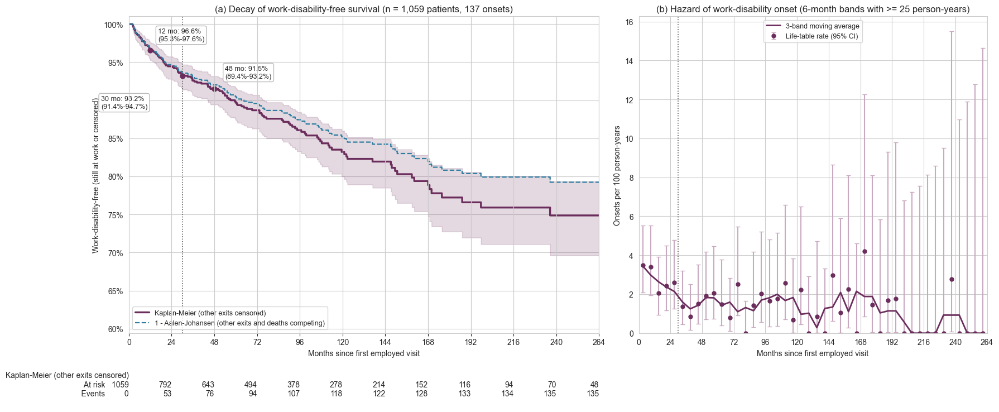

Work-disability-free at 30 months: KM 93.2% (cumulative incidence 6.8%); with other exits and deaths as competing events, cumulative incidence 6.4%
Onset rate per 100 person-years by band:
   band  events     py  rate   lo    hi
    0-6      18 515.01  3.50 2.07  5.52
   6-12      16 469.86  3.41 1.95  5.53
  12-18       9 437.34  2.06 0.94  3.91
  18-24      10 409.38  2.44 1.17  4.49
  24-30      10 384.42  2.60 1.25  4.78
  30-36       5 364.82  1.37 0.45  3.20
  36-42       3 348.14  0.86 0.18  2.52
  42-48       5 331.23  1.51 0.49  3.52
  48-54       6 312.40  1.92 0.70  4.18
  54-60       6 292.99  2.05 0.75  4.46
  60-66       4 271.80  1.47 0.40  3.77
  66-72       2 254.12  0.79 0.10  2.84
  72-78       6 238.59  2.51 0.92  5.47
  78-84       0 222.70  0.00 0.00  1.66
  84-90       3 210.56  1.42 0.29  4.16
  90-96       4 196.90  2.03 0.55  5.20
 96-102       3 182.31  1.65 0.34  4.81
102-108       3 169.82  1.77 0.36  5.16
108-114       4 155.57  2.57 0.70  6.58
114-120    

In [3]:
"""
Follow-up diagnostics and Kaplan-Meier decay of work-disability-free survival.

Time zero = first employed visit; event = first work-disability onset (dated as in the landmark builder). The
Kaplan-Meier curve censors the competing causes (other exit, death) as well as the last visit and age 65; the
Aalen-Johansen curve treats other exits and deaths as competing events (the cumulative incidence the models target).

1. How index follow-up ends, and for how long patients are followed.
2. Kaplan-Meier figure:
   (a) work-disability-free survival S(t) with its 95% CI, the number at risk underneath, and S(t) marked at 12,
       30 and 48 months -- the decay of the employed cohort. 1 - Aalen-Johansen is overlaid: it treats other exits
       and deaths as competing events instead of censoring them (the lower, 'real-world' cumulative incidence).
   (b) the hazard behind that decay: life-table onset rate per 100 person-years in 6-month bands, with exact
       Poisson 95% CIs, i.e. whether the risk of onset is front-loaded or constant over follow-up.
3. Landmark-level follow-up: how it ends, and how many landmarks are censored before 30 months (kept via IPCW).
"""
from lifelines import KaplanMeierFitter, AalenJohansenFitter
from lifelines.plotting import add_at_risk_counts

km_df = patients_df[patients_df["ever_employed"] & (patients_df["km_time_days"] > 0)].copy()
km_df["t_months"] = km_df["km_time_days"] / MONTH_DAYS
W = 100

# ------------------------------------------------------------------ 1. follow-up by how it ends
print("=" * W)
print("1. FOLLOW-UP FROM THE FIRST EMPLOYED VISIT, BY HOW IT ENDS (months)")
print("-" * W)
fu = km_df.groupby("km_exit")["t_months"].agg(N="size", median="median", q1=lambda s: s.quantile(.25),
                                             q3=lambda s: s.quantile(.75), max="max")
fu["%"] = 100 * fu["N"] / len(km_df)
print(fu.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
rkm = KaplanMeierFitter().fit(km_df["t_months"], 1 - km_df["km_event"])
print(f"\nMedian potential follow-up (reverse Kaplan-Meier): {rkm.median_survival_time_:.1f} months")
print(f"Patients followed < {PRIMARY_HORIZON_MONTHS} months without an onset: "
      f"{int(((km_df['t_months'] < PRIMARY_HORIZON_MONTHS) & (km_df['km_event'] == 0)).sum())} "
      f"(kept through the censoring-aware target)")

# ------------------------------------------------------------------ 2. Kaplan-Meier decay + hazard
kmf = KaplanMeierFitter(label="Kaplan-Meier (other exits censored)").fit(km_df["t_months"], km_df["km_event"])
ev_code = km_df["km_cause"].astype(int).values          # 1 disability, 2 other exit, 3 death, 0 censored
with warnings.catch_warnings():                      # tied times are jittered by lifelines (seeded)
    warnings.simplefilter("ignore")
    ajf = AalenJohansenFitter(calculate_variance=False, seed=SEED).fit(
        pd.Series(km_df["t_months"].values), pd.Series(ev_code), event_of_interest=1)

x_max = float(np.ceil(km_df["t_months"].quantile(0.95) / 12) * 12)
ticks = list(np.arange(0, x_max + 1, 24))
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
kmf.plot_survival_function(ax=ax, color="#6b2d5c", lw=2.4, ci_show=True, ci_alpha=0.18)
aj_s = 1 - ajf.cumulative_density_.iloc[:, 0]
ax.step(aj_s.index, aj_s.values, where="post", color="#2c7da0", lw=1.6, ls="--",
        label="1 - Aalen-Johansen (other exits and deaths competing)")
for m, off in [(12, (10, 12)), (PRIMARY_HORIZON_MONTHS, (-105, -42)), (48, (14, 14))]:
    s = float(kmf.survival_function_at_times(m).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(m).values
    ax.scatter([m], [s], color="#6b2d5c", zorder=5, s=40)
    ax.annotate(f"{m} mo: {s:.1%}\n({lo:.1%}-{hi:.1%})", (m, s), textcoords="offset points",
                xytext=off, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb"))
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
med = kmf.median_survival_time_
if np.isfinite(med):
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.text(med, 0.51, f"median {med:.0f} mo", fontsize=9, color="gray")
ax.set_xlim(0, x_max); ax.set_xticks(ticks)
ax.set_ylim(max(0.0, float(kmf.survival_function_.values.min()) - 0.1), 1.01)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Work-disability-free (still at work or censored)")
ax.set_title(f"(a) Decay of work-disability-free survival (n = {len(km_df):,} patients, "
             f"{int(km_df['km_event'].sum())} onsets)")
ax.legend(loc="lower left", fontsize=9)
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events"], xticks=ticks)

# (b) life-table hazard in 6-month bands
band = 6.0
edges = np.arange(0, x_max + band, band)
T, E = km_df["t_months"].values, km_df["km_event"].values
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    exposure_py = np.clip(np.minimum(T, hi) - lo, 0, None).sum() / 12.0
    d = int(((E == 1) & (T > lo) & (T <= hi)).sum())
    if exposure_py < 25:                             # too little person-time for a readable rate
        continue
    ci_lo = stats.chi2.ppf(0.025, 2 * d) / 2 if d > 0 else 0.0
    ci_hi = stats.chi2.ppf(0.975, 2 * d + 2) / 2
    rows.append({"band_mid": (lo + hi) / 2, "events": d, "py": exposure_py, "rate": 100 * d / exposure_py,
                 "lo": 100 * ci_lo / exposure_py, "hi": 100 * ci_hi / exposure_py})
hz = pd.DataFrame(rows)
ax = axes[1]
ax.errorbar(hz["band_mid"], hz["rate"], yerr=[hz["rate"] - hz["lo"], hz["hi"] - hz["rate"]], fmt="o",
            color="#6b2d5c", ecolor="#c9a9c0", capsize=3, ms=5, label="Life-table rate (95% CI)")
if len(hz) >= 3:
    sm = hz["rate"].rolling(3, center=True, min_periods=1).mean()
    ax.plot(hz["band_mid"], sm, color="#6b2d5c", lw=2, label="3-band moving average")
ax.axvline(PRIMARY_HORIZON_MONTHS, color="#555555", ls=":", lw=1.2)
ax.set_xlim(0, x_max); ax.set_xticks(ticks); ax.set_ylim(0, None)
ax.set_xlabel("Months since first employed visit")
ax.set_ylabel("Onsets per 100 person-years")
ax.set_title("(b) Hazard of work-disability onset (6-month bands with >= 25 person-years)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/revised_v27_km_work_disability_decay.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

s30 = float(kmf.survival_function_at_times(PRIMARY_HORIZON_MONTHS).iloc[0])
aj30 = float(ajf.cumulative_density_.asof(PRIMARY_HORIZON_MONTHS).iloc[0])
print(f"Work-disability-free at {PRIMARY_HORIZON_MONTHS} months: KM {s30:.1%} (cumulative incidence {1 - s30:.1%}); "
      f"with other exits and deaths as competing events, cumulative incidence {aj30:.1%}")
print("Onset rate per 100 person-years by band:")
print(hz.assign(band=lambda d: [f"{m - band / 2:.0f}-{m + band / 2:.0f}" for m in d["band_mid"]])
      [["band", "events", "py", "rate", "lo", "hi"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# ------------------------------------------------------------------ 3. landmark-level censoring
print("\n" + "=" * W)
print(f"3. LANDMARKS BY HOW FOLLOW-UP ENDS, and share censored before {PRIMARY_HORIZON_MONTHS} months")
print("-" * W)
lt = land.assign(before_h=(land["cause"] == 0) & (land["time_days"] <= HORIZON_DAYS))
tab = lt.groupby("exit_type").agg(landmarks=("pid", "size"), patients=("pid", "nunique"),
                                  median_fu_mo=("time_days", lambda s: s.median() / MONTH_DAYS),
                                  censored_before_30mo=("before_h", "sum"))
print(tab.to_string(float_format=lambda v: f"{v:.1f}"))
G_diag = CensoringKM(T_ALL, C_ALL)
print(f"Censoring survival G(30 mo) = {float(G_diag.at([HORIZON_DAYS])[0]):.2f}: controls are up-weighted by about "
      f"{1 / max(float(G_diag.at([HORIZON_DAYS])[0]), IPCW_MIN_G):.1f}x in every IPCW metric.")
print("=" * W)

## 11.3.1 Is censoring informative?

Censoring is harmless only if who is censored does not depend on disability risk. A **discrete-time hazard of
censoring** (the end of follow-up at the last recorded employment status or at age 65, before any onset or exit) is
fitted on the 12 variables and the calendar year in 5 patient-grouped folds and scored on the held-out patients with Uno's C for
"censored by 30 months". The interval indicators alone give C = 0.5, so the C-index measures how much the variables say
about who is censored. The rule is fixed in advance (`CENSORING_SIGNAL_C`): **C ≥ 0.60** means censoring carries
information. The sequence models' and the baseline's loss are then weighted by $1/\hat G_k(x)$ from a censoring model
fitted inside every training set, and Section 11.15.2 adds covariate-adjusted AUROC(t). Otherwise simple censoring is
kept.

In [4]:
"""
Censoring diagnostic and the censoring model used for covariate IPCW.

CensoringModel: a person-interval logistic regression of CENSORING (cause 0) on CENSORING_COLS
(training-fold skew transform + one imputation + standardisation, as the tabular models), with interval indicators as
the baseline hazard, landmark-weighted. A landmark is at risk of censoring in every interval up to the
end of its follow-up; an onset, exit or death ends that risk without being censoring (censor_causes=(0,)). With
censor_causes=(0, 2, 3) it models 'censored or a competing event', the censoring of the cause-specific evaluation.
G_before(idx)[:, k] = P(not censored before interval k | x), the weight 1 / G of interval k.
"""
from sklearn.model_selection import StratifiedGroupKFold as _SGKF


class CensoringModel:
    def __init__(self, censor_causes=(0,), C=1.0):
        self.censor_causes, self.C = tuple(censor_causes), C

    def fit(self, idx):
        idx = np.asarray(idx)
        self.prep = TabularPrep(CENSORING_COLS, m=1, method="linear")
        X = self.prep.fit_transform(X_for(idx, CENSORING_COLS), PID_ALL[idx])[0]
        b = np.searchsorted(INTERVAL_EDGES_DAYS[1:], T_ALL[idx], side="left")[:, None]
        k = np.arange(N_INTERVALS)[None, :]
        cens = np.isin(C_ALL[idx], self.censor_causes)[:, None]
        R = (k < b) | ((k == b) & cens)                                     # at risk of censoring in interval k
        r, kk = np.nonzero(R)
        y = (cens & (k == b))[r, kk].astype(int)
        Z = np.hstack([X[r], np.eye(N_INTERVALS)[kk]])
        self.lr = LogisticRegression(C=self.C, fit_intercept=False, max_iter=3000).fit(
            Z, y, sample_weight=norm_weights(land["weight"].values[idx])[r])
        return self

    def hazards(self, idx):
        idx = np.asarray(idx)
        X = self.prep.transform(X_for(idx, CENSORING_COLS), PID_ALL[idx])[0]
        Z = np.hstack([np.repeat(X, N_INTERVALS, axis=0), np.tile(np.eye(N_INTERVALS), (len(idx), 1))])
        return self.lr.predict_proba(Z)[:, 1].reshape(len(idx), N_INTERVALS)

    def G_before(self, idx):
        h = self.hazards(idx)
        return np.cumprod(np.hstack([np.ones((len(h), 1)), 1 - h[:, :-1]]), axis=1)

    def G_at_days(self, idx, days, before=False):
        """P(not censored by `days` | x) (through the interval containing `days`; before=True: before it)."""
        G = np.cumprod(1 - self.hazards(idx), axis=1)
        G0 = np.hstack([np.ones((len(G), 1)), G[:, :-1]])
        b = np.minimum(np.searchsorted(INTERVAL_EDGES_DAYS[1:], np.broadcast_to(days, (len(G),)), side="left"),
                       N_INTERVALS - 1)
        return (G0 if before else G)[np.arange(len(G)), b]


_CW_CACHE = {}


def censoring_weights(idx):
    """(len(idx), N_INTERVALS) weights 1 / G_k(x) for landmark rows idx, from a CensoringModel fitted on idx only
    (cached in memory and in the fold-input cache: every configuration, model and re-run shares them)."""
    idx = np.asarray(idx)
    key = hashlib.sha1(idx.tobytes()).hexdigest()
    if key not in _CW_CACHE:
        if len(_CW_CACHE) >= 8:
            _CW_CACHE.pop(next(iter(_CW_CACHE)))
        ck = fc_key("cw", idx, X_for(idx, CENSORING_COLS), T_ALL[idx], C_ALL[idx], land["weight"].values[idx],
                    PID_ALL[idx])
        cw = fc_get("cw", ck)
        if cw is None:
            G = CensoringModel().fit(idx).G_before(idx)
            cw = fc_put("cw", ck, (1.0 / np.maximum(G, IPCW_MIN_G)).astype(np.float32))
        _CW_CACHE[key] = cw
    return _CW_CACHE[key]


def censoring_diagnostic(n_splits=5):
    """Out-of-fold risk of censoring by 30 months and Uno's C per held-out fold."""
    oof, cs = np.full(len(land), np.nan), []
    for a, b in _SGKF(n_splits, shuffle=True, random_state=CV_SEED).split(np.zeros(len(land)), land["pt_event"].values,
                                                                          PID_ALL):
        oof[b] = 1 - CensoringModel().fit(a).G_at_days(b, HORIZON_DAYS)
        cs.append(uno_c_index(T_ALL[b], (C_ALL[b] == 0).astype(int), oof[b], HORIZON_DAYS))
    return np.array(cs), oof


cens_c, cens_oof = censoring_diagnostic()
CENSORING_C_CV = float(np.nanmean(cens_c))
print(f"Censoring model, 5-fold patient-grouped CV: Uno's C for 'censored by {PRIMARY_HORIZON_MONTHS} months' = "
      f"{CENSORING_C_CV:.3f} (folds {', '.join(f'{c:.3f}' for c in cens_c)}); 0.5 = no information")
q = pd.qcut(cens_oof, 5, labels=False, duplicates="drop")
rows = []
for g in range(int(q.max()) + 1):
    k = q == g
    km = KaplanMeierFitter().fit(T_ALL[k], (C_ALL[k] == 0).astype(int))
    rows.append({"Quintile of predicted censoring risk": g + 1, "Landmarks": int(k.sum()),
                 "Predicted, by 30 mo": float(cens_oof[k].mean()),
                 "Observed (Kaplan-Meier), by 30 mo": float(1 - km.survival_function_at_times(HORIZON_DAYS).iloc[0]),
                 "Onset within 30 mo (share of resolved)": float(np.nanmean(land["label30"].values[k]))})
display(pd.DataFrame(rows).set_index("Quintile of predicted censoring risk").round(3))
cm_all = CensoringModel().fit(np.arange(len(land)))
coef = pd.Series(cm_all.lr.coef_[0][:len(CENSORING_COLS)], index=[DISPLAY_NAMES.get(c, c) for c in CENSORING_COLS])
print("Strongest predictors of censoring (log-odds per SD, all landmarks; for description):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index)[:10].round(3).to_string())
if CENSORING_IPCW == "auto":
    CENSORING_IPCW_ON = CENSORING_C_CV >= CENSORING_SIGNAL_C
else:
    CENSORING_IPCW_ON = bool(CENSORING_IPCW)
print(f"\nDecision (C >= {CENSORING_SIGNAL_C:.2f}, CENSORING_IPCW = {CENSORING_IPCW!r}): "
      + ("censoring carries information -> covariate IPCW (1 / G_k(x), fitted inside every training set) in the "
         "sequence models' and the baseline's loss and in the cause-specific AUROC(t)" if CENSORING_IPCW_ON
         else "no real signal -> simple censoring; no covariate IPCW"))

Censoring model, 5-fold patient-grouped CV: Uno's C for 'censored by 30 months' = 0.804 (folds 0.844, 0.819, 0.810, 0.801, 0.748); 0.5 = no information


,Landmarks,"Predicted, by 30 mo","Observed (Kaplan-Meier), by 30 mo",Onset within 30 mo (share of resolved)
Quintile of predicted censoring risk,,,,
1,3371,0.066,0.049,0.050
2,3370,0.099,0.053,0.044
3,3370,0.147,0.072,0.052
4,3370,0.255,0.087,0.040
5,3370,0.596,0.492,0.032


Strongest predictors of censoring (log-odds per SD, all landmarks; for description):
Calendar year, spline term (adjustment)               1.592
Calendar year (adjustment)                           -0.858
Years since first employed visit                     -0.290
Days since last visit                                 0.185
Education: not recorded                              -0.176
Age                                                   0.079
Prednisone, average dose since last visit (mg/day)    0.051
SLEDAI-2K                                            -0.035
SDI damage score                                      0.027
Education: higher                                    -0.014

Decision (C >= 0.60, CENSORING_IPCW = 'auto'): censoring carries information -> covariate IPCW (1 / G_k(x), fitted inside every training set) in the sequence models' and the baseline's loss and in the cause-specific AUROC(t)


## 11.4 Table 1 — baseline characteristics by outcome group

In [5]:
"""
Table 1 -- baseline characteristics by outcome group.

Groups (patient level, mutually exclusive, first match wins):
  Became Disabled   : a work-disability onset after some landmark
  Other Exits       : follow-up of some landmark ended in retirement / homemaker / student / job-seeking / other
  Deceased          : died
  Remained Employed : none of the above (censored at last visit)
Plus an 'Overall' column across every patient who contributes a landmark.

Baseline = the INDEX (first employed) visit row, so every baseline value comes from the same visit. Follow-up, disease course and treatment are
aggregated over each patient's full visit record. Continuous -> mean (SD) | median [IQR], Kruskal-Wallis;
categorical -> n (%), chi-square.
"""


def _patient_outcome_group(land, pts):
    g = land.groupby("pid")
    ev = g["event"].max()
    other = g["exit_type"].apply(lambda s: (s == "other_exit").any())
    out = pd.Series("Remained Employed", index=ev.index)
    out[pts.loc[ev.index, "dead"].values] = "Deceased"
    out[other] = "Other Exits"
    out[ev == 1] = "Became Disabled"
    return out.rename("outcome_group")


def _first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_table1_baseline(land, pts, visits):
    outcome = _patient_outcome_group(land, pts)
    v = visits[visits["PTNO"].isin(outcome.index)]
    g = v.groupby("PTNO")
    idx_rows = v[v["ASSDT"] == v["PTNO"].map(pts["index_date"])].set_index("PTNO")
    last_rows = g.last()
    ever = lambda col: g[col].apply(lambda s: int((pd.to_numeric(s, errors="coerce").fillna(0) > 0).any()))
    b = pd.DataFrame(index=outcome.index)
    # ---- sociodemographics (patient-constant: first recorded value across all visits)
    b["sex"] = g["SEX"].apply(_first_nonnull)
    b["race"] = g["RACE_LABEL"].apply(_first_nonnull)
    b["ethnicity"] = g["DS_ETHNICITY"].apply(_first_nonnull)
    b["education"] = g["DS_MAX_EDU"].apply(_first_nonnull)
    b["age_index"] = idx_rows["age_at_record"]
    b["disease_duration_yrs"] = idx_rows["disease_duration_yrs"]
    # ---- follow-up
    b["n_visits"] = g.size()
    b["followup_years"] = (last_rows["ASSDT"] - idx_rows["ASSDT"]).dt.days / 365.25
    b["mean_gap_days"] = g["DAYS_SINCE_LAST_VISIT"].mean()
    b["n_landmarks"] = land.groupby("pid").size()
    # ---- disease activity, flares and damage
    b["sledai_baseline"] = idx_rows["SLEDAI2_I"]
    b["sledai_mean"] = g["SLEDAI2_I"].mean()
    b["sledai_ams_index"] = idx_rows["SLEDAI_AMS"]
    b["ever_flare_mild"] = g["FLARE_MILD_MOD"].max().astype(int)
    b["ever_flare_severe"] = g["FLARE_SEVERE"].max().astype(int)
    b["sdi_baseline"] = idx_rows["score_n"]
    b["sdi_last"] = last_rows["score_n"]
    # ---- employment history at index / during follow-up
    b["prior_sick_leave"] = (idx_rows["PRIOR_SICK_LEAVE_VISITS"] > 0).astype(int)
    b["ever_sick_leave"] = g["EMP"].apply(lambda s: int(s.isin(SICK_STATES).any()))
    # ---- treatment, ever during follow-up
    b["ever_steroid"] = g["ON_STEROID"].max().astype(int)
    b["steroid_dose_mean"] = g["STERAVER"].mean()
    b["ever_steroid_pulse"] = ever("STPDOSE")
    b["ever_antimalarial"] = g["ON_ANTIMALARIAL"].max().astype(int)
    b["ever_immunosuppressive"] = g["HAS_IMMUNOSUPPRESSIVE_REC"].max()
    b["ever_cyclophosphamide"] = ever("IS_CYCLOPHOSPHAMIDE_DOSE")
    b["ever_mycophenolate"] = ever("IS_MYCOPHENOLATE_DOSE")
    b["ever_methotrexate"] = ever("IS_METHOTREXATE_DOSE")
    b["ever_biologic"] = g["HAS_BIOLOGIC_REC"].max()
    b["ever_rituximab"] = ever("BIOG_RIT")
    b["ever_belimumab"] = ever("BIOG_BEL")
    return b.join(outcome, how="inner")


def _fmt_cont(s):
    s = s.dropna().astype(float)
    if not len(s):
        return "n=0"
    return f"{s.mean():.1f} ({s.std():.1f}) | {s.median():.1f} [{s.quantile(.25):.1f}-{s.quantile(.75):.1f}]"


def _fmt_cat(s, level):
    s = s.dropna()
    n = int((s == level).sum())
    return f"{n} ({100 * n / len(s):.1f}%)" if len(s) else "0"


def _pval(test):
    try:
        return f"{test():.3f}"
    except ValueError:
        return "n/a"


def make_table1(b, groups=("Remained Employed", "Became Disabled", "Deceased", "Other Exits")):
    groups = [x for x in groups if x in set(b["outcome_group"])]
    rows = [{"Variable": "N", "Overall": str(len(b)), **{x: str((b.outcome_group == x).sum()) for x in groups},
             "p": ""}]
    section = lambda t: rows.append({"Variable": f"**{t}**", "Overall": "", **{x: "" for x in groups}, "p": ""})

    def cont(col, label):
        arrs = [a for a in (b.loc[b.outcome_group == x, col].dropna().astype(float) for x in groups) if len(a)]
        rows.append({"Variable": f"{label}, mean (SD) | median [IQR]", "Overall": _fmt_cont(b[col]),
                     **{x: _fmt_cont(b.loc[b.outcome_group == x, col]) for x in groups},
                     "p": _pval(lambda: stats.kruskal(*arrs).pvalue)})

    def cat(col, label, levels=None, names=None):
        p = _pval(lambda: stats.chi2_contingency(pd.crosstab(b[col], b["outcome_group"]))[1])
        levels = levels or sorted(b[col].dropna().unique().tolist(), key=str)
        if len(levels) > 1:
            rows.append({"Variable": f"{label}, n (%)", "Overall": "", **{x: "" for x in groups}, "p": p})
        for lv in levels:
            nm = (names or {}).get(lv, lv)
            rows.append({"Variable": f"    {nm}" if len(levels) > 1 else f"{label}, n (%)",
                         "Overall": _fmt_cat(b[col], lv),
                         **{x: _fmt_cat(b.loc[b.outcome_group == x, col], lv) for x in groups},
                         "p": "" if len(levels) > 1 else p})

    section("Sociodemographics")
    cont("age_index", "Age at index (years)")
    cat("sex", "Sex")
    cat("race", "Race")
    cat("ethnicity", "Ethnicity")
    cat("education", "Education (DS_MAX_EDU)", names={0.0: "Lower", 1.0: "Higher"})
    cont("disease_duration_yrs", "Disease duration at index (years)")
    section("Follow-up")
    cont("n_visits", "Number of visits")
    cont("followup_years", "Follow-up from index (years)")
    cont("mean_gap_days", "Mean time between visits (days)")
    cont("n_landmarks", "Landmark visits")
    section("Disease activity, flares and damage")
    cont("sledai_baseline", "SLEDAI-2K at index")
    cont("sledai_ams_index", "Adjusted mean SLEDAI-2K at index")
    cont("sledai_mean", "SLEDAI-2K, mean across follow-up")
    cat("ever_flare_mild", "Any mild/moderate flare (SLEDAI-2K +4 to +10)", levels=[1])
    cat("ever_flare_severe", "Any severe flare (SLEDAI-2K > +10)", levels=[1])
    cont("sdi_baseline", "SDI at index")
    cont("sdi_last", "SDI at last visit")
    section("Employment history")
    cat("prior_sick_leave", "Sick leave before index", levels=[1])
    cat("ever_sick_leave", "Any sick leave during follow-up", levels=[1])
    section("Treatment (ever during follow-up)")
    cat("ever_steroid", "Ever on steroids", levels=[1])
    cont("steroid_dose_mean", "Average daily steroid dose, mg (visits with a value)")
    cat("ever_steroid_pulse", "Ever received steroid pulse", levels=[1])
    cat("ever_antimalarial", "Ever on antimalarial", levels=[1])
    cat("ever_immunosuppressive", "Ever on immunosuppressive therapy", levels=[1])
    cat("ever_cyclophosphamide", "    Ever cyclophosphamide", levels=[1])
    cat("ever_mycophenolate", "    Ever mycophenolate", levels=[1])
    cat("ever_methotrexate", "    Ever methotrexate", levels=[1])
    cat("ever_biologic", "Ever on biologic therapy", levels=[1])
    cat("ever_rituximab", "    Ever rituximab", levels=[1])
    cat("ever_belimumab", "    Ever belimumab", levels=[1])
    return pd.DataFrame(rows)[["Variable", "Overall"] + groups + ["p"]]


table1_base = build_table1_baseline(land, patients_df, visits)
table1 = make_table1(table1_base)
pd.set_option("display.max_rows", None)
display(table1)
table1.to_csv("table1_baseline_characteristics_model_revised_v27.csv", index=False)

,Variable,Overall,Remained Employed,Became Disabled,Deceased,Other Exits,p
0,N,1059,687,150,33,189,
1,**Sociodemographics**,,,,,,
2,"Age at index (years), mean (SD) | median [IQR]",36.1 (10.9) | 34.5 [27.3-43.8],35.5 (10.6) | 33.7 [27.6-42.4],38.4 (11.1) | 38.8 [29.3-47.0],42.3 (12.1) | 42.4 [31.9-53.5],35.0 (11.4) | 33.9 [25.7-43.3],0.000
3,"Sex, n (%)",,,,,,0.020
4,F,933 (88.2%),603 (87.9%),138 (92.0%),24 (72.7%),168 (88.9%),
5,M,125 (11.8%),83 (12.1%),12 (8.0%),9 (27.3%),21 (11.1%),
6,"Race, n (%)",,,,,,0.000
7,Black,151 (14.7%),94 (14.4%),29 (19.3%),7 (21.2%),21 (11.2%),
8,Caucasian,611 (59.6%),355 (54.2%),99 (66.0%),20 (60.6%),137 (72.9%),
9,Chinese,111 (10.8%),86 (13.1%),10 (6.7%),3 (9.1%),12 (6.4%),


## 11.5 Variables

Section 5. The core every model reads (7 variables and the calendar-year terms) and pool B, from which each model chooses up to 10, with the Riley et
al. sample-size criteria and each variable's missingness and distribution at the landmark visits.

In [6]:
"""
Variables: pre-specified set (Sections 5.1-5.3; TRIPOD+AI items 9 and 10).

revised_v27: every model reads the CORE -- FORCED_COLS, the 7 literature variables MODEL_VARIABLES (Section 5.1) and
the calendar-year terms -- and up to SELECT_MAX_EXTRA variables of POOL B (the pre-filtered pool minus the core; the
pre-filter uses missingness, prevalence and correlation only) chosen INSIDE every training fit by the model's own
method (Section 5.2; fold_features, Section 11.8). The selection is nested in the cross-validation.

SAMPLE SIZE. The largest number of parameters that meets the three criteria of Riley et al. (BMJ 2020; Stat Med 2019,
time-to-event version) for the cohort -- n = patients with a landmark, phi = share with an onset -- at an anticipated
C of ANTICIPATED_C: (i) expected uniform shrinkage >= 0.9, (ii) optimism in Nagelkerke R2 <= 0.05, (iii) the overall
risk within +-0.05. Reported against the set's number of parameters (TRIPOD+AI item 10).
"""
from sklearn.model_selection import StratifiedGroupKFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

FORCE_SCALE = 100.0
LASSO_REFINE_STEPS = 8              # bisection steps between two grid penalties when the cap falls between them


def _sim_survival(sigma, phi, n, seed):
    """A time-to-event cohort: exponential event times with log-hazard ~ N(0, sigma^2), uniform censoring scaled so
    that a share phi has the event."""
    rng = np.random.default_rng(seed)
    lp = rng.normal(0.0, sigma, n)
    t, u = rng.exponential(np.exp(-lp)), rng.random(n)
    m = brentq(lambda mm: (t < u * mm).mean() - phi, 1e-6, 1e6)
    c = u * m
    return lp, np.minimum(t, c), (t < c).astype(int)


def riley_pmax(n, events, c_stat, S=0.9, n_sim=None, seed=SEED):
    """P_MAX of Riley et al.'s criteria (time-to-event version) for n patients with `events` onsets at anticipated
    Harrell C `c_stat`."""
    n_sim = n_sim or (5000 if SMOKE else 20000)
    phi = events / n
    c_of = lambda s: concordance_index(*(lambda lp, t, e: (t, -lp, e))(*_sim_survival(s, phi, n_sim, seed)))
    sigma = brentq(lambda s: c_of(s) - c_stat, 0.05, 3.0, xtol=1e-3)
    lp, t, e = _sim_survival(sigma, phi, n_sim, seed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph = CoxPHFitter().fit(pd.DataFrame({"t": t, "e": e, "lp": lp}), "t", "e")
    lr = float(cph.log_likelihood_ratio_test().test_statistic)
    r2 = 1 - np.exp(-lr / n_sim)
    r2max = 1 - np.exp(2 * (cph.log_likelihood_ - lr / 2) / n_sim)
    p_of = lambda s: n * (s - 1) * np.log(1 - r2 / s)
    s2 = r2 / (r2 + 0.05 * r2max)
    p1, p2 = p_of(S), p_of(s2)
    n3 = (1.96 / 0.05) ** 2 * phi * (1 - phi)
    return {"Patients (n)": n, "Patients with an onset": events, "Anticipated C": c_stat,
            "Anticipated R2_CS": round(r2, 4), "Max R2_CS": round(r2max, 4),
            "P allowed: shrinkage >= 0.9": round(p1, 1), "P allowed: optimism <= 0.05": round(p2, 1),
            "n needed: overall risk +-0.05": int(np.ceil(n3)), "Criterion (iii) met": bool(n >= n3),
            "P_MAX": int(np.floor(min(p1, p2)))}


RILEY = riley_pmax(int(land["pid"].nunique()), int(land.groupby("pid")["event"].max().sum()), ANTICIPATED_C)
P_MAX = N_MODEL_VARIABLES + len(ADJUST_COLS)              # parameters of the linear models (no splines)
LASSO_MAX_SELECTED = 0
_missing = [c for c in FORCED_COLS if c not in FEATURE_CANDIDATES]
assert not _missing, f"pre-specified variables missing from the data: {_missing}"
SELECTION_ALL = {"features": [c for c in FEATURE_CANDIDATES if c in FORCED_COLS],
                 "features_wide": list(FEATURE_CANDIDATES),          # the whole pre-filtered pool (core + pool B)
                 "freq": pd.Series([float(c in FORCED_COLS) for c in PENALISED_COLS], index=PENALISED_COLS),
                 "coef": pd.Series(np.nan, index=PENALISED_COLS), "rule": "pre-specified",
                 "n_selected": N_MODEL_VARIABLES}
SEL_BOOT_FREQ = None

print(f"Sample-size criteria (Riley et al.; time-to-event; anticipated C = {ANTICIPATED_C}):")
display(pd.Series(RILEY).to_frame("value"))
print(f"The model has {P_MAX} parameters ({N_MODEL_VARIABLES} variables + {len(ADJUST_COLS)} calendar-year terms); "
      f"the criteria allow {RILEY['P_MAX']}"
      + (": some optimism and a calibration slope below 1 are expected; every risk is recalibrated inside the training "
         "folds (Section 7)." if P_MAX > RILEY["P_MAX"] else "."))
_rows = []
for c in SELECTION_ALL["features"]:
    x = land[c].astype(float)
    vals = np.unique(x.dropna())
    binary = len(vals) <= 2 and set(vals) <= {0.0, 1.0}
    _rows.append({"Variable": DISPLAY_NAMES.get(c, c), "Group": FEATURE_GROUP_OF.get(c, "Calendar-time adjustment"),
                  "Missing at landmarks": f"{x.isna().mean():.1%}",
                  "Landmarks: % or median [IQR]": (f"{100 * x.mean():.1f}%" if binary else
                                                   f"{x.median():.1f} [{x.quantile(.25):.1f}, {x.quantile(.75):.1f}]")})
print(f"\nThe {len(SELECTION_ALL['features'])} model columns (every model, every fold):")
display(pd.DataFrame(_rows).set_index("Variable"))
pd.DataFrame(_rows).to_csv("model_variables_revised_v27.csv", index=False)
print(f"\nPool B -- the candidates every model may choose from ({len(SELECTION_ALL['features_wide'])} columns, of which "
      f"{len(ADJUST_COLS)} calendar-year terms; pre-filter: missingness, prevalence, correlation -- no outcome):")
display(PREFILTER_TABLE[PREFILTER_TABLE["Decision"].str.startswith(("candidate", "forced"))]
        .groupby("Group").size().rename("Columns").to_frame())
display(PREFILTER_TABLE[~PREFILTER_TABLE["Decision"].str.startswith(("candidate", "forced"))][["Group", "Variable", "Decision"]])


Sample-size criteria (Riley et al.; time-to-event; anticipated C = 0.72):


,value
Patients (n),1059
Patients with an onset,150
Anticipated C,0.72
Anticipated R2_CS,0.0916
Max R2_CS,0.9295
P allowed: shrinkage >= 0.9,11.4
P allowed: optimism <= 0.05,53.0
n needed: overall risk +-0.05,187
Criterion (iii) met,True
P_MAX,11


The model has 12 parameters (10 variables + 2 calendar-year terms); the criteria allow 11: some optimism and a calibration slope below 1 are expected; every risk is recalibrated inside the training folds (Section 7).

The 12 model columns (every model, every fold):


,Group,Missing at landmarks,Landmarks: % or median [IQR]
Variable,,,
Age,Demographics,0.0%,"41.6 [33.5, 49.9]"
Disease duration (yrs),Demographics,0.0%,"12.1 [5.9, 19.6]"
Race: Black,Demographics,0.0%,14.8%
"Race: Asian (Chinese, Filipino)",Demographics,0.0%,16.3%
Race: other / mixed / not recorded,Demographics,0.0%,7.9%
SDI damage score,Comorbidities and damage,0.0%,"1.0 [0.0, 3.0]"
Fibromyalgia,Comorbidities and damage,6.5%,11.0%
SLEDAI-2K,Severity scores,0.0%,"2.0 [0.0, 4.0]"
"Prednisone, average dose since last visit (mg/day)",Treatment,0.0%,"0.0 [0.0, 7.5]"



Pool B -- the candidates every model may choose from (108 columns, of which 2 calendar-year terms; pre-filter: missingness, prevalence, correlation -- no outcome):


,Columns
Group,
Calendar-time adjustment,2
Care and work,3
Change since the previous visit,12
Comorbidities and damage,19
Demographics,10
Engineered summaries,22
Laboratory,8
Missing-data indicators,2
Severity scores,11


,Group,Variable,Decision
Column,,,
LOG_HS_CRP,Laboratory,hs-CRP (log),excluded: missing at 24% of landmarks (> 20%)
WEIGHT_KG,Vital signs,Weight (kg),excluded: |r| = 0.91 with BMI (kg/m2)
SLEDAI_RENAL,Severity scores,SLEDAI-2K: renal,excluded: |r| = 0.97 with Proteinuria (SLEDAI-...
SLEDAI_SERO,Severity scores,SLEDAI-2K: serositis,excluded: prevalence 0.72% (< 1%)
STEROID_PULSE,Treatment,IV steroid pulse,excluded: prevalence 0.60% (< 1%)
ON_CYC,Treatment,Cyclophosphamide,excluded: prevalence 0.59% (< 1%)
CLIN_SLEDAI_DELTA,Change since the previous visit,Clinical SLEDAI-2K change since last visit,excluded: |r| = 0.95 with SLEDAI-2K change sin...


## 11.6 Patient-level evaluation

Section 9.2: every patient's 24-month window (before onset; before retirement / homemaker at ≥ 60; or the last 24
months of follow-up with a known 30-month outcome), the final-status strata and age bands, and the functions that turn
visit alarms into TP / FN / TN / FP (2 alarms in a row), a lead time and a patient probability. Printed: the
evaluation funnel.

In [7]:
"""
Patient-level evaluation (PATIENT_RULE = 'run', revised_v22-v23, the MAIN rule; Section 9.2): every patient is read
over a window of PATIENT_WINDOW_MONTHS (24) -- event patients before onset, event-free patients over their last months
of follow-up with a known 30-month outcome -- and is FLAGGED when PATIENT_ALARM_RUN (2) landmarks in a row alarmed.
The description below is of revised_v21's asymmetric rule ('mixed'), still computed for comparison.

Nothing is trained or tuned at the patient level. Every model is trained on landmark visits and its alarm threshold
is learned at visit level inside each training fold (Section 9). A landmark ALARMS when its calibrated 30-month risk
is >= that threshold. Patients are scored while held out, from their test-fold visit alarms:

  Event patients (a work-disability onset):
    window  the landmarks in the 60 months before the first onset
    TP / FN a landmark of the window alarmed / none did; dated at the earliest alarm (lead time = that landmark ->
            onset). No landmark in the 60 months: not assessable.
  Event-free patients, stratified by FINAL STATUS (state at their last visit: 'Employed at final visit',
  'Retired / homemaker >= 60' = left work for it at >= 60, 'Other final status'):
    window  the patient's last landmark (the last employed visit before the end of follow-up, an exit or age 65)
    TN / FP no alarm / an alarm at that landmark
The 30-month windows of revised_v17-v18 (LAND_PT_WIN_30: event patients, the 30 months before onset; event-free
patients, the latest fully observed 30-month window, or the 30 months before a retirement at >= 60) give the
comparison rules 'any alarm, 30-month window' (revised_v18) and 'last landmark, 30-month window' (revised_v17) in
the columns *_30. PATIENT_RULE = 'any' / 'last' makes one of those the main rule again.
The rule is asymmetric: an event patient has up to 60 months of visits to alarm once, an event-free patient one
visit to stay quiet, so sensitivity, specificity and the C-index are not comparable with revised_v17-v18.

The primary table uses every evaluable patient; each final-status stratum also gets its own table (all event
patients vs that stratum's negatives), and specificity and the C-index are reported by age band (age at the end of
the window).

Patient probability, for the C-index and calibration: the highest calibrated 30-month risk in the
window (event-free patients: the risk at the last landmark; PATIENT_RULE = 'last': the risk at the window's last
landmark), mapped to the probability of being an event patient by a logistic recalibration fitted in each training
fold on the training patients' cross-fitted (OOF) risks. PPV and NPV are also given at the cohort's share of
patients with an onset (Bayes' rule on sensitivity and specificity). Everything here is computed from the stored
fold predictions, so the definition can change without re-running the cross-validation.
"""
STRATA = ["Employed at final visit", f"Retired / homemaker >= {NEG_MIN_AGE}", "Other final status"]
AGE_BANDS = [(0, 40, "< 40"), (40, 50, "40-49"), (50, 60, "50-59"), (60, 200, ">= 60")]


def _exit_to_final_state(p):
    """(date, age) of the first visit of the patient's final non-working run if it was entered straight from
    employment, else (None, None)."""
    states = [_state_of(e) for e in p["EMP"].values]
    j = len(states) - 1
    while j >= 0 and states[j] != "W":
        j -= 1
    if j < 0 or j == len(states) - 1:
        return None, None
    k = j + 1
    while k < len(states) and states[k] == "U":
        k += 1
    if k >= len(states):
        return None, None
    return p["ASSDT"].iat[k], float(p["age_at_record"].iat[k])


def build_patient_truth(visits, land):
    """One row per patient with landmarks: group ('event' / 'negative' / 'excluded'), final-status stratum, the reason
    for exclusion, and the window end (onset, exit, or the end of the fully observed negative window)."""
    lg = land.groupby("pid", sort=False)
    ev, has_win = lg["event"].max(), lg["in_window"].max()
    rows = []
    for pid, idx in visits.groupby("PTNO", sort=False).indices.items():
        if pid not in ev.index:
            continue
        p = visits.iloc[idx]
        final = p["EMP"].iat[-1]
        rec = {"pid": pid, "group": "excluded", "stratum": None, "reason": None, "final_status": final,
               "exit_date": pd.NaT}
        if ev[pid] == 1:
            rec["stratum"] = "Event"
            if has_win[pid]:
                rec["group"] = "event"
            else:
                rec["reason"] = "onset with no landmark in the 30 months before"
            rows.append(rec)
            continue
        d_exit, a_exit = _exit_to_final_state(p)
        if final in NEG_EXIT_STATES and d_exit is not None and a_exit >= NEG_MIN_AGE:
            rec.update(stratum=STRATA[1], exit_date=d_exit)
        elif final in WORKING_STATES:
            rec["stratum"] = STRATA[0]
        else:
            rec["stratum"] = STRATA[2]
        rec["group"] = "negative"                        # confirmed below: needs a landmark in its window
        rows.append(rec)
    return pd.DataFrame(rows).set_index("pid")


PT_TRUTH = build_patient_truth(visits, land)
_stratum = PT_TRUTH["stratum"].reindex(PID_ALL).values
_exit = pd.to_datetime(PT_TRUTH["exit_date"].reindex(PID_ALL).values)
_vdate = pd.to_datetime(land["visit_date"].values)
_days_to_exit = np.asarray((_exit - _vdate).days, float)          # NaN if no retirement exit
# retirees: the 30 months before the exit
_win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= HORIZON_DAYS)
# everyone else event-free: the latest 30 months of landmarks each followed >= 30 months with no onset or exit
_resolved = (land["time_days"].values > HORIZON_DAYS) & (land["event"].values == 0)
_neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & _resolved
_last_resolved = pd.Series(np.where(_neg_other, _vdate.values, np.datetime64("NaT")),
                           dtype="datetime64[ns]").groupby(PID_ALL).transform("max").values
_win_observed = _neg_other & ((_last_resolved - _vdate.values) / np.timedelta64(1, "D") <= HORIZON_DAYS)
LAND_PT_WIN_30 = np.where(_stratum == "Event", land["in_window"].values == 1, _win_retired | _win_observed)
# revised_v21 ('mixed', comparison): event patients -- the landmarks in the MIXED_LOOKBACK_MONTHS before onset;
# event-free patients -- their last landmark (the end of their follow-up)
_win_event_long = ((_stratum == "Event") & (land["event"].values == 1)
                   & (land["time_days"].values <= MIXED_LOOKBACK_DAYS))
_neg_any = np.isin(_stratum, STRATA)
_last_land = pd.Series(np.where(_neg_any, _vdate.values, np.datetime64("NaT")),
                       dtype="datetime64[ns]").groupby(PID_ALL).transform("max").values
_win_neg_last = _neg_any & (_vdate.values == _last_land)
LAND_PT_WIN_MIXED = _win_event_long | _win_neg_last


def patient_window(days):
    """revised_v27: the landmarks that decide each patient over the same length of time `days` -- event patients:
    the landmarks in the `days` before their onset; retired / homemaker at >= 60: the `days` before that exit; every
    other event-free patient: the landmarks in the `days` before the last landmark whose 30-month outcome is known
    (followed > 30 months with no onset or exit). With days = 30 months these are revised_v18's windows."""
    win_ev = (land["event"].values == 1) & (land["time_days"].values <= days)
    win_ret = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= days)
    win_obs = _neg_other & ((_last_resolved - _vdate.values) / np.timedelta64(1, "D") <= days)
    return np.where(_stratum == "Event", win_ev, win_ret | win_obs)


assert np.array_equal(patient_window(HORIZON_DAYS), LAND_PT_WIN_30), "30-month windows must match revised_v18's"
LAND_PT_WIN_W = patient_window(PATIENT_WINDOW_DAYS)
LAND_PT_WIN = LAND_PT_WIN_MIXED if PATIENT_RULE == "mixed" else LAND_PT_WIN_W
PATIENT_RULE_TEXT = {"any": f"any alarm in the {PATIENT_WINDOW_MONTHS}-month window",
                     "last": f"the alarm at the last landmark of the {PATIENT_WINDOW_MONTHS}-month window",
                     "run": f"{PATIENT_ALARM_RUN} alarms in a row in the {PATIENT_WINDOW_MONTHS}-month window (event "
                            "patients: before onset; event-free patients: the last months of follow-up with a known "
                            "30-month outcome)",
                     "mixed": f"event patients: any alarm in the {MIXED_LOOKBACK_MONTHS} months before onset; "
                              "event-free patients: the alarm at their last landmark"}[PATIENT_RULE]

_has_window = pd.Series(LAND_PT_WIN).groupby(PID_ALL).max().reindex(PT_TRUTH.index).fillna(False).astype(bool)
_ev_pt = PT_TRUTH["stratum"] == "Event"              # event patients: evaluable with a landmark in their window
PT_TRUTH.loc[_ev_pt & _has_window, "group"] = "event"
PT_TRUTH.loc[_ev_pt & _has_window, "reason"] = None
PT_TRUTH.loc[_ev_pt & ~_has_window, "group"] = "excluded"
PT_TRUTH.loc[_ev_pt & ~_has_window, "reason"] = f"onset with no landmark in the {EVENT_LOOKBACK_MONTHS} months before"
_no_win = (PT_TRUTH["group"] == "negative") & ~_has_window
PT_TRUTH.loc[_no_win, "reason"] = np.where(PT_TRUTH.loc[_no_win, "stratum"] == STRATA[1],
                                          f"retired >= 60: no landmark in the {PATIENT_WINDOW_MONTHS} months before the exit",
                                          "event-free: never followed >= 30 months after a landmark")
PT_TRUTH.loc[_no_win, "group"] = "excluded"
PT_Y = (PT_TRUTH["group"] == "event").astype(int)
# age at the end of each evaluable patient's window (its last deciding landmark)
PT_AGE = pd.Series(land["age_at_record"].values[LAND_PT_WIN]).groupby(PID_ALL[LAND_PT_WIN]).max()
PT_AGE_BAND = pd.cut(PT_AGE, [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                     labels=[lab for _, _, lab in AGE_BANDS]).astype(str)
COHORT_EVENT_SHARE = float(land.groupby("pid")["event"].max().mean())   # share of landmark patients with an onset


def print_patient_funnel():
    t = PT_TRUTH
    ev = t[t.group == "event"]
    print(f"Patient-level evaluation set ({len(t)} patients with landmarks; cohort share with an onset "
          f"{COHORT_EVENT_SHARE:.1%}):")
    lb = EVENT_LOOKBACK_MONTHS
    print(f"Patient rule: {PATIENT_RULE_TEXT}")
    print(f"  event patients with a landmark in the {lb} months before onset (TP / FN): {len(ev)}")
    print("  event-free patients (TN / FP" + (", judged at their last landmark" if PATIENT_RULE == "mixed" else
                                             f", with a {PATIENT_WINDOW_MONTHS}-month window") + "), by final status:")
    for s in STRATA:
        n = int(((t.group == "negative") & (t.stratum == s)).sum())
        print(f"    {s:<40}{n:>6}")
    print("  not evaluated:")
    for reason, n in t[t.group == "excluded"]["reason"].value_counts().items():
        print(f"    {reason:<62}{n:>6}")
    ages = pd.DataFrame({"age band": PT_AGE_BAND, "y": PT_Y.reindex(PT_AGE_BAND.index)})
    print("  evaluable patients by age at the end of their window (events / event-free): "
          + ", ".join(f"{b}: {int((g.y == 1).sum())} / {int((g.y == 0).sum())}"
                      for b, g in ages.groupby("age band", sort=False)))
    print(f"  landmarks that decide a patient's outcome: {int(LAND_PT_WIN.sum()):,}")


print_patient_funnel()


VDAY_ALL = np.asarray((_vdate - _vdate.min()).days, float)     # days since the earliest landmark (order and gaps)
_EVENT_LAND = _stratum == "Event"                                # landmarks of event patients


def patient_collapse(r, s, a):
    """One row per patient from window landmarks r with scores s and alarms a, in date order. An event patient with
    several onsets (landmarks after disability) keeps the window of the first. Columns: score / flag under
    PATIENT_RULE; for comparison score_last / flag_last (the last landmark of the window), score_max /
    flag_any (revised_v16: the highest risk, any alarm) and score_first / flag_first; n_win and n_alarm; run_len (alarmed
    landmarks in the uninterrupted run that ends at the last landmark, 0 if that one is not alarmed); lead_mo (event
    patients: months from the first landmark of that run to onset; under 'any', from the earliest alarm);
    first_alarm_lead_mo (the earliest alarm's lead time); run_lead_mo (the final run's, under either rule); run_mo (months from the start of the run to the last landmark);
    day_last (VDAY_ALL of the last landmark)."""
    r = np.asarray(r)
    d = pd.DataFrame({"pid": PID_ALL[r], "day": VDAY_ALL[r], "t": T_ALL[r], "s": np.asarray(s, float),
                      "a": np.asarray(a, bool), "ev": _EVENT_LAND[r]})
    od = np.where(d["ev"].values, d["day"].values + d["t"].values, np.inf)           # onset day of event landmarks
    first_od = pd.Series(od).groupby(d["pid"].values).transform("min").values
    d = d[~d["ev"].values | (od <= first_od + 0.5)].sort_values(["pid", "day"], kind="mergesort")
    off = (~d["a"]).astype(int)
    g_off = off.groupby(d["pid"].values)
    d["in_run"] = (g_off.transform("sum") - g_off.cumsum() + off) == 0                # no un-alarmed landmark from here on
    g = d.groupby("pid", sort=True)
    first, last = g.head(1).set_index("pid"), g.tail(1).set_index("pid")
    run = d[d["in_run"]].groupby("pid")
    f = pd.DataFrame({"score_last": last["s"], "flag_last": last["a"].astype(int)})
    f["score_max"], f["flag_any"] = g["s"].max(), g["a"].max().astype(int)
    f["score_first"], f["flag_first"] = first["s"], first["a"].astype(int)
    f["n_win"], f["n_alarm"] = g.size(), g["a"].sum().astype(int)
    f["run_len"] = run.size().reindex(f.index).fillna(0).astype(int)
    ev = g["ev"].max().reindex(f.index).values.astype(bool)
    f["lead_mo"] = np.where(ev, run["t"].max().reindex(f.index).values / MONTH_DAYS, np.nan)
    f["run_lead_mo"] = f["lead_mo"]                                                   # the final run's lead time
    f["first_alarm_lead_mo"] = np.where(ev, d[d["a"]].groupby("pid")["t"].max().reindex(f.index).values / MONTH_DAYS,
                                        np.nan)
    f["run_mo"] = (last["day"] - run["day"].min().reindex(f.index)) / MONTH_DAYS
    f["day_last"] = last["day"]
    # revised_v27: PATIENT_ALARM_RUN alarms in a row anywhere in the window (all of its landmarks if it has fewer);
    # lead time from the landmark that completed the first such run to the onset
    a_, p_ = d["a"].values.astype(bool), d["pid"].values
    new_ = np.r_[True, (p_[1:] != p_[:-1]) | (a_[1:] != a_[:-1])]
    run_len_ = pd.Series(np.ones(len(d))).groupby(np.cumsum(new_)).cumsum().values * a_
    need_ = np.minimum(PATIENT_ALARM_RUN, d.groupby("pid")["a"].transform("size").values)
    hit_ = d[a_ & (run_len_ >= need_)]
    f["flag_run"] = hit_.groupby("pid").size().reindex(f.index).fillna(0).gt(0).astype(int)
    f["run_alarm_lead_mo"] = np.where(ev, hit_.groupby("pid")["t"].first().reindex(f.index).values / MONTH_DAYS,
                                      np.nan)
    if PATIENT_RULE == "run":
        f["score"], f["flag"], f["lead_mo"] = f["score_max"], f["flag_run"], f["run_alarm_lead_mo"]
    elif PATIENT_RULE in ("any", "mixed"):            # mixed: an event-free window is one landmark
        f["score"], f["flag"], f["lead_mo"] = f["score_max"], f["flag_any"], f["first_alarm_lead_mo"]
    else:
        f["score"], f["flag"] = f["score_last"], f["flag_last"]
    return f


def patient_frame(rows, p, thr):
    """Collapses landmark `rows` (calibrated 30-month risks p and visit thresholds thr, aligned with rows) to one row
    per evaluable patient over the patient's 30-month window (LAND_PT_WIN) with patient_collapse: score, flag and the
    comparison columns, plus y (1 = event patient), stratum and age band."""
    rows, p = np.asarray(rows), np.asarray(p, float)
    thr = np.broadcast_to(np.asarray(thr, float), p.shape)
    k = LAND_PT_WIN[rows]
    f = patient_collapse(rows[k], p[k], p[k] >= thr[k])
    if PATIENT_RULE == "mixed":                     # comparison rules on revised_v17-v18's 30-month windows
        k30 = LAND_PT_WIN_30[rows]
        g = patient_collapse(rows[k30], p[k30], p[k30] >= thr[k30])
        f = f.join(g[["score_max", "flag_any", "score_last", "flag_last"]].add_suffix("_30"), how="left")
    elif PATIENT_RULE == "run":                     # comparison rules, on the main rule's patients
        for win_, sfx_ in [(LAND_PT_WIN_MIXED, "_mx"), (LAND_PT_WIN_30, "_30")]:
            kk = win_[rows]
            if kk.any():
                g = patient_collapse(rows[kk], p[kk], p[kk] >= thr[kk])
                f = f.join(g[["score_max", "flag_any"]].add_suffix(sfx_), how="left")
            else:
                f["score_max" + sfx_], f["flag_any" + sfx_] = np.nan, np.nan
    f["y"] = PT_Y.loc[f.index].values
    f["stratum"] = PT_TRUTH.loc[f.index, "stratum"].values
    f["age_band"] = PT_AGE_BAND.loc[f.index].values
    return f


def fit_patient_calibrator(tr, p_oof):
    """Logistic recalibration of the patient score to 'event patient', on the training patients' OOF risks."""
    f = patient_frame(tr, p_oof, np.inf)
    return Calibrator().fit(f["score"].values, f["y"].values, np.ones(len(f)), True)


def patient_counts(f):
    y, a = f["y"].values, f["flag"].values
    return {"TP": int(((y == 1) & (a == 1)).sum()), "FN": int(((y == 1) & (a == 0)).sum()),
            "TN": int(((y == 0) & (a == 0)).sum()), "FP": int(((y == 0) & (a == 1)).sum())}


# subgroup attributes (fairness, Section 11.16): sex and race per patient; age band per landmark (visit level) and at
# the end of the window (patient level)
_first = lambda s: s.dropna().iloc[0] if s.notna().any() else None
_pv = visits.groupby("PTNO")[["SEX", "RACE_LABEL"]].agg(_first)
RACE_GROUPS = {"Caucasian": "White", "Black": "Black", "Chinese": "Asian (Chinese, Filipino)",
               "Filipino": "Asian (Chinese, Filipino)"}
PT_ATTR = pd.DataFrame({"sex": _pv["SEX"].map({"F": "Female", "M": "Male"}).fillna("Not recorded"),
                        "race": _pv["RACE_LABEL"].map(RACE_GROUPS).fillna("Other / not recorded")}).reindex(PT_TRUTH.index)
LAND_ATTR = {"sex": PT_ATTR["sex"].reindex(PID_ALL).values, "race": PT_ATTR["race"].reindex(PID_ALL).values,
             "age": pd.cut(land["age_at_record"], [a for a, _, _ in AGE_BANDS] + [AGE_BANDS[-1][1]], right=False,
                           labels=[lab for _, _, lab in AGE_BANDS]).astype(str).values}


Patient-level evaluation set (1059 patients with landmarks; cohort share with an onset 14.2%):
Patient rule: 2 alarms in a row in the 24-month window (event patients: before onset; event-free patients: the last months of follow-up with a known 30-month outcome)
  event patients with a landmark in the 24 months before onset (TP / FN): 138
  event-free patients (TN / FP, with a 24-month window), by final status:
    Employed at final visit                    597
    Retired / homemaker >= 60                   17
    Other final status                          78
  not evaluated:
    event-free: never followed >= 30 months after a landmark         206
    onset with no landmark in the 24 months before                    12
    retired >= 60: no landmark in the 24 months before the exit       11
  evaluable patients by age at the end of their window (events / event-free): >= 60: 8 / 69, 50-59: 42 / 152, 40-49: 30 / 162, < 40: 58 / 309
  landmarks that decide a patient's outcome: 3,552


1. FOLLOW-UP FROM THE INDEX VISIT BY GROUP (months; horizon 30 mo; data cut 2024-04-08)
----------------------------------------------------------------------------------------------------
GROUP                                                         N  MEDIAN             IQR    MIN    MAX
A. Employed only at the last recorded status (excluded)      53     0.0       0.0 - 0.0    0.0    0.0
B. Work-disability onset (kept)                             150    35.6     12.2 - 84.3    2.1  311.9
C. Onset-free, resolved at horizon (kept)                   744    90.0    51.5 - 147.1    1.2  390.3
D. Onset-free, censored before horizon (kept, IPCW)         165    14.0      7.0 - 21.6    1.9   30.0

Group D: how far short of 30 months?
  0-6 mo                         33   20.0%  cumulative  20.0%
  6-12 mo                        37   22.4%  cumulative  42.4%
  12-18 mo                       31   18.8%  cumulative  61.2%
  18-24 mo                       38   23.0%  cumulative  84.2%
  24-30 mo 

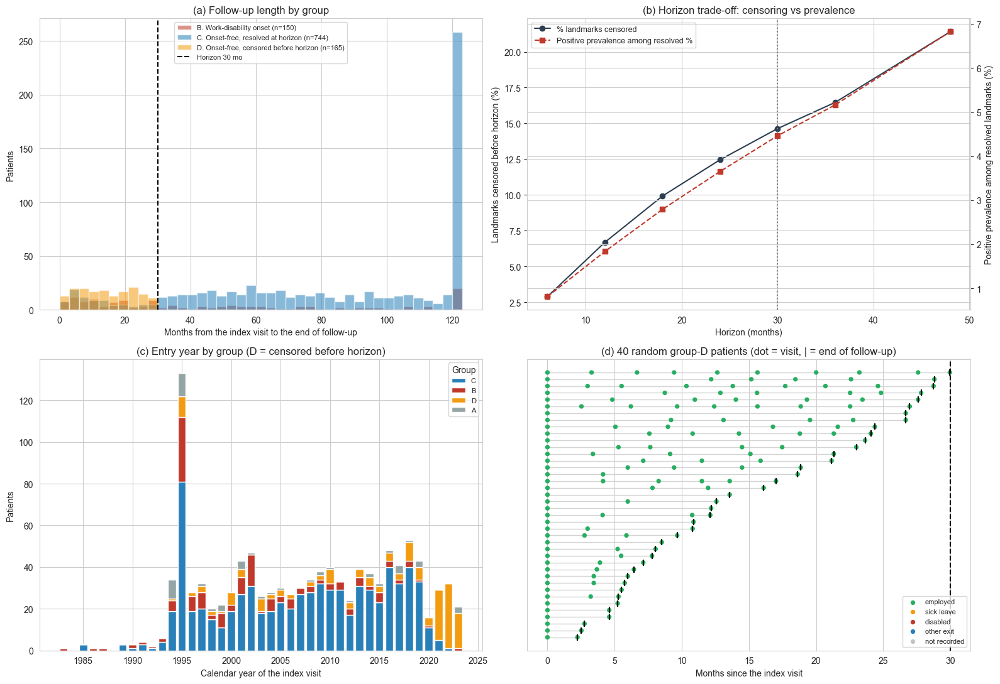

In [8]:
"""
Follow-up diagnostics for the landmark cohort. Run AFTER 11.2 (uses visits, land, patients_df, _state_of,
FEATURE_CANDIDATES, DISPLAY_NAMES, HORIZON_DAYS, MONTH_DAYS, AGE_CAP_YEARS, DEATH_AS_COMPETING_EVENT, CensoringKM).

No patient is dropped for short follow-up here: censored landmarks are kept and handled by IPCW. So the question is
not 'who is lost?' but 'who is censored before 30 months, why, and do they differ from the rest?'. Patient groups
(index = first employed visit before age 65; follow-up from it as in patients_df, i.e. cell 11.3):
  A  ever employed, no landmark (the only employed visit is the last recorded status)        -> excluded
  B  a work-disability onset at some landmark                                                 -> kept
  C  onset-free, resolved at the horizon: followed >= horizon, or other exit / death before it -> kept, label 0
  D  onset-free, censored before the horizon                                                  -> kept, IPCW-weighted
"""
GROUP_LABELS = {
    "A": "A. Employed only at the last recorded status (excluded)",
    "B": "B. Work-disability onset (kept)",
    "C": "C. Onset-free, resolved at horizon (kept)",
    "D": "D. Onset-free, censored before horizon (kept, IPCW)",
}
STATE_COLORS = {"W": "#27ae60", "S": "#f39c12", "D": "#c0392b", "O": "#2980b9", "U": "#bdc3c7"}


def followup_diagnostics(horizon_days=HORIZON_DAYS, horizon_grid_months=(6, 12, 18, 24, 30, 36, 48),
                         ltfu_window_days=365, n_swim=40, seed=CV_SEED, plot=True):
    H_m = horizon_days / MONTH_DAYS
    data_cut = visits["ASSDT"].max()
    gidx = visits.groupby("PTNO", sort=False).indices
    first_onset = land.loc[land["event"] == 1].groupby("pid")["event_date"].min()

    recs = []
    for pid, r in patients_df[patients_df["ever_employed"]].iterrows():
        p = visits.iloc[gidx[pid]]
        idx_date, fu_d = r["index_date"], r["km_time_days"]
        post = p[p["ASSDT"] >= idx_date]
        gaps = post["ASSDT"].diff().dt.days.dropna()
        last_visit = p["ASSDT"].max()                          # any visit (attendance)
        end_date = idx_date + pd.Timedelta(days=fu_d)          # end of index follow-up (last recorded status / cap)
        has_event = pid in first_onset.index
        if r["n_landmarks"] == 0:
            grp = "A"
        elif has_event:
            grp = "B"
        elif fu_d >= horizon_days or r["km_cause"] >= 2:
            grp = "C"
        else:
            grp = "D"
        reason = ""
        if grp == "D":
            if r["km_exit"] == "age_cap":
                reason = f"Reached age {AGE_CAP_YEARS}"
            elif r["dead"]:
                reason = "Died (censored at last recorded status)"
            elif r["trailing_unrecorded"] > 0:
                reason = "Later visits, employment status not recorded"
            elif (data_cut - last_visit).days <= ltfu_window_days:
                reason = "Still attending at data cut (late entry)"
            else:
                reason = "Stopped attending > 1 yr before data cut (probable LTFU)"
        lcdt = pd.to_datetime(p["LCDT"], errors="coerce").max()
        row = p.loc[p["ASSDT"] == idx_date].iloc[0]
        rec = {"pid": pid, "group": grp, "reason": reason, "has_event": has_event, "km_exit": r["km_exit"],
               "index_date": idx_date, "index_year": idx_date.year, "fu_m": fu_d / MONTH_DAYS,
               "time_to_event_m": (first_onset[pid] - idx_date).days / MONTH_DAYS if has_event else np.nan,
               "n_visits": len(post), "n_landmarks": r["n_landmarks"],
               "median_gap_d": gaps.median() if len(gaps) else np.nan,
               "max_gap_d": gaps.max() if len(gaps) else np.nan,
               "days_last_visit_to_cut": (data_cut - last_visit).days,
               "lcdt_minus_end_d": (lcdt - end_date).days if pd.notna(lcdt) else np.nan,
               "_visits": list(zip((post["ASSDT"] - idx_date).dt.days / MONTH_DAYS, post["EMP"].map(_state_of)))}
        rec.update({f"base_{c}": row[c] for c in FEATURE_CANDIDATES})
        recs.append(rec)
    d = pd.DataFrame(recs)
    W = 100

    # ------------------------------------------------------------------ 1. follow-up length by group
    print("=" * W)
    print(f"1. FOLLOW-UP FROM THE INDEX VISIT BY GROUP (months; horizon {H_m:.0f} mo; data cut {data_cut.date()})")
    print("-" * W)
    print(f"{'GROUP':<58}{'N':>5}{'MEDIAN':>8}{'IQR':>16}{'MIN':>7}{'MAX':>7}")
    for g, lab in GROUP_LABELS.items():
        x = d.loc[d.group == g, "fu_m"]
        if len(x):
            print(f"{lab:<58}{len(x):>5}{x.median():>8.1f}{f'{x.quantile(.25):.1f} - {x.quantile(.75):.1f}':>16}"
                  f"{x.min():>7.1f}{x.max():>7.1f}")
    D = d[d.group == "D"]
    if len(D):
        edges = [0, 6, 12, 18, H_m - 6, H_m]
        labels = ["0-6 mo", "6-12 mo", "12-18 mo", f"18-{H_m - 6:.0f} mo", f"{H_m - 6:.0f}-{H_m:.0f} mo (near miss)"]
        t = pd.cut(D["fu_m"], bins=edges, labels=labels, include_lowest=True).value_counts().reindex(labels)
        print(f"\nGroup D: how far short of {H_m:.0f} months?")
        for lab, n in t.items():
            print(f"  {lab:<28}{n:>5}  {n / len(D):>6.1%}  cumulative {t.loc[:lab].sum() / len(D):>6.1%}")

        # ------------------------------------------------------------ 2. why is it short
        print("\n" + "=" * W)
        print("2. WHY IS FOLLOW-UP SHORT? (group D)")
        print("-" * W)
        r = D.groupby("reason").agg(N=("pid", "size"), median_fu_mo=("fu_m", "median"),
                                    median_last_visit_to_cut_d=("days_last_visit_to_cut", "median"))
        r["%"] = r["N"] / len(D) * 100
        print(r.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
        lc = D["lcdt_minus_end_d"].dropna()
        if len(lc):
            print(f"\nLCDT (last contact) minus end of follow-up, group D: median {lc.median():.0f} d; "
                  f"{(lc > 180).mean():.1%} have contact > 6 mo later (alive and in contact, status unknown)")

    # ------------------------------------------------------------------ 3. visit pattern
    print("\n" + "=" * W)
    print("3. VISIT PATTERN (from the index visit)")
    print("-" * W)
    vp = d.groupby("group").agg(N=("pid", "size"), visits_med=("n_visits", "median"),
                                landmarks_med=("n_landmarks", "median"), gap_med_d=("median_gap_d", "median"),
                                max_gap_med_d=("max_gap_d", "median"),
                                last_visit_to_cut_med_d=("days_last_visit_to_cut", "median"))
    print(vp.to_string(float_format=lambda v: f"{v:.1f}"))
    print("\nBy calendar year of the index visit (are recent entrants the censored ones?):")
    ct = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
    ct["% censored (D)"] = ct["D"] / ct.sum(axis=1) * 100
    print(ct.to_string(float_format=lambda v: f"{v:.0f}"))

    # ------------------------------------------------------------------ 4. horizon: how many landmark labels resolve
    print("\n" + "=" * W)
    print("4. HORIZON SENSITIVITY (landmark set is fixed; only which labels resolve changes)")
    print("-" * W)
    G = CensoringKM(T_ALL, C_ALL)
    rows = []
    for m in horizon_grid_months:
        H = round(m * MONTH_DAYS)
        h = land["time_days"] <= H
        pos = (land["cause"] == 1) & h
        neg = ~h | (land["cause"] >= 2)
        cens = ~pos & ~neg
        rows.append({"Horizon (mo)": m, "Positive rows": int(pos.sum()), "Negative rows": int(neg.sum()),
                     "Censored rows": int(cens.sum()), "% censored": 100 * cens.mean(),
                     "Prevalence among resolved %": 100 * pos.sum() / max((pos | neg).sum(), 1),
                     "Patients w/ positive row": land.loc[pos, "pid"].nunique(),
                     "G(h)": float(G.at([H])[0])})
    sens = pd.DataFrame(rows)
    print(sens.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

    # ------------------------------------------------------------------ 5. what dropping D would do
    print("\n" + "=" * W)
    print("5. WOULD DROPPING THE CENSORED PATIENTS BIAS THE COHORT?")
    print("-" * W)
    e = d[d.group != "A"]
    kept = e[e.group.isin(["B", "C"])]
    within = lambda x: (x["has_event"] & (x["time_to_event_m"] <= H_m))
    print(f"Onset within {H_m:.0f} mo of the index visit:")
    print(f"  crude, all patients with a landmark (censored = onset-free) : {within(e).mean():.1%}  (n={len(e)})")
    print(f"  crude, resolved patients only (B+C; drops D)                : {within(kept).mean():.1%}  (n={len(kept)})")
    km_in = patients_df.loc[e["pid"]]
    kmf = KaplanMeierFitter().fit(km_in["km_time_days"] / MONTH_DAYS, km_in["km_event"])
    print(f"  Kaplan-Meier (censoring-aware; other exits censored)        : {1 - kmf.predict(H_m):.1%}")
    print("  -> the gap between 'resolved only' and KM is the bias IPCW avoids by keeping group D.")

    if len(D):
        print(f"\nIndex-visit variables, resolved (B+C) vs censored (D) -- standardised mean difference:")
        out = []
        for c in [c for c in FEATURE_CANDIDATES if c != "YRS_SINCE_INDEX"]:   # 0 at every index visit
            a, b = kept[f"base_{c}"].astype(float), D[f"base_{c}"].astype(float)
            sd = np.sqrt((a.var() + b.var()) / 2)
            out.append({"Variable": DISPLAY_NAMES.get(c, c), "Resolved mean": a.mean(), "Censored mean": b.mean(),
                        "SMD": (a.mean() - b.mean()) / sd if sd > 0 else np.nan})
        smd = pd.DataFrame(out).sort_values("SMD", key=np.abs, ascending=False)
        smd["Flag"] = np.where(smd["SMD"].abs() > 0.1, "<-- imbalance (>0.1)", "")
        print(smd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
        print("(Calendar year is expected to differ: late entrants are censored. Cell 11.3.1 tests whether censoring "
              "is predictable from the variables.)")
    print("=" * W)

    # ------------------------------------------------------------------ plots
    if plot:
        fig, ax = plt.subplots(2, 2, figsize=(16, 11))
        a = ax[0, 0]
        bins = np.arange(0, min(d["fu_m"].max(), 120) + 6, 3)
        for g, col in [("B", "#c0392b"), ("C", "#2980b9"), ("D", "#f39c12")]:
            x = d.loc[d.group == g, "fu_m"].clip(upper=bins[-1] - 0.01)
            a.hist(x, bins=bins, alpha=0.55, color=col, label=GROUP_LABELS[g].split(" (")[0] + f" (n={len(x)})")
        a.axvline(H_m, color="black", ls="--", label=f"Horizon {H_m:.0f} mo")
        a.set_xlabel("Months from the index visit to the end of follow-up"); a.set_ylabel("Patients")
        a.set_title("(a) Follow-up length by group"); a.legend(fontsize=8)

        a = ax[0, 1]
        a.plot(sens["Horizon (mo)"], sens["% censored"], "o-", color="#2c3e50", label="% landmarks censored")
        a.set_xlabel("Horizon (months)"); a.set_ylabel("Landmarks censored before horizon (%)")
        a2 = a.twinx()
        a2.plot(sens["Horizon (mo)"], sens["Prevalence among resolved %"], "s--", color="#c0392b",
                label="Positive prevalence among resolved %")
        a2.set_ylabel("Positive prevalence among resolved landmarks (%)")
        a.axvline(H_m, color="gray", ls=":"); a.set_title("(b) Horizon trade-off: censoring vs prevalence")
        h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
        a.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)

        a = ax[1, 0]
        bottom = np.zeros(len(ct))
        for g, col in [("C", "#2980b9"), ("B", "#c0392b"), ("D", "#f39c12"), ("A", "#95a5a6")]:
            a.bar(ct.index, ct[g], bottom=bottom, color=col, label=g); bottom += ct[g].values
        a.set_xlabel("Calendar year of the index visit"); a.set_ylabel("Patients")
        a.set_title("(c) Entry year by group (D = censored before horizon)"); a.legend(title="Group", fontsize=8)

        a = ax[1, 1]
        sw = D.sample(min(n_swim, len(D)), random_state=seed).sort_values("fu_m") if len(D) else D
        for k, (_, r) in enumerate(sw.iterrows()):
            xs = [x for x, _ in r["_visits"]]
            a.plot([0, max(xs)], [k, k], color="lightgray", lw=1, zorder=1)
            a.scatter(xs, [k] * len(xs), c=[STATE_COLORS[s] for _, s in r["_visits"]], s=18, zorder=2)
            a.scatter([r["fu_m"]], [k], marker="|", color="black", s=60, zorder=3)
        a.axvline(H_m, color="black", ls="--"); a.set_yticks([])
        for s, lab in [("W", "employed"), ("S", "sick leave"), ("D", "disabled"), ("O", "other exit"), ("U", "not recorded")]:
            a.scatter([], [], c=STATE_COLORS[s], s=18, label=lab)
        a.legend(fontsize=8, loc="lower right")
        a.set_xlabel("Months since the index visit")
        a.set_title(f"(d) {len(sw)} random group-D patients (dot = visit, | = end of follow-up)")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/revised_v27_followup_diagnostics.png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close()
    return d, sens


fu_df, horizon_table = followup_diagnostics()

## 11.6.1 Sample size and missing data

TRIPOD+AI items 10 and 11: the Riley et al. minimum sample size for the number of candidate parameters, at anticipated
C-statistics of 0.65, 0.70 and 0.75; and, for every variable, how often it was recorded at the landmark visits, how
much is still missing after carry-forward, and how the rest is handled.

In [9]:
"""
Sample size and missing data (TRIPOD+AI items 10 and 11).

SAMPLE SIZE. Minimum sample size for developing a prediction model of a binary outcome (Riley et al., BMJ 2020): the
largest n that meets
  (1) expected uniform shrinkage >= 0.9:          n = P / ((S - 1) ln(1 - R2_CS / S)), S = 0.9
  (2) optimism in Nagelkerke R2 <= 0.05:          as (1) with S = R2_CS / (R2_CS + 0.05 R2_CS,max)
  (3) overall risk estimated within +-0.05:       n = (1.96 / 0.05)^2 phi (1 - phi)
P = candidate predictor parameters, phi = outcome proportion, R2_CS = the anticipated Cox-Snell R2, derived from an
anticipated C-statistic (Riley et al. 2021: a logistic model with a normal linear predictor whose C-statistic and
outcome proportion match). The unit is the PATIENT (landmarks of one patient are not independent), with phi = the
share of patients with an onset. P is given for the cap of Section 11.5 (set by the time-to-event version of these criteria) and for the whole
candidate pool.
These criteria are for regression models; flexible models (RSF, LSTM, GRU, Transformer) typically need more data.

MISSING DATA. For each variable: how often its source was recorded AT the landmark visit, how often it is still
missing after carry-forward, and how the remainder is handled (multiple imputation, fitted inside each training fold).
"""
PRED_UNIT_N = int(land["pid"].nunique())
PRED_UNIT_EVENTS = int(land.groupby("pid")["event"].max().sum())
P_LINEAR = P_MAX                                       # the cap (Section 11.5): forced terms + the LASSO's selection
P_LOGREG = len(FEATURE_CANDIDATES)                     # every candidate after the pre-filter, if nothing were selected


def r2cs_from_c(c, phi, n=400_000, seed=SEED):
    """Cox-Snell R2 of a logistic model with a normal linear predictor whose C-statistic is c and mean risk phi."""
    z = np.random.RandomState(seed).standard_normal(n)
    expit = lambda v: 1.0 / (1.0 + np.exp(-v))

    def model(sigma):
        mu = brentq(lambda m: expit(m + sigma * z).mean() - phi, -30, 30)
        return mu + sigma * z, expit(mu + sigma * z)

    def c_of(sigma):
        lp, p = model(sigma)
        return roc_auc_score(np.r_[np.ones(n), np.zeros(n)], np.r_[lp, lp], sample_weight=np.r_[p, 1 - p])

    sigma = brentq(lambda s: c_of(s) - c, 0.01, 6.0)
    _, p = model(sigma)
    ll_model = np.mean(p * np.log(p) + (1 - p) * np.log(1 - p))
    ll_null = phi * np.log(phi) + (1 - phi) * np.log(1 - phi)
    return 1 - np.exp(-2 * (ll_model - ll_null)), 1 - np.exp(2 * ll_null)


def riley_sample_size(P, phi, c):
    r2, r2max = r2cs_from_c(c, phi)
    n_of = lambda S: P / ((S - 1) * np.log(1 - r2 / S))
    s2 = r2 / (r2 + 0.05 * r2max)
    n1, n2, n3 = n_of(0.9), n_of(s2), (1.96 / 0.05) ** 2 * phi * (1 - phi)
    n = int(np.ceil(max(n1, n2, n3)))
    return {"Anticipated C": c, "Predictor parameters (P)": P, "Anticipated R2_CS": round(r2, 3),
            "n: shrinkage >= 0.9": int(np.ceil(n1)), "n: optimism <= 0.05": int(np.ceil(n2)),
            "n: overall risk +-0.05": int(np.ceil(n3)), "Minimum n (patients)": n,
            "Minimum events": int(np.ceil(n * phi)), "Events per parameter needed": round(n * phi / P, 1)}


phi_pt = PRED_UNIT_EVENTS / PRED_UNIT_N
sample_size = pd.DataFrame([riley_sample_size(P, phi_pt, c) for P in (P_LINEAR, P_LOGREG) for c in (0.65, 0.70, ANTICIPATED_C, 0.75)])
print(f"Available: {PRED_UNIT_N} patients, {PRED_UNIT_EVENTS} with a work-disability onset (phi = {phi_pt:.3f}); "
      f"{PRED_UNIT_EVENTS / P_LINEAR:.1f} events per parameter at the cap of {P_LINEAR} parameters, "
      f"{PRED_UNIT_EVENTS / P_LOGREG:.1f} for all {P_LOGREG} candidates (binary approximation below; the cap itself "
      f"comes from the time-to-event version, Section 11.5).")
display(sample_size.set_index(["Predictor parameters (P)", "Anticipated C"]))
print("Minimum sample size met for:", ", ".join(f"P = {r['Predictor parameters (P)']}, C = {r['Anticipated C']}"
                                                for _, r in sample_size.iterrows()
                                                if r["Minimum n (patients)"] <= PRED_UNIT_N) or "none")

# ---------------------------------------------------------------------------------------------------- missing data


def _handling(c):
    if c in TREATMENT_COLS:
        return "not recorded at the visit = not on the drug (0); never imputed"
    if c.endswith("_NA"):
        return f"indicator: not measured in the last {STALE_MONTHS} months (complete)"
    if c in STALE_CONT or c in ("HIGH_BP", "EGFR_LT60"):
        return (f"carried forward for at most {STALE_MONTHS} months; then multiply imputed (auxiliaries: the last value "
                f"ever recorded and its age)")
    if c in ADJUST_COLS:
        return "visit date (never missing); clipped to the training years at prediction"
    if c in PATIENT_CONSTANT_COLS:
        return "patient-level; multiply imputed (one value per patient)" + ("; + 'not recorded' indicator"
                                                                           if c == "EDU_HIGHER" else "")
    return "carried forward (or derived from carried-forward items); the remainder multiply imputed"


missing_table = pd.DataFrame([{"Group": FEATURE_GROUP_OF.get(c, ""), "Variable": DISPLAY_NAMES.get(c, c),
                               "Missing after carry-forward / derivation": f"{land[c].isna().mean():.1%}",
                               "Handling": _handling(c)} for c in FEATURE_CANDIDATES]).set_index("Variable")
print("\nMissing data at the landmark visits (TRIPOD+AI item 11), every candidate after the pre-filter. Carry-forward, "
      f"then multiple imputation by chained equations (m = {M_IMPUTATIONS}, "
      f"{'random-forest' if IMPUTATION == 'rf' else 'Bayesian linear'} conditionals with draws, fitted on each training "
      "fold without the outcome and applied to its held-out rows); every model is fitted on each completed dataset and "
      "the predicted risks are averaged.")
display(missing_table)

Available: 1059 patients, 150 with a work-disability onset (phi = 0.142); 12.5 events per parameter at the cap of 12 parameters, 1.4 for all 108 candidates (binary approximation below; the cap itself comes from the time-to-event version, Section 11.5).


Anticipated R2_CS  \
Predictor parameters (P) Anticipated C                      
12                       0.65                       0.035   
                         0.70                       0.062   
                         0.72                       0.076   
                         0.75                       0.099   
108                      0.65                       0.035   
                         0.70                       0.062   
                         0.72                       0.076   
                         0.75                       0.099   

                                        n: shrinkage >= 0.9  \
Predictor parameters (P) Anticipated C                        
12                       0.65                          3044   
                         0.70                          1671   
                         0.72                          1364   
                         0.75                          1035   
108                      0.65                         27388   
                         0.70                         15032   
                         0.72                         12276   
                         0.75                          9314   

                                        n: optimism <= 0.05  \
Predictor parameters (P) Anticipated C                        
12                       0.65                           417   
                         0.70                           411   
                         0.72                           408   
                         0.75                           403   
108                      0.65                          3751   
                         0.70                          3696   
                         0.72                          3669   
                         0.75                          3623   

                                        n: overall risk +-0.05  \
Predictor parameters (P) Anticipated C                           
12                       0.65                              187   
                         0.70                              187   
                         0.72                              187   
                         0.75                              187   
108                      0.65                              187   
                         0.70                              187   
                         0.72                              187   
                         0.75                              187   

                                        Minimum n (patients)  Minimum events  \
Predictor parameters (P) Anticipated C                                         
12                       0.65                           3044             432   
                         0.70                           1671             237   
                         0.72                           1364             194   
                         0.75                           1035             147   
108                      0.65                          27388            3880   
                         0.70                          15032            2130   
                         0.72                          12276            1739   
                         0.75                           9314            1320   

                                        Events per parameter needed  
Predictor parameters (P) Anticipated C                               
12                       0.65                                  35.9  
                         0.70                                  19.7  
                         0.72                                  16.1  
                         0.75                                  12.2  
108                      0.65                                  35.9  
                         0.70                                  19.7  
                         0.72                                  16.1  
                         0.75                                  12.2

Minimum sample size met for: P = 12.0, C = 0.75

Missing data at the landmark visits (TRIPOD+AI item 11), every candidate after the pre-filter. Carry-forward, then multiple imputation by chained equations (m = 5, random-forest conditionals with draws, fitted on each training fold without the outcome and applied to its held-out rows); every model is fitted on each completed dataset and the predicted risks are averaged.


,Group,Missing after carry-forward / derivation,Handling
Variable,,,
Age,Demographics,0.0%,carried forward (or derived from carried-forwa...
Sex: female,Demographics,0.0%,patient-level; multiply imputed (one value per...
Education: higher,Demographics,12.4%,patient-level; multiply imputed (one value per...
Current smoker,Demographics,0.5%,carried forward (or derived from carried-forwa...
BMI (kg/m2),Demographics,17.3%,carried forward for at most 12 months; then mu...
Disease duration (yrs),Demographics,0.0%,carried forward (or derived from carried-forwa...
Age at diagnosis,Demographics,0.0%,carried forward (or derived from carried-forwa...
Race: Black,Demographics,0.0%,carried forward (or derived from carried-forwa...
"Race: Asian (Chinese, Filipino)",Demographics,0.0%,carried forward (or derived from carried-forwa...


## 11.6.2 Participant flow

TRIPOD+AI item 20a: patients and landmark visits at every step, with events, for the visit-level analysis and the
patient-level evaluation.

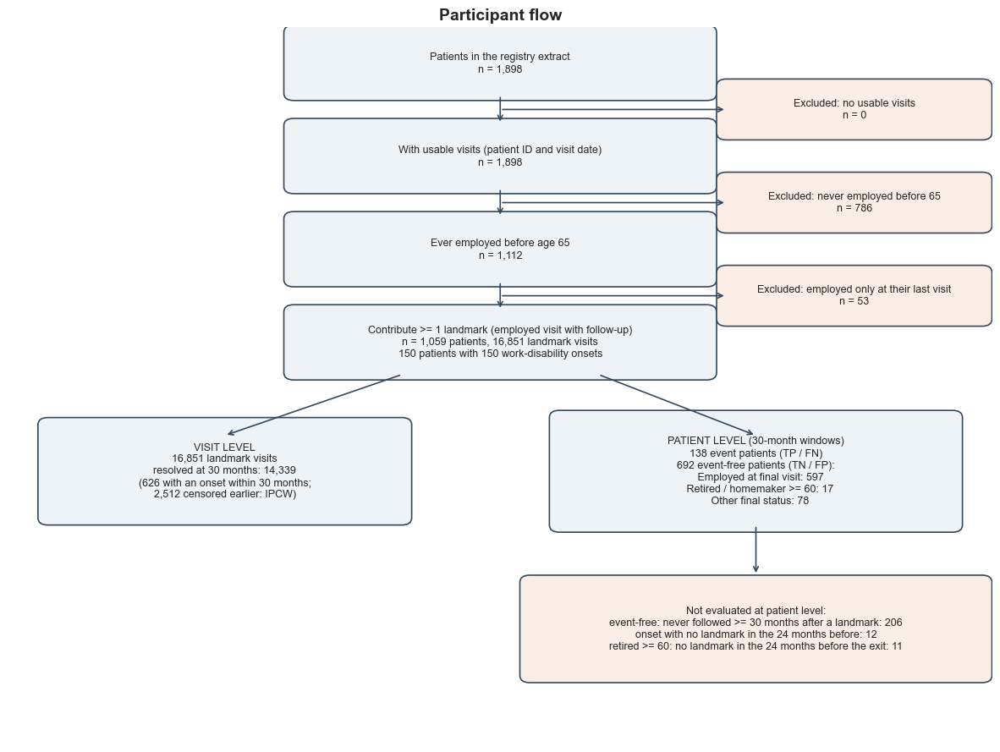

In [10]:
"""Participant flow diagram (TRIPOD+AI item 20a): patients and landmark visits at every step, with events, for the
visit-level analysis (left) and the patient-level evaluation (right)."""
from matplotlib.patches import FancyBboxPatch


def _box(ax, x, y, text, w=0.3, h=0.085, fc="#eef3f8"):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.01", fc=fc, ec="#34495e", lw=1.2))
    ax.text(x, y, text, ha="center", va="center", fontsize=9)


def _arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color="#34495e", lw=1.2))


def plot_flow():
    a, pts, t = load_audit, patients_df, PT_TRUTH
    y30, w30 = ipcw_rows(np.arange(len(land)), HORIZON_DAYS)
    n_onsets = int((land.loc[land["event"] == 1, "visit_date"] + pd.to_timedelta(
        land.loc[land["event"] == 1, "time_days"], unit="D")).groupby(land.loc[land["event"] == 1, "pid"]).nunique().sum())
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    steps = [(0.95, f"Patients in the registry extract\nn = {a['raw_patients']:,}"),
             (0.82, f"With usable visits (patient ID and visit date)\nn = {a['usable_patients']:,}"),
             (0.69, f"Ever employed before age {AGE_CAP_YEARS}\nn = {int(pts['ever_employed'].sum()):,}"),
             (0.56, f"Contribute >= 1 landmark (employed visit with follow-up)\nn = {land['pid'].nunique():,} patients, "
                    f"{len(land):,} landmark visits\n{int(t.stratum.eq('Event').sum())} patients with "
                    f"{n_onsets} work-disability onsets")]
    for (y, txt), (y2, _) in zip(steps, steps[1:] + [(None, None)]):
        _box(ax, 0.5, y, txt, w=0.42)
        if y2 is not None:
            _arrow(ax, 0.5, y - 0.045, 0.5, y2 + 0.045)
    excl = [(0.885, f"Excluded: no usable visits\nn = {a['raw_patients'] - a['usable_patients']:,}"),
            (0.755, f"Excluded: never employed before {AGE_CAP_YEARS}\n"
                    f"n = {a['usable_patients'] - int(pts['ever_employed'].sum()):,}"),
            (0.625, f"Excluded: employed only at their last visit\n"
                    f"n = {int(pts['ever_employed'].sum()) - land['pid'].nunique():,}")]
    for y, txt in excl:
        _box(ax, 0.86, y, txt, w=0.26, h=0.065, fc="#fbeee6")
        _arrow(ax, 0.5, y, 0.73, y)
    # visit level
    _arrow(ax, 0.4, 0.515, 0.22, 0.43)
    _box(ax, 0.22, 0.38, f"VISIT LEVEL\n{len(land):,} landmark visits\nresolved at 30 months: {int((w30 > 0).sum()):,}\n"
                         f"({int(((y30 == 1) & (w30 > 0)).sum()):,} with an onset within 30 months;\n"
                         f"{int((w30 == 0).sum()):,} censored earlier: IPCW)", w=0.36, h=0.13)
    # patient level
    _arrow(ax, 0.6, 0.515, 0.76, 0.43)
    neg = t[t.group == "negative"]
    _box(ax, 0.76, 0.38, f"PATIENT LEVEL (30-month windows)\n{int(t.group.eq('event').sum())} event patients "
                         f"(TP / FN)\n{len(neg)} event-free patients (TN / FP):\n"
                         + "\n".join(f"   {s}: {int(neg.stratum.eq(s).sum())}" for s in STRATA), w=0.4, h=0.15)
    ex = t[t.group == "excluded"]["reason"].value_counts()
    _arrow(ax, 0.76, 0.305, 0.76, 0.235)
    _box(ax, 0.76, 0.16, "Not evaluated at patient level:\n" + "\n".join(f"{r}: {n}" for r, n in ex.items()),
         w=0.46, h=0.13, fc="#fbeee6")
    ax.set_title("Participant flow", fontsize=14, fontweight="bold")
    plt.savefig(f"{OUT_DIR}/revised_v27_flow_diagram.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


plot_flow()

## 11.7 Sequential models (time-aware LSTM / GRU / Transformer)

Section 6.1. The main model is the time-aware LSTM (T-LSTM; revised_v27); GRU and Transformer use the same recipe.
revised_v27 also checks, in the smoke test, that the T-LSTM equals an ordinary LSTM when no time passes between visits,
and that the fairness penalty's gradient is the exact gradient of the equalized-odds term. A smoke test on 40 real
patients (half with an onset) runs at the end of the cell. It checks whole-history and windowed batching, pretraining,
the cause-specific hazard heads (with the interval-censored likelihood and the warm start), early stopping and the seed ensemble in a few seconds.

**revised_v27, speed.** Each seed of the 5-seed ensemble, and each of the 3 cross-fitting fits, trains in its own
worker process with single-threaded torch (`SEQ_N_JOBS`, default 4): per outer fold the 3 + 5 trainings run together
instead of one after another. Every seed seeds its own generators and the trained weights come back to the notebook,
so the networks are identical to sequential training; the smoke test checks it.

In [11]:
"""Sequence models: the main LSTM, plus GRU and Transformer on the same recipe.

  * Encoder: a 1-layer LSTM with 16 hidden units (the main LSTM and its variants; GRU / Transformer 32), dropout 0.3 on
    its output. GRU and Transformer: one pass per patient over the WHOLE visit history (visits before the index visit and
    while not employed included), with a prediction at every landmark. The LSTM reads each landmark's last 8 visits
    (LSTM1: the current visit alone).
  * Skip connection (the LSTMs): the heads also receive the current visit's variables, warm-started from a
    person-interval logistic regression. Auxiliary heads (the LSTMs; aux): three logistic heads on the hidden state
    predict AUX_TARGETS within 12 months (masked binary cross-entropy, patient-weighted, x aux_weight), training only.
  * Inputs per visit: the pre-specified variables (Section 11.5; the CV-optimal set only if SEQ_WIDE_INPUTS), log(1 + years since the previous visit), and the
    visit's employment state (employed / sick leave / disabled / other exit, one-hot). The calendar year (ADJUST_COLS,
    clipped to the training years) is NOT an encoder input: it feeds the hazard heads only. Scaled with the training
    fold's landmark rows (skew transform + multiple imputation + standardisation + clipping); seed s of the ensemble
    trains on imputation s (mod M_IMPUTATIONS).
  * Self-supervised pretraining: before seeing any disability label, the encoder learns to predict the next visit's
    SLEDAI-2K, SDI and steroid dose (squared error) from the history and the gap to that visit, for 10 epochs, on every
    patient outside the held-out ones. Pretraining is redone for every seed.
  * Heads: one linear layer from the hidden state to a logistic hazard per 3-month interval (16 intervals) for work
    disability and, with exit_head, a second one for other exits (and death, if counted): discrete-time
    cause-specific hazards, each head treating the other cause as censoring. Output: the cause-specific risk of work
    disability, R(k) = 1 - prod_{j <= k} (1 - h_1(j)).
  * Loss: the cause-specific likelihood (cs_hazard_nll) -- survived intervals log(1 - h); an event log h_b, or
    log[S(a - 1) - S(b)] when interval-censored between the last employed visit and the recording visit -- weighted by
    the landmark weight (and 1 / G_k(x) with covariate IPCW). No class weights or balanced batches.
  * Warm start: interval biases at the training life-table (Kaplan-Meier) hazards; then the calendar-year weights
    and the biases (with the skip connection, also the skip weights) from a person-interval logistic regression.
  * Training: AdamW (lr 3e-3, weight decay 1e-2),
    gradient clipping, batches of 64 patients, up to 60 epochs with EARLY STOPPING (patience 8) on 20% of the fit's
    patients held out as a validation set; the best-validation weights are kept.
  * Ensemble: 5 seeds (each with its own pretraining, initialisation and validation split) in the outer-fold fit; their
    per-interval hazards are averaged.
  * LSTM history window: fixed (SEQ_GRIDS; the main LSTM k = 8, LSTM1 k = 1, supplementary k = 4, 16).

GRU and Transformer: the identical recipe (inputs, pretraining, head, early stopping, 5 seeds) with a GRU cell or a
1-layer causal Transformer (2 heads, feed-forward 64, lr 1e-3, plus elapsed years since the first visit as an input).

History window (max_visits; None = whole history for GRU and Transformer): each landmark sees only its last k
visits (Section 11.12.8).
"""
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from joblib import Parallel, delayed
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

#torch.set_num_threads(max(1, os.cpu_count() or 1))
torch.set_num_threads(1) 
VIS_COLS = list(dict.fromkeys(FEATURE_CANDIDATES + AUX_ALL))               # every candidate + imputation auxiliaries
VX_RAW = visits[VIS_COLS].values.astype(float)                             # encoder features, every visit
VIS_IDX = {c: j for j, c in enumerate(VIS_COLS)}
V_GAP = np.log1p(visits.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0.0).values / 365.25).astype(np.float32)
V_STATE = visits[["EMP_WORKING", "EMP_SICK", "EMP_DISABLED", "EMP_OTHER"]].values.astype(np.float32)
# revised_v27: the T-LSTM's elapsed time -- months since the previous visit (0 at the first), for g(dt) = 1 / log(e + dt)
V_DT = (visits.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0.0).values / TLSTM_DT_UNIT_DAYS).astype(np.float32)
# revised_v27: race group of every landmark for the fairness penalty (0 White, 1 Black, 2 Asian, 3 other / not recorded)
FAIR_GROUP_ALL = (np.nan_to_num(land["RACE_BLACK"].values.astype(float)) * 1
                  + np.nan_to_num(land["RACE_ASIAN"].values.astype(float)) * 2
                  + np.nan_to_num(land["RACE_OTHER_UNKNOWN"].values.astype(float)) * 3).astype(np.int64)
N_FAIR_GROUPS = len(FAIR_GROUP_LABELS)
FAIR_K = PRIMARY_HORIZON_MONTHS // INTERVAL_MONTHS        # intervals up to the primary horizon
V_ELAPSED = ((visits["ASSDT"] - visits.groupby("PTNO")["ASSDT"].transform("min")).dt.days.values
             / 365.25 / 10.0).astype(np.float32)                           # decades since the first visit (Transformer)
PRETRAIN_COLS = ["SLEDAI2_I", "score_n", "STERAVER_0"]                   # next-visit targets of the pretraining
_tg = visits[PRETRAIN_COLS].values.astype(float)                          # label-free: standardised over all visits
_tg = np.where(np.isnan(_tg), np.nanmedian(_tg, 0), _tg)
V_PRETRAIN_TGT = ((_tg - _tg.mean(0)) / (_tg.std(0) + 1e-8)).astype(np.float32)
PATIENT_ROWS = visits.groupby("PTNO", sort=False).indices                 # pid -> visit row indices (date order)
_VROW_TO_POS = np.empty(len(visits), dtype=np.int64)
for _pid, _rows in PATIENT_ROWS.items():
    _VROW_TO_POS[_rows] = np.arange(len(_rows))
LAND_POS = _VROW_TO_POS[land["visit_row"].values]                         # landmark -> position in its patient
SEQ_KIND = {**{m: ("lstm" if m in PLAIN_LSTM_MODELS else "tlstm") for m in SEQ_GRIDS if m.startswith("LSTM")},
            "GRU": "gru", "Transformer": "transformer"}   # revised_v27: every LSTM time-aware except LSTM_plain
N_STATE = V_STATE.shape[1]


def seq_cfg(model, cfg_name):
    return {**SEQ_CONFIG, **SEQ_GRIDS[model][cfg_name]}


def cif_from_probs(P):
    """(n, K, N_CLASSES) per-interval class probabilities -> (n, K) cumulative incidence of work disability."""
    S = np.cumprod(P[..., 0], axis=-1)
    S_prev = np.concatenate([np.ones_like(S[..., :1]), S[..., :-1]], axis=-1)
    return np.cumsum(S_prev * P[..., 1], axis=-1)


def cif_to_risk(cif):
    """(n, K) cumulative incidence -> (n, n_horizons) risk of onset by each evaluation horizon."""
    return cif[:, np.array(HORIZON_INTERVALS) - 1]


def hazard_risk(Hz, head=0):
    """(n, H, K) per-interval hazards -> (n, n_horizons) cause-specific risk 1 - prod(1 - h) of head `head` by each
    evaluation horizon (head 0 = work disability, 1 = other exit)."""
    return cif_to_risk(1.0 - np.cumprod(1.0 - Hz[:, head], axis=-1))


def composite_risk(Hz):
    """Risk of leaving work for any reason by each horizon, 1 - prod_k (1 - h_1k)(1 - h_2k)."""
    return cif_to_risk(1.0 - np.cumprod((1.0 - Hz[:, 0]) * (1.0 - Hz[:, 1]), axis=-1))


def risk_logit30(z):
    """(n, H, K) hazard logits -> (n,) logit of the work-disability head's risk by the primary horizon."""
    ls = F.logsigmoid(-z[:, 0, :FAIR_K]).sum(-1).clamp(max=-1e-6)          # log S(30 months)
    return torch.log(-torch.expm1(ls)) - ls


def fairness_penalty(s, g, y, w, pi, ema):
    """revised_v27 soft equalized odds: a scalar whose gradient is that of
        sum_{y in 0, 1} sum_g pi[y, g] (m_gy - m_y)^2
    (m_gy = weighted mean of s among group g's landmarks with label y, m_y over all groups), with the gap m_gy - m_y
    held at its running (EMA) value and its derivative from the batch -- the mini-batch estimate of a small group's
    mean is noisy, and squaring it would also penalise the spread of risks within the group. s: (n,) risk logits;
    g: group codes; y: 30-month IPCW labels; w: weights (0 = not resolved); pi: (2, N_FAIR_GROUPS); ema: dict, updated."""
    pen = s.new_zeros(())
    for lab in (0, 1):
        k = (y == lab) & (w > 0)
        if int(k.sum()) == 0:
            continue
        sk, wk, gk = s[k], w[k], g[k]
        m_all = (wk * sk).sum() / wk.sum()
        for grp in range(N_FAIR_GROUPS):
            kg = gk == grp
            if int(kg.sum()) == 0 or pi[lab, grp] <= 0:
                continue
            gap = (wk[kg] * sk[kg]).sum() / wk[kg].sum() - m_all
            key = (lab, grp)
            ema[key] = gap.detach() if key not in ema else FAIR_EMA * ema[key] + (1 - FAIR_EMA) * gap.detach()
            pen = pen + 2.0 * float(pi[lab, grp]) * ema[key] * gap
    return pen


def cs_hazard_nll(z, S, E, W, w):
    """Weighted negative log-likelihood of cause-specific discrete-time (logistic) hazards.
    z: (n, H, K) hazard logits; S, E: (n, H, K) survived / event intervals (cause_specific_targets); W: (n, K) interval
    weights (1 / G_k(x), or ones); w: (n,) patient weights. Per landmark and cause:
        sum_{k survived} W_k log(1 - h_k)  +  W_a log(1 - prod_{k=a..b} (1 - h_k))   (if an event in [a, b]),
    i.e. log h_b for an exactly dated event (a = b) and log[S(a-1) - S(b)] - log S(a-1) for an interval-censored one.
    Normalised by the sum of the patient weights."""
    log_s = F.logsigmoid(-z)                                               # log(1 - h)
    ll = (S * W.unsqueeze(1) * log_s).sum(-1)                              # (n, H)
    has = E.sum(-1) > 0
    s_ev = (E * log_s).sum(-1).clamp(max=-1e-7)                            # log P(no event over [a, b])
    w_ev = W.unsqueeze(1).expand_as(E).gather(-1, E.argmax(-1, keepdim=True)).squeeze(-1)   # weight of interval a
    ll = ll + torch.where(has, w_ev * torch.log(-torch.expm1(s_ev)), torch.zeros_like(s_ev))
    return -(ll.sum(-1) * w).sum() / w.sum().clamp(min=1e-8)


class SeqNet(nn.Module):
    """Encoder over [variables, log(1 + gap), employment state] at every visit; per-visit hazard head with
    n_hazards x N_INTERVALS logits (work disability, + other exit with exit_head) on [hidden state, (current variables
    with skip), calendar year]; pretraining head for the next visit's PRETRAIN_COLS. adj_idx: the columns of x that
    feed the head only (the calendar year)."""

    def __init__(self, n_feat, kind="lstm", hidden=32, layers=1, drop=0.3, n_heads=2, ff_dim=64, skip=False,
                 time_decay=False, state_pretrain=False, exit_head=True, adj_idx=(), aux=False, aux_weight=0.0,
                 fair_lambda=0.0, **_):
        super().__init__()
        self.n_aux, self.aux_weight = (len(AUX_TARGETS) if aux else 0), float(aux_weight)
        self.kind, self.hidden, self.skip, self.state_pretrain = kind, hidden, skip, state_pretrain
        self.n_hazards = 2 if exit_head else 1
        self.fair_lambda = float(fair_lambda)                               # revised_v27: race fairness penalty
        self.time_decay = time_decay and kind in ("lstm", "gru") and layers == 1
        self.adj_idx = list(adj_idx)                                        # columns of x that feed the head only
        self.enc_idx = [j for j in range(n_feat) if j not in self.adj_idx]  # columns of x read by the encoder
        self.head_idx = (self.enc_idx if skip else []) + self.adj_idx       # columns of x fed to the head
        n_in = len(self.enc_idx) + 1 + N_STATE
        if kind == "tlstm":                                                 # revised_v27: time-aware LSTM
            self.cell = nn.LSTMCell(n_in, hidden)
            self.decomp = nn.Linear(hidden, hidden)                         # W_d, b_d: short-term part of the memory
        elif self.time_decay:                                               # GRU-D style decay of the memory
            self.cell = nn.LSTMCell(n_in, hidden) if kind == "lstm" else nn.GRUCell(n_in, hidden)
            self.h_decay = nn.Linear(1, hidden)
        elif kind == "lstm":
            self.rnn = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        elif kind == "gru":
            self.rnn = nn.GRU(n_in, hidden, num_layers=layers, batch_first=True, dropout=drop if layers > 1 else 0.0)
        else:
            self.proj = nn.Linear(n_in + 1, hidden)                         # + elapsed time since the first visit
            layer = nn.TransformerEncoderLayer(hidden, n_heads, dim_feedforward=ff_dim, dropout=drop,
                                               batch_first=True, norm_first=True)
            self.encoder = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
            self.norm = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(hidden + len(self.head_idx), self.n_hazards * N_INTERVALS)
        self.pre_head = nn.Linear(hidden + 1, len(PRETRAIN_COLS) + (N_STATE if state_pretrain else 0))
        self.aux_head = nn.Linear(hidden, self.n_aux) if self.n_aux else None
        self.max_visits = None                                              # set by the fitter (history window)

    def encode(self, b):
        inp = torch.cat([b["x"][..., self.enc_idx], b["gap"].unsqueeze(-1), b["state"]], dim=-1)
        T = inp.shape[1]
        if self.kind == "transformer":
            h = self.proj(torch.cat([inp, b["elapsed"].unsqueeze(-1)], dim=-1))
            causal = torch.triu(torch.full((T, T), float("-inf")), diagonal=1)
            # padding sits AFTER every real visit, so the causal mask keeps it out of every real visit's context
            return self.norm(self.encoder(h, mask=causal))
        if self.kind == "tlstm":
            # T-LSTM (Baytas et al. 2017): C_S = tanh(W_d C + b_d); C* = (C - C_S) + C_S g(dt), g = 1 / log(e + dt)
            B = inp.shape[0]
            h, c = inp.new_zeros(B, self.hidden), inp.new_zeros(B, self.hidden)
            g = 1.0 / torch.log(math.e + b["dt"].clamp(min=0.0))           # (B, T); 1 when dt = 0
            outs = []
            for t in range(T):
                cs = torch.tanh(self.decomp(c))
                h, c = self.cell(inp[:, t], (h, c - cs + cs * g[:, t:t + 1]))
                outs.append(h)
            return torch.stack(outs, dim=1)                                 # padding comes after every real visit
        if self.time_decay:
            B = inp.shape[0]
            h, c = inp.new_zeros(B, self.hidden), inp.new_zeros(B, self.hidden)
            outs = []
            for t in range(T):
                g = torch.exp(-torch.relu(self.h_decay(b["gap"][:, t:t + 1])))   # memory fades with the visit gap
                if self.kind == "lstm":
                    h, c = self.cell(inp[:, t], (h * g, c * g))
                else:
                    h = self.cell(inp[:, t], h * g)
                outs.append(h)
            return torch.stack(outs, dim=1)                                 # padding comes after every real visit
        packed = pack_padded_sequence(inp, b["lengths"], batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        return pad_packed_sequence(out, batch_first=True, total_length=T)[0]

    def forward_with_aux(self, b):
        """Per-interval hazard logits (B, T, n_hazards, N_INTERVALS) and auxiliary logits (B, T, n_aux) or None."""
        H = self.drop(self.encode(b))
        out = self.head(torch.cat([H, b["x"][..., self.head_idx]], dim=-1) if self.head_idx else H)
        return out.view(*out.shape[:2], self.n_hazards, N_INTERVALS), (self.aux_head(H) if self.n_aux else None)

    def forward(self, b):
        """Per-interval hazard logits (B, T, n_hazards, N_INTERVALS) at every visit."""
        return self.forward_with_aux(b)[0]

    def pretrain_out(self, b):
        H = self.drop(self.encode(b))
        gap_next = torch.cat([b["gap"][:, 1:], b["gap"].new_zeros(b["gap"].shape[0], 1)], dim=1).unsqueeze(-1)
        return self.pre_head(torch.cat([H, gap_next], dim=-1))


def make_seq_net(model, n_feat, cfg, adj_idx=()):
    return SeqNet(n_feat, kind=SEQ_KIND[model], adj_idx=adj_idx, **cfg)


class SeqData:
    """Scaled encoder features for every visit, plus the landmark targets placed at their visits."""

    def __init__(self, prep, cols):
        self.cols = list(cols)
        G_ = globals()          # by name: a worker process receives SeqData without the visit-level matrices
        self.VXs = [V.astype(np.float32) for V in
                    prep.transform(G_["VX_RAW"][:, [G_["VIS_IDX"][c] for c in prep.in_cols]],
                                   G_["visits"]["PTNO"].values)]
        self.VX = self.VXs[0]
        self.cw = None                                                       # (len(land), K) interval IPCW weights
        self.fair_y = self.fair_w = None                                     # revised_v27: 30-month IPCW labels of a fit

    def view(self, k):
        """The same data with imputation k as the encoder features."""
        d = copy.copy(self)
        d.VX = self.VXs[k]
        return d

    def batch(self, pids, lbp=None, max_visits=None):
        """Padded tensors for patients `pids`. Without lbp: whole visit histories (pretraining). With lbp (dict
        pid -> landmark rows): sequences stop at each patient's last landmark and the landmark targets come along
        (land_b / land_t give each landmark's position in the batch). With max_visits, every landmark becomes its own
        sequence of its last max_visits visits. One vectorised gather (the same tensors as batch_reference)."""
        if lbp is None:
            seqs = [PATIENT_ROWS[p] for p in pids]
        elif max_visits is None:
            seqs = [PATIENT_ROWS[p][: LAND_POS[lbp[p]].max() + 1] for p in pids]
            li = np.concatenate([lbp[p] for p in pids])
            land_b = np.concatenate([np.full(len(lbp[p]), b) for b, p in enumerate(pids)])
            land_t = LAND_POS[li]
        else:
            li = np.concatenate([lbp[p] for p in pids])
            R_, L = window_rows(max_visits)
            L = L[li]
            land_b = np.arange(len(li))
            land_t = L - 1
        if lbp is None or max_visits is None:
            L = np.array([len(r) for r in seqs])
            R_ = np.zeros((len(seqs), L.max()), np.int64)
            for b, r in enumerate(seqs):
                R_[b, :len(r)] = r
            rows = R_
        else:
            rows = R_[li, :L.max()]
        T, B = L.max(), len(L)
        mask = np.arange(T)[None, :] < L[:, None]                          # real visits; padding after them
        r = rows[mask]
        x = np.zeros((B, T, self.VX.shape[1]), np.float32); st = np.zeros((B, T, N_STATE), np.float32)
        gap = np.zeros((B, T), np.float32); el = np.zeros((B, T), np.float32); dt = np.zeros((B, T), np.float32)
        tg = np.zeros((B, T, len(PRETRAIN_COLS)), np.float32)
        x[mask], st[mask], gap[mask], tg[mask], dt[mask] = self.VX[r], V_STATE[r], V_GAP[r], V_PRETRAIN_TGT[r], V_DT[r]
        el[mask] = V_ELAPSED[r] - np.repeat(V_ELAPSED[rows[:, 0]], L)
        out = dict(x=torch.from_numpy(x), state=torch.from_numpy(st), gap=torch.from_numpy(gap),
                   elapsed=torch.from_numpy(el), lengths=torch.from_numpy(L), tgt=torch.from_numpy(tg),
                   dt=torch.from_numpy(dt))
        if lbp is not None:
            cw = np.ones((len(li), N_INTERVALS), np.float32) if self.cw is None else self.cw[li]
            out.update(s=torch.from_numpy(S_CS[li]), e=torch.from_numpy(E_CS[li]), cw=torch.from_numpy(cw),
                       w=torch.from_numpy(land["weight"].values[li].astype(np.float32)),
                       aux_y=torch.from_numpy(AUX_Y[li]), aux_m=torch.from_numpy(AUX_M[li]),
                       fair_g=torch.from_numpy(FAIR_GROUP_ALL[li]),
                       fair_y=torch.from_numpy(np.zeros(len(li), np.float32) if self.fair_y is None else self.fair_y[li]),
                       fair_w=torch.from_numpy(np.zeros(len(li), np.float32) if self.fair_w is None else self.fair_w[li]),
                       land_rows=li, land_b=land_b, land_t=land_t)
        return out

    def batch_reference(self, pids, lbp=None, max_visits=None):
        """revised_v20's loop version of batch() (kept for the equality check in smoke_test_seq)."""
        if lbp is None:
            seqs = [PATIENT_ROWS[p] for p in pids]
        elif max_visits is None:
            seqs = [PATIENT_ROWS[p][: LAND_POS[lbp[p]].max() + 1] for p in pids]
            li = np.concatenate([lbp[p] for p in pids])
            land_b = np.concatenate([np.full(len(lbp[p]), b) for b, p in enumerate(pids)])
            land_t = LAND_POS[li]
        else:
            li = np.concatenate([lbp[p] for p in pids])
            seqs = [PATIENT_ROWS[PID_ALL[l]][max(0, LAND_POS[l] - max_visits + 1): LAND_POS[l] + 1] for l in li]
            land_b = np.arange(len(li))
            land_t = np.array([len(r) - 1 for r in seqs])
        L = np.array([len(r) for r in seqs])
        T, B = L.max(), len(seqs)
        x = np.zeros((B, T, self.VX.shape[1]), np.float32); st = np.zeros((B, T, N_STATE), np.float32)
        gap = np.zeros((B, T), np.float32); el = np.zeros((B, T), np.float32); dt = np.zeros((B, T), np.float32)
        tg = np.zeros((B, T, len(PRETRAIN_COLS)), np.float32)
        for b, r in enumerate(seqs):
            n = len(r)
            x[b, :n], st[b, :n], gap[b, :n], el[b, :n], tg[b, :n], dt[b, :n] = \
                self.VX[r], V_STATE[r], V_GAP[r], V_ELAPSED[r] - V_ELAPSED[r[0]], V_PRETRAIN_TGT[r], V_DT[r]
        out = dict(x=torch.from_numpy(x), state=torch.from_numpy(st), gap=torch.from_numpy(gap),
                   elapsed=torch.from_numpy(el), lengths=torch.from_numpy(L), tgt=torch.from_numpy(tg),
                   dt=torch.from_numpy(dt))
        if lbp is not None:
            cw = np.ones((len(li), N_INTERVALS), np.float32) if self.cw is None else self.cw[li]
            out.update(s=torch.from_numpy(S_CS[li]), e=torch.from_numpy(E_CS[li]), cw=torch.from_numpy(cw),
                       w=torch.from_numpy(land["weight"].values[li].astype(np.float32)),
                       aux_y=torch.from_numpy(AUX_Y[li]), aux_m=torch.from_numpy(AUX_M[li]),
                       fair_g=torch.from_numpy(FAIR_GROUP_ALL[li]),
                       fair_y=torch.from_numpy(np.zeros(len(li), np.float32) if self.fair_y is None else self.fair_y[li]),
                       fair_w=torch.from_numpy(np.zeros(len(li), np.float32) if self.fair_w is None else self.fair_w[li]),
                       land_rows=li, land_b=land_b, land_t=land_t)
        return out


_WINDOW_ROWS = {}


def window_rows(k):
    """(len(land), k) visit rows of every landmark's last k visits (padding 0 after them) and their number."""
    if k not in _WINDOW_ROWS:
        R = np.zeros((len(land), k), np.int64)
        L = np.zeros(len(land), np.int64)
        for l in range(len(land)):
            r = PATIENT_ROWS[PID_ALL[l]][max(0, LAND_POS[l] - k + 1): LAND_POS[l] + 1]
            R[l, :len(r)], L[l] = r, len(r)
        _WINDOW_ROWS[k] = (R, L)
    return _WINDOW_ROWS[k]


def land_by_pid(idx):
    idx = np.asarray(idx)
    return {p: np.asarray(r) for p, r in pd.Series(idx).groupby(PID_ALL[idx])}


def _batches(pids, size, rng):
    """Length-bucketed batches: sort by sequence length, chunk, shuffle the chunks (rng None: keep the order)."""
    order = sorted(pids, key=lambda p: len(PATIENT_ROWS[p]))
    chunks = [order[i:i + size] for i in range(0, len(order), size)]
    if rng is not None:
        rng.shuffle(chunks)
    return chunks


def pretrain(net, data, pids, cfg, seed):
    """Next-visit SLEDAI-2K / SDI / steroid dose (squared error), plus the next employment state (cross-entropy) if
    state_pretrain, over every visit of patients `pids`."""
    rng = np.random.RandomState(seed)
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    for _ in range(cfg["pretrain_epochs"]):
        net.train()
        for chunk in _batches(pids, cfg["batch_patients"], rng):
            b = data.batch(chunk)
            out = net.pretrain_out(b)[:, :-1]
            nc = len(PRETRAIN_COLS)
            valid = (torch.arange(out.shape[1]).unsqueeze(0) < (b["lengths"] - 1).unsqueeze(1)).float()
            loss = (((out[..., :nc] - b["tgt"][:, 1:]) ** 2).mean(-1) * valid).sum() / valid.sum().clamp(min=1)
            if net.state_pretrain:                                          # + next visit's employment state
                nxt = b["state"][:, 1:].argmax(-1)
                ce = F.cross_entropy(out[..., nc:].reshape(-1, N_STATE), nxt.reshape(-1), reduction="none")
                loss = loss + (ce.view_as(valid) * valid).sum() / valid.sum().clamp(min=1)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()


def _landmark_loss(net, data, b):
    z, a = net.forward_with_aux(b)
    z = z[b["land_b"], b["land_t"]]                                        # (nL, n_hazards, K) hazard logits
    H = net.n_hazards
    loss = cs_hazard_nll(z, b["s"][:, :H], b["e"][:, :H], b["cw"], b["w"])
    if net.training and net.fair_lambda > 0 and float(b["fair_w"].sum()) > 0:   # revised_v27: fairness (training only)
        loss = loss + net.fair_lambda * fairness_penalty(risk_logit30(z), b["fair_g"], b["fair_y"], b["fair_w"],
                                                         net.fair_pi, net.fair_ema)
    if net.n_aux:                                                          # auxiliary 12-month heads (training only)
        a = a[b["land_b"], b["land_t"]]
        bce = F.binary_cross_entropy_with_logits(a, b["aux_y"], reduction="none") * b["aux_m"]
        per = bce.sum(-1) / b["aux_m"].sum(-1).clamp(min=1.0)
        loss = loss + net.aux_weight * (per * b["w"]).sum() / b["w"].sum().clamp(min=1e-8)
    return loss


def _warm_start_head(net, data, tr_idx, warm_start):
    """Head initialisation from the training landmarks. Every interval's bias starts at the life-table (Kaplan-Meier)
    hazard of its cause, sum(w * events) / sum(w * at risk); interval-censored events count in their last possible
    interval here. With warm_start, the weights of the head's direct inputs (the calendar year; with a skip connection
    also the current visit's variables) and the biases come from a person-interval logistic regression of the event on
    those inputs and interval indicators (the discrete-time equivalent of a logistic-regression warm start)."""
    H, K = net.n_hazards, N_INTERVALS
    S, E = S_CS[tr_idx, :H], E_CS[tr_idx, :H]
    w = norm_weights(land["weight"].values[tr_idx])
    ev = E.sum(-1) > 0                                                      # (n, H)
    last = (E * np.arange(1, K + 1)).argmax(-1)                            # last possible interval of the event
    D = np.zeros_like(E)
    r, h = np.nonzero(ev)
    D[r, h, last[r, h]] = 1.0
    R = np.maximum(S, E)                                                    # at risk in the interval
    Wt = net.head.weight.data.view(H, K, -1)
    bt = net.head.bias.data.view(H, K)
    X = data.VX[land["visit_row"].values[tr_idx]][:, net.head_idx] if (net.head_idx and warm_start) else None
    for c in range(H):
        d, n = (w[:, None] * D[:, c]).sum(0), (w[:, None] * R[:, c]).sum(0)
        haz = np.clip(np.where(n > 0, d / np.maximum(n, 1e-12), 0.0), 1e-4, 0.5)
        bt[c] = torch.as_tensor(np.log(haz / (1 - haz)), dtype=torch.float32)
        if X is not None and ev[:, c].any():
            rr, kk = np.nonzero(R[:, c])
            ck = fc_key("warm_start", X, R[:, c], D[:, c], w)              # the same for every skip-LSTM and seed
            coef = fc_get("warm_start", ck)
            if coef is None:
                lr = LogisticRegression(C=1.0, fit_intercept=False, max_iter=2000).fit(
                    np.hstack([X[rr], np.eye(K)[kk]]), D[rr, c, kk], sample_weight=w[rr])
                coef = fc_put("warm_start", ck, lr.coef_[0].copy())
            p = X.shape[1]
            Wt[c, :, net.hidden:] = torch.as_tensor(coef[:p], dtype=torch.float32).expand(K, -1)
            bt[c] = torch.as_tensor(coef[p:], dtype=torch.float32)


def _validation_split(fit_idx, seed, frac):
    """Patients of fit_idx split into training / early-stopping validation, stratified by patient event status."""
    pts = pd.Series(land["pt_event"].values[fit_idx], index=PID_ALL[fit_idx]).groupby(level=0).max()
    rng = np.random.RandomState(seed)
    val = set()
    for _, g in pts.groupby(pts):
        val |= set(rng.choice(g.index.values, int(round(frac * len(g))), replace=False))
    is_val = np.isin(PID_ALL[fit_idx], list(val))
    return fit_idx[~is_val], fit_idx[is_val]


def train_one(data, fit_idx, model, cfg, seed, pre_pids):
    """One seed: (pretraining) -> warm-started hazard head -> early-stopped fine-tuning."""
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    net = make_seq_net(model, data.VX.shape[1], cfg,
                       adj_idx=[data.cols.index(c) for c in ADJUST_COLS if c in data.cols])
    net.max_visits = cfg["max_visits"]
    if cfg["pretrain"]:
        pretrain(net, data, pre_pids, cfg, seed)
    tr_idx, va_idx = _validation_split(fit_idx, seed, cfg["val_frac"])
    with torch.no_grad():
        _warm_start_head(net, data, tr_idx, cfg["warm_start"])
    # revised_v27: the fairness penalty's group shares pi[y, g] of the training rows' label weight, and its running means
    net.fair_ema, net.fair_pi = {}, np.zeros((2, N_FAIR_GROUPS))
    if net.fair_lambda > 0 and data.fair_w is not None:
        for lab in (0, 1):
            k = (data.fair_y[tr_idx] == lab) & (data.fair_w[tr_idx] > 0)
            if k.any():
                net.fair_pi[lab] = (np.bincount(FAIR_GROUP_ALL[tr_idx][k], weights=data.fair_w[tr_idx][k],
                                                minlength=N_FAIR_GROUPS) / data.fair_w[tr_idx][k].sum())
    opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lb_tr, lb_va = land_by_pid(tr_idx), land_by_pid(va_idx)
    best, best_state, bad, n_ep = np.inf, None, 0, 0
    for ep in range(cfg["max_epochs"]):
        net.train()
        for chunk in _batches(list(lb_tr), cfg["batch_patients"], rng):
            loss = _landmark_loss(net, data, data.batch(chunk, lb_tr, net.max_visits))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"]); opt.step()
        net.eval()
        with torch.no_grad():
            vl = float(np.mean([_landmark_loss(net, data, data.batch(ch, lb_va, net.max_visits)).item()
                                for ch in _batches(list(lb_va), 256, None)]))
        n_ep = ep + 1
        if vl < best - 1e-5:
            best, bad, best_state = vl, 0, {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    net.load_state_dict(best_state)
    net.eval()
    net.n_epochs = n_ep
    return net


def predict_hazards_seq(nets, data, idx):
    """Per-interval hazards (len(idx), n_hazards, N_INTERVALS) for landmark rows idx, averaged over the seed
    ensemble."""
    idx = np.asarray(idx)
    lbp = land_by_pid(idx)
    out = np.zeros((len(idx), nets[0].n_hazards, N_INTERVALS))
    row_of = {r: i for i, r in enumerate(idx)}
    with torch.no_grad():
        for chunk in _batches(list(lbp), 128, None):
            for k in sorted({getattr(net, "imp", 0) for net in nets}):         # each net reads its own imputation
                b = data.view(k).batch(chunk, lbp, nets[0].max_visits)
                pos = np.array([row_of[r] for r in b["land_rows"]])
                for net in nets:
                    if getattr(net, "imp", 0) == k:
                        net.eval()
                        out[pos] += torch.sigmoid(net(b))[b["land_b"], b["land_t"]].numpy() / len(nets)
    return out


def seq_prepare(model, cfg_name, ctx):
    """(cfg, columns, SeqData) of a fit. The encoder scaler uses no labels and is shared by every fit inside one outer
    fold (fitted on the outer training fold's landmark visits)."""
    cfg = seq_cfg(model, cfg_name)
    cols = seq_input_columns(cfg, ctx)
    if ctx.get("seq_cols") != cols:                                         # one scaler per input set and outer fold
        ctx["seq_cols"] = cols
        ctx["seq_prep"] = TabularPrep(cols).fit(X_for(ctx["outer_train"], cols), PID_ALL[ctx["outer_train"]])
        ctx["seq_data"] = SeqData(ctx["seq_prep"], cols)
    return cfg, cols, ctx["seq_data"]


def seq_plan(model, cfg_name, fit_idx, pred_idx, ctx):
    """Everything one sequence fit needs before training: the configuration, the data with the fit's censoring weights,
    the pretraining patients and the seed jobs [(imputation k, seed)]. Pretraining excludes the held-out patients of
    every fit (the test fold, and the inner held-out part in cross-fitting); everything that sees disability labels
    uses fit_idx only (with covariate IPCW, the censoring model too)."""
    cfg, cols, data = seq_prepare(model, cfg_name, ctx)
    fit_idx = np.asarray(fit_idx)
    if CENSORING_IPCW_ON:                                                   # 1 / G_k(x), fitted on fit_idx only
        data = copy.copy(data)
        data.cw = np.ones((len(land), N_INTERVALS), np.float32)
        data.cw[fit_idx] = censoring_weights(fit_idx)
    if cfg.get("fair_lambda", 0) > 0:                                       # revised_v27: labels of the fit rows only
        data = copy.copy(data)
        y30, w30 = ipcw_rows(fit_idx, HORIZON_DAYS)
        data.fair_y, data.fair_w = np.zeros(len(land), np.float32), np.zeros(len(land), np.float32)
        data.fair_y[fit_idx] = y30
        data.fair_w[fit_idx] = w30 * land["weight"].values[fit_idx]
    held_out = set(ctx["exclude_pids"]) | (set(PID_ALL[pred_idx]) if ctx.get("inner") else set())
    pre_pids = [p for p in PATIENT_ROWS if p not in held_out]
    n_seeds = cfg["n_seeds_inner"] if ctx.get("inner") else cfg["n_seeds"]
    jobs = [(s % len(data.VXs), ctx["seed"] + 17 * s) for s in range(n_seeds)]   # seed s <-> imputation s (Rubin)
    return {"model": model, "cfg": cfg, "data": data, "fit_idx": fit_idx, "pre_pids": pre_pids, "jobs": jobs}


def _seed_task(data, k, fit_idx, model, cfg, seed, pre_pids):
    """One seed in a worker process (single-threaded torch). Returns the trained weights and the epoch count; the
    network is rebuilt in the main process (_rebuild_net), so nothing defined in the notebook travels back."""
    torch.set_num_threads(1)
    net = train_one(data.view(k), fit_idx, model, cfg, seed, pre_pids)
    return {name: v.detach().clone() for name, v in net.state_dict().items()}, net.n_epochs


def _rebuild_net(data, model, cfg, state, n_epochs, k):
    net = make_seq_net(model, data.VX.shape[1], cfg,
                       adj_idx=[data.cols.index(c) for c in ADJUST_COLS if c in data.cols])
    net.max_visits = cfg["max_visits"]
    net.load_state_dict(state)
    net.eval()
    net.n_epochs, net.imp = n_epochs, k
    return net


def train_plans(plans, parallel=True):
    """Trains every seed of every plan: in SEQ_N_JOBS worker processes (each seed seeds its own generators, so the
    networks are the same as when trained one after another; smoke_test_seq checks it), or sequentially. Returns one
    list of networks per plan."""
    _fc_salt()                                                              # the cache salt travels with the workers
    tasks = [(i, k, s) for i, p in enumerate(plans) for k, s in p["jobs"]]
    outs = None
    if parallel and SEQ_N_JOBS > 1 and len(tasks) > 1:
        try:
            outs = Parallel(n_jobs=min(SEQ_N_JOBS, len(tasks)), backend="loky")(
                delayed(_seed_task)(plans[i]["data"], k, plans[i]["fit_idx"], plans[i]["model"], plans[i]["cfg"], s,
                                    plans[i]["pre_pids"]) for i, k, s in tasks)
        except Exception as exc:
            print(f"[sequence models] parallel seeds failed ({type(exc).__name__}: {exc}); training them one after "
                  "another")
            outs = None
    nets = [[] for _ in plans]
    for j, (i, k, s) in enumerate(tasks):
        p = plans[i]
        if outs is None:
            net = train_one(p["data"].view(k), p["fit_idx"], p["model"], p["cfg"], s, p["pre_pids"])
            net.imp = k
        else:
            net = _rebuild_net(p["data"], p["model"], p["cfg"], *outs[j], k)
        nets[i].append(net)
    return nets


def seq_finish(plan, nets, pred_idx, ctx):
    """Risks of pred_idx from a plan's trained seed ensemble. The outer-fold fit also leaves the exit head's risk and
    the any-exit risk in ctx["aux"] (Section 11.15.3)."""
    ctx.setdefault("epochs", []).append([net.n_epochs for net in nets])
    Hz = predict_hazards_seq(nets, plan["data"], pred_idx)
    if not ctx.get("inner") and Hz.shape[1] > 1:
        ctx["aux"] = {"exit_raw": hazard_risk(Hz, 1).astype(np.float32),
                      "composite_raw": composite_risk(Hz).astype(np.float32)}
    return hazard_risk(Hz), nets, plan["data"]


def make_seq_fitter(model):
    def fit(fit_idx, pred_idx, cfg_name, ctx):
        """One fit: plan, train the seeds (in parallel workers), predict pred_idx."""
        plan = seq_plan(model, cfg_name, fit_idx, pred_idx, ctx)
        return seq_finish(plan, train_plans([plan])[0], pred_idx, ctx)
    return fit


def seq_input_columns(cfg, ctx):
    """Model columns shared with every model: the variables and the calendar year (SeqNet sends ADJUST_COLS to the
    hazard heads only)."""
    return list(ctx["features"])


SEQ_FITTERS = {m: (make_seq_fitter(m), list(SEQ_GRIDS[m])) for m in SEQ_GRIDS}


def smoke_test_seq(n_patients=40, seed=0):
    """A few seconds: one tiny fit per sequence model on real patients -- checks batching (whole history and history
    window), pretraining, the cause-specific hazard heads and their warm start, early stopping and the LSTM's optional variants (skip connection,
    memory decay, employment-state pretraining) before the multi-hour CV."""
    rng = np.random.RandomState(seed)
    pids = rng.choice(np.unique(PID_ALL[E_ALL == 1]), n_patients // 2, replace=False)
    pids = np.r_[pids, rng.choice(np.unique(PID_ALL[E_ALL == 0]), n_patients // 2, replace=False)]
    idx = np.flatnonzero(np.isin(PID_ALL, pids))
    tiny = dict(max_epochs=2, patience=1, pretrain_epochs=1, n_seeds_inner=1, n_seeds=2)
    # revised_v27: the parallel seeds give the same networks as sequential training
    ctx0 = {"outer_train": idx, "exclude_pids": set(np.unique(PID_ALL)) - set(pids), "seed": seed, "inner": False,
            "features": SELECTION_ALL["features"], "sel_freq": SELECTION_ALL["freq"]}
    cfg0 = list(SEQ_GRIDS["LSTM"])[0]
    saved0 = SEQ_GRIDS["LSTM"][cfg0]
    SEQ_GRIDS["LSTM"][cfg0] = {**saved0, **tiny}
    try:
        plan0 = seq_plan("LSTM", cfg0, idx, idx, ctx0)
        t_ = time.time()
        par = train_plans([plan0], parallel=True)[0]
        t_par = time.time() - t_
        seqn = train_plans([plan0], parallel=False)[0]
        hp, hs = predict_hazards_seq(par, plan0["data"], idx), predict_hazards_seq(seqn, plan0["data"], idx)
        assert np.allclose(hp, hs, atol=1e-6), f"parallel and sequential seeds differ (max {np.abs(hp - hs).max():.2e})"
        print(f"parallel seeds ({SEQ_N_JOBS} workers) = sequential seeds: max |difference| {np.abs(hp - hs).max():.1e} "
              f"({t_par:.1f}s parallel, including worker start-up)")
    finally:
        SEQ_GRIDS["LSTM"][cfg0] = saved0
    for m in ["LSTM", "LSTM1", "LSTM_plain", "LSTM_nofair", "GRU", "Transformer"]:
        for mv in (None, 3):
            cfg_name = list(SEQ_GRIDS[m])[0]
            saved = SEQ_GRIDS[m][cfg_name]
            opts = dict(skip=True, state_pretrain=True, time_decay=mv is not None) \
                if m == "LSTM" else {}                                      # the LSTM's optional variants too
            SEQ_GRIDS[m][cfg_name] = {**saved, **tiny, **opts, "max_visits": mv}
            try:
                ctx = {"outer_train": idx, "exclude_pids": set(np.unique(PID_ALL)) - set(pids), "seed": seed,
                       "inner": False, "features": SELECTION_ALL["features"], "sel_freq": SELECTION_ALL["freq"]}
                P = SEQ_FITTERS[m][0](idx, idx, cfg_name, ctx)[0]
            finally:
                SEQ_GRIDS[m][cfg_name] = saved
            assert P.shape == (len(idx), len(EVAL_HORIZONS_MONTHS)) and np.isfinite(P).all(), m
            assert (np.diff(P, axis=1) >= -1e-9).all() and (P >= 0).all() and (P <= 1).all(), \
                f"{m}: risk must be in [0, 1] and non-decreasing in the horizon"
    # revised_v27: with every dt = 0 the T-LSTM is the ordinary LSTM with the same cell weights (g(0) = 1)
    tnet = SeqNet(4, kind="tlstm", hidden=5)
    bt = dict(x=torch.randn(3, 6, 4), gap=torch.zeros(3, 6), state=torch.zeros(3, 6, N_STATE), dt=torch.zeros(3, 6),
              lengths=torch.full((3,), 6))
    inp = torch.cat([bt["x"], bt["gap"].unsqueeze(-1), bt["state"]], dim=-1)
    h_, c_, ref = torch.zeros(3, 5), torch.zeros(3, 5), []
    for t in range(6):
        h_, c_ = tnet.cell(inp[:, t], (h_, c_)); ref.append(h_)
    assert torch.allclose(tnet.encode(bt), torch.stack(ref, 1), atol=1e-6), "T-LSTM with dt = 0 must equal the LSTM"
    bt["dt"] = torch.full((3, 6), 6.0)
    assert not torch.allclose(tnet.encode(bt), torch.stack(ref, 1), atol=1e-4), "the T-LSTM must use dt"
    # revised_v27: with fresh running means the penalty's gradient is the exact gradient of sum pi (m_gy - m_y)^2
    torch.manual_seed(0)
    s_ = torch.randn(40, requires_grad=True); g_ = torch.randint(0, N_FAIR_GROUPS, (40,))
    y_ = (torch.rand(40) < 0.3).float(); w_ = torch.rand(40)
    pi_ = np.full((2, N_FAIR_GROUPS), 1.0 / N_FAIR_GROUPS)
    gr1 = torch.autograd.grad(fairness_penalty(s_, g_, y_, w_, pi_, {}), s_)[0]
    exact = s_.new_zeros(())
    for lab in (0, 1):
        k = y_ == lab
        m_all = (w_[k] * s_[k]).sum() / w_[k].sum()
        for grp in range(N_FAIR_GROUPS):
            kg = k & (g_ == grp)
            if kg.any():
                exact = exact + pi_[lab, grp] * ((w_[kg] * s_[kg]).sum() / w_[kg].sum() - m_all) ** 2
    assert torch.allclose(gr1, torch.autograd.grad(exact, s_)[0], atol=1e-6), "fairness penalty gradient"
    # the likelihood: exact event = log h_b + log S(b-1); interval [a, b] = log[S(a-1) - S(b)]
    z = torch.tensor([[[-1.0, -2.0, -0.5]]]); Wt = torch.ones(1, 3); w1 = torch.ones(1)
    h = torch.sigmoid(z[0, 0])
    ex = cs_hazard_nll(z, torch.tensor([[[1., 1., 0.]]]), torch.tensor([[[0., 0., 1.]]]), Wt, w1)
    iv = cs_hazard_nll(z, torch.tensor([[[1., 0., 0.]]]), torch.tensor([[[0., 1., 1.]]]), Wt, w1)
    S_ = torch.cumprod(1 - h, 0)
    assert torch.isclose(ex, -(torch.log(1 - h[:2]).sum() + torch.log(h[2]))), "exact-event likelihood"
    assert torch.isclose(iv, -torch.log(S_[0] - S_[2])), "interval-censored likelihood"
    # the vectorised batch equals the loop version (whole histories, landmark sequences, windows of 1, 3 and 8)
    d0 = SeqData(TabularPrep(SELECTION_ALL["features"]).fit(X_for(idx, SELECTION_ALL["features"]), PID_ALL[idx]),
                 SELECTION_ALL["features"])
    lbp = land_by_pid(idx)
    for args in [(None, None), (lbp, None), (lbp, 1), (lbp, 3), (lbp, 8)]:
        b1, b2 = d0.batch(list(pids), *args), d0.batch_reference(list(pids), *args)
        for key in b2:
            v1, v2 = b1[key], b2[key]
            same = torch.equal(v1, v2) if torch.is_tensor(v2) else np.array_equal(v1, v2)
            assert same, f"vectorised batch differs from the loop version: {key} (max_visits={args[1]})"
    print("smoke_test_seq: OK (revised_v27: T-LSTM = LSTM at dt = 0, fairness-penalty gradient; "
          "LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, "
          "cause-specific hazard heads with warm start, interval-censored likelihood, early stopping, seed ensemble; "
          "risk in [0, 1] and non-decreasing)")


smoke_test_seq()

parallel seeds (4 workers) = sequential seeds: max |difference| 0.0e+00 (20.7s parallel, including worker start-up)
smoke_test_seq: OK (revised_v27: T-LSTM = LSTM at dt = 0, fairness-penalty gradient; LSTM, GRU and Transformer; whole-history and windowed batches, next-visit pretraining, cause-specific hazard heads with warm start, interval-censored likelihood, early stopping, seed ensemble; risk in [0, 1] and non-decreasing)


## 11.8 Repeated cross-validation

Section 8. Part 1 builds the folds; part 2 holds the tabular fitters; part 3 the cross-fitted, checkpointed runner
(tuning, calibration and the visit threshold learned inside each training fold); part 4 pooling, the
metric tables and calibration plots, and the final refits; part 5 (Section 11.8.1) computes every fold's
imputations and censoring weights once, before the models. `run_analysis(model)` is what each model section calls.

**Reporting order.** Every model is trained and thresholded on **landmark visits** and each model section opens with
its visit-level table and calibration plot, followed by its patient-level tables and calibration plot and its
supplementary visit-level results. The objectives come one at a time (Section 8.1):

* **11.10 Model fitting:** T-LSTM-8, T-LSTM-1, T-LSTM-4, T-LSTM-16, the LogReg (with its nomogram), the Baseline and the
  GRU, each with its visit- and patient-level tables; all models' visit-level summary; the variables each chose.
* **11.11 Objective 1:** H1a (against the Baseline), calibration (H1b), risk tiers, lead time (H1c), decision
  curves (H1d), utility, alarms by era, patient-level summaries, subgroups; conclusion.
* **11.12 Objective 2:** the main model vs simpler models (H2a) and history length (H2b), every model on every metric,
  horizons, exclusive intervals (H2c); conclusion.
* **11.13 Objective 3:** SHAP; conclusion. **11.14:** summary of the objectives.
* **11.15 (additional analyses):** model specification, cause-specific survival evaluation, two-cause heads, results
  overview, risk trajectories. **11.16:** temporal validation and sensitivity analyses.


In [12]:
"""
Repeated cross-validation, part 1/4 -- folds.

Repeated, patient-grouped K-fold, stratified by patient event status: a patient and all their landmarks sit wholly in
one fold, and every model sees identical folds (paired comparisons). Repeat r uses random_state = CV_SEED + r.
"""
from sklearn.model_selection import StratifiedGroupKFold


def cv_make_folds(n_splits=None, n_repeats=None, seed=None):
    """[(repeat, fold, train_row_idx, test_row_idx), ...]. Rows of one patient never straddle train/test."""
    n_splits = CV_N_SPLITS if n_splits is None else n_splits
    n_repeats = CV_N_REPEATS if n_repeats is None else n_repeats
    seed = CV_SEED if seed is None else seed
    folds = []
    strat = land["pt_event"].values
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for k, (tr, te) in enumerate(sgkf.split(np.zeros(len(land)), strat, PID_ALL)):
            folds.append((r, k, tr, te))
    return folds


def cv_check_folds(folds):
    rows = []
    for r, k, tr, te in folds:
        assert not (set(PID_ALL[tr]) & set(PID_ALL[te])), f"patient in both train and test (repeat {r}, fold {k})"
        rows.append({"test_patients": len(set(PID_ALL[te])), "test_rows": len(te),
                     "test_rows_onset_30mo": int(land["in_window"].values[te].sum()),
                     "test_event_patients": int(pd.Series(land["pt_event"].values[te]).groupby(PID_ALL[te]).max().sum())})
    d = pd.DataFrame(rows)
    print(f"{len(folds)} folds ({CV_N_REPEATS} repeats x {CV_N_SPLITS}), no patient shared between train and test.")
    print(d.agg(["min", "median", "max"]).T.to_string())
    return d


cv_folds_report = cv_check_folds(cv_make_folds())

25 folds (5 repeats x 5), no patient shared between train and test.
                         min  median     max
test_patients          210.0   212.0   213.0
test_rows             3370.0  3370.0  3371.0
test_rows_onset_30mo   107.0   130.0   149.0
test_event_patients     28.0    30.0    31.0


In [13]:
"""
Repeated cross-validation, part 2/4 -- tabular fitters.

Each fitter trains on landmark rows `fit_idx` using the variables (ctx["features"]) and returns, for
rows `pred_idx`, a RAW risk matrix (len(pred_idx), len(EVAL_HORIZONS_MONTHS)) -- the probability of onset by each
horizon (for RSF, one risk score repeated across horizons) -- plus the fitted model and its preprocessing.

  LogReg : discrete-time competing-risk (pooled MULTINOMIAL) logistic regression on landmark x 3-month-interval rows:
           per interval, the outcome is none / work disability / other exit / death; interval dummies = the baseline
           hazards, the fold's selected variables as linear terms, L2 penalty. The output is the cumulative
           incidence of work disability -- the same estimand as the sequence models.
  CoxPH  : cause-specific Cox for work disability (other exits and deaths censored), capped at MAX_HORIZON_MONTHS.
  RSF    : random survival forest on the same capped, cause-specific target.
           Both output 1 - S_1(t), not a cumulative incidence; the per-horizon recalibration against the competing-risk
           label (Section 7) puts them on the same scale, and their ranking is what the comparison is about.
Preprocessing: training-fold skew transform + multiple imputation + standardisation + clipping (TabularPrep). Each
model is fitted once per imputed dataset and the predicted risks are averaged (MIPooled). The imputed
matrices of a (fit rows, prediction rows) pair are computed once and shared by every configuration of a tuning grid
(_prepared); ctx["m"] (set by the runner while comparing penalties) uses the first m imputations only; the
per-imputation LogReg and Cox fits run in parallel (MI_N_JOBS workers; RSF already uses every core per forest). No class
re-weighting: landmark weights only (rescaled to mean 1), so the outputs are probabilities.
  LogRegW: the same LogReg on the sequence models' (wider) variable set (model_features).
revised_v27:
  GBM        : histogram gradient boosting (scikit-learn) on the LogReg's person-interval rows and multinomial
               competing-risk target, the interval index as a feature (the trees can let the baseline hazard and every
               effect change with follow-up time); the same cumulative incidence of work disability as the LogReg.
  LogRegFlex : the LogReg with B-splines on FLEX_SPLINE_COLS and the products FLEX_INTERACTIONS (scaled columns).
  Every model reads the core + its own pool-B choice per fit (fold_features, end of this cell; Section 5.2):
  revised_v27 -- the LogReg by forward selection on its cross-validated deviance, each sequence model by the
  permutation importance of its own network (at most SELECT_MAX_EXTRA = 5).
"""
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import SplineTransformer
from scipy.stats import t as t_dist
from joblib import Parallel, delayed



def expand_person_interval(X, Y, M, w):
    """Landmark rows -> one row per observed (landmark, interval). Returns X_long, interval index, class, weight."""
    r, k = np.nonzero(M)
    return X[r], k, Y[r, k], w[r]


def _interval_onehot(k):
    Z = np.zeros((len(k), N_INTERVALS))
    Z[np.arange(len(k)), k] = 1.0
    return Z


def _full_proba(m, Z):
    """predict_proba of a multinomial model, with a zero column for any class absent from its training rows."""
    P = np.zeros((len(Z), N_CLASSES))
    P[:, m.classes_.astype(int)] = m.predict_proba(Z)
    return P


class MIPooled:
    """One fitted model per imputation; the risk is the mean of the per-imputation risks (Rubin's rules for
    predictions). predict_risk takes the list of imputed matrices that TabularPrep.transform returns."""

    def __init__(self, models):
        self.models = models

    def predict_risk(self, Xs):
        return np.mean([m.predict_risk(X) for m, X in zip(self.models, Xs)], axis=0)


def pooled_cox_summary(fitted):
    """Cox log-hazard ratios pooled over the imputations with Rubin's rules (Rubin's 1987 degrees of freedom)."""
    S = [m.cph.summary for m in fitted.models]
    terms = [c for c in S[0].index if all(c in s.index for s in S)]
    Q = np.array([s.loc[terms, "coef"].values for s in S])
    U = np.array([s.loc[terms, "se(coef)"].values ** 2 for s in S])
    m = len(S)
    qbar, W, B = Q.mean(0), U.mean(0), Q.var(0, ddof=1) if m > 1 else np.zeros(Q.shape[1])
    T = W + (1 + 1 / m) * B
    r = np.where(W > 0, (1 + 1 / m) * B / np.where(W > 0, W, 1), 0.0)
    df = np.where(r > 0, (m - 1) * (1 + 1 / np.where(r > 0, r, 1)) ** 2, np.inf)
    p = 2 * t_dist.sf(np.abs(qbar / np.sqrt(T)), df)
    return pd.DataFrame({"coef": qbar, "exp(coef)": np.exp(qbar), "se (pooled)": np.sqrt(T), "p": p}, index=terms)


def _cols_idx(ctx):
    return [X_COLS.index(c) for c in ctx["features"]]


_PREP_CACHE = {}    # (features, m, fit rows, prediction rows) -> (TabularPrep, imputed fit matrices, imputed pred matrices)


def _prepared(fit_idx, pred_idx, ctx):
    """TabularPrep fitted on fit_idx with ctx["m"] imputations (default M_IMPUTATIONS) and the scaled imputed matrices
    of the fit and prediction rows. Cached: the imputations do not depend on the model configuration, so every
    configuration of a tuning grid reuses them. The matrices are shared -- fitters must not modify them in place."""
    m = ctx.get("m") or M_IMPUTATIONS
    key = (tuple(ctx["features"]), m, hashlib.sha1(np.asarray(fit_idx).tobytes()).hexdigest(),
           hashlib.sha1(np.asarray(pred_idx).tobytes()).hexdigest())
    if key not in _PREP_CACHE:
        prep = TabularPrep(ctx["features"], m=m)
        Xs = prep.fit_transform(X_for(fit_idx, ctx["features"]), PID_ALL[fit_idx])
        Xp = prep.transform(X_for(pred_idx, ctx["features"]), PID_ALL[pred_idx])
        if len(_PREP_CACHE) >= 4:
            _PREP_CACHE.pop(next(iter(_PREP_CACHE)))
        _PREP_CACHE[key] = (prep, Xs, Xp)
    return _PREP_CACHE[key]


class PooledLogReg:
    def __init__(self, C, cols, spline_cols=None, inter=()):
        self.C, self.cols = C, list(cols)
        self.spline_cols = SPLINE_COLS if spline_cols is None else list(spline_cols)
        self.inter = [(self.cols.index(a), self.cols.index(b)) for a, b in inter if a in self.cols and b in self.cols]

    def _design(self, X, k):
        keep = np.delete(X, self.spl_idx, axis=1)
        splines = [self.spl.transform(X[:, self.spl_idx])] if self.spl is not None else []
        prods = [np.column_stack([X[:, i] * X[:, j] for i, j in self.inter])] if self.inter else []
        return np.hstack([keep] + splines + prods + [_interval_onehot(k)])

    def fit(self, X, Y, M, w, spl=None):
        self.spl_idx = [self.cols.index(c) for c in self.spline_cols if c in self.cols]
        self.spl = (spl if spl is not None or not self.spl_idx
                    else SplineTransformer(n_knots=4, degree=3).fit(X[:, self.spl_idx]))
        Xl, k, y, wl = expand_person_interval(X, Y, M, norm_weights(w))
        self.m = LogisticRegression(C=self.C, max_iter=3000).fit(self._design(Xl, k), y, sample_weight=wl)
        return self

    def predict_probs(self, X):
        n = len(X)
        k = np.tile(np.arange(N_INTERVALS), n)
        return _full_proba(self.m, self._design(np.repeat(X, N_INTERVALS, axis=0), k)).reshape(n, N_INTERVALS, N_CLASSES)

    def predict_risk(self, X):
        return cif_to_risk(cif_from_probs(self.predict_probs(X)))


def _fit_pooled_logreg(C, cols, X, Y, M, w, spl, spline_cols=None, inter=()):
    return PooledLogReg(C=C, cols=cols, spline_cols=spline_cols, inter=inter).fit(X, Y, M, w, spl=spl)


def fit_logreg(fit_idx, pred_idx, cfg, ctx, spline_cols=None, inter=(), n_knots=4):
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    spline_cols = SPLINE_COLS if spline_cols is None else spline_cols
    spl_idx = [ctx["features"].index(c) for c in spline_cols if c in ctx["features"]]
    spl = (SplineTransformer(n_knots=n_knots, degree=3).fit(np.vstack(Xs)[:, spl_idx])   # one basis for every imputation
           if spl_idx else None)
    args = (Y_CR[fit_idx], M_CR[fit_idx], land["weight"].values[fit_idx], spl, spline_cols, tuple(inter))
    n_jobs = min(MI_N_JOBS, len(Xs))
    if n_jobs > 1:                                                     # one worker per imputation; same fits
        fits = Parallel(n_jobs=n_jobs)(delayed(_fit_pooled_logreg)(cfg, ctx["features"], X, *args) for X in Xs)
    else:
        fits = [_fit_pooled_logreg(cfg, ctx["features"], X, *args) for X in Xs]
    m = MIPooled(fits)
    return m.predict_risk(Xp), m, prep


def fit_logreg_flex(fit_idx, pred_idx, cfg, ctx):
    """LogReg-Flex (revised_v27): splines on FLEX_SPLINE_COLS and the FLEX_INTERACTIONS products, L2 tuned."""
    return fit_logreg(fit_idx, pred_idx, cfg, ctx, spline_cols=FLEX_SPLINE_COLS, inter=FLEX_INTERACTIONS,
                      n_knots=FLEX_N_KNOTS)


class PooledGBM:
    """Discrete-time competing-risk gradient boosting (revised_v27): the LogReg's landmark x interval rows and
    multinomial target (none / work disability / other exit / death), with the interval index as a feature."""

    def __init__(self, cfg, seed):
        self.cfg, self.seed = cfg, seed

    def fit(self, X, Y, M, w):
        Xl, k, y, wl = expand_person_interval(X, Y, M, norm_weights(w))
        self.m = HistGradientBoostingClassifier(**GBM_CONFIGS[self.cfg], early_stopping=False,
                                                random_state=self.seed).fit(np.column_stack([Xl, k]), y, sample_weight=wl)
        return self

    def predict_probs(self, X):
        n = len(X)
        Z = np.column_stack([np.repeat(X, N_INTERVALS, axis=0), np.tile(np.arange(N_INTERVALS), n)])
        P = np.zeros((len(Z), N_CLASSES))
        P[:, self.m.classes_.astype(int)] = self.m.predict_proba(Z)
        return P.reshape(n, N_INTERVALS, N_CLASSES)

    def predict_risk(self, X):
        return cif_to_risk(cif_from_probs(self.predict_probs(X)))


class RawPrep:
    """Gradient boosting's input (revised_v27): no imputation, transform or scaling (trees are invariant to monotone
    transforms; a missing value follows the split's learned default branch); the calendar year is clipped to the
    training range like every model. transform returns a one-element list, as TabularPrep does per imputation."""

    def __init__(self, cols, X_fit):
        self.cols, self.p, self.m = list(cols), len(cols), 1
        self.clamp_idx = [j for j, c in enumerate(self.cols) if c in CLAMP_TO_TRAINING_RANGE]
        Xc = np.asarray(X_fit, float)[:, self.clamp_idx]
        self.lo, self.hi = (np.nanmin(Xc, 0), np.nanmax(Xc, 0)) if self.clamp_idx else (None, None)

    def transform(self, X, groups=None):
        X = np.array(np.asarray(X, float)[:, :self.p], copy=True)
        if self.clamp_idx:
            X[:, self.clamp_idx] = np.clip(X[:, self.clamp_idx], self.lo, self.hi)
        return [X]


def fit_gbm(fit_idx, pred_idx, cfg, ctx):
    """Gradient boosting: one fit on the unimputed data (native missing-value handling; every core)."""
    Xf = X_for(fit_idx, ctx["features"])
    prep = RawPrep(ctx["features"], Xf[:, :len(ctx["features"])])
    m = MIPooled([PooledGBM(cfg, CV_SEED).fit(prep.transform(Xf)[0], Y_CR[fit_idx], M_CR[fit_idx],
                                              land["weight"].values[fit_idx])])
    return m.predict_risk(prep.transform(X_for(pred_idx, ctx["features"]))), m, prep


def _capped_survival(idx):
    t = T_ALL[idx]
    e = np.where(t > MAX_HORIZON_DAYS, 0, E_ALL[idx])
    return np.minimum(t, MAX_HORIZON_DAYS), e


class CoxWrap:
    def __init__(self, cph, keep):
        self.cph, self.keep = cph, keep

    def predict_risk(self, X):
        Xp = pd.DataFrame(X, columns=self.all_cols)[self.keep]
        return 1.0 - self.cph.predict_survival_function(Xp, times=HORIZON_DAYS_GRID).T.values


def _fit_cox_one(X, cols, t, e, w, cfg, groups=None):
    from lifelines import CoxPHFitter
    Xf = pd.DataFrame(X, columns=cols)
    keep = [c for c in cols if Xf[c].nunique() > 1]                    # a constant column cannot be estimated
    df = Xf[keep].assign(duration=t, event=e, weight=w)
    robust = {}
    if groups is not None:                                             # cluster-robust (patient) standard errors
        df = df.assign(cluster_pid=pd.factorize(np.asarray(groups))[0])
        robust = dict(robust=True, cluster_col="cluster_pid")
    last, cph = None, None
    for pen in [cfg, cfg * 5, cfg * 25]:                               # back off if Newton fails to converge
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                cph = CoxPHFitter(penalizer=pen).fit(df, "duration", "event", weights_col="weight", **robust)
            break
        except Exception as exc:
            last, cph = exc, None
    if cph is None:
        raise last
    mk = CoxWrap(cph, keep)
    mk.all_cols = cols
    return mk


def fit_cox(fit_idx, pred_idx, cfg, ctx):
    cols = ctx["features"]
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    t, e = _capped_survival(fit_idx)
    robust = bool(ctx.get("final"))                                    # cluster-robust SEs only where they are reported
    args = (cols, t, e, norm_weights(land["weight"].values[fit_idx]), cfg, PID_ALL[fit_idx] if robust else None)
    n_jobs = 1 if robust else min(MI_N_JOBS, len(Xs))                  # the robust variance is memory-hungry
    if n_jobs > 1:                                                     # one worker per imputation; same fits
        models = Parallel(n_jobs=n_jobs)(delayed(_fit_cox_one)(X, *args) for X in Xs)
    else:
        models = [_fit_cox_one(X, *args) for X in Xs]
    m = MIPooled(models)
    return m.predict_risk(Xp), m, prep


class RSFWrap:
    def __init__(self, m):
        self.m = m

    def predict_risk(self, X):
        return np.repeat(self.m.predict(X)[:, None], len(EVAL_HORIZONS_MONTHS), axis=1)


def fit_rsf(fit_idx, pred_idx, cfg, ctx):
    from sksurv.ensemble import RandomSurvivalForest
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, ctx)
    t, e = _capped_survival(fit_idx)
    t = np.ceil(t / RSF_TIME_BIN_DAYS) * RSF_TIME_BIN_DAYS              # monthly bins: ~50x faster, same ranking
    ys = np.array(list(zip(e.astype(bool), t)), dtype=[("event", "bool"), ("time", "float")])
    # one forest per imputation with 1/M of the trees: the pooled forest keeps RSF_PARAMS' total tree count
    params = {**RSF_PARAMS, "n_estimators": max(10, RSF_PARAMS["n_estimators"] // prep.m)}
    models = []
    for k, X in enumerate(Xs):
        rsf = RandomSurvivalForest(**params, random_state=CV_SEED + k)
        rsf.fit(X, ys, sample_weight=land["weight"].values[fit_idx])
        models.append(RSFWrap(rsf))
    m = MIPooled(models)
    return m.predict_risk(Xp), m, prep


class HazardLinear:
    """Baseline for the signal test: a linear discrete-time (logistic) hazard of work disability,
    logit h_k(x) = b_k + x'beta, fitted by maximum likelihood (L-BFGS) on the sequence models' cause-specific,
    interval-censored likelihood (cs_hazard_nll) with a small ridge on beta: the sequence models' target and loss
    without the sequence."""

    def __init__(self, l2=BASELINE_L2):
        self.l2 = l2

    def fit(self, X, S, E, W, w):
        Xt = torch.as_tensor(X, dtype=torch.float32)
        S, E = torch.as_tensor(S[:, :1]), torch.as_tensor(E[:, :1])
        W, w = torch.as_tensor(W, dtype=torch.float32), torch.as_tensor(norm_weights(w), dtype=torch.float32)
        rate = float(E.sum() / (S + E).sum().clamp(min=1))
        self.beta = torch.zeros(X.shape[1], requires_grad=True)
        self.b = torch.full((N_INTERVALS,), float(np.log(max(rate, 1e-4) / (1 - max(rate, 1e-4)))), requires_grad=True)
        opt = torch.optim.LBFGS([self.beta, self.b], lr=1.0, max_iter=500, line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            z = (Xt @ self.beta)[:, None, None] + self.b[None, None, :]
            loss = cs_hazard_nll(z, S, E, W, w) + self.l2 * (self.beta ** 2).sum()
            loss.backward()
            return loss
        opt.step(closure)
        return self

    def predict_risk(self, X):
        with torch.no_grad():
            h = torch.sigmoid(torch.as_tensor(X, dtype=torch.float32) @ self.beta[:, None] + self.b[None, :]).numpy()
        return hazard_risk(h[:, None, :])


def fit_baseline(fit_idx, pred_idx, cfg, ctx):
    """Baseline: HazardLinear on BASELINE_COLS (revised_v27: index-visit age, SDI and SLEDAI-2K, current age, education, race, calendar year), one fit per
    imputation."""
    prep, Xs, Xp = _prepared(fit_idx, pred_idx, {**ctx, "features": BASELINE_COLS})
    fit_idx = np.asarray(fit_idx)
    W = censoring_weights(fit_idx) if CENSORING_IPCW_ON else np.ones((len(fit_idx), N_INTERVALS), np.float32)
    m = MIPooled([HazardLinear().fit(X, S_CS[fit_idx], E_CS[fit_idx], W, land["weight"].values[fit_idx]) for X in Xs])
    return m.predict_risk(Xp), m, prep


TABULAR_FITTERS = {"LogReg": (fit_logreg, LOGREG_C_GRID), "LogRegNull": (fit_logreg, LOGREG_C_GRID),   # revised_v27
                   "LogRegW": (fit_logreg, LOGREG_C_GRID),
                   "CoxPH": (fit_cox, COX_PENALIZER_GRID),
                   "RSF": (fit_rsf, [None]), "Baseline": (fit_baseline, [None]),
                   # revised_v27
                   "GBM": (fit_gbm, GBM_GRID), "LogRegFlex": (fit_logreg_flex, LOGREG_C_GRID),
                   "LogReg_B": (fit_logreg, LOGREG_C_GRID), "GBM_B": (fit_gbm, GBM_GRID), "RSF_B": (fit_rsf, [None])}
MODEL_FITTERS = {**TABULAR_FITTERS, **SEQ_FITTERS}
RISK_IS_PROBABILITY = {m: m not in ("RSF", "RSF_B") for m in MODEL_FITTERS}   # RSF returns a cumulative-hazard score
RISK_IS_PROBABILITY.update({m: True for m in STACK_SPECS})        # the stacks (Section 6.3) are probabilities


# ==================================================================== revised_v27: per-fit selection from pool B
POOL_B = [c for c in FEATURE_CANDIDATES if c not in FORCED_COLS]
_SEL_MEM = {}
_WIDE_SEQ = {}


def _sel_label(rows):
    """Onset by 30 months under competing risks (IPCW, administrative censoring removed) x the landmark weight."""
    y, w = ipcw_rows(rows, HORIZON_DAYS)
    return y.astype(int), w * norm_weights(land["weight"].values[rows])


def _sel_split(rows, seed, frac):
    """Patient-grouped split of the fit rows: (1 - frac) to fit the selector, frac to score importance."""
    pids = np.unique(PID_ALL[rows])
    hold = np.random.default_rng(seed).choice(pids, max(1, int(round(frac * len(pids)))), replace=False)
    m = np.isin(PID_ALL[rows], hold)
    return rows[~m], rows[m]


def _wlogit(X, y, w, l2):
    """Weighted ridge logistic regression by Newton steps (intercept unpenalised): coefficients (intercept first)."""
    X1 = np.column_stack([np.ones(len(X)), X])
    R = l2 * np.eye(X1.shape[1]); R[0, 0] = 0.0
    b = np.zeros(X1.shape[1])
    for _ in range(30):
        p = _expit(X1 @ b)
        g = X1.T @ (w * (y - p)) - R @ b
        H = (X1 * (w * p * (1 - p))[:, None]).T @ X1 + R
        step = np.linalg.solve(H, g)
        b += step
        if np.abs(step).max() < 1e-8:
            break
    return b


def _select_forward(rows, seed):
    """The LogReg's own criterion: forward stepwise selection from pool B on the cross-validated IPCW deviance of a
    ridge logistic regression of onset by 30 months on the core (forced) + the chosen variables (imputation 1,
    SEL_FORWARD['splits']-fold patient-grouped CV of the fit rows). Each step adds the variable that lowers the held-out
    deviance most; selection stops when none lowers it or at SELECT_MAX_EXTRA."""
    cols, nf = list(FORCED_COLS) + POOL_B, len(FORCED_COLS)
    X = TabularPrep(cols, m=1).fit_transform(X_for(rows, cols), PID_ALL[rows])[0]
    y, w = _sel_label(rows)
    k = w > 0
    X, y, w, g = X[k], y[k].astype(float), w[k] / w[k].mean(), PID_ALL[rows][k]
    folds = list(StratifiedGroupKFold(SEL_FORWARD["splits"], shuffle=True, random_state=seed).split(X, y, g))

    def cv_dev(idx):
        tot = 0.0
        for a, b in folds:
            beta = _wlogit(X[a][:, idx], y[a], w[a], SEL_FORWARD["l2"])
            p = np.clip(_expit(beta[0] + X[b][:, idx] @ beta[1:]), 1e-9, 1 - 1e-9)
            tot -= float(np.sum(w[b] * (y[b] * np.log(p) + (1 - y[b]) * np.log(1 - p))))
        return tot / float(w.sum())

    base = list(range(nf))
    chosen, cur = [], cv_dev(base)
    while len(chosen) < SELECT_MAX_EXTRA:
        trials = {j: cv_dev(base + chosen + [j]) for j in range(nf, len(cols)) if j not in chosen}
        if not trials:
            break
        j = min(trials, key=trials.get)
        if trials[j] >= cur:
            break
        chosen.append(j)
        cur = trials[j]
    return [POOL_B[j - nf] for j in chosen]


def _wide_seq_data(outer):
    """SeqData of the core + the whole pool B (imputation 1; scaler and imputer fitted on the outer training fold's
    landmarks, label-free, as for every sequence fit of that fold). One kept in memory."""
    key = hashlib.sha1(np.sort(np.asarray(outer)).tobytes()).hexdigest()
    if key not in _WIDE_SEQ:
        _WIDE_SEQ.clear()
        cols = list(FORCED_COLS) + POOL_B
        _WIDE_SEQ[key] = SeqData(TabularPrep(cols, m=1).fit(X_for(outer, cols), PID_ALL[outer]), cols)
    return _WIDE_SEQ[key]


def _sel_seq_cfg(model):
    """The selector network of sequence model `model`: its first configuration (16 units, dropout 0.3, cold start, its
    window), one seed, no pretraining."""
    return {**seq_cfg(model, list(SEQ_GRIDS[model])[0]), "pretrain": SEL_SEQ["pretrain"], "n_seeds": 1,
            "warm_start": False, "fair_lambda": 0.0}       # revised_v27: the selector is not penalised


def _seq_sel_task(data, model, cfg, fit_rows, ho_rows, y, w, seed, j_idx, n_rep):
    """One sequence model's own permutation importance (in a worker process): train the wide network on fit_rows, then
    the drop in 30-month IPCW AUROC on ho_rows when each column j of j_idx is permuted over every visit of the held-out
    patients (their whole histories, so current and past values are both scrambled)."""
    torch.set_num_threads(1)
    net = train_one(data, fit_rows, model, cfg, seed, [])
    net.imp = 0
    risk = lambda d: hazard_risk(predict_hazards_seq([net], d, ho_rows))[:, PRIMARY_COL]
    a0 = w_auroc(y, risk(data), w)
    vrows = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[ho_rows])])
    rng = np.random.default_rng(seed)
    imp = {}
    for j in j_idx:
        drops = []
        for _ in range(n_rep):
            d = copy.copy(data)
            V = data.VX.copy()
            V[vrows, j] = rng.permutation(V[vrows, j])
            d.VX, d.VXs = V, [V]
            drops.append(a0 - w_auroc(y, risk(d), w))
        imp[j] = float(np.mean(drops))
    return imp


def _seq_sel_key(model, rows, outer):
    rows, outer = np.sort(np.asarray(rows)), np.sort(np.asarray(outer))
    return fc_key("selection_v25", f"seq:{model}", rows, outer, T_ALL[rows], C_ALL[rows], ADMIN_DAYS_ALL[rows],
                  ADMIN_CENSORING_LABELS, tuple(FORCED_COLS), tuple(POOL_B), SELECT_MAX_EXTRA,
                  repr(_sel_seq_cfg(model)), repr(SEL_SEQ), SEED)


def seq_selections(jobs):
    """jobs: [(model, rows, outer)] -> the pool-B choice of each: every job not yet in the cache trains in parallel
    worker processes (SEQ_N_JOBS), the wide data of each outer fold built once."""
    out, todo = [None] * len(jobs), []
    for i, (m, rows, outer) in enumerate(jobs):
        key = _seq_sel_key(m, rows, outer)
        hit = _SEL_MEM.get(key)
        if hit is None:
            hit = fc_get("selection", key)
        if hit is not None:
            _SEL_MEM[key] = out[i] = list(hit)
        else:
            todo.append((i, key))
    if todo:
        t0 = time.time()
        args = []
        for i, key in todo:
            m, rows, outer = jobs[i]
            data = _wide_seq_data(outer)
            rows = np.sort(np.asarray(rows))
            fit, ho = _sel_split(rows, SEED, SEL_SEQ["holdout"])
            y, w = _sel_label(ho)
            k = w > 0
            j_idx = [data.cols.index(c) for c in POOL_B]
            args.append((data, m, _sel_seq_cfg(m), fit, ho[k], y[k], w[k], SEED, j_idx, SEL_SEQ["perm_repeats"]))
        n_jobs = min(SEL_SEQ["n_jobs"] or SEQ_N_JOBS, len(args))
        if n_jobs > 1:
            imps = Parallel(n_jobs=n_jobs, backend="loky")(delayed(_seq_sel_task)(*a) for a in args)
        else:
            imps = [_seq_sel_task(*a) for a in args]
        for (i, key), a, imp in zip(todo, args, imps):
            cols = a[0].cols
            keep = sorted((j for j in imp if imp[j] > 0), key=lambda j: -imp[j])[:SELECT_MAX_EXTRA]
            sel = fc_put("selection", key, [cols[j] for j in keep])
            _SEL_MEM[key] = out[i] = list(sel)
        print(f"  [selection] {len(todo)} sequence-model selection(s) trained in {time.time() - t0:.0f}s", flush=True)
    return out


def pool_b_selection(method, rows, outer=None):
    """The pool-B variables `method` chooses on landmark `rows` (cached in memory and in the fold-input cache).
    Sequence methods ('seq:<model>') also need the outer training fold (`outer`, default `rows`) for their wide data."""
    if method is None or SELECT_MAX_EXTRA <= 0:
        return []
    rows = np.sort(np.asarray(rows))
    if method.startswith("seq:"):
        return seq_selections([(method[4:], rows, rows if outer is None else outer)])[0]
    key = fc_key("selection_v25", method, rows, T_ALL[rows], C_ALL[rows], ADMIN_DAYS_ALL[rows], ADMIN_CENSORING_LABELS,
                 tuple(FORCED_COLS), tuple(POOL_B), SELECT_MAX_EXTRA, repr(SEL_FORWARD))
    if key in _SEL_MEM:
        return list(_SEL_MEM[key])
    sel = fc_get("selection", key)
    if sel is None:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sel = fc_put("selection", key, _select_forward(rows, SEED))
    _SEL_MEM[key] = list(sel)
    return list(sel)


def method_features(method, rows, outer=None):
    """Core + calendar-year terms + `method`'s pool-B choice on `rows`, in candidate-pool order (at most
    N_MODEL_VARIABLES + SELECT_MAX_EXTRA variables)."""
    keep = set(FORCED_COLS) | set(pool_b_selection(method, rows, outer))
    return [c for c in FEATURE_CANDIDATES if c in keep]


def fold_features(model, rows, default=None, outer=None):
    """The variables of `model` fitted on landmark `rows` (default: `default`, for models without a selection)."""
    meth = SELECTION_METHOD_OF.get(model)
    return (method_features(meth, rows, outer) if meth
            else list(default if default is not None else model_features(model, SELECTION_ALL)))


def fold_features_many(model, rows_list, default=None, outer=None):
    """fold_features for several fits of one outer fold; a sequence model's selections train in parallel first."""
    meth = SELECTION_METHOD_OF.get(model)
    if meth and meth.startswith("seq:") and SELECT_MAX_EXTRA > 0:
        seq_selections([(meth[4:], r, outer if outer is not None else r) for r in rows_list])   # fills the cache
    return [fold_features(model, r, default, outer) for r in rows_list]

In [14]:
"""
Repeated cross-validation, part 3/4 -- the runner (cross-fitted, checkpointed and resumable).

For every outer fold (repeat r, fold k):
  0. Every model of every fold uses the pre-specified variables (SELECTION_ALL, Section 11.5); nothing is selected.
  1. The training fold is split into CV_INNER_SPLITS patient-grouped folds. Every candidate configuration is fitted
     on each inner-training part and predicts the inner-held-out part -> cross-fitted out-of-fold (OOF) risks for
     EVERY training patient.
  2. The configuration with the highest cross-fitted IPCW AUROC at 30 months (TUNE_METRIC; revised_v27) on the OOF
     risks is chosen; 'net_benefit' = the cost-weighted net benefit at the fold's cost ratio. revised_v27: a sequence
     model's configurations are trained on the inner parts only, and the chosen one alone is refitted in step 5. Tabular candidates
     are compared on M_IMPUTATIONS_TUNE imputations; the chosen one's OOF risks are then recomputed on all
     M_IMPUTATIONS, so steps 3-4 see the same pooled risks as the test fold.
  3. An IPCW-weighted logistic recalibration per horizon is fitted on the chosen configuration's OOF risks.
  4. Thresholds, all from the calibrated OOF risks of the training patients, era-standardised (Section 9.1; the
     score logit(risk) - f(year), f fitted on the same OOF risks) and returned per test row on the risk scale:
       visit level   : the threshold maximising the cost-weighted net benefit (IPCW, at the fold's R;
                       also at every COST_RATIO_GRID ratio) and one per alert budget; 'absolute' = the single risk
                       threshold of the same rule without the era offset (comparison, Section 11.15.7); and the same
                       rule at every horizon (visit_thr_h, each on its own label and offset; Section 11.12.10);
       (no patient-level threshold: the patient level accumulates these visit alarms, Section 11.6).
  5. The chosen configuration is refitted on the whole training fold and predicts the test fold; the test fold's
     decisions use the thresholds from step 4. With refit_all (the LSTM, LSTM_REFIT_ALL_WINDOWS), every other window
     is refitted and scored too (res['windows'], Section 11.12.8); the chosen one alone is the model.
Nothing in 0-5 sees the test fold. Results pool the test folds of each repeat (every landmark predicted exactly once
per repeat) and report mean (SD) across repeats; no threshold or calibration is ever fitted on pooled predictions.
All IPCW labels are competing-risk labels (C_ALL): an other exit or death before 30 months is a resolved control.
The stacks (Section 6.3) fit only their meta-learner: in each fold, on the members' calibrated cross-fitted OOF risks
of the training fold; then they go through steps 3-4 like any model.

"""
def _fold_selection(state, r, k, tr, seed):
    """The variables of outer fold (r, k): the pre-specified set, the same in every fold."""
    return SELECTION_ALL


def _fit_decisions(tr, te, oof_raw, raw_te, is_prob):
    """Steps 3-4 (and the test-fold scoring of step 5) from the training fold's OOF raw risks and the test fold's raw
    risks: per-horizon recalibration, then per horizon the era offset f(year) and the alarm threshold (Section 9.1).
    Every threshold is returned PER TEST ROW on the calibrated-risk scale, expit(c + f(year)), so 'risk >= threshold'
    is the alarm under either rule; 'absolute' keeps the single risk threshold (revised_v11) for comparison."""
    H = len(EVAL_HORIZONS_MONTHS)
    lab = [ipcw_rows(tr, hd) for hd in HORIZON_DAYS_GRID]           # revised_v27: administrative censoring removed
    cals = [Calibrator().fit(oof_raw[:, j], lab[j][0], lab[j][1], is_prob) for j in range(H)]
    P_oof = np.column_stack([cals[j].transform(oof_raw[:, j]) for j in range(H)])
    P_te = np.column_stack([cals[j].transform(raw_te[:, j]) for j in range(H)])
    yr_tr, yr_te, w_lm = CAL_YEAR_ALL[tr], CAL_YEAR_ALL[te], land["weight"].values[tr]
    thr_h, visit_thr, era_coef = np.empty((len(te), H)), None, None
    for j in range(H):
        (yh, wh), era = lab[j], EraOffset().fit(yr_tr, P_oof[:, j], w_lm)
        s_oof = era.score(yr_tr, P_oof[:, j])
        if j == PRIMARY_COL:
            visit_thr = {key: era.risk_threshold(c, yr_te) for key, c in visit_thresholds(yh, s_oof, wh).items()}
            visit_thr["absolute"] = np.full(len(te), cost_threshold(yh, P_oof[:, j], wh)[0])
            thr_h[:, j], era_coef = visit_thr["target"], era.beta.copy()
        else:
            thr_h[:, j] = era.risk_threshold(cost_threshold(yh, s_oof, wh)[0], yr_te)
    # revised_v27 (era diagnostics only, Section 11.11.8): the 30-month risk under the year-aware recalibration
    ycal = YearCalibrator().fit(oof_raw[:, PRIMARY_COL], *lab[PRIMARY_COL], is_prob, yr_tr)
    return {"tr": tr, "te": te, "P": P_te, "raw": raw_te, "oof_P": P_oof.astype(np.float32), "visit_thr": visit_thr,
            "visit_thr_h": thr_h, "era_coef": era_coef, "cost_ratio": fold_cost_ratio(*lab[PRIMARY_COL]),
            "P_yr30": ycal.transform(raw_te[:, PRIMARY_COL], yr_te).astype(np.float32)}


def _nn_logistic(Z, y, w, lam):
    """Weighted logistic regression of y on the members' logits Z with NON-NEGATIVE coefficients and a ridge penalty
    lam * ||beta||^2 (free intercept), by L-BFGS-B. Returns (intercept, beta)."""
    from scipy.optimize import minimize
    w = np.asarray(w, float) / np.sum(w)

    def f(v):
        eta = v[0] + Z @ v[1:]
        g = _expit(eta) - y
        return (float(np.sum(w * (np.logaddexp(0.0, eta) - y * eta)) + lam * v[1:] @ v[1:]),
                np.r_[np.sum(w * g), Z.T @ (w * g) + 2 * lam * v[1:]])
    v0 = np.r_[0.0, np.full(Z.shape[1], 1.0 / Z.shape[1])]
    r = minimize(f, v0, jac=True, method="L-BFGS-B", bounds=[(None, None)] + [(0.0, None)] * Z.shape[1])
    return float(r.x[0]), r.x[1:]


def _mlp_meta(Z, y, w, seed):
    """The MLP meta-learner (sensitivity analysis; Chen et al.'s alternative): one hidden layer of STACK_MLP['hidden']
    units on the standardised member logits, weighted cross-entropy, weight decay, full-batch Adam for
    STACK_MLP['epochs'] epochs. Returns a function Z -> logit."""
    torch.manual_seed(seed)
    mu, sd = Z.mean(0), Z.std(0) + 1e-6
    net = nn.Sequential(nn.Linear(Z.shape[1], STACK_MLP["hidden"]), nn.ReLU(), nn.Linear(STACK_MLP["hidden"], 1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=STACK_MLP["weight_decay"])
    Zt, yt, wt = (torch.as_tensor(a, dtype=torch.float32) for a in ((Z - mu) / sd, y, w / np.mean(w)))
    for _ in range(STACK_MLP["epochs"]):
        opt.zero_grad()
        loss = (F.binary_cross_entropy_with_logits(net(Zt).squeeze(-1), yt, reduction="none") * wt).mean()
        loss.backward(); opt.step()
    net.eval()
    return lambda Zn: net(torch.as_tensor((Zn - mu) / sd, dtype=torch.float32)).squeeze(-1).detach().numpy().astype(float)


def stack_fold(members, names, tr, te, meta="logistic", seed=0):
    """The stacking ensemble of one fold (Section 6.3) from its members' fold results (same tr / te). Level-1 data:
    each member's logit of its calibrated, CROSS-FITTED out-of-fold 30-month risk on the training fold (no member saw
    the label of a row it predicted). Meta-learner: a non-negative, ridge-penalised IPCW logistic regression (penalty
    chosen by 3-fold patient-grouped CV of the training fold from STACK_RIDGE_GRID) or the MLP. The weights learned at
    30 months combine the members' logits at every horizon; then recalibration and thresholds on the training fold
    (steps 3-4), as for every model."""
    t0 = time.time()
    for f in members:
        assert np.array_equal(f["tr"], tr) and np.array_equal(f["te"], te), "members were fitted on other folds"
    lg = lambda a: _logit(np.clip(np.asarray(a, float), 1e-6, 1 - 1e-6))
    Zo = np.stack([lg(f["oof_P"]) for f in members], -1)                  # (n_train, horizons, members)
    Zt = np.stack([lg(f["P"]) for f in members], -1)
    y, w = ipcw_rows(tr, HORIZON_DAYS)
    w = w * land["weight"].values[tr]
    k = w > 0
    Z30, yk, wk, gk = Zo[k, PRIMARY_COL], y[k], w[k], PID_ALL[tr][k]
    info = {"weights": None, "ridge": None}
    if meta == "logistic":
        cv = list(StratifiedGroupKFold(3, shuffle=True, random_state=seed).split(Z30, yk, gk))

        def cv_dev(lam):
            out = []
            for a, b in cv:
                a0, bb = _nn_logistic(Z30[a], yk[a], wk[a], lam)
                eta = a0 + Z30[b] @ bb
                out.append(np.sum(wk[b] * (np.logaddexp(0.0, eta) - yk[b] * eta)) / wk[b].sum())
            return float(np.mean(out))
        lam = min(STACK_RIDGE_GRID, key=cv_dev)
        _, beta = _nn_logistic(Z30, yk, wk, lam)
        comb = lambda Z: Z @ beta
        info = {"weights": dict(zip(names, beta.round(4))), "ridge": lam}
    else:
        comb = _mlp_meta(Z30, yk, wk, seed)
    H = Zo.shape[1]
    oof = np.column_stack([_expit(comb(Zo[:, j])) for j in range(H)])
    pte = np.column_stack([_expit(comb(Zt[:, j])) for j in range(H)])
    res = _fit_decisions(tr, te, oof, pte, True)
    res.update(best=f"stack ({meta} meta-learner)", scores={}, tune_m=None, features=list(members[0]["features"]),
               members=list(names), seconds=time.time() - t0, epochs=None, aux=None, **info)
    return res


def _window_entry(d, score):
    """What the window comparison keeps of one window's fold result (float32)."""
    return {"P": d["P"].astype(np.float32), "target": d["visit_thr"]["target"].astype(np.float32),
            "thr_h": d["visit_thr_h"].astype(np.float32), "inner_score": float(score)}


def run_fold(model, tr, te, seed, features, sel_freq=None, exclude_pids=None, refit_all=False):
    fitter, grid = MODEL_FITTERS[model]
    t0 = time.time()
    # exclude_pids: patients kept out of the sequence models' label-free pretraining (default: the test patients)
    ctx = {"outer_train": tr, "exclude_pids": set(PID_ALL[te]) if exclude_pids is None else set(exclude_pids),
           "seed": seed, "inner": True, "features": features,
           "sel_freq": sel_freq}
    G_tr = CensoringKM(T_ALL[tr], C_ALL[tr])
    inner = StratifiedGroupKFold(CV_INNER_SPLITS, shuffle=True, random_state=seed)
    oof = {cfg: np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan) for cfg in grid}
    splits = list(inner.split(tr, land["pt_event"].values[tr], PID_ALL[tr]))
    # revised_v27: each fit's variables = core + its own pool-B selection on ITS training rows (nested selection)
    # revised_v27: the sequence models' selections of one fold train together (parallel workers)
    F_all = fold_features_many(model, [tr[a] for a, b in splits] + [tr], features, outer=tr)
    F_in, F_out = F_all[:-1], F_all[-1]
    cx = lambda i: {**ctx, "features": F_in[i]}
    _PREP_CACHE.clear()
    # a tabular grid is compared on the first M_IMPUTATIONS_TUNE imputations only
    tune_m = (M_IMPUTATIONS_TUNE if model in TABULAR_FITTERS and model not in NATIVE_MISSING_MODELS and len(grid) > 1
              and M_IMPUTATIONS_TUNE < M_IMPUTATIONS
              else None)
    ctx["m"] = tune_m
    seq_one = model in SEQ_FITTERS and len(grid) == 1
    if seq_one:                     # revised_v22: the inner fits' and the outer fit's seeds are trained together
        cfg0 = grid[0]
        plans = [seq_plan(model, cfg0, tr[a], tr[b], cx(i)) for i, (a, b) in enumerate(splits)]
        outer_plan = seq_plan(model, cfg0, tr, te, {**ctx, "features": F_out, "inner": False})
        nets_all = train_plans(plans + [outer_plan])
        for (a, b), p_, n_ in zip(splits, plans, nets_all[:-1]):
            oof[cfg0][b] = seq_finish(p_, n_, tr[b], ctx)[0]
    elif model in SEQ_FITTERS:      # revised_v27: every (configuration, inner fit) together; outer fit after tuning
        keys = [(cfg, i) for cfg in grid for i in range(len(splits))]
        plans = [seq_plan(model, cfg, tr[splits[i][0]], tr[splits[i][1]], cx(i)) for cfg, i in keys]
        for (cfg, i), p_, n_ in zip(keys, plans, train_plans(plans)):
            oof[cfg][splits[i][1]] = seq_finish(p_, n_, tr[splits[i][1]], cx(i))[0]
    else:
        for i, (a, b) in enumerate(splits):
            for cfg in grid:
                oof[cfg][b] = fitter(tr[a], tr[b], cfg, cx(i))[0]
    y30, w30 = ipcw_rows(tr, HORIZON_DAYS)
    if TUNE_METRIC == "auroc" or (model in WINDOW_TUNED_MODELS and WINDOW_SELECTION_METRIC == "auroc"):
        scores = {cfg: w_auroc(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    else:
        scores = {cfg: max_net_benefit(y30, oof[cfg][:, PRIMARY_COL], w30) for cfg in grid}
    best = max(grid, key=lambda c: -np.inf if np.isnan(scores[c]) else scores[c])
    ctx["m"] = None
    if tune_m:                                         # the chosen configuration's OOF risks on all M imputations
        oof[best] = np.full((len(tr), len(EVAL_HORIZONS_MONTHS)), np.nan)
        for i, (a, b) in enumerate(splits):
            oof[best][b] = fitter(tr[a], tr[b], best, cx(i))[0]
    ctx["inner"] = False
    ctx["features"] = F_out
    if seq_one:
        raw_te = seq_finish(outer_plan, nets_all[-1], te, ctx)[0]
    elif model in SEQ_FITTERS:      # revised_v27: only the chosen configuration is refitted on the training fold
        outer_plan = seq_plan(model, best, tr, te, ctx)
        raw_te = seq_finish(outer_plan, train_plans([outer_plan])[0], te, ctx)[0]
    else:
        raw_te = fitter(tr, te, best, ctx)[0]
    res = _fit_decisions(tr, te, oof[best], raw_te, RISK_IS_PROBABILITY[model])
    _PREP_CACHE.clear()
    res.update(best=best, scores=scores, tune_m=tune_m, features=list(F_out), seconds=time.time() - t0,
               aux=ctx.get("aux"),
               epochs=ctx.get("epochs", [])[-1] if ctx.get("epochs") else None)
    if refit_all and len(grid) > 1:                    # every other window, for the comparison only (Section 11.12.8)
        res["windows"] = {best: _window_entry(res, scores[best])}
        for cfg in grid:
            if cfg != best:
                d = _fit_decisions(tr, te, oof[cfg], fitter(tr, te, cfg, ctx)[0], RISK_IS_PROBABILITY[model])
                res["windows"][cfg] = _window_entry(d, scores[cfg])
        res["seconds"] = time.time() - t0
    return res


def _cv_config():
    return {"features": list(FEATURE_CANDIDATES), "n_rows": len(land),
            "n_splits": CV_N_SPLITS, "n_repeats": CV_N_REPEATS, "seed": CV_SEED, "inner": CV_INNER_SPLITS,
            "intervals": INTERVAL_EDGES_DAYS.tolist(), "horizons": EVAL_HORIZONS_MONTHS, "budgets": BUDGET_GRID,
            "pauc_min_tpr": SENS_PAUC_MIN_TPR,
            "decision": ("max cost-weighted net benefit", COST_RATIO_RULE, COST_FN_TO_FP, tuple(COST_RATIO_GRID), SENS_GE_SPEC),
            "era": (ERA_STANDARDISED_ALARMS, CAL_YEAR_KNOT_PCTS),
            "windows": (sorted(WINDOW_TUNED_MODELS), WINDOW_SELECTION_METRIC, LSTM_REFIT_ALL_WINDOWS, LSTM_COMPARE_REPEATS),
            "adjust": (ADJUST_COLS, sorted(CLAMP_TO_TRAINING_RANGE)), "stacks": STACK_SPECS,
            "stack_meta": (STACK_RIDGE_GRID, STACK_MLP),
            "selection_v25": (MODEL_VARIABLES, SELECT_MAX_EXTRA, SELECTION_METHOD_OF, SEL_FORWARD, SEL_SEQ,
                              ENGINEERED_POOL, ENGINEERED_COLS),
            "admin_labels": ADMIN_CENSORING_LABELS,
            "v27": (TUNE_METRIC, FAIR_LAMBDA, FAIR_EMA, TLSTM_DT_UNIT_DAYS, sorted(PLAIN_LSTM_MODELS), NULL_COLS,
                    RACE_COLS, SEQ_TUNE_CONFIGS),
            "logreg": LOGREG_C_GRID, "gbm": (GBM_CONFIGS, sorted(NATIVE_MISSING_MODELS)), "arm_b": sorted(ARM_B_MODELS),
            "flex": (FLEX_SPLINE_COLS, FLEX_N_KNOTS, FLEX_INTERACTIONS), "cox": COX_PENALIZER_GRID, "mi": (M_IMPUTATIONS, M_IMPUTATIONS_TUNE, MI_MAX_ITER), "rsf": RSF_PARAMS, "seq": SEQ_CONFIG,
            "seq_grids": SEQ_GRIDS, "log1p": sorted(LOG1P_FEATURES),
            "outcome": ("disabled or sick leave without return", DEATH_LINK_DAYS, AGE_CAP_YEARS), "splines": SPLINE_COLS,
            "flares": (FLARE_MILD_INCREASE, FLARE_SEVERE_INCREASE),
            "seq_head": ("cause-specific logistic hazard", HAZARD_CAUSES, INTERVAL_CENSORED_ONSET),
            "death_as_cause": DEATH_AS_COMPETING_EVENT, "censoring_ipcw": bool(CENSORING_IPCW_ON),
            "baseline": (BASELINE_COLS, BASELINE_L2),
            "patient_rule": (PATIENT_RULE, PATIENT_WINDOW_MONTHS, PATIENT_ALARM_RUN),
            "selection": ("all data, once", tuple(SELECTION_ALL["features"]), tuple(SELECTION_ALL["features_wide"]),
                          SEQ_WIDE_INPUTS, SELECTION_RULE, ANTICIPATED_C, FORCED_COLS, LASSO_MAX_SELECTED, LASSO_N_LAMBDA,
                          LASSO_C_DECADES, LASSO_CV_SPLITS, LASSO_M_IMPUTATIONS),
            "prefilter": (PREFILTER_MAX_MISSING, PREFILTER_MIN_PREV, PREFILTER_MAX_CORR, MISSING_INDICATORS,
                          MISSING_INDICATOR_MIN),
            "imputation": (IMPUTATION, RF_IMPUTE, STALE_MONTHS),
            "landmarks": (LANDMARK_SPACING_MONTHS, LANDMARK_PICK, LANDMARK_WEIGHTING),
            "model_repeats": MODEL_REPEATS, "aux": AUX_TARGETS}


def load_cv_state(path=CV_STATE_PATH):
    """Loads (resumes) the checkpointed CV state. Any difference in the shared settings (data, outcome, folds,
    selection, decisions...) is an error. A difference only in a sequence model's configuration grid drops the fits of
    that model and keeps every other model's fits. If `path` does not exist yet, the main CV starts from CV_RESUME_FROM
    (revised_v20's checkpoint) when its configuration is identical."""
    if (not os.path.exists(path) and path == CV_STATE_PATH and CV_RESUME_FROM
            and os.path.exists(CV_RESUME_FROM)):
        try:
            with open(CV_RESUME_FROM, "rb") as f:
                prev = pickle.load(f)
        except Exception as exc:                                           # e.g. being written by another kernel
            prev = None
            print(f"{CV_RESUME_FROM} could not be read ({type(exc).__name__}) -- not used.")
        if prev is None:
            pass
        elif ({k: v for k, v in dict(prev["config"]).items() if k != "model_repeats"}
              == {k: v for k, v in _cv_config().items() if k != "model_repeats"}):
            with open(path, "wb") as f:
                pickle.dump(prev, f)
            print(f"Starting from {CV_RESUME_FROM} (identical configuration): {len(prev['folds'])} model-fold fits.")
        else:
            print(f"{CV_RESUME_FROM} has a different configuration -- not used.")
    if os.path.exists(path):
        with open(path, "rb") as f:
            state = pickle.load(f)
        old, new = dict(state["config"]), _cv_config()
        old_grids, new_grids = old.pop("seq_grids", {}), new.pop("seq_grids")
        old.pop("model_repeats", None); new.pop("model_repeats", None)    # more repeats only add fits
        if old != new:
            diff = [k for k in new if old.get(k) != new[k]]
            raise ValueError(f"{path} was produced with a different configuration ({diff}). Delete it or change "
                             f"CV_STATE_PATH.")
        changed = {m for m in new_grids if old_grids.get(m) != new_grids[m]}
        if changed:
            n = sum(k[0] in changed for k in state["folds"])
            state["folds"] = {k: v for k, v in state["folds"].items() if k[0] not in changed}
            state["config"] = _cv_config()
            with open(path, "wb") as f:
                pickle.dump(state, f)
            print(f"Configuration grid changed for {sorted(changed)}: their {n} fits were dropped and will be redone.")
        print(f"Resuming from {path}: {len(state['folds'])} model-fold fits already done.")
        return state
    return {"config": _cv_config(), "folds": {}, "selection": {}}


def run_repeated_cv(models=None, path=CV_STATE_PATH):
    """Fits every model in `models` on every outer fold (checkpointed after each fit; re-running resumes)."""
    models = list(CV_MODELS if models is None else models)
    state = load_cv_state(path)
    t_start = time.time()
    for r, k, tr, te in cv_make_folds():
        for m in models:
            if (m, r, k) in state["folds"] or r >= MODEL_REPEATS.get(m, CV_N_REPEATS):
                continue
            seed = CV_SEED + 1000 * r + 10 * k
            sel = _fold_selection(state, r, k, tr, seed)
            try:
                if m in STACK_SPECS:
                    mem, meta = STACK_SPECS[m]
                    missing = [x for x in mem if (x, r, k) not in state["folds"]]
                    if missing:
                        print(f"[{m}] repeat {r + 1} fold {k + 1}: waiting for {missing} -- run their sections "
                              f"first.")
                        continue
                    res = stack_fold([state["folds"][(x, r, k)] for x in mem], mem, tr, te, meta, seed)
                else:
                    res = run_fold(m, tr, te, seed, model_features(m, sel), sel["freq"],
                                   refit_all=(m in WINDOW_TUNED_MODELS and LSTM_REFIT_ALL_WINDOWS
                                              and r < LSTM_COMPARE_REPEATS))
            except Exception as exc:
                print(f"[{m}] repeat {r + 1} fold {k + 1}: FAILED -- {type(exc).__name__}: {exc}. Skipped "
                      f"(re-run the cell to retry).")
                continue
            state["folds"][(m, r, k)] = res
            with open(path, "wb") as f:
                pickle.dump(state, f)
            y, w = ipcw_rows(te, HORIZON_DAYS)
            p = res["P"][:, PRIMARY_COL]
            tp, fp, fn, tn = w_confusion(y, p >= res["visit_thr"]["target"], w)
            ptc = patient_counts(patient_frame(te, p, res["visit_thr"]["target"]))
            pt_sens = ptc["TP"] / max(ptc["TP"] + ptc["FN"], 1)
            pt_spec = ptc["TN"] / max(ptc["TN"] + ptc["FP"], 1)
            print(f"[{m:<11}] repeat {r + 1}/{CV_N_REPEATS} fold {k + 1}/{CV_N_SPLITS} | AUROC {w_auroc(y, p, w):.3f} "
                  f"NB(R={res.get('cost_ratio', COST_FN_TO_FP):.1f}) "
                  f"{(tp - fp / res.get('cost_ratio', COST_FN_TO_FP)) / max(tp + fp + fn + tn, 1e-9):.4f} | visit sens/spec "
                  f"{tp / max(tp + fn, 1e-9):.2f}/{tn / max(tn + fp, 1e-9):.2f} | patient sens/spec "
                  f"{pt_sens:.2f}/{pt_spec:.2f} (TN/FP {ptc['TN']}/{ptc['FP']}) | cfg "
                  f"{res['best']} | {len(res['features'])} feats | {res['seconds']:.0f}s")
    print(f"CV for {models}: {(time.time() - t_start) / 60:.1f} min this call; {len(state['folds'])} model-fold fits "
          f"in {path}.")
    return state

In [15]:
"""
Repeated cross-validation, part 4/4 -- pooling, the metric tables, calibration plots and the final refits. Every
model section calls `run_analysis(model)`, which runs (or resumes) that model's CV and reports its VISIT-LEVEL
table and, right after it, its PATIENT-LEVEL tables (`report_patient_level`).

Within each repeat the K test folds cover every landmark exactly once, so their predictions and decisions are pooled
into one out-of-fold set -- each prediction made by a model that never saw that patient, each decision made with the
threshold learned in that fold's own training data.

THE TABLES (one per model and level):
  Concordance index    visit: IPCW AUROC of the 30-month risk against 'onset within 30 months' (the 30-month
                       time-dependent C-index, competing-risk label); patient: AUROC of the patient probability
  Calibration          of the calibrated 30-month risk (visit, IPCW) / of the patient probability (patient). Slope:
                       logistic regression of the outcome on logit(p); intercept: calibration-in-the-large with the
                       slope fixed at 1
  Sens / spec / PPV / NPV / balanced accuracy
                       visit: landmark alarms at the fold's visit threshold (IPCW); patient: the rules of Section 11.6
  PPV / NPV at cohort prevalence (patient tables): from sensitivity and specificity at the cohort's share of patients
                       with an onset, since the evaluated sample's event share is not the clinic's
  Patient tables: all evaluable patients; then each final-status stratum (all event patients vs that stratum's
  negatives, specificity also with an exact Clopper-Pearson CI); then by age band at the end of the window.
  Value = mean over the CV repeats of the metric on the pooled test folds. 95% CI = percentile interval over BOOT_N
  PATIENT-CLUSTER bootstrap resamples (all landmarks of a resampled patient come along), applied identically to every
  repeat and averaged over repeats. It reflects sampling variability of the evaluated patients, not refitting.
"""
G_ALL = CensoringKM(T_ALL, C_ALL)
ALL_ROWS = np.arange(len(land))
IPCW = {h: ipcw_rows(ALL_ROWS, hd) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}   # revised_v27
PT_CODE = pd.Index(PT_TRUTH.index)                    # one code per patient, shared by both levels
LAND_CODE = PT_CODE.get_indexer(PID_ALL)
# revised_v27: the calibration histograms are coloured by each VISIT's own 30-month status -- the label the models are
# trained and evaluated on -- not by the patient's final status (revised_v25's FINAL_GROUPS, kept for reference).
# Patient-level plots: event vs event-free patient (the patient's own window). The tallest bar reaches HIST_MAX_FRAC of
# the panel height.
STATUS30_GROUPS = ["Onset within 30 months", "Other exit within 30 months", "Still working at 30 months"]
STATUS30_COLORS = dict(zip(STATUS30_GROUPS, ["#c0392b", "#95a5a6", "#2c7da0"]))
STATUS30_ALL = np.where(IPCW[PRIMARY_HORIZON_MONTHS][0] == 1, STATUS30_GROUPS[0],
                        np.where((C_ALL >= 2) & (T_ALL <= HORIZON_DAYS), STATUS30_GROUPS[1], STATUS30_GROUPS[2]))
PT_STATUS_GROUPS = ["Event patient (onset in the window)", "Event-free patient"]
HIST_MAX_FRAC = 0.5
# final status of each patient, for the colour of the calibration-plot histograms
FINAL_GROUPS = ["Disabled (work-disability onset)", "Employed at final visit", "Other final status"]
FINAL_GROUP_COLORS = dict(zip(FINAL_GROUPS, ["#c0392b", "#2c7da0", "#95a5a6"]))
FINAL_GROUP_OF_CODE = np.where(PT_TRUTH["stratum"].values == "Event", FINAL_GROUPS[0],
                               np.where(PT_TRUTH["stratum"].values == STRATA[0], FINAL_GROUPS[1], FINAL_GROUPS[2]))

# Alert burden over the WHOLE follow-up (supplement). 'Stayed employed' = no onset and no other exit after any
# landmark (every landmark's follow-up censored) and employed at the last recorded status. py = the person-time each
# landmark stands for (the gap to the next landmark of its segment).
def _last_recorded_state(emps):
    return next((st for st in map(_state_of, emps[::-1]) if st != "U"), "U")


_final_state = visits.groupby("PTNO", sort=False)["EMP"].agg(lambda s: _last_recorded_state(list(s.values)))
_never_left = land.groupby("pid")["cause"].max() == 0
STAYED_EMPLOYED_PIDS = np.array([p for p in _never_left.index[_never_left.values] if _final_state.get(p) == "W"])
STAYED_ROWS = np.isin(PID_ALL, STAYED_EMPLOYED_PIDS)
PY_ALL = land["py"].values.astype(float)


def alert_burden(pr):
    """Alerts per 100 landmark visits and per patient-year (all landmarks); among patients who stayed employed, the
    share never alerted at any landmark and their alerts per patient-year. Alarms at each fold's visit threshold."""
    alert = pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]
    st = STAYED_ROWS
    ever = pd.Series(alert[st]).groupby(PID_ALL[st]).max()
    return {"alerts_per_100_all": 100.0 * float(alert.mean()), "alerts_per_py": float(alert.sum() / PY_ALL.sum()),
            "never_alerted_stayed": float((ever == 0).mean()) if len(ever) else np.nan,
            "alerts_per_py_stayed": float(alert[st].sum() / PY_ALL[st].sum()) if st.any() else np.nan}


def alert_burden_summary(model, preds):
    d = pd.DataFrame([alert_burden(pr) for (m, _), pr in preds.items() if m == model])
    if d.empty:
        return {}
    py_st = pd.Series(PY_ALL[STAYED_ROWS]).groupby(PID_ALL[STAYED_ROWS]).sum()
    return {"Alerts / 100 landmark visits": _fmt(d["alerts_per_100_all"], 1),
            "Alerts / patient-year": _fmt(d["alerts_per_py"], 2),
            "Stayed employed: patients": len(py_st),
            "Stayed employed: follow-up, median yrs": round(float(py_st.median()), 1),
            "Stayed employed: never alerted (share)": _fmt(d["never_alerted_stayed"], 3),
            "Stayed employed: alerts / patient-year": _fmt(d["alerts_per_py_stayed"], 2)}


# ------------------------------------------------------------------------------------------------ pooling
def pooled_repeat(state, model, r):
    """Pooled out-of-fold arrays of one completed repeat (None if incomplete), with the patient frame 'pt' (one row
    per evaluable patient, scored in its test fold)."""
    fs = [v for (m, rr, k), v in state["folds"].items() if m == model and rr == r]
    if len(fs) < CV_N_SPLITS:
        return None
    N = len(land)
    out = {"P": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan), "raw": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan),
           "visit_thr": {key: np.full(N, np.nan) for key in fs[0]["visit_thr"]},
           "visit_thr_h": np.full((N, len(EVAL_HORIZONS_MONTHS)), np.nan)}
    pts = []
    for f in fs:
        te = f["te"]
        out["P"][te], out["raw"][te] = f["P"], f["raw"]
        for key, v in f["visit_thr"].items():
            out["visit_thr"][key][te] = v
        out["visit_thr_h"][te] = f["visit_thr_h"]
        cal = fit_patient_calibrator(f["tr"], f["oof_P"][:, PRIMARY_COL])
        a = patient_frame(te, f["P"][:, PRIMARY_COL], f["visit_thr"]["target"])
        a["prob"] = cal.transform(a["score"].values)
        pts.append(a)
    out["pt"] = pd.concat(pts)
    out["cost_ratio"] = float(np.mean([f.get("cost_ratio", COST_FN_TO_FP) for f in fs]))   # the folds' R
    return out


# ------------------------------------------------------------------------------------------------ table metrics
def _expit(z):
    return 1.0 / (1.0 + np.exp(-z))


def fast_calibration(y, p, w):
    """(slope, intercept) by weighted maximum likelihood -- the estimands of w_calibration, by Newton steps (fast
    enough to bootstrap). Slope: logistic regression of y on logit(p); intercept: logit(p) as an offset."""
    if w[y == 1].sum() <= 0 or w[y == 0].sum() <= 0:
        return np.nan, np.nan
    lp = _logit(p)
    # nearly constant predictions: the slope is not identified (reported as n/a); the intercept still is
    flat = np.sqrt(np.average((lp - np.average(lp, weights=w)) ** 2, weights=w)) < 0.05
    X = np.column_stack([np.ones_like(lp), lp])
    beta = np.array([0.0, 1.0])
    for _ in range(50):
        mu = _expit(X @ beta)
        h = w * mu * (1 - mu)
        step = np.linalg.solve(X.T @ (X * h[:, None]) + 1e-10 * np.eye(2), X.T @ (w * (y - mu)))
        beta += step
        if np.abs(step).max() < 1e-9:
            break
    a = 0.0
    for _ in range(100):
        mu = _expit(a + lp)
        step = np.sum(w * (y - mu)) / max(np.sum(w * mu * (1 - mu)), 1e-12)
        a += step
        if abs(step) < 1e-10:
            break
    slope = float(beta[1])
    if flat or not np.isfinite(slope) or abs(slope) > 50:            # 50: a diverged fit, not a calibration slope
        slope = np.nan
    return slope, float(a)


TABLE_ROWS = [("c_index", "Concordance Index", "Discrimination"),
              ("cal_slope", "Calibration Slope", "Ideal = 1.0"),
              ("cal_intercept", "Calibration Intercept", "Ideal = 0.0"),
              ("oe_ratio", "Observed / Expected", "Ideal = 1.0"),
              ("sensitivity", "Sensitivity", ""), ("specificity", "Specificity", ""), ("ppv", "PPV", ""),
              ("npv", "NPV", ""), ("bal_acc", "Balanced Accuracy", ""),
              ("ppv_cohort", "PPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset"),
              ("npv_cohort", "NPV (cohort prevalence)", f"at {COHORT_EVENT_SHARE:.1%} with an onset")]
TABLE_KEYS = [k for k, _, _ in TABLE_ROWS]
N_VISIT_ROWS = 9                                        # the visit tables stop at balanced accuracy


def table_metrics(y, p, w, alert):
    """The reported metrics of probabilities p and decisions `alert`, weighted by w (IPCW x bootstrap multiplicity)."""
    k = w > 0
    y, p, w, alert = y[k], p[k], w[k], alert[k]
    tp, fp, fn, tn = w_confusion(y, alert, w)
    div = lambda a, b: a / b if b > 0 else np.nan
    sens, spec = div(tp, tp + fn), div(tn, tn + fp)
    both = w[y == 1].sum() > 0 and w[y == 0].sum() > 0
    slope, icpt = fast_calibration(y, p, w) if both else (np.nan, np.nan)
    pi = COHORT_EVENT_SHARE
    return np.array([roc_auc_score(y, p, sample_weight=w) if both else np.nan,
                     slope, icpt,
                     div(float(np.sum(w * y)), float(np.sum(w * p))),
                     sens, spec, div(tp, tp + fp), div(tn, tn + fn), 0.5 * (sens + spec),
                     div(sens * pi, sens * pi + (1 - spec) * (1 - pi)),
                     div(spec * (1 - pi), spec * (1 - pi) + (1 - sens) * pi)])


def _patient_subset(f, level):
    """Rows of patient frame f for `level`: 'patient' (all), 'stratum:<final status>' (every event patient + that
    stratum's negatives), 'age:<band>' (events and negatives in that age band)."""
    if level == "patient":
        return f
    kind, val = level.split(":", 1)
    if kind == "stratum":
        return f[(f["y"] == 1) | (f["stratum"] == val)]
    return f[f["age_band"] == val]


def level_arrays(model, preds, level, sub=None):
    """Per completed repeat: (y, p, w, alert, patient code) at `level` ('visit', or a patient level: see
    _patient_subset), optionally restricted to a subgroup sub = (attribute, value), attribute in 'sex', 'race', 'age'
    (age band at the landmark for visits, at the end of the window for patients)."""
    out = []
    for (m, r), pr in sorted(preds.items(), key=lambda kv: kv[0][1]):
        if m != model:
            continue
        if level == "visit":
            y, w = IPCW[PRIMARY_HORIZON_MONTHS]
            k = w > 0                                                     # resolved 30-month landmarks
            if sub is not None:
                k = k & (LAND_ATTR[sub[0]] == sub[1])
            p = pr["P"][:, PRIMARY_COL]
            out.append((y[k], p[k], w[k], (p >= pr["visit_thr"]["target"])[k], LAND_CODE[k]))
        else:
            f = _patient_subset(pr["pt"], level)
            if sub is not None:
                a = f["age_band"].values if sub[0] == "age" else PT_ATTR[sub[0]].reindex(f.index).values
                f = f[a == sub[1]]
            out.append((f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1,
                        PT_CODE.get_indexer(f.index)))
    return out


def metric_table(model, preds, level="visit", n_boot=None, seed=SEED, sub=None, arrs=None):
    """Metric | Value (mean over repeats) | 95% patient-cluster bootstrap CI | info. `arrs` (from level_arrays, or
    built elsewhere, e.g. temporal validation) overrides model / preds / level / sub."""
    n_boot = BOOT_N if n_boot is None else n_boot
    arrs = level_arrays(model, preds, level, sub) if arrs is None else arrs
    if not arrs:
        return None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        point = np.nanmean([table_metrics(y, p, w, a) for y, p, w, a, _ in arrs], axis=0)
        codes = np.unique(np.concatenate([c for *_, c in arrs]))
        pos = [np.searchsorted(codes, c) for *_, c in arrs]
        rng = np.random.RandomState(seed)
        boots = np.empty((n_boot, len(TABLE_KEYS)))
        for b in range(n_boot):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            boots[b] = np.nanmean([table_metrics(y, p, w * cnt[ix], a) for (y, p, w, a, _), ix in zip(arrs, pos)],
                                  axis=0)
        lo, hi = np.nanpercentile(boots, 2.5, axis=0), np.nanpercentile(boots, 97.5, axis=0)
    n = N_VISIT_ROWS if level == "visit" else len(TABLE_KEYS)
    return pd.DataFrame({"Metric": [lab for _, lab, _ in TABLE_ROWS], "Value": point, "CI low": lo, "CI high": hi,
                         "Info": [info for _, _, info in TABLE_ROWS]}, index=TABLE_KEYS).iloc[:n]


def exact_spec_ci(model, preds, level):
    """Clopper-Pearson 95% CI for specificity from the per-repeat mean counts (small strata)."""
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    n = int((fr[0]["y"] == 0).sum())
    x = int(round(np.mean([((f["y"] == 0) & (f["flag"] == 0)).sum() for f in fr])))
    lo = stats.beta.ppf(0.025, x, n - x + 1) if x > 0 else 0.0
    hi = stats.beta.ppf(0.975, x + 1, n - x) if x < n else 1.0
    return x, n, lo, hi


def print_metric_table(tab, title, notes=()):
    W = 96
    print("=" * W)
    print(title)
    for n in notes:
        print(f"  {n}")
    print("-" * W)
    print(f"{'METRIC':<30} | {'VALUE':<10} | 95% CI / INFO")
    print("-" * W)
    for _, r in tab.iterrows():
        if not np.isfinite(r["Value"]):
            print(f"{r['Metric']:<30} | {'n/a':<10} | predictions nearly constant: not identified")
            continue
        print(f"{r['Metric']:<30} | {r['Value']:<10.4f} | [{r['CI low']:.3f}, {r['CI high']:.3f}]"
              + (f"  {r['Info']}" if r["Info"] else ""))
    print("=" * W)


SMOOTH_BOOT = 50 if SMOKE else 200                  # bootstrap resamples for the smoothed curve's 95% band
_SMOOTH_CACHE = {}


def rcs_basis(x, knots):
    """Restricted cubic spline basis (Harrell): x plus k - 2 cubic terms, linear beyond the outer knots."""
    t, k = np.asarray(knots, float), len(knots)
    pos3 = lambda v: np.clip(v, 0, None) ** 3
    scale = (t[-1] - t[0]) ** 2
    cols = [x]
    for j in range(k - 2):
        cols.append((pos3(x - t[j]) - pos3(x - t[k - 2]) * (t[k - 1] - t[j]) / (t[k - 1] - t[k - 2])
                     + pos3(x - t[k - 1]) * (t[k - 2] - t[j]) / (t[k - 1] - t[k - 2])) / scale)
    return np.column_stack(cols)


def smooth_calibration(arrs, key, n_grid=200, seed=SEED, p_range=None):
    """Smoothed calibration curve over `p_range` (default: the whole range of the predictions): a weighted logistic
    regression of the
    outcome on a restricted cubic spline of logit(p) (knots at the 5/35/65/95th percentiles, linear beyond the outer knots), IPCW-weighted at
    visit level, all repeats stacked. 95% band: SMOOTH_BOOT patient-cluster bootstrap resamples (the spline basis is
    kept, the logistic model is refitted). Returns (grid of p, fitted observed risk, band low, band high); cached."""
    key = (key, p_range)
    if key in _SMOOTH_CACHE:
        return _SMOOTH_CACHE[key]
    y, p, w, code = (np.concatenate([a[i] for a in arrs]) for i in (0, 1, 2, 4))
    w = w / w.mean()
    x = _logit(p)
    knots = np.percentile(x, [5, 35, 65, 95])
    B = rcs_basis(x, knots)
    grid = np.linspace(*(p_range or (p.min(), p.max())), n_grid)
    Bg = rcs_basis(_logit(grid), knots)
    fit = lambda ww: LogisticRegression(C=1e4, max_iter=2000).fit(B, y, sample_weight=ww).predict_proba(Bg)[:, 1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        curve = fit(w)
        codes, inv = np.unique(code, return_inverse=True)
        rng = np.random.RandomState(seed)
        boots = []
        for _ in range(SMOOTH_BOOT):
            cnt = np.bincount(rng.randint(0, len(codes), len(codes)), minlength=len(codes)).astype(float)
            ww = w * cnt[inv]
            if ww[y == 1].sum() > 0 and ww[y == 0].sum() > 0:
                boots.append(fit(ww))
    lo, hi = np.percentile(boots, 2.5, axis=0), np.percentile(boots, 97.5, axis=0)
    _SMOOTH_CACHE[key] = (grid, curve, lo, hi)
    return _SMOOTH_CACHE[key]


def plot_calibration(ax, model, preds, level, tab=None, color=None, n_bins=None, title=None, arrs=None, key=None,
                     status=None):
    """Calibration plot over the CENTRAL 95% of the predictions (2.5th-97.5th percentile, all repeats stacked), where
    the data lie: the smoothed calibration curve with its 95% band (smooth_calibration, fitted on all predictions and
    drawn over that range), plus bin averages as a check -- mean predicted vs observed (IPCW at visit level) by
    quantile bin of the predictions in that range, 95% bars from the per-repeat effective sample size. Histograms of
    the predictions underneath (revised_v27), by the VISIT's own 30-month status at the visit level (onset / other
    exit / still working at 30 months; `status` overrides it, and arrays not from level_arrays(model, preds, 'visit')
    fall back to onset vs no onset) and by event vs event-free patient at the patient level, each group scaled to its
    own total; the tallest bar reaches HIST_MAX_FRAC of the panel. The slope and intercept use all predictions."""
    arrs = level_arrays(model, preds, level) if arrs is None else arrs
    y, p, w = (np.concatenate([a[i] for a in arrs]) for i in range(3))
    lo, hi = (float(q) for q in np.percentile(p, [2.5, 97.5]))        # central 95% of the predictions
    grid, curve, c_lo, c_hi = smooth_calibration(arrs, key or (model, level), p_range=(lo, hi))
    ax.fill_between(grid, np.clip(c_lo, 0, 1), np.clip(c_hi, 0, 1), color="black", alpha=0.15, lw=0,
                    label="Smoothed calibration, 95% band")
    ax.plot(grid, curve, color="black", lw=2.2, label="Smoothed calibration curve")
    n_bins = n_bins or (10 if level == "visit" else 5)
    k = (p >= lo) & (p <= hi)
    b = pd.qcut(p[k], n_bins, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "w2": w[k] ** 2, "b": b}).groupby("b").sum()
    pred, obs = cd["pw"] / cd["w"], cd["yw"] / cd["w"]
    n_eff = cd["w"] ** 2 / cd["w2"] / len(arrs)
    half = 1.96 * np.sqrt(np.clip(obs * (1 - obs), 1e-9, None) / n_eff)
    ax.errorbar(pred, obs, yerr=[np.minimum(half, obs), np.minimum(half, 1 - obs)], fmt="o", color="#555555",
                ms=5, capsize=3, label=f"Bin averages ({n_bins} quantile bins, 95% CI)")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.6, label="Perfect calibration")
    y_hi = max(hi, float(np.nanmax(np.clip(c_hi, 0, 1))), float((obs + half).max()))
    ax.set_xlim(lo, hi); ax.set_ylim(0, min(1.0, y_hi * 1.05))
    # revised_v27: histograms by the visit's own 30-month status (patient level: event vs event-free patient), each
    # group scaled to its own total so the shapes compare; the tallest bar reaches HIST_MAX_FRAC of the panel height
    from matplotlib.patches import Patch
    in_rng = k
    kk30 = IPCW[PRIMARY_HORIZON_MONTHS][1] > 0
    if (level == "visit" and status is None
            and sum(len(a[0]) for a in arrs) == len(arrs) * int(kk30.sum())):
        status = np.tile(STATUS30_ALL[kk30], len(arrs))                    # the rows of level_arrays(..., 'visit')
    if status is not None:
        groups, colors = STATUS30_GROUPS, STATUS30_COLORS
    else:
        groups = ["Onset within 30 months", "No onset within 30 months"] if level == "visit" else PT_STATUS_GROUPS
        colors = dict(zip(groups, ["#c0392b", "#2c7da0"]))
        status = np.where(y == 1, groups[0], groups[1])
    ins = ax.inset_axes([0, 0, 1, HIST_MAX_FRAC], sharex=ax)
    ins.set_zorder(0.5)                                                   # under the calibration curve and points
    top = 0.0
    for g in groups:
        kg = (status == g) & in_rng
        if kg.any():
            n_, _, _ = ins.hist(p[kg], bins=40, range=(lo, hi), density=True, color=colors[g], histtype="stepfilled",
                                alpha=0.35, lw=1.2, edgecolor=colors[g])
            top = max(top, float(np.max(n_)))
    if top > 0:
        ins.set_ylim(0, top)                                              # tallest bar = top of the inset
    ins.axis("off")
    handles, labels = ax.get_legend_handles_labels()
    handles += [Patch(facecolor=colors[g], edgecolor=colors[g], alpha=0.5) for g in groups]
    labels += [f"{g} (histogram)" for g in groups]
    if tab is not None:
        r = tab.loc[["cal_slope", "cal_intercept"]]
        ax.text(0.97, 0.6, "\n".join(f"{x['Metric'].split()[-1].capitalize()} {x['Value']:.2f} "
                                      f"[{x['CI low']:.2f}, {x['CI high']:.2f}]" for _, x in r.iterrows()),
                transform=ax.transAxes, va="top", ha="right", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    lab = "30-month risk" if level == "visit" else "patient probability"
    ax.set_xlabel(f"Predicted {lab} (central 95% of predictions)")
    ax.set_ylabel("Observed onset rate (IPCW)" if level == "visit" else "Observed share of event patients")
    ax.set_title(title or f"{model} -- {'visit' if level == 'visit' else 'patient'}-level calibration")
    ax.legend(handles, labels, fontsize=8, loc="upper left")


def _R_text(model, preds):
    R = [pr["cost_ratio"] for (m, _), pr in preds.items() if m == model]
    return (f"(1 - onset rate) / onset rate of the training fold, mean {np.mean(R):.1f}" if COST_RATIO_RULE == "prevalence"
            else f"{COST_FN_TO_FP:g}")


def visit_notes(model, preds):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    thr = np.mean([np.nanmean(pr["visit_thr"]["target"]) for (m, _), pr in preds.items() if m == model])
    n_rep = sum(m == model for m, _ in preds)
    return [f"{len(land):,} landmark visits of {land['pid'].nunique():,} patients; resolved at 30 months: "
            f"{int(k.sum()):,} ({int((y[k] == 1).sum()):,} with an onset within 30 months); IPCW-weighted",
            f"alarm = calibrated 30-month risk >= the visit threshold learned in each training fold (maximal "
            f"cost-weighted net benefit; a missed onset costs R false alarms, R = {_R_text(model, preds)}"
            f"{'; sensitivity >= specificity in the training fold' if SENS_GE_SPEC else ''}); mean threshold {thr:.3f}",
            f"mean over {n_rep} CV repeat(s) of the pooled test folds; 95% CI: {BOOT_N} patient-cluster bootstrap "
            f"resamples",
            "alert burden: " + "; ".join(f"{k} {v}" for k, v in alert_burden_summary(model, preds).items())]


def patient_notes(model, preds, level="patient"):
    fr = [_patient_subset(pr["pt"], level) for (m, _), pr in preds.items() if m == model]
    c = pd.DataFrame([patient_counts(f) for f in fr]).mean()
    tp = [f.loc[(f.y == 1) & (f.flag == 1)] for f in fr]
    lead = pd.concat([t["lead_mo"] for t in tp])
    whole = pd.concat([t["run_len"] == t["n_win"] for t in tp])
    negs = fr[0].loc[fr[0]["y"] == 0, "stratum"].value_counts()
    rule = {"last": "the alarm at the last landmark of the window", "any": "any alarm in the window",
            "run": f"{PATIENT_ALARM_RUN} alarms in a row in the window"}.get(PATIENT_RULE, "any alarm in the window")
    when = {"last": "the final alarm run started", "run": "the run of alarms was complete"}.get(
        PATIENT_RULE, "the earliest alarm came")
    rule_ev = (f"any alarm in the {EVENT_LOOKBACK_MONTHS} months before onset" if PATIENT_RULE == "mixed"
               else f"{rule} ({PATIENT_WINDOW_MONTHS} months before onset)")
    rule_neg = ("the alarm at their last landmark" if PATIENT_RULE == "mixed"
                else f"{rule} (their last {PATIENT_WINDOW_MONTHS} months with a known 30-month outcome)")
    return [f"{int(fr[0]['y'].sum())} event patients (TP / FN: {rule_ev}) vs "
            f"{int((fr[0]['y'] == 0).sum())} event-free patients (FP / TN: {rule_neg}): "
            + ", ".join(f"{k} {v}" for k, v in negs.items()),
            f"mean counts per repeat: TP {c['TP']:.1f}, FN {c['FN']:.1f}, TN {c['TN']:.1f}, FP {c['FP']:.1f}; flagged event "
            f"patients: {when} a median {lead.median():.1f} months before onset "
            f"({whole.mean():.0%} alarmed at every landmark of their window)",
            f"patient probability = the visit risk at {'the last landmark' if PATIENT_RULE == 'last' else 'the highest-risk landmark'}"
            f"{' (event-free patients: their last landmark)' if PATIENT_RULE == 'mixed' else ''} "
            "of the window, recalibrated on the training patients in each fold; alarms use the visit threshold",
            f"mean over {len(fr)} CV repeat(s); 95% CI: {BOOT_N} patient bootstrap resamples"]


# ------------------------------------------------------------------------------------------------ per-repeat metrics
def repeat_metrics(pr):
    """Visit-level (IPCW) and patient-level metrics of one pooled repeat (the per-repeat CSV)."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    p = pr["P"][:, PRIMARY_COL]
    alert = p >= pr["visit_thr"]["target"]
    out = binary_metrics(y, p, w, alert.astype(int), w_patient=land["pt_weight"].values)
    out["uno_c"] = uno_c_index(T_ALL, E_ALL, p, HORIZON_DAYS)          # cause-specific (competing events censored)
    out.update(alert_burden(pr))                                        # alerts per patient-year, never-alerted share
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        yh, wh = IPCW[h]
        out[f"td_auroc_{h}"] = w_auroc(yh, pr["P"][:, j], wh)
        out[f"brier_{h}"] = float(np.average((pr["P"][wh > 0, j] - yh[wh > 0]) ** 2, weights=wh[wh > 0]))
        out[f"cal_slope_{h}"], out[f"cal_intercept_{h}"] = w_calibration(yh, pr["P"][:, j], wh)
    for b in BUDGET_GRID:
        a = p >= pr["visit_thr"][b]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@{b:.0%}"] = tp / (tp + fn)
        out[f"spec@{b:.0%}"] = tn / (tn + fp)
    tp, fp, fn, tn = w_confusion(y, alert, w)
    R = pr["cost_ratio"]
    prev = float(np.average(y[w > 0], weights=w[w > 0]))
    out["cost_ratio"] = R
    out["net_benefit"] = (tp - fp / R) / (tp + fp + fn + tn)                  # cost-weighted at the folds' R
    out["nb_treat_all"] = prev - (1 - prev) / R                               # alarm at every visit, same R
    for rc in COST_RATIO_GRID:
        a = p >= pr["visit_thr"][f"cost{rc:g}"]
        tp, fp, fn, tn = w_confusion(y, a, w)
        out[f"sens@R{rc:g}"], out[f"spec@R{rc:g}"] = tp / (tp + fn), tn / (tn + fp)
        out[f"alerts@R{rc:g}"] = 100.0 * float(np.mean(a))
    for level in ["patient"] + [f"stratum:{st}" for st in STRATA]:
        f = _patient_subset(pr["pt"], level)
        key = "pt" if level == "patient" else f"pt[{level.split(':', 1)[1]}]"
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            vals = table_metrics(f["y"].values, f["prob"].values, np.ones(len(f)), f["flag"].values == 1)
        out.update({f"{key}_{k}": v for k, v in zip(TABLE_KEYS, vals)})
        out.update({f"{key}_{k}": v for k, v in patient_counts(f).items()})
    return out


def collect_results(state, models=None):
    models = [m for m in (models or CV_MODELS) if any(k[0] == m for k in state["folds"])]
    rows, preds = [], {}
    for m in models:
        for r in range(CV_N_REPEATS):
            pr = pooled_repeat(state, m, r)
            if pr is None:
                continue
            preds[(m, r)] = pr
            rows.append({"model": m, "repeat": r, **repeat_metrics(pr)})
    return pd.DataFrame(rows), preds


def _fmt(s, nd=3):
    s = pd.Series(s, dtype=float).dropna()
    if not len(s):
        return "n/a"
    return f"{s.mean():.{nd}f} ({s.std():.{nd}f})" if len(s) > 1 else f"{s.mean():.{nd}f}"


def summarise(df, cols, labels=None, nd=3):
    out = []
    for m in [x for x in CV_MODELS if x in set(df["model"])]:
        d = df[df["model"] == m]
        out.append({"Model": m, "Repeats": len(d), **{(labels or {}).get(c, c): _fmt(d[c], nd) for c in cols}})
    return pd.DataFrame(out).set_index("Model")


def stacked(model, preds, col=PRIMARY_COL, horizon=PRIMARY_HORIZON_MONTHS):
    """All completed repeats of a model stacked: (p, y, w, visit alert at the cost-weighted threshold, n repeats)."""
    y, w = IPCW[horizon]
    prs = [pr for (m, r), pr in preds.items() if m == model]
    return (np.concatenate([pr["P"][:, col] for pr in prs]), np.tile(y, len(prs)), np.tile(w, len(prs)),
            np.concatenate([pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"] for pr in prs]), len(prs))


# ------------------------------------------------------------------------------------------------ one model section
SUPP_VISIT_COLS = {"cost_ratio": "Cost ratio R (mean over folds)", "net_benefit": "Net benefit at R",
                   "nb_treat_all": "Net benefit, alarm at every visit",
                   "pauc_sens": f"pAUROC (sens>={SENS_PAUC_MIN_TPR:.0%})", "auroc_pt_weighted": "AUROC (patient-weighted)",
                   "uno_c": "Uno C (30 mo, cause-specific)", "auprc": "PR-AUC", "alerts_per_100": "Alerts / 100 visits",
                   "alerts_per_py": "Alerts / patient-year", "never_alerted_stayed": "Stayed employed: never alerted",
                   "alerts_per_py_stayed": "Stayed employed: alerts / patient-year"}


def report_cv_model(model, name=None):
    """Runs (or resumes) the repeated CV for one model; reports its visit-level table and calibration plot, then its
    patient-level tables and calibration plot (report_patient_level), then supplementary visit-level results."""
    global cv_state
    name = name or model
    color = CV_COLORS.get(model, "#444444")
    cv_state = run_repeated_cv(models=[model])
    res_df, preds = collect_results(cv_state, [model])
    if res_df.empty:
        print(f"No completed repeat for {model} yet -- re-run this cell.")
        return None
    tab = metric_table(model, preds, "visit")
    print_metric_table(tab, f"{name} -- VISIT LEVEL (30-month work-disability onset)", visit_notes(model, preds))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "visit", tab, title=f"{name} -- visit-level calibration (30-month risk)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_calibration_visit_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    # revised_v27: the other visit-level figures right after the calibration, then the patient level with the same four
    p, y, w, alert, n_rep = stacked(model, preds)
    thr_all = np.array([pr["visit_thr"]["target"] for (m, r), pr in preds.items() if m == model], float).ravel()
    thr_mean = float(np.mean(thr_all[np.isfinite(thr_all)])) if np.isfinite(thr_all).any() else np.inf
    plot_performance_grid(name, y, p, w, thr_mean)
    plot_decision_curve(name, y, p, w, color=color, thr=thr_mean)
    plot_confusion(name, y, alert, w, n_repeats=n_rep)
    out = {"model": model, "name": name, "preds": preds, "visit_table": tab,
           "patient_table": metric_table(model, preds, "patient"),
           "stratum_tables": {st: metric_table(model, preds, f"stratum:{st}") for st in STRATA},
           "age_tables": {lab: metric_table(model, preds, f"age:{lab}") for _, _, lab in AGE_BANDS}}
    report_patient_level(out)                           # the patient level right after the visit level

    print("\nSupplementary visit-level results, mean (SD) over repeats:")
    display(summarise(res_df, list(SUPP_VISIT_COLS), SUPP_VISIT_COLS))
    print("Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):")
    display(summarise(res_df, [f"sens@{b:.0%}" for b in BUDGET_GRID] + [f"spec@{b:.0%}" for b in BUDGET_GRID]))
    print(f"Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; "
          "main analysis: R = (1 - onset rate) / onset rate of each training fold):")
    display(summarise(res_df, [f"{s}@R{rc:g}" for s in ("sens", "spec", "alerts") for rc in COST_RATIO_GRID]))
    print("Time-dependent AUROC by horizon (months):")
    display(summarise(res_df, [f"td_auroc_{h}" for h in EVAL_HORIZONS_MONTHS],
                      {f"td_auroc_{h}": f"{h} mo" for h in EVAL_HORIZONS_MONTHS}))
    chosen = pd.Series([v["best"] for k, v in cv_state["folds"].items() if k[0] == model]).value_counts()
    crit = ("IPCW AUROC" if TUNE_METRIC == "auroc" or (model in WINDOW_TUNED_MODELS and WINDOW_SELECTION_METRIC == "auroc")
            else "cost-weighted net benefit")
    print(f"Configuration chosen per fold (visit-level cross-fitted {crit}): {chosen.to_dict()}")
    ep = [e for k, v in cv_state["folds"].items() if k[0] == model and v.get("epochs") for e in v["epochs"]]
    if ep:
        print(f"Early stopping, outer-fold fits: median {np.median(ep):.0f} epochs (range {min(ep)}-{max(ep)})")
    return {**out, "res_df": res_df, "p": p, "y": y, "w": w}


def age_band_table(res):
    """Compact per-age-band table: counts, C-index, sensitivity and specificity with bootstrap CIs."""
    rows = []
    f0 = next(pr["pt"] for (m, _), pr in res["preds"].items() if m == res["model"])
    for _, _, lab in AGE_BANDS:
        t, g = res["age_tables"][lab], f0[f0["age_band"] == lab]
        cell = lambda k: (f"{t.loc[k, 'Value']:.3f} [{t.loc[k, 'CI low']:.3f}, {t.loc[k, 'CI high']:.3f}]"
                          if np.isfinite(t.loc[k, "Value"]) else "n/a")
        rows.append({"Age at end of window": lab, "Event patients": int((g.y == 1).sum()),
                     "Event-free patients": int((g.y == 0).sum()), "Concordance Index": cell("c_index"),
                     "Sensitivity": cell("sensitivity"), "Specificity": cell("specificity")})
    return pd.DataFrame(rows).set_index("Age at end of window")


# ------------------------------------------------------------------------------------------- patient-level figures
# revised_v27: every model section shows the patient-level versions of its four visit-level figures -- calibration,
# the performance grid (ROC, precision-recall, sensitivity / specificity and PPV / NPV against the threshold), the
# decision curve and the confusion matrix -- right after them.
def _patient_stack(model, res):
    """All completed repeats' patient rows stacked: (y, probability, flag, n repeats)."""
    arrs = level_arrays(model, res["preds"], "patient")
    return (np.concatenate([a[0] for a in arrs]).astype(float), np.concatenate([a[1] for a in arrs]).astype(float),
            np.concatenate([a[3] for a in arrs]).astype(bool), len(arrs))


def plot_patient_performance_grid(m, res, save=None):
    """Patient-level performance grid -- the patient-level version of the visit-level 4-panel figure: (a) ROC,
    (b) precision-recall, (c) sensitivity / specificity vs threshold, (d) PPV / NPV vs threshold. The curves move a
    threshold over the recalibrated patient probability. All CV repeats are stacked: one row per evaluable patient per
    repeat, unweighted. The patient alarm rule (pr["pt"]["flag"]) is not a threshold on that probability, so it is
    marked as a point in (a)/(b) and as dotted lines in (c)/(d), using sens/spec/PPV/NPV averaged over repeats."""
    y, p, _, n_rep = _patient_stack(m, res)
    w = np.ones_like(p)
    tab = res["patient_table"]
    op = {k: float(tab.loc[k, "Value"]) for k in ("sensitivity", "specificity", "ppv", "npv")}
    color = CV_COLORS.get(m, "#444444")
    name = res.get("name") or MODEL_LABELS.get(m, m)
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"AUROC = {tab.loc['c_index', 'Value']:.3f} "
                       f"[{tab.loc['c_index', 'CI low']:.3f}, {tab.loc['c_index', 'CI high']:.3f}]")
    axes[0].plot([0, 1], [0, 1], color="gray", ls="--", alpha=0.6)
    axes[0].scatter(1 - op["specificity"], op["sensitivity"], s=70, color="black", zorder=5,
                    label=f"Patient rule (sens {op['sensitivity']:.2f}, spec {op['specificity']:.2f})")
    axes[0].set_title("(a) ROC"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity")
    axes[0].legend(loc="lower right", fontsize=8)
    prec, rec, _ = precision_recall_curve(y, p)
    prev = float(y.mean())
    axes[1].plot(rec, prec, color=color, lw=2, label=f"PR-AUC = {average_precision_score(y, p):.3f}")
    axes[1].axhline(prev, color="gray", ls="--", alpha=0.6, label=f"Event share ({prev:.3f})")
    axes[1].scatter(op["sensitivity"], op["ppv"], s=70, color="black", zorder=5, label="Patient rule")
    axes[1].set_title("(b) Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)
    ts = np.linspace(0, float(np.quantile(p, 0.99)), 120)
    r = _weighted_rates(y, p, w, ts)
    axes[2].plot(ts, r["sens"], color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(ts, r["spec"], color="#8c564b", lw=2, label="Specificity")
    axes[2].axhline(op["sensitivity"], color="#2d6b6b", ls=":", lw=1.3, label="Patient rule: sens")
    axes[2].axhline(op["specificity"], color="#8c564b", ls=":", lw=1.3, label="Patient rule: spec")
    axes[2].set_title("(c) Sensitivity-specificity trade-off"); axes[2].set_xlabel("Patient probability threshold")
    axes[2].set_ylim(0, 1.02); axes[2].legend(fontsize=8)
    axes[3].plot(ts, r["ppv"], color="#546e7a", lw=2, label="PPV")
    axes[3].plot(ts, r["npv"], color="#7e57c2", lw=2, label="NPV")
    axes[3].axhline(op["ppv"], color="#546e7a", ls=":", lw=1.3, label="Patient rule: PPV")
    axes[3].axhline(op["npv"], color="#7e57c2", ls=":", lw=1.3, label="Patient rule: NPV")
    axes[3].set_title("(d) PPV-NPV trade-off"); axes[3].set_xlabel("Patient probability threshold")
    axes[3].set_ylim(0, 1.02); axes[3].legend(fontsize=8)
    n_ev, n_ne = int(round(y.sum() / n_rep)), int(round((y == 0).sum() / n_rep))
    plt.suptitle(f"{name} -- patient-level performance, pooled test folds, {n_rep} repeat(s) stacked "
                 f"({n_ev} event vs {n_ne} event-free patients)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_patient_decision_curve(m, res, save=None, max_pt=0.6):
    """Patient-level decision curve: net benefit of flagging the patients whose probability is >= t, against flagging
    every patient and no patient, with the patient rule (2 alarms in a row) as its own curve
    sens x pi - (1 - spec) x (1 - pi) x t / (1 - t) (pi = event share; repeats stacked, unweighted)."""
    y, p, _, _ = _patient_stack(m, res)
    tab = res["patient_table"]
    sens, spec = float(tab.loc["sensitivity", "Value"]), float(tab.loc["specificity", "Value"])
    pts = np.linspace(0.01, max_pt, 80)
    odds = pts / (1 - pts)
    pi, n = float(y.mean()), len(y)
    nb = np.array([(((p >= t) & (y == 1)).sum() - ((p >= t) & (y == 0)).sum() * o) / n for t, o in zip(pts, odds)])
    name = res.get("name") or MODEL_LABELS.get(m, m)
    plt.figure(figsize=(8, 5))
    plt.plot(pts, nb, color=CV_COLORS.get(m, "#2c7da0"), lw=2, label=f"{name}: patient probability >= threshold")
    plt.plot(pts, sens * pi - (1 - spec) * (1 - pi) * odds, color="black", ls="-.", lw=1.6,
             label=f"Patient rule (sens {sens:.2f}, spec {spec:.2f})")
    plt.plot(pts, pi - (1 - pi) * odds, color="gray", ls="--", alpha=0.7, label="Flag every patient")
    plt.axhline(0, color="black", lw=1, label="Flag no patient")
    plt.ylim(-0.5 * pi, pi * 1.3)
    plt.xlabel("Threshold probability (patient)"); plt.ylabel("Net benefit")
    plt.title(f"Patient-level decision curve -- {name}"); plt.legend(fontsize=9); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_patient_confusion(m, res, save=None):
    """Patient-level confusion matrix of the patient rule (flag = 2 alarms in a row in the window), mean counts per
    CV repeat."""
    y, _, flag, n_rep = _patient_stack(m, res)
    tp, fn = ((y == 1) & flag).sum() / n_rep, ((y == 1) & ~flag).sum() / n_rep
    fp, tn = ((y == 0) & flag).sum() / n_rep, ((y == 0) & ~flag).sum() / n_rep
    cm = np.array([[tn, fp], [fn, tp]])
    pct = cm / cm.sum(axis=1, keepdims=True)
    name = res.get("name") or MODEL_LABELS.get(m, m)
    plt.figure(figsize=(5.5, 4.6))
    sns.heatmap(pct, annot=np.array([[f"{cm[i, j]:,.0f}\n({pct[i, j]:.0%})" for j in range(2)] for i in range(2)]),
                fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                xticklabels=["Not flagged", "Flagged"], yticklabels=["Event-free patient", "Event patient"],
                annot_kws={"fontsize": 12, "fontweight": "bold"})
    plt.xlabel("Predicted (patient rule)"); plt.ylabel("Actual")
    plt.title(f"{name} -- patient flags ({PATIENT_ALARM_RUN} alarms in a row)\n(patients per repeat)")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


STRATUM_DROP = ["brier", "cal_slope", "cal_intercept", "oe_ratio"]   # calibration within a final-status stratum is
                                                                  # not interpretable (probability calibrated to the pooled case mix)


def report_patient_level(res):
    """One model's patient-level tables (visit alarms accumulated per patient) -- all evaluable patients, each
    final-status stratum, the age bands -- and the patient-level calibration plot."""
    model, name, preds = res["model"], res["name"], res["preds"]
    print_metric_table(res["patient_table"], f"{name} -- PATIENT LEVEL, all evaluable patients",
                       patient_notes(model, preds))
    for st in STRATA:
        level = f"stratum:{st}"
        x, n, lo, hi = exact_spec_ci(model, preds, level)
        n_ev = int(next(pr["pt"] for (m, _), pr in preds.items() if m == model)["y"].sum())
        print_metric_table(res["stratum_tables"][st].drop(index=STRATUM_DROP, errors="ignore"),
                           f"{name} -- PATIENT LEVEL (supplementary), event patients vs event-free "
                           f"patients '{st}'", patient_notes(model, preds, level)[:2]
                           + [f"specificity, exact Clopper-Pearson 95% CI (TN {x} of {n}, mean per repeat): "
                              f"[{lo:.3f}, {hi:.3f}]",
                              f"calibration rows omitted: the patient probability is calibrated to the pooled case "
                              f"mix, not to this subset's event share ({n_ev / (n_ev + n):.0%})"])
    print(f"{name} -- patient level by age at the end of the window (sensitivity: event patients in the band; "
          f"specificity: event-free patients in the band):")
    display(age_band_table(res))
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    plot_calibration(ax, model, preds, "patient", res["patient_table"],
                     title=f"{name} -- patient-level calibration (all evaluable patients)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_calibration_patient_{model}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    # revised_v27: the other three patient-level figures (performance grid, decision curve, confusion matrix)
    plot_patient_performance_grid(model, res, save=f"{OUT_DIR}/revised_v27_performance_grid_patient_{model}.png")
    plot_patient_decision_curve(model, res, save=f"{OUT_DIR}/revised_v27_decision_curve_patient_{model}.png")
    plot_patient_confusion(model, res, save=f"{OUT_DIR}/revised_v27_confusion_patient_{model}.png")


# ------------------------------------------------------------------------------------------------ final refit
def _final_calibrator(model, preds):
    """30-month recalibration of the final all-data refit, fitted on the pooled out-of-fold RAW risks of repeat 0
    against the IPCW label (the final refit has no out-of-fold predictions of its own)."""
    pr = preds[(model, min(r for (m, r) in preds if m == model))]
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    return Calibrator().fit(pr["raw"][:, PRIMARY_COL], y, w, RISK_IS_PROBABILITY[model])


def final_refit(model, preds):
    """Refits `model` ONCE on all landmark rows with the pre-specified variables and the configuration chosen most
    often in CV. Used only for risk-sensitivity curves and SHAP; no reported metric comes from it."""
    if model not in MODEL_FITTERS:
        return None
    t0 = time.time()
    chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == model]
    best = max(set(chosen), key=chosen.count)
    ctx = {"outer_train": ALL_ROWS, "exclude_pids": set(), "seed": SEED, "inner": False,
           "features": fold_features(model, ALL_ROWS, model_features(model, SELECTION_ALL)),
           "sel_freq": SELECTION_ALL["freq"], "final": True}
    _, fitted, prep = MODEL_FITTERS[model][0](ALL_ROWS, ALL_ROWS[:5], best, ctx)
    print(f"{model}: final refit on all rows (config {best}, {len(ctx['features'])} features) in {time.time() - t0:.0f}s")
    return {"model": model, "fitted": fitted, "prep": prep, "ctx": ctx, "cal": _final_calibrator(model, preds)}


def predict_final(fr, rows, col=None, value=None):
    """Calibrated 30-month risk of the final refit for landmark `rows`, optionally with feature `col` forced to
    `value` (original units) -- for the sequence models at EVERY visit of the patients' histories."""
    cols = fr["ctx"]["features"]
    if fr["model"] in SEQ_FITTERS:
        data = fr["prep"]                                   # SeqData for sequence models
        cols = data.cols
        if col is not None and col in cols:                 # the value is set at every visit of the patients' histories
            data = copy.copy(data)
            vrows = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[rows])])
            j, z = cols.index(col), fr["ctx"]["seq_prep"].transform_value(cols.index(col), value)
            data.VXs = [V.copy() for V in data.VXs]
            for V in data.VXs:                                  # every imputation
                V[vrows, j] = z
            data.VX = data.VXs[0]
        raw = hazard_risk(predict_hazards_seq(fr["fitted"], data, rows))[:, PRIMARY_COL]
    else:
        X = X_for(rows, cols).copy()
        if col is not None:
            X[:, cols.index(col)] = value
        raw = fr["fitted"].predict_risk(fr["prep"].transform(X, PID_ALL[rows]))[:, PRIMARY_COL]
    return fr["cal"].transform(raw)


def compute_risk_sensitivity(fr, features, n_grid=10, n_sample=400, seed=SEED):
    rng = np.random.RandomState(seed)
    rows = np.sort(rng.choice(len(land), size=min(n_sample, len(land)), replace=False))
    curves = {}
    for col in features:
        vals = land[col].dropna().values.astype(float)
        uniq = np.unique(vals)
        binary = len(uniq) <= 2
        grid = uniq if binary else np.unique(np.percentile(vals, np.linspace(5, 95, n_grid)))
        if not binary and len(grid) < 3:                    # mostly-zero features (e.g. doses)
            grid = np.unique(np.percentile(vals, np.linspace(5, 99.5, n_grid)))
        r = [predict_final(fr, rows, col, v) for v in grid]
        curves[col] = {"grid": grid, "mean": np.array([x.mean() for x in r]),
                       "q25": np.array([np.percentile(x, 25) for x in r]),
                       "q75": np.array([np.percentile(x, 75) for x in r]),
                       "binary": binary, "median": float(np.median(vals))}
    return curves


def run_analysis(model, name=None):
    """One model section: repeated CV (visit level), then the final refit's risk-sensitivity curves."""
    if model not in CV_MODELS:
        print(f"{model} is not in CV_MODELS -- section skipped.")
        return None
    res = report_cv_model(model, name)
    if res is None:
        return None
    fr = final_refit(model, res["preds"])
    if fr is None:
        return res
    if model in ARM_B_MODELS:                          # revised_v27: no risk-sensitivity curves on the wide pool (each
        return {**res, "final": fr}                    # point re-imputes ~95 columns; illustrative only)
    # the variables of the capped selection (a wide-input model shows the same panels as the LogReg)
    curves = compute_risk_sensitivity(fr, [c for c in fr["ctx"]["features"] if c in FEATURE_CANDIDATES
                                           and (c in SELECTION_ALL["features"] or model not in WIDE_INPUT_MODELS)],
                                      n_sample=150 if SMOKE else 400)
    plot_risk_sensitivity(name or model, curves, save=f"{OUT_DIR}/revised_v27_risk_sensitivity_{model}.png")
    return {**res, "final": fr, "sensitivity": curves}


cv_state = load_cv_state()

## 11.8.1 Fold inputs, computed once

Every fold's imputations, the sequence models' imputed visit matrices and the censoring weights do not depend on the
model, so they are computed here once, before the model sections, and kept on disk. The first run takes a while; a
re-run, and every model section, reads them.

In [16]:
"""
Repeated cross-validation, part 5/5 -- fold inputs computed once, before any model.

Everything a fold needs that does not depend on the model is computed here (revised_v27: including every selection
method's pool-B choice on each fit's rows, Section 5.2) and kept in the fold-input cache
(FOLD_CACHE_DIR, Section 11.1). For every outer fold (repeat r, fold k):
  * the multiple imputations (M_IMPUTATIONS completed datasets) of the model variables and of the Baseline's variables,
    fitted on the outer training fold (applied to the test fold) and on each inner cross-fitting training part
    (applied to its held-out part) -- the same splits as run_fold;
  * the sequence models' imputed visit matrices (every visit, imputer of the outer training fold);
  * the censoring weights 1 / G_k(x) of every fit (with covariate IPCW).
The model sections then read these instead of refitting them, so a model takes only its own training time. Nothing
here sees a test fold's labels: each imputation and censoring model is fitted on the training rows only, exactly as in
the model sections. A re-run finds everything on disk and takes seconds.
"""
def precompute_fold_inputs(models=None):
    if not FOLD_CACHE_ON:
        print("FOLD_CACHE_ON = False: the fold inputs are computed inside each model section.")
        return
    models = [m for m in (CV_MODELS if models is None else models) if m in MODEL_FITTERS] + ["Baseline"]
    # revised_v27: models with a pool-B selection get core + their method's choice on each fit's rows
    meths = sorted({SELECTION_METHOD_OF[m] for m in models if m in SELECTION_METHOD_OF
                    and not SELECTION_METHOD_OF[m].startswith("seq:")})
    seq_models = [m for m in models if m in SEQ_FITTERS]
    feats0 = {tuple(BASELINE_COLS)} | {tuple(model_features(m, SELECTION_ALL)) for m in models
                                       if m != "Baseline" and m not in SELECTION_METHOD_OF}
    n_rep = max(MODEL_REPEATS.get(m, CV_N_REPEATS) for m in models)
    t_all = time.time()
    for r, k, tr, te in cv_make_folds():
        if r >= n_rep:
            continue
        t0 = time.time()
        seed = CV_SEED + 1000 * r + 10 * k
        inner = StratifiedGroupKFold(CV_INNER_SPLITS, shuffle=True, random_state=seed)
        pairs = [(tr[a], tr[b]) for a, b in inner.split(tr, land["pt_event"].values[tr], PID_ALL[tr])] + [(tr, te)]
        if SELECT_MAX_EXTRA > 0:                                           # revised_v27: every sequence selection
            _sm = sorted({SELECTION_METHOD_OF[m][4:] for m in seq_models
                          if SELECTION_METHOD_OF.get(m, "").startswith("seq:")})   # revised_v27: one per method
            seq_selections([(m, fit_idx, tr) for m in _sm for fit_idx, _ in pairs])
        for fit_idx, pred_idx in pairs:
            feats = feats0 | {tuple(method_features(mt, fit_idx)) for mt in meths}     # the selections, cached
            for f in feats:                                                # as _prepared(fit_idx, pred_idx, ctx)
                prep = TabularPrep(list(f))
                prep.fit_transform(X_for(fit_idx, list(f)), PID_ALL[fit_idx])
                prep.transform(X_for(pred_idx, list(f)), PID_ALL[pred_idx])
        for f in {tuple(fold_features(m, tr, outer=tr)) for m in seq_models}:   # as make_seq_fitter's SeqData
            SeqData(TabularPrep(list(f)).fit(X_for(tr, list(f)), PID_ALL[tr]), list(f))
        if CENSORING_IPCW_ON:
            for fit_idx, _ in pairs:
                censoring_weights(fit_idx)
        _MI_CACHE.clear()                                                  # the fitted imputers are not needed again
        print(f"fold inputs: repeat {r + 1} fold {k + 1} ready ({time.time() - t0:.0f}s)", flush=True)
    print(f"Fold inputs for {models}: {(time.time() - t_all) / 60:.1f} min ({FOLD_CACHE_DIR}).")


precompute_fold_inputs()

  [selection] 20 sequence-model selection(s) trained in 267s
fold inputs: repeat 1 fold 1 ready (763s)
  [selection] 20 sequence-model selection(s) trained in 138s
fold inputs: repeat 1 fold 2 ready (341s)
  [selection] 20 sequence-model selection(s) trained in 210s
fold inputs: repeat 1 fold 3 ready (524s)
  [selection] 20 sequence-model selection(s) trained in 210s
fold inputs: repeat 1 fold 4 ready (513s)
  [selection] 20 sequence-model selection(s) trained in 247s
fold inputs: repeat 1 fold 5 ready (686s)
  [selection] 20 sequence-model selection(s) trained in 617s
fold inputs: repeat 2 fold 1 ready (1502s)
  [selection] 20 sequence-model selection(s) trained in 199s
fold inputs: repeat 2 fold 2 ready (554s)
  [selection] 20 sequence-model selection(s) trained in 243s
fold inputs: repeat 2 fold 3 ready (567s)
  [selection] 20 sequence-model selection(s) trained in 183s
fold inputs: repeat 2 fold 4 ready (517s)
  [selection] 20 sequence-model selection(s) trained in 244s
fold inputs

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


fold inputs: repeat 4 fold 1 ready (1781s)
  [selection] 20 sequence-model selection(s) trained in 107s
fold inputs: repeat 4 fold 2 ready (268s)
  [selection] 20 sequence-model selection(s) trained in 112s
fold inputs: repeat 4 fold 3 ready (254s)
  [selection] 20 sequence-model selection(s) trained in 119s
fold inputs: repeat 4 fold 4 ready (252s)
  [selection] 20 sequence-model selection(s) trained in 106s
fold inputs: repeat 4 fold 5 ready (269s)
  [selection] 20 sequence-model selection(s) trained in 115s
fold inputs: repeat 5 fold 1 ready (260s)
  [selection] 20 sequence-model selection(s) trained in 110s
fold inputs: repeat 5 fold 2 ready (266s)
  [selection] 20 sequence-model selection(s) trained in 107s
fold inputs: repeat 5 fold 3 ready (252s)
  [selection] 20 sequence-model selection(s) trained in 119s
fold inputs: repeat 5 fold 4 ready (242s)
  [selection] 20 sequence-model selection(s) trained in 145s
fold inputs: repeat 5 fold 5 ready (361s)
Fold inputs for ['LSTM', 'LSTM

## 11.9 Testing tools

Shared by Sections 11.10–11.14 and the results overview: the IPCW AUROC of the pooled out-of-fold risks (weighted
Mann–Whitney; ties count ½), one patient-cluster bootstrap used by every comparison (`HYP_BOOT` resamples of
patients with all their landmarks), the paired ΔAUROC (pooled, or era-stratified: case–control pairs from the same
calendar era only). Section 11.9.1 adds the six-metric engine that every hypothesis uses. Nothing is fitted here.

In [17]:
"""
Testing tools (Section 8.1). Every estimate is the mean over the CV repeats that the model(s) completed of
the competing-risk IPCW AUROC of the pooled test folds (calibrated risks); CIs come from a patient-cluster bootstrap
expressed as multiplicities on the IPCW weights, the same HYP_BOOT resamples for every comparison and horizon.
"""
import textwrap

HYP_BOOT = 200 if SMOKE else 1000
H_ = len(EVAL_HORIZONS_MONTHS)
Y30, W30 = IPCW[PRIMARY_HORIZON_MONTHS]
ERA_IDX_LAND = np.digitize(CAL_YEAR_ALL, [b[1] for b in ERA_BANDS[:-1]])   # calendar era of each landmark: 0, 1, ...
N_ERAS = len(ERA_BANDS)
OBJ_CONCLUSIONS = {}                # objective -> conclusion text
# the result variable of every model section (Objective 1 reads the models before the all-model summary exists)
RES_VARS = {"LSTM": "res_lstm", "LSTM_w16": "res_lstm16", "LSTM_w4": "res_lstm4", "LSTM1": "res_lstm1",
            "LogReg": "res_logreg", "RSF": "res_rsf", "CoxPH": "res_cox", "GRU": "res_gru",
            "Transformer": "res_transformer", "Stack": "res_stack", "Baseline": "res_baseline",
            "GBM": "res_gbm", "LogRegFlex": "res_logreg_flex", "LSTM_warm": "res_lstm_warm",
            "LogRegNull": "res_logreg_null", "LSTM_plain": "res_lstm_plain", "LSTM_nofair": "res_lstm_nofair"}


def model_res(m):
    """The run_analysis result of model m, or None if its section has not run."""
    return globals().get(RES_VARS.get(m, ""))


def auc_prep(y, p):
    """Sort once; auc_w then gives the weighted AUROC for any weights (ties count 1/2; rows with weight 0 drop out)."""
    o = np.argsort(p, kind="mergesort")
    _, start = np.unique(p[o], return_index=True)
    return o, start, np.asarray(y)[o] == 1


def auc_w(prep, w):
    o, start, pos = prep
    ws = np.asarray(w, float)[o]
    wp, wn = np.add.reduceat(ws * pos, start), np.add.reduceat(ws * ~pos, start)
    den = wp.sum() * wn.sum()
    return float((wp * (np.cumsum(wn) - 0.5 * wn)).sum() / den) if den > 0 else np.nan


def patient_boot_counts(n_boot, seed=2026):
    """Patient-cluster bootstrap as multiplicities: (per landmark, per patient code) for each resample."""
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        cnt = np.bincount(rng.integers(0, len(PT_CODE), len(PT_CODE)), minlength=len(PT_CODE)).astype(float)
        out.append((cnt[LAND_CODE], cnt))
    return out


def model_repeats(m):
    """Pooled test folds of every completed repeat of model m: [(P (N, H), 30-month threshold (N,), thresholds per
    horizon (N, H)), ...] in repeat order."""
    out = []
    for r in range(CV_N_REPEATS):
        if sum(1 for (mm, rr, _) in cv_state["folds"] if mm == m and rr == r) < CV_N_SPLITS:
            continue
        pr = pooled_repeat(cv_state, m, r)
        out.append((pr["P"], pr["visit_thr"]["target"], pr["visit_thr_h"]))
    return out


def selected_repeats():
    """The main LSTM (T-LSTM-8) in the format of model_repeats (Section 11.12.8)."""
    return model_repeats("LSTM")


_OOF_CACHE = {}


def oof(model, col=PRIMARY_COL):
    """Pooled out-of-fold calibrated risks at horizon column `col`: {repeat: vector} for every completed repeat.
    Recomputed when the model has gained folds since the last call."""
    n = sum(1 for k in cv_state["folds"] if k[0] == model)
    if _OOF_CACHE.get((model, col), (None,))[0] != n:
        out = {}
        for (m, r, k), v in cv_state["folds"].items():
            if m == model:
                out.setdefault(r, np.full(len(land), np.nan))[v["te"]] = v["P"][:, col]
        _OOF_CACHE[(model, col)] = (n, {r: p for r, p in out.items() if not np.isnan(p).any()})
    return _OOF_CACHE[(model, col)][1]


_PREP_H = {}


def _auc_of(key, score, w, era_strat=False, h=PRIMARY_HORIZON_MONTHS):
    """IPCW AUROC of `score` against the label 'onset by h months': pooled, or era-stratified (case-control pairs from
    the same calendar era only, each era weighted by its number of weighted pairs)."""
    y = IPCW[h][0]
    if not era_strat:
        if key not in _PREP_H:
            _PREP_H[key] = auc_prep(y, score)
        return auc_w(_PREP_H[key], w)
    num = den = 0.0
    for e in range(N_ERAS):
        k = ERA_IDX_LAND == e
        if (key, e) not in _PREP_H:
            _PREP_H[(key, e)] = auc_prep(y[k], score[k])
        ww = w[k]
        n1, n0 = (ww * (y[k] == 1)).sum(), (ww * (y[k] == 0)).sum()
        a = auc_w(_PREP_H[(key, e)], ww)
        if np.isfinite(a) and n1 > 0 and n0 > 0:
            num, den = num + a * n1 * n0, den + n1 * n0
    return num / den if den > 0 else np.nan


_rng_h = np.random.default_rng(2031)
HYP_MULT = [np.bincount(_rng_h.integers(0, len(PT_CODE), len(PT_CODE)), minlength=len(PT_CODE)).astype(float)[LAND_CODE]
            for _ in range(HYP_BOOT)]


def model_auc(m, era_strat=False, scores=None, w=None, tag="", h=PRIMARY_HORIZON_MONTHS):
    """Mean over repeats of one model's AUROC, with its bootstrap distribution."""
    scores = scores or oof(m, EVAL_HORIZONS_MONTHS.index(h))
    w = IPCW[h][1] if w is None else w
    f = lambda mult: np.mean([_auc_of((m, r, tag, h), scores[r], w * mult, era_strat, h) for r in sorted(scores)])
    return f(1.0), np.array([f(mult) for mult in HYP_MULT])


def paired_delta(a, b, era_strat=False, scores_a=None, scores_b=None, w=None, tag="", h=PRIMARY_HORIZON_MONTHS):
    """Delta AUROC (a - b), mean over the repeats both completed; the two AUROCs; 95% bootstrap CI; share of
    resamples > 0. None if the two models share no completed repeat."""
    j = EVAL_HORIZONS_MONTHS.index(h)
    sa, sb = scores_a or oof(a, j), scores_b or oof(b, j)
    reps = sorted(set(sa) & set(sb))
    if not reps:
        return None
    w = IPCW[h][1] if w is None else w
    auc = lambda m, s, mult: np.mean([_auc_of((m, r, tag, h), s[r], w * mult, era_strat, h) for r in reps])
    f = lambda mult: auc(a, sa, mult) - auc(b, sb, mult)
    est, B = f(1.0), np.array([f(mult) for mult in HYP_MULT])
    lo, hi = np.nanpercentile(B, [2.5, 97.5])
    return {"AUROC a": auc(a, sa, 1.0), "AUROC b": auc(b, sb, 1.0), "Delta": est, "CI low": lo, "CI high": hi,
            "Share of resamples > 0": float(np.nanmean(B > 0)), "Repeats": len(reps)}


def fmt_d(d, nd=3):
    """'+0.012 [-0.004, +0.027]' for a paired-Delta result."""
    return "n/a" if d is None else f"{d['Delta']:+.{nd}f} [{d['CI low']:+.{nd}f}, {d['CI high']:+.{nd}f}]"


def mlab(m):
    """Display label of a model (not 'lab': later cells use that name for loop variables)."""
    return MODEL_LABELS.get(m, m)


def oof_all(model):
    """{repeat: (N, H)} pooled out-of-fold calibrated risks at every horizon, completed repeats only."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m == model:
            out.setdefault(r, np.full((len(land), H_), np.nan))[v["te"]] = v["P"]
    return {r: P for r, P in out.items() if not np.isnan(P).any()}


_PT_BOOT = [cnt for _, cnt in patient_boot_counts(HYP_BOOT, seed=2041)]


def pt_reps(m):
    """{repeat: patient frame} of model m (Section 11.6 rule): y, score, flag per evaluable patient."""
    r_ = model_res(m)
    return {} if r_ is None else {r: pr["pt"] for (mm, r), pr in r_["preds"].items() if mm == m}


def patient_delta(a, b, col="score"):
    """Patient-level Delta AUROC (C-index, a - b) on the same patients, mean over paired repeats, 95% patient bootstrap
    CI (HYP_BOOT resamples). None if the two models share no repeat."""
    ra, rb = pt_reps(a), pt_reps(b)
    preps = []
    for r in sorted(set(ra) & set(rb)):
        ix = ra[r].index.intersection(rb[r].index)
        y = ra[r].loc[ix, "y"].values
        preps.append((auc_prep(y, ra[r].loc[ix, col].values), auc_prep(y, rb[r].loc[ix, col].values),
                      PT_CODE.get_indexer(ix)))
    if not preps:
        return None
    f = lambda cnt: np.mean([auc_w(pa, cnt[c]) - auc_w(pb, cnt[c]) for pa, pb, c in preps])
    B = np.array([f(cnt) for cnt in _PT_BOOT])
    return {"Delta": f(np.ones(len(PT_CODE))), "CI low": np.nanpercentile(B, 2.5), "CI high": np.nanpercentile(B, 97.5),
            "Share of resamples > 0": float(np.nanmean(B > 0)), "Repeats": len(preps)}


print(f"Testing tools ready: {HYP_BOOT} patient-bootstrap resamples, {N_ERAS} calendar eras "
      f"({', '.join(e[2] for e in ERA_BANDS)}).")

Testing tools ready: 1000 patient-bootstrap resamples, 4 calendar eras (< 2000, 2000-05, 2006-11, >= 2012).


## 11.9.1 Multi-metric comparison engine

The five metrics of Section 8.1 for any model, level, horizon or subset of landmarks, every one on the same
patient-cluster bootstrap resamples, so that a difference between two models, between two horizons of one model, or a
trend over the LSTM's window is paired. Every difference is oriented so that a positive value favours the first term.
Nothing is fitted here.

In [18]:
"""
Multi-metric comparison engine (Section 8.1). Five metrics (revised_v27: the primary test is the visit AUROC):
  AUROC        visit: competing-risk IPCW AUROC of the calibrated risk at horizon h against 'onset by h';
               patient: AUROC of the patient score (Section 11.6)
  C-index      visit: competing-risk truncated concordance (Wolbers et al., Epidemiology 2014). A landmark i with an
               onset at T_i <= h is compared with every landmark j still followed at T_i (T_j > T_i; pair weight
               1 / (G(T_i-) G(T_i))) and every landmark whose other exit came first (cause >= 2, T_j <= T_i; weight
               1 / (G(T_i-) G(T_j-))); concordant if risk_i > risk_j, ties 1/2; G = Kaplan-Meier censoring
               distribution (G_ALL). Patient: the outcome is binary, so the C-index is the AUROC (not shown twice)
  Sensitivity, specificity, balanced accuracy
               at each fold's cost-weighted alarm threshold (visit_thr_h: maximum IPCW cost-weighted net benefit at the
               fold's data-driven R, era-standardised; each horizon its own); visit level per landmark (IPCW), patient
               level by the Section 11.6 rule
core_metrics(m, level, h) -> {metric: {repeat: (1 + B,) array}}: column 0 is the estimate, columns 1.. the B
resamples (visit: HYP_MULT; patient: _PT_BOOT). Estimates average the repeats; differences use the repeats both terms
completed, column by column, so they are paired.
"""
CORE_METRICS = [("auroc", "AUROC"), ("c_index", "C-index"), ("sensitivity", "Sensitivity"),
                ("specificity", "Specificity"), ("bal_acc", "Balanced accuracy")]   # revised_v27: no Brier score
CORE_LABEL = dict(CORE_METRICS)
CORE_ORDER = [lab_ for _, lab_ in CORE_METRICS]
CORE_SIGN = {k: (-1.0 if k == "brier" else 1.0) for k, _ in CORE_METRICS}      # +1: higher is better
LEVEL_METRICS = {"visit": [k for k, _ in CORE_METRICS], "patient": [k for k, _ in CORE_METRICS if k != "c_index"]}
CI_CHUNK = 256                                                                 # onsets per block of the C-index
_MV = np.column_stack([np.ones(len(land))] + list(HYP_MULT)).astype(np.float32)        # landmarks x (1 + B)
_MP = np.column_stack([np.ones(len(PT_CODE))] + list(_PT_BOOT)).astype(np.float32)     # patients x (1 + B)
OBJ_ROWS = []                       # one row per hypothesis, comparison, level and metric (read by Section 11.14)


def _auc_cols(y, p, w, M, block=256):
    """Weighted AUROC (ties 1/2) for every column of the multiplicities M."""
    pos = np.asarray(y) == 1
    o = np.argsort(p, kind="mergesort")
    _, start = np.unique(p[o], return_index=True)
    wp, wn = (w * pos)[o].astype(np.float32), (w * ~pos)[o].astype(np.float32)
    out = np.empty(M.shape[1])
    for s in range(0, M.shape[1], block):
        Mo = M[o, s:s + block]
        WP = np.add.reduceat(wp[:, None] * Mo, start, axis=0).astype(float)
        WN = np.add.reduceat(wn[:, None] * Mo, start, axis=0).astype(float)
        den = WP.sum(0) * WN.sum(0)
        with np.errstate(invalid="ignore", divide="ignore"):
            out[s:s + block] = np.where(den > 0, (WP * (np.cumsum(WN, axis=0) - 0.5 * WN)).sum(0) / den, np.nan)
    return out


def _core_cols(y, w, p, a, M):
    """AUROC, sensitivity, specificity and balanced accuracy (and the Brier score, not reported) for every column of M (rows with w = 0
    drop out)."""
    k = w > 0
    y, w, p, a, M = np.asarray(y)[k], w[k], p[k], a[k], M[k]
    pos = y == 1
    V = np.vstack([w * (pos & a), w * (pos & ~a), w * (~pos & a), w * (~pos & ~a), w * (p - y) ** 2, w])
    tp, fn, fp, tn, se, ww = (V.astype(np.float32) @ M).astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        sens, spec = tp / (tp + fn), tn / (tn + fp)
        return {"auroc": _auc_cols(y, p, w, M), "sensitivity": sens, "specificity": spec,
                "bal_acc": 0.5 * (sens + spec), "brier": se / ww}


_CI_DEN = {}


def _cr_cindex(p, h, M, tag=""):
    """Competing-risk truncated C-index of risk p for onset by horizon h, for every column of M (see the docstring)."""
    hd = HORIZON_DAYS_GRID[EVAL_HORIZONS_MONTHS.index(h)]
    case = np.flatnonzero((C_ALL == 1) & (T_ALL <= hd) & ((ADMIN_DAYS_ALL >= hd) if ADMIN_CENSORING_LABELS else True))
    if not len(case):
        return np.full(M.shape[1], np.nan)
    Ti = T_ALL[case]
    a_i = (1.0 / np.maximum(G_ALL.before(Ti), IPCW_MIN_G)).astype(np.float32)
    g_i = 1.0 / np.maximum(G_ALL.at(Ti), IPCW_MIN_G)
    comp = C_ALL >= 2
    g_j = np.where(comp, 1.0 / np.maximum(G_ALL.before(T_ALL), IPCW_MIN_G), 0.0)
    dkey = (h, tag, M.shape[1])
    need_den = dkey not in _CI_DEN                                         # the denominator does not depend on p
    num, den = np.zeros(M.shape[1]), np.zeros(M.shape[1])
    for s in range(0, len(case), CI_CHUNK):
        I = case[s:s + CI_CHUNK]
        ti = T_ALL[I][:, None]
        Bw = np.where(T_ALL[None, :] > ti, g_i[s:s + CI_CHUNK, None],
                      np.where(comp[None, :] & (T_ALL[None, :] <= ti), g_j[None, :], 0.0)).astype(np.float32)
        pi_ = p[I][:, None]
        K = Bw * ((pi_ > p[None, :]).astype(np.float32) + np.float32(0.5) * (pi_ == p[None, :]))
        wi = a_i[s:s + CI_CHUNK, None] * M[I]
        num += (wi * (K @ M)).sum(0, dtype=float)
        if need_den:
            den += (wi * (Bw @ M)).sum(0, dtype=float)
    if need_den:
        _CI_DEN[dkey] = den
    den = _CI_DEN[dkey]
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan)


_CORE_CACHE = {}


def core_metrics(m, level="visit", h=PRIMARY_HORIZON_MONTHS, mask=None, tag="", boot=True):
    """{metric: {repeat: (1 + B,) array}} of model m (one column only with boot=False). `mask` (with a unique `tag`)
    restricts the visit level to a subset of landmarks (both members of every pair, for the C-index)."""
    r_ = model_res(m)
    if r_ is None:
        return {}
    reps = {r: pr for (mm, r), pr in r_["preds"].items() if mm == m and pr is not None}
    key = (m, level, h, tag, boot, tuple(sorted(reps)))
    if key in _CORE_CACHE:
        return _CORE_CACHE[key]
    out = {k: {} for k in LEVEL_METRICS[level]}
    if level == "visit":
        j = EVAL_HORIZONS_MONTHS.index(h)
        y, w = IPCW[h]
        M = _MV if boot else _MV[:, :1]
        if mask is not None:
            M = M * np.asarray(mask, np.float32)[:, None]
        for r, pr in sorted(reps.items()):
            p = pr["P"][:, j].astype(float)
            vals = _core_cols(y, w, p, p >= pr["visit_thr_h"][:, j], M)
            vals["c_index"] = _cr_cindex(p, h, M, tag)
            for k in out:
                out[k][r] = vals[k]
    else:
        assert h == PRIMARY_HORIZON_MONTHS, "patient level: 30-month windows only (other horizons: Section 11.12.8)"
        M = _MP if boot else _MP[:, :1]
        for r, pr in sorted(reps.items()):
            f = pr["pt"]
            Mp = M[PT_CODE.get_indexer(f.index)]
            y, w1 = f["y"].values.astype(int), np.ones(len(f))
            vals = _core_cols(y, w1, f["prob"].values.astype(float), f["flag"].values == 1, Mp)
            vals["auroc"] = _auc_cols(y, f["score"].values.astype(float), w1, Mp)
            for k in out:
                out[k][r] = vals[k]
    _CORE_CACHE[key] = out
    return out


def _cols(m, k, level="visit", h=PRIMARY_HORIZON_MONTHS, reps=None, **kw):
    """Mean over repeats (all, or `reps`) of metric k: (1 + B,) array, or None."""
    d = core_metrics(m, level, h, **kw).get(k, {})
    reps = sorted(d) if reps is None else [r for r in reps if r in d]
    return np.mean([d[r] for r in reps], axis=0) if reps else None


def _ci(v):
    if v is None or len(v) < 2:
        return np.nan, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        lo, hi = np.nanpercentile(v[1:], [2.5, 97.5])
    return float(lo), float(hi)


def core_value(m, k, level="visit", h=PRIMARY_HORIZON_MONTHS, **kw):
    """{'Value', 'CI low', 'CI high'} of metric k of model m, or None."""
    v = _cols(m, k, level, h, **kw)
    if v is None:
        return None
    lo, hi = _ci(v)
    return {"Value": float(v[0]), "CI low": lo, "CI high": hi}


def fmt_v(d, nd=3):
    if d is None or not np.isfinite(d["Value"]):
        return "n/a"
    return f"{d['Value']:.{nd}f} [{d['CI low']:.{nd}f}, {d['CI high']:.{nd}f}]"


def common_reps(models, level="visit", h=PRIMARY_HORIZON_MONTHS):
    sets = [set(core_metrics(m, level, h).get("auroc", {})) for m in models]
    return sorted(set.intersection(*sets)) if sets else []


def core_delta(a, b, k, level="visit", h_a=PRIMARY_HORIZON_MONTHS, h_b=None, **kw):
    """Oriented paired difference of metric k: a - b (b - a for the Brier score), models a and b at horizons h_a and
    h_b (default h_a), on the repeats both completed; with its 95% bootstrap CI. None if no common repeat."""
    h_b = h_a if h_b is None else h_b
    da, db = core_metrics(a, level, h_a, **kw).get(k, {}), core_metrics(b, level, h_b, **kw).get(k, {})
    reps = sorted(set(da) & set(db))
    if not reps:
        return None
    v = CORE_SIGN[k] * (np.mean([da[r] for r in reps], axis=0) - np.mean([db[r] for r in reps], axis=0))
    lo, hi = _ci(v)
    return {"Delta": float(v[0]), "CI low": lo, "CI high": hi,
            "Share of resamples > 0": float(np.nanmean(v[1:] > 0)) if len(v) > 1 else np.nan, "Repeats": len(reps)}


def delta_long(pairs, level="visit", h=PRIMARY_HORIZON_MONTHS, h_b=None, **kw):
    """One row per (a, b, label) pair and metric of `level`: the oriented paired difference and its criterion."""
    rows = []
    for a, b, what in pairs:
        for k in LEVEL_METRICS[level]:
            d = core_delta(a, b, k, level, h, h_b, **kw)
            if d is not None:
                rows.append({"Comparison": what, "a": a, "b": b, "Level": level, "Metric": CORE_LABEL[k], "key": k,
                             **d, "Lower bound > 0": bool(d["CI low"] > 0)})
    return pd.DataFrame(rows)


def delta_wide(long, nd=3):
    """One row per comparison and level, one column per metric: 'Delta [95% CI]' ('*' = lower bound > 0)."""
    if long is None or long.empty:
        return pd.DataFrame()
    long = long.assign(cell=[fmt_d(r, nd) + (" *" if r["Lower bound > 0"] else "") for _, r in long.iterrows()])
    w = long.pivot_table(index=["Comparison", "Level"], columns="Metric", values="cell", aggfunc="first", sort=False)
    w = w[[c for c in CORE_ORDER if c in w.columns]]
    w["Lower bound > 0 on"] = long.groupby(["Comparison", "Level"], sort=False)["Lower bound > 0"].agg(
        lambda s: f"{int(s.sum())} of {len(s)} metrics")
    return w


def value_table(models, level="visit", h=PRIMARY_HORIZON_MONTHS):
    """One row per model, one column per metric of `level`: 'value [95% CI]'."""
    return pd.DataFrame({mlab(m): {CORE_LABEL[k]: fmt_v(core_value(m, k, level, h)) for k in LEVEL_METRICS[level]}
                         for m in models}).T


def record(hyp, long, crit="lower 95% bound > 0", nd=3):
    """Adds the rows of a delta_long frame to OBJ_ROWS (the summary of Section 11.14)."""
    if long is None or long.empty:
        return
    for _, r in long.iterrows():
        OBJ_ROWS.append({"Hypothesis": hyp, "Comparison": r["Comparison"], "Level": r["Level"], "Metric": r["Metric"],
                         "Estimate [95% CI]": fmt_d(r, nd), "Criterion": crit, "Met": bool(r["Lower bound > 0"])})


def forest_metrics(long, title, fname, color_of=None, nd_label=""):
    """One panel per metric, one row per comparison and level: the oriented difference with its 95% CI (filled marker =
    lower bound > 0; circle = visit level, square = patient level)."""
    if long is None or long.empty:
        return
    mets = [c for c in CORE_ORDER if c in set(long["Metric"])]
    rows_ = list(dict.fromkeys(zip(long["Comparison"], long["Level"])))
    fig, axes = plt.subplots(1, len(mets), figsize=(3.2 * len(mets) + 3.0, 0.42 * len(rows_) + 2.0), sharey=True)
    axes = np.atleast_1d(axes)
    ys = np.arange(len(rows_))[::-1]
    for ax, met in zip(axes, mets):
        for y_, (cmp_, lev) in zip(ys, rows_):
            r = long[(long["Comparison"] == cmp_) & (long["Level"] == lev) & (long["Metric"] == met)]
            if r.empty or not np.isfinite(r.iloc[0]["Delta"]):
                continue
            r = r.iloc[0]
            c_ = CV_COLORS.get(r["a"], "#444444") if color_of is None else color_of(r)
            ax.errorbar(r["Delta"], y_, xerr=[[r["Delta"] - r["CI low"]], [r["CI high"] - r["Delta"]]],
                        fmt="o" if lev == "visit" else "s", ms=6, capsize=3, color=c_, ecolor=c_,
                        mfc=c_ if r["Lower bound > 0"] else "white", mew=1.5)
        ax.axvline(0, color="k", lw=1)
        ax.set_title(met + (" (b - a)" if met == "Brier score" else ""), fontsize=10)
        ax.grid(axis="x", alpha=0.3)
    axes[0].set_yticks(ys)
    axes[0].set_yticklabels([f"{c} ({l})" for c, l in rows_], fontsize=8)
    fig.supxlabel("Oriented difference" + nd_label + ": > 0 favours the first term (95% patient-bootstrap CI; "
                  "filled = lower bound > 0; circle = visit, square = patient)", fontsize=9)
    plt.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def verdict_words(long, cmp_, level):
    """'better on ..., worse on ..., no clear difference on ...' for one comparison and level."""
    s = long[(long["Comparison"] == cmp_) & (long["Level"] == level)]
    if s.empty:
        return None
    b = [r["Metric"] for _, r in s.iterrows() if r["CI low"] > 0]
    w = [r["Metric"] for _, r in s.iterrows() if r["CI high"] < 0]
    n = [r["Metric"] for _, r in s.iterrows() if r["Metric"] not in b + w]
    parts = []
    if b:
        parts.append(f"better on {', '.join(b)}")
    if w:
        parts.append(f"worse on {', '.join(w)}")
    if n:
        parts.append(f"no clear difference on {', '.join(n)}")
    return "; ".join(parts)


def _o1_cell(t, k):
    """'value [CI low, CI high]' of row k of a per-model metric table."""
    if k not in t.index or not np.isfinite(t.loc[k, "Value"]):
        return "n/a"
    return f"{t.loc[k, 'Value']:.3f} [{t.loc[k, 'CI low']:.3f}, {t.loc[k, 'CI high']:.3f}]"


print(f"Comparison engine ready: {len(CORE_METRICS)} metrics ({', '.join(CORE_ORDER)}), {HYP_BOOT} paired "
      "patient-bootstrap resamples.")

Comparison engine ready: 5 metrics (AUROC, C-index, Sensitivity, Specificity, Balanced accuracy), 1000 paired patient-bootstrap resamples.


---
# 11.10 Model fitting

Every model is fitted once here, on the same 5 × 5 patient-grouped folds, with the core, at most 5 variables it chose
from pool B by its own criterion inside every fit, and the calendar-year terms (Section 5), and checkpointed: T-LSTM-8
(the main model), the same network on the last 1, 4 and 16 visits, the competing-risk LogReg and its nomogram, the
Baseline without clinical variables (H1a's reference) and the GRU. Each model section prints its visit- and
patient-level tables; the objectives (Sections 11.11–11.13) read the stored out-of-fold predictions and refit nothing.

## 11.10.1 T-LSTM-8 (main model)

The main model (cold start, **time-aware**, race-fairness penalty; Section 6.1) reads the core, race and its own 5
variables from pool B (Section 5), $\log(1 + \text{gap})$ and the employment state at each of the landmark's **last 8
visits**, discounting its short-term memory by $1/\log(e + \Delta t)$ between them (all of them if the patient has fewer), with a skip
connection from the current visit to the hazard heads and three auxiliary 12-month heads (Section 6.1). Its visit-level
table follows. Section 11.10.2 fits its reference, T-LSTM-1 (the same network on the current visit alone); Section 11.12.3
compares the two on identical folds, with the supplementary LSTM variants; Section 11.12.8 follows T-LSTM-8 from 6 to 48
months at the visit and patient level. The primary test, T-LSTM-8 against the LogReg, is Section 11.12.1; every model is compared with it on the five metrics in Section 11.12.7.

[LSTM       ] repeat 1/5 fold 1/5 | AUROC 0.717 NB(R=23.6) 0.0158 | visit sens/spec 0.73/0.54 | patient sens/spec 0.69/0.52 (TN/FP 74/68) | cfg w8_h8_d03_wd01 | 17 feats | 153s
[LSTM       ] repeat 1/5 fold 2/5 | AUROC 0.756 NB(R=22.3) 0.0086 | visit sens/spec 0.65/0.61 | patient sens/spec 0.65/0.68 (TN/FP 94/44) | cfg w8_h8_d03_wd01 | 17 feats | 131s
[LSTM       ] repeat 1/5 fold 3/5 | AUROC 0.731 NB(R=23.1) 0.0140 | visit sens/spec 0.64/0.66 | patient sens/spec 0.78/0.65 (TN/FP 90/49) | cfg w8_h16_d05_wd01 | 17 feats | 124s
[LSTM       ] repeat 1/5 fold 4/5 | AUROC 0.718 NB(R=22.9) 0.0122 | visit sens/spec 0.80/0.48 | patient sens/spec 0.86/0.54 (TN/FP 76/66) | cfg w8_h16_d05_wd01 | 17 feats | 116s
[LSTM       ] repeat 1/5 fold 5/5 | AUROC 0.743 NB(R=22.1) 0.0131 | visit sens/spec 0.64/0.75 | patient sens/spec 0.67/0.77 (TN/FP 101/30) | cfg w8_h8_d03_wd01 | 17 feats | 121s
[LSTM       ] repeat 2/5 fold 1/5 | AUROC 0.700 NB(R=22.3) 0.0069 | visit sens/spec 0.61/0.61 | patient sens/spe

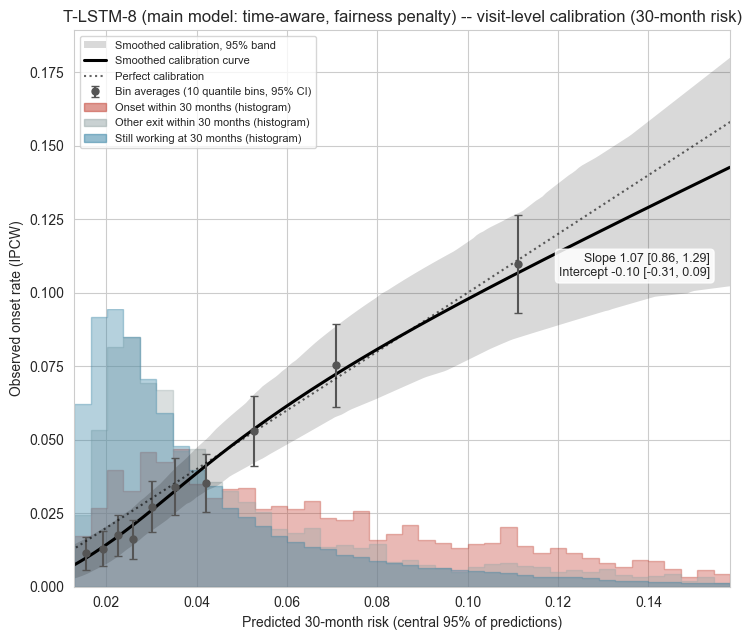

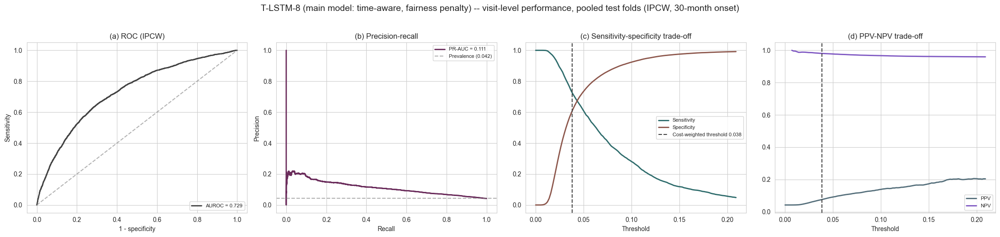

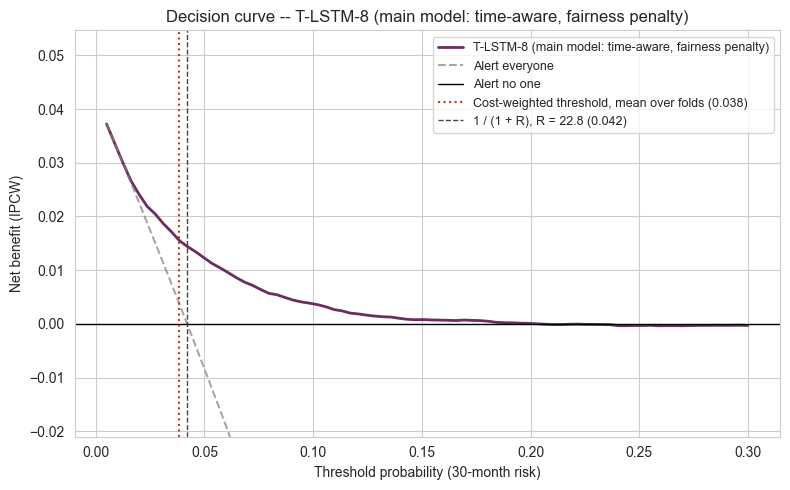

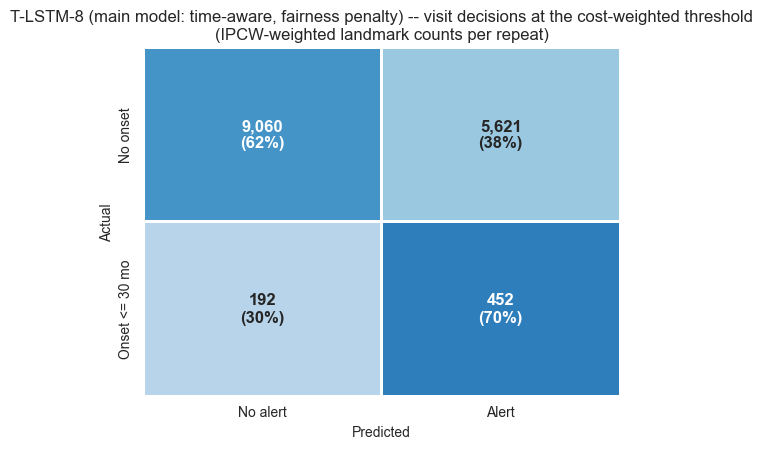

T-LSTM-8 (main model: time-aware, fairness penalty) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 99.6, FN 38.4, TN 441.4, FP 250.6; flagged event patients: the run of alarms was complete a median 12.5 months before onset (85% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
--------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.805 [0.750, 0.860]","0.741 [0.647, 0.835]","0.641 [0.599, 0.686]"
40-49,30,162,"0.840 [0.756, 0.911]","0.813 [0.670, 0.935]","0.620 [0.552, 0.684]"
50-59,42,152,"0.748 [0.658, 0.823]","0.633 [0.500, 0.757]","0.682 [0.617, 0.742]"
>= 60,8,69,"0.718 [0.473, 0.936]","0.700 [0.433, 0.933]","0.568 [0.472, 0.667]"


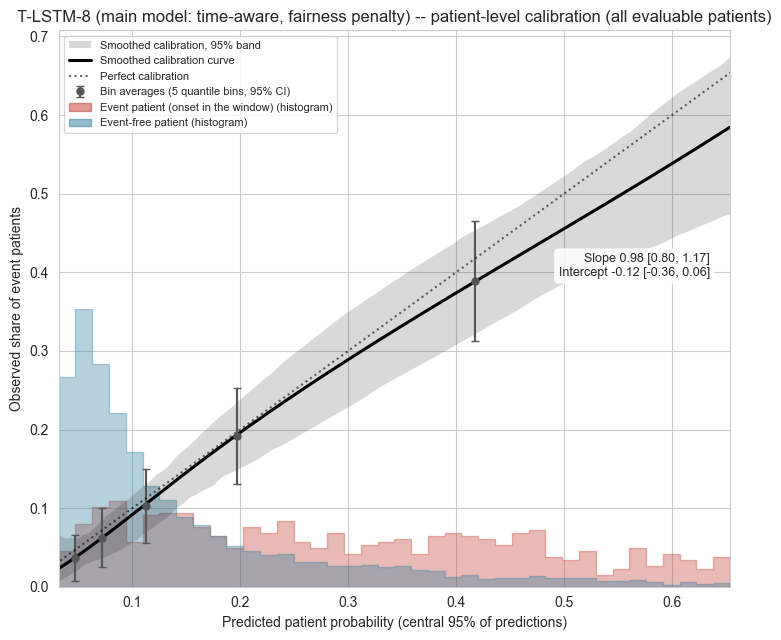

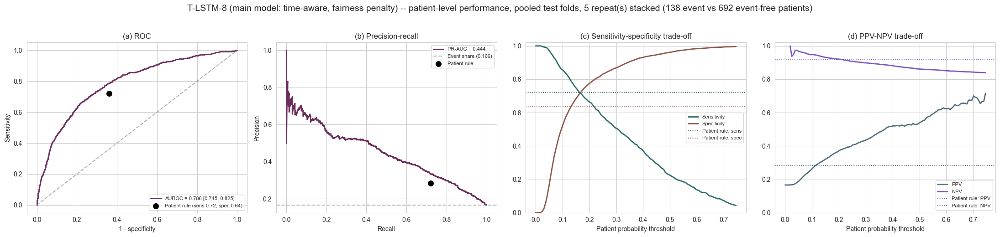

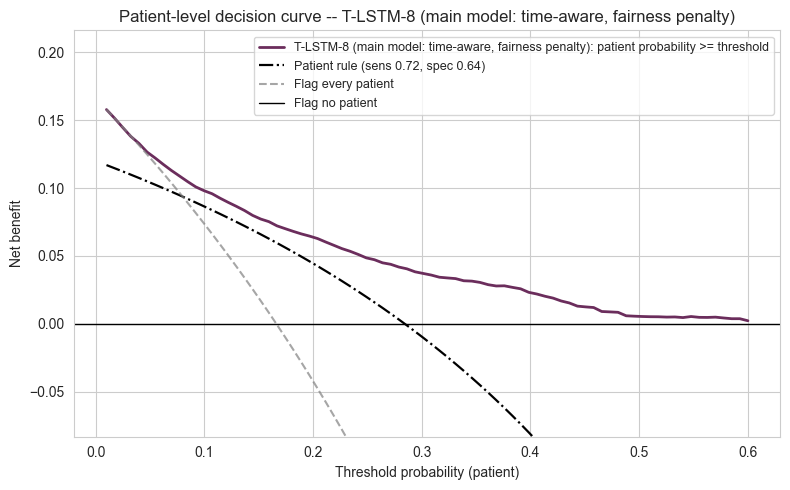

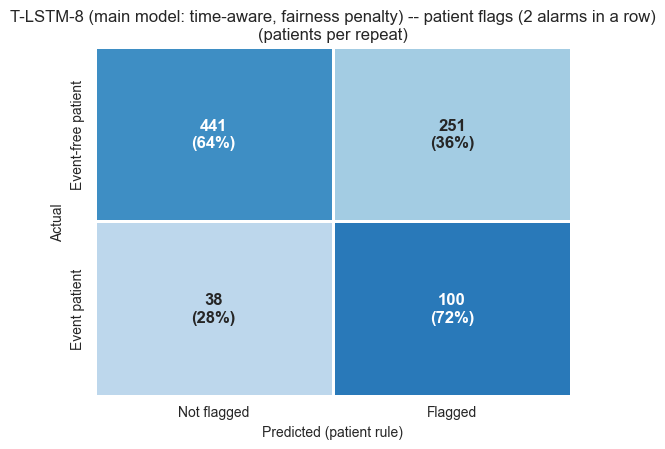


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM,5,22.795 (0.007),0.013 (0.001),0.000 (0.000),0.614 (0.004),0.781 (0.005),0.724 (0.007),0.113 (0.009),38.736 (2.007),0.839 (0.043),0.205 (0.009),0.764 (0.048)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM,5,0.202 (0.031),0.352 (0.044),0.473 (0.039),0.556 (0.042),0.659 (0.034),0.943 (0.004),0.881 (0.005),0.823 (0.009),0.768 (0.013),0.663 (0.023)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM,5,0.013 (0.008),0.309 (0.027),0.538 (0.053),0.656 (0.034),0.739 (0.033),0.997 (0.001),0.890 (0.012),0.768 (0.030),0.678 (0.020),0.556 (0.041),0.338 (0.130),11.490 (1.161),23.843 (2.820),32.774 (1.877),44.810 (3.869)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM,5,0.720 (0.008),0.730 (0.005),0.727 (0.007),0.727 (0.009),0.730 (0.008),0.732 (0.007),0.731 (0.008),0.727 (0.008)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'w8_h8_d03_wd01': 15, 'w8_h16_d05_wd01': 6, 'w8_h16_d05_wd03': 4}
Early stopping, outer-fold fits: median 26 epochs (range 17-54)
  [selection] 1 sequence-model selection(s) trained in 53s
LSTM: final refit on all rows (config w8_h8_d03_wd01, 17 features) in 121s


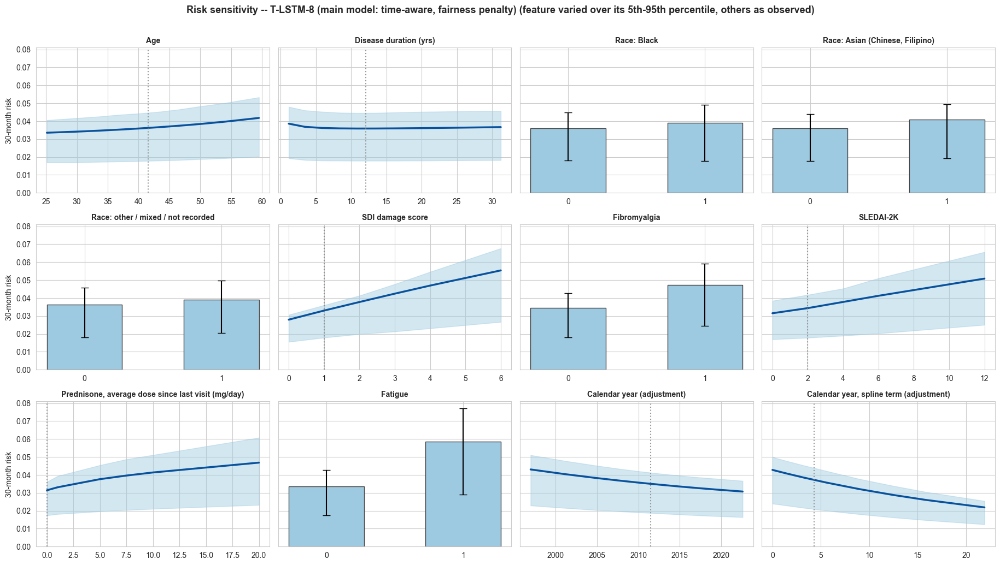


Risk-sensitivity summary -- T-LSTM-8 (main model: time-aware, fairness penalty) (mean 30-month risk; ranked by swing)
                                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                  SDI damage score      0.0279       0.0554                0.0275
                                           Fatigue      0.0335       0.0586                0.0251
           Calendar year, spline term (adjustment)      0.0428       0.0219                0.0209
                                         SLEDAI-2K      0.0315       0.0508                0.0193
Prednisone, average dose since last visit (mg/day)      0.0314       0.0468                0.0154
                                      Fibromyalgia      0.0344       0.0473                0.0128
                        Calendar year (adjustment)      0.0430       0.0307                0.0123
                                               Age      0.0335       0.0418                0.0082

In [19]:
"""The main model (Section 6.1 / 11.7): T-LSTM-8 COLD START (revised_v27) -- an LSTM over each landmark's last 8 visits,
16 or 32 units (tuned per fold), a skip connection from the current visit's variables to the hazard heads (NOT
warm-started), core + its own 5 variables from pool B (the permutation importance of its own network), four auxiliary
12-month heads (training only), next-visit pretraining, cause-specific hazard heads (+ calendar-year terms), early
stopping, 5-seed ensemble in the outer-fold fit."""
res_lstm = run_analysis("LSTM", "T-LSTM-8 (main model: time-aware, fairness penalty)")
if res_lstm is not None:
    print("Configuration chosen per fold:",
          pd.Series([v["best"] for k, v in cv_state["folds"].items() if k[0] == "LSTM"]).value_counts().to_dict())

## 11.10.2 T-LSTM-1 (the main network on the current visit alone)

The same network as T-LSTM-8 -- skip connection, auxiliary heads, seeds, folds -- reading only the landmark visit. It is
the reference of H2c (Section 8.1).

Resuming from cv_state_model_revised_v27.pkl: 25 model-fold fits already done.
[LSTM1      ] repeat 1/5 fold 1/5 | AUROC 0.708 NB(R=23.6) 0.0142 | visit sens/spec 0.74/0.49 | patient sens/spec 0.69/0.49 (TN/FP 70/72) | cfg w1_h16_d05_wd01 | 17 feats | 148s
[LSTM1      ] repeat 1/5 fold 2/5 | AUROC 0.741 NB(R=22.3) 0.0072 | visit sens/spec 0.69/0.54 | patient sens/spec 0.69/0.67 (TN/FP 93/45) | cfg w1_h16_d05_wd01 | 17 feats | 124s
[LSTM1      ] repeat 1/5 fold 3/5 | AUROC 0.744 NB(R=23.1) 0.0159 | visit sens/spec 0.70/0.64 | patient sens/spec 0.74/0.69 (TN/FP 96/43) | cfg w1_h16_d05_wd01 | 17 feats | 118s
[LSTM1      ] repeat 1/5 fold 4/5 | AUROC 0.754 NB(R=22.9) 0.0149 | visit sens/spec 0.79/0.55 | patient sens/spec 0.83/0.58 (TN/FP 83/59) | cfg w1_h16_d05_wd01 | 17 feats | 112s
[LSTM1      ] repeat 1/5 fold 5/5 | AUROC 0.728 NB(R=22.1) 0.0122 | visit sens/spec 0.61/0.76 | patient sens/spec 0.59/0.85 (TN/FP 111/20) | cfg w1_h8_d03_wd01 | 17 feats | 123s
[LSTM1      ] repeat 2/5 fold 1

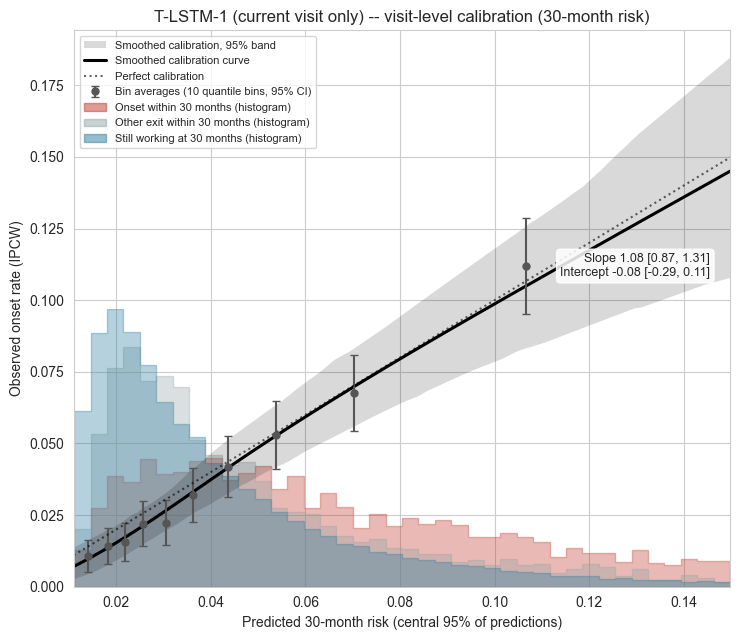

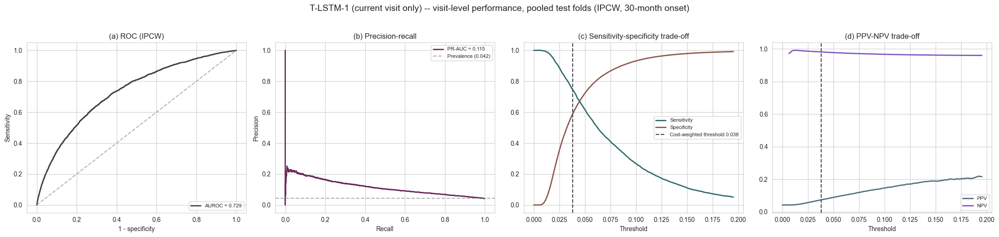

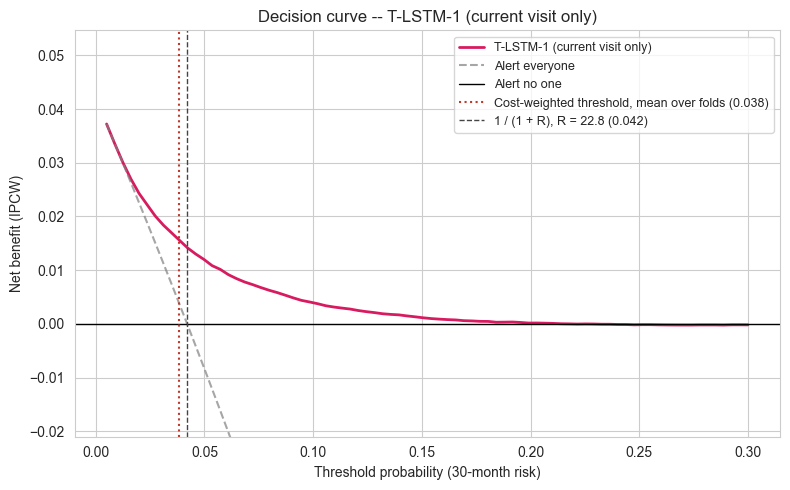

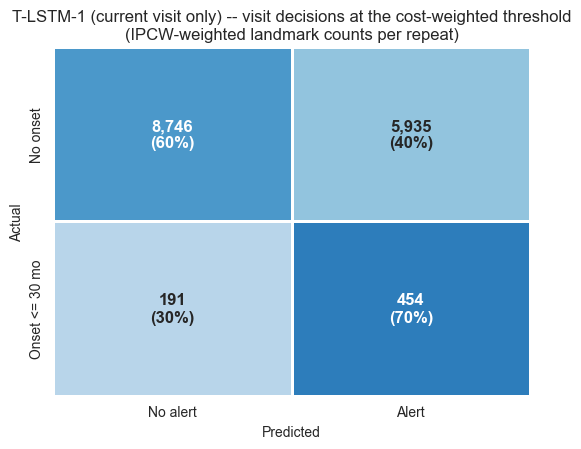

T-LSTM-1 (current visit only) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 96.2, FN 41.8, TN 450.6, FP 241.4; flagged event patients: the run of alarms was complete a median 13.1 months before onset (85% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.820 [0.764, 0.874]","0.717 [0.622, 0.818]","0.671 [0.626, 0.712]"
40-49,30,162,"0.850 [0.766, 0.915]","0.753 [0.605, 0.880]","0.609 [0.543, 0.672]"
50-59,42,152,"0.753 [0.668, 0.830]","0.629 [0.495, 0.757]","0.699 [0.639, 0.756]"
>= 60,8,69,"0.743 [0.492, 0.950]","0.700 [0.400, 0.960]","0.559 [0.459, 0.660]"


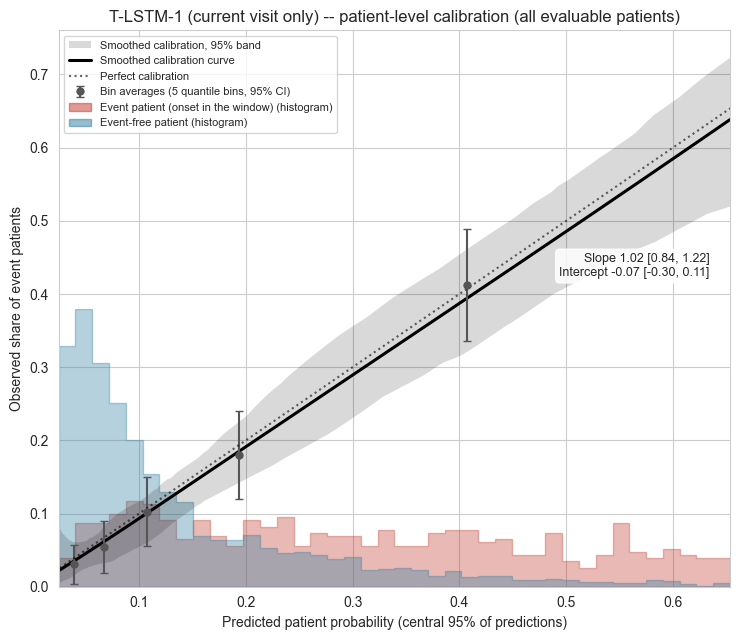

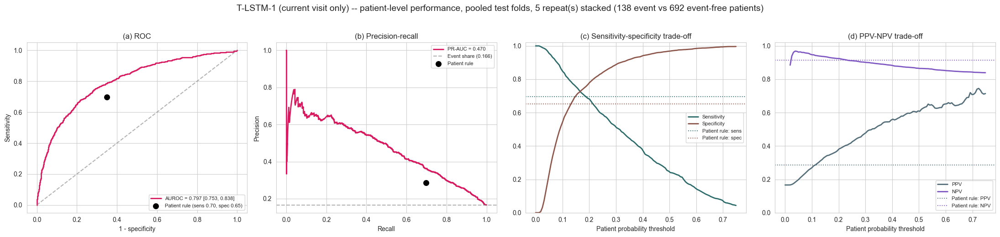

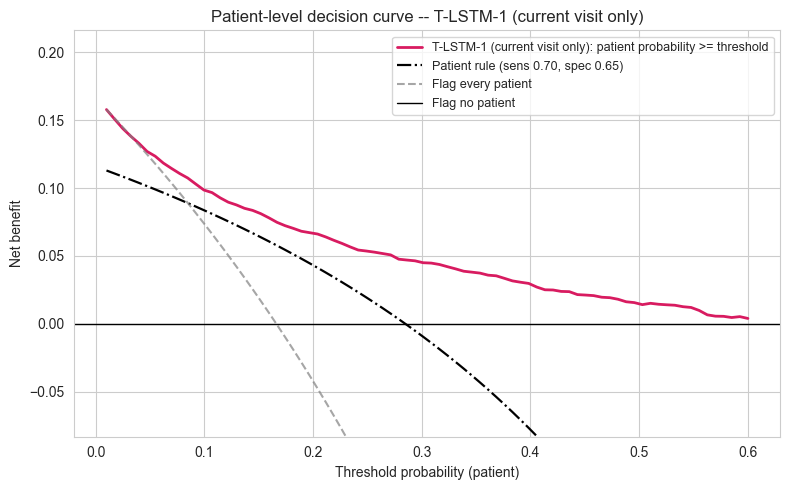

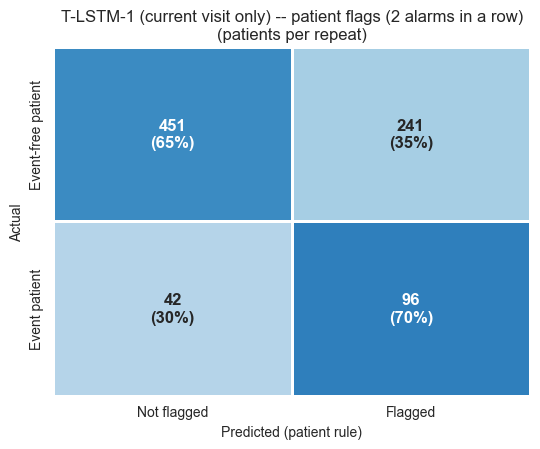


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM1,5,22.795 (0.007),0.013 (0.000),0.000 (0.000),0.613 (0.007),0.776 (0.006),0.723 (0.007),0.116 (0.008),40.726 (1.691),0.882 (0.037),0.274 (0.014),0.808 (0.036)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM1,5,0.200 (0.028),0.337 (0.057),0.447 (0.040),0.534 (0.029),0.650 (0.023),0.949 (0.007),0.890 (0.013),0.834 (0.013),0.777 (0.015),0.671 (0.014)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM1,5,0.018 (0.021),0.249 (0.050),0.516 (0.033),0.665 (0.014),0.780 (0.025),0.996 (0.005),0.917 (0.022),0.781 (0.031),0.657 (0.015),0.491 (0.046),0.393 (0.504),8.743 (2.197),22.497 (2.961),34.768 (1.647),51.133 (4.471)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM1,5,0.714 (0.003),0.726 (0.007),0.726 (0.010),0.726 (0.010),0.729 (0.008),0.731 (0.007),0.730 (0.007),0.726 (0.007)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'w1_h16_d05_wd01': 9, 'w1_h16_d05_wd03': 9, 'w1_h8_d03_wd01': 7}
Early stopping, outer-fold fits: median 29 epochs (range 17-53)
  [selection] 1 sequence-model selection(s) trained in 5s
LSTM1: final refit on all rows (config w1_h16_d05_wd03, 17 features) in 74s


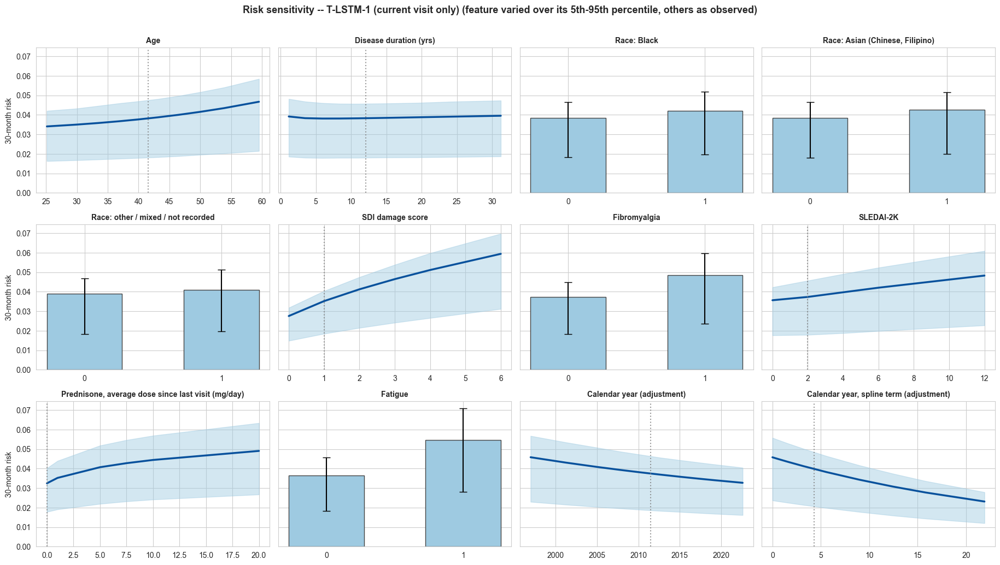


Risk-sensitivity summary -- T-LSTM-1 (current visit only) (mean 30-month risk; ranked by swing)
                                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                  SDI damage score      0.0276       0.0595                0.0319
           Calendar year, spline term (adjustment)      0.0458       0.0231                0.0227
                                           Fatigue      0.0365       0.0548                0.0183
Prednisone, average dose since last visit (mg/day)      0.0325       0.0491                0.0166
                        Calendar year (adjustment)      0.0458       0.0327                0.0131
                                               Age      0.0341       0.0468                0.0127
                                         SLEDAI-2K      0.0357       0.0483                0.0127
                                      Fibromyalgia      0.0373       0.0486                0.0112
                   Ra

In [20]:
"""T-LSTM-1: the main LSTM's recipe (Section 6.1) with a window of 1 visit (the current visit alone); the reference of
Objective 2 (H2a)."""
res_lstm1 = run_analysis("LSTM1", "T-LSTM-1 (current visit only)")


## 11.10.3 T-LSTM-4 and T-LSTM-16 (shorter and longer visit histories)

The main network (skip connection, auxiliary heads, pretraining, 5-seed ensemble) on each landmark's last 4 and last 16
visits, identical folds and repeats.

Resuming from cv_state_model_revised_v27.pkl: 50 model-fold fits already done.
[LSTM_w4    ] repeat 1/5 fold 1/5 | AUROC 0.720 NB(R=23.6) 0.0165 | visit sens/spec 0.77/0.50 | patient sens/spec 0.76/0.46 (TN/FP 66/76) | cfg w4_h16_d05_wd01 | 17 feats | 76s
[LSTM_w4    ] repeat 1/5 fold 2/5 | AUROC 0.751 NB(R=22.3) 0.0091 | visit sens/spec 0.73/0.55 | patient sens/spec 0.81/0.61 (TN/FP 84/54) | cfg w4_h8_d03_wd01 | 17 feats | 86s
[LSTM_w4    ] repeat 1/5 fold 3/5 | AUROC 0.736 NB(R=23.1) 0.0135 | visit sens/spec 0.67/0.61 | patient sens/spec 0.70/0.63 (TN/FP 88/51) | cfg w4_h16_d05_wd03 | 17 feats | 106s
[LSTM_w4    ] repeat 1/5 fold 4/5 | AUROC 0.722 NB(R=22.9) 0.0146 | visit sens/spec 0.65/0.69 | patient sens/spec 0.66/0.73 (TN/FP 104/38) | cfg w4_h8_d03_wd01 | 17 feats | 102s
[LSTM_w4    ] repeat 1/5 fold 5/5 | AUROC 0.740 NB(R=22.1) 0.0119 | visit sens/spec 0.64/0.73 | patient sens/spec 0.67/0.77 (TN/FP 101/30) | cfg w4_h8_d03_wd01 | 17 feats | 95s
[LSTM_w4    ] repeat 2/5 fold 1/5 |

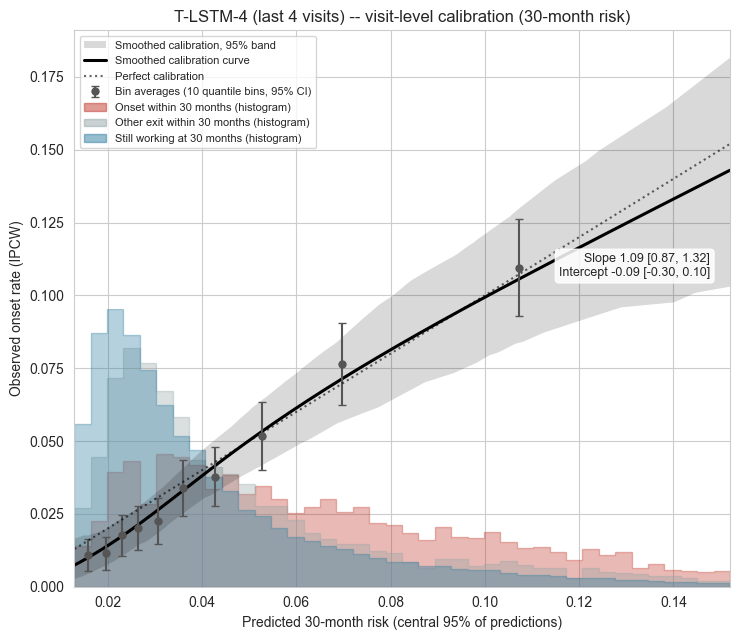

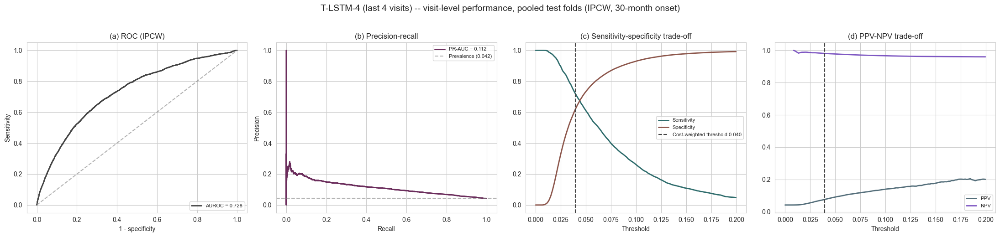

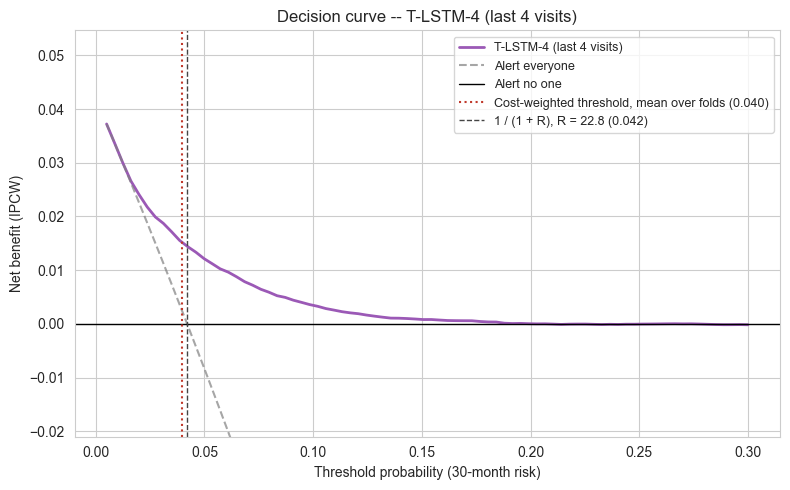

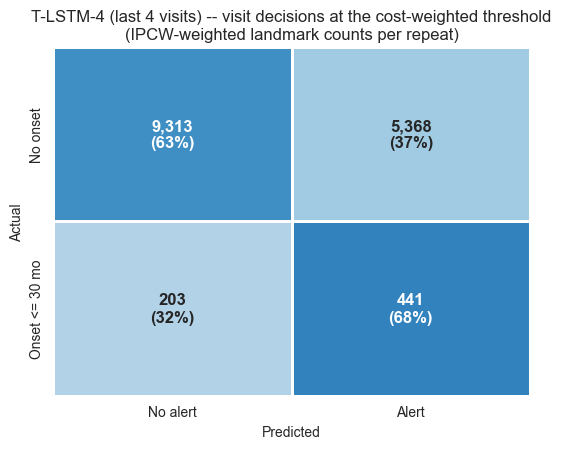

T-LSTM-4 (last 4 visits) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 97.4, FN 40.6, TN 455.6, FP 236.4; flagged event patients: the run of alarms was complete a median 12.6 months before onset (84% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
-----------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.811 [0.755, 0.867]","0.724 [0.626, 0.825]","0.679 [0.636, 0.723]"
40-49,30,162,"0.840 [0.754, 0.909]","0.767 [0.617, 0.897]","0.627 [0.559, 0.692]"
50-59,42,152,"0.747 [0.661, 0.822]","0.624 [0.488, 0.748]","0.699 [0.635, 0.756]"
>= 60,8,69,"0.720 [0.475, 0.936]","0.775 [0.520, 1.000]","0.551 [0.442, 0.656]"


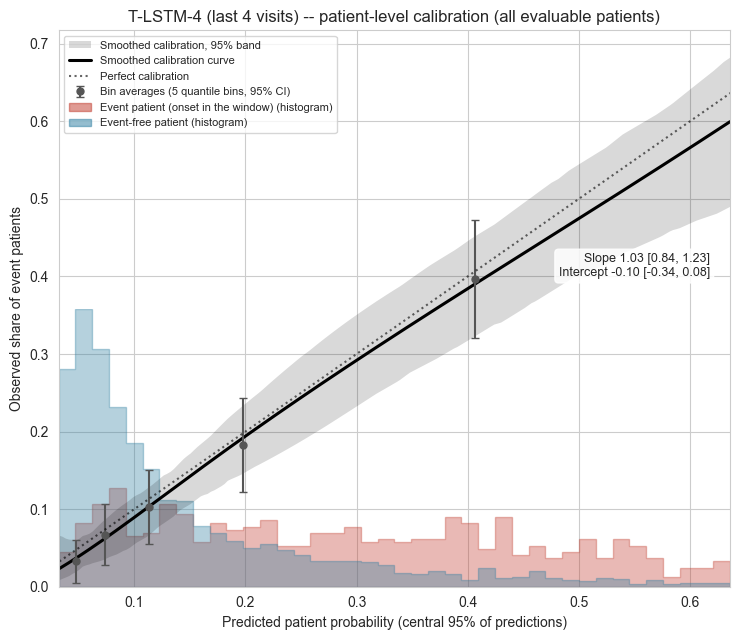

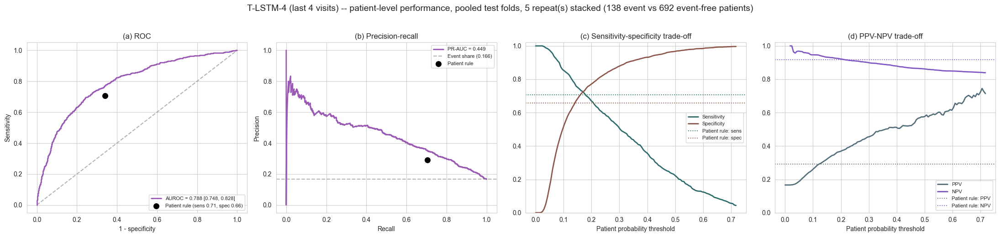

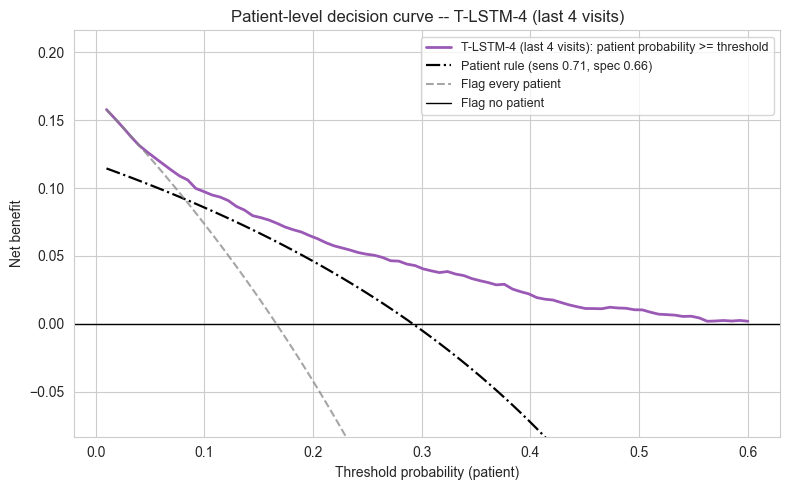

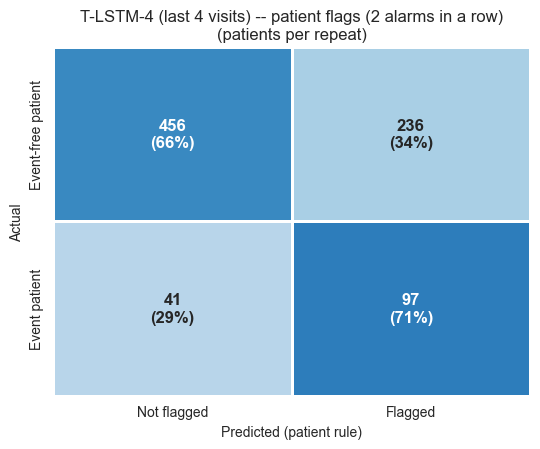


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM_w4,5,22.795 (0.007),0.013 (0.001),0.000 (0.000),0.611 (0.004),0.779 (0.006),0.722 (0.009),0.114 (0.008),37.165 (1.556),0.805 (0.034),0.220 (0.023),0.726 (0.040)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM_w4,5,0.187 (0.029),0.336 (0.051),0.455 (0.052),0.546 (0.048),0.660 (0.034),0.948 (0.003),0.888 (0.008),0.827 (0.012),0.769 (0.016),0.664 (0.024)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM_w4,5,0.024 (0.013),0.284 (0.044),0.508 (0.054),0.643 (0.015),0.769 (0.042),0.994 (0.002),0.898 (0.024),0.783 (0.009),0.676 (0.021),0.506 (0.058),0.673 (0.237),10.733 (2.445),22.335 (0.805),32.977 (2.281),49.819 (5.483)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM_w4,5,0.715 (0.002),0.727 (0.006),0.724 (0.008),0.725 (0.011),0.728 (0.010),0.731 (0.009),0.729 (0.009),0.726 (0.009)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'w4_h8_d03_wd01': 16, 'w4_h16_d05_wd03': 7, 'w4_h16_d05_wd01': 2}
Early stopping, outer-fold fits: median 27 epochs (range 16-60)
  [selection] 1 sequence-model selection(s) trained in 14s
LSTM_w4: final refit on all rows (config w4_h8_d03_wd01, 17 features) in 44s


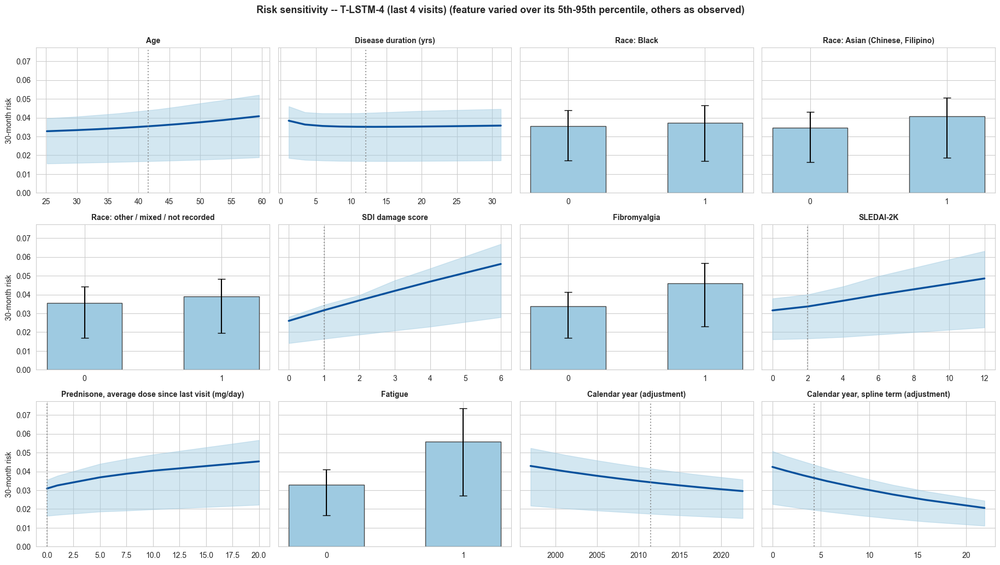


Risk-sensitivity summary -- T-LSTM-4 (last 4 visits) (mean 30-month risk; ranked by swing)
                                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                  SDI damage score      0.0260       0.0563                0.0303
                                           Fatigue      0.0328       0.0559                0.0230
           Calendar year, spline term (adjustment)      0.0424       0.0206                0.0218
                                         SLEDAI-2K      0.0316       0.0486                0.0170
Prednisone, average dose since last visit (mg/day)      0.0309       0.0453                0.0144
                        Calendar year (adjustment)      0.0429       0.0295                0.0134
                                      Fibromyalgia      0.0339       0.0460                0.0121
                                               Age      0.0328       0.0408                0.0080
                   Race: A

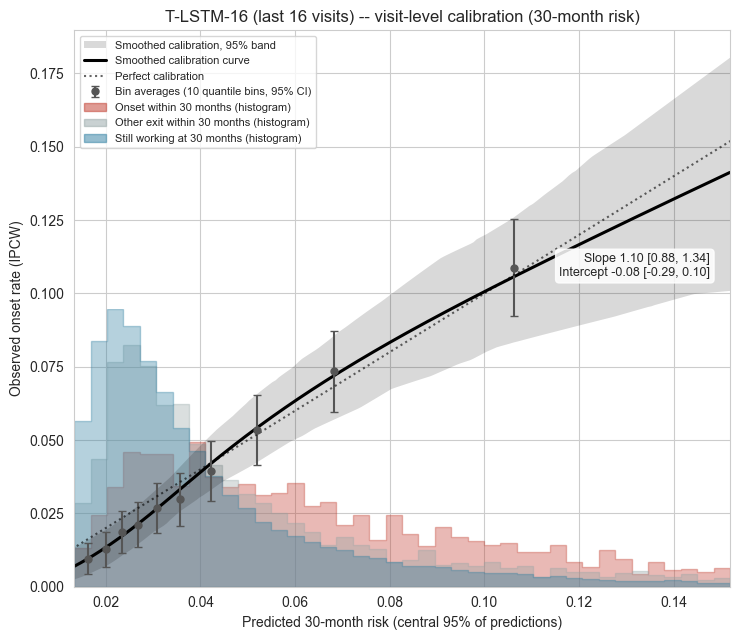

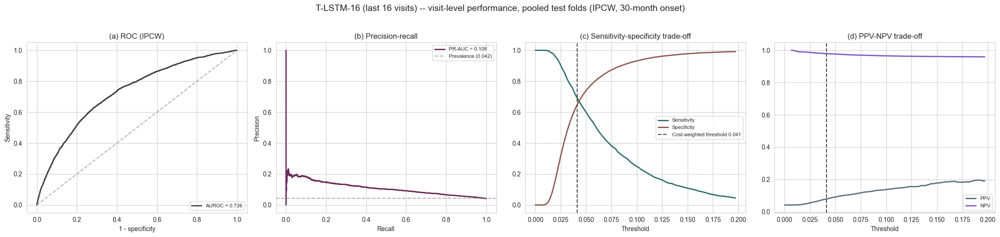

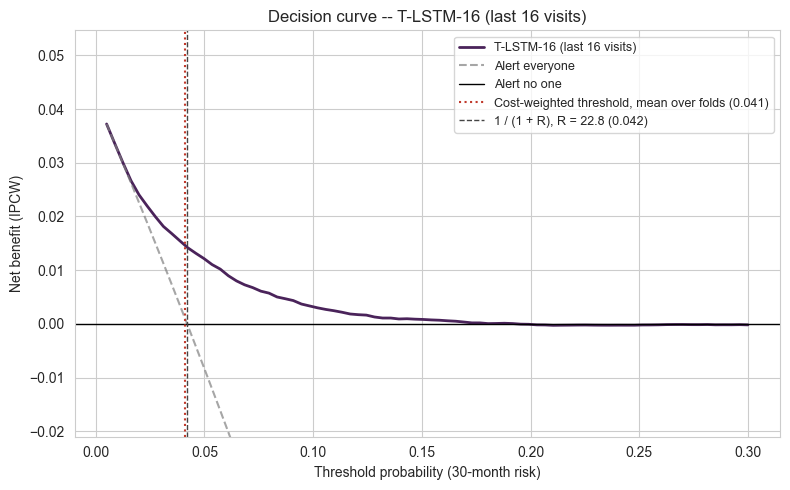

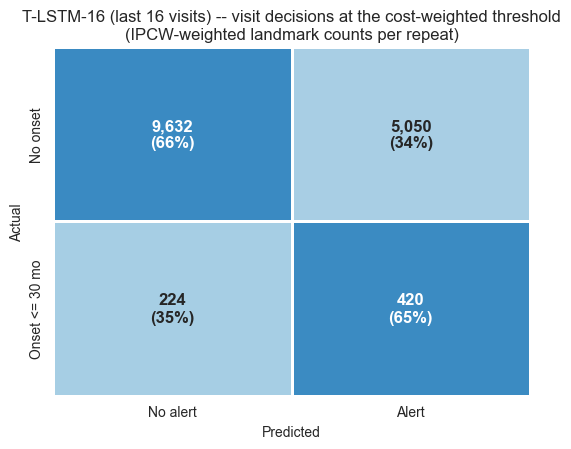

T-LSTM-16 (last 16 visits) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 94.0, FN 44.0, TN 466.2, FP 225.8; flagged event patients: the run of alarms was complete a median 12.2 months before onset (82% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
---------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.807 [0.752, 0.862]","0.700 [0.607, 0.797]","0.678 [0.635, 0.722]"
40-49,30,162,"0.837 [0.752, 0.906]","0.773 [0.625, 0.904]","0.651 [0.583, 0.712]"
50-59,42,152,"0.750 [0.667, 0.824]","0.595 [0.462, 0.729]","0.717 [0.657, 0.772]"
>= 60,8,69,"0.716 [0.471, 0.935]","0.650 [0.364, 0.933]","0.614 [0.516, 0.710]"


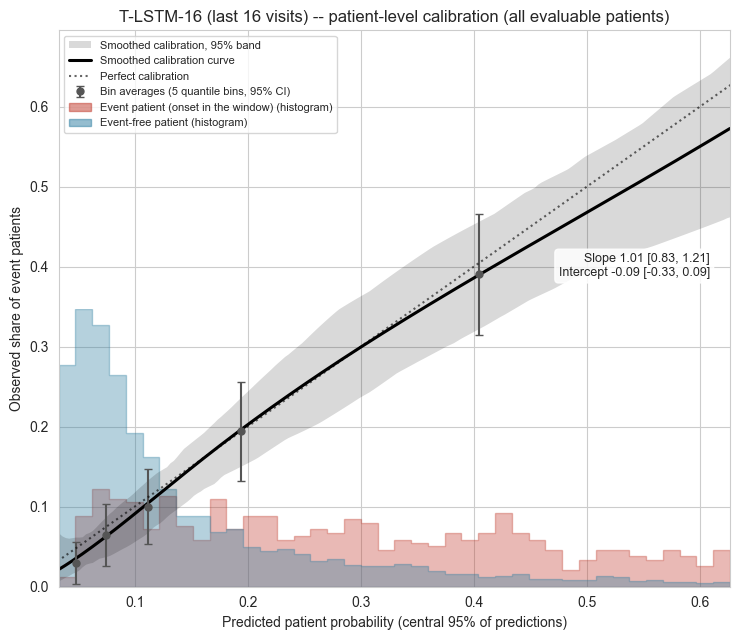

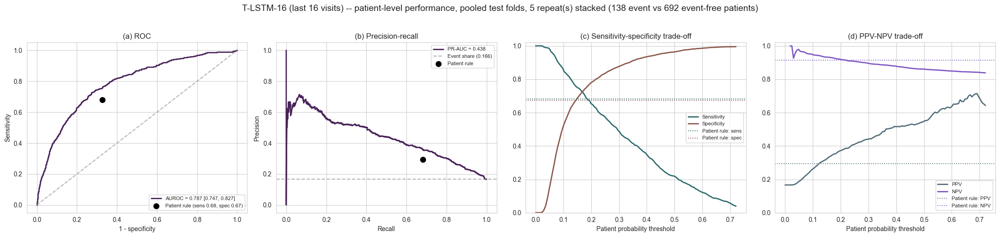

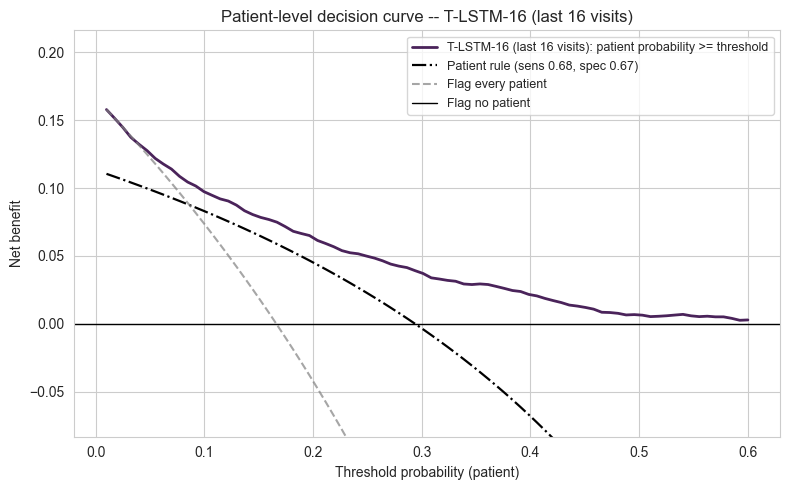

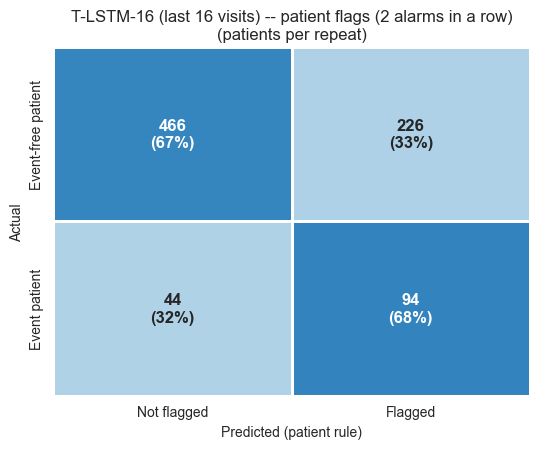


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM_w16,5,22.795 (0.007),0.013 (0.001),0.000 (0.000),0.615 (0.008),0.779 (0.004),0.722 (0.009),0.110 (0.008),34.985 (2.362),0.758 (0.051),0.250 (0.021),0.691 (0.042)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM_w16,5,0.196 (0.029),0.330 (0.039),0.453 (0.034),0.536 (0.037),0.653 (0.029),0.946 (0.006),0.886 (0.008),0.828 (0.011),0.773 (0.012),0.666 (0.020)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM_w16,5,0.015 (0.010),0.264 (0.041),0.526 (0.040),0.617 (0.033),0.758 (0.038),0.996 (0.004),0.906 (0.020),0.774 (0.020),0.693 (0.037),0.521 (0.054),0.452 (0.347),9.887 (2.011),23.385 (1.961),31.325 (3.488),48.325 (5.355)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM_w16,5,0.717 (0.007),0.728 (0.005),0.725 (0.008),0.726 (0.010),0.727 (0.009),0.730 (0.009),0.729 (0.010),0.726 (0.009)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'w16_h8_d03_wd01': 17, 'w16_h16_d05_wd01': 5, 'w16_h16_d05_wd03': 3}
Early stopping, outer-fold fits: median 25 epochs (range 17-44)
  [selection] 1 sequence-model selection(s) trained in 25s
LSTM_w16: final refit on all rows (config w16_h8_d03_wd01, 17 features) in 106s


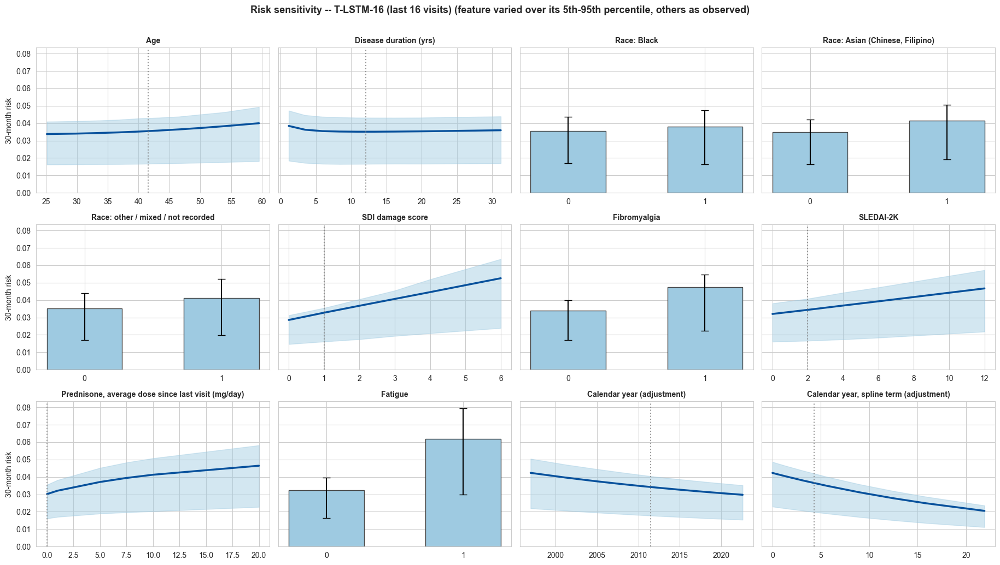


Risk-sensitivity summary -- T-LSTM-16 (last 16 visits) (mean 30-month risk; ranked by swing)
                                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                           Fatigue      0.0324       0.0618                0.0294
                                  SDI damage score      0.0286       0.0525                0.0239
           Calendar year, spline term (adjustment)      0.0423       0.0205                0.0218
Prednisone, average dose since last visit (mg/day)      0.0301       0.0464                0.0163
                                         SLEDAI-2K      0.0320       0.0467                0.0146
                                      Fibromyalgia      0.0338       0.0474                0.0135
                        Calendar year (adjustment)      0.0423       0.0297                0.0126
                   Race: Asian (Chinese, Filipino)      0.0349       0.0414                0.0065
                        

In [21]:
"""T-LSTM-4 and T-LSTM-16: the main LSTM's recipe (Section 6.1) with windows of 4 and 16 visits (Objective 2, H2b)."""
res_lstm4 = run_analysis("LSTM_w4", "T-LSTM-4 (last 4 visits)")
res_lstm16 = run_analysis("LSTM_w16", "T-LSTM-16 (last 16 visits)")

## 11.10.4 Competing-risk logistic regression on the last visit (LogReg)

Resuming from cv_state_model_revised_v27.pkl: 100 model-fold fits already done.
[LogReg     ] repeat 1/5 fold 1/5 | AUROC 0.707 NB(R=23.6) 0.0157 | visit sens/spec 0.59/0.70 | patient sens/spec 0.62/0.73 (TN/FP 103/39) | cfg 0.0003 | 17 feats | 49s
[LogReg     ] repeat 1/5 fold 2/5 | AUROC 0.743 NB(R=22.3) 0.0080 | visit sens/spec 0.61/0.64 | patient sens/spec 0.62/0.74 (TN/FP 102/36) | cfg 0.0003 | 17 feats | 39s
[LogReg     ] repeat 1/5 fold 3/5 | AUROC 0.679 NB(R=23.1) 0.0059 | visit sens/spec 0.45/0.67 | patient sens/spec 0.56/0.71 (TN/FP 98/41) | cfg 0.01 | 17 feats | 52s
[LogReg     ] repeat 1/5 fold 4/5 | AUROC 0.724 NB(R=22.9) 0.0108 | visit sens/spec 0.48/0.77 | patient sens/spec 0.48/0.79 (TN/FP 112/30) | cfg 0.001 | 17 feats | 52s
[LogReg     ] repeat 1/5 fold 5/5 | AUROC 0.702 NB(R=22.1) 0.0097 | visit sens/spec 0.62/0.70 | patient sens/spec 0.59/0.71 (TN/FP 93/38) | cfg 0.001 | 17 feats | 61s
[LogReg     ] repeat 2/5 fold 1/5 | AUROC 0.728 NB(R=22.3) 0.0081 | visit sens/sp

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LogReg     ] repeat 3/5 fold 2/5 | AUROC 0.693 NB(R=22.9) 0.0118 | visit sens/spec 0.58/0.69 | patient sens/spec 0.54/0.74 (TN/FP 100/35) | cfg 0.0003 | 17 feats | 36s
[LogReg     ] repeat 3/5 fold 3/5 | AUROC 0.737 NB(R=23.6) 0.0149 | visit sens/spec 0.63/0.63 | patient sens/spec 0.67/0.69 (TN/FP 93/41) | cfg 0.0003 | 17 feats | 38s
[LogReg     ] repeat 3/5 fold 4/5 | AUROC 0.803 NB(R=23.5) 0.0249 | visit sens/spec 0.81/0.69 | patient sens/spec 0.82/0.67 (TN/FP 98/49) | cfg 0.001 | 17 feats | 40s
[LogReg     ] repeat 3/5 fold 5/5 | AUROC 0.704 NB(R=21.8) 0.0089 | visit sens/spec 0.67/0.68 | patient sens/spec 0.58/0.67 (TN/FP 92/45) | cfg 0.01 | 17 feats | 46s
[LogReg     ] repeat 4/5 fold 1/5 | AUROC 0.731 NB(R=22.6) 0.0095 | visit sens/spec 0.64/0.61 | patient sens/spec 0.68/0.70 (TN/FP 96/42) | cfg 0.0003 | 17 feats | 41s
[LogReg     ] repeat 4/5 fold 2/5 | AUROC 0.668 NB(R=22.7) 0.0084 | visit sens/spec 0.44/0.77 | patient sens/spec 0.48/0.80 (TN/FP 109/27) | cfg 0.0003 | 17 feats

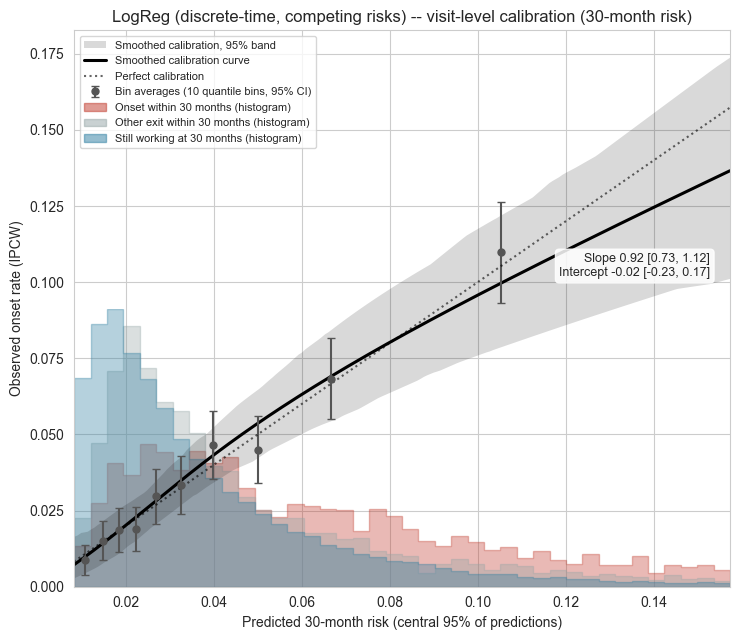

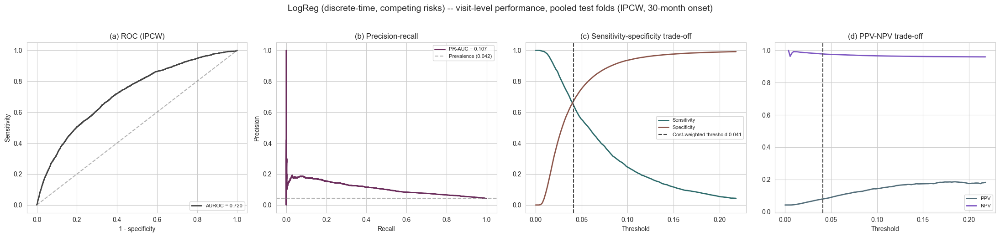

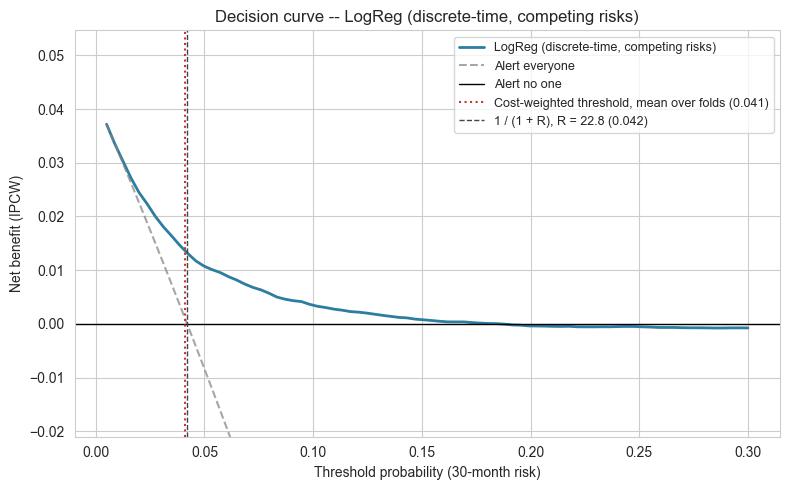

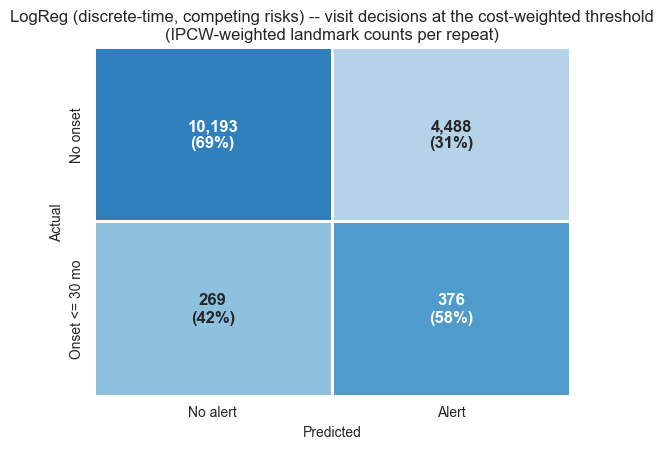

LogReg (discrete-time, competing risks) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 82.2, FN 55.8, TN 504.0, FP 188.0; flagged event patients: the run of alarms was complete a median 12.4 months before onset (76% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
--------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.817 [0.763, 0.870]","0.607 [0.496, 0.715]","0.746 [0.706, 0.787]"
40-49,30,162,"0.851 [0.768, 0.914]","0.673 [0.506, 0.825]","0.694 [0.634, 0.756]"
50-59,42,152,"0.745 [0.657, 0.826]","0.538 [0.406, 0.664]","0.754 [0.696, 0.806]"
>= 60,8,69,"0.730 [0.482, 0.948]","0.525 [0.200, 0.833]","0.675 [0.579, 0.765]"


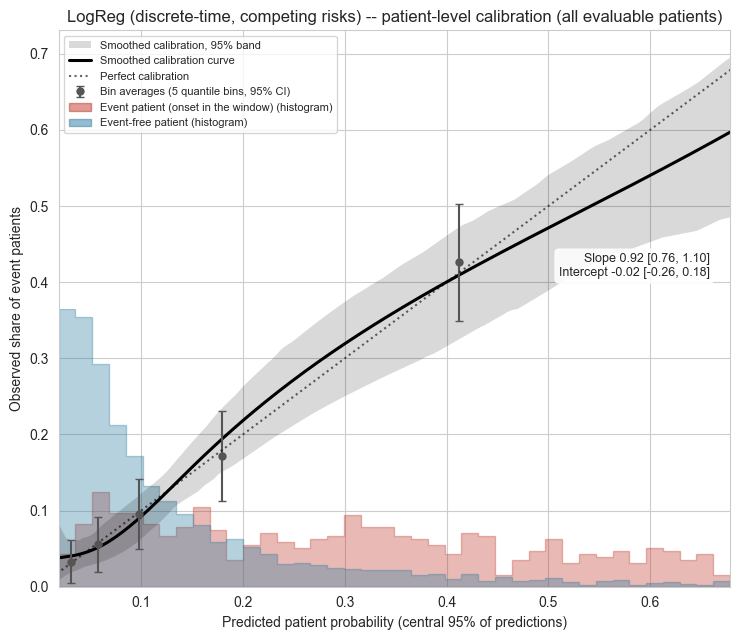

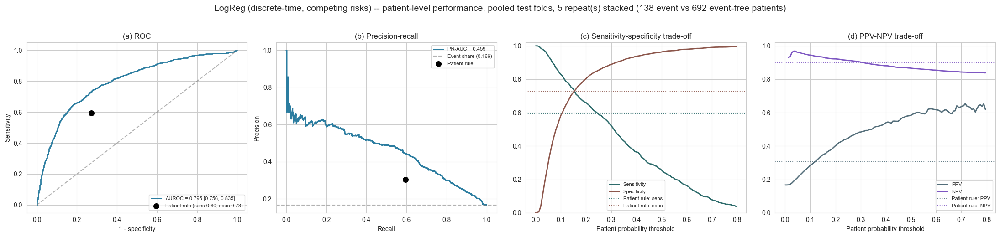

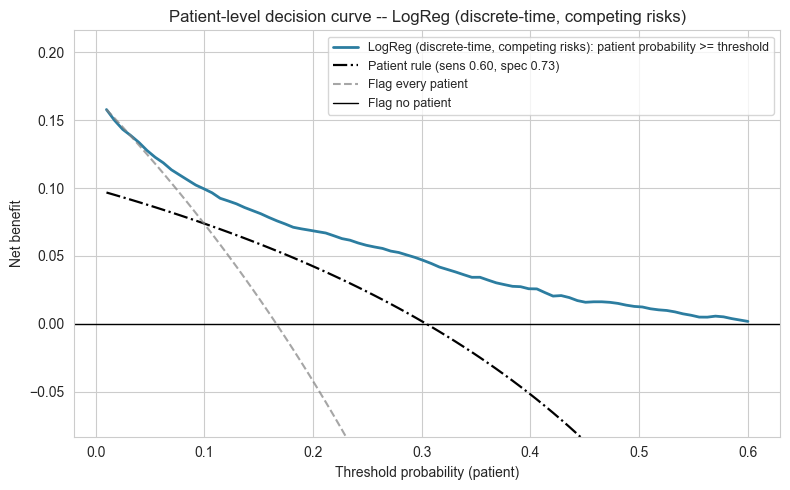

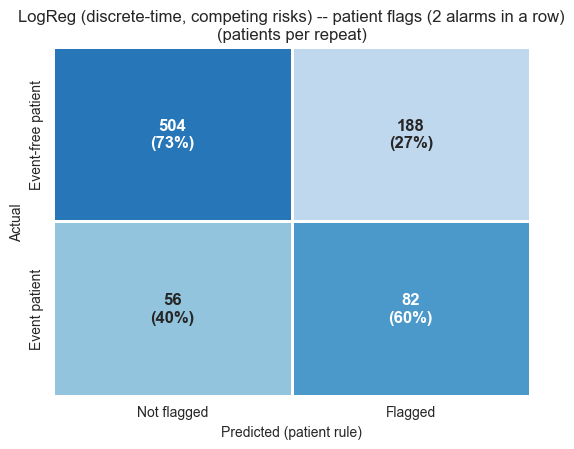


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LogReg,5,22.795 (0.007),0.012 (0.001),0.000 (0.000),0.610 (0.005),0.764 (0.009),0.715 (0.007),0.109 (0.007),31.269 (2.194),0.677 (0.048),0.333 (0.030),0.614 (0.045)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LogReg,5,0.202 (0.008),0.299 (0.019),0.379 (0.014),0.452 (0.015),0.563 (0.024),0.947 (0.006),0.899 (0.005),0.853 (0.005),0.808 (0.005),0.723 (0.006)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LogReg,5,0.054 (0.017),0.241 (0.042),0.378 (0.027),0.546 (0.033),0.743 (0.029),0.985 (0.006),0.924 (0.020),0.847 (0.021),0.725 (0.022),0.485 (0.022),1.605 (0.559),8.103 (2.023),15.831 (2.198),28.180 (2.112),52.129 (1.944)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LogReg,5,0.709 (0.007),0.717 (0.006),0.715 (0.007),0.716 (0.008),0.719 (0.007),0.719 (0.007),0.716 (0.007),0.712 (0.007)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {0.0003: 15, 0.001: 6, 0.01: 3, 0.1: 1}
LogReg: final refit on all rows (config 0.0003, 17 features) in 28s


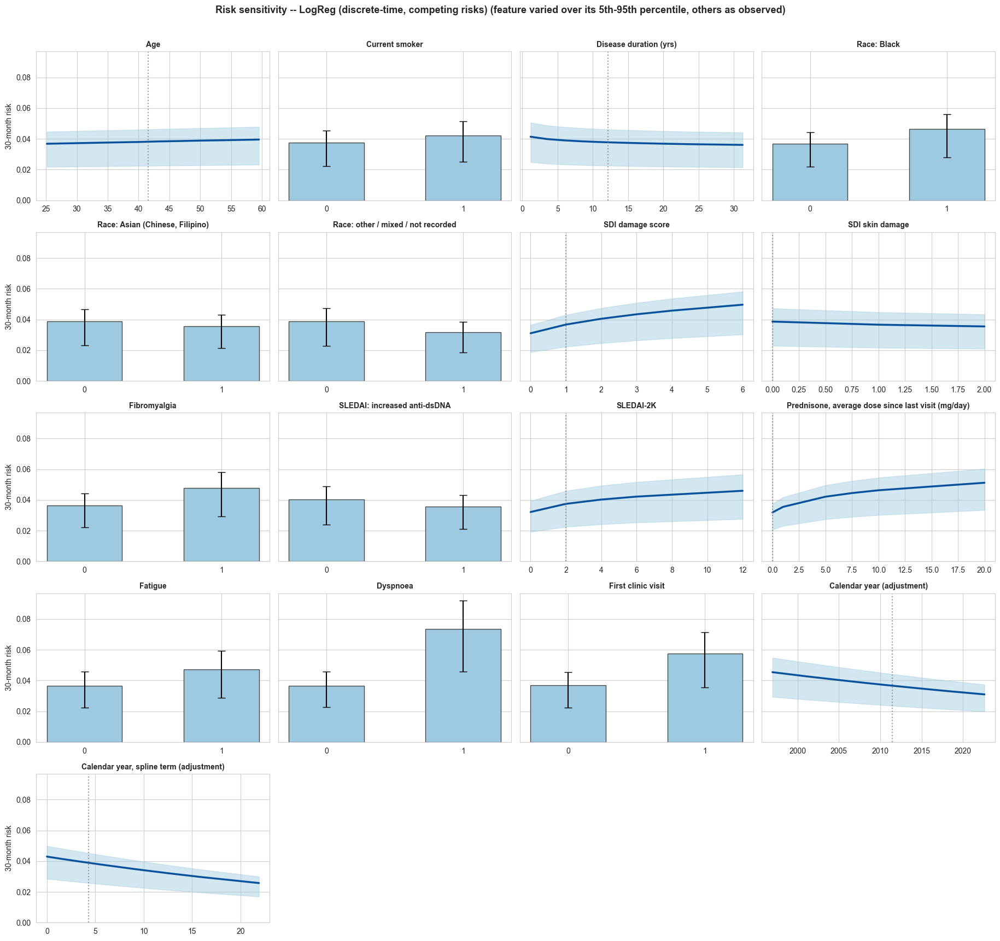


Risk-sensitivity summary -- LogReg (discrete-time, competing risks) (mean 30-month risk; ranked by swing)
                                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                          Dyspnoea      0.0368       0.0737                0.0370
                                First clinic visit      0.0369       0.0577                0.0208
Prednisone, average dose since last visit (mg/day)      0.0319       0.0512                0.0193
                                  SDI damage score      0.0310       0.0496                0.0186
           Calendar year, spline term (adjustment)      0.0430       0.0257                0.0173
                        Calendar year (adjustment)      0.0454       0.0310                0.0144
                                         SLEDAI-2K      0.0322       0.0460                0.0138
                                      Fibromyalgia      0.0364       0.0479                0.0115
           

In [22]:
"""discrete-time competing-risk (pooled multinomial) logistic regression: cumulative incidence of work
disability with other exits and death competing. The pre-specified variables (linear), the calendar-year terms; L2 penalty C tuned
inside each training fold on the cross-fitted cost-weighted net benefit."""
res_logreg = run_analysis("LogReg", "LogReg (discrete-time, competing risks)")

## 11.10.5 Nomogram

The readable form of the regression (Chen et al.'s nomogram model; Section 6.2): the variables selected on all data,
refitted without a penalty as an IPCW logistic regression of onset within 30 months, pooled over the imputations, with
the intercept temporally recalibrated to the last 8 calendar years.

Nomogram model: 17 terms (Age, Current smoker, Disease duration (yrs), Race: Black, Race: Asian (Chinese, Filipino), Race: other / mixed / not recorded, SDI damage score, SDI skin damage, Fibromyalgia, SLEDAI: increased anti-dsDNA, SLEDAI-2K, Prednisone, average dose since last visit (mg/day), Fatigue, Dyspnoea, First clinic visit, Calendar year (adjustment), Calendar year, spline term (adjustment)); 14,339 resolved landmarks, 5 imputations pooled. Temporal recalibration on the landmarks from 2016: intercept shift -0.130 (mean predicted risk there 0.047 -> observed 0.042).


,log-odds per SD,"SE (Rubin, cluster-robust)",OR per SD,OR 95% CI low,OR 95% CI high,p
(Intercept),-2.8193,0.1402,0.0596,0.0453,0.0785,0.0000
Age,0.0990,0.1222,1.1041,0.8690,1.4028,0.4176
Current smoker,0.1700,0.0907,1.1853,0.9923,1.4158,0.0609
Disease duration (yrs),-0.1327,0.1143,0.8757,0.6999,1.0957,0.2457
Race: Black,0.2763,0.0998,1.3182,1.0841,1.6030,0.0056
"Race: Asian (Chinese, Filipino)",0.0768,0.1213,1.0799,0.8514,1.3696,0.5264
Race: other / mixed / not recorded,-0.0228,0.1388,0.9775,0.7447,1.2830,0.8697
SDI damage score,0.4586,0.1245,1.5819,1.2394,2.0190,0.0002
SDI skin damage,-0.2425,0.1079,0.7847,0.6351,0.9696,0.0247
Fibromyalgia,0.1913,0.0823,1.2109,1.0304,1.4229,0.0201


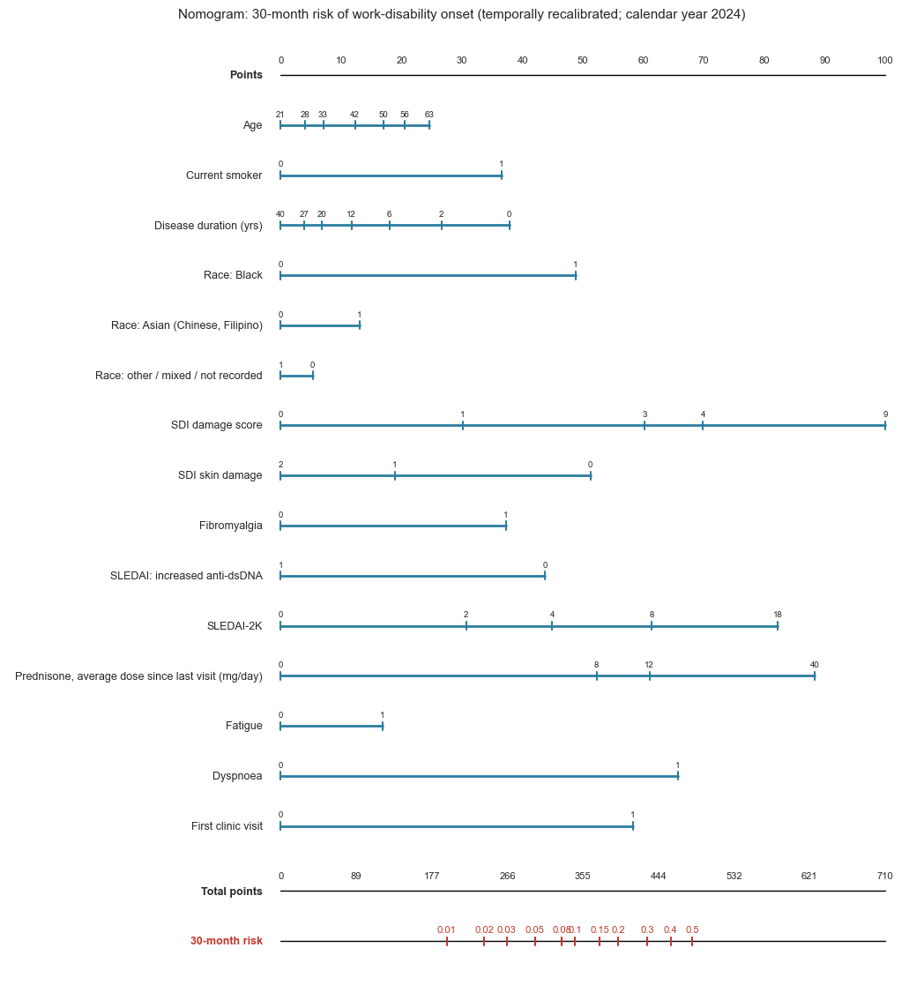

In [23]:
"""
The nomogram model (Section 6.2; Chen et al.'s logistic-regression nomogram): the 30-month risk of work-disability
onset as an IPCW logistic regression of 'onset within 30 months' (the competing-risk label of every metric) on the
pre-specified variables (SELECTION_ALL), refitted WITHOUT a penalty on each of the
M_IMPUTATIONS completed datasets and pooled with Rubin's rules (patient-clustered robust SEs). For the published model
the intercept is TEMPORALLY RECALIBRATED (Booth et al., Int J Epidemiol 2020): re-estimated on the landmarks of the last
TEMPORAL_RECAL_YEARS calendar years, with the calendar year held at the latest year in the data. Its cross-validated
performance is that of the LogReg (Section 11.10.4), which is the same variables in a competing-risk
discrete-time form; the nomogram is the readable, by-hand version.
"""
import statsmodels.api as sm

NOMO_COLS = fold_features("LogReg", ALL_ROWS)            # revised_v27: core + the LASSO's choice on all rows
_rows = np.arange(len(land))
_prep_nomo = TabularPrep(NOMO_COLS)
_Xs_nomo = _prep_nomo.fit_transform(X_for(_rows, NOMO_COLS), PID_ALL[_rows])
_y_n, _w_n = IPCW[PRIMARY_HORIZON_MONTHS]
_w_n = _w_n * land["weight"].values
_k_n = _w_n > 0
_grp_n = pd.factorize(PID_ALL[_k_n])[0]
_fits = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for X in _Xs_nomo:
        _fits.append(sm.GLM(_y_n[_k_n], sm.add_constant(X[_k_n]), family=sm.families.Binomial(),
                            var_weights=_w_n[_k_n] / _w_n[_k_n].mean()).fit(cov_type="cluster",
                                                                             cov_kwds={"groups": _grp_n}))
_Q = np.array([f.params for f in _fits])
_U = np.array([np.diag(f.cov_params()) for f in _fits])
_m = len(_fits)
NOMO_BETA = _Q.mean(0)
_T = _U.mean(0) + (1 + 1 / _m) * _Q.var(0, ddof=1)
_se = np.sqrt(_T)
_names = ["(Intercept)"] + [DISPLAY_NAMES.get(c, c) for c in NOMO_COLS]
nomo_table = pd.DataFrame({"log-odds per SD": NOMO_BETA, "SE (Rubin, cluster-robust)": _se,
                           "OR per SD": np.exp(NOMO_BETA), "OR 95% CI low": np.exp(NOMO_BETA - 1.96 * _se),
                           "OR 95% CI high": np.exp(NOMO_BETA + 1.96 * _se),
                           "p": 2 * stats.norm.sf(np.abs(NOMO_BETA / _se))}, index=_names)
# temporal recalibration of the intercept, with the calendar year at the latest year
_lp_all = np.mean([sm.add_constant(X) @ NOMO_BETA for X in _Xs_nomo], axis=0)
_recent = (CAL_YEAR_ALL >= CAL_YEAR_ALL.max() - TEMPORAL_RECAL_YEARS) & _k_n
NOMO_SHIFT = brentq(lambda a: np.average(_expit(a + _lp_all[_recent]), weights=_w_n[_recent])
                    - np.average(_y_n[_recent], weights=_w_n[_recent]), -10, 10)
_year_terms = {c: _prep_nomo.transform_value(NOMO_COLS.index(c), float(land[c].max())) for c in ADJUST_COLS
               if c in NOMO_COLS}
NOMO_CONST = NOMO_BETA[0] + NOMO_SHIFT + sum(NOMO_BETA[1 + NOMO_COLS.index(c)] * z for c, z in _year_terms.items())
print(f"Nomogram model: {len(NOMO_COLS)} terms ({', '.join(_names[1:])}); {int(_k_n.sum()):,} resolved landmarks, "
      f"{_m} imputations pooled. Temporal recalibration on the landmarks from {CAL_YEAR_ALL.max() - TEMPORAL_RECAL_YEARS:.0f}: "
      f"intercept shift {NOMO_SHIFT:+.3f} (mean predicted risk there {np.average(_expit(_lp_all[_recent]), weights=_w_n[_recent]):.3f} "
      f"-> observed {np.average(_y_n[_recent], weights=_w_n[_recent]):.3f}).")
display(nomo_table.round(4))
nomo_table.to_csv("nomogram_model_coefficients_revised_v27.csv")


def draw_nomogram(save=None):
    """Points per variable (0 at the value with the lowest risk contribution; 100 = the widest range among the
    variables, 1st-99th percentile of the landmarks), total points, and the temporally recalibrated 30-month risk."""
    rows_ = []
    for j, c in enumerate(NOMO_COLS):
        if c in ADJUST_COLS:
            continue
        x = land[c].dropna().values.astype(float)
        binary = set(np.unique(x)) <= {0.0, 1.0}
        nd = 0 if np.ptp(np.percentile(x, [1, 99])) >= 10 else (1 if np.ptp(np.percentile(x, [1, 99])) >= 1 else 2)
        vals = np.array([0.0, 1.0]) if binary else np.unique(np.round(np.percentile(x, [1, 10, 25, 50, 75, 90, 99]), nd))
        contrib = np.array([NOMO_BETA[1 + j] * _prep_nomo.transform_value(j, v) for v in vals])
        rows_.append((c, vals, contrib))
    span = max(np.ptp(cb) for _, _, cb in rows_) or 1.0
    scale = 100.0 / span
    fig, ax = plt.subplots(figsize=(11, 0.55 * (len(rows_) + 4) + 1))
    y = len(rows_) + 2
    ax.plot([0, 100], [y, y], color="black", lw=1)
    for p_ in range(0, 101, 10):
        ax.text(p_, y + 0.25, f"{p_}", ha="center", fontsize=8)
    ax.text(-3, y, "Points", ha="right", va="center", fontsize=9, fontweight="bold")
    base = 0.0
    for c, vals, cb in rows_:
        y -= 1
        pts = (cb - cb.min()) * scale
        base += cb.min()
        ax.plot([pts.min(), pts.max()], [y, y], color="#2c7da0", lw=2)
        for v, p_ in zip(vals, pts):
            ax.plot([p_, p_], [y - 0.08, y + 0.08], color="#2c7da0")
            ax.text(p_, y + 0.18, f"{v:g}", ha="center", fontsize=7)
        ax.text(-3, y, DISPLAY_NAMES.get(c, c), ha="right", va="center", fontsize=9)
    max_total = sum(np.ptp(cb) for _, _, cb in rows_) * scale
    y -= 1.3
    tot_ticks = np.linspace(0, max_total, 9)
    ax.plot([0, 100], [y, y], color="black", lw=1)
    for t in tot_ticks:
        ax.text(t / max_total * 100, y + 0.25, f"{t:.0f}", ha="center", fontsize=8)
    ax.text(-3, y, "Total points", ha="right", va="center", fontsize=9, fontweight="bold")
    y -= 1.0
    ax.plot([0, 100], [y, y], color="black", lw=1)
    lp_of_points = lambda tp: NOMO_CONST + base + tp / scale
    for r_ in [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
        tp = (_logit(r_) - NOMO_CONST - base) * scale
        if 0 <= tp <= max_total:
            ax.plot([tp / max_total * 100] * 2, [y - 0.08, y + 0.08], color="#c0392b")
            ax.text(tp / max_total * 100, y + 0.18, f"{r_:g}", ha="center", fontsize=8, color="#c0392b")
    ax.text(-3, y, "30-month risk", ha="right", va="center", fontsize=9, fontweight="bold", color="#c0392b")
    ax.set_xlim(-45, 105); ax.set_ylim(y - 1, len(rows_) + 3); ax.axis("off")
    ax.set_title(f"Nomogram: 30-month risk of work-disability onset (temporally recalibrated; calendar year "
                 f"{CAL_YEAR_ALL.max():.0f})", fontsize=11)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    return lp_of_points


nomogram_lp = draw_nomogram(save=f"{OUT_DIR}/revised_v27_nomogram.png")

## 11.10.6 Baseline (the patient at the index visit)

revised_v27: the index-visit age, SDI damage score and SLEDAI-2K, current age, education, race and the calendar-year
terms in the sequence models' cause-specific discrete-time hazard model, on the same folds (no sequence, no visit after
the first employed one). It is a reference, not a candidate tool: its visit- and patient-level
tables are shown for completeness.

Resuming from cv_state_model_revised_v27.pkl: 125 model-fold fits already done.
[Baseline   ] repeat 1/5 fold 1/5 | AUROC 0.611 NB(R=23.6) 0.0071 | visit sens/spec 0.46/0.63 | patient sens/spec 0.48/0.65 (TN/FP 92/50) | cfg None | 12 feats | 7s
[Baseline   ] repeat 1/5 fold 2/5 | AUROC 0.692 NB(R=22.3) 0.0027 | visit sens/spec 0.28/0.81 | patient sens/spec 0.35/0.83 (TN/FP 115/23) | cfg None | 12 feats | 7s
[Baseline   ] repeat 1/5 fold 3/5 | AUROC 0.656 NB(R=23.1) 0.0058 | visit sens/spec 0.63/0.47 | patient sens/spec 0.59/0.45 (TN/FP 62/77) | cfg None | 12 feats | 8s
[Baseline   ] repeat 1/5 fold 4/5 | AUROC 0.583 NB(R=22.9) 0.0003 | visit sens/spec 0.59/0.40 | patient sens/spec 0.62/0.42 (TN/FP 60/82) | cfg None | 12 feats | 9s
[Baseline   ] repeat 1/5 fold 5/5 | AUROC 0.645 NB(R=22.1) 0.0063 | visit sens/spec 0.38/0.82 | patient sens/spec 0.44/0.81 (TN/FP 106/25) | cfg None | 12 feats | 7s
[Baseline   ] repeat 2/5 fold 1/5 | AUROC 0.668 NB(R=22.3) 0.0031 | visit sens/spec 0.59/0.54

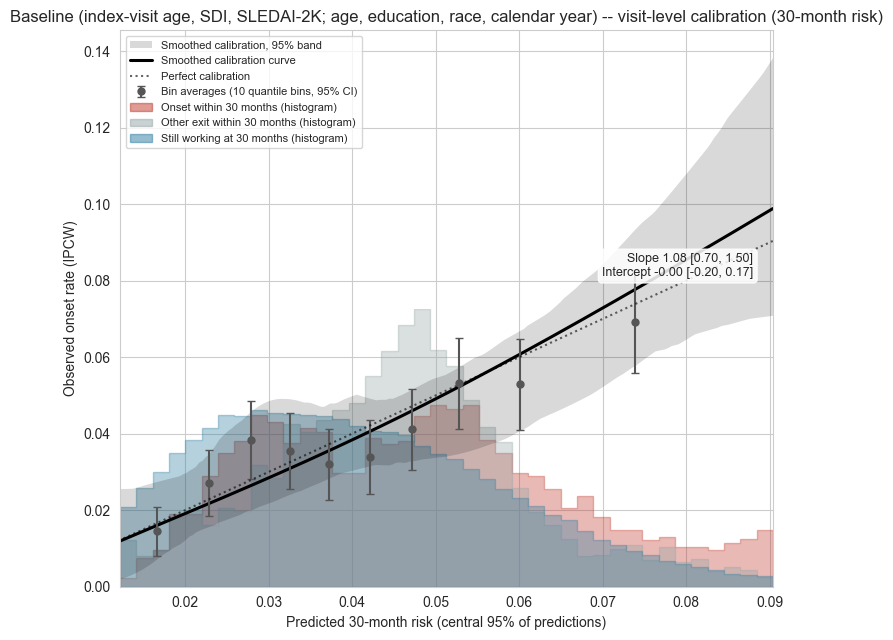

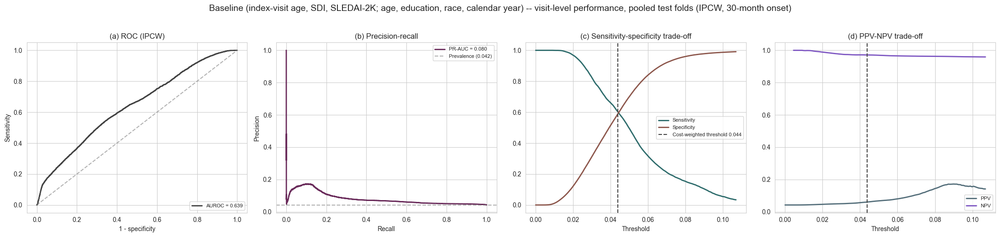

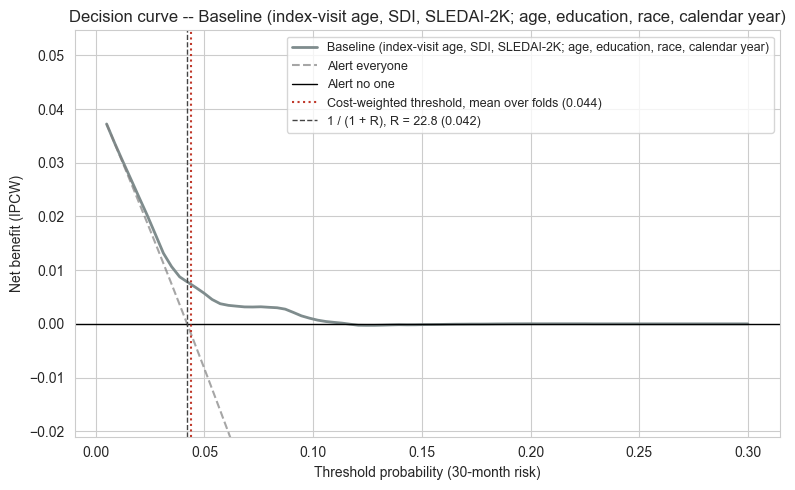

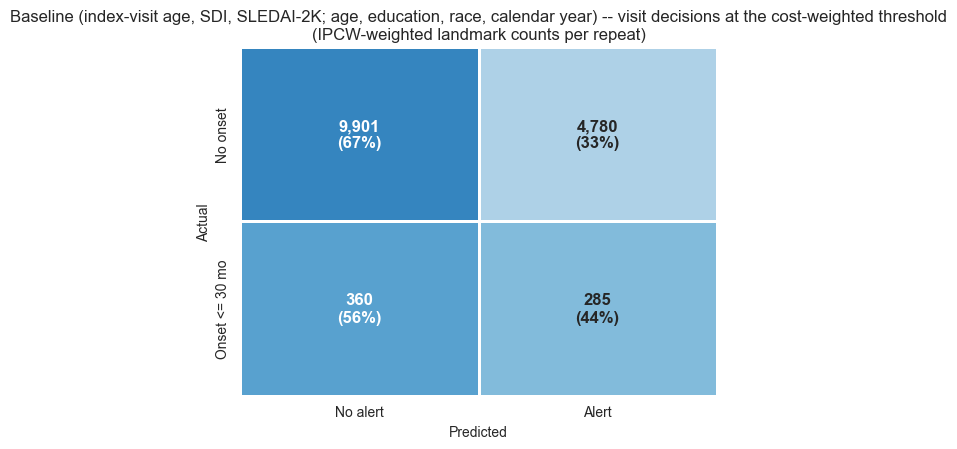

Baseline (index-visit age, SDI, SLEDAI-2K; age, education, race, calendar year) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 68.8, FN 69.2, TN 463.8, FP 228.2; flagged event patients: the run of alarms was complete a median 12.2 months before onset (95% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.753 [0.682, 0.824]","0.514 [0.410, 0.635]","0.635 [0.591, 0.678]"
40-49,30,162,"0.814 [0.732, 0.887]","0.513 [0.342, 0.683]","0.670 [0.610, 0.731]"
50-59,42,152,"0.743 [0.660, 0.821]","0.429 [0.295, 0.564]","0.691 [0.622, 0.755]"
>= 60,8,69,"0.709 [0.518, 0.901]","0.700 [0.371, 0.964]","0.783 [0.692, 0.865]"


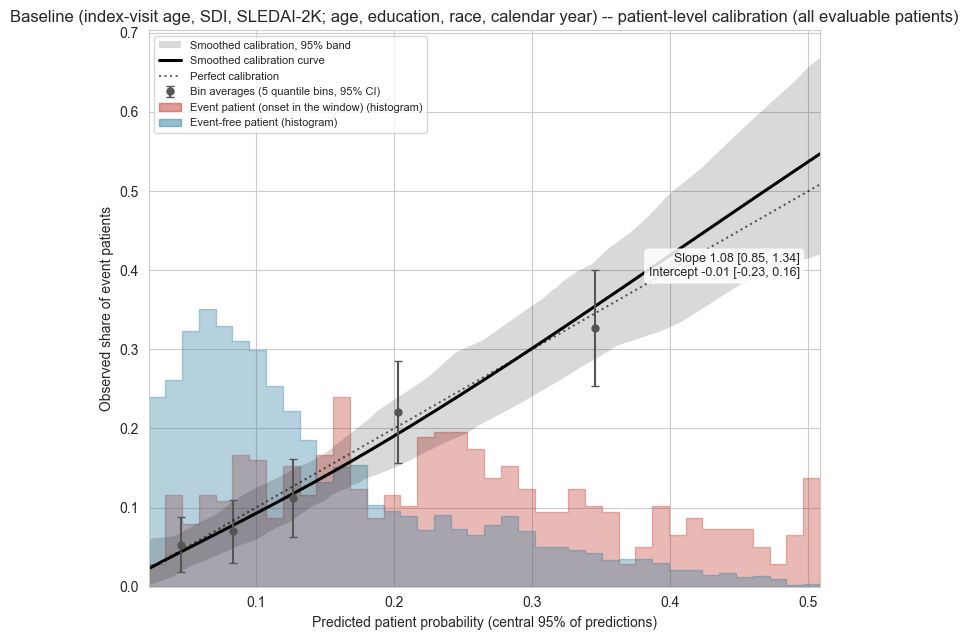

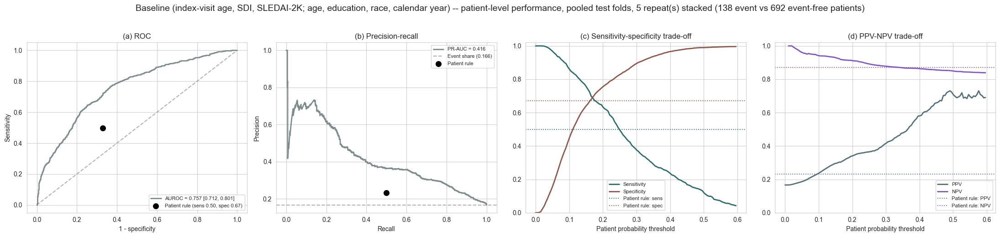

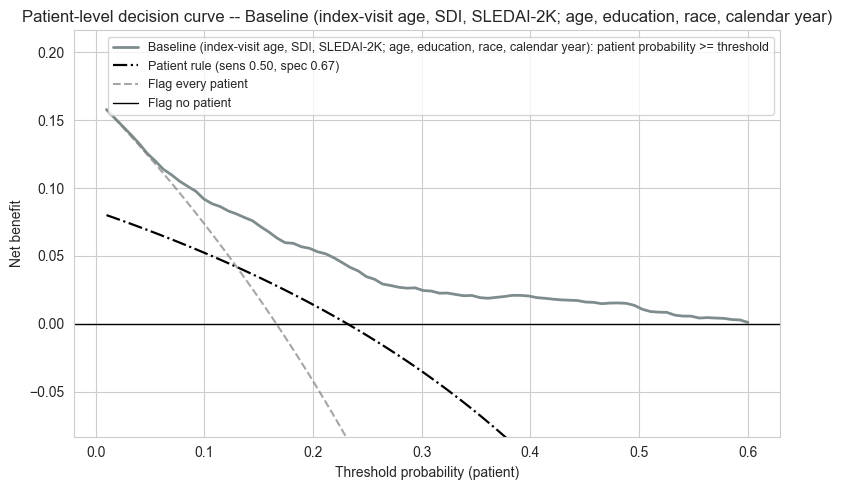

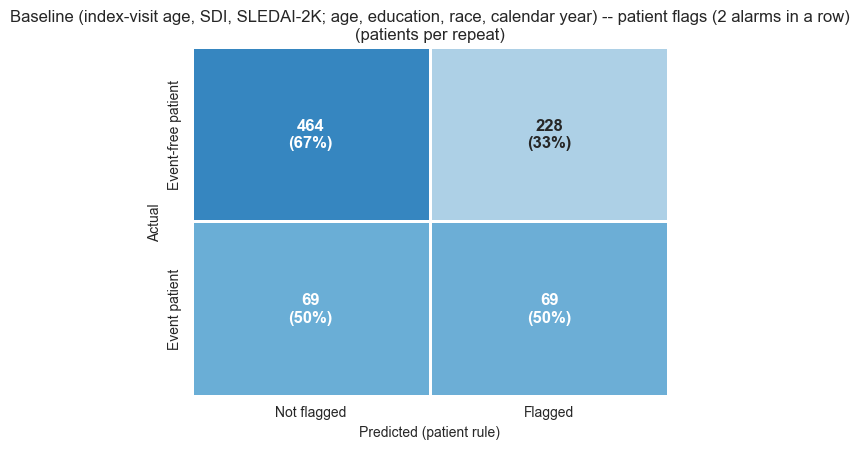


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
Baseline,5,22.795 (0.007),0.005 (0.001),0.000 (0.000),0.564 (0.003),0.713 (0.005),0.644 (0.002),0.081 (0.003),32.857 (3.615),0.712 (0.078),0.403 (0.034),0.709 (0.082)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
Baseline,5,0.118 (0.013),0.227 (0.007),0.277 (0.012),0.319 (0.014),0.453 (0.026),0.956 (0.002),0.909 (0.005),0.863 (0.008),0.812 (0.007),0.708 (0.009)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
Baseline,5,0.000 (0.000),0.055 (0.022),0.195 (0.040),0.375 (0.031),0.865 (0.020),1.000 (0.000),0.973 (0.010),0.918 (0.016),0.754 (0.047),0.149 (0.016),0.000 (0.000),2.787 (1.036),8.575 (1.645),25.030 (4.662),84.396 (1.640)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
Baseline,5,0.647 (0.007),0.649 (0.005),0.643 (0.004),0.639 (0.003),0.639 (0.002),0.641 (0.002),0.640 (0.002),0.633 (0.002)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {}


In [24]:
"""Baseline (Section 6.2; revised_v27): linear cause-specific discrete-time hazard on the INDEX-visit values (age, SDI,
SLEDAI-2K at the first employed visit), current age, education, race and the calendar-year terms (BASELINE_COLS),
identical folds, same checkpoint (resumable). H1a's reference."""
CV_MODELS.append("Baseline")                     # report_cv_model's tables list the models of CV_MODELS
try:
    res_baseline = report_cv_model("Baseline", "Baseline (index-visit age, SDI, SLEDAI-2K; age, education, race, "
                                                 "calendar year)")
finally:
    CV_MODELS.remove("Baseline")                 # not a candidate model: no stack, overview or sensitivity refit

## 11.10.7 GRU

The GRU on the LSTMs' recipe (revised_v27): skip connection, auxiliary heads, cold start, 16 or 32 units chosen per
fold, its own 5 variables from pool B (the permutation importance of its own network), over the **whole** visit
history instead of a fixed window.

Resuming from cv_state_model_revised_v27.pkl: 150 model-fold fits already done.
[GRU        ] repeat 1/5 fold 1/5 | AUROC 0.709 NB(R=23.6) 0.0173 | visit sens/spec 0.70/0.61 | patient sens/spec 0.62/0.62 (TN/FP 88/54) | cfg gruall_h8_d03_wd01 | 17 feats | 113s
[GRU        ] repeat 1/5 fold 2/5 | AUROC 0.722 NB(R=22.3) 0.0045 | visit sens/spec 0.48/0.67 | patient sens/spec 0.50/0.80 (TN/FP 110/28) | cfg gruall_h8_d03_wd01 | 17 feats | 114s
[GRU        ] repeat 1/5 fold 3/5 | AUROC 0.725 NB(R=23.1) 0.0149 | visit sens/spec 0.64/0.68 | patient sens/spec 0.70/0.68 (TN/FP 94/45) | cfg gruall_h8_d03_wd01 | 17 feats | 133s
[GRU        ] repeat 1/5 fold 4/5 | AUROC 0.754 NB(R=22.9) 0.0161 | visit sens/spec 0.80/0.56 | patient sens/spec 0.79/0.60 (TN/FP 85/57) | cfg gruall_h16_d05_wd01 | 17 feats | 108s
[GRU        ] repeat 1/5 fold 5/5 | AUROC 0.737 NB(R=22.1) 0.0133 | visit sens/spec 0.56/0.83 | patient sens/spec 0.59/0.89 (TN/FP 116/15) | cfg gruall_h8_d03_wd01 | 17 feats | 115s
[GRU        

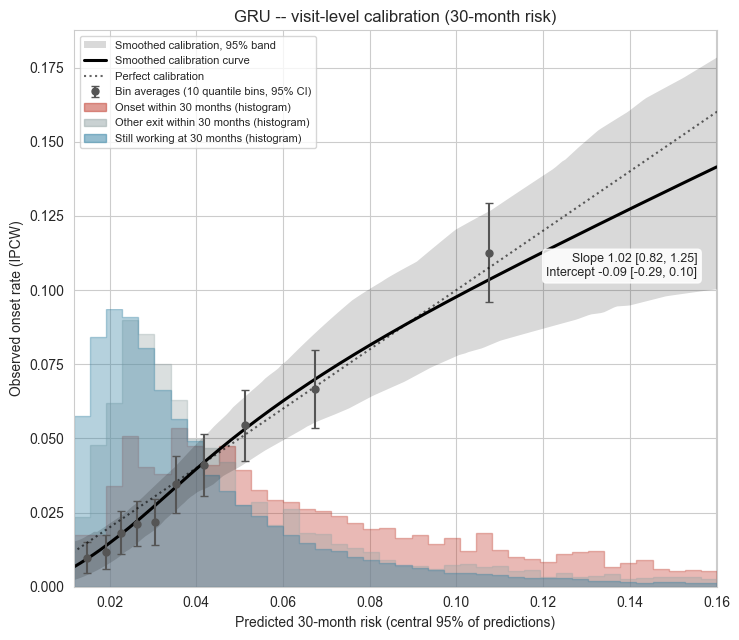

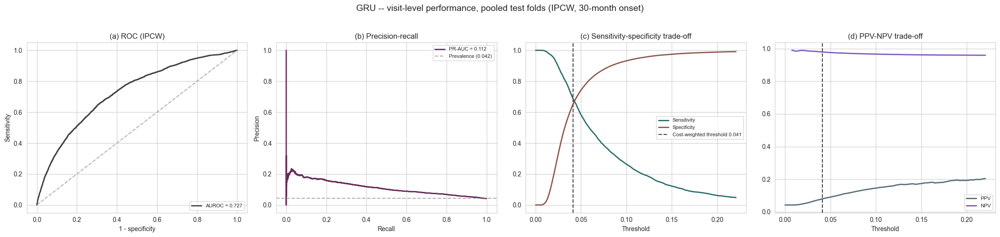

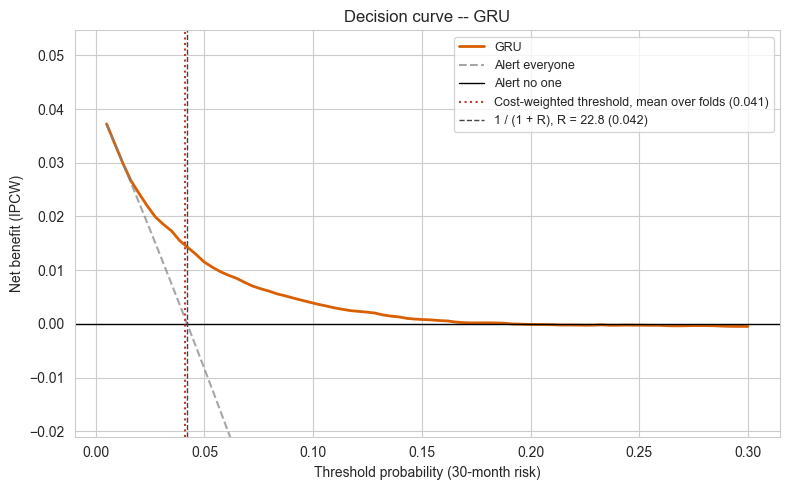

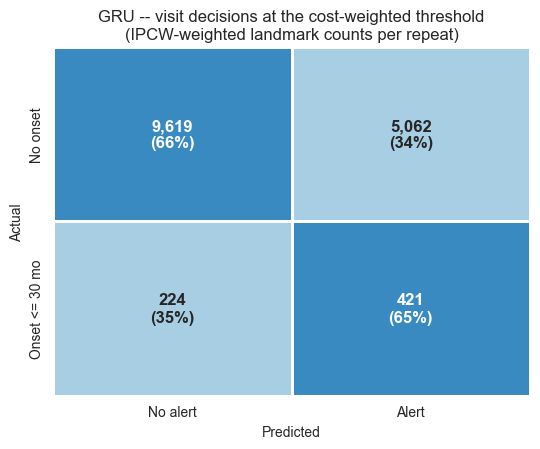

GRU -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 93.6, FN 44.4, TN 474.2, FP 217.8; flagged event patients: the run of alarms was complete a median 12.4 months before onset (81% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
--------------------------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.806 [0.744, 0.865]","0.693 [0.592, 0.794]","0.695 [0.656, 0.736]"
40-49,30,162,"0.843 [0.759, 0.910]","0.760 [0.610, 0.894]","0.663 [0.596, 0.721]"
50-59,42,152,"0.753 [0.667, 0.829]","0.605 [0.478, 0.729]","0.711 [0.644, 0.768]"
>= 60,8,69,"0.731 [0.473, 0.949]","0.650 [0.400, 0.920]","0.638 [0.543, 0.731]"


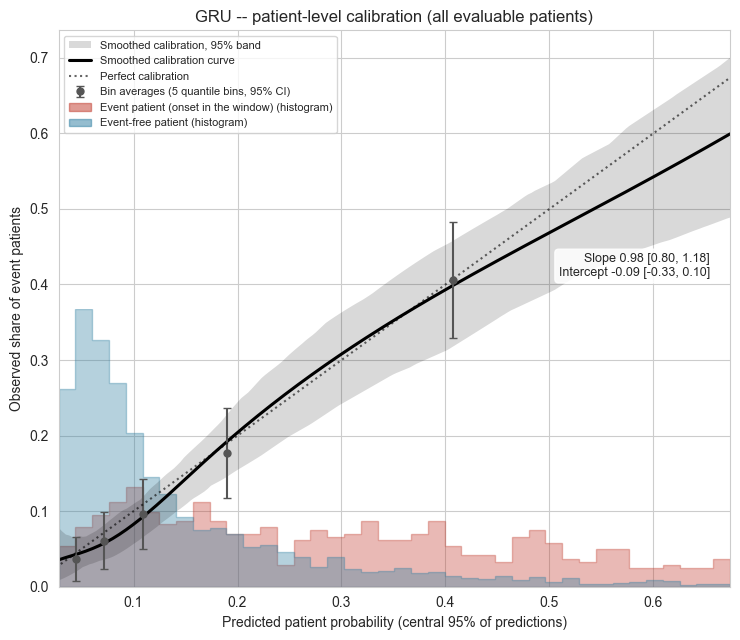

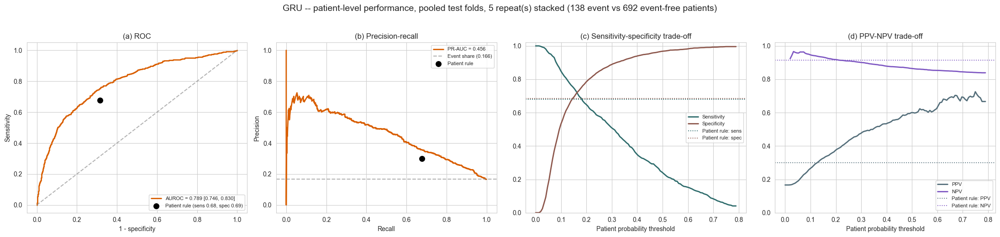

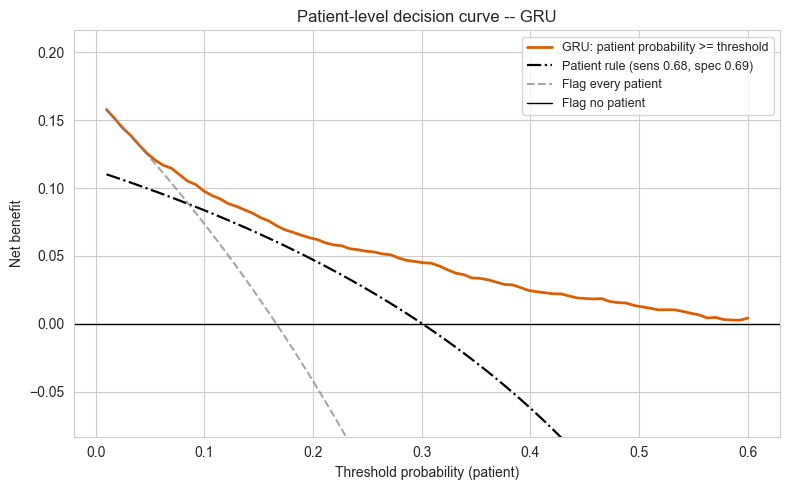

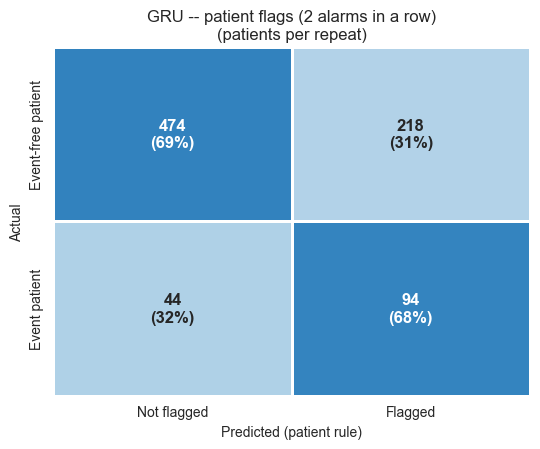


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
GRU,5,22.795 (0.007),0.013 (0.000),0.000 (0.000),0.611 (0.007),0.778 (0.005),0.721 (0.006),0.114 (0.007),35.003 (2.227),0.758 (0.048),0.249 (0.040),0.690 (0.054)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
GRU,5,0.201 (0.029),0.335 (0.043),0.437 (0.053),0.522 (0.043),0.651 (0.025),0.948 (0.005),0.893 (0.007),0.838 (0.009),0.783 (0.012),0.678 (0.017)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
GRU,5,0.037 (0.016),0.280 (0.025),0.477 (0.052),0.604 (0.038),0.788 (0.048),0.993 (0.003),0.904 (0.007),0.806 (0.020),0.704 (0.029),0.462 (0.064),0.812 (0.300),10.110 (0.652),19.996 (2.040),30.185 (2.723),54.177 (6.143)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
GRU,5,0.709 (0.003),0.725 (0.005),0.724 (0.007),0.725 (0.007),0.727 (0.007),0.729 (0.007),0.728 (0.007),0.725 (0.007)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'gruall_h8_d03_wd01': 12, 'gruall_h16_d05_wd03': 8, 'gruall_h16_d05_wd01': 5}
Early stopping, outer-fold fits: median 27 epochs (range 16-60)
  [selection] 1 sequence-model selection(s) trained in 15s
GRU: final refit on all rows (config gruall_h8_d03_wd01, 17 features) in 76s


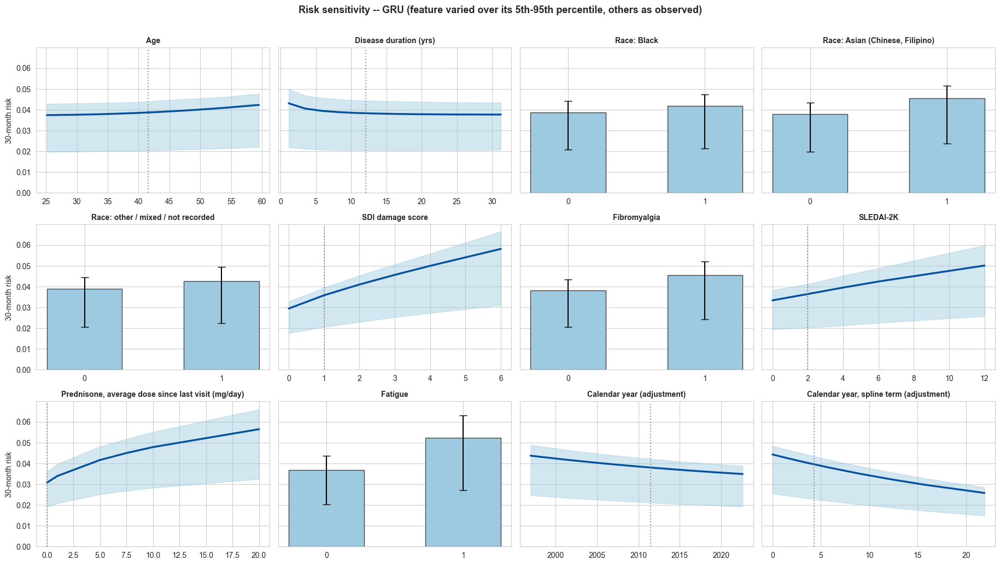


Risk-sensitivity summary -- GRU (mean 30-month risk; ranked by swing)
                                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
                                  SDI damage score      0.0294       0.0581                0.0287
Prednisone, average dose since last visit (mg/day)      0.0307       0.0565                0.0257
           Calendar year, spline term (adjustment)      0.0443       0.0258                0.0185
                                         SLEDAI-2K      0.0334       0.0501                0.0167
                                           Fatigue      0.0367       0.0523                0.0156
                        Calendar year (adjustment)      0.0437       0.0349                0.0088
                   Race: Asian (Chinese, Filipino)      0.0380       0.0454                0.0074
                                      Fibromyalgia      0.0382       0.0454                0.0072
                            Disease duration (y

In [25]:
"""GRU (revised_v27: the LSTMs' recipe -- skip connection, auxiliary heads, cold start, capacity tuned per fold, its
own pool-B choice -- with a GRU cell over the whole history)."""
res_gru = run_analysis("GRU", "GRU")

## 11.10.7b Null LogReg (age, race and education only)

The competing-risk LogReg on **demographics only** — age, race (3 indicators) and education — with no clinical variable
and no calendar-year term, on the same folds, tuning, recalibration and alarm rule as every model. It shows how much
of each model's performance needs no clinical information at all.

Resuming from cv_state_model_revised_v27.pkl: 175 model-fold fits already done.
[LogRegNull ] repeat 1/5 fold 1/5 | AUROC 0.657 NB(R=23.6) 0.0135 | visit sens/spec 0.70/0.51 | patient sens/spec 0.72/0.51 (TN/FP 73/69) | cfg 0.0003 | 5 feats | 32s
[LogRegNull ] repeat 1/5 fold 2/5 | AUROC 0.644 NB(R=22.3) 0.0002 | visit sens/spec 0.08/0.93 | patient sens/spec 0.08/0.93 (TN/FP 129/9) | cfg 0.01 | 5 feats | 32s
[LogRegNull ] repeat 1/5 fold 3/5 | AUROC 0.567 NB(R=23.1) 0.0033 | visit sens/spec 0.52/0.52 | patient sens/spec 0.52/0.56 (TN/FP 78/61) | cfg 0.0003 | 5 feats | 42s
[LogRegNull ] repeat 1/5 fold 4/5 | AUROC 0.532 NB(R=22.9) 0.0025 | visit sens/spec 0.47/0.57 | patient sens/spec 0.41/0.58 (TN/FP 82/60) | cfg 0.0003 | 5 feats | 35s
[LogRegNull ] repeat 1/5 fold 5/5 | AUROC 0.595 NB(R=22.1) 0.0026 | visit sens/spec 0.67/0.49 | patient sens/spec 0.67/0.45 (TN/FP 59/72) | cfg 0.001 | 5 feats | 29s
[LogRegNull ] repeat 2/5 fold 1/5 | AUROC 0.774 NB(R=22.3) 0.0008 | visit sens/spec 0.09

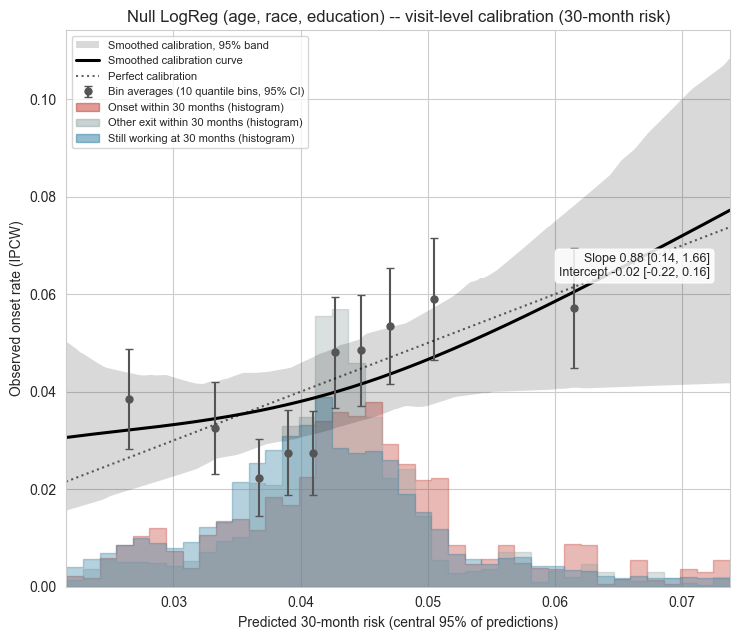

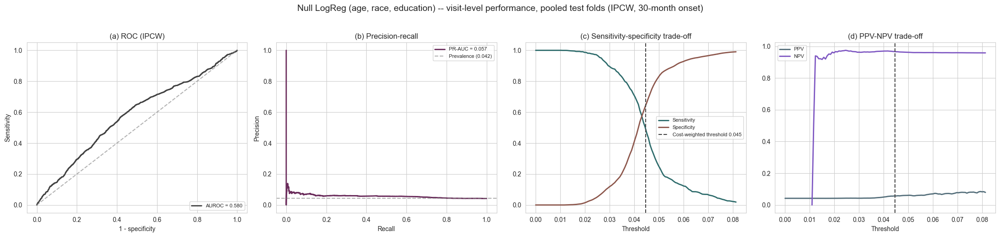

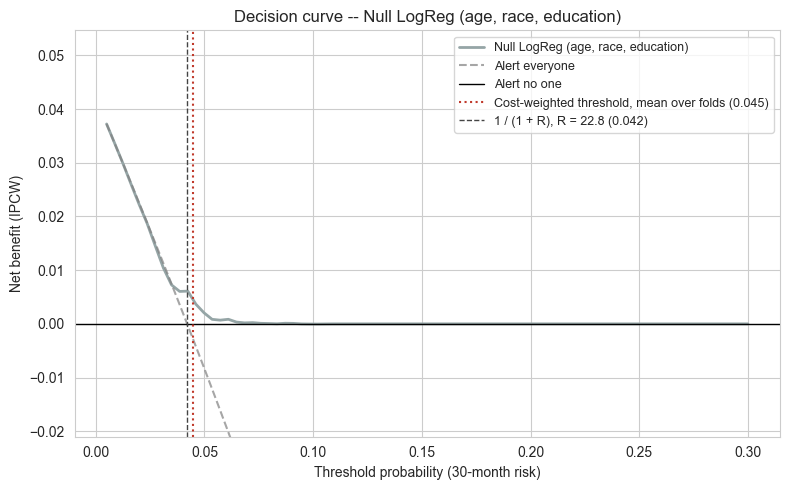

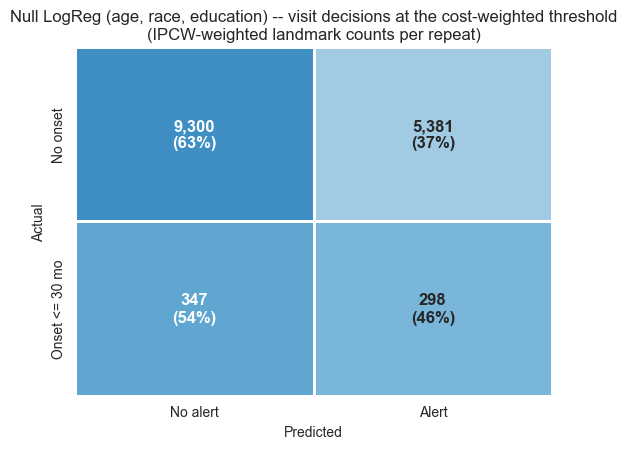

Null LogReg (age, race, education) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 62.2, FN 75.8, TN 425.8, FP 266.2; flagged event patients: the run of alarms was complete a median 15.9 months before onset (99% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 5 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
-------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.566 [0.492, 0.650]","0.307 [0.220, 0.411]","0.723 [0.679, 0.764]"
40-49,30,162,"0.632 [0.530, 0.728]","0.453 [0.300, 0.600]","0.649 [0.583, 0.712]"
50-59,42,152,"0.586 [0.502, 0.677]","0.638 [0.530, 0.744]","0.479 [0.415, 0.541]"
>= 60,8,69,"0.466 [0.282, 0.629]","0.500 [0.178, 0.760]","0.354 [0.262, 0.443]"


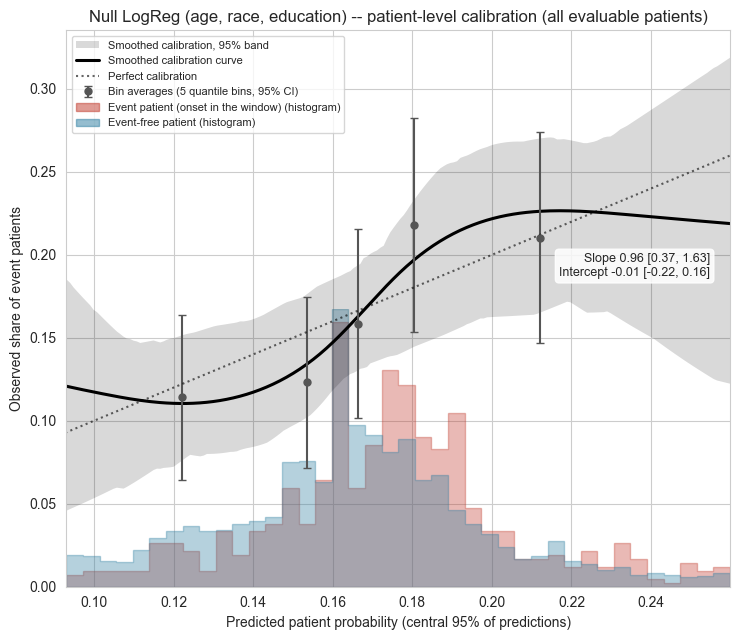

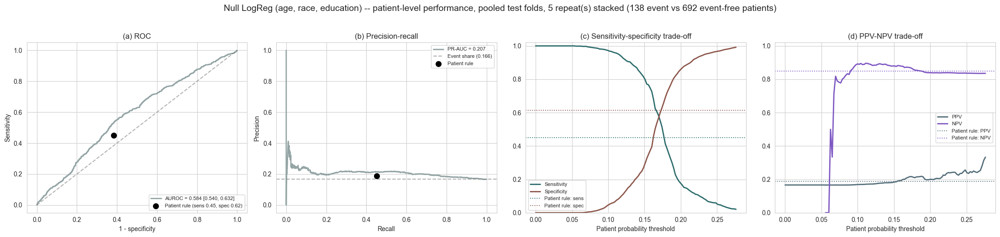

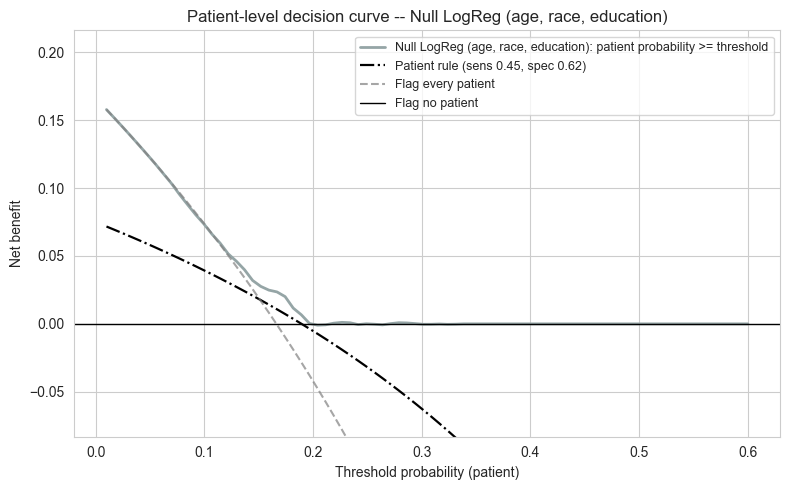

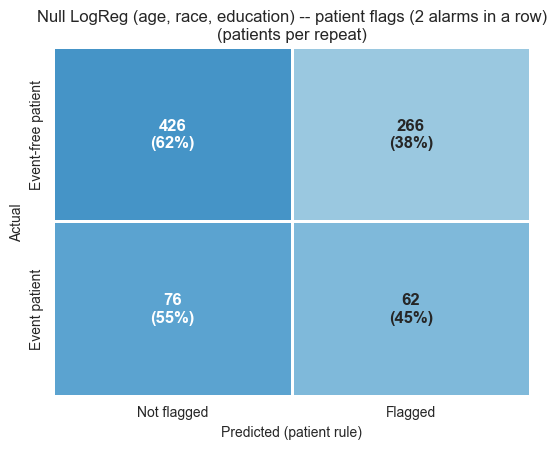


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LogRegNull,5,22.795 (0.007),0.004 (0.002),0.000 (0.000),0.511 (0.004),0.567 (0.006),0.579 (0.010),0.061 (0.005),37.848 (3.728),0.820 (0.081),0.610 (0.037),0.779 (0.056)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LogRegNull,5,0.124 (0.018),0.171 (0.005),0.207 (0.021),0.292 (0.035),0.406 (0.025),0.944 (0.011),0.892 (0.001),0.849 (0.012),0.806 (0.015),0.700 (0.015)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LogRegNull,5,0.005 (0.011),0.046 (0.023),0.135 (0.040),0.359 (0.046),0.831 (0.061),0.998 (0.005),0.971 (0.014),0.920 (0.031),0.709 (0.059),0.200 (0.041),0.315 (0.703),3.409 (1.535),9.029 (3.099),30.238 (5.884),79.538 (3.987)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LogRegNull,5,0.556 (0.010),0.558 (0.021),0.571 (0.010),0.572 (0.009),0.581 (0.010),0.585 (0.011),0.590 (0.012),0.596 (0.012)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {0.0003: 11, 0.001: 6, 0.1: 3, 0.01: 2, 0.03: 2, 1.0: 1}
LogRegNull: final refit on all rows (config 0.0003, 5 features) in 4s


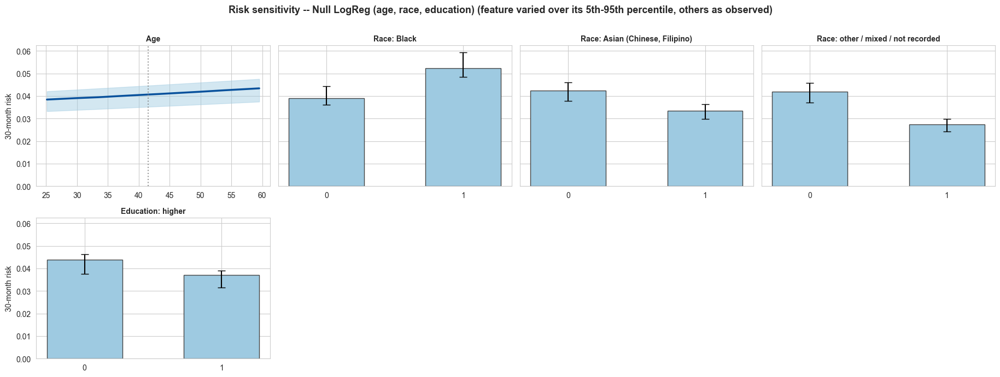


Risk-sensitivity summary -- Null LogReg (age, race, education) (mean 30-month risk; ranked by swing)
                           Feature  Risk @ low  Risk @ high  Risk swing (max-min)
Race: other / mixed / not recorded      0.0419       0.0273                0.0145
                       Race: Black      0.0390       0.0523                0.0134
   Race: Asian (Chinese, Filipino)      0.0424       0.0334                0.0090
                 Education: higher      0.0438       0.0370                0.0068
                               Age      0.0384       0.0434                0.0050


In [26]:
"""Null LogReg (revised_v27): the competing-risk LogReg (pooled multinomial, L2 tuned per fold on the cross-fitted
AUROC) on NULL_COLS = age, race, education; no clinical variable, no calendar year."""
res_logreg_null = run_analysis("LogRegNull", "Null LogReg (age, race, education)")

## 11.10.7c Ablations of the main model: time decay and fairness penalty

Two copies of T-LSTM-8 that each differ from it in one thing, on the same folds (the first `ABLATION_REPEATS` CV
repeats) and with the main model's own pool-B choice:

* **LSTM-8 (no time decay)** — an ordinary LSTM cell. The visit gap still enters as $\log(1 + \Delta)$; only the
  T-LSTM's discount of the short-term memory is removed. T-LSTM-8 − LSTM-8 is what the time decay adds (Section 11.12.2).
* **T-LSTM-8 (no fairness penalty)** — $\lambda = 0$. T-LSTM-8 − this model is what the penalty costs or gains, overall
  (Section 11.12.2) and in the race gaps (Section 11.11.10b).

Resuming from cv_state_model_revised_v27.pkl: 200 model-fold fits already done.
[LSTM_plain ] repeat 1/5 fold 1/5 | AUROC 0.718 NB(R=23.6) 0.0147 | visit sens/spec 0.78/0.45 | patient sens/spec 0.76/0.42 (TN/FP 59/83) | cfg plain8_h16_d05_wd01 | 17 feats | 131s
[LSTM_plain ] repeat 1/5 fold 2/5 | AUROC 0.751 NB(R=22.3) 0.0094 | visit sens/spec 0.62/0.66 | patient sens/spec 0.65/0.70 (TN/FP 96/42) | cfg plain8_h8_d03_wd01 | 17 feats | 108s
[LSTM_plain ] repeat 1/5 fold 3/5 | AUROC 0.727 NB(R=23.1) 0.0143 | visit sens/spec 0.66/0.64 | patient sens/spec 0.74/0.64 (TN/FP 89/50) | cfg plain8_h8_d03_wd01 | 17 feats | 113s
[LSTM_plain ] repeat 1/5 fold 4/5 | AUROC 0.720 NB(R=22.9) 0.0122 | visit sens/spec 0.65/0.63 | patient sens/spec 0.69/0.65 (TN/FP 92/50) | cfg plain8_h8_d03_wd01 | 17 feats | 115s
[LSTM_plain ] repeat 1/5 fold 5/5 | AUROC 0.743 NB(R=22.1) 0.0123 | visit sens/spec 0.67/0.71 | patient sens/spec 0.70/0.73 (TN/FP 96/35) | cfg plain8_h8_d03_wd01 | 17 feats | 79s
[LSTM_plain ] r

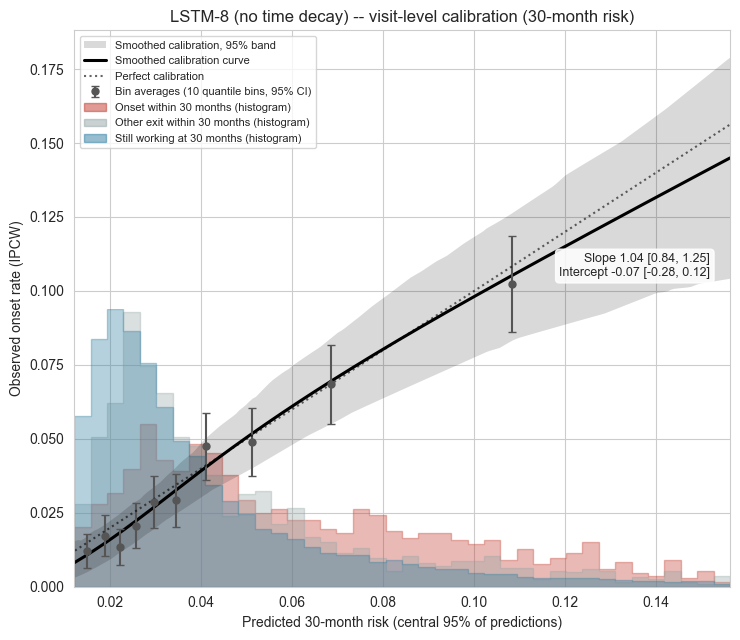

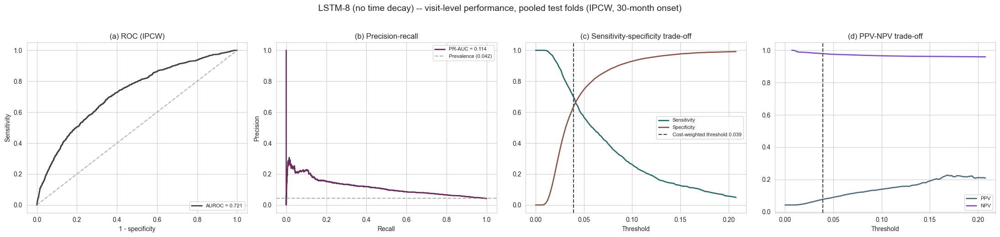

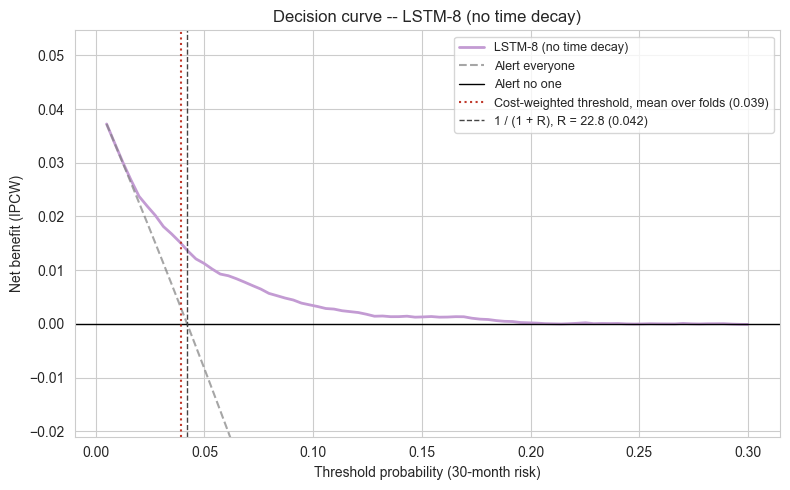

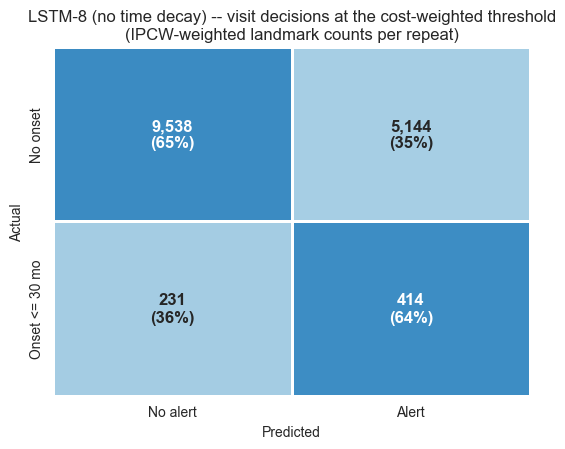

LSTM-8 (no time decay) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 94.0, FN 44.0, TN 451.0, FP 241.0; flagged event patients: the run of alarms was complete a median 12.4 months before onset (83% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 2 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
-------------------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.806 [0.752, 0.864]","0.698 [0.600, 0.804]","0.672 [0.627, 0.722]"
40-49,30,162,"0.838 [0.753, 0.906]","0.750 [0.590, 0.893]","0.614 [0.543, 0.681]"
50-59,42,152,"0.748 [0.663, 0.822]","0.607 [0.470, 0.744]","0.681 [0.614, 0.747]"
>= 60,8,69,"0.699 [0.453, 0.941]","0.688 [0.375, 1.000]","0.587 [0.485, 0.691]"


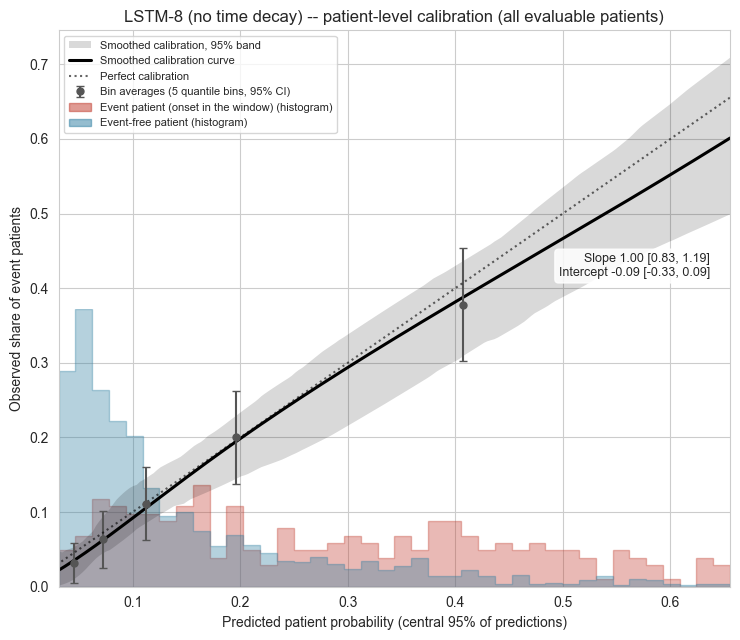

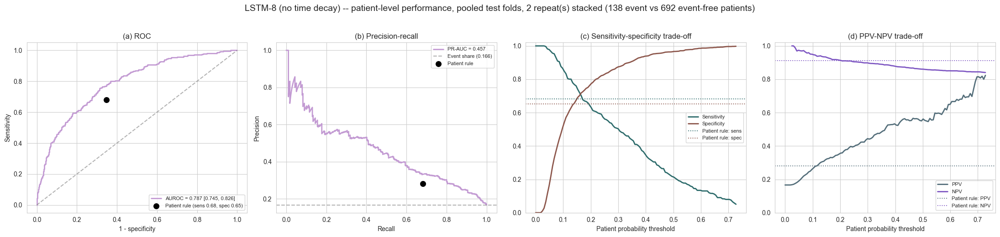

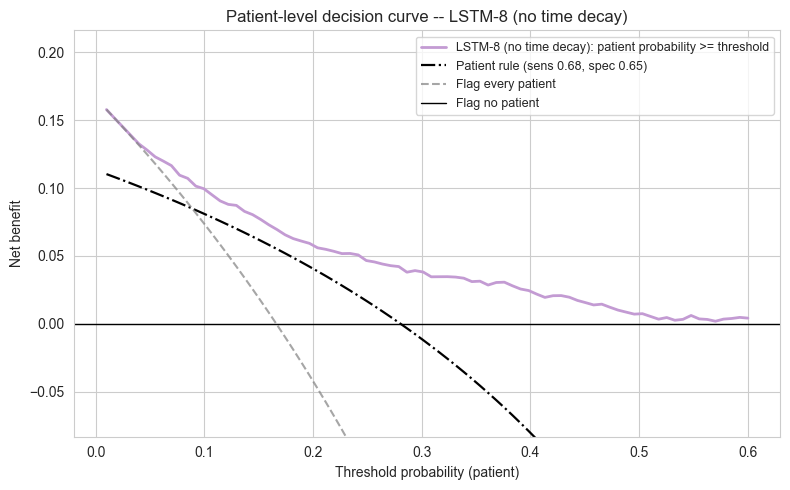

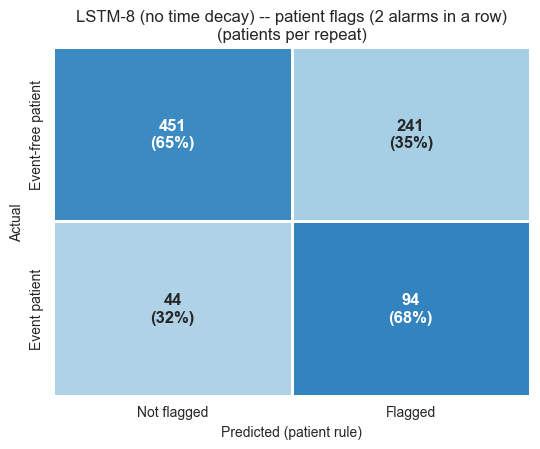


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM_plain,2,22.797 (0.002),0.012 (0.000),0.000 (0.000),0.606 (0.002),0.776 (0.008),0.718 (0.007),0.115 (0.011),35.950 (4.146),0.779 (0.090),0.229 (0.040),0.713 (0.086)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM_plain,2,0.191 (0.047),0.320 (0.060),0.431 (0.036),0.512 (0.063),0.621 (0.044),0.947 (0.004),0.892 (0.009),0.837 (0.008),0.781 (0.015),0.678 (0.027)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM_plain,2,0.029 (0.002),0.301 (0.018),0.469 (0.034),0.592 (0.039),0.759 (0.094),0.992 (0.000),0.896 (0.003),0.803 (0.009),0.705 (0.011),0.492 (0.150),0.849 (0.000),11.035 (0.097),20.459 (0.885),30.532 (0.915),51.549 (14.506)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM_plain,2,0.716 (0.003),0.726 (0.002),0.721 (0.005),0.719 (0.008),0.722 (0.008),0.724 (0.008),0.721 (0.008),0.717 (0.006)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'plain8_h8_d03_wd01': 7, 'plain8_h16_d05_wd01': 2, 'plain8_h16_d05_wd03': 1}
Early stopping, outer-fold fits: median 28 epochs (range 17-59)
Resuming from cv_state_model_revised_v27.pkl: 210 model-fold fits already done.
[LSTM_nofair] repeat 1/5 fold 1/5 | AUROC 0.726 NB(R=23.6) 0.0176 | visit sens/spec 0.65/0.67 | patient sens/spec 0.62/0.62 (TN/FP 88/54) | cfg nofair8_h16_d05_wd01 | 17 feats | 90s
[LSTM_nofair] repeat 1/5 fold 2/5 | AUROC 0.771 NB(R=22.3) 0.0109 | visit sens/spec 0.49/0.82 | patient sens/spec 0.42/0.83 (TN/FP 115/23) | cfg nofair8_h16_d05_wd03 | 17 feats | 102s
[LSTM_nofair] repeat 1/5 fold 3/5 | AUROC 0.715 NB(R=23.1) 0.0100 | visit sens/spec 0.40/0.82 | patient sens/spec 0.52/0.82 (TN/FP 114/25) | cfg nofair8_h16_d05_wd03 | 17 feats | 79s
[LSTM_nofair] repeat 1/5 fold 4/5 | AUROC 0.719 NB(R=22.9) 0.0109 | visit sens/spec 0.39/0.86 | patient sens/spec 0.38/0.89 (TN/FP 126/16) | cfg nofair8_h8_d03_

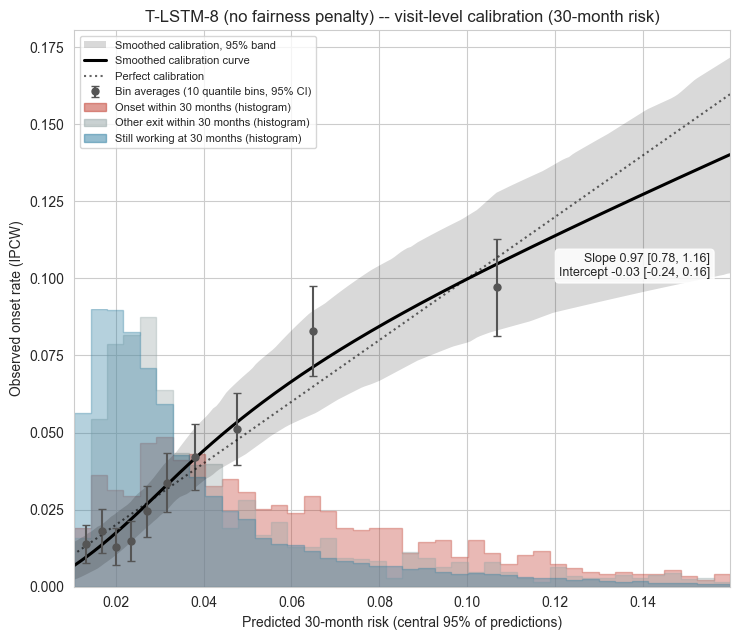

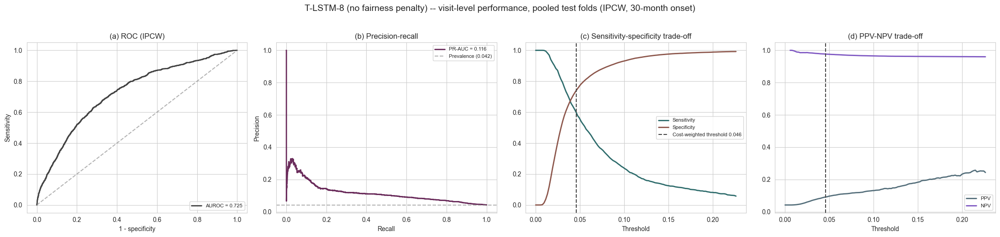

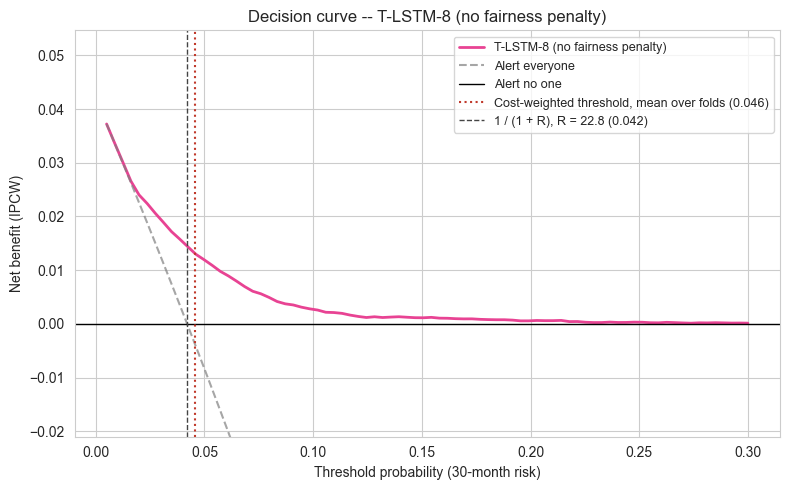

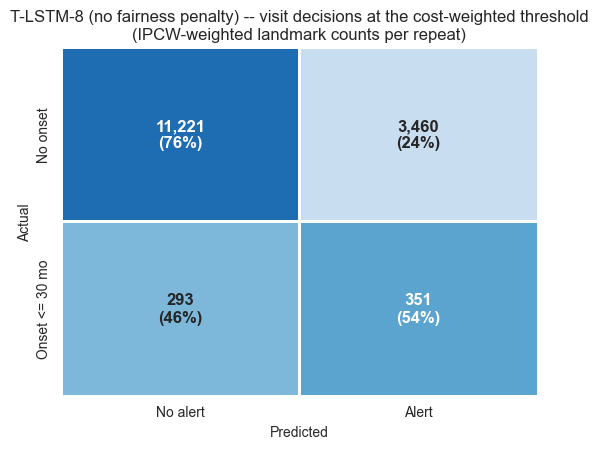

T-LSTM-8 (no fairness penalty) -- PATIENT LEVEL, all evaluable patients
  138 event patients (TP / FN: 2 alarms in a row in the window (24 months before onset)) vs 692 event-free patients (FP / TN: 2 alarms in a row in the window (their last 24 months with a known 30-month outcome)): Employed at final visit 597, Other final status 78, Retired / homemaker >= 60 17
  mean counts per repeat: TP 76.5, FN 61.5, TN 541.0, FP 151.0; flagged event patients: the run of alarms was complete a median 11.9 months before onset (76% alarmed at every landmark of their window)
  patient probability = the visit risk at the highest-risk landmark of the window, recalibrated on the training patients in each fold; alarms use the visit threshold
  mean over 2 CV repeat(s); 95% CI: 1000 patient bootstrap resamples
------------------------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO
-----------------------------------------

,Event patients,Event-free patients,Concordance Index,Sensitivity,Specificity
Age at end of window,,,,,
< 40,58,309,"0.801 [0.744, 0.862]","0.552 [0.436, 0.676]","0.782 [0.741, 0.823]"
40-49,30,162,"0.858 [0.781, 0.921]","0.683 [0.521, 0.829]","0.790 [0.728, 0.848]"
50-59,42,152,"0.745 [0.666, 0.816]","0.476 [0.338, 0.612]","0.783 [0.720, 0.837]"
>= 60,8,69,"0.714 [0.471, 0.940]","0.500 [0.181, 0.833]","0.761 [0.669, 0.842]"


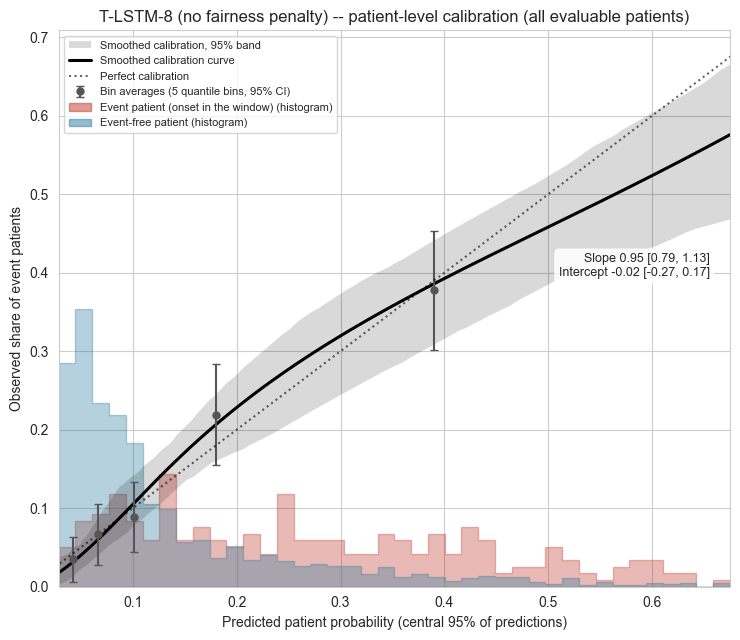

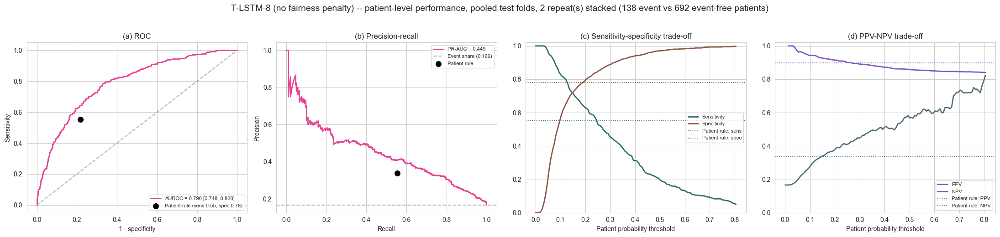

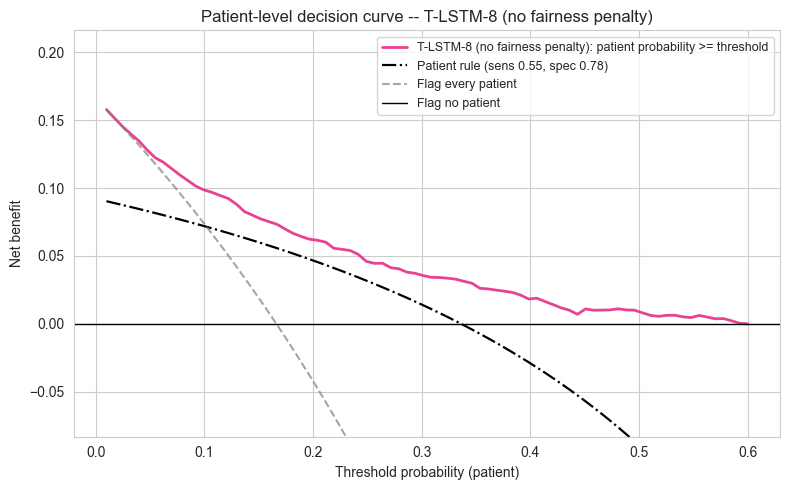

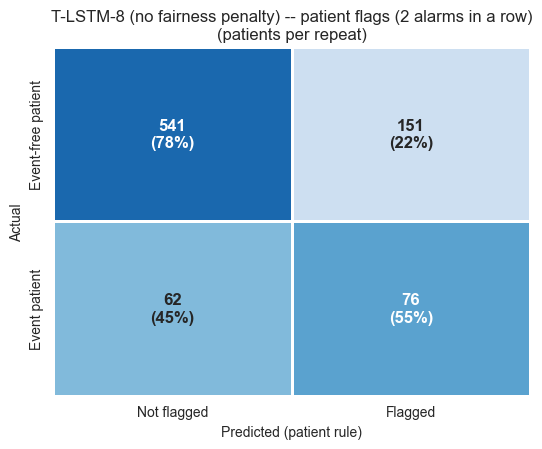


Supplementary visit-level results, mean (SD) over repeats:


,Repeats,Cost ratio R (mean over folds),Net benefit at R,"Net benefit, alarm at every visit",pAUROC (sens>=80%),AUROC (patient-weighted),"Uno C (30 mo, cause-specific)",PR-AUC,Alerts / 100 visits,Alerts / patient-year,Stayed employed: never alerted,Stayed employed: alerts / patient-year
Model,,,,,,,,,,,,
LSTM_nofair,2,22.797 (0.002),0.013 (0.000),0.000 (0.000),0.608 (0.006),0.774 (0.007),0.722 (0.007),0.117 (0.015),24.070 (4.599),0.521 (0.100),0.396 (0.054),0.450 (0.102)


Visit sensitivity / specificity vs alert budget (share of landmark visits flagged):


,Repeats,sens@5%,sens@10%,sens@15%,sens@20%,sens@30%,spec@5%,spec@10%,spec@15%,spec@20%,spec@30%
Model,,,,,,,,,,,
LSTM_nofair,2,0.169 (0.029),0.311 (0.045),0.416 (0.054),0.502 (0.048),0.610 (0.049),0.951 (0.001),0.896 (0.010),0.842 (0.016),0.797 (0.022),0.711 (0.036)


Visit sensitivity / specificity / alerts per 100 visits by cost ratio R (a missed onset = R false alarms; main analysis: R = (1 - onset rate) / onset rate of each training fold):


,Repeats,sens@R5,sens@R10,sens@R15,sens@R20,sens@R30,spec@R5,spec@R10,spec@R15,spec@R20,spec@R30,alerts@R5,alerts@R10,alerts@R15,alerts@R20,alerts@R30
Model,,,,,,,,,,,,,,,,
LSTM_nofair,2,0.061 (0.003),0.316 (0.056),0.402 (0.029),0.506 (0.027),0.722 (0.019),0.988 (0.003),0.890 (0.021),0.848 (0.010),0.785 (0.030),0.548 (0.043),1.320 (0.256),11.427 (2.262),15.637 (1.024),21.927 (2.937),45.757 (4.268)


Time-dependent AUROC by horizon (months):


,Repeats,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
Model,,,,,,,,,
LSTM_nofair,2,0.715 (0.008),0.725 (0.005),0.722 (0.008),0.721 (0.008),0.725 (0.008),0.728 (0.007),0.726 (0.008),0.722 (0.008)


Configuration chosen per fold (visit-level cross-fitted IPCW AUROC): {'nofair8_h8_d03_wd01': 6, 'nofair8_h16_d05_wd01': 2, 'nofair8_h16_d05_wd03': 2}
Early stopping, outer-fold fits: median 21 epochs (range 16-34)


In [27]:
"""Ablations of T-LSTM-8 (revised_v27): LSTM_plain (ordinary LSTM cell) and LSTM_nofair (no fairness penalty); the
visit- and patient-level tables and figures only (no final refit)."""
res_lstm_plain = report_cv_model("LSTM_plain", MODEL_LABELS["LSTM_plain"])
res_lstm_nofair = report_cv_model("LSTM_nofair", MODEL_LABELS["LSTM_nofair"])

## 11.10.8 Visit-level summary — all models

Every metric of the per-model visit tables, value [95 % patient-bootstrap CI], with LaTeX rows for the manuscript.

In [28]:
"""
Visit-level summary for all models: every metric of the per-model tables, value [95% patient-bootstrap CI], one row per
model, with LaTeX rows for the manuscript. The per-repeat metrics go to cv_model_revised_v27_pooled_metrics_by_repeat.csv.
"""
MODEL_RESULTS = {m: model_res(m) for m in CV_MODELS if model_res(m) is not None}   # every model that has run
res_all = pd.concat([r["res_df"] for r in MODEL_RESULTS.values()], ignore_index=True)
preds_all = {k: v for r in MODEL_RESULTS.values() for k, v in r["preds"].items()}
res_all.to_csv("cv_model_revised_v27_pooled_metrics_by_repeat.csv", index=False)


def wide_table(key):
    """One row per model: 'value [CI low, CI high]' for every metric of table `key`."""
    cell = lambda row: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                        if np.isfinite(row["Value"]) else "n/a")
    return pd.DataFrame({m: {row["Metric"]: cell(row) for _, row in r[key].iterrows()}
                         for m, r in MODEL_RESULTS.items()}).T


def latex_table_rows(key):
    return [f"{m:<11} & " + " & ".join(f"{row['Value']:.3f} ({row['CI low']:.3f}--{row['CI high']:.3f})"
                                       if np.isfinite(row["Value"]) else "n/a"
                                       for _, row in r[key].iterrows()) + " \\\\"
            for m, r in MODEL_RESULTS.items()]


visit_summary = wide_table("visit_table")
print("VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test "
      "folds; 30-month onset, IPCW; alarms at each fold's visit threshold")
display(visit_summary)
print("\nLaTeX rows (" + " & ".join(visit_summary.columns) + "):")
print("\n".join(latex_table_rows("visit_table")))

VISIT LEVEL -- all models: value [95% patient-cluster bootstrap CI]; mean over CV repeats of the pooled test folds; 30-month onset, IPCW; alarms at each fold's visit threshold


,Concordance Index,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy
LSTM,"0.730 [0.683, 0.775]","1.066 [0.858, 1.294]","-0.097 [-0.309, 0.087]","0.915 [0.751, 1.083]","0.702 [0.635, 0.773]","0.617 [0.589, 0.645]","0.075 [0.059, 0.090]","0.979 [0.973, 0.985]","0.659 [0.623, 0.697]"
LSTM_w16,"0.727 [0.682, 0.773]","1.103 [0.878, 1.345]","-0.080 [-0.287, 0.101]","0.928 [0.764, 1.098]","0.652 [0.584, 0.721]","0.656 [0.629, 0.683]","0.077 [0.061, 0.093]","0.977 [0.971, 0.983]","0.654 [0.617, 0.692]"
LSTM_w4,"0.728 [0.681, 0.774]","1.089 [0.870, 1.322]","-0.088 [-0.295, 0.096]","0.923 [0.759, 1.092]","0.685 [0.615, 0.756]","0.634 [0.606, 0.662]","0.076 [0.060, 0.092]","0.979 [0.973, 0.985]","0.660 [0.622, 0.699]"
LSTM1,"0.729 [0.683, 0.774]","1.085 [0.869, 1.309]","-0.079 [-0.288, 0.107]","0.930 [0.765, 1.104]","0.704 [0.641, 0.772]","0.596 [0.565, 0.625]","0.071 [0.056, 0.086]","0.979 [0.973, 0.985]","0.650 [0.615, 0.687]"
LogReg,"0.719 [0.675, 0.763]","0.918 [0.727, 1.122]","-0.015 [-0.228, 0.174]","0.986 [0.811, 1.172]","0.583 [0.516, 0.659]","0.694 [0.666, 0.720]","0.077 [0.061, 0.096]","0.974 [0.968, 0.981]","0.639 [0.603, 0.678]"
GRU,"0.727 [0.681, 0.774]","1.025 [0.820, 1.252]","-0.087 [-0.293, 0.102]","0.923 [0.763, 1.098]","0.653 [0.580, 0.727]","0.655 [0.626, 0.683]","0.077 [0.061, 0.093]","0.977 [0.971, 0.984]","0.654 [0.616, 0.693]"
LogRegNull,"0.581 [0.522, 0.635]","0.879 [0.138, 1.659]","-0.015 [-0.220, 0.158]","0.985 [0.810, 1.162]","0.462 [0.382, 0.540]","0.633 [0.595, 0.671]","0.052 [0.040, 0.065]","0.964 [0.955, 0.972]","0.548 [0.505, 0.586]"
LSTM_plain,"0.722 [0.673, 0.769]","1.040 [0.838, 1.253]","-0.068 [-0.281, 0.115]","0.940 [0.770, 1.113]","0.642 [0.573, 0.717]","0.650 [0.623, 0.677]","0.075 [0.059, 0.091]","0.976 [0.970, 0.983]","0.646 [0.609, 0.686]"
LSTM_nofair,"0.725 [0.677, 0.773]","0.966 [0.779, 1.159]","-0.027 [-0.238, 0.162]","0.976 [0.803, 1.159]","0.545 [0.470, 0.628]","0.764 [0.740, 0.787]","0.093 [0.073, 0.115]","0.975 [0.968, 0.981]","0.655 [0.618, 0.695]"



LaTeX rows (Concordance Index & Calibration Slope & Calibration Intercept & Observed / Expected & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy):
LSTM        & 0.730 (0.683--0.775) & 1.066 (0.858--1.294) & -0.097 (-0.309--0.087) & 0.915 (0.751--1.083) & 0.702 (0.635--0.773) & 0.617 (0.589--0.645) & 0.075 (0.059--0.090) & 0.979 (0.973--0.985) & 0.659 (0.623--0.697) \\
LSTM_w16    & 0.727 (0.682--0.773) & 1.103 (0.878--1.345) & -0.080 (-0.287--0.101) & 0.928 (0.764--1.098) & 0.652 (0.584--0.721) & 0.656 (0.629--0.683) & 0.077 (0.061--0.093) & 0.977 (0.971--0.983) & 0.654 (0.617--0.692) \\
LSTM_w4     & 0.728 (0.681--0.774) & 1.089 (0.870--1.322) & -0.088 (-0.295--0.096) & 0.923 (0.759--1.092) & 0.685 (0.615--0.756) & 0.634 (0.606--0.662) & 0.076 (0.060--0.092) & 0.979 (0.973--0.985) & 0.660 (0.622--0.699) \\
LSTM1       & 0.729 (0.683--0.774) & 1.085 (0.869--1.309) & -0.079 (-0.288--0.107) & 0.930 (0.765--1.104) & 0.704 (0.641--0.772) & 0.596 (0.565--0.625) & 0.071 (0.056--0

## 11.10.9 Variables chosen from pool B

How often each pool-B variable was chosen in the 25 outer training folds, by model (forward selection on the
cross-validated deviance: LogReg; the permutation importance of its own network: each sequence model), the number
chosen per fold, and the choice on all rows (the final refits, SHAP and the nomogram).

In [29]:
"""Variables chosen from pool B (Section 5.2): selection frequency over the outer training folds, by method."""
_sel_rows, _n_rows = {}, {}
for mt in sorted(set(SELECTION_METHOD_OF.values())):
    rep_model = next((m for m in CV_MODELS if SELECTION_METHOD_OF.get(m) == mt and model_res(m) is not None), None)
    if rep_model is None:
        continue
    fl = [v["features"] for k, v in cv_state["folds"].items() if k[0] == rep_model]
    extra = [[c for c in f if c in POOL_B] for f in fl]
    _n_rows[mt] = pd.Series([len(e) for e in extra]).describe()[["mean", "min", "max"]]
    _sel_rows[mt] = pd.Series([c for e in extra for c in e]).value_counts() / max(1, len(fl))
    _sel_rows[f"{mt}, all rows"] = pd.Series({c: 1.0 for c in pool_b_selection(mt, ALL_ROWS, ALL_ROWS)},
                                          dtype=float)
if _sel_rows:
    sel_freq_tab = pd.DataFrame(_sel_rows).fillna(0).rename(index=lambda c: DISPLAY_NAMES.get(c, c))
    sel_freq_tab = sel_freq_tab.sort_values(list(sel_freq_tab.columns[:1]), ascending=False)
    print("Share of outer training folds in which each pool-B variable was chosen (method columns), and the choice on "
          "all rows (1 = chosen):")
    display(sel_freq_tab.round(2))
    print("Pool-B variables chosen per fold (core = " + str(N_MODEL_VARIABLES) + " variables, cap = " + str(SELECT_MAX_EXTRA) + "):")
    display(pd.DataFrame(_n_rows).round(1))
    sel_freq_tab.to_csv("pool_b_selection_frequency_revised_v27.csv")

Share of outer training folds in which each pool-B variable was chosen (method columns), and the choice on all rows (1 = chosen):


,forward,"forward, all rows",seq:GRU,"seq:GRU, all rows",seq:LSTM,"seq:LSTM, all rows",seq:LSTM1,"seq:LSTM1, all rows",seq:LSTM_w16,"seq:LSTM_w16, all rows",seq:LSTM_w4,"seq:LSTM_w4, all rows"
First clinic visit,0.68,1.0,0.20,0.0,0.28,0.0,0.44,1.0,0.28,0.0,0.28,0.0
Dyspnoea,0.44,1.0,0.40,1.0,0.44,0.0,0.40,0.0,0.40,0.0,0.48,0.0
SLEDAI: increased anti-dsDNA,0.36,1.0,0.12,0.0,0.12,0.0,0.08,0.0,0.12,0.0,0.04,0.0
Clinical SLEDAI-2K (no serology),0.36,0.0,0.04,0.0,0.32,0.0,0.36,0.0,0.32,0.0,0.36,0.0
"Symptom count, mean of last 12 mo",0.32,0.0,0.28,0.0,0.36,0.0,0.52,0.0,0.36,0.0,0.40,0.0
SDI skin damage,0.28,1.0,0.04,0.0,0.00,0.0,0.04,0.0,0.00,0.0,0.00,0.0
"Clinic visits per year, last 12 mo",0.24,0.0,0.12,0.0,0.12,1.0,0.16,1.0,0.12,1.0,0.12,1.0
Azathioprine,0.24,0.0,0.08,0.0,0.08,0.0,0.12,0.0,0.08,0.0,0.08,0.0
Symptom count (7 symptoms),0.20,0.0,0.40,0.0,0.00,0.0,0.04,0.0,0.00,0.0,0.00,0.0
Current smoker,0.20,1.0,0.20,0.0,0.24,0.0,0.24,0.0,0.28,0.0,0.28,0.0


Pool-B variables chosen per fold (core = 10 variables, cap = 5):


,forward,seq:GRU,seq:LSTM,seq:LSTM1,seq:LSTM_w16,seq:LSTM_w4
mean,5.0,5.0,5.0,5.0,5.0,5.0
min,5.0,5.0,5.0,5.0,5.0,5.0
max,5.0,5.0,5.0,5.0,5.0,5.0


---
# 11.11 Objective 1 — Predict who will stop working because of lupus

Estimate each working patient's risk of work disability within 30 months at every routine clinic visit, and check
that the risk is accurate enough to act on: it separates the patients who go on to disability from those who stay at
work, the predicted risks match what happened, and the alarms come early enough to intervene. The main model is
T-LSTM-8 (Section 6.1); every other model is shown alongside.

| | Hypothesis | Comparison / estimand | Success criterion |
|---|---|---|---|
| **H1a** | The risk separates patients who go on to disability from those who stay at work | T-LSTM-8 − Baseline (index-visit age, SDI and SLEDAI-2K; age, education, race, calendar year), five metrics, visit and patient level | Lower 95 % bound > 0 (per metric) |
| **H1b** | The predicted risks match what happened | Calibration slope and intercept of the 30-month risk | Slope in [0.8, 1.2]; intercept 95 % CI includes 0 |
| **H1c** | Alarms come early enough to intervene | Median lead time from the patient flag (2 alarms in a row) to the onset, flagged event patients | Lower 95 % bound ≥ 6 months |
| **H1d** | Acting on the alarms does more good than harm | Net benefit vs alarming at every visit and at none | Above both at every threshold from 2 % to 10 % |

Descriptive: risk tiers (< 2 %, 2–5 %, 5–10 %, ≥ 10 %) with observed risk, the alarm rule's utility, alarms by
calendar era, **calibration and discrimination by calendar era** (Section 11.11.8), the patient-level tables and
calibration, and performance by sex, race, age and era.

## 11.11.1 H1a: does the risk separate the patients who go on to disability?

T-LSTM-8 against the Baseline (the index-visit age, SDI and SLEDAI-2K, current age, education, race and calendar
year in the same discrete-time hazard model; revised_v27) on identical folds: the five metrics of each with 95 % CIs, then the oriented paired difference on every
metric, at the visit level (30-month onset, IPCW, every landmark visit) and the patient level (24-month windows,
2 alarms in a row; Section 9.2).


VISIT LEVEL -- value [95% patient-cluster bootstrap CI], mean over CV repeats:


,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy
T-LSTM-8 (main),"0.730 [0.679, 0.773]","0.732 [0.683, 0.774]","0.702 [0.628, 0.767]","0.617 [0.586, 0.644]","0.659 [0.621, 0.694]"
Baseline,"0.639 [0.579, 0.691]","0.651 [0.595, 0.701]","0.442 [0.349, 0.523]","0.674 [0.645, 0.702]","0.558 [0.515, 0.598]"



PATIENT LEVEL -- value [95% patient-cluster bootstrap CI], mean over CV repeats:


,AUROC,Sensitivity,Specificity,Balanced accuracy
T-LSTM-8 (main),"0.787 [0.745, 0.828]","0.722 [0.664, 0.783]","0.638 [0.606, 0.666]","0.680 [0.646, 0.715]"
Baseline,"0.757 [0.712, 0.798]","0.499 [0.423, 0.574]","0.670 [0.640, 0.699]","0.584 [0.546, 0.621]"



H1a -- T-LSTM-8 minus the Baseline on every metric (oriented: > 0 favours T-LSTM-8); * = lower bound > 0:


Metric                                           AUROC  \
Comparison          Level                                
T-LSTM-8 - Baseline visit    +0.090 [+0.046, +0.135] *   
                    patient    +0.030 [-0.003, +0.067]   

Metric                                         C-index  \
Comparison          Level                                
T-LSTM-8 - Baseline visit    +0.081 [+0.040, +0.124] *   
                    patient                        NaN   

Metric                                     Sensitivity  \
Comparison          Level                                
T-LSTM-8 - Baseline visit    +0.260 [+0.185, +0.341] *   
                    patient  +0.223 [+0.156, +0.295] *   

Metric                                   Specificity  \
Comparison          Level                              
T-LSTM-8 - Baseline visit    -0.057 [-0.091, -0.023]   
                    patient  -0.032 [-0.068, +0.001]   

Metric                               Balanced accuracy Lower bound > 0 on  
Comparison          Level                                                  
T-LSTM-8 - Baseline visit    +0.101 [+0.061, +0.141] *     4 of 5 metrics  
                    patient  +0.095 [+0.059, +0.136] *     2 of 4 metrics

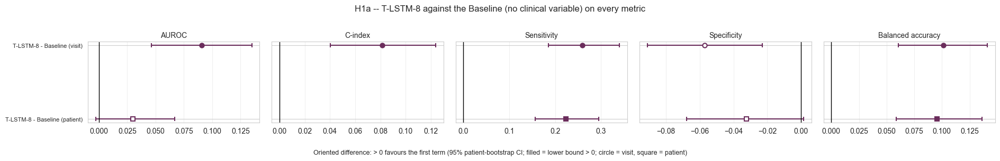

In [30]:
"""
Objective 1, H1a (Section 8.1): T-LSTM-8 against the Baseline without clinical variables (H1A_REFERENCE) on all six
metrics, visit and patient level, oriented paired differences on the same patient-bootstrap resamples; criterion per
metric: lower 95% bound > 0. Printed first: the values of both models (value [95% CI]).
"""
O1_SHOWN = [m for m in ["LSTM", H1A_REFERENCE] if model_res(m) is not None and oof(m)]
o1_h1a = pd.DataFrame()
if len(O1_SHOWN) < 2:
    print("H1a skipped: T-LSTM-8 or the Baseline has not run.")
else:
    for level in ("visit", "patient"):
        print(f"\n{level.upper()} LEVEL -- value [95% patient-cluster bootstrap CI], mean over CV repeats:")
        display(value_table(O1_SHOWN, level))
    o1_h1a = pd.concat([delta_long([("LSTM", H1A_REFERENCE, "T-LSTM-8 - Baseline")], lv) for lv in ("visit", "patient")],
                       ignore_index=True)
    print("\nH1a -- T-LSTM-8 minus the Baseline on every metric (oriented: > 0 favours T-LSTM-8); "
          "* = lower bound > 0:")
    display(delta_wide(o1_h1a))
    forest_metrics(o1_h1a, "H1a -- T-LSTM-8 against the Baseline (no clinical variable) on every metric",
                   "revised_v27_h1a_forest.png")
    record("H1a", o1_h1a)
    o1_h1a.to_csv("objective1_h1a_revised_v27.csv", index=False)

## 11.11.2 Calibration — all models

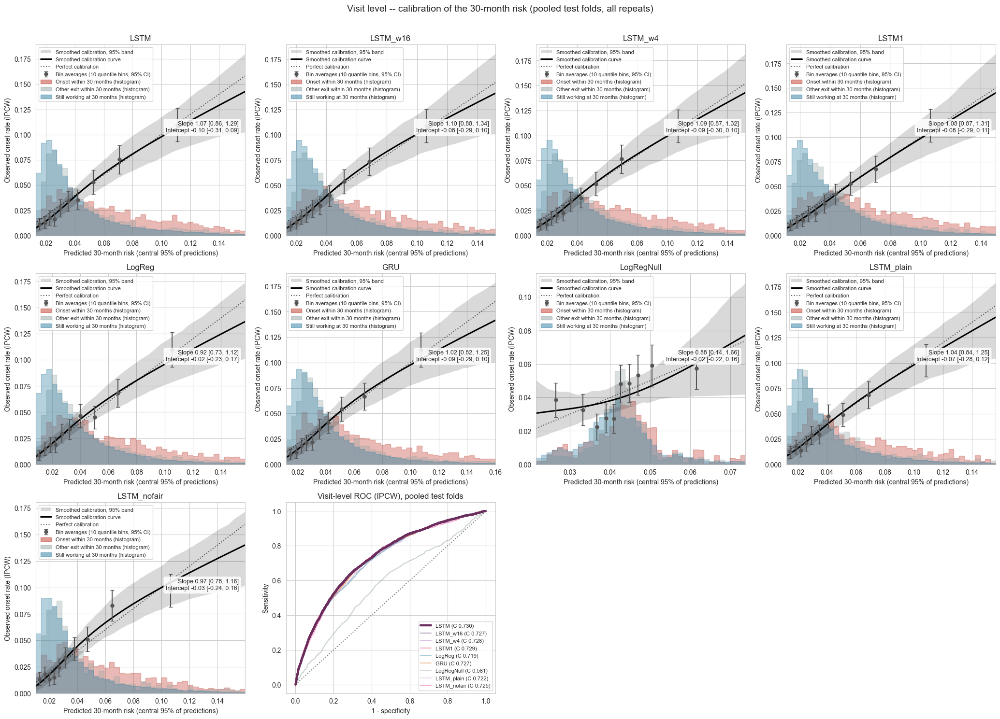

In [31]:
"""Visit-level calibration of every model (one panel each: IPCW deciles of the pooled out-of-fold 30-month risk, all
repeats stacked, with the slope and intercept of its table) and the IPCW ROC curves of all models."""
_ms = list(MODEL_RESULTS)
_ncols = 4
_nrows = int(np.ceil((len(_ms) + 1) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "visit", MODEL_RESULTS[m]["visit_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    p, y, w = r["p"], r["y"], r["w"]
    k = w > 0
    fpr, tpr, _ = roc_curve(y[k], p[k], sample_weight=w[k])
    ax.plot(fpr, tpr, **model_style(m),
            label=f"{m} (C {r['visit_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("Visit-level ROC (IPCW), pooled test folds"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Visit level -- calibration of the 30-month risk (pooled test folds, all repeats)", y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_calibration_visit_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()


## 11.11.3 H1b and H1d: calibration criteria, decision curves and fixed risk thresholds

**H1b** for every model from its visit-level table (30 months, IPCW): calibration slope within [0.8, 1.2] and the
calibration intercept's 95 % CI containing 0. Every risk is recalibrated inside its training fold (Section 7), so this
is a check that the recalibration transports to held-out patients; the transport to later years is the temporal
validation (Section 11.16.1). **H1d**: the visit-level decision curve (IPCW net benefit per landmark visit) against
alarming at every visit and at none, at every threshold from 2 % to 10 % 30-month risk — the range that contains the
cost-weighted alarm threshold (about 4 %, the 30-month onset rate). Then sensitivity, specificity, PPV and NPV at the
fixed 30-month risks of 5 % and 10 %, and every model's AUROC within each calendar era.

H1b -- calibration of the 30-month risk, visit level (IPCW), value [95% patient-cluster bootstrap CI]:


,Calibration slope [95% CI],Calibration intercept [95% CI],Observed / expected,"Slope in [0.8, 1.2]",Intercept CI includes 0,Both
Model,,,,,,
T-LSTM-8 (main),"1.066 [0.858, 1.294]","-0.097 [-0.309, 0.087]",0.915,True,True,True
T-LSTM-16 (last 16 visits),"1.103 [0.878, 1.345]","-0.080 [-0.287, 0.101]",0.928,True,True,True
T-LSTM-4 (last 4 visits),"1.089 [0.870, 1.322]","-0.088 [-0.295, 0.096]",0.923,True,True,True
T-LSTM-1 (current visit),"1.085 [0.869, 1.309]","-0.079 [-0.288, 0.107]",0.930,True,True,True
LogReg (last visit),"0.918 [0.727, 1.122]","-0.015 [-0.228, 0.174]",0.986,True,True,True
GRU (whole history),"1.025 [0.820, 1.252]","-0.087 [-0.293, 0.102]",0.923,True,True,True
"Null LogReg (age, race, education)","0.879 [0.138, 1.659]","-0.015 [-0.220, 0.158]",0.985,True,True,True
LSTM-8 (no time decay),"1.040 [0.838, 1.253]","-0.068 [-0.281, 0.115]",0.940,True,True,True
T-LSTM-8 (no fairness penalty),"0.966 [0.779, 1.159]","-0.027 [-0.238, 0.162]",0.976,True,True,True



H3b -- net benefit per landmark visit (IPCW, 30 months) against treat-all and treat-none at 31 thresholds from 2% to 10%:


,Thresholds above both,Highest threshold above both,Mean net benefit over the range,Share of resamples above both over the whole range,Met
Model,,,,,
T-LSTM-8 (main),31 of 31,10%,0.0110,0.935,True
T-LSTM-16 (last 16 visits),31 of 31,10%,0.0108,0.940,True
T-LSTM-4 (last 4 visits),31 of 31,10%,0.0110,0.930,True
T-LSTM-1 (current visit),31 of 31,10%,0.0111,0.955,True
LogReg (last visit),31 of 31,10%,0.0105,0.920,True
GRU (whole history),31 of 31,10%,0.0110,0.965,True
"Null LogReg (age, race, education)",22 of 31,10%,0.0041,0.000,False
LSTM-8 (no time decay),31 of 31,10%,0.0107,0.850,True
T-LSTM-8 (no fairness penalty),31 of 31,10%,0.0106,0.830,True


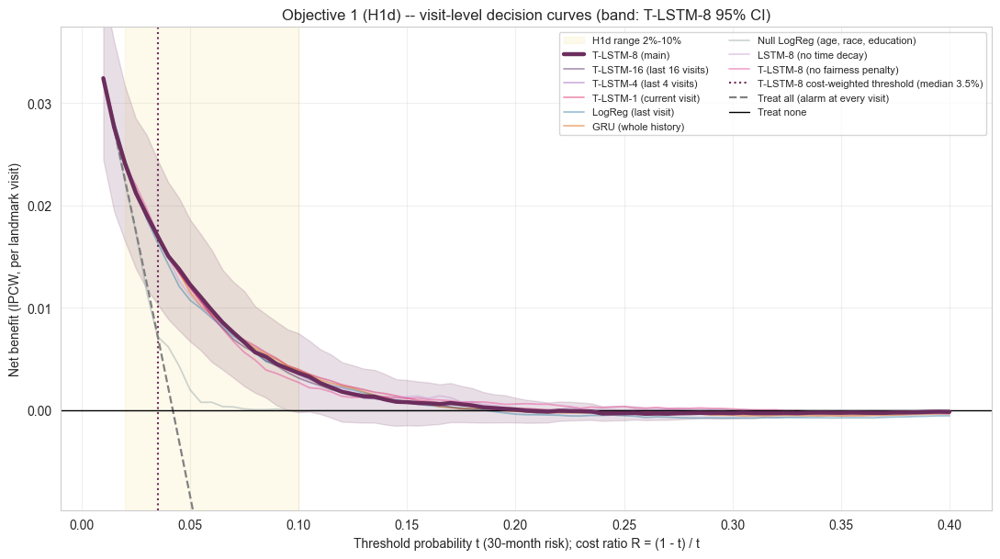

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_88598/2114835918.py:107: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.array(out, float), axis=0)



FIXED 30-MONTH RISK THRESHOLDS -- visit level (IPCW; 95% patient-cluster bootstrap CI) and patient level (Section 11.6 rule with the fixed threshold; mean over repeats):


Visit Sensitivity  \
Threshold Model                                                      
5%        T-LSTM-8 (main)                     0.611 [0.541, 0.676]   
          T-LSTM-16 (last 16 visits)          0.600 [0.526, 0.666]   
          T-LSTM-4 (last 4 visits)            0.608 [0.533, 0.669]   
          T-LSTM-1 (current visit)            0.618 [0.542, 0.678]   
          LogReg (last visit)                 0.553 [0.479, 0.616]   
          GRU (whole history)                 0.582 [0.507, 0.650]   
          Null LogReg (age, race, education)  0.250 [0.180, 0.317]   
          LSTM-8 (no time decay)              0.570 [0.495, 0.639]   
          T-LSTM-8 (no fairness penalty)      0.556 [0.485, 0.625]   
10%       T-LSTM-8 (main)                     0.281 [0.213, 0.344]   
          T-LSTM-16 (last 16 visits)          0.248 [0.187, 0.305]   
          T-LSTM-4 (last 4 visits)            0.261 [0.202, 0.316]   
          T-LSTM-1 (current visit)            0.268 [0.211, 0.324]   
          LogReg (last visit)                 0.246 [0.188, 0.294]   
          GRU (whole history)                 0.265 [0.198, 0.326]   
          Null LogReg (age, race, education)  0.000 [0.000, 0.000]   
          LSTM-8 (no time decay)              0.261 [0.194, 0.313]   
          T-LSTM-8 (no fairness penalty)      0.239 [0.177, 0.298]   

                                                 Visit Specificity  \
Threshold Model                                                      
5%        T-LSTM-8 (main)                     0.734 [0.704, 0.762]   
          T-LSTM-16 (last 16 visits)          0.740 [0.712, 0.768]   
          T-LSTM-4 (last 4 visits)            0.733 [0.706, 0.760]   
          T-LSTM-1 (current visit)            0.722 [0.692, 0.747]   
          LogReg (last visit)                 0.752 [0.724, 0.778]   
          GRU (whole history)                 0.743 [0.717, 0.769]   
          Null LogReg (age, race, education)  0.831 [0.803, 0.858]   
          LSTM-8 (no time decay)              0.746 [0.718, 0.774]   
          T-LSTM-8 (no fairness penalty)      0.773 [0.744, 0.798]   
10%       T-LSTM-8 (main)                     0.923 [0.909, 0.936]   
          T-LSTM-16 (last 16 visits)          0.931 [0.918, 0.945]   
          T-LSTM-4 (last 4 visits)            0.929 [0.916, 0.943]   
          T-LSTM-1 (current visit)            0.932 [0.919, 0.945]   
          LogReg (last visit)                 0.936 [0.923, 0.947]   
          GRU (whole history)                 0.932 [0.919, 0.945]   
          Null LogReg (age, race, education)  1.000 [0.999, 1.000]   
          LSTM-8 (no time decay)              0.929 [0.915, 0.942]   
          T-LSTM-8 (no fairness penalty)      0.931 [0.916, 0.943]   

                                                         Visit PPV  \
Threshold Model                                                      
5%        T-LSTM-8 (main)                     0.092 [0.074, 0.114]   
          T-LSTM-16 (last 16 visits)          0.092 [0.073, 0.114]   
          T-LSTM-4 (last 4 visits)            0.091 [0.073, 0.113]   
          T-LSTM-1 (current visit)            0.089 [0.071, 0.110]   
          LogReg (last visit)                 0.089 [0.070, 0.112]   
          GRU (whole history)                 0.090 [0.072, 0.112]   
          Null LogReg (age, race, education)  0.061 [0.041, 0.088]   
          LSTM-8 (no time decay)              0.090 [0.071, 0.112]   
          T-LSTM-8 (no fairness penalty)      0.097 [0.077, 0.122]   
10%       T-LSTM-8 (main)                     0.138 [0.098, 0.181]   
          T-LSTM-16 (last 16 visits)          0.137 [0.096, 0.181]   
          T-LSTM-4 (last 4 visits)            0.139 [0.104, 0.185]   
          T-LSTM-1 (current visit)            0.146 [0.110, 0.194]   
          LogReg (last visit)                 0.144 [0.103, 0.192]   
          GRU (whole history)                 0.147 [0.105, 0.194]   
          Null LogReg (age, race, education)  0.000 [0.00


AUROC (30 months) within each calendar era of the landmark visit (95% patient-cluster bootstrap CI):


,Landmarks,Onsets <= 30 mo,T-LSTM-8 (main),T-LSTM-16 (last 16 visits),T-LSTM-4 (last 4 visits),T-LSTM-1 (current visit),LogReg (last visit),GRU (whole history),"Null LogReg (age, race, education)",LSTM-8 (no time decay),T-LSTM-8 (no fairness penalty)
Era,,,,,,,,,,,
< 2000,1925,130,"0.783 [0.713, 0.838]","0.786 [0.715, 0.840]","0.781 [0.712, 0.833]","0.785 [0.715, 0.834]","0.754 [0.686, 0.808]","0.782 [0.706, 0.837]","0.550 [0.431, 0.668]","0.767 [0.694, 0.826]","0.757 [0.679, 0.823]"
2000-05,2612,153,"0.671 [0.589, 0.749]","0.665 [0.584, 0.743]","0.680 [0.600, 0.757]","0.681 [0.601, 0.758]","0.678 [0.597, 0.758]","0.673 [0.598, 0.746]","0.511 [0.393, 0.630]","0.677 [0.586, 0.763]","0.668 [0.582, 0.751]"
2006-11,3790,193,"0.674 [0.592, 0.758]","0.675 [0.592, 0.756]","0.676 [0.595, 0.757]","0.673 [0.589, 0.752]","0.642 [0.551, 0.724]","0.671 [0.585, 0.757]","0.590 [0.479, 0.685]","0.657 [0.569, 0.745]","0.666 [0.574, 0.752]"
>= 2012,6012,150,"0.711 [0.600, 0.808]","0.709 [0.606, 0.801]","0.699 [0.588, 0.796]","0.703 [0.602, 0.791]","0.713 [0.617, 0.794]","0.707 [0.598, 0.803]","0.631 [0.521, 0.727]","0.704 [0.593, 0.806]","0.717 [0.606, 0.811]"


In [32]:
"""
Objective 1 (Section 8.1).
  H1b  calibration at the primary horizon (30 months), every model: the calibration slope (logistic regression of the
       outcome on logit(risk)) within H3A_SLOPE_RANGE, and the 95% CI of the calibration intercept (calibration-in-the-
       large, slope fixed at 1) containing 0; visit level, IPCW, from each model's metric table.
  H1d  IPCW net benefit per landmark visit of alarming when the calibrated 30-month risk >= t, mean over repeats,
       against treat-all (alarm at every visit) and treat-none (0), at every t in DCA_RANGE; criterion: above both at
       every threshold of the range (the bootstrap share of resamples in which it holds is reported with it). The
       curves are drawn over DCA_PLOT_RANGE with the hypothesis range shaded and the cost-weighted thresholds marked.
Then (descriptive) the fixed thresholds DECISION_THRESHOLDS and every model's AUROC within each calendar era.
"""
# ---- H1b
_rows = []
for m in [x for x in CV_MODELS + ["Baseline"] if model_res(x) is not None]:
    vt = model_res(m)["visit_table"]
    s_, i_ = vt.loc["cal_slope"], vt.loc["cal_intercept"]
    slope_ok = bool(np.isfinite(s_["Value"]) and H3A_SLOPE_RANGE[0] <= s_["Value"] <= H3A_SLOPE_RANGE[1])
    icpt_ok = bool(np.isfinite(i_["CI low"]) and i_["CI low"] <= 0 <= i_["CI high"])
    _rows.append({"Model": mlab(m), "Calibration slope [95% CI]": _o1_cell(vt, "cal_slope"),
                  "Calibration intercept [95% CI]": _o1_cell(vt, "cal_intercept"),
                  "Observed / expected": round(float(vt.loc["oe_ratio", "Value"]), 3),
                  f"Slope in [{H3A_SLOPE_RANGE[0]}, {H3A_SLOPE_RANGE[1]}]": slope_ok,
                  "Intercept CI includes 0": icpt_ok, "Both": slope_ok and icpt_ok})
    OBJ_ROWS.append({"Hypothesis": "H1b", "Comparison": mlab(m), "Level": "visit", "Metric": "calibration",
                     "Estimate [95% CI]": f"slope {_o1_cell(vt, 'cal_slope')}; intercept {_o1_cell(vt, 'cal_intercept')}",
                     "Criterion": f"slope in [{H3A_SLOPE_RANGE[0]}, {H3A_SLOPE_RANGE[1]}] and intercept CI includes 0",
                     "Met": slope_ok and icpt_ok})
h3a = pd.DataFrame(_rows).set_index("Model")
print(f"H1b -- calibration of the {PRIMARY_HORIZON_MONTHS}-month risk, visit level (IPCW), value [95% patient-cluster "
      "bootstrap CI]:")
display(h3a)

# ---- H1d
DCA_GRID = np.round(np.linspace(DCA_RANGE[0], DCA_RANGE[1], 31), 4)
DCA_PLOT_GRID = np.round(np.linspace(DCA_PLOT_RANGE[0], DCA_PLOT_RANGE[1], 79), 4)
DCA_BOOT = HYP_MULT[:200]
DCA_MODELS = [m for m in CV_MODELS if oof(m)]
_zero = np.zeros(len(Y30))


def nb_curve(m, grid, mult=1.0):
    return np.mean([ipcw_net_benefit(Y30, p, W30 * mult, grid)[0] for p in oof(m).values()], axis=0)


NB_ALL = ipcw_net_benefit(Y30, _zero, W30, DCA_GRID)[1]
NB_REF = np.maximum(NB_ALL, 0.0)
_Bref = np.array([np.maximum(ipcw_net_benefit(Y30, _zero, W30 * mm, DCA_GRID)[1], 0.0) for mm in DCA_BOOT])
_rows, H3B_ABOVE = [], {}
for m in DCA_MODELS:
    nb_ = nb_curve(m, DCA_GRID)
    above = nb_ > NB_REF
    H3B_ABOVE[m] = above
    _B = np.array([nb_curve(m, DCA_GRID, mm) for mm in DCA_BOOT])
    share = float(np.mean(np.all(_B > _Bref, axis=1)))
    _rows.append({"Model": mlab(m), "Thresholds above both": f"{int(above.sum())} of {len(DCA_GRID)}",
                  "Highest threshold above both": f"{DCA_GRID[above].max():.0%}" if above.any() else "none",
                  "Mean net benefit over the range": float(nb_.mean()),
                  "Share of resamples above both over the whole range": share, "Met": bool(above.all())})
    OBJ_ROWS.append({"Hypothesis": "H1d", "Comparison": mlab(m), "Level": "visit", "Metric": "net benefit",
                     "Estimate [95% CI]": f"above both at {int(above.sum())}/{len(DCA_GRID)} thresholds; whole range "
                                          f"in {share:.0%} of resamples",
                     "Criterion": f"above treat-all and treat-none at every threshold in "
                                  f"{DCA_RANGE[0]:.0%}-{DCA_RANGE[1]:.0%}", "Met": bool(above.all())})
h3b = pd.DataFrame(_rows).set_index("Model")
print(f"\nH3b -- net benefit per landmark visit (IPCW, 30 months) against treat-all and treat-none at {len(DCA_GRID)} "
      f"thresholds from {DCA_RANGE[0]:.0%} to {DCA_RANGE[1]:.0%}:")
display(h3b.round(4))

NB = {m: nb_curve(m, DCA_PLOT_GRID) for m in DCA_MODELS}
NB_ALL_PLOT = ipcw_net_benefit(Y30, _zero, W30, DCA_PLOT_GRID)[1]
dca_tab = pd.DataFrame({**{mlab(m): NB[m] for m in DCA_MODELS}, "Treat all": NB_ALL_PLOT, "Treat none": 0.0},
                       index=pd.Index(DCA_PLOT_GRID, name="Threshold (30-month risk)"))
_thr_med = {m: float(np.nanmedian(np.concatenate([pr["visit_thr"]["target"] for (mm, _), pr in
                                                  model_res(m)["preds"].items() if mm == m])))
            for m in DCA_MODELS if model_res(m) is not None}
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.axvspan(DCA_RANGE[0], DCA_RANGE[1], color="#f1c40f", alpha=0.08, label=f"H1d range {DCA_RANGE[0]:.0%}-{DCA_RANGE[1]:.0%}")
for m in DCA_MODELS:
    ax.plot(DCA_PLOT_GRID, NB[m], label=mlab(m), **model_style(m))
if "LSTM" in NB:
    _Bp = np.array([nb_curve("LSTM", DCA_PLOT_GRID, mm) for mm in DCA_BOOT])
    ax.fill_between(DCA_PLOT_GRID, *np.percentile(_Bp, [2.5, 97.5], axis=0), color=CV_COLORS["LSTM"], alpha=0.15)
    if "LSTM" in _thr_med:
        ax.axvline(_thr_med["LSTM"], color=CV_COLORS["LSTM"], ls=":", lw=1.5,
                   label=f"T-LSTM-8 cost-weighted threshold (median {_thr_med['LSTM']:.1%})")
ax.plot(DCA_PLOT_GRID, NB_ALL_PLOT, color="gray", ls="--", lw=1.6, label="Treat all (alarm at every visit)")
ax.axhline(0, color="black", lw=1, label="Treat none")
_top = max(float(np.nanmax(list(NB.values()))) if NB else 0.0, float(NB_ALL_PLOT.max()), 1e-4)
ax.set_ylim(-0.3 * _top, 1.15 * _top)
ax.set_xlabel("Threshold probability t (30-month risk); cost ratio R = (1 - t) / t")
ax.set_ylabel("Net benefit (IPCW, per landmark visit)")
ax.set_title("Objective 1 (H1d) -- visit-level decision curves (band: T-LSTM-8 95% CI)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective3_decision_curves.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- fixed thresholds: visit level (95% CI) and patient level
def _visit_stats(m, t, mult=1.0):
    out = []
    for p in oof(m).values():
        w = W30 * mult
        k = w > 0
        a = p >= t
        tp, fp, fn, tn = w_confusion(Y30[k], a[k], w[k])
        div = lambda x, y_: x / y_ if y_ > 0 else np.nan
        out.append([div(tp, tp + fn), div(tn, tn + fp), div(tp, tp + fp), div(tn, tn + fn), 100.0 * float(np.mean(a))])
    return np.nanmean(np.array(out, float), axis=0)


THR_COLS = ["Sensitivity", "Specificity", "PPV", "NPV", "Alerts / 100 visits"]
thr_rows = []
for t in DECISION_THRESHOLDS:
    for m in DCA_MODELS:
        est = _visit_stats(m, t)
        B = np.array([_visit_stats(m, t, mm) for mm in DCA_BOOT])
        lo_, hi_ = np.nanpercentile(B, [2.5, 97.5], axis=0)
        pcs = [patient_counts(patient_frame(ALL_ROWS, p, np.full(len(p), t))) for p in oof(m).values()]
        pt = np.nanmean([[c["TP"] / max(c["TP"] + c["FN"], 1), c["TN"] / max(c["TN"] + c["FP"], 1),
                          c["TP"] / (c["TP"] + c["FP"]) if c["TP"] + c["FP"] else np.nan,
                          c["TN"] / (c["TN"] + c["FN"]) if c["TN"] + c["FN"] else np.nan] for c in pcs], axis=0)
        thr_rows.append({"Threshold": f"{t:.0%}", "Model": mlab(m),
                         **{f"Visit {c}": (f"{e:.3f} [{l:.3f}, {h:.3f}]" if c != "Alerts / 100 visits" else f"{e:.1f}")
                            for c, e, l, h in zip(THR_COLS, est, lo_, hi_)},
                         **{f"Patient {c}": round(v, 3) for c, v in zip(THR_COLS[:4], pt)}})
thr_df = pd.DataFrame(thr_rows).set_index(["Threshold", "Model"])
print("\nFIXED 30-MONTH RISK THRESHOLDS -- visit level (IPCW; 95% patient-cluster bootstrap CI) and patient level "
      "(Section 11.6 rule with the fixed threshold; mean over repeats):")
display(thr_df)

# ---- every model's AUROC within each calendar era (subgroup: era)
era_rows3 = []
for e, (_, _, era_lab) in enumerate(ERA_BANDS):
    w_e = W30 * (ERA_IDX_LAND == e)
    n_ev = int(((Y30 == 1) & (w_e > 0)).sum())
    row = {"Era": era_lab, "Landmarks": int((w_e > 0).sum()), "Onsets <= 30 mo": n_ev}
    for m in DCA_MODELS:
        if n_ev > 0:
            a_, B_ = model_auc(m, w=w_e, tag=f"era{e}")
            row[mlab(m)] = f"{a_:.3f} [{np.nanpercentile(B_, 2.5):.3f}, {np.nanpercentile(B_, 97.5):.3f}]"
    era_rows3.append(row)
era_auc3 = pd.DataFrame(era_rows3).set_index("Era")
print("\nAUROC (30 months) within each calendar era of the landmark visit (95% patient-cluster bootstrap CI):")
display(era_auc3)
dca_tab.to_csv("objective3_decision_curves_revised_v27.csv")
thr_df.to_csv("objective3_fixed_thresholds_revised_v27.csv")
era_auc3.to_csv("objective3_auroc_by_era_revised_v27.csv")
h3a.to_csv("objective3_h3a_calibration_revised_v27.csv")
h3b.to_csv("objective3_h3b_net_benefit_revised_v27.csv")


## 11.11.4 Risk tiers: how many visits fall in each tier, and what happened to them

The calibrated 30-month risk in four tiers (< 2 %, 2–5 %, 5–10 %, ≥ 10 %), from the pooled test folds: the share of
landmark visits and of patients in each tier, the mean predicted risk, the observed 30-month onset rate (IPCW, 95 %
patient-cluster bootstrap CI) and the share of all onsets within 30 months that arose from each tier. A tier is a way
to act on the risk without a single alarm threshold; it is descriptive.

RISK TIERS -- calibrated 30-month risk, pooled test folds, mean over repeats (overall onset rate 0.042):


Share of visits  \
Model               Tier (30-month risk)                    
T-LSTM-8 (main)     < 2%                            0.230   
                    2%-5%                           0.509   
                    5%-10%                          0.181   
                    >= 10%                          0.080   
LogReg (last visit) < 2%                            0.353   
                    2%-5%                           0.408   
                    5%-10%                          0.173   
                    >= 10%                          0.066   

                                          Patients with a visit in the tier  \
Model               Tier (30-month risk)                                      
T-LSTM-8 (main)     < 2%                                              509.0   
                    2%-5%                                             849.6   
                    5%-10%                                            623.2   
                    >= 10%                                            307.4   
LogReg (last visit) < 2%                                              664.4   
                    2%-5%                                             793.4   
                    5%-10%                                            536.0   
                    >= 10%                                            292.4   

                                          Mean predicted  Observed (IPCW)  \
Model               Tier (30-month risk)                                    
T-LSTM-8 (main)     < 2%                           0.016            0.011   
                    2%-5%                          0.032            0.027   
                    5%-10%                         0.069            0.071   
                    >= 10%                         0.149            0.138   
LogReg (last visit) < 2%                           0.014            0.014   
                    2%-5%                          0.032            0.034   
                    5%-10%                         0.069            0.068   
                    >= 10%                         0.159            0.144   

                                                  95% CI  \
Model               Tier (30-month risk)                   
T-LSTM-8 (main)     < 2%                  [0.006, 0.020]   
                    2%-5%                 [0.021, 0.035]   
                    5%-10%                [0.056, 0.089]   
                    >= 10%                [0.098, 0.181]   
LogReg (last visit) < 2%                  [0.009, 0.022]   
                    2%-5%                 [0.027, 0.043]   
                    5%-10%                [0.052, 0.088]   
                    >= 10%                [0.103, 0.192]   

                                          Observed / predicted  \
Model               Tier (30-month risk)                         
T-LSTM-8 (main)     < 2%                                 0.701   
                    2%-5%                                0.852   
                    5%-10%                               1.032   
                    >= 10%                               0.928   
LogReg (last visit) < 2%                                 0.991   
                    2%-5%                                1.044   
                    5%-10%                               0.993   
                    >= 10%                               0.905   

                                          Share of onsets <= 30 mo  
Model               Tier (30-month risk)                            
T-LSTM-8 (main)     < 2%                                     0.052  
                    2%-5%                                    0.337  
                    5%-10%                                   0.330  
                    >= 10%                                   0.281  
LogReg (last visit) < 2%                                     0.101  
                    2%-5%                                    0.346  
                    5%-10%                             

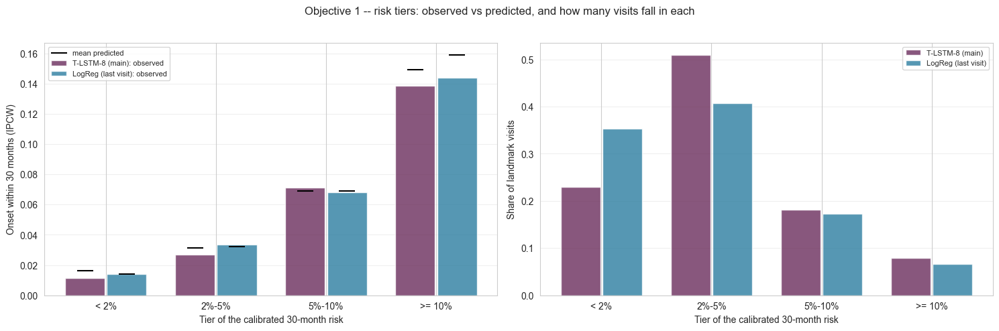

In [33]:
"""
Risk tiers (Objective 1, descriptive): the calibrated 30-month risk of the pooled test folds cut at RISK_TIERS, for
T-LSTM-8 and the LogReg. Per tier: share of landmark visits, patients with a visit in the tier, mean predicted risk,
observed onset rate within 30 months (IPCW; 200 patient-cluster bootstrap resamples) and the share of onsets.
"""
TIER_LABELS = ([f"< {RISK_TIERS[1]:.0%}"] + [f"{a:.0%}-{b:.0%}" for a, b in zip(RISK_TIERS[1:-2], RISK_TIERS[2:-1])]
               + [f">= {RISK_TIERS[-2]:.0%}"])
TIER_BOOT = HYP_MULT[:200]
TIER_MODELS = [m for m in ["LSTM", "LogReg"] if model_res(m) is not None and oof(m)]


def _tier_stats(m, j, mult=1.0):
    out = []
    for p in oof(m).values():
        t = (p >= RISK_TIERS[j]) & (p < RISK_TIERS[j + 1])
        w = W30 * mult
        k = (w > 0) & t
        obs = np.average(Y30[k], weights=w[k]) if k.any() else np.nan
        pred = np.average(p[k], weights=w[k]) if k.any() else np.nan
        share_on = float((w * t * Y30).sum() / max((w * Y30).sum(), 1e-12))
        out.append([t.mean(), len(np.unique(PID_ALL[t])), pred, obs, share_on])
    return np.nanmean(np.array(out, float), axis=0)


tier_rows = []
for m in TIER_MODELS:
    for j, lab_ in enumerate(TIER_LABELS):
        est = _tier_stats(m, j)
        lo_, hi_ = np.nanpercentile([_tier_stats(m, j, mm)[3] for mm in TIER_BOOT], [2.5, 97.5])
        tier_rows.append({"Model": mlab(m), "Tier (30-month risk)": lab_, "Share of visits": est[0],
                          "Patients with a visit in the tier": est[1], "Mean predicted": est[2],
                          "Observed (IPCW)": est[3], "95% CI": f"[{lo_:.3f}, {hi_:.3f}]",
                          "Observed / predicted": est[3] / est[2] if est[2] > 0 else np.nan,
                          "Share of onsets <= 30 mo": est[4]})
tier_df = pd.DataFrame(tier_rows)
if tier_df.empty:
    print("No model has run.")
else:
    print(f"RISK TIERS -- calibrated {PRIMARY_HORIZON_MONTHS}-month risk, pooled test folds, mean over repeats (overall "
          f"onset rate {np.average(Y30[W30 > 0], weights=W30[W30 > 0]):.3f}):")
    display(tier_df.set_index(["Model", "Tier (30-month risk)"]).round(3))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    xs = np.arange(len(TIER_LABELS))
    for i_, m in enumerate(TIER_MODELS):
        s_ = tier_df[tier_df["Model"] == mlab(m)]
        axes[0].bar(xs + (i_ - 0.5) * 0.38, s_["Observed (IPCW)"], 0.36, color=CV_COLORS[m], alpha=0.8,
                    label=f"{mlab(m)}: observed")
        axes[0].scatter(xs + (i_ - 0.5) * 0.38, s_["Mean predicted"], color="black", marker="_", s=300, zorder=3,
                        label="mean predicted" if i_ == 0 else None)
        axes[1].bar(xs + (i_ - 0.5) * 0.38, s_["Share of visits"], 0.36, color=CV_COLORS[m], alpha=0.8, label=mlab(m))
    for ax, yl in zip(axes, ["Onset within 30 months (IPCW)", "Share of landmark visits"]):
        ax.set_xticks(xs); ax.set_xticklabels(TIER_LABELS); ax.set_xlabel("Tier of the calibrated 30-month risk")
        ax.set_ylabel(yl); ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8)
    plt.suptitle("Objective 1 -- risk tiers: observed vs predicted, and how many visits fall in each", y=1.02)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_risk_tiers.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    tier_df.to_csv("objective1_risk_tiers_revised_v27.csv", index=False)

## 11.11.5 H1c: do the alarms come early enough to intervene?

For every event patient the patient rule flags (2 alarms in a row in the 24 months before onset; Section 9.2), the
**lead time** runs from the visit that completed the run to the onset. Estimand: the median lead time over the flagged
event patients (mean over repeats, 95 % patient-cluster bootstrap CI); criterion: lower bound ≥ 6 months, enough time
for a referral or workplace accommodation. Also the share of **all** event patients flagged at least 6 months before
onset, and the distribution of lead times.

H1c -- lead time of the patient flag (2 alarms in a row in the 24-month window (event patients: before onset; event-free patients: the last months of follow-up with a known 30-month outcome)); 1000 patient-cluster bootstrap resamples:


,"Median lead time, months [95% CI]",Patient sensitivity [95% CI],"Flagged >= 6 mo before onset, share of event patients [95% CI]",H1c met
Model,,,,
T-LSTM-8 (main),"12.6 [10.3, 15.4]","0.722 [0.664, 0.783]","0.535 [0.457, 0.614]",True
T-LSTM-1 (current visit),"13.0 [10.4, 15.9]","0.697 [0.634, 0.763]","0.519 [0.440, 0.594]",True
LogReg (last visit),"12.6 [9.4, 15.5]","0.596 [0.529, 0.669]","0.439 [0.362, 0.510]",True


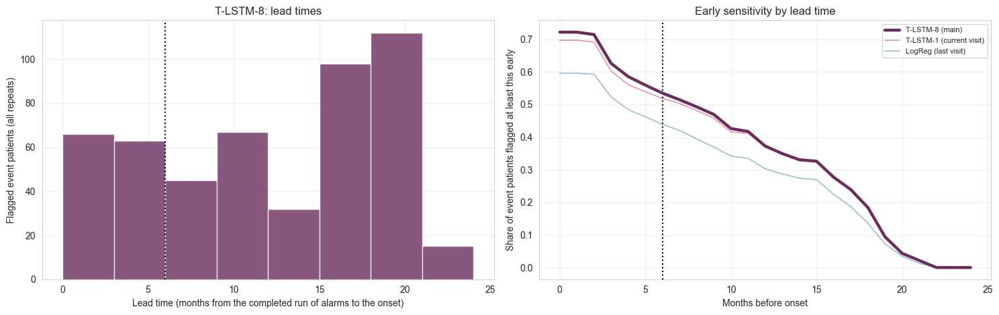

In [34]:
"""
Objective 1, H1c (Section 8.1): lead time of the patient flag. For each repeat of a model's pooled patient frame (the
rule of Section 11.6), flagged event patients' lead_mo = months from the landmark that completed the run of alarms to
the onset. Median over flagged event patients, mean over repeats; CI from the patient-cluster bootstrap (_PT_BOOT,
HYP_BOOT resamples); criterion: lower 95% bound >= LEAD_TIME_MIN_MONTHS. Also: patient sensitivity and the share of
all event patients flagged >= LEAD_TIME_MIN_MONTHS before onset ('early sensitivity').
"""
LEAD_MODELS = [m for m in ["LSTM", "LSTM1", "LogReg", "CoxPH"] if model_res(m) is not None and oof(m)]


def _pt_frames(m):
    return [pr["pt"] for (mm, _), pr in model_res(m)["preds"].items() if mm == m and pr is not None]


def _lead_stats(frames, cnt=None):
    med, early, sens = [], [], []
    for f in frames:
        c = np.ones(len(f)) if cnt is None else cnt[PT_CODE.get_indexer(f.index)]
        ev, fl, ld = f["y"].values == 1, f["flag"].values == 1, f["lead_mo"].values.astype(float)
        k = ev & fl & np.isfinite(ld) & (c > 0)
        med.append(_weighted_quantile(ld[k], c[k], 0.5) if k.any() else np.nan)
        n_ev = max(float(c[ev].sum()), 1e-9)
        sens.append(float(c[ev & fl].sum()) / n_ev)
        early.append(float(c[ev & fl & (np.nan_to_num(ld) >= LEAD_TIME_MIN_MONTHS)].sum()) / n_ev)
    return np.array([np.nanmean(med), np.mean(sens), np.mean(early)])


lead_rows, LEAD = [], {}
for m in LEAD_MODELS:
    fr = _pt_frames(m)
    est = _lead_stats(fr)
    B = np.array([_lead_stats(fr, cnt) for cnt in _PT_BOOT])
    lo_, hi_ = np.nanpercentile(B, [2.5, 97.5], axis=0)
    LEAD[m] = (est, lo_, hi_)
    lead_rows.append({"Model": mlab(m), "Median lead time, months [95% CI]": f"{est[0]:.1f} [{lo_[0]:.1f}, {hi_[0]:.1f}]",
                      "Patient sensitivity [95% CI]": f"{est[1]:.3f} [{lo_[1]:.3f}, {hi_[1]:.3f}]",
                      f"Flagged >= {LEAD_TIME_MIN_MONTHS} mo before onset, share of event patients [95% CI]":
                          f"{est[2]:.3f} [{lo_[2]:.3f}, {hi_[2]:.3f}]",
                      "H1c met": bool(lo_[0] >= LEAD_TIME_MIN_MONTHS)})
    OBJ_ROWS.append({"Hypothesis": "H1c", "Comparison": mlab(m), "Level": "patient", "Metric": "median lead time (months)",
                     "Estimate [95% CI]": f"{est[0]:.1f} [{lo_[0]:.1f}, {hi_[0]:.1f}]",
                     "Criterion": f"lower 95% bound >= {LEAD_TIME_MIN_MONTHS} months",
                     "Met": bool(lo_[0] >= LEAD_TIME_MIN_MONTHS)})
lead_df = pd.DataFrame(lead_rows).set_index("Model") if lead_rows else pd.DataFrame()
if lead_df.empty:
    print("H1c skipped: no model has run.")
else:
    print(f"H1c -- lead time of the patient flag ({PATIENT_RULE_TEXT}); {HYP_BOOT} patient-cluster bootstrap "
          "resamples:")
    display(lead_df)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    for m in LEAD_MODELS:
        ld = pd.concat([f.loc[(f["y"] == 1) & (f["flag"] == 1), "lead_mo"] for f in _pt_frames(m)]).dropna()
        n_ev = np.mean([(f["y"] == 1).sum() for f in _pt_frames(m)])
        xs = np.arange(0, PATIENT_WINDOW_MONTHS + 1)
        axes[1].plot(xs, [(ld >= x).sum() / len(_pt_frames(m)) / n_ev for x in xs], label=mlab(m), **model_style(m))
        if m == "LSTM":
            axes[0].hist(ld, bins=np.arange(0, PATIENT_WINDOW_MONTHS + 3, 3), color=CV_COLORS[m], alpha=0.8)
    axes[0].axvline(LEAD_TIME_MIN_MONTHS, color="k", ls=":")
    axes[0].set_xlabel("Lead time (months from the completed run of alarms to the onset)")
    axes[0].set_ylabel("Flagged event patients (all repeats)"); axes[0].set_title("T-LSTM-8: lead times")
    axes[1].axvline(LEAD_TIME_MIN_MONTHS, color="k", ls=":")
    axes[1].set_xlabel("Months before onset"); axes[1].set_ylabel("Share of event patients flagged at least this early")
    axes[1].set_title("Early sensitivity by lead time"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_lead_time.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    lead_df.to_csv("objective1_lead_time_revised_v27.csv")

## 11.11.6 Utility of each model's alarm rule

Every model's AUROC, the cost ratio of its folds and the one implied by its alarm thresholds, and the visit- and
patient-level net benefit of its alarm rule against flagging everyone.

In [35]:
"""
AUROC, cost ratios and net benefit of every model (pooled test folds; no refitting): the cost ratio R of the folds and the one
implied by the (era-standardised) alarm thresholds, and the visit- and patient-level net benefit of the alarm rule.
"""
# ------------------------------------------------------------------------------------------------ all models
eu_rows = []
pi = COHORT_EVENT_SHARE
R_pt = (1 - pi) / pi                                   # patient level: the data-driven R at the cohort's event share
t_pt = 1.0 / (1.0 + R_pt)
for m in [x for x in CV_MODELS if oof(x) and x in MODEL_RESULTS]:
    a_p, B_p = model_auc(m)
    preds = MODEL_RESULTS[m]["preds"]
    thr = np.concatenate([pr["visit_thr"]["target"] for (mm, _), pr in preds.items() if mm == m])
    thr = thr[np.isfinite(thr) & (thr > 0)]
    R_impl = (1 - thr) / thr
    R_fold = [v.get("cost_ratio", np.nan) for k, v in cv_state["folds"].items() if k[0] == m]
    res_df = MODEL_RESULTS[m]["res_df"]
    pt = MODEL_RESULTS[m]["patient_table"]
    sens, spec = pt.loc["sensitivity", "Value"], pt.loc["specificity", "Value"]
    nb_rule = sens * pi - (1 - spec) * (1 - pi) * t_pt / (1 - t_pt)
    nb_all = pi - (1 - pi) * t_pt / (1 - t_pt)
    eu_rows.append({"Model": MODEL_LABELS.get(m, m),
                    "AUROC": f"{a_p:.3f} [{np.percentile(B_p, 2.5):.3f}, {np.percentile(B_p, 97.5):.3f}]",
                    "Cost ratio R of the folds, median": float(np.nanmedian(R_fold)),
                    "Implied cost ratio of the alarm thresholds, median [IQR]":
                        f"{np.median(R_impl):.0f} [{np.percentile(R_impl, 25):.0f}, {np.percentile(R_impl, 75):.0f}]",
                    "Visit NB at the folds' R": float(res_df["net_benefit"].mean()),
                    "Visit NB, alarm at every visit": float(res_df["nb_treat_all"].mean()),
                    "Patient NB of the alarm rule": nb_rule,
                    "Patient NB, flag every patient": nb_all,
                    "Fewer unnecessary flags / 100 patients vs flagging all": 100 * (nb_rule - nb_all) / (t_pt / (1 - t_pt))})
eu_df = pd.DataFrame(eu_rows).set_index("Model")
print(f"\nALL MODELS -- AUROC, the cost ratio R of the folds and the one implied by the (era-standardised) alarm thresholds, "
      f"R = (1 - t) / t, and net benefit at the data-driven R (visit level: each fold's R; patient level: R = (1 - pi) / pi "
      f"= {R_pt:.1f} at the cohort's event share pi = {pi:.1%}, where flagging every patient has net benefit 0 and the "
      f"rule's net benefit is pi x (sensitivity + specificity - 1)):")
display(eu_df.round(4))
eu_df.to_csv("auroc_and_utility_revised_v27.csv")


ALL MODELS -- AUROC, the cost ratio R of the folds and the one implied by the (era-standardised) alarm thresholds, R = (1 - t) / t, and net benefit at the data-driven R (visit level: each fold's R; patient level: R = (1 - pi) / pi = 6.1 at the cohort's event share pi = 14.2%, where flagging every patient has net benefit 0 and the rule's net benefit is pi x (sensitivity + specificity - 1)):


,AUROC,"Cost ratio R of the folds, median","Implied cost ratio of the alarm thresholds, median [IQR]",Visit NB at the folds' R,"Visit NB, alarm at every visit",Patient NB of the alarm rule,"Patient NB, flag every patient",Fewer unnecessary flags / 100 patients vs flagging all
Model,,,,,,,,
T-LSTM-8 (main),"0.730 [0.679, 0.773]",22.8129,"28 [21, 35]",0.0134,0.0,0.0509,0.0,30.8666
T-LSTM-16 (last 16 visits),"0.727 [0.678, 0.770]",22.8129,"25 [19, 32]",0.0130,0.0,0.0503,0.0,30.4596
T-LSTM-4 (last 4 visits),"0.728 [0.677, 0.771]",22.8129,"26 [20, 34]",0.0134,0.0,0.0516,0.0,31.2595
T-LSTM-1 (current visit),"0.729 [0.678, 0.772]",22.8129,"27 [20, 36]",0.0126,0.0,0.0493,0.0,29.8929
LogReg (last visit),"0.719 [0.670, 0.763]",22.8129,"26 [17, 40]",0.0117,0.0,0.0459,0.0,27.8087
GRU (whole history),"0.727 [0.678, 0.771]",22.8129,"26 [19, 33]",0.0130,0.0,0.0515,0.0,31.2031
"Null LogReg (age, race, education)","0.581 [0.524, 0.639]",22.8129,"22 [21, 23]",0.0040,0.0,0.0094,0.0,5.6688
LSTM-8 (no time decay),"0.722 [0.671, 0.765]",22.6611,"27 [20, 35]",0.0123,0.0,0.0472,0.0,28.5741
T-LSTM-8 (no fairness penalty),"0.725 [0.675, 0.770]",22.6611,"23 [17, 31]",0.0130,0.0,0.0476,0.0,28.8528


## 11.11.7 Alarms by calendar era: era-standardised vs absolute threshold

Section 9.1. For every model, from the pooled test folds (no refitting), per calendar era of the landmark visit: the
onset rate, the mean predicted risk and observed / expected ratio, and the alarm rate,
sensitivity and specificity with the **era-standardised** threshold (the alarms of every other table) and with the
**single absolute threshold** of revised_v11 (learned on the same training folds). With the absolute threshold the alarm
rate follows the era's onset rate; with the era-standardised threshold it should be similar across eras, with
sensitivity and specificity closer to those of the whole cohort.

Alarms by calendar era of the landmark visit, 30-month label (IPCW), mean over CV repeats. Alarms in every other table: era-standardised.


Landmarks  Onset rate  Mean risk    O/E  \
Model       Era                                                
LSTM        < 2000      1925.0       0.065      0.077  0.849   
            2000-05     2612.0       0.056      0.063  0.902   
            2006-11     3790.0       0.049      0.043  1.134   
            >= 2012     6012.0       0.024      0.031  0.786   
LSTM_w16    < 2000      1925.0       0.065      0.075  0.871   
            2000-05     2612.0       0.056      0.061  0.932   
            2006-11     3790.0       0.049      0.043  1.146   
            >= 2012     6012.0       0.024      0.031  0.781   
LSTM_w4     < 2000      1925.0       0.065      0.075  0.871   
            2000-05     2612.0       0.056      0.062  0.916   
            2006-11     3790.0       0.049      0.043  1.135   
            >= 2012     6012.0       0.024      0.031  0.780   
LSTM1       < 2000      1925.0       0.065      0.074  0.877   
            2000-05     2612.0       0.056      0.062  0.904   
            2006-11     3790.0       0.049      0.044  1.122   
            >= 2012     6012.0       0.024      0.029  0.816   
LogReg      < 2000      1925.0       0.065      0.074  0.887   
            2000-05     2612.0       0.056      0.062  0.904   
            2006-11     3790.0       0.049      0.041  1.208   
            >= 2012     6012.0       0.024      0.025  0.944   
GRU         < 2000      1925.0       0.065      0.078  0.834   
            2000-05     2612.0       0.056      0.062  0.908   
            2006-11     3790.0       0.049      0.043  1.147   
            >= 2012     6012.0       0.024      0.030  0.811   
LogRegNull  < 2000      1925.0       0.065      0.043  1.501   
            2000-05     2612.0       0.056      0.043  1.306   
            2006-11     3790.0       0.049      0.043  1.145   
            >= 2012     6012.0       0.024      0.042  0.570   
LSTM_plain  < 2000      1925.0       0.065      0.073  0.889   
            2000-05     2612.0       0.056      0.061  0.932   
            2006-11     3790.0       0.049      0.043  1.156   
            >= 2012     6012.0       0.024      0.030  0.793   
LSTM_nofair < 2000      1925.0       0.065      0.075  0.874   
            2000-05     2612.0       0.056      0.060  0.940   
            2006-11     3790.0       0.049      0.039  1.257   
            >= 2012     6012.0       0.024      0.028  0.852   

                     Alarm rate (era-standardised)  \
Model       Era                                      
LSTM        < 2000                           0.468   
            2000-05                          0.467   
            2006-11                          0.401   
            >= 2012                          0.340   
LSTM_w16    < 2000                           0.424   
            2000-05                          0.415   
            2006-11                          0.359   
            >= 2012                          0.308   
LSTM_w4     < 2000                           0.444   
            2000-05                          0.446   
            2006-11                          0.388   
            >= 2012                          0.324   
LSTM1       < 2000                           0.470   
            2000-05                          0.486   
            2006-11                          0.425   
            >= 2012                          0.365   
LogReg      < 2000                           0.334   
            2000-05                          0.380   
            2006-11                          0.314   
            >= 2012                          0.287   
GRU         < 2000                           0.425   
            2000-05                          0.422   
            2006-11                          0.363   
            >= 2012                          0.305   
LogRegNull  < 2000                           0.301   
            2000-05                          0.347   
            2006-11                          0.380   
            >= 2012   

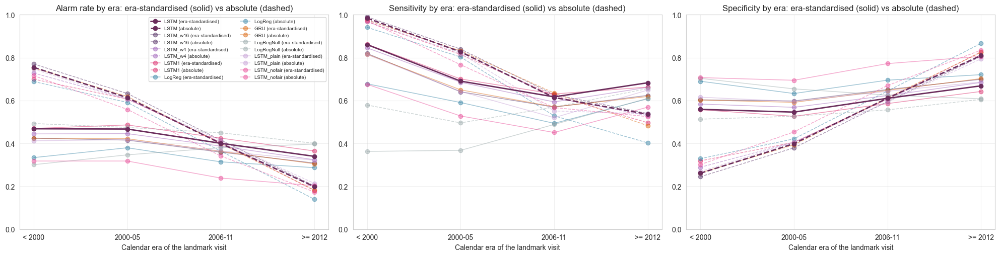

In [36]:
"""
Alarms by calendar era (Section 11.11.7), from the pooled test folds of every model: onset rate, mean risk, O/E,
and the alarm rate / sensitivity / specificity under the era-standardised and the absolute threshold,
IPCW-weighted (30-month label), mean over CV repeats.
"""
ERA_LABELS = [lab for *_, lab in ERA_BANDS]
ERA_OF_LAND = pd.cut(CAL_YEAR_ALL, [a for a, _, _ in ERA_BANDS] + [ERA_BANDS[-1][1]], right=False,
                     labels=ERA_LABELS).astype(str)
RULES = [("era-standardised", "target"), ("absolute", "absolute")]


def era_rows(model):
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    out = []
    for (m, r), pr in preds_all.items():
        if m != model:
            continue
        p = pr["P"][:, PRIMARY_COL]
        for lab in ERA_LABELS:
            k = (ERA_OF_LAND == lab) & (w > 0)
            yy, ww, pp = y[k], w[k], p[k]
            row = {"Model": model, "Era": lab, "repeat": r, "Landmarks": int(k.sum()),
                   "Onset rate": float(np.average(yy, weights=ww)), "Mean risk": float(np.average(pp, weights=ww)),
                   "O/E": float((ww * yy).sum() / (ww * pp).sum())}
            for rule, key in RULES:
                tp, fp, fn, tn = w_confusion(yy, (p >= pr["visit_thr"][key])[k], ww)
                row[f"Alarm rate ({rule})"] = (tp + fp) / max(tp + fp + fn + tn, 1e-12)
                row[f"Sensitivity ({rule})"] = tp / max(tp + fn, 1e-12)
                row[f"Specificity ({rule})"] = tn / max(tn + fp, 1e-12)
            out.append(row)
    return out


era_df = pd.DataFrame([row for m in MODEL_RESULTS for row in era_rows(m)])
if era_df.empty:
    print("Run the model sections first.")
else:
    era_tab = era_df.drop(columns="repeat").groupby(["Model", "Era"], sort=False).mean()
    era_tab.to_csv("alarms_by_era_revised_v27.csv")
    print(f"Alarms by calendar era of the landmark visit, {PRIMARY_HORIZON_MONTHS}-month label (IPCW), mean over CV "
          f"repeats. Alarms in every other table: {'era-standardised' if ERA_STANDARDISED_ALARMS else 'absolute'}.")
    display(era_tab.round(3))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2))
    xs = np.arange(len(ERA_LABELS))
    for ax, what in zip(axes, ["Alarm rate", "Sensitivity", "Specificity"]):
        for m in MODEL_RESULTS:
            d = era_tab.loc[m]
            for rule, _ in RULES:
                ax.plot(xs, d.loc[ERA_LABELS, f"{what} ({rule})"].values, marker="o",
                        ls="-" if rule == "era-standardised" else "--", label=f"{m} ({rule})",
                        **model_style(m, 2.0, 1.1))
        ax.set_xticks(xs); ax.set_xticklabels(ERA_LABELS); ax.set_xlabel("Calendar era of the landmark visit")
        ax.set_ylim(0, 1); ax.set_title(f"{what} by era: era-standardised (solid) vs absolute (dashed)"); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_alarms_by_era.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.11.7b Calibration and discrimination by calendar era

revised_v27 (Section 5.6): for every model and calendar era, the observed / expected ratio, the calibration-in-the-large
intercept and the AUROC of the 30-month risk, under the main recalibration and under a **year-aware recalibration**
(the same recalibration model plus the calendar-year spline, fitted on the same cross-fitted OOF risks; never used for
decisions). Labels with administrative censoring removed (Section 7.1). Mean over the CV repeats.

In [37]:
"""Era diagnostics (revised_v27, Section 5.6): O/E, calibration intercept and AUROC by calendar era, main vs year-aware
recalibration, from the stored folds (nothing is refitted)."""
_y, _w = IPCW[PRIMARY_HORIZON_MONTHS]
_era_rows = []
for m in [x for x in CV_MODELS if oof(x)]:
    P_main = oof(m)
    P_yr = {}
    for (mm, r, k), v in cv_state["folds"].items():
        if mm == m and "P_yr30" in v:
            P_yr.setdefault(r, np.full(len(land), np.nan))[v["te"]] = v["P_yr30"]
    P_yr = {r: p for r, p in P_yr.items() if not np.isnan(p).any()}
    for e, band in enumerate([b[2] for b in ERA_BANDS] + ["all eras"]):
        k = (ERA_IDX_LAND == e) if e < N_ERAS else np.ones(len(land), bool)
        k = k & (_w > 0)
        row = {"Model": mlab(m), "Era": band, "Landmarks": int(k.sum()),
               "Onsets <= 30 mo": int(((_y == 1) & k).sum()), "Observed (IPCW)": float(np.average(_y[k], weights=_w[k]))}
        for tag, P in (("main", P_main), ("year-aware", P_yr)):
            if not P:
                continue
            row[f"O/E ({tag})"] = np.mean([np.sum(_w[k] * _y[k]) / np.sum(_w[k] * p[k]) for p in P.values()])
            row[f"Intercept ({tag})"] = np.mean([fast_calibration(_y[k], p[k], _w[k])[1] for p in P.values()])
            row[f"AUROC ({tag})"] = np.mean([w_auroc(_y[k], p[k], _w[k]) for p in P.values()])
        _era_rows.append(row)
era_diag = pd.DataFrame(_era_rows)
if era_diag.empty:
    print("No model has run.")
else:
    print("Calibration and discrimination by calendar era (30-month risk, IPCW, mean over CV repeats): main "
          "recalibration vs year-aware recalibration (diagnostic only):")
    display(era_diag.set_index(["Model", "Era"]).round(3))
    _oe = era_diag[era_diag["Era"] != "all eras"].copy()
    for tag in ("main", "year-aware"):
        if f"O/E ({tag})" in _oe:
            _oe[f"|log O/E| ({tag})"] = np.abs(np.log(_oe[f"O/E ({tag})"]))
    print("Largest era miscalibration per model, max over eras of |log O/E| (0 = calibrated in every era):")
    display(_oe.groupby("Model", sort=False)[[c for c in _oe.columns if c.startswith("|log")]].max().round(3))
    era_diag.to_csv("era_diagnostics_revised_v27.csv", index=False)

Calibration and discrimination by calendar era (30-month risk, IPCW, mean over CV repeats): main recalibration vs year-aware recalibration (diagnostic only):


Landmarks  Onsets <= 30 mo  \
Model                              Era                                    
T-LSTM-8 (main)                    < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
T-LSTM-16 (last 16 visits)         < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
T-LSTM-4 (last 4 visits)           < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
T-LSTM-1 (current visit)           < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
LogReg (last visit)                < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
GRU (whole history)                < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
Null LogReg (age, race, education) < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
LSTM-8 (no time decay)             < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   
T-LSTM-8 (no fairness penalty)     < 2000         1925              130   
                                   2000-05        2612              153   
                                   2006-11        3790              193   
                                   >= 2012        6012              150   
                                   all eras      14339              626   

                                             Observed (IPCW)  O/E (main)  \
Model                              Era                                     
T-LSTM-8 (main)                    < 2000              0.065       0.849   
                                   2000-05             0.056       0.902   
                                   2006-11             0.049       1.134   
                                   >= 2012             0.024       0.786   
                                   all eras            0.042   

Largest era miscalibration per model, max over eras of |log O/E| (0 = calibrated in every era):


,|log O/E| (main),|log O/E| (year-aware)
Model,,
T-LSTM-8 (main),0.241,0.233
T-LSTM-16 (last 16 visits),0.247,0.206
T-LSTM-4 (last 4 visits),0.248,0.221
T-LSTM-1 (current visit),0.204,0.217
LogReg (last visit),0.189,0.169
GRU (whole history),0.210,0.219
"Null LogReg (age, race, education)",0.562,0.087
LSTM-8 (no time decay),0.231,0.194
T-LSTM-8 (no fairness penalty),0.229,0.190


## 11.11.8 Patient-level summary — all models

Every metric of the per-model patient tables, value [95 % patient-bootstrap CI]: all evaluable patients, each final
status, specificity by age band, LaTeX rows, and all tables of both levels in `metric_tables_model_revised_v27.csv`.

In [38]:
"""
Patient-level summary for all models (visit alarms accumulated per patient; Section 11.6): value [95% patient-bootstrap
CI] for all evaluable patients, then per final-status stratum, specificity by age band, LaTeX rows, and every table of
both levels in metric_tables_model_revised_v27.csv.
"""
_f0 = next(iter(next(iter(MODEL_RESULTS.values()))["preds"].values()))["pt"]
patient_summary = wide_table("patient_table")
print(f"PATIENT LEVEL -- all models, all evaluable patients ({int(_f0.y.sum())} event vs {int((_f0.y == 0).sum())} "
      f"event-free): value [95% patient bootstrap CI], mean over CV repeats")
display(patient_summary)
for _st in STRATA:
    print(f"\nPATIENT LEVEL -- event patients vs event-free '{_st}' "
          f"({int(((_f0.y == 0) & (_f0.stratum == _st)).sum())} patients):")
    display(pd.DataFrame({m: {row["Metric"]: (f"{row['Value']:.3f} [{row['CI low']:.3f}, {row['CI high']:.3f}]"
                                              if np.isfinite(row["Value"]) else "n/a")
                               for _, row in r["stratum_tables"][_st].drop(index=STRATUM_DROP, errors="ignore").iterrows()}
                          for m, r in MODEL_RESULTS.items()}).T)
print("\nSpecificity by age at the end of the window (event-free patients in the band):")
display(pd.DataFrame({m: age_band_table(r)["Specificity"] for m, r in MODEL_RESULTS.items()}).T)
print("\nLaTeX rows, patient level, all evaluable patients (" + " & ".join(patient_summary.columns) + "):")
print("\n".join(latex_table_rows("patient_table")))
metric_tables_long = pd.concat(
    [r["visit_table"].assign(model=m, level="visit") for m, r in MODEL_RESULTS.items()]
    + [r["patient_table"].assign(model=m, level="patient: all evaluable") for m, r in MODEL_RESULTS.items()]
    + [r["stratum_tables"][st].assign(model=m, level=f"patient: {st}") for m, r in MODEL_RESULTS.items()
       for st in STRATA]
    + [r["age_tables"][lab].assign(model=m, level=f"patient: age {lab}") for m, r in MODEL_RESULTS.items()
       for _, _, lab in AGE_BANDS])
metric_tables_long.to_csv("metric_tables_model_revised_v27.csv")

print("\nAlert burden over the whole follow-up (alarms at each fold's visit threshold; mean (SD) over repeats). "
      "'Stayed employed' = no onset or other exit after any landmark and employed at the last recorded status; "
      "'never alerted' = no alarm at any of their landmarks:")
display(pd.DataFrame({m: alert_burden_summary(m, r["preds"]) for m, r in MODEL_RESULTS.items()}).T)

PATIENT LEVEL -- all models, all evaluable patients (138 event vs 692 event-free): value [95% patient bootstrap CI], mean over CV repeats


,Concordance Index,Calibration Slope,Calibration Intercept,Observed / Expected,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.786 [0.745, 0.825]","0.980 [0.804, 1.171]","-0.117 [-0.363, 0.063]","0.925 [0.781, 1.042]","0.722 [0.655, 0.785]","0.638 [0.606, 0.668]","0.285 [0.235, 0.329]","0.920 [0.898, 0.943]","0.680 [0.643, 0.714]","0.248 [0.224, 0.270]","0.933 [0.918, 0.947]"
LSTM_w16,"0.787 [0.747, 0.827]","1.013 [0.832, 1.205]","-0.091 [-0.329, 0.088]","0.940 [0.795, 1.060]","0.681 [0.611, 0.747]","0.674 [0.644, 0.703]","0.294 [0.244, 0.341]","0.914 [0.893, 0.936]","0.677 [0.640, 0.712]","0.256 [0.231, 0.282]","0.928 [0.913, 0.942]"
LSTM_w4,"0.788 [0.748, 0.828]","1.029 [0.844, 1.230]","-0.099 [-0.336, 0.080]","0.936 [0.794, 1.056]","0.706 [0.636, 0.770]","0.658 [0.626, 0.691]","0.292 [0.242, 0.337]","0.918 [0.896, 0.941]","0.682 [0.645, 0.718]","0.254 [0.230, 0.279]","0.931 [0.917, 0.946]"
LSTM1,"0.797 [0.753, 0.838]","1.016 [0.840, 1.222]","-0.066 [-0.299, 0.110]","0.958 [0.815, 1.076]","0.697 [0.627, 0.758]","0.651 [0.620, 0.681]","0.285 [0.237, 0.329]","0.915 [0.892, 0.938]","0.674 [0.635, 0.710]","0.248 [0.224, 0.273]","0.929 [0.914, 0.943]"
LogReg,"0.795 [0.756, 0.835]","0.915 [0.759, 1.099]","-0.015 [-0.263, 0.178]","0.991 [0.840, 1.118]","0.596 [0.525, 0.663]","0.728 [0.699, 0.757]","0.304 [0.252, 0.350]","0.900 [0.878, 0.924]","0.662 [0.623, 0.698]","0.266 [0.233, 0.297]","0.916 [0.902, 0.929]"
GRU,"0.789 [0.746, 0.830]","0.977 [0.802, 1.183]","-0.088 [-0.327, 0.098]","0.943 [0.799, 1.067]","0.678 [0.607, 0.742]","0.685 [0.655, 0.715]","0.301 [0.248, 0.348]","0.914 [0.893, 0.938]","0.682 [0.644, 0.718]","0.263 [0.236, 0.290]","0.928 [0.913, 0.943]"
LogRegNull,"0.584 [0.540, 0.632]","0.961 [0.365, 1.633]","-0.009 [-0.219, 0.159]","0.992 [0.833, 1.138]","0.451 [0.384, 0.516]","0.615 [0.586, 0.645]","0.189 [0.151, 0.227]","0.849 [0.821, 0.879]","0.533 [0.498, 0.570]","0.161 [0.139, 0.185]","0.872 [0.858, 0.887]"
LSTM_plain,"0.787 [0.745, 0.826]","1.003 [0.835, 1.195]","-0.094 [-0.334, 0.092]","0.939 [0.793, 1.064]","0.681 [0.611, 0.748]","0.652 [0.616, 0.685]","0.281 [0.233, 0.326]","0.911 [0.887, 0.936]","0.666 [0.628, 0.703]","0.244 [0.220, 0.271]","0.925 [0.910, 0.940]"
LSTM_nofair,"0.790 [0.748, 0.828]","0.946 [0.786, 1.131]","-0.020 [-0.270, 0.167]","0.988 [0.834, 1.117]","0.554 [0.479, 0.632]","0.782 [0.754, 0.809]","0.337 [0.276, 0.393]","0.898 [0.875, 0.923]","0.668 [0.628, 0.708]","0.296 [0.259, 0.336]","0.914 [0.901, 0.928]"



PATIENT LEVEL -- event patients vs event-free 'Employed at final visit' (597 patients):


,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.802 [0.765, 0.839]","0.722 [0.659, 0.780]","0.639 [0.607, 0.672]","0.316 [0.270, 0.368]","0.909 [0.883, 0.933]","0.680 [0.645, 0.713]","0.248 [0.225, 0.270]","0.933 [0.918, 0.946]"
LSTM_w16,"0.804 [0.766, 0.841]","0.681 [0.612, 0.744]","0.673 [0.645, 0.704]","0.325 [0.278, 0.379]","0.901 [0.875, 0.925]","0.677 [0.640, 0.712]","0.256 [0.231, 0.282]","0.928 [0.913, 0.941]"
LSTM_w4,"0.805 [0.766, 0.844]","0.706 [0.638, 0.767]","0.659 [0.627, 0.690]","0.324 [0.276, 0.377]","0.907 [0.880, 0.931]","0.682 [0.645, 0.716]","0.255 [0.230, 0.279]","0.931 [0.917, 0.945]"
LSTM1,"0.814 [0.776, 0.852]","0.697 [0.630, 0.758]","0.650 [0.619, 0.682]","0.316 [0.267, 0.369]","0.903 [0.876, 0.927]","0.673 [0.638, 0.707]","0.248 [0.224, 0.273]","0.929 [0.914, 0.942]"
LogReg,"0.814 [0.775, 0.852]","0.596 [0.527, 0.660]","0.725 [0.695, 0.754]","0.334 [0.282, 0.389]","0.886 [0.858, 0.911]","0.660 [0.622, 0.695]","0.263 [0.234, 0.294]","0.916 [0.902, 0.929]"
GRU,"0.807 [0.767, 0.844]","0.678 [0.609, 0.741]","0.683 [0.654, 0.715]","0.332 [0.284, 0.386]","0.902 [0.875, 0.926]","0.681 [0.646, 0.713]","0.262 [0.236, 0.287]","0.928 [0.914, 0.941]"
LogRegNull,"0.594 [0.542, 0.641]","0.451 [0.379, 0.520]","0.616 [0.582, 0.650]","0.213 [0.170, 0.257]","0.830 [0.794, 0.861]","0.534 [0.494, 0.572]","0.162 [0.137, 0.186]","0.872 [0.856, 0.888]"
LSTM_plain,"0.804 [0.766, 0.842]","0.681 [0.610, 0.746]","0.653 [0.621, 0.689]","0.313 [0.265, 0.367]","0.899 [0.868, 0.926]","0.667 [0.628, 0.704]","0.245 [0.218, 0.272]","0.926 [0.910, 0.940]"
LSTM_nofair,"0.808 [0.769, 0.846]","0.554 [0.476, 0.626]","0.788 [0.761, 0.817]","0.378 [0.316, 0.443]","0.885 [0.858, 0.910]","0.671 [0.630, 0.711]","0.302 [0.262, 0.345]","0.915 [0.902, 0.928]"



PATIENT LEVEL -- event patients vs event-free 'Retired / homemaker >= 60' (17 patients):


...

,Concordance Index,Sensitivity,Specificity,PPV,NPV,Balanced Accuracy,PPV (cohort prevalence),NPV (cohort prevalence)
LSTM,"0.681 [0.612, 0.754]","0.722 [0.655, 0.783]","0.631 [0.542, 0.722]","0.776 [0.708, 0.839]","0.563 [0.473, 0.655]","0.676 [0.621, 0.733]","0.245 [0.204, 0.305]","0.932 [0.914, 0.948]"
LSTM_w16,"0.677 [0.606, 0.750]","0.681 [0.612, 0.745]","0.674 [0.589, 0.762]","0.788 [0.722, 0.852]","0.545 [0.458, 0.635]","0.678 [0.626, 0.735]","0.257 [0.212, 0.332]","0.928 [0.910, 0.943]"
LSTM_w4,"0.680 [0.607, 0.750]","0.706 [0.640, 0.769]","0.659 [0.567, 0.749]","0.785 [0.716, 0.850]","0.560 [0.473, 0.649]","0.682 [0.627, 0.741]","0.255 [0.210, 0.324]","0.931 [0.913, 0.947]"
LSTM1,"0.690 [0.618, 0.759]","0.697 [0.629, 0.760]","0.669 [0.580, 0.761]","0.789 [0.723, 0.853]","0.556 [0.468, 0.648]","0.683 [0.628, 0.738]","0.258 [0.213, 0.330]","0.930 [0.914, 0.946]"
LogReg,"0.672 [0.603, 0.738]","0.596 [0.523, 0.660]","0.731 [0.644, 0.812]","0.797 [0.725, 0.863]","0.506 [0.423, 0.590]","0.663 [0.610, 0.716]","0.268 [0.213, 0.346]","0.916 [0.900, 0.931]"
GRU,"0.679 [0.607, 0.747]","0.678 [0.610, 0.745]","0.697 [0.611, 0.781]","0.799 [0.734, 0.863]","0.551 [0.465, 0.639]","0.688 [0.632, 0.745]","0.271 [0.219, 0.351]","0.929 [0.912, 0.944]"
LogRegNull,"0.547 [0.479, 0.612]","0.451 [0.387, 0.516]","0.667 [0.593, 0.731]","0.711 [0.632, 0.787]","0.405 [0.335, 0.479]","0.559 [0.511, 0.606]","0.193 [0.155, 0.243]","0.878 [0.858, 0.894]"
LSTM_plain,"0.679 [0.603, 0.748]","0.681 [0.612, 0.750]","0.641 [0.548, 0.734]","0.770 [0.703, 0.834]","0.533 [0.439, 0.626]","0.661 [0.604, 0.718]","0.238 [0.196, 0.299]","0.924 [0.904, 0.942]"
LSTM_nofair,"0.668 [0.592, 0.736]","0.554 [0.480, 0.627]","0.718 [0.625, 0.807]","0.777 [0.695, 0.853]","0.478 [0.393, 0.558]","0.636 [0.574, 0.690]","0.245 [0.188, 0.328]","0.907 [0.888, 0.923]"



Specificity by age at the end of the window (event-free patients in the band):


Age at end of window,< 40,40-49,50-59,>= 60
LSTM,"0.641 [0.599, 0.686]","0.620 [0.552, 0.684]","0.682 [0.617, 0.742]","0.568 [0.472, 0.667]"
LSTM_w16,"0.678 [0.635, 0.722]","0.651 [0.583, 0.712]","0.717 [0.657, 0.772]","0.614 [0.516, 0.710]"
LSTM_w4,"0.679 [0.636, 0.723]","0.627 [0.559, 0.692]","0.699 [0.635, 0.756]","0.551 [0.442, 0.656]"
LSTM1,"0.671 [0.626, 0.712]","0.609 [0.543, 0.672]","0.699 [0.639, 0.756]","0.559 [0.459, 0.660]"
LogReg,"0.746 [0.706, 0.787]","0.694 [0.634, 0.756]","0.754 [0.696, 0.806]","0.675 [0.579, 0.765]"
GRU,"0.695 [0.656, 0.736]","0.663 [0.596, 0.721]","0.711 [0.644, 0.768]","0.638 [0.543, 0.731]"
LogRegNull,"0.723 [0.679, 0.764]","0.649 [0.583, 0.712]","0.479 [0.415, 0.541]","0.354 [0.262, 0.443]"
LSTM_plain,"0.672 [0.627, 0.722]","0.614 [0.543, 0.681]","0.681 [0.614, 0.747]","0.587 [0.485, 0.691]"
LSTM_nofair,"0.782 [0.741, 0.823]","0.790 [0.728, 0.848]","0.783 [0.720, 0.837]","0.761 [0.669, 0.842]"



LaTeX rows, patient level, all evaluable patients (Concordance Index & Calibration Slope & Calibration Intercept & Observed / Expected & Sensitivity & Specificity & PPV & NPV & Balanced Accuracy & PPV (cohort prevalence) & NPV (cohort prevalence)):
LSTM        & 0.786 (0.745--0.825) & 0.980 (0.804--1.171) & -0.117 (-0.363--0.063) & 0.925 (0.781--1.042) & 0.722 (0.655--0.785) & 0.638 (0.606--0.668) & 0.285 (0.235--0.329) & 0.920 (0.898--0.943) & 0.680 (0.643--0.714) & 0.248 (0.224--0.270) & 0.933 (0.918--0.947) \\
LSTM_w16    & 0.787 (0.747--0.827) & 1.013 (0.832--1.205) & -0.091 (-0.329--0.088) & 0.940 (0.795--1.060) & 0.681 (0.611--0.747) & 0.674 (0.644--0.703) & 0.294 (0.244--0.341) & 0.914 (0.893--0.936) & 0.677 (0.640--0.712) & 0.256 (0.231--0.282) & 0.928 (0.913--0.942) \\
LSTM_w4     & 0.788 (0.748--0.828) & 1.029 (0.844--1.230) & -0.099 (-0.336--0.080) & 0.936 (0.794--1.056) & 0.706 (0.636--0.770) & 0.658 (0.626--0.691) & 0.292 (0.242--0.337) & 0.918 (0.896--0.941) & 0.682 (0.6

,Alerts / 100 landmark visits,Alerts / patient-year,Stayed employed: patients,"Stayed employed: follow-up, median yrs",Stayed employed: never alerted (share),Stayed employed: alerts / patient-year
LSTM,38.7 (2.0),0.84 (0.04),704,5.9,0.205 (0.009),0.76 (0.05)
LSTM_w16,35.0 (2.4),0.76 (0.05),704,5.9,0.250 (0.021),0.69 (0.04)
LSTM_w4,37.2 (1.6),0.80 (0.03),704,5.9,0.220 (0.023),0.73 (0.04)
LSTM1,40.7 (1.7),0.88 (0.04),704,5.9,0.274 (0.014),0.81 (0.04)
LogReg,31.3 (2.2),0.68 (0.05),704,5.9,0.333 (0.030),0.61 (0.04)
GRU,35.0 (2.2),0.76 (0.05),704,5.9,0.249 (0.040),0.69 (0.05)
LogRegNull,37.8 (3.7),0.82 (0.08),704,5.9,0.610 (0.037),0.78 (0.06)
LSTM_plain,36.0 (4.1),0.78 (0.09),704,5.9,0.229 (0.040),0.71 (0.09)
LSTM_nofair,24.1 (4.6),0.52 (0.10),704,5.9,0.396 (0.054),0.45 (0.10)


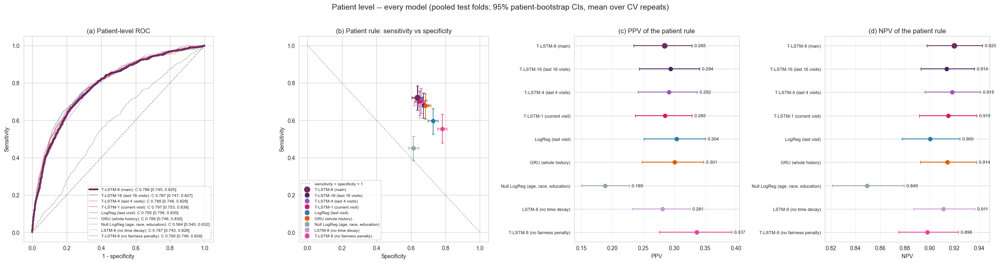

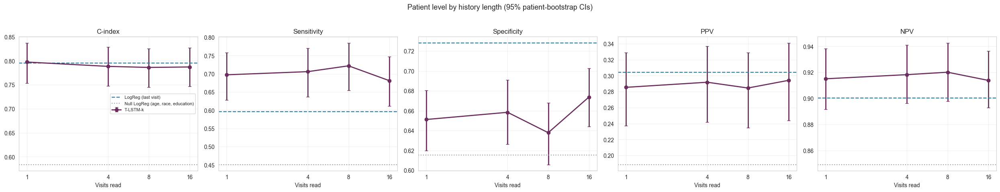

,C-index,Sensitivity,Specificity,PPV,NPV
T-LSTM-1 (current visit),"0.797 [0.753, 0.838]","0.697 [0.627, 0.758]","0.651 [0.620, 0.681]","0.285 [0.237, 0.329]","0.915 [0.892, 0.938]"
T-LSTM-4 (last 4 visits),"0.788 [0.748, 0.828]","0.706 [0.636, 0.770]","0.658 [0.626, 0.691]","0.292 [0.242, 0.337]","0.918 [0.896, 0.941]"
T-LSTM-8 (main),"0.786 [0.745, 0.825]","0.722 [0.655, 0.785]","0.638 [0.606, 0.668]","0.285 [0.235, 0.329]","0.920 [0.898, 0.943]"
T-LSTM-16 (last 16 visits),"0.787 [0.747, 0.827]","0.681 [0.611, 0.747]","0.674 [0.644, 0.703]","0.294 [0.244, 0.341]","0.914 [0.893, 0.936]"
LogReg (last visit),"0.795 [0.756, 0.835]","0.596 [0.525, 0.663]","0.728 [0.699, 0.757]","0.304 [0.252, 0.350]","0.900 [0.878, 0.924]"
"Null LogReg (age, race, education)","0.584 [0.540, 0.632]","0.451 [0.384, 0.516]","0.615 [0.586, 0.645]","0.189 [0.151, 0.227]","0.849 [0.821, 0.879]"


In [39]:
"""Patient level, every model side by side (revised_v27; each model's own four patient-level figures are in its
section): (a) ROC of the patient probability, (b) sensitivity vs specificity, (c) PPV and (d) NPV of the patient rule
(value and 95% patient-bootstrap CI from each model's patient table); then the patient metrics of the T-LSTM by the
number of visits read (1, 4, 8, 16), with the LogReg and the null LogReg as references."""
_pm = [m for m in MODEL_RESULTS if MODEL_RESULTS[m].get("patient_table") is not None]


def _pt_metric(m, key):
    t_ = MODEL_RESULTS[m]["patient_table"]
    return float(t_.loc[key, "Value"]), float(t_.loc[key, "CI low"]), float(t_.loc[key, "CI high"])


fig, axes = plt.subplots(1, 4, figsize=(25, 6.4), gridspec_kw={"width_ratios": [1.15, 1.15, 1, 1]})
for m in _pm:
    arrs = level_arrays(m, MODEL_RESULTS[m]["preds"], "patient")
    y_, p_ = np.concatenate([a[0] for a in arrs]), np.concatenate([a[1] for a in arrs])
    fpr, tpr, _ = roc_curve(y_, p_)
    v, lo, hi = _pt_metric(m, "c_index")
    axes[0].plot(fpr, tpr, **model_style(m), label=f"{mlab(m)}: C {v:.3f} [{lo:.3f}, {hi:.3f}]")
axes[0].plot([0, 1], [0, 1], "k:", alpha=0.5)
axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("Sensitivity"); axes[0].set_title("(a) Patient-level ROC")
axes[0].legend(fontsize=7.5, loc="lower right")
for m in _pm:
    s, sl, sh = _pt_metric(m, "sensitivity")
    p, pl, ph = _pt_metric(m, "specificity")
    main = m in MAIN_PLOT_MODELS
    axes[1].errorbar(p, s, xerr=[[p - pl], [ph - p]], yerr=[[s - sl], [sh - s]], fmt="o", ms=10 if main else 7,
                     color=CV_COLORS.get(m, "#444444"), capsize=3, lw=2 if main else 1.2, label=mlab(m))
_g = np.linspace(0, 1, 50)
axes[1].plot(_g, 1 - _g, "k:", alpha=0.4, label="sensitivity + specificity = 1")
axes[1].set_xlabel("Specificity"); axes[1].set_ylabel("Sensitivity")
axes[1].set_title("(b) Patient rule: sensitivity vs specificity"); axes[1].legend(fontsize=7.5, loc="lower left")
for ax, key, title in [(axes[2], "ppv", "(c) PPV of the patient rule"), (axes[3], "npv", "(d) NPV of the patient rule")]:
    for i_, m in enumerate(_pm):
        v, lo, hi = _pt_metric(m, key)
        ax.errorbar(v, i_, xerr=[[v - lo], [hi - v]], fmt="o", ms=9 if m in MAIN_PLOT_MODELS else 7,
                    color=CV_COLORS.get(m, "#444444"), capsize=3)
        ax.text(hi, i_, f"  {v:.3f}", va="center", fontsize=8)
    ax.set_yticks(range(len(_pm))); ax.set_yticklabels([mlab(m) for m in _pm], fontsize=8)
    ax.invert_yaxis(); ax.set_title(title); ax.set_xlabel(key.upper()); ax.grid(axis="x", alpha=0.3)
plt.suptitle("Patient level -- every model (pooled test folds; 95% patient-bootstrap CIs, mean over CV repeats)",
             y=1.02, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_patient_level_all_models.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- by history length: the T-LSTM on the last 1, 4, 8 and 16 visits; the LogRegs as references
_lb = [m for m in OBJ1_WINDOW_MODELS if m in _pm]
if len(_lb) >= 2:
    _keys = [("c_index", "C-index"), ("sensitivity", "Sensitivity"), ("specificity", "Specificity"), ("ppv", "PPV"),
             ("npv", "NPV")]
    fig, axes = plt.subplots(1, len(_keys), figsize=(5 * len(_keys), 4.6))
    xs = np.array([WINDOW_OF[m] for m in _lb])
    for ax, (key, lab_) in zip(axes, _keys):
        V = np.array([_pt_metric(m, key) for m in _lb])
        ax.errorbar(xs, V[:, 0], yerr=[V[:, 0] - V[:, 1], V[:, 2] - V[:, 0]], fmt="o-", color=CV_COLORS["LSTM"],
                    capsize=3, lw=2, label="T-LSTM-k")
        for ref, ls in [("LogReg", "--"), ("LogRegNull", ":")]:
            if ref in _pm:
                ax.axhline(_pt_metric(ref, key)[0], color=CV_COLORS.get(ref, "gray"), ls=ls, lw=1.6, label=mlab(ref))
        ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels([str(int(x)) for x in xs])
        ax.set_xlabel("Visits read"); ax.set_title(lab_); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8)
    plt.suptitle("Patient level by history length (95% patient-bootstrap CIs)", y=1.03, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_patient_level_by_window.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    display(pd.DataFrame({mlab(m): {lab_: "{:.3f} [{:.3f}, {:.3f}]".format(*_pt_metric(m, k)) for k, lab_ in _keys}
                          for m in _lb + [r for r in ("LogReg", "LogRegNull") if r in _pm]}).T)

## 11.11.9 Patient-level calibration and decision curve — all models

Smoothed calibration of the patient probability for every model, the patient-level ROC curves, and the patient-level
decision curve (net benefit of flagging patients above a probability threshold, against flagging everyone or no one).

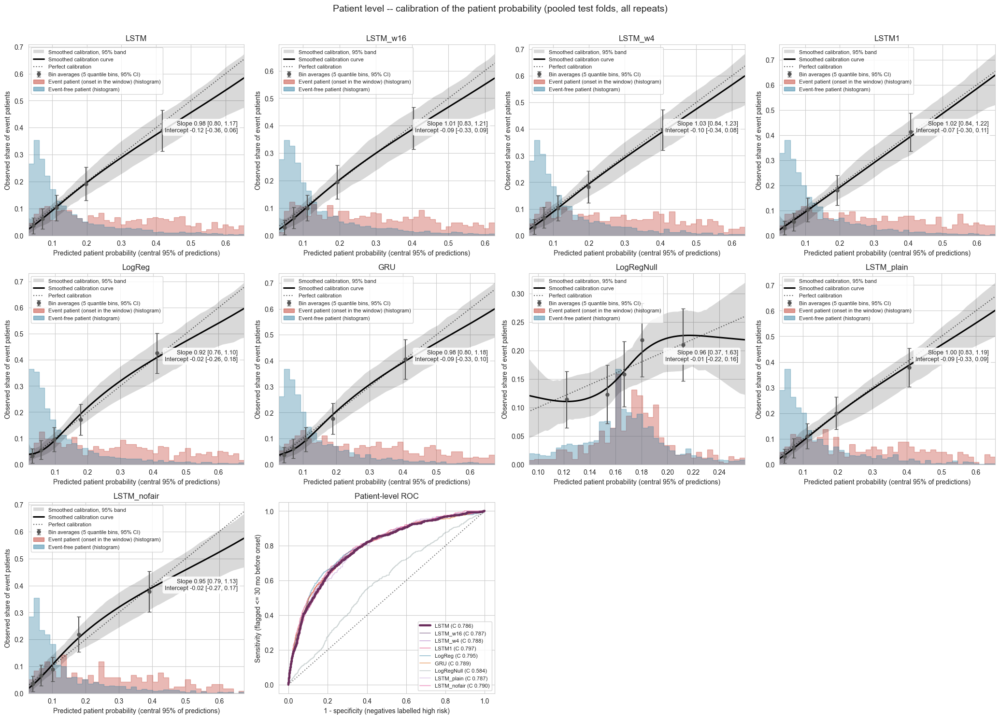

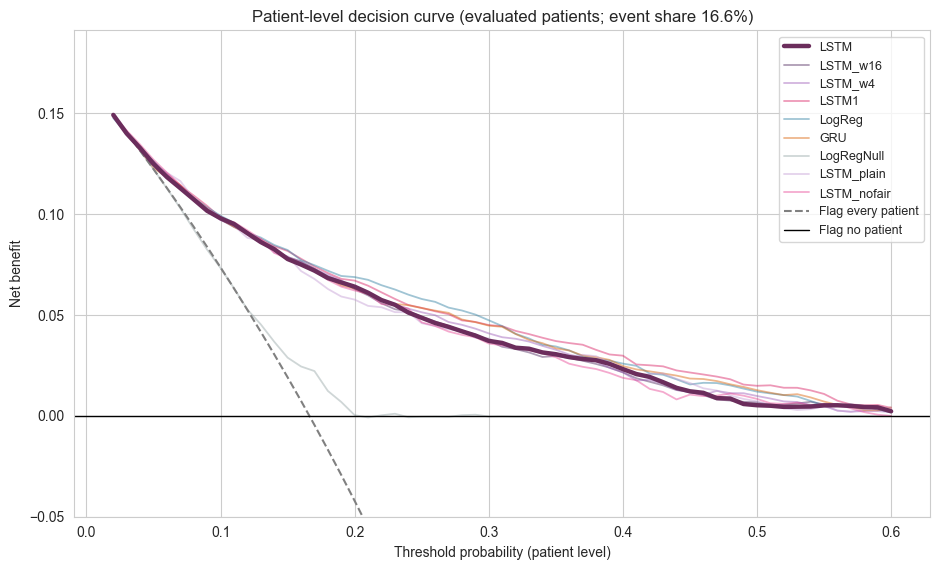

In [40]:
"""Patient-level calibration of every model (quintiles of the recalibrated patient probability, all repeats stacked,
with the slope and intercept of its table) and the patient-level ROC curves of all models."""
fig, axes = plt.subplots(_nrows, _ncols, figsize=(5.2 * _ncols, 4.9 * _nrows))
axes = axes.ravel()
for ax, m in zip(axes, _ms):
    plot_calibration(ax, m, MODEL_RESULTS[m]["preds"], "patient", MODEL_RESULTS[m]["patient_table"], title=m)
ax = axes[len(_ms)]
for m, r in MODEL_RESULTS.items():
    arrs = level_arrays(m, r["preds"], "patient")
    y, p = np.concatenate([a[0] for a in arrs]), np.concatenate([a[1] for a in arrs])
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, **model_style(m),
            label=f"{m} (C {r['patient_table'].loc['c_index', 'Value']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.5)
ax.set_xlabel("1 - specificity (negatives labelled high risk)"); ax.set_ylabel("Sensitivity (flagged <= 30 mo before onset)")
ax.set_title("Patient-level ROC"); ax.legend(fontsize=8, loc="lower right")
for ax in axes[len(_ms) + 1:]:
    ax.set_visible(False)
plt.suptitle("Patient level -- calibration of the patient probability (pooled test folds, all repeats)", y=1.01,
             fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_calibration_patient_all.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# patient-level decision curve (TRIPOD+AI items 12e and 15, clinical usefulness): net benefit of flagging patients whose patient
# probability is >= a threshold, mean over CV repeats, against flagging everyone or no one
fig, ax = plt.subplots(figsize=(9.5, 5.8))
_pts = np.linspace(0.02, 0.6, 59)
for m, r in MODEL_RESULTS.items():
    _arrs = level_arrays(m, r["preds"], "patient")
    _nb = np.mean([ipcw_net_benefit(y, p, w, _pts)[0] for y, p, w, _, _ in _arrs], axis=0)
    ax.plot(_pts, _nb, label=m, **model_style(m))
_y0, _p0, _w0 = _arrs[0][:3]
ax.plot(_pts, ipcw_net_benefit(_y0, _p0, _w0, _pts)[1], color="gray", ls="--", label="Flag every patient")
ax.axhline(0, color="black", lw=1, label="Flag no patient")
_prev = float(_y0.mean())
ax.set_ylim(-0.05, _prev * 1.15)
ax.set_xlabel("Threshold probability (patient level)"); ax.set_ylabel("Net benefit")
ax.set_title(f"Patient-level decision curve (evaluated patients; event share {_prev:.1%})")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_decision_curve_patient.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

## 11.11.10 Performance by subgroup (sex, race, age, calendar era)

TRIPOD+AI item 14: every model's C-index, calibration-in-the-large, sensitivity and specificity by sex, race and age band, at
the visit and the patient level, from the same pooled out-of-fold predictions as the main tables.

In [41]:
"""
Performance by subgroup (TRIPOD+AI item 14, fairness): sex, race, age band and calendar era, at the visit and the patient level, for
the compared models (SUBGROUP_MODELS: T-LSTM-8, T-LSTM-1, LogReg,
Cox). Same pooled out-of-fold predictions and thresholds as the main tables; each subgroup is simply a subset
of the evaluated visits / patients (for patients: all event and event-free patients in that subgroup). 95% CIs from
SUBGROUP_BOOT patient-cluster bootstrap resamples. Calibration-in-the-large (intercept) shows whether a subgroup's risk
is systematically over- (negative) or under-estimated (positive). Small subgroups have wide intervals.
"""
SUBGROUP_BOOT = 50 if SMOKE else 200
_ERA_LAB = np.array([e[2] for e in ERA_BANDS])[np.digitize(CAL_YEAR_ALL, [b[1] for b in ERA_BANDS[:-1]])]
LAND_ATTR["era"] = _ERA_LAB                                           # visit level: era of the landmark visit
PT_ATTR["era"] = (pd.DataFrame({"pid": PID_ALL, "d": pd.to_datetime(land["visit_date"]).values, "era": _ERA_LAB})
                  .sort_values("d").groupby("pid")["era"].last().reindex(PT_ATTR.index))   # patient: last landmark
SUBGROUPS = [("sex", v) for v in ["Female", "Male"]] + \
            [("race", v) for v in ["White", "Black", "Asian (Chinese, Filipino)", "Other / not recorded"]] + \
            [("age", lab) for _, _, lab in AGE_BANDS] + [("era", e[2]) for e in ERA_BANDS]
SUBGROUP_METRICS = ["c_index", "cal_intercept", "sensitivity", "specificity"]


def _cell(t, k):
    v = t.loc[k]
    return f"{v['Value']:.3f} [{v['CI low']:.3f}, {v['CI high']:.3f}]" if np.isfinite(v["Value"]) else "n/a"


def subgroup_table(level):
    rows = []
    for attr, val in SUBGROUPS:
        for m, r in ((m_, MODEL_RESULTS[m_]) for m_ in SUBGROUP_MODELS if m_ in MODEL_RESULTS):
            arrs = level_arrays(m, r["preds"], level, sub=(attr, val))
            n_pos, n_neg = int(arrs[0][0].sum()), int((arrs[0][0] == 0).sum())
            if n_pos == 0 or n_neg == 0:
                continue
            t = metric_table(m, r["preds"], level, n_boot=SUBGROUP_BOOT, arrs=arrs)
            rows.append({"Attribute": attr, "Subgroup": val, "Model": m,
                         ("Onsets <= 30 mo / resolved visits" if level == "visit" else "Event / event-free patients"):
                             f"{n_pos} / {n_pos + n_neg}" if level == "visit" else f"{n_pos} / {n_neg}",
                         **{t.loc[k, "Metric"]: _cell(t, k) for k in SUBGROUP_METRICS}})
    return pd.DataFrame(rows).set_index(["Attribute", "Subgroup", "Model"])


t0 = time.time()
fairness_visit = subgroup_table("visit")
print("VISIT LEVEL by subgroup (30-month onset, IPCW; value [95% CI]):")
display(fairness_visit)
fairness_patient = subgroup_table("patient")
print("\nPATIENT LEVEL by subgroup (30-month windows; value [95% CI]):")
display(fairness_patient)
pd.concat({"visit": fairness_visit, "patient": fairness_patient}).to_csv("subgroup_performance_model_revised_v27.csv")
print(f"({time.time() - t0:.0f}s)")

VISIT LEVEL by subgroup (30-month onset, IPCW; value [95% CI]):


Onsets <= 30 mo / resolved visits  \
Attribute Subgroup                  Model                                           
sex       Female                    LSTM                              573 / 12847   
                                    LSTM_nofair                       573 / 12847   
                                    LSTM_plain                        573 / 12847   
                                    LSTM1                             573 / 12847   
                                    LogReg                            573 / 12847   
                                    LogRegNull                        573 / 12847   
                                    GRU                               573 / 12847   
          Male                      LSTM                                53 / 1492   
                                    LSTM_nofair                         53 / 1492   
                                    LSTM_plain                          53 / 1492   
                                    LSTM1                               53 / 1492   
                                    LogReg                              53 / 1492   
                                    LogRegNull                          53 / 1492   
                                    GRU                                 53 / 1492   
race      White                     LSTM                               392 / 9026   
                                    LSTM_nofair                        392 / 9026   
                                    LSTM_plain                         392 / 9026   
                                    LSTM1                              392 / 9026   
                                    LogReg                             392 / 9026   
                                    LogRegNull                         392 / 9026   
                                    GRU                                392 / 9026   
          Black                     LSTM                               137 / 2089   
                                    LSTM_nofair                        137 / 2089   
                                    LSTM_plain                         137 / 2089   
                                    LSTM1                              137 / 2089   
                                    LogReg                             137 / 2089   
                                    LogRegNull                         137 / 2089   
                                    GRU                                137 / 2089   
          Asian (Chinese, Filipino) LSTM                                84 / 2262   
                                    LSTM_nofair                         84 / 2262   
                                    LSTM_plain                          84 / 2262   
                                    LSTM1                               84 / 2262   
                                    LogReg                              84 / 2262   
                                    LogRegNull                          84 / 2262   
                                    GRU                                 84 / 2262   
          Other / not recorded      LSTM                                 13 / 962   
                                    LSTM_nofair                          13 / 962   
                                    LSTM_plain                           13 / 962   
                                    LSTM1                                13 / 962   
                                    LogReg                               13 / 962   
                                    LogRegNull                           13 / 962   
                                    GRU                                  13 / 962   
age       < 40                      LSTM                               262 / 6483   
                                    LSTM_nofair                        262 / 6483   
                                    LSTM_plain                         262 / 6483   
                                    LSTM1            


PATIENT LEVEL by subgroup (30-month windows; value [95% CI]):


Event / event-free patients  \
Attribute Subgroup                  Model                                     
sex       Female                    LSTM                          128 / 614   
                                    LSTM_nofair                   128 / 614   
                                    LSTM_plain                    128 / 614   
                                    LSTM1                         128 / 614   
                                    LogReg                        128 / 614   
                                    LogRegNull                    128 / 614   
                                    GRU                           128 / 614   
          Male                      LSTM                            10 / 78   
                                    LSTM_nofair                     10 / 78   
                                    LSTM_plain                      10 / 78   
                                    LSTM1                           10 / 78   
                                    LogReg                          10 / 78   
                                    LogRegNull                      10 / 78   
                                    GRU                             10 / 78   
race      White                     LSTM                           87 / 407   
                                    LSTM_nofair                    87 / 407   
                                    LSTM_plain                     87 / 407   
                                    LSTM1                          87 / 407   
                                    LogReg                         87 / 407   
                                    LogRegNull                     87 / 407   
                                    GRU                            87 / 407   
          Black                     LSTM                            29 / 91   
                                    LSTM_nofair                     29 / 91   
                                    LSTM_plain                      29 / 91   
                                    LSTM1                           29 / 91   
                                    LogReg                          29 / 91   
                                    LogRegNull                      29 / 91   
                                    GRU                             29 / 91   
          Asian (Chinese, Filipino) LSTM                           16 / 112   
                                    LSTM_nofair                    16 / 112   
                                    LSTM_plain                     16 / 112   
                                    LSTM1                          16 / 112   
                                    LogReg                         16 / 112   
                                    LogRegNull                     16 / 112   
                                    GRU                            16 / 112   
          Other / not recorded      LSTM                             6 / 82   
                                    LSTM_nofair                      6 / 82   
                                    LSTM_plain                       6 / 82   
                                    LSTM1                            6 / 82   
                                    LogReg                           6 / 82   
                                    LogRegNull                       6 / 82   
                                    GRU                              6 / 82   
age       < 40                      LSTM                           58 / 309   
                                    LSTM_nofair                    58 / 309   
                                    LSTM_plain                     58 / 309   
                                    LSTM1                          58 / 309   
                                    LogReg                         58 / 309   
                                    LogRegNull                     58 / 309   
                                    GRU                            58 / 309   
          40-49    

(458s)


## 11.11.10b Race: performance gaps and what the fairness penalty does

Section 6.1. For every model in `FAIR_MODELS`, the visit-level AUROC, O/E, sensitivity and specificity (at the model's
own era-standardised alarm threshold) in each race group, and four **gaps** over the three groups with enough onsets
(White, Black, Asian; the "other / not recorded" group has about 13 onsets and is shown but not used in the gaps):

* **equal opportunity** — the largest minus the smallest sensitivity;
* **false-alarm gap** — the largest minus the smallest 1 − specificity (with equal opportunity: equalized odds);
* **AUROC gap** — the largest minus the smallest AUROC;
* **calibration gap** — the largest |log O/E| (0 = calibrated in every group).

Each gap has a 95 % patient-cluster bootstrap CI, and T-LSTM-8's gap is compared with every other model's on the same
resamples and the CV repeats both completed (negative = T-LSTM-8 has the smaller gap). The penalty's effect is
T-LSTM-8 against T-LSTM-8 without it.

Visit level by race (30-month onset, IPCW; mean over CV repeats):


Onsets / resolved visits  \
Model                              Race                                                 
T-LSTM-8 (main)                    White                                   392 / 9026   
                                   Black                                   137 / 2089   
                                   Asian (Chinese, Filipino)                84 / 2262   
                                   Other / not recorded                      13 / 962   
T-LSTM-8 (no fairness penalty)     White                                   392 / 9026   
                                   Black                                   137 / 2089   
                                   Asian (Chinese, Filipino)                84 / 2262   
                                   Other / not recorded                      13 / 962   
LSTM-8 (no time decay)             White                                   392 / 9026   
                                   Black                                   137 / 2089   
                                   Asian (Chinese, Filipino)                84 / 2262   
                                   Other / not recorded                      13 / 962   
LogReg (last visit)                White                                   392 / 9026   
                                   Black                                   137 / 2089   
                                   Asian (Chinese, Filipino)                84 / 2262   
                                   Other / not recorded                      13 / 962   
Null LogReg (age, race, education) White                                   392 / 9026   
                                   Black                                   137 / 2089   
                                   Asian (Chinese, Filipino)                84 / 2262   
                                   Other / not recorded                      13 / 962   
GRU (whole history)                White                                   392 / 9026   
                                   Black                                   137 / 2089   
                                   Asian (Chinese, Filipino)                84 / 2262   
                                   Other / not recorded                      13 / 962   

                                                              AUROC    O/E  \
Model                              Race                                      
T-LSTM-8 (main)                    White                      0.713  0.938   
                                   Black                      0.778  1.204   
                                   Asian (Chinese, Filipino)  0.708  0.789   
                                   Other / not recorded       0.755  0.282   
T-LSTM-8 (no fairness penalty)     White                      0.704  0.962   
                                   Black                      0.780  1.096   
                                   Asian (Chinese, Filipino)  0.681  1.065   
                                   Other / not recorded       0.722  0.433   
LSTM-8 (no time decay)             White                      0.707  0.963   
                                   Black                      0.779  1.232   
                                   Asian (Chinese, Filipino)  0.686  0.818   
                                   Other / not recorded       0.734  0.284   
LogReg (last visit)                White                      0.701  0.989   
                                   Black                      0.748  1.029   
                                   Asian (Chinese, Filipino)  0.706  1.101   
                                   Other / not recorded       0.714  0.446   
Null LogReg (age, race, education) White                      0.568  0.984   
                                   Black                      0.532  1.021   
                                   Asian (Chinese, Filipino)  0.405  1.103   
                                   Other / not recorded       0.223  0.499   
GRU (whole history)           


Gaps over White / Black / Asian, value [95% patient-cluster bootstrap CI, 300 resamples]:


,Equal opportunity (sensitivity gap),False-alarm gap (1 - specificity),AUROC gap,Calibration gap (max |log O/E|)
Model,,,,
T-LSTM-8 (main),"0.306 [0.204, 0.476]","0.153 [0.080, 0.241]","0.071 [0.027, 0.253]","0.238 [0.108, 0.878]"
T-LSTM-8 (no fairness penalty),"0.500 [0.363, 0.698]","0.246 [0.169, 0.327]","0.099 [0.029, 0.267]","0.092 [0.090, 0.631]"
LSTM-8 (no time decay),"0.364 [0.282, 0.624]","0.170 [0.083, 0.265]","0.093 [0.032, 0.284]","0.209 [0.093, 0.854]"
LogReg (last visit),"0.557 [0.401, 0.713]","0.380 [0.299, 0.471]","0.047 [0.015, 0.220]","0.097 [0.063, 0.648]"
"Null LogReg (age, race, education)","0.913 [0.831, 0.970]","0.927 [0.899, 0.954]","0.163 [0.056, 0.276]","0.098 [0.076, 0.687]"
GRU (whole history),"0.298 [0.208, 0.520]","0.134 [0.059, 0.220]","0.064 [0.024, 0.257]","0.193 [0.095, 0.837]"



T-LSTM-8's gap minus each model's, same resamples, repeats both completed (negative = T-LSTM-8 has the smaller gap):


,Repeats,Equal opportunity (sensitivity gap),False-alarm gap (1 - specificity),AUROC gap,Calibration gap (max |log O/E|)
Comparison,,,,,
T-LSTM-8 - T-LSTM-8 (no fairness penalty),2,"-0.163 [-0.283, -0.041]","-0.100 [-0.164, -0.030]","+0.006 [-0.031, +0.044]","+0.138 [-0.296, +0.320]"
T-LSTM-8 - LSTM-8 (no time decay),2,"-0.027 [-0.164, +0.005]","-0.023 [-0.045, +0.005]","+0.012 [-0.020, +0.030]","+0.021 [-0.032, +0.051]"
T-LSTM-8 - LogReg (last visit),5,"-0.251 [-0.376, -0.083]","-0.227 [-0.288, -0.151]","+0.024 [-0.031, +0.071]","+0.141 [-0.329, +0.361]"
"T-LSTM-8 - Null LogReg (age, race, education)",5,"-0.607 [-0.727, -0.409]","-0.774 [-0.856, -0.678]","-0.092 [-0.196, +0.088]","+0.139 [-0.339, +0.389]"
T-LSTM-8 - GRU (whole history),5,"+0.009 [-0.095, +0.045]","+0.019 [-0.001, +0.042]","+0.007 [-0.024, +0.031]","+0.044 [-0.042, +0.068]"


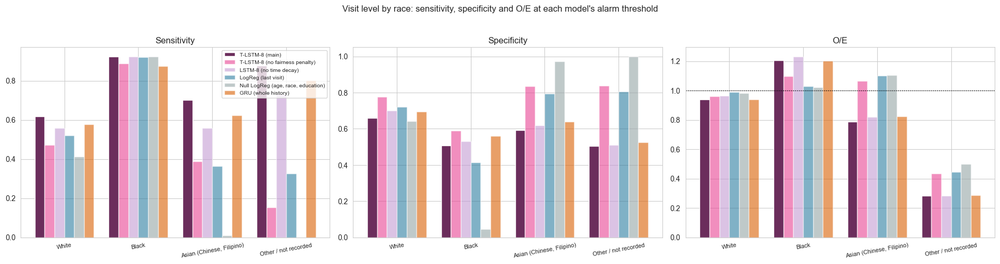

In [42]:
"""Race fairness (revised_v27, Section 6.1): per model and race group, visit-level AUROC, O/E, sensitivity and
specificity; the equal-opportunity, false-alarm, AUROC and calibration gaps over White / Black / Asian with 95%
patient-cluster bootstrap CIs; and each model's gap minus T-LSTM-8's on the repeats both completed (paired resamples)."""
FAIR_BOOT = 50 if SMOKE else 300
_KK30 = IPCW[PRIMARY_HORIZON_MONTHS][1] > 0
_RACE30 = LAND_ATTR["race"][_KK30]
_CODES30 = np.unique(LAND_CODE[_KK30])
_POS30 = np.searchsorted(_CODES30, LAND_CODE[_KK30])
GAP_NAMES = ["Equal opportunity (sensitivity gap)", "False-alarm gap (1 - specificity)", "AUROC gap",
             "Calibration gap (max |log O/E|)"]


def _fair_arrays(m, reps=None):
    """{repeat: (y, p, w, alert)} over the resolved 30-month landmarks."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    out = {}
    for (mm, r), pr in MODEL_RESULTS[m]["preds"].items():
        if mm == m and (reps is None or r in reps):
            p = pr["P"][:, PRIMARY_COL]
            out[r] = (y[_KK30], p[_KK30], w[_KK30], (p >= pr["visit_thr"]["target"])[_KK30])
    return out


def _grp_metrics(y, p, w, a):
    k = w > 0
    y, p, w, a = y[k], p[k], w[k], a[k]
    w1, w0 = w[y == 1].sum(), w[y == 0].sum()
    if w1 <= 0 or w0 <= 0:
        return [np.nan] * 4
    return [roc_auc_score(y, p, sample_weight=w), float(np.sum(w * y) / np.sum(w * p)),
            float(np.sum(w * (y == 1) * a) / w1), float(np.sum(w * (y == 0) * ~a) / w0)]


def _fair_stats(arrs, mult=None):
    """(groups, 4) AUROC, O/E, sensitivity, specificity per race group, mean over the repeats in arrs."""
    S = []
    for y, p, w, a in arrs.values():
        ww = w if mult is None else w * mult[_POS30]
        S.append([_grp_metrics(y[_RACE30 == g], p[_RACE30 == g], ww[_RACE30 == g], a[_RACE30 == g])
                  for g in FAIR_GROUP_LABELS])
    return np.nanmean(np.array(S, float), axis=0)


def _gaps(st):
    G = st[:3]                                                     # White, Black, Asian
    return np.array([np.nanmax(G[:, 2]) - np.nanmin(G[:, 2]), np.nanmax(1 - G[:, 3]) - np.nanmin(1 - G[:, 3]),
                     np.nanmax(G[:, 0]) - np.nanmin(G[:, 0]), np.nanmax(np.abs(np.log(G[:, 1])))])


_fm = [m for m in FAIR_MODELS if m in MODEL_RESULTS]
if not _fm:
    print("No model of FAIR_MODELS has run yet.")
else:
    rng_ = np.random.RandomState(SEED)
    MULTS = [np.bincount(rng_.randint(0, len(_CODES30), len(_CODES30)), minlength=len(_CODES30)).astype(float)
             for _ in range(FAIR_BOOT)]
    rows, gap_rows, diff_rows = [], [], []
    for m in _fm:
        arrs = _fair_arrays(m)
        st = _fair_stats(arrs)
        for gi, g in enumerate(FAIR_GROUP_LABELS):
            rows.append({"Model": mlab(m), "Race": g, "Onsets / resolved visits":
                         f"{int(next(iter(arrs.values()))[0][_RACE30 == g].sum())} / {int((_RACE30 == g).sum())}",
                         "AUROC": st[gi, 0], "O/E": st[gi, 1], "Sensitivity": st[gi, 2], "Specificity": st[gi, 3]})
        B = np.array([_gaps(_fair_stats(arrs, mu)) for mu in MULTS])
        g0 = _gaps(st)
        gap_rows.append({"Model": mlab(m), **{n: f"{g0[i]:.3f} [{np.nanpercentile(B[:, i], 2.5):.3f}, "
                                                  f"{np.nanpercentile(B[:, i], 97.5):.3f}]" for i, n in enumerate(GAP_NAMES)}})
        if m != "LSTM" and "LSTM" in _fm:
            reps = sorted({r for (mm, r) in MODEL_RESULTS["LSTM"]["preds"] if mm == "LSTM"}
                          & {r for (mm, r) in MODEL_RESULTS[m]["preds"] if mm == m})
            if reps:
                a_m, a_l = _fair_arrays(m, reps), _fair_arrays("LSTM", reps)
                D0 = _gaps(_fair_stats(a_l)) - _gaps(_fair_stats(a_m))
                DB = np.array([_gaps(_fair_stats(a_l, mu)) - _gaps(_fair_stats(a_m, mu)) for mu in MULTS])
                diff_rows.append({"Comparison": f"T-LSTM-8 - {mlab(m)}", "Repeats": len(reps),
                                  **{n: f"{D0[i]:+.3f} [{np.nanpercentile(DB[:, i], 2.5):+.3f}, "
                                        f"{np.nanpercentile(DB[:, i], 97.5):+.3f}]" for i, n in enumerate(GAP_NAMES)}})
    FAIR_BY_GROUP = pd.DataFrame(rows).set_index(["Model", "Race"])
    FAIR_GAPS = pd.DataFrame(gap_rows).set_index("Model")
    FAIR_DIFFS = pd.DataFrame(diff_rows).set_index("Comparison") if diff_rows else pd.DataFrame()
    print("Visit level by race (30-month onset, IPCW; mean over CV repeats):")
    display(FAIR_BY_GROUP.round(3))
    print(f"\nGaps over White / Black / Asian, value [95% patient-cluster bootstrap CI, {FAIR_BOOT} resamples]:")
    display(FAIR_GAPS)
    if not FAIR_DIFFS.empty:
        print("\nT-LSTM-8's gap minus each model's, same resamples, repeats both completed (negative = T-LSTM-8 has the "
              "smaller gap):")
        display(FAIR_DIFFS)
    fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
    xg = np.arange(len(FAIR_GROUP_LABELS))
    wbar = 0.8 / len(_fm)
    for j, m in enumerate(_fm):
        st = FAIR_BY_GROUP.loc[mlab(m)]
        for ax, col in zip(axes, ["Sensitivity", "Specificity", "O/E"]):
            ax.bar(xg + (j - (len(_fm) - 1) / 2) * wbar, st[col].values, wbar, color=CV_COLORS.get(m, "#444444"),
                   alpha=1.0 if m in MAIN_PLOT_MODELS else 0.6, label=mlab(m))
    for ax, col in zip(axes, ["Sensitivity", "Specificity", "O/E"]):
        ax.set_xticks(xg); ax.set_xticklabels(FAIR_GROUP_LABELS, fontsize=8, rotation=10); ax.set_title(col)
        if col == "O/E":
            ax.axhline(1, color="black", ls=":", lw=1)
    axes[0].legend(fontsize=7.5)
    plt.suptitle("Visit level by race: sensitivity, specificity and O/E at each model's alarm threshold", y=1.03)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_fairness_by_race.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    pd.concat({"by_group": FAIR_BY_GROUP.reset_index(), "gaps": FAIR_GAPS.reset_index(),
               "differences": FAIR_DIFFS.reset_index()}).to_csv("fairness_by_race_revised_v27.csv")

## 11.11.11 Conclusion — Objective 1

Printed from this run's estimates (Sections 11.11.1–11.11.10).

In [43]:
"""Conclusion of Objective 1, written from this run's estimates (Sections 11.11.1-11.11.10)."""
if model_res("LSTM") is None:
    txt = "Objective 1 could not be assessed: T-LSTM-8 has not run."
else:
    _v = lambda m, k, lv="visit": core_value(m, k, lv)
    txt = ("T-LSTM-8 at the visit level (30 months): " + ", ".join(f"{CORE_LABEL[k]} {fmt_v(_v('LSTM', k))}"
                                                               for k in ["auroc", "c_index"]) + "; "
           "at the patient level (" + PATIENT_RULE_TEXT + "): " + ", ".join(
               f"{CORE_LABEL[k]} {fmt_v(_v('LSTM', k, 'patient'))}" for k in ["auroc", "sensitivity", "specificity"]) + ". ")
    if not o1_h1a.empty:
        txt += ("H1a, against the Baseline without clinical variables: " + "; ".join(
            f"{lv} level: {verdict_words(o1_h1a, 'T-LSTM-8 - Baseline', lv)}" for lv in ("visit", "patient")
            if verdict_words(o1_h1a, "T-LSTM-8 - Baseline", lv)) + ". ")
    _hl = mlab("LSTM")
    if _hl in h3a.index:
        txt += (f"H1b: calibration slope {h3a.loc[_hl, 'Calibration slope [95% CI]']}, intercept "
                f"{h3a.loc[_hl, 'Calibration intercept [95% CI]']}, so the criterion is "
                f"{'met' if h3a.loc[_hl, 'Both'] else 'not met'}. ")
    if "LSTM" in LEAD:
        e_, l_, u_ = LEAD["LSTM"]
        txt += (f"H1c: flagged event patients were flagged a median {e_[0]:.1f} months [{l_[0]:.1f}, {u_[0]:.1f}] "
                f"before onset (criterion {'met' if l_[0] >= LEAD_TIME_MIN_MONTHS else 'not met'}); {e_[2]:.0%} of all "
                f"event patients were flagged at least {LEAD_TIME_MIN_MONTHS} months ahead. ")
    if "LSTM" in H3B_ABOVE:
        _ab = H3B_ABOVE["LSTM"]
        txt += (f"H1d: the net benefit is above alarming at every visit and at none at {int(_ab.sum())} of "
                f"{len(DCA_GRID)} thresholds from {DCA_RANGE[0]:.0%} to {DCA_RANGE[1]:.0%} "
                f"(criterion {'met' if _ab.all() else 'not met'}). ")
    if not tier_df.empty:
        _t = tier_df[tier_df["Model"] == mlab("LSTM")]
        if len(_t):
            hi_, lo_ = _t.iloc[-1], _t.iloc[0]
            txt += (f"Risk tiers: {hi_['Share of visits']:.0%} of visits are in the top tier ({hi_['Tier (30-month risk)']}), "
                    f"where {hi_['Observed (IPCW)']:.1%} had an onset within 30 months, against {lo_['Observed (IPCW)']:.1%} "
                    f"in the bottom tier ({lo_['Share of visits']:.0%} of visits). ")
    txt += ("These are internal (cross-validated) estimates; the transport to later calendar years is the temporal "
            "validation (Section 11.16.1). Associations are predictive, not causal.")
OBJ_CONCLUSIONS["Objective 1"] = txt
print(textwrap.fill(txt, 118))

T-LSTM-8 at the visit level (30 months): AUROC 0.730 [0.679, 0.773], C-index 0.732 [0.683, 0.774]; at the patient
level (2 alarms in a row in the 24-month window (event patients: before onset; event-free patients: the last months of
follow-up with a known 30-month outcome)): AUROC 0.787 [0.745, 0.828], Sensitivity 0.722 [0.664, 0.783], Specificity
0.638 [0.606, 0.666]. H1a, against the Baseline without clinical variables: visit level: better on AUROC, C-index,
Sensitivity, Balanced accuracy; worse on Specificity; patient level: better on Sensitivity, Balanced accuracy; no
clear difference on AUROC, Specificity. H1b: calibration slope 1.066 [0.858, 1.294], intercept -0.097 [-0.309, 0.087],
so the criterion is met. H1c: flagged event patients were flagged a median 12.6 months [10.3, 15.4] before onset
(criterion met); 53% of all event patients were flagged at least 6 months ahead. H1d: the net benefit is above
alarming at every visit and at none at 31 of 31 thresholds from 2% to 10% (cri

---
# 11.12 Objective 2 — How much complexity does the prediction need? The primary test: T-LSTM-8 against the LogReg

The **primary test** (Section 11.12.0): T-LSTM-8 against the competing-risk LogReg on the visit-level AUROC. Then, as
secondary results: the main model against the current visit alone and the GRU, shorter and longer visit histories,
subgroups, and how accuracy holds from 6 to 48 months ahead.

| | Hypothesis | Comparison | Success criterion |
|---|---|---|---|
| **H2a (primary)** | T-LSTM-8 discriminates better than the LogReg | T-LSTM-8 − LogReg, visit-level IPCW AUROC at 30 months | superior: lower 95 % bound > 0; equivalent: CI within ±0.02; inferior: upper bound < 0; else inconclusive |
| **H2a** | Complexity and architecture | T-LSTM-8 − LogReg (other metrics, patient level), T-LSTM-8 − T-LSTM-1, T-LSTM-1 − LogReg, GRU − LogReg, T-LSTM-8 − GRU; five metrics, visit and patient level | Lower 95 % bound > 0 (per metric); equivalence: AUROC / C-index 95 % CI within ±0.02 |
| **H2b** | More visit history improves prediction | Slope of each metric per doubling of the visits read (k = 1, 4, 8, 16) | Lower 95 % bound > 0 (per metric) |
| **H2c** | Accuracy is higher close to the visit than further ahead | AUROC in months 0–12 − months 36–48 (exclusive intervals, landmarks at risk at the start) | Lower 95 % bound > 0 |
| **H2d** | ML helps in pre-specified subgroups | T-LSTM-8 − LogReg, GRU − LogReg with ≥ 18 prior visits, irregular visits, a recent flare (visit level) | Lower 95 % bound > 0 |

Descriptive: every model on every metric, static vs longitudinal models by horizon and history length, the
trajectory screen, the cumulative horizons 6–48 months and their 6 − 48 difference, and the slope of the interval AUROC
per year.

## 11.12.0 Primary test: T-LSTM-8 against the LogReg

The pre-specified **primary test** of revised_v27 (Section 8.1): the visit-level competing-risk IPCW AUROC of the
30-month risk, T-LSTM-8 minus the competing-risk LogReg, on identical folds and the same 1,000 patient-cluster bootstrap
resamples (mean over the 5 CV repeats). **Superior** when the lower 95 % bound is above 0, **inferior** when the upper
bound is below 0, **equivalent** when the whole CI lies within ±0.02, otherwise **inconclusive**. Then, as secondary
results, the other four metrics at the visit level, the patient level and the era-stratified ΔAUROC (case–control pairs
from the same calendar era only).

In [44]:
"""Primary test (Section 8.1): T-LSTM-8 - LogReg, visit-level IPCW AUROC at 30 months; secondary metrics after it."""
PRIMARY_RESULT = None
_pa, _pb = PRIMARY_PAIR
if model_res(_pa) is None or model_res(_pb) is None or not (oof(_pa) and oof(_pb)):
    print("Primary test skipped: run Sections 11.10.1 and 11.10.4 first.")
else:
    d = core_delta(_pa, _pb, "auroc", "visit")
    va, vb = core_value(_pa, "auroc", "visit"), core_value(_pb, "auroc", "visit")
    sup, inf = d["CI low"] > 0, d["CI high"] < 0
    eqv = (d["CI low"] > -EQUIV_MARGIN) and (d["CI high"] < EQUIV_MARGIN)
    verdict = ("superior" if sup else "inferior" if inf else "equivalent" if eqv else "inconclusive")
    if sup and eqv:
        verdict = "superior (and within the equivalence margin)"
    PRIMARY_RESULT = {"Delta": d, "verdict": verdict, "AUROC a": va, "AUROC b": vb}
    print("PRIMARY TEST -- visit-level IPCW AUROC at 30 months")
    print(f"  {mlab(_pa)}: {fmt_v(va)}")
    print(f"  {mlab(_pb)}: {fmt_v(vb)}")
    print(f"  Difference ({mlab(_pa)} - {mlab(_pb)}): {fmt_d(d)} ({d['Repeats']} paired CV repeats, {HYP_BOOT} "
          f"patient-cluster bootstrap resamples; share of resamples > 0: {d['Share of resamples > 0']:.3f})")
    print(f"  Verdict: {verdict.upper()} (superior: lower bound > 0; equivalent: CI within +-{EQUIV_MARGIN}; "
          "inferior: upper bound < 0; otherwise inconclusive)")
    OBJ_ROWS.append({"Hypothesis": "H2a (primary)", "Comparison": f"{mlab(_pa)} - {mlab(_pb)}", "Level": "visit",
                     "Metric": "AUROC", "Estimate [95% CI]": fmt_d(d),
                     "Criterion": f"superior: lower bound > 0; equivalent: CI within +-{EQUIV_MARGIN}",
                     "Met": bool(sup), "Verdict": verdict})
    _sec = pd.concat([delta_long([(_pa, _pb, f"{mlab(_pa)} - {mlab(_pb)}")], lv) for lv in ("visit", "patient")],
                     ignore_index=True)
    _sec = _sec[~((_sec["Level"] == "visit") & (_sec["key"] == "auroc"))]
    print("\nSecondary -- the other metrics (visit level) and the patient level, oriented paired difference [95% CI] "
          "(> 0 favours T-LSTM-8; * = lower bound > 0):")
    display(delta_wide(_sec))
    _es = paired_delta(_pa, _pb, era_strat=True)
    if _es is not None:
        print(f"Secondary -- era-stratified Delta AUROC (case-control pairs within a calendar era): {fmt_d(_es)}; "
              f"{mlab(_pa)} {_es['AUROC a']:.3f}, {mlab(_pb)} {_es['AUROC b']:.3f}")
    pd.DataFrame([{"Comparison": f"{mlab(_pa)} - {mlab(_pb)}", "AUROC a": va["Value"], "AUROC b": vb["Value"],
                   "Delta": d["Delta"], "CI low": d["CI low"], "CI high": d["CI high"],
                   "Share of resamples > 0": d["Share of resamples > 0"], "Repeats": d["Repeats"], "Verdict": verdict,
                   "Era-stratified Delta": _es["Delta"] if _es else np.nan,
                   "Era-stratified CI low": _es["CI low"] if _es else np.nan,
                   "Era-stratified CI high": _es["CI high"] if _es else np.nan}]).to_csv(
        "primary_test_revised_v27.csv", index=False)

PRIMARY TEST -- visit-level IPCW AUROC at 30 months
  T-LSTM-8 (main): 0.730 [0.679, 0.773]
  LogReg (last visit): 0.719 [0.670, 0.763]
  Difference (T-LSTM-8 (main) - LogReg (last visit)): +0.010 [-0.004, +0.023] (5 paired CV repeats, 1000 patient-cluster bootstrap resamples; share of resamples > 0: 0.926)
  Verdict: INCONCLUSIVE (superior: lower bound > 0; equivalent: CI within +-0.02; inferior: upper bound < 0; otherwise inconclusive)

Secondary -- the other metrics (visit level) and the patient level, oriented paired difference [95% CI] (> 0 favours T-LSTM-8; * = lower bound > 0):


Metric                                                           AUROC  \
Comparison                            Level                              
T-LSTM-8 (main) - LogReg (last visit) visit                        NaN   
                                      patient  -0.010 [-0.024, +0.004]   

Metric                                                         C-index  \
Comparison                            Level                              
T-LSTM-8 (main) - LogReg (last visit) visit    +0.008 [-0.006, +0.020]   
                                      patient                      NaN   

Metric                                                       Sensitivity  \
Comparison                            Level                                
T-LSTM-8 (main) - LogReg (last visit) visit    +0.118 [+0.083, +0.159] *   
                                      patient  +0.126 [+0.085, +0.168] *   

Metric                                                     Specificity  \
Comparison                            Level                              
T-LSTM-8 (main) - LogReg (last visit) visit    -0.077 [-0.093, -0.062]   
                                      patient  -0.090 [-0.111, -0.069]   

Metric                                                 Balanced accuracy  \
Comparison                            Level                                
T-LSTM-8 (main) - LogReg (last visit) visit    +0.021 [+0.002, +0.042] *   
                                      patient    +0.018 [-0.005, +0.042]   

Metric                                        Lower bound > 0 on  
Comparison                            Level                       
T-LSTM-8 (main) - LogReg (last visit) visit       2 of 4 metrics  
                                      patient     1 of 4 metrics

Secondary -- era-stratified Delta AUROC (case-control pairs within a calendar era): +0.011 [-0.007, +0.028]; T-LSTM-8 (main) 0.700, LogReg (last visit) 0.689


## 11.12.1 The main model, the current visit alone and the LogReg side by side: five metrics, visit and patient level

Each Objective 2 model on the five metrics, value [95 % patient-cluster bootstrap CI], at the visit level (30-month
onset, IPCW) and the patient level (Section 11.6 rule); how every metric changes with the number of visits the LSTM
reads (the LogReg on the last visit as a reference line); and what the history adds (T-LSTM-8 − T-LSTM-1, every metric)
by the number of clinic visits the patient already had.


OBJECTIVE 2, COMPLEXITY -- VISIT LEVEL (30-month onset, IPCW, every landmark visit): value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at the cost-weighted alarm threshold


,Visits read,CV repeats,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy
T-LSTM-1 (current visit),1,5,"0.729 [0.678, 0.772]","0.733 [0.683, 0.773]","0.704 [0.628, 0.768]","0.596 [0.564, 0.623]","0.650 [0.612, 0.682]"
T-LSTM-4 (last 4 visits),4,5,"0.728 [0.677, 0.771]","0.731 [0.681, 0.772]","0.685 [0.610, 0.753]","0.634 [0.604, 0.662]","0.660 [0.621, 0.694]"
T-LSTM-8 (main),8,5,"0.730 [0.679, 0.773]","0.732 [0.683, 0.774]","0.702 [0.628, 0.767]","0.617 [0.586, 0.644]","0.659 [0.621, 0.694]"
T-LSTM-16 (last 16 visits),16,5,"0.727 [0.678, 0.770]","0.730 [0.682, 0.771]","0.652 [0.577, 0.719]","0.656 [0.627, 0.682]","0.654 [0.615, 0.688]"
LogReg (last visit),1,5,"0.719 [0.670, 0.763]","0.724 [0.677, 0.766]","0.583 [0.508, 0.654]","0.694 [0.665, 0.722]","0.639 [0.601, 0.673]"



OBJECTIVE 2, COMPLEXITY -- PATIENT LEVEL (visit alarms accumulated per patient, Section 11.6 rule; C-index = AUROC for this binary outcome): value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at the cost-weighted alarm threshold


,Visits read,CV repeats,AUROC,Sensitivity,Specificity,Balanced accuracy
T-LSTM-1 (current visit),1,5,"0.798 [0.757, 0.838]","0.697 [0.634, 0.763]","0.651 [0.620, 0.679]","0.674 [0.639, 0.710]"
T-LSTM-4 (last 4 visits),4,5,"0.788 [0.747, 0.830]","0.706 [0.642, 0.774]","0.658 [0.627, 0.688]","0.682 [0.646, 0.718]"
T-LSTM-8 (main),8,5,"0.787 [0.745, 0.828]","0.722 [0.664, 0.783]","0.638 [0.606, 0.666]","0.680 [0.646, 0.715]"
T-LSTM-16 (last 16 visits),16,5,"0.787 [0.747, 0.829]","0.681 [0.619, 0.747]","0.674 [0.643, 0.703]","0.677 [0.642, 0.713]"
LogReg (last visit),1,5,"0.797 [0.754, 0.837]","0.596 [0.529, 0.669]","0.728 [0.699, 0.754]","0.662 [0.623, 0.700]"


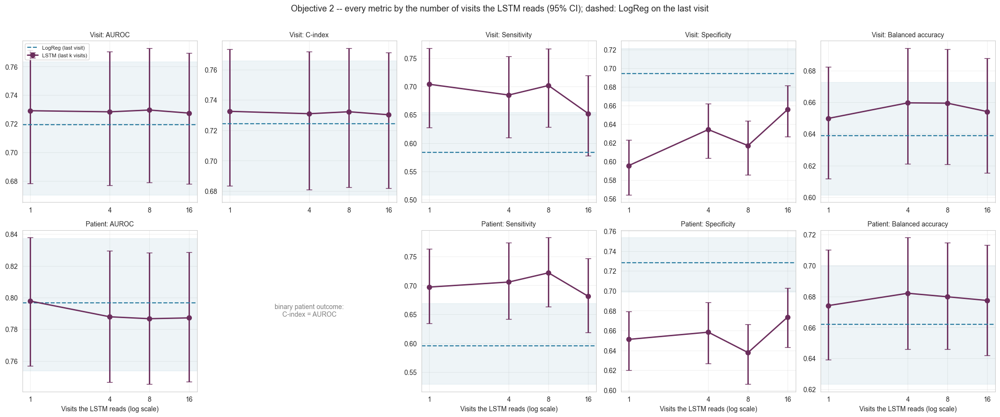


LSTM-8 - T-LSTM-1 (visit level, 30 months) by the number of clinic visits before the landmark -- oriented difference [95% CI] on every metric (descriptive):


,Landmarks,Onsets <= 30 mo,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy
Prior clinic visits,,,,,,,
0,783,50,"-0.013 [-0.025, -0.001]","-0.012 [-0.023, -0.001]","+0.080 [+0.032, +0.138]","-0.163 [-0.180, -0.145]","-0.041 [-0.067, -0.012]"
1-3,2127,105,"-0.003 [-0.018, +0.012]","-0.003 [-0.017, +0.010]","+0.073 [+0.037, +0.118]","-0.092 [-0.104, -0.082]","-0.009 [-0.029, +0.013]"
4-7,2456,78,"+0.013 [-0.005, +0.031]","+0.012 [-0.005, +0.028]","+0.010 [-0.025, +0.049]","+0.021 [+0.011, +0.032]","+0.015 [-0.002, +0.036]"
8-15,3848,129,"+0.008 [-0.006, +0.025]","+0.007 [-0.007, +0.023]","-0.022 [-0.075, +0.022]","+0.043 [+0.033, +0.053]","+0.011 [-0.016, +0.034]"
>=16,7637,264,"-0.001 [-0.014, +0.010]","-0.002 [-0.014, +0.010]","-0.041 [-0.073, -0.009]","+0.059 [+0.046, +0.073]","+0.009 [-0.009, +0.025]"


In [45]:
"""
Objective 2 side by side (Section 8.1): the LSTM on 1, 4, 8 and 16 visits and the LogReg on the last visit.
  1. visit- and patient-level tables, one row per model, the five metrics (value [95% patient-bootstrap CI]);
  2. every metric against the number of visits the LSTM reads (the dose-response behind H2b);
  3. T-LSTM-8 - T-LSTM-1 on every visit-level metric by the number of prior clinic visits (descriptive).
"""

OBJ1_HAVE = [m for m in OBJ1_MODELS if model_res(m) is not None and oof(m)]
O1_TABLES = {}
for level in ("visit", "patient"):
    t = value_table(OBJ1_HAVE, level)
    t.insert(0, "Visits read", [WINDOW_OF[m] for m in OBJ1_HAVE])
    t.insert(1, "CV repeats", [len(oof(m)) for m in OBJ1_HAVE])
    O1_TABLES[level] = t
    print(f"\nOBJECTIVE 2, COMPLEXITY -- {level.upper()} LEVEL ("
          + ("30-month onset, IPCW, every landmark visit" if level == "visit" else
             "visit alarms accumulated per patient, Section 11.6 rule; C-index = AUROC for this binary outcome")
          + "): value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at the "
            "cost-weighted alarm threshold")
    display(t)

# ---- every metric by the number of visits the LSTM reads (visit level top, patient level bottom)
fig, axes = plt.subplots(2, len(CORE_METRICS), figsize=(4.2 * len(CORE_METRICS), 8.6))
for i_, level in enumerate(("visit", "patient")):
    for j_, (k, lab_) in enumerate(CORE_METRICS):
        ax = axes[i_, j_]
        if k not in LEVEL_METRICS[level]:
            ax.text(0.5, 0.5, "binary patient outcome:\nC-index = AUROC", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.axis("off")
            continue
        xs, vs = [], []
        for m in [x for x in OBJ1_WINDOW_MODELS if x in OBJ1_HAVE]:
            v = core_value(m, k, level)
            if v is not None:
                xs.append(WINDOW_OF[m]); vs.append(v)
        if xs:
            mu = np.array([v["Value"] for v in vs])
            lo, hi = np.array([v["CI low"] for v in vs]), np.array([v["CI high"] for v in vs])
            ax.errorbar(xs, mu, yerr=[mu - lo, hi - mu], fmt="-o", capsize=4, color=CV_COLORS["LSTM"], lw=2, ms=7,
                        label="LSTM (last k visits)")
        v = core_value("LogReg", k, level) if "LogReg" in OBJ1_HAVE else None
        if v is not None:
            ax.axhline(v["Value"], color=CV_COLORS["LogReg"], ls="--", lw=1.6, label="LogReg (last visit)")
            ax.axhspan(v["CI low"], v["CI high"], color=CV_COLORS["LogReg"], alpha=0.08)
        ax.set_xscale("log", base=2); ax.set_xticks([1, 4, 8, 16]); ax.set_xticklabels(["1", "4", "8", "16"])
        ax.set_title(f"{level.capitalize()}: {lab_}" + (" (lower = better)" if k == "brier" else ""), fontsize=10)
        ax.grid(alpha=0.3)
        if i_ == 1:
            ax.set_xlabel("Visits the LSTM reads (log scale)")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Objective 2 -- every metric by the number of visits the LSTM reads (95% CI); dashed: LogReg on the last "
             "visit", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective1_dose_response.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- what the history adds by the number of prior clinic visits: T-LSTM-8 - T-LSTM-1 on every visit-level metric
PRIOR_BINS = [(0, 0, "0"), (1, 3, "1-3"), (4, 7, "4-7"), (8, 15, "8-15"), (16, 10 ** 6, ">=16")]
o1_prior = pd.DataFrame()
if all(x in OBJ1_HAVE for x in ("LSTM", "LSTM1")):
    _rows = []
    for lo_, hi_, lab_ in PRIOR_BINS:
        mask = (LAND_POS >= lo_) & (LAND_POS <= hi_)
        n_ev = int(((Y30 == 1) & (W30 > 0) & mask).sum())
        row = {"Prior clinic visits": lab_, "Landmarks": int(mask.sum()), "Onsets <= 30 mo": n_ev}
        if n_ev > 0:
            for k in LEVEL_METRICS["visit"]:
                row[CORE_LABEL[k]] = fmt_d(core_delta("LSTM", "LSTM1", k, mask=mask, tag=f"prior{lab_}"))
        _rows.append(row)
    o1_prior = pd.DataFrame(_rows).set_index("Prior clinic visits")
    print("\nLSTM-8 - T-LSTM-1 (visit level, 30 months) by the number of clinic visits before the landmark -- oriented "
          "difference [95% CI] on every metric (descriptive):")
    display(o1_prior)
    o1_prior.to_csv("objective1_by_prior_visits_revised_v27.csv")
for level, t in O1_TABLES.items():
    t.to_csv(f"objective1_{level}_level_revised_v27.csv")


## 11.12.2 H2a and H2b: complexity and history length, and the within-patient secondary estimands

**H2a:** the main model against the simpler ones — T-LSTM-8 vs T-LSTM-1 (the same network reading only the current
visit), vs the competing-risk LogReg and vs the cause-specific Cox, and T-LSTM-1 vs the LogReg — on each of the six
metrics, at the visit and the patient level; per metric, the criterion is a lower 95 % bound of the oriented paired
difference above 0. Because "the simpler model is as good" is an answer to this objective too, the AUROC and C-index
differences are also judged against an **equivalence margin of ±0.02**: equivalent when the whole 95 % CI lies inside
it. **H2b:** the least-squares slope of each metric over the LSTM reading the last 1, 4, 8 and 16 visits, **per
doubling of the history** (log₂ k, so the four windows weigh equally); criterion: a lower 95 % bound above 0. Then the
within-patient secondary estimands: the AUROC of the 12-month change in predicted risk, and the case-minus-placebo
concordance of rising risk.

H2a -- the main model against the simpler ones, and every machine-learning model against the LogReg on every metric: oriented paired difference [95% patient-cluster bootstrap CI, 1000 resamples] (> 0 favours the first model); * = lower bound > 0:


Metric                                                                    AUROC  \
Comparison                                   Level                                
T-LSTM-8 - LogReg                            visit      +0.010 [-0.004, +0.023]   
                                             patient    -0.010 [-0.024, +0.004]   
T-LSTM-8 - T-LSTM-1                          visit      +0.000 [-0.009, +0.009]   
                                             patient    -0.011 [-0.021, -0.001]   
T-LSTM-1 - LogReg                            visit      +0.010 [-0.002, +0.023]   
                                             patient    +0.001 [-0.011, +0.013]   
GRU - LogReg                                 visit      +0.008 [-0.005, +0.022]   
                                             patient    -0.007 [-0.022, +0.006]   
T-LSTM-8 - GRU                               visit      +0.002 [-0.006, +0.010]   
                                             patient    -0.003 [-0.010, +0.004]   
T-LSTM-8 - LSTM-8 (time decay)               visit      +0.002 [-0.004, +0.008]   
                                             patient    +0.001 [-0.004, +0.006]   
T-LSTM-8 - T-LSTM-8 without fairness penalty visit      -0.001 [-0.013, +0.011]   
                                             patient    -0.002 [-0.013, +0.010]   
T-LSTM-8 - Null LogReg                       visit    +0.149 [+0.077, +0.221] *   
                                             patient  +0.199 [+0.136, +0.265] *   
LogReg - Null LogReg                         visit    +0.139 [+0.073, +0.205] *   
                                             patient  +0.209 [+0.151, +0.272] *   

Metric                                                                  C-index  \
Comparison                                   Level                                
T-LSTM-8 - LogReg                            visit      +0.008 [-0.006, +0.020]   
                                             patient                        NaN   
T-LSTM-8 - T-LSTM-1                          visit      -0.000 [-0.009, +0.008]   
                                             patient                        NaN   
T-LSTM-1 - LogReg                            visit      +0.008 [-0.003, +0.021]   
                                             patient                        NaN   
GRU - LogReg                                 visit      +0.006 [-0.007, +0.019]   
                                             patient                        NaN   
T-LSTM-8 - GRU                               visit      +0.002 [-0.006, +0.009]   
                                             patient                        NaN   
T-LSTM-8 - LSTM-8 (time decay)               visit      +0.002 [-0.003, +0.008]   
                                             patient                        NaN   
T-LSTM-8 - T-LSTM-8 without fairness penalty visit      -0.001 [-0.012, +0.011]   
                                             patient                        NaN   
T-LSTM-8 - Null LogReg                       visit    +0.152 [+0.082, +0.222] *   
                                             patient                        NaN   
LogReg - Null LogReg                         visit    +0.144 [+0.081, +0.209] *   
                                             patient                        NaN   

Metric                                                              Sensitivity  \
Comparison                                   Level                                
T-LSTM-8 - LogReg                            visit    +0.118 [+0.083, +0.159] *   
                                             patient  +0.126 [+0.085, +0.168] *   
T-LSTM-8 - T-LSTM-1                          visit      -0.002 [-0.027, +0.019]   
                                             patient    +0.025 [-0.006, +0.057]   
T-LSTM-1 - LogReg                            visit    +0.121 [+0.087, +0.159] *   
                                             patient  +0.101 [+0.063, +0.142] *   
GRU - LogReg  


H2a, equivalence -- AUROC and C-index differences with their 95% CI; equivalent when the whole CI lies within +-0.02:


Difference [95% CI]  \
Comparison                                   Level   Metric                             
T-LSTM-8 - LogReg                            visit   AUROC    +0.010 [-0.004, +0.023]   
                                                     C-index  +0.008 [-0.006, +0.020]   
T-LSTM-8 - T-LSTM-1                          visit   AUROC    +0.000 [-0.009, +0.009]   
                                                     C-index  -0.000 [-0.009, +0.008]   
T-LSTM-1 - LogReg                            visit   AUROC    +0.010 [-0.002, +0.023]   
                                                     C-index  +0.008 [-0.003, +0.021]   
GRU - LogReg                                 visit   AUROC    +0.008 [-0.005, +0.022]   
                                                     C-index  +0.006 [-0.007, +0.019]   
T-LSTM-8 - GRU                               visit   AUROC    +0.002 [-0.006, +0.010]   
                                                     C-index  +0.002 [-0.006, +0.009]   
T-LSTM-8 - LSTM-8 (time decay)               visit   AUROC    +0.002 [-0.004, +0.008]   
                                                     C-index  +0.002 [-0.003, +0.008]   
T-LSTM-8 - T-LSTM-8 without fairness penalty visit   AUROC    -0.001 [-0.013, +0.011]   
                                                     C-index  -0.001 [-0.012, +0.011]   
T-LSTM-8 - Null LogReg                       visit   AUROC    +0.149 [+0.077, +0.221]   
                                                     C-index  +0.152 [+0.082, +0.222]   
LogReg - Null LogReg                         visit   AUROC    +0.139 [+0.073, +0.205]   
                                                     C-index  +0.144 [+0.081, +0.209]   
T-LSTM-8 - LogReg                            patient AUROC    -0.010 [-0.024, +0.004]   
T-LSTM-8 - T-LSTM-1                          patient AUROC    -0.011 [-0.021, -0.001]   
T-LSTM-1 - LogReg                            patient AUROC    +0.001 [-0.011, +0.013]   
GRU - LogReg                                 patient AUROC    -0.007 [-0.022, +0.006]   
T-LSTM-8 - GRU                               patient AUROC    -0.003 [-0.010, +0.004]   
T-LSTM-8 - LSTM-8 (time decay)               patient AUROC    +0.001 [-0.004, +0.006]   
T-LSTM-8 - T-LSTM-8 without fairness penalty patient AUROC    -0.002 [-0.013, +0.010]   
T-LSTM-8 - Null LogReg                       patient AUROC    +0.199 [+0.136, +0.265]   
LogReg - Null LogReg                         patient AUROC    +0.209 [+0.151, +0.272]   

                                                              Within +-margin  
Comparison                                   Level   Metric                    
T-LSTM-8 - LogReg                            visit   AUROC              False  
                                                     C-index            False  
T-LSTM-8 - T-LSTM-1                          visit   AUROC               True  
                                                     C-index             True  
T-LSTM-1 - LogReg                            visit   AUROC              False  
                                                     C-index            False  
GRU - LogReg                                 visit   AUROC              False  
                                                     C-index             True  
T-LSTM-8 - GRU                               visit   AUROC               True  
                                                     C-index             True  
T-LSTM-8 - LSTM-8 (time decay)               visit   AUROC               True  
                                                     C-index             True  
T-LSTM-8 - T-LSTM-8 without fairness penalty visit   AUROC               True  
                                                     C-index             True  
T-LSTM-8 - Null LogReg                       visit   AUROC              False  
                                                     C-index            False  
LogReg - Null LogReg                        

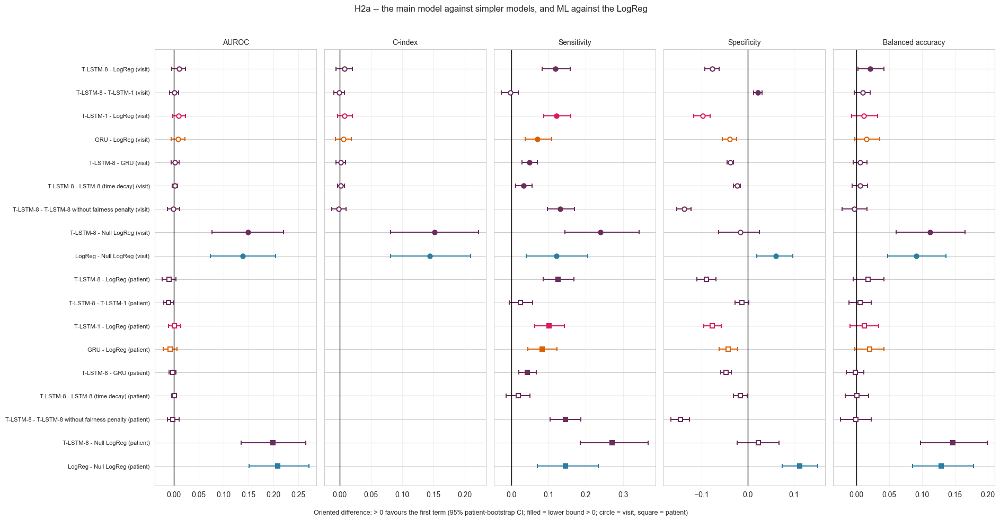


H2b -- each metric of the LSTM on the last k visits and its least-squares slope per doubling of the history (log2 k; oriented: > 0 = improves with more visits), repeats all 4 completed:


k = 1   k = 4   k = 8  k = 16  \
Level   Metric                                              
visit   AUROC              0.7291  0.7284  0.7296  0.7275   
        C-index            0.7325  0.7309  0.7322  0.7302   
        Sensitivity        0.7038  0.6848  0.7017  0.6521   
        Specificity        0.5957  0.6344  0.6171  0.6561   
        Balanced accuracy  0.6498  0.6596  0.6594  0.6541   
patient AUROC              0.7978  0.7879  0.7867  0.7872   
        Sensitivity        0.6971  0.7058  0.7217  0.6812   
        Specificity        0.6512  0.6584  0.6379  0.6737   
        Balanced accuracy  0.6741  0.6821  0.6798  0.6774   

                          Slope per doubling [95% CI]  Lower bound > 0  \
Level   Metric                                                           
visit   AUROC              -0.0003 [-0.0030, +0.0020]            False   
        C-index            -0.0004 [-0.0030, +0.0017]            False   
        Sensitivity        -0.0100 [-0.0166, -0.0038]            False   
        Specificity        +0.0128 [+0.0103, +0.0154]             True   
        Balanced accuracy  +0.0014 [-0.0024, +0.0045]            False   
patient AUROC              -0.0028 [-0.0052, -0.0003]            False   
        Sensitivity        -0.0013 [-0.0088, +0.0070]            False   
        Specificity        +0.0032 [-0.0004, +0.0068]            False   
        Balanced accuracy  +0.0009 [-0.0033, +0.0052]            False   

                           Repeats  
Level   Metric                      
visit   AUROC                    5  
        C-index                  5  
        Sensitivity              5  
        Specificity              5  
        Balanced accuracy        5  
patient AUROC                    5  
        Sensitivity              5  
        Specificity              5  
        Balanced accuracy        5

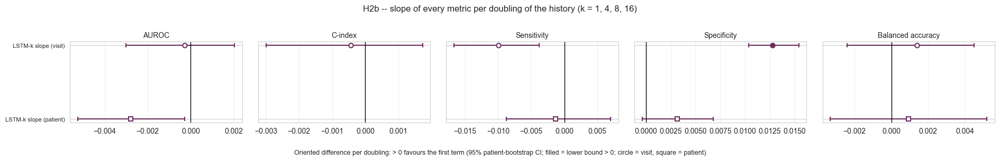


WITHIN-PATIENT SECONDARY ESTIMANDS OF OBJECTIVE 1 (descriptive; 95% CIs, no success criterion):


,AUROC a,AUROC b,Delta,CI low,CI high,Share of resamples > 0,Repeats
"Change-in-risk AUROC, T-LSTM-8 - T-LSTM-1",0.5499,0.5491,0.0008,-0.0222,0.0200,0.539,5.0
"Within-patient case - placebo concordance, T-LSTM-8 - T-LSTM-1",NaN,NaN,0.0171,-0.0170,0.0487,0.860,5.0



Detail -- within-patient concordance P(risk at a visit <= 30 months before onset > risk at an earlier visit), 76 event patients vs 339 risk-set placebo controls (pseudo-onset at the case's years since the first employed visit, same calendar era):


,Cases: P(near > far),Placebo: P(near > far),Case - placebo,CI low,CI high
Model,,,,,
T-LSTM-1 (current visit),0.4357,0.2929,0.1429,0.0793,0.2087
T-LSTM-4 (last 4 visits),0.4030,0.2399,0.1631,0.0973,0.2320
T-LSTM-8 (main),0.3788,0.2188,0.1600,0.0917,0.2250
T-LSTM-16 (last 16 visits),0.3702,0.2127,0.1575,0.0910,0.2238
LogReg (last visit),0.3976,0.2856,0.1120,0.0529,0.1772


In [46]:
"""
Objective 2 (Section 8.1), complexity and history, on the five metrics (secondary to the primary test, 11.12.0):
  H2a  T-LSTM-8 vs the LogReg (its visit AUROC is the primary test, Section 11.12.0), vs T-LSTM-1 (the same network on
       the current visit alone) and vs the GRU; T-LSTM-1 and the GRU vs the LogReg -- oriented paired differences at the
       visit and the patient level; criterion per metric: lower 95% bound > 0 (the first model is better).
       Equivalence (AUROC and C-index): the 95% CI of the difference lies within +-EQUIV_MARGIN.
  H2b  least-squares slope of each metric on log2(k), k = 1, 4, 8, 16 visits read (per doubling of the history), on
       the repeats all four completed, the same resamples for every k; criterion per metric: lower 95% bound > 0.
Then the within-patient secondary estimands (descriptive).
"""
_have2 = lambda m: model_res(m) is not None and bool(oof(m))
_pairs = [p for p in H2A_PAIRS if _have2(p[0]) and _have2(p[1])]
h2a = (pd.concat([delta_long(_pairs, level) for level in ("visit", "patient")], ignore_index=True) if _pairs
       else pd.DataFrame())
if h2a.empty:
    print("H2a skipped: the compared models have no common completed repeat.")
else:
    print(f"H2a -- the main model against the simpler ones, and every machine-learning model against the LogReg "
          f"on every metric: oriented paired difference [95% "
          f"patient-cluster bootstrap CI, {HYP_BOOT} resamples] (> 0 favours the first model); "
          "* = lower bound > 0:")
    display(delta_wide(h2a))
    _eq = h2a[h2a["key"].isin(["auroc", "c_index"])].copy()
    _eq["Within +-margin"] = (_eq["CI low"] > -EQUIV_MARGIN) & (_eq["CI high"] < EQUIV_MARGIN)
    print(f"\nH2a, equivalence -- AUROC and C-index differences with their 95% CI; equivalent when the whole CI lies "
          f"within +-{EQUIV_MARGIN}:")
    display(_eq.assign(**{"Difference [95% CI]": [fmt_d(r) for _, r in _eq.iterrows()]})
            .set_index(["Comparison", "Level", "Metric"])[["Difference [95% CI]", "Within +-margin"]])
    forest_metrics(h2a, "H2a -- the main model against simpler models, and ML against the LogReg",
                   "revised_v27_h2a_forest.png")
    record("H2a", h2a)
    for _, r in _eq.iterrows():
        OBJ_ROWS.append({"Hypothesis": "H2a (equivalence)", "Comparison": r["Comparison"], "Level": r["Level"],
                         "Metric": r["Metric"], "Estimate [95% CI]": fmt_d(r), "Criterion": f"95% CI within +-{EQUIV_MARGIN}",
                         "Met": bool(r["Within +-margin"])})

H2B_MODELS = [m for m in OBJ1_WINDOW_MODELS if m in OBJ1_HAVE]
K_ = np.array([WINDOW_OF[m] for m in H2B_MODELS], float)
_rows = []
if len(H2B_MODELS) >= 3:
    kc = np.log2(K_) - np.log2(K_).mean()
    for level in ("visit", "patient"):
        reps = common_reps(H2B_MODELS, level)
        if not reps:
            continue
        for k in LEVEL_METRICS[level]:
            V = np.array([_cols(m, k, level, reps=reps) for m in H2B_MODELS])          # (k values, 1 + B)
            S = CORE_SIGN[k] * (kc @ (V - V.mean(0))) / (kc @ kc)
            lo, hi = _ci(S)
            _rows.append({"Comparison": "slope per doubling of the history", "a": "LSTM", "b": "", "Level": level,
                          "Metric": CORE_LABEL[k], "key": k, "Delta": float(S[0]), "CI low": lo, "CI high": hi,
                          "Share of resamples > 0": float(np.nanmean(S[1:] > 0)), "Repeats": len(reps),
                          "Lower bound > 0": bool(lo > 0),
                          **{f"k = {int(x)}": float(v) for x, v in zip(K_, V[:, 0])}})
h2b = pd.DataFrame(_rows)
if h2b.empty:
    print("\nH2b skipped: fewer than three window models have run.")
else:
    _show = h2b.set_index(["Level", "Metric"])
    _show = _show[[c for c in _show.columns if c.startswith("k = ")]].round(4).assign(
        **{"Slope per doubling [95% CI]": [fmt_d(r, 4) for _, r in h2b.iterrows()],
           "Lower bound > 0": h2b["Lower bound > 0"].values, "Repeats": h2b["Repeats"].values})
    print(f"\nH2b -- each metric of the LSTM on the last k visits and its least-squares slope per doubling of the "
          f"history (log2 k; oriented: > 0 = improves with more visits), repeats all "
          f"{len(H2B_MODELS)} completed:")
    display(_show)
    forest_metrics(h2b.assign(Comparison="LSTM-k slope"), "H2b -- slope of every metric per doubling of the history (k = "
                   + ", ".join(str(int(x)) for x in K_) + ")", "revised_v27_h2b_forest.png", nd_label=" per doubling")
    record("H2b", h2b, crit="lower 95% bound of the slope > 0", nd=4)
pd.concat([h2a, h2b], ignore_index=True).to_csv("objective2_complexity_tests_revised_v27.csv", index=False)


o1_sec = {}


# ---- change in risk: the 12-month change in predicted log-odds (vs the landmark 9-15 months earlier, nearest to 12 months)
def _prior_12m():
    out = np.full(len(land), -1)
    d = pd.to_datetime(land["visit_date"]).values
    for _, idx in land.groupby("pid").indices.items():
        t = d[idx]
        for j in range(len(idx)):
            dt = (t[j] - t[:j]) / np.timedelta64(1, "D")
            c = np.flatnonzero((dt >= 270) & (dt <= 460))
            if len(c):
                out[idx[j]] = idx[c[np.argmin(np.abs(dt[c] - 365))]]
    return out


PRIOR_12M = _prior_12m()
HAS_PRIOR = PRIOR_12M >= 0
change = lambda m: {r: np.where(HAS_PRIOR, _logit(p) - _logit(p[np.maximum(PRIOR_12M, 0)]), 0.0) for r, p in oof(m).items()}
if oof("LSTM") and oof("LSTM1"):
    d = paired_delta("LSTM", "LSTM1", scores_a=change("LSTM"), scores_b=change("LSTM1"), w=W30 * HAS_PRIOR, tag="change")
    o1_sec["Change-in-risk AUROC, T-LSTM-8 - T-LSTM-1"] = d


# ---- within-patient rising risk: within-patient case-minus-placebo concordance (risk-set placebo)
def placebo_pairs(seed=2026, k_ctrl=5):
    lm = land.assign(onset_y=land["YRS_SINCE_INDEX"] + land["time_days"] / 365.25)
    by = {p: g for p, g in lm.groupby("pid")}
    ctrl_pids = lm.loc[lm["pt_event"] == 0, "pid"].unique()
    ctrl_fu = {q: float(by[q]["onset_y"].max()) for q in ctrl_pids}
    ctrl_y0 = {q: float((by[q]["CAL_YEAR"] - by[q]["YRS_SINCE_INDEX"]).min()) for q in ctrl_pids}
    edges, hy = [b[1] for b in ERA_BANDS[:-1]], HORIZON_DAYS / 365.25
    rng = np.random.default_rng(seed)
    cases, ctrls = [], []
    for p in lm.loc[lm["event"] == 1, "pid"].unique():
        g = by[p]
        near, far = g.index[g["time_days"] <= HORIZON_DAYS].values, g.index[g["time_days"] > HORIZON_DAYS].values
        if not len(near) or not len(far):
            continue
        T = float(g["onset_y"].iloc[0])
        e_case = np.digitize(float((g["CAL_YEAR"] + g["time_days"] / 365.25).iloc[0]), edges)
        cases.append((near, far))
        elig = []
        for q in ctrl_pids:
            if ctrl_fu[q] < T + hy or np.digitize(ctrl_y0[q] + T, edges) != e_case:
                continue
            gq = by[q]
            nq = gq.index[(gq["YRS_SINCE_INDEX"] > T - hy) & (gq["YRS_SINCE_INDEX"] <= T)].values
            fq = gq.index[gq["YRS_SINCE_INDEX"] <= T - hy].values
            if len(nq) and len(fq):
                elig.append((nq, fq))
        for i in (rng.choice(len(elig), min(k_ctrl, len(elig)), replace=False) if elig else []):
            ctrls.append(elig[i])
    return cases, ctrls


PL_CASES, PL_CTRLS = placebo_pairs()


def _conc(p, pairs):
    return np.array([(p[a][:, None] > p[b][None, :]).mean() + 0.5 * (p[a][:, None] == p[b][None, :]).mean()
                     for a, b in pairs])


def did_components(m):
    """Per case and per control concordance, averaged over the model's repeats."""
    P_ = oof(m)
    reps = sorted(P_)
    return (np.mean([_conc(P_[r], PL_CASES) for r in reps], axis=0),
            np.mean([_conc(P_[r], PL_CTRLS) for r in reps], axis=0))


_rng_d = np.random.default_rng(2032)
_bi_c = [_rng_d.integers(0, len(PL_CASES), len(PL_CASES)) for _ in range(HYP_BOOT)]
_bi_k = [_rng_d.integers(0, len(PL_CTRLS), len(PL_CTRLS)) for _ in range(HYP_BOOT)]
did_rows, DID = [], {}
for m in [x for x in OBJ1_MODELS if oof(x)]:
    cs, cc = did_components(m)
    DID[m] = (cs, cc)
    B = np.array([cs[i].mean() - cc[j].mean() for i, j in zip(_bi_c, _bi_k)])
    did_rows.append({"Model": mlab(m), "Cases: P(near > far)": cs.mean(),
                     "Placebo: P(near > far)": cc.mean(), "Case - placebo": cs.mean() - cc.mean(),
                     "CI low": np.percentile(B, 2.5), "CI high": np.percentile(B, 97.5)})
did_df = pd.DataFrame(did_rows).set_index("Model")
if "LSTM" in DID and "LSTM1" in DID:
    (c8, k8), (c1, k1) = DID["LSTM"], DID["LSTM1"]
    B = np.array([(c8[i].mean() - k8[j].mean()) - (c1[i].mean() - k1[j].mean()) for i, j in zip(_bi_c, _bi_k)])
    est = (c8.mean() - k8.mean()) - (c1.mean() - k1.mean())
    o1_sec["Within-patient case - placebo concordance, T-LSTM-8 - T-LSTM-1"] = {
        "Delta": est, "CI low": np.percentile(B, 2.5), "CI high": np.percentile(B, 97.5),
        "Share of resamples > 0": float(np.mean(B > 0)), "Repeats": len(oof("LSTM"))}
sec_df = pd.DataFrame(o1_sec).T
print("\nWITHIN-PATIENT SECONDARY ESTIMANDS OF OBJECTIVE 1 (descriptive; 95% CIs, no success criterion):")
display(sec_df.round(4))
print(f"\nDetail -- within-patient concordance P(risk at a visit <= 30 months before onset > risk at an earlier visit), "
      f"{len(PL_CASES)} event patients vs {len(PL_CTRLS)} risk-set placebo controls (pseudo-onset at the case's years "
      f"since the first employed visit, same calendar era):")
display(did_df.round(4))
sec_df.to_csv("secondary_estimands_revised_v27.csv")
did_df.to_csv("within_patient_did_revised_v27.csv")

## 11.12.3 What the history adds by horizon

T-LSTM-8, T-LSTM-4 and T-LSTM-16 against T-LSTM-1 (the same network on the current visit alone) on identical folds, at every
horizon from 6 to 48 months (the formal test of the history is H2b, Section 11.12.2). revised_v27 has no supplementary
variants.

Resuming from cv_state_model_revised_v27.pkl: 220 model-fold fits already done.
CV for []: 0.0 min this call; 220 model-fold fits in cv_state_model_revised_v27.pkl.
T-LSTM-8, T-LSTM-1 and the supplementary LSTM variants -- pooled test folds, mean over the completed repeats:


,CV repeats,AUROC 6 mo,AUROC 12 mo,AUROC 18 mo,AUROC 24 mo,AUROC 30 mo,AUROC 36 mo,AUROC 42 mo,AUROC 48 mo,Visit sensitivity,Visit specificity,Alerts / 100 visits,Patient C-index,Patient sensitivity,Patient specificity
T-LSTM-8 (main),5,0.720,0.730,0.727,0.727,0.730,0.732,0.731,0.727,0.702,0.617,38.736,0.787,0.722,0.638
T-LSTM-16 (last 16 visits),5,0.717,0.728,0.725,0.726,0.727,0.730,0.729,0.726,0.652,0.656,34.985,0.787,0.681,0.674
T-LSTM-4 (last 4 visits),5,0.715,0.727,0.724,0.725,0.728,0.731,0.729,0.726,0.685,0.634,37.165,0.788,0.706,0.658
T-LSTM-1 (current visit),5,0.714,0.726,0.726,0.726,0.729,0.731,0.730,0.726,0.704,0.596,40.726,0.798,0.697,0.651



Delta AUROC vs T-LSTM-1 (the same network on the current visit alone), by horizon (paired, same folds; 200 patient-bootstrap resamples):


Model,T-LSTM-16 (last 16 visits),T-LSTM-4 (last 4 visits),T-LSTM-8 (main)
Horizon (mo),,,
6,0.003,0.001,0.006
12,0.002,0.000,0.004
18,-0.000,-0.001,0.002
24,-0.000,-0.001,0.001
30,-0.002,-0.001,0.000
36,-0.001,-0.001,0.000
42,-0.000,-0.001,0.001
48,0.000,-0.000,0.001


,Paired repeats,Horizon (mo),Delta AUROC vs T-LSTM-1,95% CI,Share of resamples > 0
Model,,,,,
T-LSTM-8 (main),5,30,0.000,"[-0.009, +0.010]",0.535
T-LSTM-16 (last 16 visits),5,30,-0.002,"[-0.011, +0.007]",0.340
T-LSTM-4 (last 4 visits),5,30,-0.001,"[-0.006, +0.006]",0.425


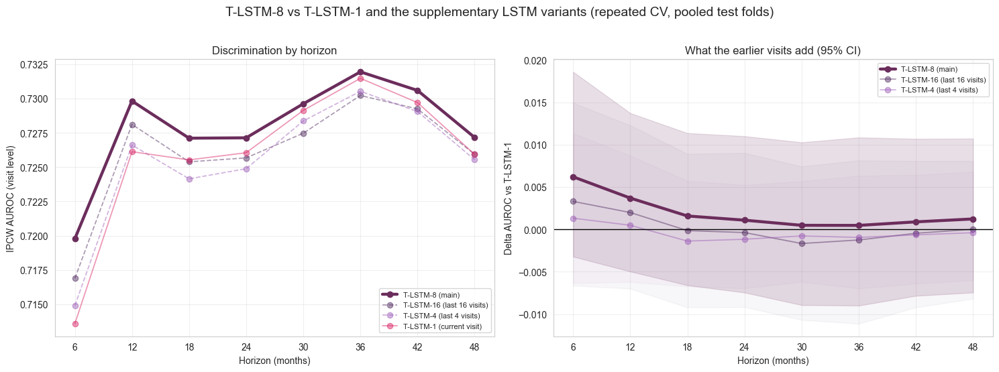

In [47]:
"""
What the history adds (Section 11.12.3): T-LSTM-8, T-LSTM-4 and T-LSTM-16 against T-LSTM-1 (the same network on
the current visit alone), from the pooled test folds (no refitting for T-LSTM-8 / T-LSTM-1; the variants are fitted here,
MODEL_REPEATS repeat(s) each): visit AUROC at every horizon, sensitivity, specificity and alert rate,
30-month patient C-index, sensitivity and specificity, and Delta AUROC (model - T-LSTM-1) at every horizon with a
patient-cluster bootstrap CI (the same resamples in every repeat; pairs of repeats both models completed).
"""
cv_state = run_repeated_cv(models=SUPP_LSTM_MODELS)       # the supplementary variants (checkpointed, resumable)
N_BOOT_WIN = 100 if SMOKE else 200
HISTORY_REF = "LSTM1"
HISTORY_MODELS = ["LSTM", "LSTM_w16", "LSTM_w4", "LSTM1"] + SUPP_LSTM_MODELS


def window_metrics(reps):
    """Mean over repeats of the test-fold metrics of one model."""
    y, w = IPCW[PRIMARY_HORIZON_MONTHS]
    k = w > 0
    rows = []
    for P, thr, _ in reps:
        p = P[:, PRIMARY_COL]
        a = p >= thr
        tp, fp, fn, tn = w_confusion(y[k], a[k], w[k])
        f = patient_frame(ALL_ROWS, p, thr)
        pc = patient_counts(f)
        rows.append({**{f"AUROC {h} mo": w_auroc(IPCW[h][0], P[:, j], IPCW[h][1])
                        for j, h in enumerate(EVAL_HORIZONS_MONTHS)},
                     "Visit sensitivity": tp / max(tp + fn, 1e-12), "Visit specificity": tn / max(tn + fp, 1e-12),
                     "Alerts / 100 visits": 100.0 * float(np.mean(a)),
                     "Patient C-index": w_auroc(f["y"].values, f["score"].values, np.ones(len(f))),
                     "Patient sensitivity": pc["TP"] / max(pc["TP"] + pc["FN"], 1),
                     "Patient specificity": pc["TN"] / max(pc["TN"] + pc["FP"], 1)})
    return pd.DataFrame(rows).mean()


def delta_auc_by_horizon(reps_a, reps_b, boots):
    """Delta AUROC (a - b) at every horizon, mean over paired repeats, with the bootstrap distribution."""
    n = min(len(reps_a), len(reps_b))
    d0, B = np.zeros(H_), np.zeros((len(boots), H_))
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        y, w = IPCW[h]
        preps = [(auc_prep(y, A[0][:, j]), auc_prep(y, Bm[0][:, j])) for A, Bm in zip(reps_a[:n], reps_b[:n])]
        d0[j] = np.mean([auc_w(pa, w) - auc_w(pb, w) for pa, pb in preps])
        for i, (m_land, _) in enumerate(boots):
            ww = w * m_land
            B[i, j] = np.mean([auc_w(pa, ww) - auc_w(pb, ww) for pa, pb in preps])
    return d0, B


HIST_REPS = {m: model_repeats(m) for m in HISTORY_MODELS}
HIST_HAVE = [m for m in HISTORY_MODELS if HIST_REPS[m]]
if HISTORY_REF not in HIST_HAVE or "LSTM" not in HIST_HAVE:
    print("Run Sections 11.10.1 and 11.10.2 first.")
else:
    lab = lambda m: MODEL_LABELS.get(m, m)
    hist_table = pd.DataFrame({lab(m): window_metrics(HIST_REPS[m]) for m in HIST_HAVE}).T
    hist_table.insert(0, "CV repeats", [len(HIST_REPS[m]) for m in HIST_HAVE])
    print("T-LSTM-8, T-LSTM-1 and the supplementary LSTM variants -- pooled test folds, mean over the completed repeats:")
    display(hist_table.round(3))
    boots = patient_boot_counts(N_BOOT_WIN)
    DELTA_HIST, drows = {}, []
    for m in [x for x in HIST_HAVE if x != HISTORY_REF]:
        d0, B = delta_auc_by_horizon(HIST_REPS[m], HIST_REPS[HISTORY_REF], boots)
        lo, hi = np.nanpercentile(B, [2.5, 97.5], axis=0)
        DELTA_HIST[lab(m)] = (d0, lo, hi)
        for j, h in enumerate(EVAL_HORIZONS_MONTHS):
            drows.append({"Model": lab(m), "Paired repeats": min(len(HIST_REPS[m]), len(HIST_REPS[HISTORY_REF])),
                          "Horizon (mo)": h, "Delta AUROC vs T-LSTM-1": d0[j], "95% CI": f"[{lo[j]:+.3f}, {hi[j]:+.3f}]",
                          "Share of resamples > 0": float(np.mean(B[:, j] > 0))})
    delta_hist = pd.DataFrame(drows)
    print(f"\nDelta AUROC vs T-LSTM-1 (the same network on the current visit alone), by horizon (paired, same folds; "
          f"{N_BOOT_WIN} patient-bootstrap resamples):")
    display(delta_hist.pivot(index="Horizon (mo)", columns="Model", values="Delta AUROC vs T-LSTM-1").round(3))
    display(delta_hist[delta_hist["Horizon (mo)"] == PRIMARY_HORIZON_MONTHS].set_index("Model").round(3))
    hist_table.to_csv("lstm_history_comparison_revised_v27.csv")
    delta_hist.to_csv("lstm_history_delta_auroc_revised_v27.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
    ax = axes[0]
    for m in HIST_HAVE:
        row = hist_table.loc[lab(m), [f"AUROC {h} mo" for h in EVAL_HORIZONS_MONTHS]]
        ax.plot(EVAL_HORIZONS_MONTHS, row.values, marker="o", ls="-" if m in ("LSTM", "LSTM1") else "--", label=lab(m),
                **model_style(m))
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_ylabel("IPCW AUROC (visit level)")
    ax.set_title("Discrimination by horizon"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[1]
    for m in [x for x in HIST_HAVE if x != HISTORY_REF]:
        d0, lo, hi = DELTA_HIST[lab(m)]
        c_ = CV_COLORS.get(m, "#444444")
        ax.plot(EVAL_HORIZONS_MONTHS, d0, marker="o", label=lab(m), **model_style(m))
        ax.fill_between(EVAL_HORIZONS_MONTHS, lo, hi, color=c_, alpha=0.15 if m == "LSTM" else 0.04)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Delta AUROC vs T-LSTM-1"); ax.set_title("What the earlier visits add (95% CI)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("T-LSTM-8 vs T-LSTM-1 and the supplementary LSTM variants (repeated CV, pooled test folds)", y=1.02,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_lstm_history.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.12.4 Static vs longitudinal models by horizon and by history length

The static models (LogReg, Cox, RSF, T-LSTM-1) see the current visit; the longitudinal models (LSTM, GRU,
Transformer) read the variables over the patient's history. From the **same pooled out-of-fold risks** as the main tables:

1. **By horizon.** The IPCW AUROC of every model at 6, 12, …, 48 months, each horizon scored against its own
   competing-risk label (onset by that horizon; an earlier other exit is a resolved negative).
2. **By history length.** The 30-month AUROC in strata of the number of the patient's clinic visits before the
   landmark (about quintiles: 0–3, 4–9, 10–17, 18–30, ≥ 31).

ΔAUROC = sequence model − LogReg, paired on identical folds, averaged over the CV repeats; the 95 % CI comes from a
patient-cluster bootstrap (the same resample in every repeat). If the history carried information beyond the current
visit, ΔAUROC should be positive, especially at short horizons (a change heralding onset) and for patients with a long
history.

IPCW AUROC by horizon (competing-risk label 'onset by h'), mean over CV repeats:


,Type,6 mo,12 mo,18 mo,24 mo,30 mo,36 mo,42 mo,48 mo
LogReg,static,0.709,0.717,0.715,0.716,0.719,0.719,0.716,0.712
LSTM1,static,0.714,0.726,0.726,0.726,0.729,0.731,0.730,0.726
LSTM,longitudinal,0.720,0.730,0.727,0.727,0.730,0.732,0.731,0.727
LSTM_w16,longitudinal,0.717,0.728,0.725,0.726,0.727,0.730,0.729,0.726
LSTM_w4,longitudinal,0.715,0.727,0.724,0.725,0.728,0.731,0.729,0.726
GRU,longitudinal,0.709,0.725,0.724,0.725,0.727,0.729,0.728,0.725
LSTM_plain,longitudinal,0.716,0.726,0.721,0.719,0.722,0.724,0.721,0.717



Delta AUROC vs LogReg by horizon (paired; 500 patient-bootstrap resamples):


Model,GRU,LSTM,LSTM1,LSTM_plain,LSTM_w16,LSTM_w4
Horizon (mo),,,,,,
6,-0.000,0.011,0.004,0.005,0.008,0.006
12,0.008,0.013,0.009,0.009,0.011,0.009
18,0.008,0.012,0.010,0.009,0.010,0.009
24,0.010,0.011,0.010,0.008,0.010,0.009
30,0.008,0.010,0.010,0.007,0.008,0.009
36,0.010,0.013,0.012,0.010,0.011,0.011
42,0.011,0.014,0.013,0.010,0.013,0.013
48,0.012,0.015,0.014,0.011,0.014,0.013


Delta AUROC            95% CI  Share of resamples > 0
Model      Horizon (mo)                                                       
LSTM       6                   0.011  [-0.009, +0.031]                   0.850
           12                  0.013  [-0.005, +0.031]                   0.908
           18                  0.012  [-0.002, +0.027]                   0.954
           24                  0.011  [-0.002, +0.026]                   0.964
           30                  0.010  [-0.004, +0.025]                   0.932
           36                  0.013  [-0.001, +0.027]                   0.964
           42                  0.014  [-0.000, +0.029]                   0.970
           48                  0.015  [+0.000, +0.028]                   0.978
LSTM_w16   6                   0.008  [-0.013, +0.028]                   0.740
           12                  0.011  [-0.008, +0.030]                   0.854
           18                  0.010  [-0.005, +0.025]                   0.916
           24                  0.010  [-0.004, +0.023]                   0.936
           30                  0.008  [-0.005, +0.021]                   0.866
           36                  0.011  [-0.001, +0.024]                   0.950
           42                  0.013  [-0.000, +0.026]                   0.972
           48                  0.014  [+0.000, +0.026]                   0.980
LSTM_w4    6                   0.006  [-0.012, +0.023]                   0.714
           12                  0.009  [-0.007, +0.026]                   0.856
           18                  0.009  [-0.004, +0.023]                   0.918
           24                  0.009  [-0.003, +0.023]                   0.928
           30                  0.009  [-0.004, +0.022]                   0.910
           36                  0.011  [-0.002, +0.026]                   0.954
           42                  0.013  [-0.002, +0.026]                   0.956
           48                  0.013  [-0.001, +0.026]                   0.958
GRU        6                  -0.000  [-0.017, +0.016]                   0.472
           12                  0.008  [-0.010, +0.026]                   0.786
           18                  0.008  [-0.007, +0.023]                   0.864
           24                  0.010  [-0.004, +0.024]                   0.912
           30                  0.008  [-0.006, +0.022]                   0.868
           36                  0.010  [-0.004, +0.023]                   0.910
           42                  0.011  [-0.002, +0.024]                   0.942
           48                  0.012  [-0.001, +0.025]                   0.968
LSTM_plain 6                   0.005  [-0.021, +0.029]                   0.650
           12                  0.009  [-0.013, +0.032]                   0.782
           18                  0.009  [-0.010, +0.028]                   0.802
           24                  0.008  [-0.012, +0.026]                   0.768
           30                  0.007  [-0.013, +0.028]                   0.746
           36                  0.010  [-0.010, +0.031]                   0.820
           42                  0.010  [-0.011, +0.030]                   0.824
           48                  0.011  [-0.010, +0.031]                   0.852


30-month IPCW AUROC by the number of clinic visits before the landmark:


,Landmarks,Patients,Event patients,LogReg,LSTM1,LSTM,LSTM_w16,LSTM_w4,GRU,LSTM_plain
Prior visits,,,,,,,,,,
0-3,2910,865,63,0.697,0.705,0.699,0.697,0.699,0.694,0.700
4-9,3536,741,39,0.774,0.777,0.787,0.789,0.786,0.782,0.789
10-17,3557,574,41,0.714,0.729,0.740,0.735,0.736,0.735,0.742
18-30,3660,413,37,0.707,0.718,0.717,0.719,0.711,0.713,0.706
>=31,3188,215,15,0.675,0.684,0.675,0.669,0.675,0.690,0.643


Delta AUROC vs LogReg at 30 months by history length:


Delta AUROC            95% CI  Share of resamples > 0
Model      Prior visits                                                       
LSTM       0-3                 0.002  [-0.026, +0.028]                   0.540
           4-9                 0.013  [-0.011, +0.039]                   0.842
           10-17               0.025  [+0.003, +0.054]                   0.988
           18-30               0.010  [-0.012, +0.031]                   0.806
           >=31                0.000  [-0.058, +0.057]                   0.514
LSTM_w16   0-3                -0.001  [-0.029, +0.026]                   0.434
           4-9                 0.015  [-0.014, +0.045]                   0.830
           10-17               0.021  [+0.000, +0.046]                   0.974
           18-30               0.011  [-0.010, +0.031]                   0.854
           >=31               -0.006  [-0.058, +0.047]                   0.422
LSTM_w4    0-3                 0.002  [-0.024, +0.026]                   0.544
           4-9                 0.012  [-0.011, +0.034]                   0.816
           10-17               0.022  [+0.000, +0.045]                   0.980
           18-30               0.004  [-0.015, +0.023]                   0.644
           >=31                0.000  [-0.055, +0.054]                   0.526
GRU        0-3                -0.003  [-0.032, +0.021]                   0.392
           4-9                 0.008  [-0.023, +0.039]                   0.654
           10-17               0.020  [-0.001, +0.041]                   0.968
           18-30               0.006  [-0.020, +0.031]                   0.676
           >=31                0.015  [-0.032, +0.061]                   0.760
LSTM_plain 0-3                -0.000  [-0.030, +0.033]                   0.510
           4-9                 0.025  [-0.014, +0.065]                   0.880
           10-17               0.024  [-0.012, +0.062]                   0.884
           18-30               0.015  [-0.017, +0.049]                   0.828
           >=31               -0.038  [-0.119, +0.035]                   0.172

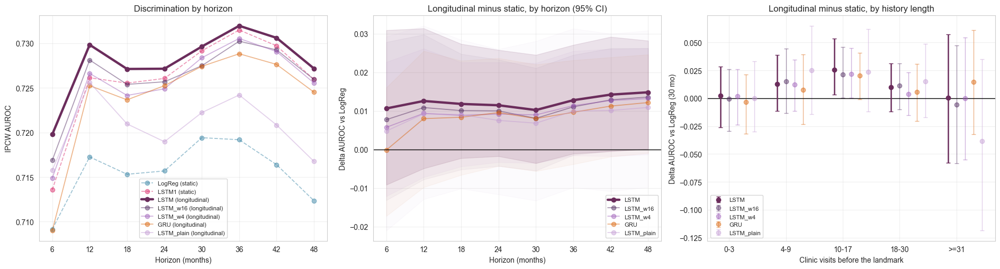

In [48]:
"""
Static vs longitudinal models, from the main CV state (no refitting): IPCW AUROC by horizon (6-48 mo) and by the number
of prior clinic visits (30 mo), with paired Delta AUROC (sequence model - LogReg) and patient-cluster bootstrap CIs.
"""
STATIC_MODELS = [m for m in ["LogReg", "LogRegW", "CoxPH", "RSF", "LSTM1"] if m in CV_MODELS]
LONGITUDINAL_MODELS = [m for m in ["LSTM", "LSTM_w16", "LSTM_w4", "GRU", "LSTM_plain"] if m in CV_MODELS]
DELTA_REFERENCE = "LogReg"
N_BOOT_DELTA = 100 if SMOKE else 500
HISTORY_BINS = [0, 4, 10, 18, 31, np.inf]
HISTORY_LABELS = ["0-3", "4-9", "10-17", "18-30", ">=31"]


def fast_w_auc(y, p, w):
    """IPCW AUROC by the weighted Mann-Whitney statistic (ties count 1/2); equals roc_auc_score with weights."""
    k = w > 0
    y, p, w = y[k], p[k], w[k]
    if len(y) == 0 or y.min() == y.max():
        return np.nan
    o = np.argsort(p, kind="mergesort")
    p, y, w = p[o], y[o], w[o]
    _, start = np.unique(p, return_index=True)
    wp, wn = np.add.reduceat(w * (y == 1), start), np.add.reduceat(w * (y == 0), start)
    below = np.cumsum(wn) - wn
    return float((wp * (below + 0.5 * wn)).sum() / (wp.sum() * wn.sum()))


def oof_risks(model):
    """Pooled out-of-fold calibrated risks, one (n_landmarks, n_horizons) matrix per completed repeat."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m == model:
            out.setdefault(r, np.full((len(land), len(EVAL_HORIZONS_MONTHS)), np.nan))[v["te"]] = v["P"]
    return [out[r] for r in sorted(out) if not np.isnan(out[r][:, 0]).any()]


SL_MODELS = [m for m in STATIC_MODELS + LONGITUDINAL_MODELS if oof_risks(m)]
OOF = {m: oof_risks(m) for m in SL_MODELS}
N_PRIOR_VISITS = LAND_POS                                            # clinic visits before the landmark visit
HIST_STRATUM = pd.cut(N_PRIOR_VISITS, HISTORY_BINS, right=False, labels=HISTORY_LABELS).astype(str)
_rows_of = pd.Series(np.arange(len(land))).groupby(PID_ALL).apply(np.asarray)
_rng = np.random.default_rng(2026)
BOOT_ROWS = [np.concatenate(_rows_of.loc[_rng.choice(_rows_of.index.values, len(_rows_of))].values)
             for _ in range(N_BOOT_DELTA)]


def auc_mean(model, j, idx):
    y, w = IPCW[EVAL_HORIZONS_MONTHS[j]]
    return float(np.mean([fast_w_auc(y[idx], P[idx, j], w[idx]) for P in OOF[model]]))


def delta_ci(model, j, idx_of_boot, base_idx):
    """Delta AUROC (model - reference) at horizon column j on rows base_idx; CI over the bootstrap resamples."""
    y, w = IPCW[EVAL_HORIZONS_MONTHS[j]]
    n_rep = min(len(OOF[model]), len(OOF[DELTA_REFERENCE]))
    pairs = list(zip(OOF[model][:n_rep], OOF[DELTA_REFERENCE][:n_rep]))
    def d(idx):
        return np.mean([fast_w_auc(y[idx], A[idx, j], w[idx]) - fast_w_auc(y[idx], B[idx, j], w[idx]) for A, B in pairs])
    boots = np.array([d(idx_of_boot(b)) for b in BOOT_ROWS])
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return d(base_idx), lo, hi, float(np.nanmean(boots > 0))


if len(SL_MODELS) < 2 or DELTA_REFERENCE not in SL_MODELS:
    print("Static vs longitudinal comparison skipped: run the model sections first.")
else:
    ALL_ROWS = np.arange(len(land))
    # ---- 1. by horizon
    tab_h = pd.DataFrame({f"{h} mo": [auc_mean(m, j, ALL_ROWS) for m in SL_MODELS]
                          for j, h in enumerate(EVAL_HORIZONS_MONTHS)}, index=SL_MODELS)
    tab_h.insert(0, "Type", ["static" if m in STATIC_MODELS else "longitudinal" for m in SL_MODELS])
    print("IPCW AUROC by horizon (competing-risk label 'onset by h'), mean over CV repeats:")
    display(tab_h.round(3))
    drows, DELTA_H = [], {}
    for m in [x for x in LONGITUDINAL_MODELS + STATIC_MODELS if x in SL_MODELS and x != DELTA_REFERENCE]:
        for j, h in enumerate(EVAL_HORIZONS_MONTHS):
            d0, lo, hi, share = delta_ci(m, j, lambda b: b, ALL_ROWS)
            DELTA_H[(m, h)] = (d0, lo, hi)
            drows.append({"Model": m, "Horizon (mo)": h, "Delta AUROC": d0, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                          "Share of resamples > 0": share})
    delta_h = pd.DataFrame(drows)
    print(f"\nDelta AUROC vs {DELTA_REFERENCE} by horizon (paired; {N_BOOT_DELTA} patient-bootstrap resamples):")
    display(delta_h.pivot(index="Horizon (mo)", columns="Model", values="Delta AUROC").round(3))
    display(delta_h[delta_h["Model"].isin(LONGITUDINAL_MODELS)].set_index(["Model", "Horizon (mo)"]).round(3))

    # ---- 2. by history length (30 months)
    j30 = PRIMARY_COL
    hrows = []
    for lab in HISTORY_LABELS:
        idx = np.flatnonzero(HIST_STRATUM == lab)
        y, w = IPCW[PRIMARY_HORIZON_MONTHS]
        r = {"Prior visits": lab, "Landmarks": len(idx), "Patients": len(np.unique(PID_ALL[idx])),
             "Event patients": len(np.unique(PID_ALL[idx][(y[idx] == 1) & (w[idx] > 0)]))}
        r.update({m: auc_mean(m, j30, idx) for m in SL_MODELS})
        hrows.append(r)
    tab_hist = pd.DataFrame(hrows).set_index("Prior visits")
    print(f"\n{PRIMARY_HORIZON_MONTHS}-month IPCW AUROC by the number of clinic visits before the landmark:")
    display(tab_hist.round(3))
    hd, DELTA_HISTLEN = [], {}
    in_stratum = {lab: HIST_STRATUM == lab for lab in HISTORY_LABELS}
    for m in [x for x in LONGITUDINAL_MODELS if x in SL_MODELS]:
        for lab in HISTORY_LABELS:
            mask = in_stratum[lab]
            d0, lo, hi, share = delta_ci(m, j30, lambda b, mask=mask: b[mask[b]], np.flatnonzero(mask))
            DELTA_HISTLEN[(m, lab)] = (d0, lo, hi)
            hd.append({"Model": m, "Prior visits": lab, "Delta AUROC": d0, "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
                       "Share of resamples > 0": share})
    delta_histlen = pd.DataFrame(hd)
    print(f"Delta AUROC vs {DELTA_REFERENCE} at {PRIMARY_HORIZON_MONTHS} months by history length:")
    display(delta_histlen.set_index(["Model", "Prior visits"]).round(3))

    pd.concat([tab_h.assign(table="AUROC by horizon"), delta_h.assign(table="Delta by horizon"),
               tab_hist.reset_index().assign(table="AUROC by history"), delta_histlen.assign(table="Delta by history")],
              ignore_index=False).to_csv("static_vs_longitudinal_revised_v27.csv")

    # ---- plots
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
    ax = axes[0]
    for m in SL_MODELS:
        ax.plot(EVAL_HORIZONS_MONTHS, tab_h.loc[m, [f"{h} mo" for h in EVAL_HORIZONS_MONTHS]].values, marker="o",
                ls="-" if m in LONGITUDINAL_MODELS else "--", label=f"{m} ({tab_h.loc[m, 'Type']})", **model_style(m))
    ax.set_xlabel("Horizon (months)"); ax.set_ylabel("IPCW AUROC"); ax.set_xticks(EVAL_HORIZONS_MONTHS)
    ax.set_title("Discrimination by horizon"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[1]
    for m in [x for x in LONGITUDINAL_MODELS if x in SL_MODELS]:
        d = np.array([DELTA_H[(m, h)] for h in EVAL_HORIZONS_MONTHS])
        ax.plot(EVAL_HORIZONS_MONTHS, d[:, 0], marker="o", label=m, **model_style(m))
        ax.fill_between(EVAL_HORIZONS_MONTHS, d[:, 1], d[:, 2], color=CV_COLORS.get(m), alpha=0.12 if m == "LSTM" else 0.04)
    ax.axhline(0, color="k", lw=1); ax.set_xticks(EVAL_HORIZONS_MONTHS)
    ax.set_xlabel("Horizon (months)"); ax.set_ylabel(f"Delta AUROC vs {DELTA_REFERENCE}")
    ax.set_title("Longitudinal minus static, by horizon (95% CI)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[2]
    xs = np.arange(len(HISTORY_LABELS))
    for i_m, m in enumerate([x for x in LONGITUDINAL_MODELS if x in SL_MODELS]):
        d = np.array([DELTA_HISTLEN[(m, lab)] for lab in HISTORY_LABELS])
        off = (i_m - 1) * 0.15
        ax.errorbar(xs + off, d[:, 0], yerr=[d[:, 0] - d[:, 1], d[:, 2] - d[:, 0]], fmt="o", capsize=3, label=m,
                    **model_style(m, 1.8, 1.0))
    ax.axhline(0, color="k", lw=1); ax.set_xticks(xs); ax.set_xticklabels(HISTORY_LABELS)
    ax.set_xlabel("Clinic visits before the landmark"); ax.set_ylabel(f"Delta AUROC vs {DELTA_REFERENCE} ({PRIMARY_HORIZON_MONTHS} mo)")
    ax.set_title("Longitudinal minus static, by history length"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_static_vs_longitudinal.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.12.5 Is there signal in the trajectory? (engineered change variables)

A longitudinal model can only beat a static one if the course of the disease says something the current visit does
not. This screen asks that directly with hand-built trajectory variables: each is **added on its own to the
current-visit variables** in a simple logistic model of onset within 30 months (IPCW × $1/n_i$ weights, signed log1p,
median imputation and standardisation inside the training fold, the main CV folds), and the change in the
**out-of-fold IPCW AUROC** is reported (mean and range over the CV repeats). A nonlinear check (gradient boosting,
current-visit variables with and without all trajectory variables) follows.

**Descriptive only:** no model in this notebook uses these variables. Candidates cover disease activity (time-averaged
SLEDAI-2K, 12-month mean / peak / slope, change since the previous visit, flares), damage accrual, treatment course
(steroid change, time on steroids, mean dose since entry, acute visits and acute-care events over 1–2 years),
visit pattern (visit rate, gap relative to the patient's usual gap), symptom course (share of visits with each
symptom over 12 months and since entry, new onset, persistence, symptom burden and its change), laboratory and
weight change, and employment history (sick leave).

In [49]:
"""
Trajectory-signal screen: engineered change / trajectory variables added one at a time to the current-visit set, in a
simple IPCW-weighted logistic model of onset within 30 months, on the main CV folds. Descriptive; no model uses them.
"""
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

TRAJ_C = 0.05                                    # L2 strength of the screening model (fixed; not tuned)


def _roll(s, win, how):
    t = pd.DataFrame({"PTNO": visits["PTNO"].values, "ASSDT": visits["ASSDT"].values, "x": np.asarray(s, float)})
    r = t.set_index("ASSDT").groupby("PTNO", sort=False)["x"].rolling(win, min_periods=1)
    return pd.Series(getattr(r, how)().values, index=visits.index)


def build_trajectory_candidates(v):
    prev = lambda s: s.groupby(v["PTNO"]).shift(1)
    T = {}
    T["Adjusted mean SLEDAI-2K (since entry)"] = v["SLEDAI_AMS"]
    T["SLEDAI-2K change since previous visit"] = v["SLEDAI2_I"] - prev(v["SLEDAI2_I"])
    T["SLEDAI-2K slope, 12 mo"] = v["SLEDAI_SLOPE_1Y"]
    T["SLEDAI-2K peak, 12 mo"] = v["SLEDAI_MAX_1Y"]
    T["SLEDAI-2K mean, 12 mo"] = _roll(v["SLEDAI2_I"], "365D", "mean")
    T["SLEDAI-2K minus its 12-mo mean"] = v["SLEDAI2_I"] - T["SLEDAI-2K mean, 12 mo"]
    T["SLEDAI-2K flares, 12 mo"] = v["FLARES_1Y"]
    T["SDI accrual, 12 mo"] = v["score_n"] - _roll(v["score_n"], "365D", "min")
    T["SDI accrual, 24 mo"] = v["SDI_ACCRUAL_2Y"]
    T["Steroid change since previous visit"] = v["STEROID_DELTA"]
    T["Steroid change, 12 mo"] = v["STEROID_CHANGE_1Y"]
    T["Share of visits on steroids, 12 mo"] = v["PROP_ON_STEROID_1Y"]
    T["Mean steroid dose, 12 mo"] = _roll(v["STERAVER_0"], "365D", "mean")
    T["Mean steroid dose since entry"] = v["STEROID_MEAN_SINCE_ENTRY"]
    T["Acute-care events, 12 mo"] = v["ACUTE_CARE_1Y"]
    T["Acute visits, 24 mo"] = _roll(v["ACUTE_VISIT"], "730D", "sum")
    T["Clinic-visit rate, 12 mo"] = v["VISIT_RATE_1Y"]
    usual_gap = v["DAYS_SINCE_LAST_VISIT"].groupby(v["PTNO"]).transform(lambda s: s.expanding().median().shift(1))
    T["Visit gap / patient's usual gap"] = (v["DAYS_SINCE_LAST_VISIT"] / usual_gap).clip(0, 5)
    sym = {"FATIGUE": "Fatigue", "FIBROMYALGIA": "Fibromyalgia", "ARTHRALGIA": "Arthralgia", "DYSPNOEA": "Dyspnoea"}
    for c, nm in sym.items():
        x = v[c].fillna(0.0)
        T[f"{nm}: share of visits, 12 mo"] = _roll(x, "365D", "mean")
        T[f"{nm}: share of visits since entry"] = x.groupby(v["PTNO"]).transform(lambda s: s.expanding().mean())
        T[f"{nm}: new in the last 12 mo"] = _roll(((v[c] == 1) & (prev(v[c]) == 0)).astype(float), "365D", "max")
        T[f"{nm}: present at this and the previous visit"] = ((v[c] == 1) & (prev(v[c]) == 1)).astype(float)
    count = v[list(sym)].fillna(0.0).sum(1)
    T["Symptom burden, 12-mo mean count"] = _roll(count, "365D", "mean")
    T["Symptom count minus its 12-mo mean"] = count - T["Symptom burden, 12-mo mean count"]
    for c, nm in [("C3", "C3"), ("LOG_ESR", "ESR (log)"), ("LOG_SCR", "Creatinine (log)")]:
        T[f"{nm} minus its 12-mo mean"] = v[c] - _roll(v[c], "365D", "mean")
    wt = pd.to_numeric(v["WEIGHT"], errors="coerce").groupby(v["PTNO"]).ffill()
    T["Weight minus its 12-mo mean"] = wt - _roll(wt, "365D", "mean")
    T["Sick-leave episodes, 24 mo"] = v["SICK_EPISODES_2Y"]
    T["Prior sick-leave visits"] = v["PRIOR_SICK_LEAVE_VISITS"]
    T["Years since last sick leave"] = v["YRS_SINCE_SICK_LEAVE"]
    return pd.DataFrame(T)


TRAJ = build_trajectory_candidates(visits).iloc[land["visit_row"].values].reset_index(drop=True)
BASE_X = land[SELECTION_ALL["features"]].reset_index(drop=True).astype(float)   # the all-data LASSO selection
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
_fitw = _w30 * land["weight"].values
_res = _w30 > 0
_folds = [(r, tr, te) for r, k, tr, te in cv_make_folds()]
_n_rep = max(r for r, _, _ in _folds) + 1


def _prep(A, tr):
    A = np.sign(A) * np.log1p(np.abs(A))
    med = np.nanmedian(A[tr], 0)
    A = np.where(np.isnan(A), np.where(np.isnan(med), 0.0, med), A)
    mu, sd = A[tr].mean(0), A[tr].std(0) + 1e-9
    return np.clip((A - mu) / sd, -CLIP_Z, CLIP_Z)


def screen_auc(extra=(), learner="lr"):
    A = np.column_stack([BASE_X.values] + [TRAJ[c].values[:, None] for c in extra]).astype(float)
    P = np.full((_n_rep, len(land)), np.nan)
    for r, tr, te in _folds:
        k = tr[_res[tr]]
        if learner == "lr":
            Z = _prep(A, tr)
            m = LogisticRegression(C=TRAJ_C, max_iter=2000).fit(Z[k], _y30[k], sample_weight=_fitw[k] / _fitw[k].mean())
            P[r, te] = m.decision_function(Z[te])
        else:
            m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=300, min_samples_leaf=100,
                                               l2_regularization=1.0, random_state=r)
            m.fit(A[k], _y30[k], sample_weight=_fitw[k] / _fitw[k].mean())
            P[r, te] = m.predict_proba(A[te])[:, 1]
    return np.array([roc_auc_score(_y30[_res], P[r, _res], sample_weight=_w30[_res]) for r in range(_n_rep)])


_base = screen_auc()
print(f"Current-visit variables only ({BASE_X.shape[1]} columns, logistic screen): out-of-fold IPCW AUROC "
      f"{_base.mean():.3f} (repeats {', '.join(f'{a:.3f}' for a in _base)})")
_rows = []
for c in TRAJ.columns:
    d = screen_auc([c]) - _base
    _rows.append({"Trajectory variable": c, "Delta AUROC": d.mean(), "min over repeats": d.min(),
                  "max over repeats": d.max(), "missing at landmarks": TRAJ[c].isna().mean()})
traj_screen = pd.DataFrame(_rows).sort_values("Delta AUROC", ascending=False).set_index("Trajectory variable")
print("\nEach trajectory variable added on its own to the current-visit set (Delta = out-of-fold IPCW AUROC gain):")
display(traj_screen.round(4))
_all = screen_auc(list(TRAJ.columns)) - _base
print(f"All {TRAJ.shape[1]} trajectory variables together (logistic): Delta AUROC {_all.mean():+.4f} "
      f"(range {_all.min():+.4f} to {_all.max():+.4f})")
_gb0, _gb1 = screen_auc(learner="gb"), screen_auc(list(TRAJ.columns), learner="gb")
print(f"Gradient boosting (nonlinear check): current visit {_gb0.mean():.3f}; + all trajectory variables "
      f"{_gb1.mean():.3f} (Delta {np.mean(_gb1 - _gb0):+.4f})")
traj_screen.to_csv("trajectory_screen_revised_v27.csv")

Current-visit variables only (12 columns, logistic screen): out-of-fold IPCW AUROC 0.715 (repeats 0.716, 0.712, 0.721, 0.715, 0.712)

Each trajectory variable added on its own to the current-visit set (Delta = out-of-fold IPCW AUROC gain):


,Delta AUROC,min over repeats,max over repeats,missing at landmarks
Trajectory variable,,,,
"Symptom burden, 12-mo mean count",0.0107,0.0080,0.0118,0.0000
"Arthralgia: share of visits, 12 mo",0.0079,0.0049,0.0091,0.0000
Dyspnoea: share of visits since entry,0.0069,0.0058,0.0092,0.0000
Arthralgia: share of visits since entry,0.0055,0.0026,0.0068,0.0000
"Clinic-visit rate, 12 mo",0.0033,0.0023,0.0042,0.0000
Dyspnoea: present at this and the previous visit,0.0024,0.0017,0.0031,0.0000
"Dyspnoea: share of visits, 12 mo",0.0023,0.0016,0.0041,0.0000
Fibromyalgia: present at this and the previous visit,0.0008,0.0004,0.0012,0.0000
Mean steroid dose since entry,0.0002,-0.0007,0.0013,0.0000


All 43 trajectory variables together (logistic): Delta AUROC -0.0077 (range -0.0166 to +0.0022)
Gradient boosting (nonlinear check): current visit 0.688; + all trajectory variables 0.698 (Delta +0.0101)


## 11.12.6 Every model on every metric

All models -- T-LSTM-1, -4, -8 and -16, the GRU, the LogReg and the Baseline -- on the five metrics
of Section 8.1 at the visit (30 months, IPCW) and the patient level, none of them primary:

1. **Values**, value [95 % patient-cluster bootstrap CI].
2. **Rank heatmap**: each cell coloured by the model's rank on that metric (darker = better), with its value.
3. **Paired differences** of T-LSTM-8 against every model and of every model against the LogReg, on every metric
   (forest plots; > 0 favours the first model).
4. **Bootstrap rank probabilities**: the share of resamples in which each model ranks first on each metric, and its
   mean rank. Models whose differences lie within the CIs are not distinguished by a rank.


EVERY MODEL -- VISIT LEVEL: value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at each model's cost-weighted alarm threshold


,CV repeats,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy
T-LSTM-8 (main),5,"0.730 [0.679, 0.773]","0.732 [0.683, 0.774]","0.702 [0.628, 0.767]","0.617 [0.586, 0.644]","0.659 [0.621, 0.694]"
T-LSTM-16 (last 16 visits),5,"0.727 [0.678, 0.770]","0.730 [0.682, 0.771]","0.652 [0.577, 0.719]","0.656 [0.627, 0.682]","0.654 [0.615, 0.688]"
T-LSTM-4 (last 4 visits),5,"0.728 [0.677, 0.771]","0.731 [0.681, 0.772]","0.685 [0.610, 0.753]","0.634 [0.604, 0.662]","0.660 [0.621, 0.694]"
T-LSTM-1 (current visit),5,"0.729 [0.678, 0.772]","0.733 [0.683, 0.773]","0.704 [0.628, 0.768]","0.596 [0.564, 0.623]","0.650 [0.612, 0.682]"
LogReg (last visit),5,"0.719 [0.670, 0.763]","0.724 [0.677, 0.766]","0.583 [0.508, 0.654]","0.694 [0.665, 0.722]","0.639 [0.601, 0.673]"
GRU (whole history),5,"0.727 [0.678, 0.771]","0.730 [0.681, 0.772]","0.653 [0.577, 0.722]","0.655 [0.626, 0.682]","0.654 [0.615, 0.688]"
"Null LogReg (age, race, education)",5,"0.581 [0.524, 0.639]","0.580 [0.525, 0.637]","0.462 [0.385, 0.541]","0.634 [0.598, 0.671]","0.548 [0.506, 0.587]"
LSTM-8 (no time decay),2,"0.722 [0.671, 0.765]","0.725 [0.675, 0.767]","0.642 [0.565, 0.714]","0.650 [0.621, 0.676]","0.646 [0.608, 0.682]"
T-LSTM-8 (no fairness penalty),2,"0.725 [0.675, 0.770]","0.728 [0.681, 0.771]","0.545 [0.466, 0.618]","0.764 [0.739, 0.788]","0.655 [0.615, 0.691]"
Baseline,5,"0.639 [0.579, 0.691]","0.651 [0.595, 0.701]","0.442 [0.349, 0.523]","0.674 [0.645, 0.702]","0.558 [0.515, 0.598]"



EVERY MODEL -- PATIENT LEVEL: value [95% patient-cluster bootstrap CI], mean over CV repeats; sensitivity / specificity at each model's cost-weighted alarm threshold


,CV repeats,AUROC,Sensitivity,Specificity,Balanced accuracy
T-LSTM-8 (main),5,"0.787 [0.745, 0.828]","0.722 [0.664, 0.783]","0.638 [0.606, 0.666]","0.680 [0.646, 0.715]"
T-LSTM-16 (last 16 visits),5,"0.787 [0.747, 0.829]","0.681 [0.619, 0.747]","0.674 [0.643, 0.703]","0.677 [0.642, 0.713]"
T-LSTM-4 (last 4 visits),5,"0.788 [0.747, 0.830]","0.706 [0.642, 0.774]","0.658 [0.627, 0.688]","0.682 [0.646, 0.718]"
T-LSTM-1 (current visit),5,"0.798 [0.757, 0.838]","0.697 [0.634, 0.763]","0.651 [0.620, 0.679]","0.674 [0.639, 0.710]"
LogReg (last visit),5,"0.797 [0.754, 0.837]","0.596 [0.529, 0.669]","0.728 [0.699, 0.754]","0.662 [0.623, 0.700]"
GRU (whole history),5,"0.789 [0.748, 0.830]","0.678 [0.611, 0.747]","0.685 [0.656, 0.712]","0.682 [0.646, 0.720]"
"Null LogReg (age, race, education)",5,"0.588 [0.539, 0.635]","0.451 [0.384, 0.516]","0.615 [0.586, 0.645]","0.533 [0.496, 0.569]"
LSTM-8 (no time decay),2,"0.787 [0.745, 0.826]","0.681 [0.608, 0.750]","0.652 [0.618, 0.684]","0.666 [0.627, 0.704]"
T-LSTM-8 (no fairness penalty),2,"0.789 [0.749, 0.830]","0.554 [0.484, 0.629]","0.782 [0.752, 0.808]","0.668 [0.627, 0.710]"
Baseline,5,"0.757 [0.712, 0.798]","0.499 [0.423, 0.574]","0.670 [0.640, 0.699]","0.584 [0.546, 0.621]"


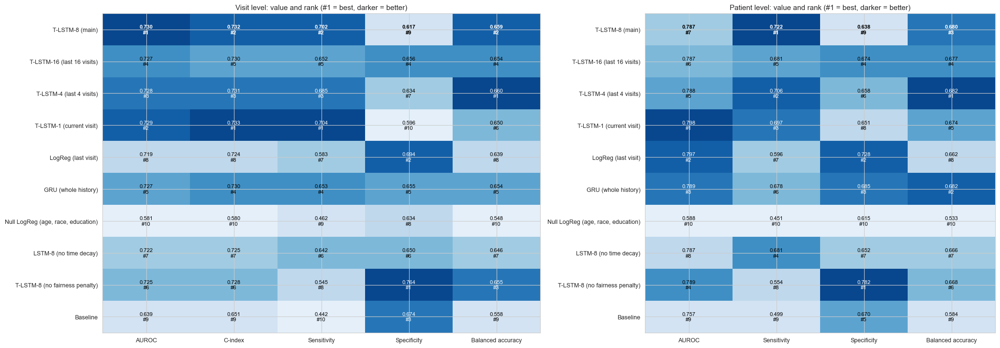


T-LSTM-8 AGAINST EVERY MODEL -- oriented paired difference [95% CI] (* = lower bound > 0):


Metric                                                                     AUROC  \
Comparison                                    Level                                
T-LSTM-8 - T-LSTM-16 (last 16 visits)         visit      +0.002 [-0.003, +0.007]   
                                              patient    -0.001 [-0.004, +0.003]   
T-LSTM-8 - T-LSTM-4 (last 4 visits)           visit      +0.001 [-0.004, +0.007]   
                                              patient    -0.001 [-0.006, +0.003]   
T-LSTM-8 - T-LSTM-1 (current visit)           visit      +0.000 [-0.009, +0.009]   
                                              patient    -0.011 [-0.021, -0.001]   
T-LSTM-8 - LogReg (last visit)                visit      +0.010 [-0.004, +0.023]   
                                              patient    -0.010 [-0.024, +0.004]   
T-LSTM-8 - GRU (whole history)                visit      +0.002 [-0.006, +0.010]   
                                              patient    -0.003 [-0.010, +0.004]   
T-LSTM-8 - Null LogReg (age, race, education) visit    +0.149 [+0.077, +0.221] *   
                                              patient  +0.199 [+0.136, +0.265] *   
T-LSTM-8 - LSTM-8 (no time decay)             visit      +0.002 [-0.004, +0.008]   
                                              patient    +0.001 [-0.004, +0.006]   
T-LSTM-8 - T-LSTM-8 (no fairness penalty)     visit      -0.001 [-0.013, +0.011]   
                                              patient    -0.002 [-0.013, +0.010]   
T-LSTM-8 - Baseline                           visit    +0.090 [+0.046, +0.135] *   
                                              patient    +0.030 [-0.003, +0.067]   

Metric                                                                   C-index  \
Comparison                                    Level                                
T-LSTM-8 - T-LSTM-16 (last 16 visits)         visit      +0.002 [-0.003, +0.007]   
                                              patient                        NaN   
T-LSTM-8 - T-LSTM-4 (last 4 visits)           visit      +0.001 [-0.004, +0.006]   
                                              patient                        NaN   
T-LSTM-8 - T-LSTM-1 (current visit)           visit      -0.000 [-0.009, +0.008]   
                                              patient                        NaN   
T-LSTM-8 - LogReg (last visit)                visit      +0.008 [-0.006, +0.020]   
                                              patient                        NaN   
T-LSTM-8 - GRU (whole history)                visit      +0.002 [-0.006, +0.009]   
                                              patient                        NaN   
T-LSTM-8 - Null LogReg (age, race, education) visit    +0.152 [+0.082, +0.222] *   
                                              patient                        NaN   
T-LSTM-8 - LSTM-8 (no time decay)             visit      +0.002 [-0.003, +0.008]   
                                              patient                        NaN   
T-LSTM-8 - T-LSTM-8 (no fairness penalty)     visit      -0.001 [-0.012, +0.011]   
                                              patient                        NaN   
T-LSTM-8 - Baseline                           visit    +0.081 [+0.040, +0.124] *   
                                              patient                        NaN   

Metric                                                               Sensitivity  \
Comparison                                    Level                                
T-LSTM-8 - T-LSTM-16 (last 16 visits)         visit    +0.050 [+0.029, +0.072] *   
                                              patient  +0.041 [+0.023, +0.060] *   
T-LSTM-8 - T-LSTM-4 (last 4 visits)           visit    +0.017 [+0.000, +0.034] *   
                                              patient    +0.016 [-0.006, +0.036]   
T-LSTM-8 - T-LSTM-1 (current visit)           visit      -0.002 [-0.027, +0.019]   
                                              pati

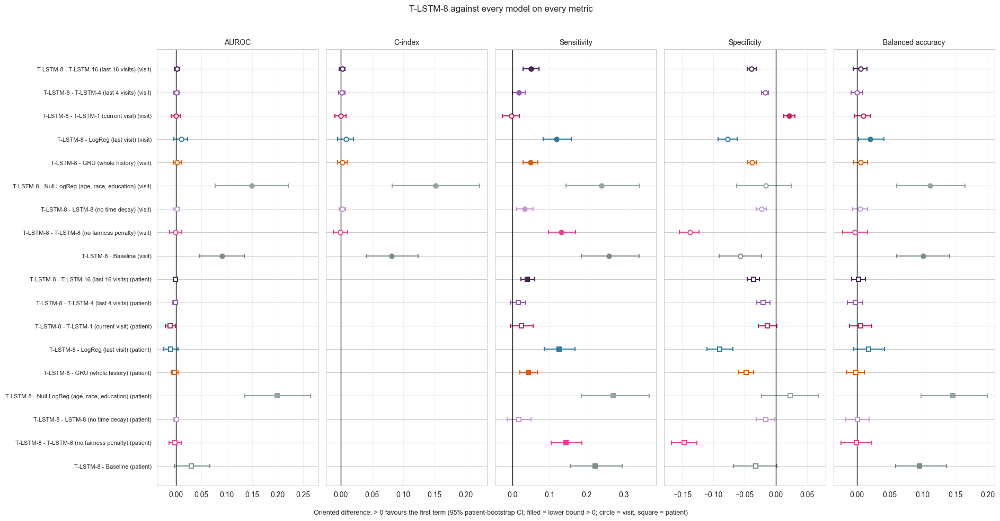


EVERY MODEL AGAINST THE LOGREG (LAST VISIT) -- oriented paired difference [95% CI] (* = lower bound > 0):


Metric                                                                 AUROC  \
Comparison                                  Level                              
T-LSTM-8 (main) - LogReg                    visit    +0.010 [-0.004, +0.023]   
                                            patient  -0.010 [-0.024, +0.004]   
T-LSTM-16 (last 16 visits) - LogReg         visit    +0.008 [-0.006, +0.021]   
                                            patient  -0.010 [-0.023, +0.005]   
T-LSTM-4 (last 4 visits) - LogReg           visit    +0.009 [-0.003, +0.021]   
                                            patient  -0.009 [-0.022, +0.004]   
T-LSTM-1 (current visit) - LogReg           visit    +0.010 [-0.002, +0.023]   
                                            patient  +0.001 [-0.011, +0.013]   
GRU (whole history) - LogReg                visit    +0.008 [-0.005, +0.022]   
                                            patient  -0.007 [-0.022, +0.006]   
Null LogReg (age, race, education) - LogReg visit    -0.139 [-0.205, -0.073]   
                                            patient  -0.209 [-0.272, -0.151]   
LSTM-8 (no time decay) - LogReg             visit    +0.007 [-0.012, +0.026]   
                                            patient  -0.009 [-0.028, +0.008]   
T-LSTM-8 (no fairness penalty) - LogReg     visit    +0.010 [-0.006, +0.027]   
                                            patient  -0.006 [-0.025, +0.011]   
Baseline - LogReg                           visit    -0.080 [-0.121, -0.040]   
                                            patient  -0.040 [-0.078, -0.009]   

Metric                                                               C-index  \
Comparison                                  Level                              
T-LSTM-8 (main) - LogReg                    visit    +0.008 [-0.006, +0.020]   
                                            patient                      NaN   
T-LSTM-16 (last 16 visits) - LogReg         visit    +0.006 [-0.007, +0.019]   
                                            patient                      NaN   
T-LSTM-4 (last 4 visits) - LogReg           visit    +0.007 [-0.005, +0.018]   
                                            patient                      NaN   
T-LSTM-1 (current visit) - LogReg           visit    +0.008 [-0.003, +0.021]   
                                            patient                      NaN   
GRU (whole history) - LogReg                visit    +0.006 [-0.007, +0.019]   
                                            patient                      NaN   
Null LogReg (age, race, education) - LogReg visit    -0.144 [-0.209, -0.081]   
                                            patient                      NaN   
LSTM-8 (no time decay) - LogReg             visit    +0.004 [-0.014, +0.023]   
                                            patient                      NaN   
T-LSTM-8 (no fairness penalty) - LogReg     visit    +0.008 [-0.008, +0.024]   
                                            patient                      NaN   
Baseline - LogReg                           visit    -0.073 [-0.112, -0.036]   
                                            patient                      NaN   

Metric                                                             Sensitivity  \
Comparison                                  Level                                
T-LSTM-8 (main) - LogReg                    visit    +0.118 [+0.083, +0.159] *   
                                            patient  +0.126 [+0.085, +0.168] *   
T-LSTM-16 (last 16 visits) - LogReg         visit    +0.069 [+0.037, +0.107] *   
                                            patient  +0.086 [+0.045, +0.124] *   
T-LSTM-4 (last 4 visits) - LogReg           visit    +0.102 [+0.069, +0.141] *   
                                            patient  +0.110 [+0.071, +0.150] *   
T-LSTM-1 (current visit) - LogReg           visit    +0.121 [+0.087, +0.159] *   
                                            patient  +0.101 

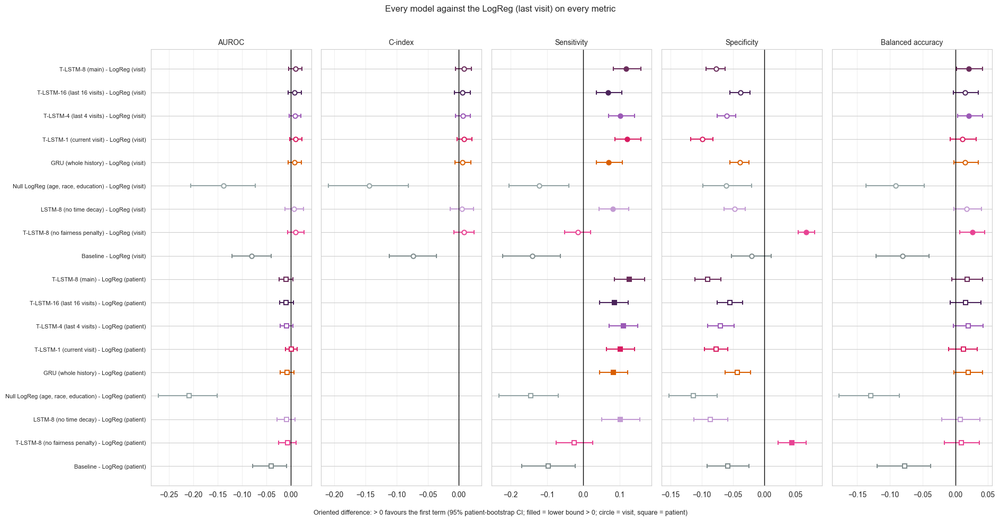


BOOTSTRAP P(RANK 1) on every metric (1000 resamples; models with fewer CV repeats are averaged over their own repeats):


Level                               visit                                  \
Metric                              AUROC C-index Sensitivity Specificity   
Model                                                                       
T-LSTM-8 (main)                     0.245   0.209       0.455         0.0   
T-LSTM-16 (last 16 visits)          0.051   0.046       0.000         0.0   
T-LSTM-4 (last 4 visits)            0.059   0.045       0.000         0.0   
T-LSTM-1 (current visit)            0.307   0.354       0.545         0.0   
LogReg (last visit)                 0.011   0.025       0.000         0.0   
GRU (whole history)                 0.104   0.101       0.000         0.0   
Null LogReg (age, race, education)  0.000   0.000       0.000         0.0   
LSTM-8 (no time decay)              0.022   0.014       0.000         0.0   
T-LSTM-8 (no fairness penalty)      0.201   0.206       0.000         1.0   
Baseline                            0.000   0.000       0.000         0.0   

Level                                                patient              \
Metric                             Balanced accuracy   AUROC Sensitivity   
Model                                                                      
T-LSTM-8 (main)                                0.303   0.002       0.882   
T-LSTM-16 (last 16 visits)                     0.039   0.001       0.000   
T-LSTM-4 (last 4 visits)                       0.368   0.001       0.064   
T-LSTM-1 (current visit)                       0.018   0.501       0.042   
LogReg (last visit)                            0.001   0.386       0.000   
GRU (whole history)                            0.022   0.017       0.000   
Null LogReg (age, race, education)             0.000   0.000       0.000   
LSTM-8 (no time decay)                         0.004   0.008       0.012   
T-LSTM-8 (no fairness penalty)                 0.245   0.079       0.000   
Baseline                                       0.000   0.005       0.000   

Level                                                             
Metric                             Specificity Balanced accuracy  
Model                                                             
T-LSTM-8 (main)                            0.0             0.138  
T-LSTM-16 (last 16 visits)                 0.0             0.075  
T-LSTM-4 (last 4 visits)                   0.0             0.327  
T-LSTM-1 (current visit)                   0.0             0.058  
LogReg (last visit)                        0.0             0.009  
GRU (whole history)                        0.0             0.312  
Null LogReg (age, race, education)         0.0             0.000  
LSTM-8 (no time decay)                     0.0             0.018  
T-LSTM-8 (no fairness penalty)             1.0             0.063  
Baseline                                   0.0             0.000


BOOTSTRAP MEAN RANK on every metric (1000 resamples; models with fewer CV repeats are averaged over their own repeats):


Level                               visit                                  \
Metric                              AUROC C-index Sensitivity Specificity   
Model                                                                       
T-LSTM-8 (main)                     2.701   2.825       1.570       8.781   
T-LSTM-16 (last 16 visits)          4.272   4.367       4.730       4.553   
T-LSTM-4 (last 4 visits)            3.582   3.829       2.957       7.454   
T-LSTM-1 (current visit)            3.190   2.916       1.474       9.947   
LogReg (last visit)                 6.953   6.555       7.014       2.098   
GRU (whole history)                 4.244   4.255       4.755       4.774   
Null LogReg (age, race, education)  9.944   9.979       9.297       7.202   
LSTM-8 (no time decay)              6.327   6.544       5.515       5.898   
T-LSTM-8 (no fairness penalty)      4.731   4.709       8.033       1.000   
Baseline                            9.056   9.021       9.655       3.293   

Level                                                patient              \
Metric                             Balanced accuracy   AUROC Sensitivity   
Model                                                                      
T-LSTM-8 (main)                                2.269   6.188       1.133   
T-LSTM-16 (last 16 visits)                     4.131   5.644       4.700   
T-LSTM-4 (last 4 visits)                       2.136   5.333       2.350   
T-LSTM-1 (current visit)                       5.474   1.730       3.241   
LogReg (last visit)                            7.507   2.263       7.029   
GRU (whole history)                            4.269   4.502       5.028   
Null LogReg (age, race, education)             9.636  10.000       9.864   
LSTM-8 (no time decay)                         6.339   5.926       4.548   
T-LSTM-8 (no fairness penalty)                 3.875   4.612       8.050   
Baseline                                       9.364   8.802       9.057   

Level                                                             
Metric                             Specificity Balanced accuracy  
Model                                                             
T-LSTM-8 (main)                          9.034             3.212  
T-LSTM-16 (last 16 visits)               4.403             3.919  
T-LSTM-4 (last 4 visits)                 6.104             2.503  
T-LSTM-1 (current visit)                 7.323             4.827  
LogReg (last visit)                      2.000             6.944  
GRU (whole history)                      3.219             2.542  
Null LogReg (age, race, education)       9.677             9.987  
LSTM-8 (no time decay)                   7.246             6.296  
T-LSTM-8 (no fairness penalty)           1.000             5.757  
Baseline                                 4.994             9.013

In [50]:
"""
Every model on every metric (Section 11.12.6): values, rank heatmap, paired differences against T-LSTM-8 and the LogReg,
and bootstrap rank probabilities; visit level (30 months, IPCW) and patient level (Section 11.6 rule). Descriptive.
"""
ALL_CMP_MODELS = [m for m in CV_MODELS + ["Baseline"] if model_res(m) is not None and oof(m)]
ALL_VALUES = {}
for level in ("visit", "patient"):
    t = value_table(ALL_CMP_MODELS, level)
    t.insert(0, "CV repeats", [len(oof(m)) for m in ALL_CMP_MODELS])
    ALL_VALUES[level] = t
    print(f"\nEVERY MODEL -- {level.upper()} LEVEL: value [95% patient-cluster bootstrap CI], mean over CV repeats; "
          "sensitivity / specificity at each model's cost-weighted alarm threshold")
    display(t)
    t.to_csv(f"all_models_{level}_metrics_revised_v27.csv")

# ---- rank heatmap
fig, axes = plt.subplots(1, 2, figsize=(21, 0.48 * len(ALL_CMP_MODELS) + 2.6),
                         gridspec_kw={"width_ratios": [len(LEVEL_METRICS["visit"]), len(LEVEL_METRICS["patient"])]})
for ax, level in zip(axes, ("visit", "patient")):
    mets = LEVEL_METRICS[level]
    V = np.array([[(core_value(m, k, level) or {"Value": np.nan})["Value"] for k in mets] for m in ALL_CMP_MODELS])
    R = pd.DataFrame(V * np.array([CORE_SIGN[k] for k in mets])).rank(ascending=False, method="min").values
    n_ = len(ALL_CMP_MODELS)
    ax.imshow(np.where(np.isfinite(R), n_ + 1 - R, 0), cmap="Blues", aspect="auto", vmin=0, vmax=n_ + 1)
    for i in range(n_):
        for j in range(len(mets)):
            if np.isfinite(V[i, j]):
                ax.text(j, i, f"{V[i, j]:.3f}\n#{int(R[i, j])}", ha="center", va="center", fontsize=8,
                        color="white" if R[i, j] <= n_ / 3 else "black",
                        fontweight="bold" if ALL_CMP_MODELS[i] == "LSTM" else "normal")
    ax.set_xticks(range(len(mets)))
    ax.set_xticklabels([CORE_LABEL[k] + ("\n(lower = better)" if k == "brier" else "") for k in mets], fontsize=9)
    ax.set_yticks(range(n_)); ax.set_yticklabels([mlab(m) for m in ALL_CMP_MODELS], fontsize=9)
    ax.set_title(f"{level.capitalize()} level: value and rank (#1 = best, darker = better)", fontsize=11)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_all_models_rank_heatmap.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ---- paired differences: T-LSTM-8 against every model, every model against the LogReg
ALL_VS = {}
for ref, pairs_of, title, colour in [
        ("LSTM", lambda: [("LSTM", m, f"T-LSTM-8 - {mlab(m)}") for m in ALL_CMP_MODELS if m != "LSTM"],
         "T-LSTM-8 against every model", lambda r: CV_COLORS.get(r["b"], "#444444")),
        ("LogReg", lambda: [(m, "LogReg", f"{mlab(m)} - LogReg") for m in ALL_CMP_MODELS if m != "LogReg"],
         "Every model against the LogReg (last visit)", None)]:
    if ref not in ALL_CMP_MODELS:
        continue
    long = pd.concat([delta_long(pairs_of(), level) for level in ("visit", "patient")], ignore_index=True)
    ALL_VS[ref] = long
    print(f"\n{title.upper()} -- oriented paired difference [95% CI] (* = lower bound > 0):")
    display(delta_wide(long))
    forest_metrics(long, title + " on every metric", f"revised_v27_all_models_vs_{ref.lower()}.png", color_of=colour)
if ALL_VS:
    pd.concat(ALL_VS, names=["Reference"]).to_csv("all_models_paired_differences_revised_v27.csv")

# ---- bootstrap rank probabilities
_rows = []
for level in ("visit", "patient"):
    for k in LEVEL_METRICS[level]:
        V = [_cols(m, k, level) for m in ALL_CMP_MODELS]
        ok = [i for i, v in enumerate(V) if v is not None and len(v) > 1]
        if len(ok) < 2:
            continue
        Vb = np.array([CORE_SIGN[k] * V[i][1:] for i in ok])
        Rb = np.argsort(np.argsort(-np.nan_to_num(Vb, nan=-np.inf), axis=0), axis=0) + 1
        for i_, i in enumerate(ok):
            _rows.append({"Level": level, "Metric": CORE_LABEL[k], "Model": mlab(ALL_CMP_MODELS[i]),
                          "P(rank 1)": float(np.mean(Rb[i_] == 1)), "Mean rank": float(Rb[i_].mean())})
rank_df = pd.DataFrame(_rows)
if not rank_df.empty:
    for col in ("P(rank 1)", "Mean rank"):
        t = rank_df.pivot_table(index="Model", columns=["Level", "Metric"], values=col, sort=False)
        print(f"\nBOOTSTRAP {col.upper()} on every metric ({HYP_BOOT} resamples; models with fewer CV repeats are "
              "averaged over their own repeats):")
        display(t.round(3))
    rank_df.to_csv("all_models_rank_probabilities_revised_v27.csv", index=False)

## 11.12.7 AUROC detail: every model against the LogReg and T-LSTM-8, and the signal test against the Baseline

The paired 30-month ΔAUROC of every model against the LogReg (last visit) and of T-LSTM-8 against every model, the stack
against its best member, and T-LSTM-8 against the Baseline (index-visit values, demographics, calendar year) over all landmarks and within
calendar eras (case–control pairs from the same era only). Descriptive.

EVERY MODEL -- 30-month AUROC and paired Deltas (95% patient-cluster bootstrap CI, same resamples; descriptive):


,Type,Repeats,AUROC [95% CI],Model - LogReg,T-LSTM-8 - model
Model,,,,,
T-LSTM-8 (main),main,5,"0.730 [0.679, 0.773]","+0.010 [-0.004, +0.023]",n/a
T-LSTM-16 (last 16 visits),Objective 2,5,"0.727 [0.678, 0.770]","+0.008 [-0.006, +0.021]","+0.002 [-0.003, +0.007]"
T-LSTM-4 (last 4 visits),Objective 2,5,"0.728 [0.677, 0.771]","+0.009 [-0.003, +0.021]","+0.001 [-0.004, +0.007]"
T-LSTM-1 (current visit),Objective 2,5,"0.729 [0.678, 0.772]","+0.010 [-0.002, +0.023]","+0.000 [-0.009, +0.009]"
LogReg (last visit),Objective 2,5,"0.719 [0.670, 0.763]",n/a,"+0.010 [-0.004, +0.023]"
GRU (whole history),comparator,5,"0.727 [0.678, 0.771]","+0.008 [-0.005, +0.022]","+0.002 [-0.006, +0.010]"
"Null LogReg (age, race, education)",comparator,5,"0.581 [0.524, 0.639]","-0.139 [-0.205, -0.073]","+0.149 [+0.077, +0.221]"
LSTM-8 (no time decay),comparator,2,"0.722 [0.671, 0.765]","+0.007 [-0.012, +0.026]","+0.002 [-0.004, +0.008]"
T-LSTM-8 (no fairness penalty),comparator,2,"0.725 [0.675, 0.770]","+0.010 [-0.006, +0.027]","-0.001 [-0.013, +0.011]"


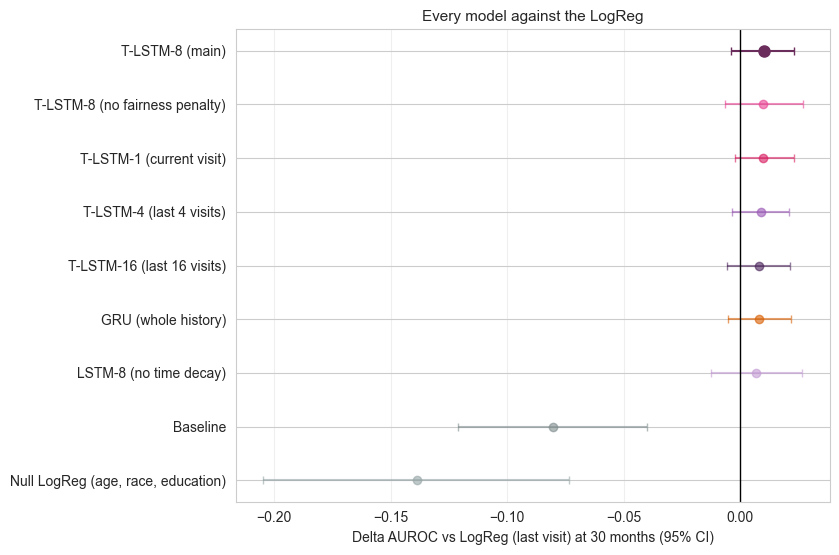


SIGNAL TEST -- AUROC(T-LSTM-8) - AUROC(Baseline: index-visit values, demographics, calendar year), pooled and era-stratified (case-control pairs from the same calendar era only):


,AUROC T-LSTM-8,AUROC Baseline,Delta,CI low,CI high,Share of resamples > 0,Repeats
pooled,0.7296,0.6391,0.0905,0.0463,0.1349,1.0,5.0
era-stratified,0.6998,0.6054,0.0944,0.0380,0.1471,1.0,5.0



AUROC within each calendar era (95% patient-bootstrap CI):


,Landmarks,Landmarks with onset <= 30 mo,AUROC T-LSTM-8 (main),AUROC LogReg (last visit),AUROC Baseline
Era,,,,,
< 2000,1925,130,"0.783 [0.713, 0.838]","0.754 [0.686, 0.808]","0.633 [0.482, 0.755]"
2000-05,2612,153,"0.671 [0.589, 0.749]","0.678 [0.597, 0.758]","0.591 [0.475, 0.692]"
2006-11,3790,193,"0.674 [0.592, 0.758]","0.642 [0.551, 0.724]","0.556 [0.450, 0.659]"
>= 2012,6012,150,"0.711 [0.600, 0.808]","0.713 [0.617, 0.794]","0.644 [0.559, 0.723]"


In [51]:
"""
Every model against the LogReg and against T-LSTM-8 at 30 months (paired, identical folds, 95% patient-cluster bootstrap
CI; descriptive), the stack against its best single member, and the signal test: T-LSTM-8 - Baseline, pooled and
era-stratified, with each model's AUROC within each calendar era.
"""
cmp_rows = []
for m in [x for x in CV_MODELS + SUPP_STACK_MODELS + ["Baseline"] if oof(x)]:
    a_, B_ = model_auc(m)
    vs_lr = paired_delta(m, "LogReg") if m != "LogReg" else None
    vs_l8 = paired_delta("LSTM", m) if m != "LSTM" else None
    cmp_rows.append({"Model": mlab(m), "Type": ("main" if m == "LSTM" else "Objective 2" if m in OBJ1_MODELS
                                                 else "baseline" if m == "Baseline" else "comparator"),
                     "Repeats": len(oof(m)),
                     "AUROC [95% CI]": f"{a_:.3f} [{np.nanpercentile(B_, 2.5):.3f}, {np.nanpercentile(B_, 97.5):.3f}]",
                     "Model - LogReg": fmt_d(vs_lr), "T-LSTM-8 - model": fmt_d(vs_l8),
                     "_d": vs_lr["Delta"] if vs_lr else (0.0 if m == "LogReg" else np.nan),
                     "_lo": vs_lr["CI low"] if vs_lr else np.nan, "_hi": vs_lr["CI high"] if vs_lr else np.nan,
                     "_key": m})
cmp_df = pd.DataFrame(cmp_rows).set_index("Model")
print(f"EVERY MODEL -- {PRIMARY_HORIZON_MONTHS}-month AUROC and paired Deltas (95% patient-cluster bootstrap CI, same "
      "resamples; descriptive):")
display(cmp_df[[c for c in cmp_df.columns if not c.startswith("_")]])
_members_done = [m for m in STACK_MEMBERS if oof(m)]
stack_vs_best = None
if oof("Stack") and _members_done:
    _best = max(_members_done, key=lambda m: model_auc(m)[0])
    stack_vs_best = (_best, paired_delta("Stack", _best))
    print(f"Stack - its best single member ({mlab(_best)}, chosen on these folds): {fmt_d(stack_vs_best[1])}")
_f = cmp_df[np.isfinite(cmp_df["_lo"])].sort_values("_d")
if len(_f):
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(_f) + 1.6))
    ys = np.arange(len(_f))
    for y_, (name, r_) in zip(ys, _f.iterrows()):
        ax.errorbar(r_["_d"], y_, xerr=[[r_["_d"] - r_["_lo"]], [r_["_hi"] - r_["_d"]]], fmt="o", capsize=3,
                    ms=8 if r_["_key"] == "LSTM" else 6, color=CV_COLORS.get(r_["_key"], "#444444"),
                    alpha=1.0 if r_["_key"] == "LSTM" else FADED_ALPHA + 0.15)
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(ys); ax.set_yticklabels(_f.index); ax.grid(axis="x", alpha=0.3)
    ax.set_xlabel(f"Delta AUROC vs LogReg (last visit) at {PRIMARY_HORIZON_MONTHS} months (95% CI)")
    ax.set_title("Every model against the LogReg", fontsize=11)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_comparators_vs_logreg.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# ---- signal test: T-LSTM-8 against the Baseline (no clinical variable), pooled and within calendar eras
sig_rows = {"pooled": paired_delta("LSTM", "Baseline"),
            "era-stratified": paired_delta("LSTM", "Baseline", era_strat=True)}
sig_df = pd.DataFrame({k: v for k, v in sig_rows.items() if v is not None}).T
if not sig_df.empty:
    print("\nSIGNAL TEST -- AUROC(T-LSTM-8) - AUROC(Baseline: index-visit values, demographics, calendar year), pooled and era-stratified "
          "(case-control pairs from the same calendar era only):")
    display(sig_df.rename(columns={"AUROC a": "AUROC T-LSTM-8", "AUROC b": "AUROC Baseline"}).round(4))
era_rows = []
for e, (_, _, era_lab) in enumerate(ERA_BANDS):
    k = (ERA_IDX_LAND == e)
    w_e = W30 * k
    n_ev = int(((Y30 == 1) & (w_e > 0)).sum())
    row = {"Era": era_lab, "Landmarks": int((w_e > 0).sum()), "Landmarks with onset <= 30 mo": n_ev}
    for m in ["LSTM", "LogReg", "Baseline"]:
        if oof(m) and n_ev > 0:
            a_, B_ = model_auc(m, w=w_e, tag=f"era{e}")
            row[f"AUROC {mlab(m)}"] = f"{a_:.3f} [{np.nanpercentile(B_, 2.5):.3f}, {np.nanpercentile(B_, 97.5):.3f}]"
    era_rows.append(row)
print("\nAUROC within each calendar era (95% patient-bootstrap CI):")
display(pd.DataFrame(era_rows).set_index("Era"))
cmp_df.drop(columns=[c for c in cmp_df.columns if c.startswith("_")]).to_csv("comparators_vs_logreg_revised_v27.csv")
sig_df.to_csv("signal_test_baseline_revised_v27.csv")

## 11.12.8 T-LSTM-8 from 6 to 48 months: visit and patient level

Each horizon with its own calibrated risk and era-standardised alarm threshold, from the pooled test folds.


LSTM-8 -- VISIT LEVEL by horizon: value [95% patient-bootstrap CI], mean over 5 repeat(s)


,Onset rate (IPCW),AUROC,calibration slope,calibration intercept,sensitivity,specificity,PPV,NPV,alerts / 100 visits
Horizon (mo),,,,,,,,,
6,0.008,"0.720 [0.671, 0.772]","1.082 [0.852, 1.342]","-0.105 [-0.291, 0.076]","0.653 [0.574, 0.741]","0.662 [0.642, 0.687]","0.015 [0.012, 0.019]","0.996 [0.994, 0.997]","34.050 [31.555, 36.066]"
12,0.018,"0.730 [0.680, 0.775]","1.074 [0.851, 1.306]","-0.089 [-0.255, 0.077]","0.678 [0.591, 0.755]","0.657 [0.633, 0.684]","0.035 [0.028, 0.042]","0.991 [0.988, 0.994]","34.918 [32.281, 37.317]"
18,0.027,"0.727 [0.680, 0.773]","1.071 [0.850, 1.311]","-0.096 [-0.278, 0.061]","0.699 [0.622, 0.773]","0.621 [0.595, 0.649]","0.048 [0.040, 0.058]","0.987 [0.982, 0.991]","38.795 [35.946, 41.301]"
24,0.035,"0.727 [0.676, 0.775]","1.061 [0.802, 1.301]","-0.095 [-0.278, 0.071]","0.682 [0.602, 0.763]","0.641 [0.611, 0.667]","0.064 [0.053, 0.076]","0.983 [0.977, 0.988]","37.012 [34.300, 39.726]"
30,0.042,"0.730 [0.675, 0.779]","1.066 [0.806, 1.313]","-0.097 [-0.286, 0.076]","0.702 [0.621, 0.777]","0.617 [0.587, 0.646]","0.075 [0.061, 0.088]","0.979 [0.972, 0.985]","39.628 [36.730, 42.519]"
36,0.048,"0.732 [0.679, 0.780]","1.061 [0.813, 1.292]","-0.097 [-0.284, 0.088]","0.670 [0.590, 0.754]","0.657 [0.626, 0.685]","0.090 [0.072, 0.109]","0.975 [0.967, 0.983]","35.877 [32.961, 38.893]"
42,0.055,"0.731 [0.675, 0.782]","1.060 [0.819, 1.301]","-0.101 [-0.314, 0.093]","0.664 [0.585, 0.748]","0.662 [0.632, 0.693]","0.103 [0.083, 0.123]","0.971 [0.962, 0.980]","35.583 [32.553, 38.548]"
48,0.062,"0.727 [0.672, 0.782]","1.074 [0.810, 1.329]","-0.096 [-0.299, 0.092]","0.654 [0.577, 0.740]","0.668 [0.637, 0.699]","0.115 [0.092, 0.138]","0.967 [0.955, 0.977]","35.170 [32.214, 38.210]"



LSTM-8 -- PATIENT LEVEL by horizon: value [95% patient-bootstrap CI], mean over 5 repeat(s)


,Evaluable (events / event-free),C-index,sensitivity,specificity,PPV,NPV,balanced accuracy
Horizon (mo),,,,,,,
6,138 / 692,"0.774 [0.733, 0.818]","0.672 [0.592, 0.739]","0.674 [0.648, 0.702]","0.292 [0.251, 0.340]","0.912 [0.885, 0.934]","0.673 [0.631, 0.708]"
12,138 / 692,"0.780 [0.738, 0.824]","0.683 [0.604, 0.755]","0.671 [0.641, 0.700]","0.294 [0.251, 0.341]","0.914 [0.886, 0.936]","0.677 [0.636, 0.713]"
18,138 / 692,"0.786 [0.746, 0.828]","0.726 [0.650, 0.796]","0.637 [0.608, 0.664]","0.285 [0.245, 0.328]","0.921 [0.895, 0.942]","0.682 [0.639, 0.718]"
24,138 / 692,"0.788 [0.749, 0.829]","0.709 [0.626, 0.780]","0.660 [0.628, 0.687]","0.294 [0.248, 0.339]","0.919 [0.893, 0.942]","0.684 [0.644, 0.723]"
30,138 / 692,"0.787 [0.746, 0.828]","0.722 [0.641, 0.791]","0.638 [0.607, 0.666]","0.285 [0.241, 0.328]","0.920 [0.894, 0.943]","0.680 [0.640, 0.717]"
36,138 / 692,"0.790 [0.749, 0.831]","0.697 [0.612, 0.773]","0.682 [0.650, 0.709]","0.304 [0.253, 0.350]","0.919 [0.892, 0.942]","0.689 [0.650, 0.729]"
42,138 / 692,"0.793 [0.752, 0.835]","0.691 [0.604, 0.767]","0.684 [0.654, 0.709]","0.304 [0.254, 0.353]","0.917 [0.891, 0.941]","0.688 [0.649, 0.728]"
48,138 / 692,"0.794 [0.753, 0.836]","0.693 [0.608, 0.769]","0.690 [0.661, 0.716]","0.308 [0.261, 0.358]","0.919 [0.892, 0.942]","0.691 [0.653, 0.731]"


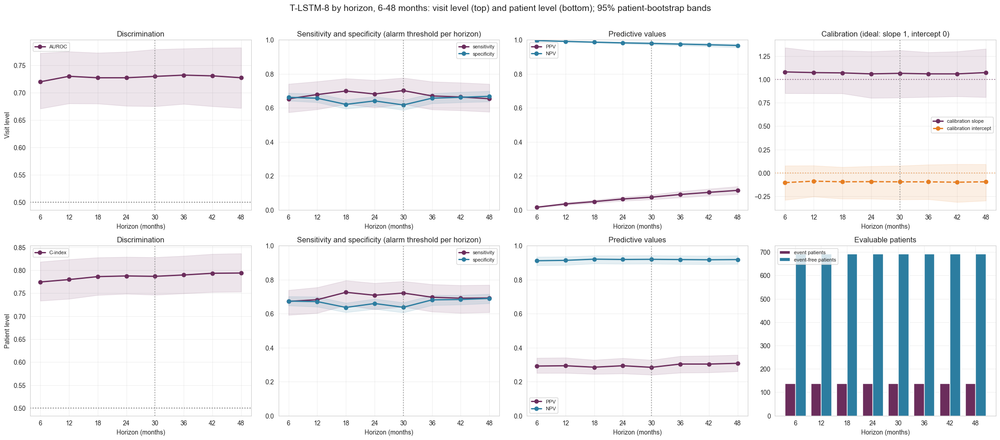

In [52]:
"""
T-LSTM-8 at every horizon (Section 11.12.8): visit- and patient-level metrics with each horizon's own
calibrated risk and era-standardised alarm threshold (visit_thr_h), from the pooled test folds; plots by horizon.
"""
HZ_BOOT = 100 if SMOKE else 200


def horizon_patient_window(hd):
    """Landmarks that decide a patient's outcome at horizon hd (days): Section 9.2 with hd in place of 30 months."""
    ev = land["event"].values == 1
    win_event = ev & (T_ALL <= hd)
    win_retired = (_stratum == STRATA[1]) & (_days_to_exit > 0) & (_days_to_exit <= hd)
    neg_other = np.isin(_stratum, [STRATA[0], STRATA[2]]) & (T_ALL > hd) & ~ev
    last = pd.Series(np.where(neg_other, _vdate.values, np.datetime64("NaT")), dtype="datetime64[ns]") \
        .groupby(PID_ALL).transform("max").values
    win_obs = neg_other & ((last - _vdate.values) / np.timedelta64(1, "D") <= hd)
    return np.where(_stratum == "Event", win_event, win_retired | win_obs)


PT_WIN_H = {h: horizon_patient_window(hd) for h, hd in zip(EVAL_HORIZONS_MONTHS, HORIZON_DAYS_GRID)}
assert np.array_equal(PT_WIN_H[PRIMARY_HORIZON_MONTHS], LAND_PT_WIN_30), "30-month windows must match Section 11.6"
if PATIENT_RULE in ("mixed", "run"):     # the same patient windows at every horizon (only the risk and threshold change)
    PT_WIN_H = {h: LAND_PT_WIN for h in EVAL_HORIZONS_MONTHS}
PT_IS_EVENT = (PT_TRUTH["stratum"] == "Event").values.astype(int)


def horizon_pieces(P, thr_h, j):
    """Visit and patient arrays of one repeat at horizon column j (fixed across bootstrap resamples); the patient level
    uses the rule of Section 11.6 (patient_collapse) on that horizon's windows."""
    h = EVAL_HORIZONS_MONTHS[j]
    y, w = IPCW[h]
    p = P[:, j]
    a = p >= thr_h[:, j]
    k = np.flatnonzero(PT_WIN_H[h])
    f = patient_collapse(k, p[k], a[k])
    code_pt = PT_CODE.get_indexer(f.index)
    y_pt = PT_IS_EVENT[code_pt]
    return dict(y=y, w=w, p=p, a=a, prep=auc_prep(y, p), code_pt=code_pt, y_pt=y_pt,
                a_pt=f["flag"].values.astype(bool), prep_pt=auc_prep(y_pt, f["score"].values))


def horizon_metrics(pc, m_land=None, m_pt=None):
    div = lambda a_, b_: a_ / b_ if b_ > 0 else np.nan
    w = pc["w"] if m_land is None else pc["w"] * m_land
    k = w > 0
    y, p, a = pc["y"][k], pc["p"][k], pc["a"][k]
    tp, fp, fn, tn = w_confusion(y, a, w[k])
    slope, icpt = fast_calibration(y, p, w[k])
    wp = np.ones(len(pc["y_pt"])) if m_pt is None else m_pt[pc["code_pt"]]
    yp, ap = pc["y_pt"], pc["a_pt"]
    TP, FP = wp[(yp == 1) & ap].sum(), wp[(yp == 0) & ap].sum()
    FN, TN = wp[(yp == 1) & ~ap].sum(), wp[(yp == 0) & ~ap].sum()
    return {"visit: AUROC": auc_w(pc["prep"], w), "visit: calibration slope": slope, "visit: calibration intercept": icpt,
            "visit: sensitivity": div(tp, tp + fn), "visit: specificity": div(tn, tn + fp),
            "visit: PPV": div(tp, tp + fp), "visit: NPV": div(tn, tn + fn),
            "visit: alerts / 100 visits": 100.0 * div((a * w[k]).sum(), w[k].sum()),
            "patient: C-index": auc_w(pc["prep_pt"], wp), "patient: sensitivity": div(TP, TP + FN),
            "patient: specificity": div(TN, TN + FP), "patient: PPV": div(TP, TP + FP), "patient: NPV": div(TN, TN + FN),
            "patient: balanced accuracy": (div(TP, TP + FN) + div(TN, TN + FP)) / 2}


HZ_REPS = selected_repeats() if res_lstm is not None else []
if not HZ_REPS:
    print("Run Section 11.10.1 first.")
else:
    boots_h = patient_boot_counts(HZ_BOOT, seed=2027)
    rows, HZ_CI = [], {}
    for j, h in enumerate(EVAL_HORIZONS_MONTHS):
        pcs = [horizon_pieces(P, thr_h, j) for P, _, thr_h in HZ_REPS]
        est = pd.DataFrame([horizon_metrics(pc) for pc in pcs]).mean()
        B = pd.DataFrame([pd.DataFrame([horizon_metrics(pc, ml, mp) for pc in pcs]).mean() for ml, mp in boots_h])
        lo, hi = B.quantile(0.025), B.quantile(0.975)
        n_ev, n_neg = int((pcs[0]["y_pt"] == 1).sum()), int((pcs[0]["y_pt"] == 0).sum())
        yh, wh = IPCW[h]
        rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                     "Event patients": n_ev, "Event-free patients": n_neg,
                     **{c: est[c] for c in est.index}, **{f"{c} lo": lo[c] for c in est.index},
                     **{f"{c} hi": hi[c] for c in est.index}})
    hz_df = pd.DataFrame(rows).set_index("Horizon (mo)")
    hz_df.to_csv("lstm_by_horizon_revised_v27.csv")
    mets = [c for c in est.index]
    fmt = lambda c: hz_df.apply(lambda r: f"{r[c]:.3f} [{r[c + ' lo']:.3f}, {r[c + ' hi']:.3f}]"
                                if np.isfinite(r[c]) else "n/a", axis=1)
    for level in ("visit", "patient"):
        t = pd.DataFrame({c.split(": ", 1)[1]: fmt(c) for c in mets if c.startswith(level)})
        if level == "visit":
            t.insert(0, "Onset rate (IPCW)", hz_df["Onset rate (IPCW)"].round(3))
        else:
            t.insert(0, "Evaluable (events / event-free)",
                     hz_df["Event patients"].astype(str) + " / " + hz_df["Event-free patients"].astype(str))
        print(f"\nLSTM-8 -- {level.upper()} LEVEL by horizon: value [95% patient-bootstrap CI], mean over "
              f"{len(HZ_REPS)} repeat(s)")
        display(t)

    def band(ax, c, color, label, ls="-"):
        ax.plot(EVAL_HORIZONS_MONTHS, hz_df[c], marker="o", color=color, ls=ls, lw=2, label=label)
        ax.fill_between(EVAL_HORIZONS_MONTHS, hz_df[c + " lo"], hz_df[c + " hi"], color=color, alpha=0.12)

    C1, C2, C3 = CV_COLORS["LSTM"], "#2c7da0", "#e67e22"
    fig, axes = plt.subplots(2, 4, figsize=(22, 9.5))
    for r_, level, disc in [(0, "visit", "visit: AUROC"), (1, "patient", "patient: C-index")]:
        ax = axes[r_, 0]
        band(ax, disc, C1, disc.split(": ")[1]); ax.axhline(0.5, color="gray", ls=":")
        ax.set_ylabel(f"{level.capitalize()} level"); ax.set_title("Discrimination")
        ax = axes[r_, 1]
        band(ax, f"{level}: sensitivity", C1, "sensitivity"); band(ax, f"{level}: specificity", C2, "specificity")
        ax.set_ylim(0, 1); ax.set_title("Sensitivity and specificity (alarm threshold per horizon)")
        ax = axes[r_, 2]
        band(ax, f"{level}: PPV", C1, "PPV"); band(ax, f"{level}: NPV", C2, "NPV")
        ax.set_ylim(0, 1); ax.set_title("Predictive values")
    ax = axes[0, 3]
    band(ax, "visit: calibration slope", C1, "calibration slope"); band(ax, "visit: calibration intercept", C3,
                                                                          "calibration intercept", ls="--")
    ax.axhline(1, color=C1, ls=":", alpha=0.6); ax.axhline(0, color=C3, ls=":", alpha=0.6)
    ax.set_title("Calibration (ideal: slope 1, intercept 0)")
    ax = axes[1, 3]
    x = np.arange(len(EVAL_HORIZONS_MONTHS))
    ax.bar(x - 0.2, hz_df["Event patients"], 0.4, color=C1, label="event patients")
    ax.bar(x + 0.2, hz_df["Event-free patients"], 0.4, color=C2, label="event-free patients")
    ax.set_xticks(x); ax.set_xticklabels(EVAL_HORIZONS_MONTHS); ax.set_title("Evaluable patients")
    for ax in axes.ravel()[:-1]:
        ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":", alpha=0.7)
    for ax in axes.ravel():
        ax.set_xlabel("Horizon (months)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("T-LSTM-8 by horizon, 6-48 months: visit level (top) and patient level (bottom); "
                 "95% patient-bootstrap bands", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_lstm_by_horizon.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

## 11.12.9 Cumulative risk by horizon (6–48 months) — every model, T-LSTM-8 highlighted

Discrimination and calibration at every horizon (every model; T-LSTM-8 highlighted) from the same cross-validation (the hazard head gives all horizons
from one fit). These are validated, out-of-fold numbers. The selected LSTM's visit- and patient-level metrics by
horizon, with bootstrap CIs and alarm thresholds per horizon, are in Section 11.12.8.

LSTM -- performance by horizon, pooled test folds (mean (SD) over repeats)


,Onset rate (IPCW),AUROC,Cal. slope,Cal. intercept
Horizon (mo),,,,
6,0.008018,0.720 (0.008),1.070 (0.086),-0.105 (0.039)
12,0.017772,0.730 (0.005),1.075 (0.078),-0.089 (0.033)
18,0.026760,0.727 (0.007),1.072 (0.098),-0.096 (0.031)
24,0.034614,0.727 (0.009),1.061 (0.115),-0.095 (0.026)
30,0.042046,0.730 (0.008),1.066 (0.117),-0.097 (0.027)
36,0.048334,0.732 (0.007),1.061 (0.114),-0.097 (0.021)
42,0.055064,0.731 (0.008),1.061 (0.117),-0.101 (0.019)
48,0.061510,0.727 (0.008),1.075 (0.108),-0.096 (0.022)


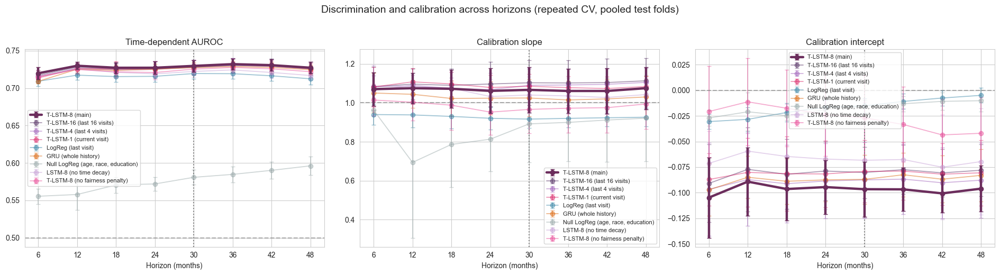

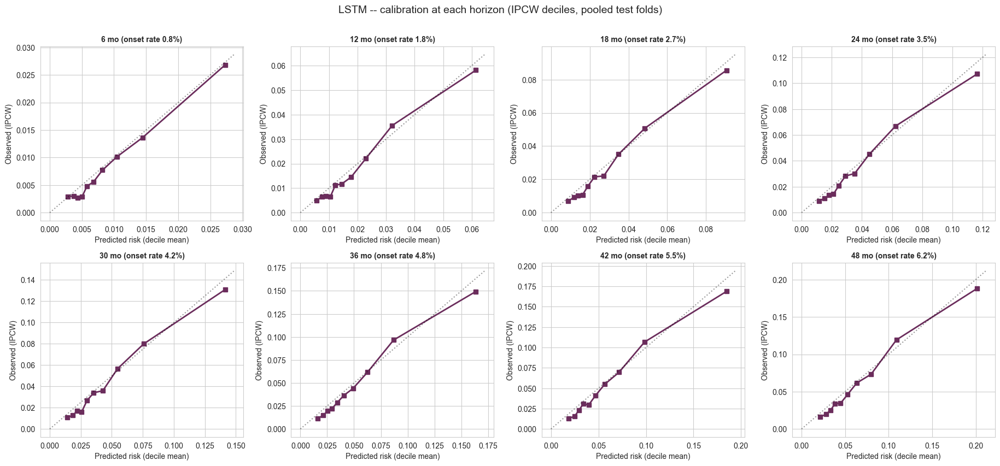

In [53]:
"""
LSTM multi-horizon performance (6-48 months) -- from the SAME repeated CV.

The discrete-time hazard head gives the risk of onset by every horizon from one fit, and each horizon has its own
recalibration learned inside the training folds. So
these are validated, out-of-fold numbers: time-dependent IPCW AUROC, calibration slope and intercept per
horizon, mean (SD) over repeats, and a reliability plot per horizon.
"""
HZ_MODEL = "LSTM" if res_lstm is not None else next(iter(MODEL_RESULTS))
d = MODEL_RESULTS[HZ_MODEL]["res_df"]
rows = []
for h in EVAL_HORIZONS_MONTHS:
    yh, wh = IPCW[h]
    rows.append({"Horizon (mo)": h, "Onset rate (IPCW)": float(np.average(yh[wh > 0], weights=wh[wh > 0])),
                 **{lab: _fmt(d[f"{c}_{h}"]) for c, lab in [("td_auroc", "AUROC"),
                                                            ("cal_slope", "Cal. slope"),
                                                            ("cal_intercept", "Cal. intercept")]}})
horizon_df = pd.DataFrame(rows).set_index("Horizon (mo)")
print(f"{HZ_MODEL} -- performance by horizon, pooled test folds (mean (SD) over repeats)")
display(horizon_df)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (c, lab, ideal) in zip(axes, [("td_auroc", "Time-dependent AUROC", 0.5), ("cal_slope", "Calibration slope", 1.0),
                                      ("cal_intercept", "Calibration intercept", 0.0)]):
    for m, r in MODEL_RESULTS.items():
        dd = r["res_df"]
        mu = [dd[f"{c}_{h}"].mean() for h in EVAL_HORIZONS_MONTHS]
        sd = [dd[f"{c}_{h}"].std() if len(dd) > 1 else 0 for h in EVAL_HORIZONS_MONTHS]
        ax.errorbar(EVAL_HORIZONS_MONTHS, mu, yerr=sd, marker="o", capsize=3, label=mlab(m), **model_style(m))
    ax.axhline(ideal, color="gray", ls="--", alpha=0.6)
    ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
    ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)"); ax.set_title(lab)
    ax.legend(fontsize=8)
plt.suptitle("Discrimination and calibration across horizons (repeated CV, pooled test folds)", y=1.03, fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_horizons.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

ncols = 4
nrows = int(np.ceil(len(EVAL_HORIZONS_MONTHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
for ax, (j, h) in zip(axes.ravel(), enumerate(EVAL_HORIZONS_MONTHS)):
    p, y, w, _, _ = stacked(HZ_MODEL, MODEL_RESULTS[HZ_MODEL]["preds"], col=j, horizon=h)
    k = w > 0
    b = pd.qcut(p[k], 10, labels=False, duplicates="drop")
    cd = pd.DataFrame({"pw": p[k] * w[k], "yw": y[k] * w[k], "w": w[k], "b": b}).groupby("b").sum()
    hi = float(max((cd["pw"] / cd["w"]).max(), (cd["yw"] / cd["w"]).max())) * 1.05
    ax.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], "s-", color=CV_COLORS[HZ_MODEL], lw=2)
    ax.plot([0, hi], [0, hi], "k:", alpha=0.4)
    ax.set_title(f"{h} mo (onset rate {np.average(y[k], weights=w[k]):.1%})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted risk (decile mean)"); ax.set_ylabel("Observed (IPCW)")
for ax in axes.ravel()[len(EVAL_HORIZONS_MONTHS):]:
    ax.set_visible(False)
plt.suptitle(f"{HZ_MODEL} -- calibration at each horizon (IPCW deciles, pooled test folds)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show(); plt.close()

## 11.12.10 Exclusive 12-month intervals: when does the onset happen?

Risk in months 0–12, 12–24, 24–36 and 36–48 **among the landmarks still at risk at the start of the interval**
(employed, event-free and uncensored), each interval with its own competing-risk IPCW label and its own recalibration
inside the training folds. Every model, T-LSTM-8 highlighted.

EXCLUSIVE 12-MONTH INTERVALS -- conditional on being at risk at the start of the interval; mean over CV repeats; AUROC with 95% patient-cluster bootstrap CI (200 resamples):


,,At risk at the start,Resolved (IPCW > 0),Observed risk (IPCW),Mean predicted risk,AUROC,95% CI,E/O,Cal. slope,Cal. intercept
Interval (mo),Model,,,,,,,,,
0-12,T-LSTM-8 (main),16851,15716,0.018,0.019,0.730,"[0.682, 0.773]",1.090,1.074,-0.089
12-24,T-LSTM-8 (main),15060,14084,0.017,0.019,0.717,"[0.666, 0.763]",1.080,1.081,-0.079
24-36,T-LSTM-8 (main),13527,12848,0.014,0.015,0.725,"[0.659, 0.775]",1.068,1.092,-0.068
36-48,T-LSTM-8 (main),12386,11551,0.015,0.016,0.714,"[0.648, 0.774]",1.067,1.151,-0.066
0-12,T-LSTM-16 (last 16 visits),16851,15716,0.018,0.019,0.728,"[0.682, 0.770]",1.078,1.095,-0.077
12-24,T-LSTM-16 (last 16 visits),15060,14084,0.017,0.018,0.716,"[0.665, 0.760]",1.062,1.124,-0.062
24-36,T-LSTM-16 (last 16 visits),13527,12848,0.014,0.015,0.721,"[0.655, 0.770]",1.044,1.144,-0.044
36-48,T-LSTM-16 (last 16 visits),12386,11551,0.015,0.016,0.715,"[0.648, 0.775]",1.050,1.194,-0.049
0-12,T-LSTM-4 (last 4 visits),16851,15716,0.018,0.019,0.727,"[0.680, 0.769]",1.089,1.085,-0.087


AUROC by interval (models in columns):


Model,Baseline,GRU (whole history),LSTM-8 (no time decay),LogReg (last visit),"Null LogReg (age, race, education)",T-LSTM-1 (current visit),T-LSTM-16 (last 16 visits),T-LSTM-4 (last 4 visits),T-LSTM-8 (main),T-LSTM-8 (no fairness penalty)
Interval (mo),,,,,,,,,,
0-12,0.649,0.725,0.726,0.717,0.558,0.726,0.728,0.727,0.730,0.725
12-24,0.628,0.717,0.708,0.706,0.564,0.716,0.716,0.713,0.717,0.715
24-36,0.645,0.719,0.717,0.714,0.603,0.724,0.721,0.726,0.725,0.731
36-48,0.624,0.710,0.696,0.688,0.621,0.716,0.715,0.713,0.714,0.705


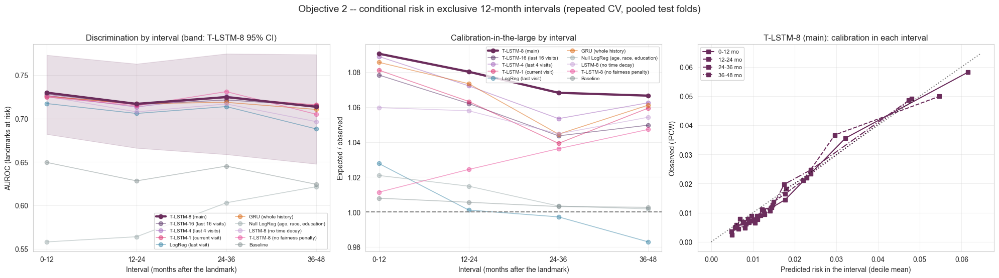

In [54]:
"""
Objective 2, the 'when' analysis: risk in exclusive 12-month intervals, CONDITIONAL on being at risk at the start --
months a to a + 12 among the landmarks with follow-up beyond a months and no event or competing exit before it
(T > a). From the same fit: the calibrated cumulative risks give r = 1 - (1 - P(a + 12)) / (1 - P(a)) (P(12) itself
for 0-12 months), recalibrated per fold on the training rows' cross-fitted r against the training rows' interval label
(an IPCW logistic recalibration, as in Section 7; the censoring distribution restarts at month a). Evaluated only in the
landmarks at risk: AUROC with a 95% patient-cluster bootstrap CI, O/E, calibration slope and intercept, mean over repeats.
"""
INT_BOOT = HYP_MULT[:200]
HZ_IDX = {h: j for j, h in enumerate(EVAL_HORIZONS_MONTHS)}


def interval_label(a, b, rows=None):
    """(y, w): onset in months (a, b] among the rows at risk at month a (w = 0 elsewhere), IPCW from month a."""
    rows = ALL_ROWS if rows is None else np.asarray(rows)
    ad, hd = round(a * MONTH_DAYS), round((b - a) * MONTH_DAYS)
    at = T_ALL[rows] > ad
    if ADMIN_CENSORING_LABELS:                                     # revised_v27: followable to month b by design
        at = at & (ADMIN_DAYS_ALL[rows] >= round(b * MONTH_DAYS))
    y, w = np.zeros(len(rows)), np.zeros(len(rows))
    if at.sum() > 0:
        t, c = T_ALL[rows][at] - ad, C_ALL[rows][at]
        y[at], w[at] = ipcw_label_weight(t, c, hd, CensoringKM(t, c))
    return y, w


def interval_score(P, a, b):
    """Conditional risk of the interval from the cumulative risks P (N, H)."""
    Pb = P[:, HZ_IDX[b]]
    if a == 0:
        return np.clip(Pb, 1e-6, 1 - 1e-6)
    Pa = P[:, HZ_IDX[a]]
    return np.clip(1.0 - (1.0 - Pb) / np.clip(1.0 - Pa, 1e-6, None), 1e-6, 1 - 1e-6)


INT_LAB = {iv: interval_label(*iv) for iv in OBJ2_INTERVALS}


def interval_oof(model, a, b):
    """{repeat: recalibrated interval risk (N,)} for every completed repeat of `model`."""
    out = {}
    for (m, r, k), v in cv_state["folds"].items():
        if m != model or v.get("oof_P") is None:
            continue
        ytr, wtr = interval_label(a, b, v["tr"])
        cal = Calibrator().fit(interval_score(np.asarray(v["oof_P"], float), a, b), ytr, wtr, True)
        out.setdefault(r, np.full(len(land), np.nan))[v["te"]] = cal.transform(interval_score(np.asarray(v["P"], float), a, b))
    return {r: p for r, p in out.items() if not np.isnan(p).any()}


INT_MODELS = [m for m in CV_MODELS + ["Baseline"] if oof(m)]
int_rows, INT_RES, INT_PRED = [], {}, {}
for m in INT_MODELS:
    for (a, b) in OBJ2_INTERVALS:
        y, w = INT_LAB[(a, b)]
        k = w > 0
        S = interval_oof(m, a, b)
        if not S or y[k].min() == y[k].max():
            continue
        INT_PRED[(m, (a, b))] = S
        preps = {r: auc_prep(y, s) for r, s in S.items()}
        f = lambda mult: np.mean([auc_w(preps[r], w * mult) for r in S])
        est, B = f(1.0), np.array([f(mm) for mm in INT_BOOT])
        lo, hi = np.nanpercentile(B, [2.5, 97.5])
        cal = np.array([fast_calibration(y[k], s[k], w[k]) for s in S.values()], float)
        pred = float(np.mean([np.average(s[k], weights=w[k]) for s in S.values()]))
        obs = float(np.average(y[k], weights=w[k]))
        INT_RES[(m, (a, b))] = (est, lo, hi, pred / obs if obs > 0 else np.nan)
        int_rows.append({"Model": mlab(m), "Interval (mo)": f"{a}-{b}", "At risk at the start": int((T_ALL > round(a * MONTH_DAYS)).sum()),
                         "Resolved (IPCW > 0)": int(k.sum()), "Observed risk (IPCW)": obs, "Mean predicted risk": pred,
                         "AUROC": est, "95% CI": f"[{lo:.3f}, {hi:.3f}]", "E/O": pred / obs if obs > 0 else np.nan,
                         "Cal. slope": float(np.nanmean(cal[:, 0])), "Cal. intercept": float(np.nanmean(cal[:, 1]))})
int_df = pd.DataFrame(int_rows)
if int_df.empty:
    print("No model has a completed repeat yet.")
else:
    print("EXCLUSIVE 12-MONTH INTERVALS -- conditional on being at risk at the start of the interval; mean over CV "
          f"repeats; AUROC with 95% patient-cluster bootstrap CI ({len(INT_BOOT)} resamples):")
    display(int_df.set_index(["Interval (mo)", "Model"]).round(3))
    print("AUROC by interval (models in columns):")
    display(int_df.pivot(index="Interval (mo)", columns="Model", values="AUROC").round(3))
    labels_iv = [f"{a}-{b}" for a, b in OBJ2_INTERVALS]
    xs = np.arange(len(OBJ2_INTERVALS))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.4))
    for m in INT_MODELS:
        v = np.array([INT_RES.get((m, iv), (np.nan,) * 4) for iv in OBJ2_INTERVALS], float)
        if np.isnan(v[:, 0]).all():
            continue
        axes[0].plot(xs, v[:, 0], marker="o", label=mlab(m), **model_style(m))
        axes[1].plot(xs, v[:, 3], marker="o", label=mlab(m), **model_style(m))
        if m == OBJ2_MODEL:
            axes[0].fill_between(xs, v[:, 1], v[:, 2], color=CV_COLORS[m], alpha=0.15)
    axes[0].set_ylabel("AUROC (landmarks at risk)"); axes[0].set_title("Discrimination by interval (band: T-LSTM-8 95% CI)")
    axes[1].axhline(1, color="gray", ls="--"); axes[1].set_ylabel("Expected / observed")
    axes[1].set_title("Calibration-in-the-large by interval")
    for ax in axes[:2]:
        ax.set_xticks(xs); ax.set_xticklabels(labels_iv); ax.set_xlabel("Interval (months after the landmark)")
        ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
    ax = axes[2]
    hi_ = 0.0
    for iv, ls in zip(OBJ2_INTERVALS, ["-", "--", "-.", ":"]):
        S = INT_PRED.get((OBJ2_MODEL, iv))
        if not S:
            continue
        y, w = INT_LAB[iv]
        k = w > 0
        p_ = np.concatenate([s[k] for s in S.values()]); y_ = np.tile(y[k], len(S)); w_ = np.tile(w[k], len(S))
        bins = pd.qcut(p_, 10, labels=False, duplicates="drop")
        cd = pd.DataFrame({"pw": p_ * w_, "yw": y_ * w_, "w": w_, "b": bins}).groupby("b").sum()
        ax.plot(cd["pw"] / cd["w"], cd["yw"] / cd["w"], marker="s", ls=ls, color=CV_COLORS[OBJ2_MODEL],
                label=f"{iv[0]}-{iv[1]} mo")
        hi_ = max(hi_, float((cd["pw"] / cd["w"]).max()), float((cd["yw"] / cd["w"]).max()))
    ax.plot([0, hi_ * 1.05], [0, hi_ * 1.05], "k:", alpha=0.5)
    ax.set_xlabel("Predicted risk in the interval (decile mean)"); ax.set_ylabel("Observed (IPCW)")
    ax.set_title(f"{mlab(OBJ2_MODEL)}: calibration in each interval"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("Objective 2 -- conditional risk in exclusive 12-month intervals (repeated CV, pooled test folds)",
                 y=1.02, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective2_intervals.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    int_df.to_csv("objective2_intervals_revised_v27.csv", index=False)

## 11.12.11 H2c: is accuracy higher close to the visit than further ahead?

The AUROC of T-LSTM-8's conditional risk in the first exclusive 12-month interval (months 0–12) minus that in the last
(months 36–48), each among the landmarks still at risk at the start of the interval (Section 11.12.10), paired on the
same 1,000 patient-bootstrap resamples; criterion: lower 95 % bound > 0. Unlike the cumulative horizons, the
intervals do not share onsets, so the contrast measures how accuracy changes with the time ahead. With it, the slope
of the AUROC per year over the four intervals, and every model's contrast (descriptive).

H2c -- AUROC 0-12 mo - 36-48 mo: conditional risk among the landmarks at risk at the start of each interval, paired patient-cluster bootstrap (1000 resamples for T-LSTM-8 (main), 200 for the other models); the slope per year over the four intervals (negative = accuracy falls further ahead):


,AUROC 0-12 mo,AUROC 12-24 mo,AUROC 24-36 mo,AUROC 36-48 mo,AUROC 0-12 mo - 36-48 mo [95% CI],Lower bound > 0,AUROC slope per year [95% CI],Repeats
Model,,,,,,,,
T-LSTM-8 (main),0.730,0.717,0.725,0.714,"+0.016 [-0.036, +0.072]",False,"-0.004 [-0.023, +0.014]",5
T-LSTM-16 (last 16 visits),0.728,0.716,0.721,0.715,"+0.013 [-0.038, +0.076]",False,"-0.003 [-0.023, +0.014]",5
T-LSTM-4 (last 4 visits),0.727,0.713,0.726,0.713,"+0.013 [-0.037, +0.069]",False,"-0.003 [-0.022, +0.014]",5
T-LSTM-1 (current visit),0.726,0.716,0.724,0.716,"+0.010 [-0.040, +0.068]",False,"-0.002 [-0.022, +0.016]",5
LogReg (last visit),0.717,0.706,0.714,0.688,"+0.029 [-0.018, +0.078]",False,"-0.008 [-0.024, +0.011]",5
GRU (whole history),0.725,0.717,0.719,0.710,"+0.015 [-0.039, +0.075]",False,"-0.004 [-0.023, +0.014]",5
"Null LogReg (age, race, education)",0.558,0.564,0.603,0.621,"-0.064 [-0.121, -0.011]",False,"+0.023 [+0.005, +0.042]",5
LSTM-8 (no time decay),0.726,0.708,0.717,0.696,"+0.029 [-0.020, +0.091]",False,"-0.008 [-0.030, +0.009]",2
T-LSTM-8 (no fairness penalty),0.725,0.715,0.731,0.705,"+0.020 [-0.033, +0.077]",False,"-0.004 [-0.023, +0.013]",2


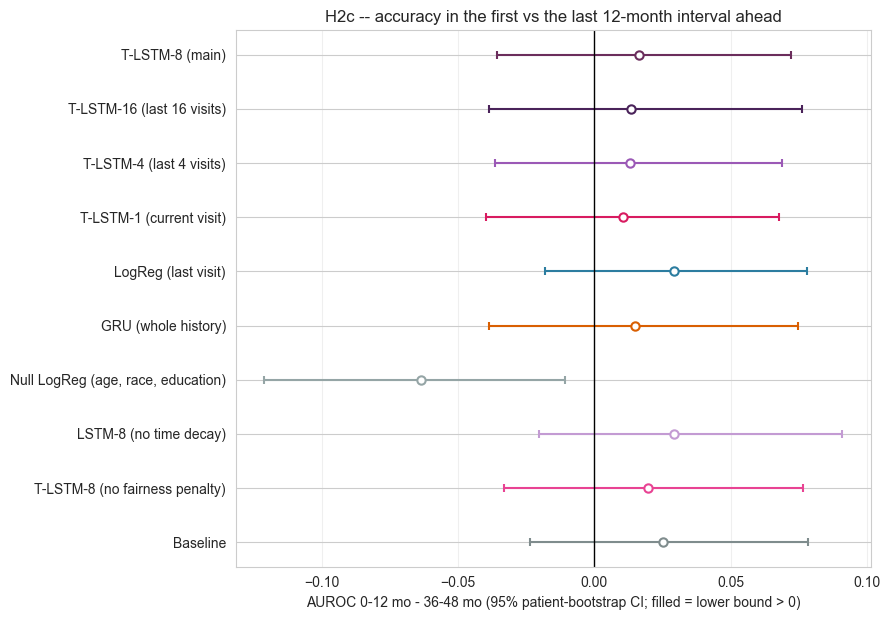

In [55]:
"""
Objective 2, H2c (Section 8.1): AUROC in the first minus the last exclusive interval (H2C_INTERVALS) of OBJ2_MODEL's
conditional interval risk (Section 11.12.10, INT_PRED / INT_LAB), on the HYP_BOOT patient-cluster resamples (paired:
both intervals use the same multiplicities); criterion: lower 95% bound > 0. Also the OLS slope of the AUROC per year
over the interval midpoints. Every model: the same with 200 resamples (descriptive).
"""
H2C_MIDS = np.array([(a + b) / 2 for a, b in OBJ2_INTERVALS], float)


def interval_contrast(m, mults):
    if any((m, iv) not in INT_PRED for iv in OBJ2_INTERVALS):
        return None
    reps = sorted(set.intersection(*[set(INT_PRED[(m, iv)]) for iv in OBJ2_INTERVALS]))
    if not reps:
        return None
    preps = {iv: {r: auc_prep(INT_LAB[iv][0], INT_PRED[(m, iv)][r]) for r in reps} for iv in OBJ2_INTERVALS}
    i0, i1 = OBJ2_INTERVALS.index(H2C_INTERVALS[0]), OBJ2_INTERVALS.index(H2C_INTERVALS[1])

    def f(mult):
        a = np.array([np.mean([auc_w(preps[iv][r], INT_LAB[iv][1] * mult) for r in reps]) for iv in OBJ2_INTERVALS])
        slope = np.polyfit(H2C_MIDS, a, 1)[0] * 12.0 if np.isfinite(a).all() else np.nan
        return [a[i0] - a[i1], slope] + list(a)
    return np.array(f(1.0)), np.array([f(mm) for mm in mults]), len(reps)


h2c_rows = []
for m in [x for x in INT_MODELS]:
    r_ = interval_contrast(m, HYP_MULT if m == OBJ2_MODEL else HYP_MULT[:200])
    if r_ is None:
        continue
    est, B, n_rep = r_
    (cl, ch), (sl, sh) = np.nanpercentile(B[:, 0], [2.5, 97.5]), np.nanpercentile(B[:, 1], [2.5, 97.5])
    h2c_rows.append({"Model": mlab(m), "m": m, "Repeats": n_rep,
                     **{f"AUROC {a}-{b} mo": v for (a, b), v in zip(OBJ2_INTERVALS, est[2:])},
                     "Contrast": est[0], "CI low": cl, "CI high": ch, "Lower bound > 0": bool(cl > 0),
                     "Slope per year": est[1], "Slope CI low": sl, "Slope CI high": sh,
                     "Resamples": len(B)})
h2c_df = pd.DataFrame(h2c_rows)
if h2c_df.empty:
    print("H2c skipped: no model has interval risks.")
else:
    _lab = f"AUROC {H2C_INTERVALS[0][0]}-{H2C_INTERVALS[0][1]} mo - {H2C_INTERVALS[1][0]}-{H2C_INTERVALS[1][1]} mo"
    _show = h2c_df.set_index("Model").assign(**{
        _lab + " [95% CI]": [f"{r['Contrast']:+.3f} [{r['CI low']:+.3f}, {r['CI high']:+.3f}]" for _, r in h2c_df.iterrows()],
        "AUROC slope per year [95% CI]": [f"{r['Slope per year']:+.3f} [{r['Slope CI low']:+.3f}, {r['Slope CI high']:+.3f}]"
                                          for _, r in h2c_df.iterrows()]})
    print(f"H2c -- {_lab}: conditional risk among the landmarks at risk at the start of each interval, paired "
          f"patient-cluster bootstrap ({HYP_BOOT} resamples for {mlab(OBJ2_MODEL)}, 200 for the other models); "
          "the slope per year over the four intervals (negative = accuracy falls further ahead):")
    display(_show[[c for c in _show.columns if c.startswith("AUROC ") and c.endswith(" mo")]
                  + [_lab + " [95% CI]", "Lower bound > 0", "AUROC slope per year [95% CI]", "Repeats"]].round(3))
    _main = h2c_df[h2c_df["m"] == OBJ2_MODEL]
    if len(_main):
        r = _main.iloc[0]
        record("H2c", pd.DataFrame([{"Comparison": f"{mlab(OBJ2_MODEL)}: {_lab}", "Level": "visit", "Metric": "AUROC",
                                     "Delta": r["Contrast"], "CI low": r["CI low"], "CI high": r["CI high"],
                                     "Lower bound > 0": r["Lower bound > 0"]}]))
    fig, ax = plt.subplots(figsize=(9, 0.45 * len(h2c_df) + 1.8))
    ys = np.arange(len(h2c_df))[::-1]
    for y_, (_, r) in zip(ys, h2c_df.iterrows()):
        c_ = CV_COLORS.get(r["m"], "#444444")
        ax.errorbar(r["Contrast"], y_, xerr=[[r["Contrast"] - r["CI low"]], [r["CI high"] - r["Contrast"]]], fmt="o",
                    color=c_, ecolor=c_, capsize=3, mfc=c_ if r["Lower bound > 0"] else "white", mew=1.5)
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(ys); ax.set_yticklabels(h2c_df["Model"])
    ax.set_xlabel(_lab + " (95% patient-bootstrap CI; filled = lower bound > 0)")
    ax.set_title("H2c -- accuracy in the first vs the last 12-month interval ahead"); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_h2c_intervals.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    h2c_df.drop(columns="m").to_csv("objective2_h2c_intervals_revised_v27.csv", index=False)

## 11.12.12 Cumulative horizons: every metric at 6 minus 48 months (descriptive)

T-LSTM-8's six visit-level metrics at the shortest (6 months) minus the longest (48 months) cumulative horizon, each
horizon against its own competing-risk label, IPCW weights and cost-weighted alarm threshold, and every model's
difference. **Descriptive:** a cumulative 48-month risk still contains every onset of months 0–6, so it cannot show
how accuracy changes further ahead; the test of that (H2c) uses the exclusive intervals (Section 11.12.11).

Cumulative horizons (descriptive) -- T-LSTM-8, every metric at 6 minus 48 months (oriented: > 0 = better at 6 months), 95% patient-cluster bootstrap CI (1000 resamples); * = lower bound > 0:


,Metric,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Lower bound > 0 on
Comparison,Level,,,,,,
T-LSTM-8: 6 mo - 48 mo,visit,"-0.007 [-0.044, +0.028]","-0.010 [-0.045, +0.025]","-0.001 [-0.061, +0.059]","-0.006 [-0.022, +0.010]","-0.003 [-0.034, +0.029]",0 of 5 metrics



T-LSTM-8 -- every metric by horizon (cumulative risk; value [95% CI]):


,Onset rate (IPCW),AUROC,C-index,Sensitivity,Specificity,Balanced accuracy
6 mo,0.008,"0.720 [0.669, 0.766]","0.721 [0.670, 0.766]","0.653 [0.571, 0.729]","0.662 [0.637, 0.686]","0.658 [0.617, 0.696]"
12 mo,0.018,"0.730 [0.684, 0.773]","0.732 [0.687, 0.775]","0.678 [0.606, 0.747]","0.657 [0.629, 0.681]","0.668 [0.631, 0.702]"
18 mo,0.027,"0.727 [0.679, 0.769]","0.731 [0.684, 0.771]","0.699 [0.628, 0.765]","0.621 [0.592, 0.646]","0.660 [0.623, 0.695]"
24 mo,0.035,"0.727 [0.677, 0.770]","0.731 [0.682, 0.773]","0.682 [0.610, 0.752]","0.641 [0.612, 0.667]","0.661 [0.623, 0.696]"
30 mo,0.042,"0.730 [0.679, 0.773]","0.732 [0.683, 0.774]","0.702 [0.628, 0.767]","0.617 [0.586, 0.644]","0.659 [0.621, 0.694]"
36 mo,0.048,"0.732 [0.680, 0.774]","0.734 [0.684, 0.774]","0.670 [0.598, 0.737]","0.657 [0.626, 0.685]","0.664 [0.625, 0.699]"
42 mo,0.055,"0.731 [0.679, 0.773]","0.732 [0.683, 0.773]","0.664 [0.589, 0.737]","0.662 [0.630, 0.690]","0.663 [0.622, 0.698]"
48 mo,0.062,"0.727 [0.674, 0.771]","0.731 [0.681, 0.771]","0.654 [0.581, 0.726]","0.668 [0.636, 0.697]","0.661 [0.620, 0.697]"


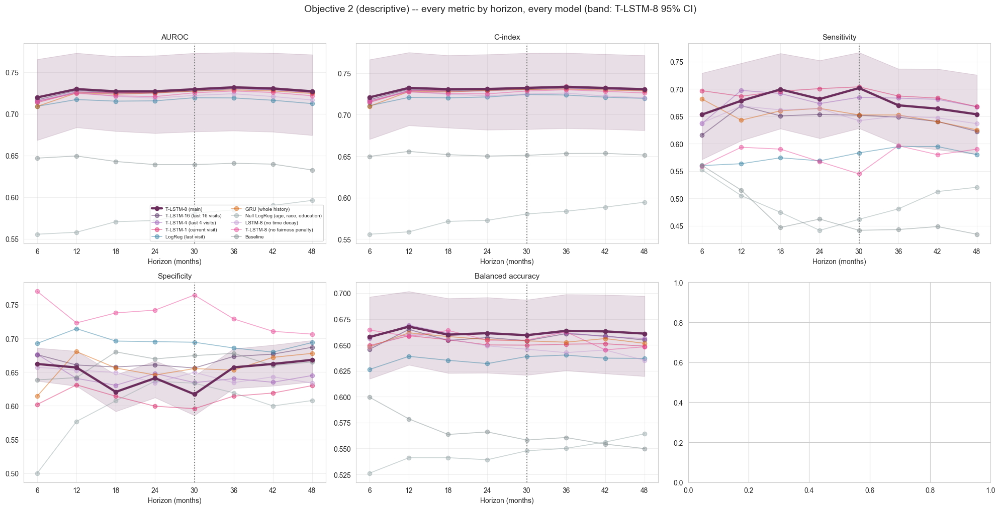


Every model -- every metric at 6 minus 48 months (oriented; descriptive):


,Metric,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Lower bound > 0 on
Comparison,Level,,,,,,
T-LSTM-8 (main): 6 - 48 mo,visit,"-0.007 [-0.044, +0.028]","-0.010 [-0.045, +0.025]","-0.001 [-0.061, +0.059]","-0.006 [-0.022, +0.010]","-0.003 [-0.034, +0.029]",0 of 5 metrics
T-LSTM-16 (last 16 visits): 6 - 48 mo,visit,"-0.009 [-0.045, +0.027]","-0.012 [-0.047, +0.022]","-0.007 [-0.070, +0.054]","-0.011 [-0.027, +0.004]","-0.009 [-0.041, +0.024]",0 of 5 metrics
T-LSTM-4 (last 4 visits): 6 - 48 mo,visit,"-0.011 [-0.048, +0.025]","-0.013 [-0.049, +0.021]","-0.031 [-0.092, +0.034]","+0.031 [+0.013, +0.049] *","+0.000 [-0.033, +0.032]",1 of 5 metrics
T-LSTM-1 (current visit): 6 - 48 mo,visit,"-0.012 [-0.051, +0.022]","-0.016 [-0.051, +0.017]","+0.029 [-0.029, +0.089]","-0.028 [-0.047, -0.011]","+0.001 [-0.029, +0.033]",0 of 5 metrics
LogReg (last visit): 6 - 48 mo,visit,"-0.003 [-0.039, +0.031]","-0.009 [-0.043, +0.023]","-0.020 [-0.088, +0.044]","-0.001 [-0.010, +0.007]","-0.011 [-0.046, +0.023]",0 of 5 metrics
GRU (whole history): 6 - 48 mo,visit,"-0.016 [-0.053, +0.020]","-0.019 [-0.054, +0.016]","+0.056 [-0.001, +0.116]","-0.063 [-0.081, -0.047]","-0.004 [-0.035, +0.027]",0 of 5 metrics
"Null LogReg (age, race, education): 6 - 48 mo",visit,"-0.041 [-0.081, -0.003]","-0.039 [-0.079, -0.002]","+0.032 [-0.030, +0.096]","-0.108 [-0.126, -0.088]","-0.038 [-0.071, -0.004]",0 of 5 metrics
LSTM-8 (no time decay): 6 - 48 mo,visit,"-0.001 [-0.039, +0.036]","-0.004 [-0.041, +0.033]","+0.001 [-0.066, +0.070]","+0.024 [+0.005, +0.042] *","+0.012 [-0.023, +0.048]",1 of 5 metrics
T-LSTM-8 (no fairness penalty): 6 - 48 mo,visit,"-0.006 [-0.043, +0.029]","-0.010 [-0.045, +0.025]","-0.031 [-0.099, +0.042]","+0.063 [+0.045, +0.081] *","+0.016 [-0.020, +0.054]",1 of 5 metrics


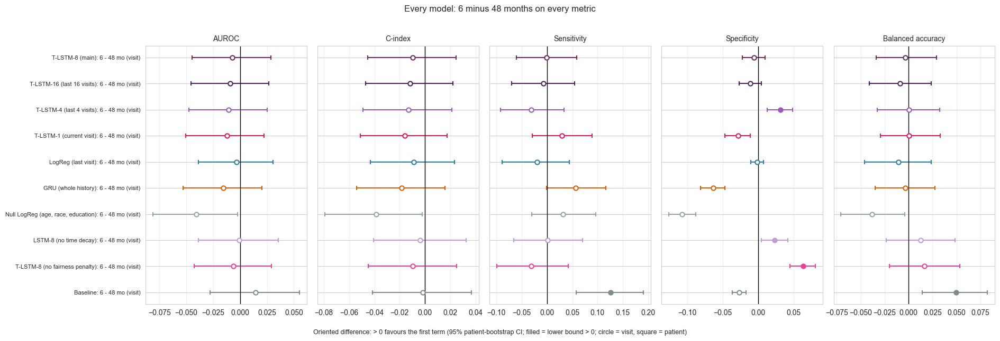

In [56]:
"""
Objective 2, cumulative horizons (descriptive; the test of the horizon is H2c, Section 11.12.11): OBJ2_MODEL's
metric at the shortest horizon minus at the longest, each horizon against its own competing-risk label, IPCW weights,
censoring distribution and cost-weighted alarm threshold (visit_thr_h), the same resamples at both horizons; every
metric at every horizon (OBJ2_MODEL with 95% CIs; every model as point estimates) and every model's difference.
"""
O2_NAME = "T-LSTM-8" if OBJ2_MODEL == "LSTM" else mlab(OBJ2_MODEL)
H_S, H_L = EVAL_HORIZONS_MONTHS[0], EVAL_HORIZONS_MONTHS[-1]
H2_LABEL = f"{O2_NAME}: {H_S} mo - {H_L} mo"
h2 = pd.DataFrame()
if model_res(OBJ2_MODEL) is None or not oof(OBJ2_MODEL):
    print(f"Objective 2 skipped: {OBJ2_MODEL} has no completed repeat.")
else:
    h2 = delta_long([(OBJ2_MODEL, OBJ2_MODEL, H2_LABEL)], "visit", H_S, h_b=H_L)
    print(f"Cumulative horizons (descriptive) -- {O2_NAME}, every metric at {H_S} minus {H_L} months (oriented: > 0 = better at {H_S} months), 95% patient-cluster bootstrap CI ({HYP_BOOT} resamples); * = lower bound > 0:")
    display(delta_wide(h2))

    # ---- every metric at every horizon: OBJ2_MODEL with CIs, every model as point estimates
    O2_TAB = pd.DataFrame({f"{h} mo": {CORE_LABEL[k]: fmt_v(core_value(OBJ2_MODEL, k, "visit", h))
                                       for k in LEVEL_METRICS["visit"]} for h in EVAL_HORIZONS_MONTHS}).T
    O2_TAB.insert(0, "Onset rate (IPCW)", [round(float(np.average(IPCW[h][0][IPCW[h][1] > 0],
                                                                  weights=IPCW[h][1][IPCW[h][1] > 0])), 3)
                                           for h in EVAL_HORIZONS_MONTHS])
    print(f"\n{O2_NAME} -- every metric by horizon (cumulative risk; value [95% CI]):")
    display(O2_TAB)
    O2_MODELS = [m for m in CV_MODELS + ["Baseline"] if model_res(m) is not None and oof(m)]
    O2_PTS = {m: {k: [(_cols(m, k, "visit", h, boot=False) if m != OBJ2_MODEL else _cols(m, k, "visit", h))[0]
                      for h in EVAL_HORIZONS_MONTHS] for k in LEVEL_METRICS["visit"]} for m in O2_MODELS}
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    for ax, k in zip(axes.ravel(), LEVEL_METRICS["visit"]):
        for m in O2_MODELS:
            ax.plot(EVAL_HORIZONS_MONTHS, O2_PTS[m][k], marker="o", label=mlab(m), **model_style(m))
        b_ = [core_value(OBJ2_MODEL, k, "visit", h) for h in EVAL_HORIZONS_MONTHS]
        ax.fill_between(EVAL_HORIZONS_MONTHS, [b["CI low"] for b in b_], [b["CI high"] for b in b_],
                        color=CV_COLORS[OBJ2_MODEL], alpha=0.15)
        ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
        ax.set_xticks(EVAL_HORIZONS_MONTHS); ax.set_xlabel("Horizon (months)")
        ax.set_title(CORE_LABEL[k] + (" (lower = better; falls with the onset rate)" if k == "brier" else ""),
                     fontsize=11)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=7, ncol=2)
    plt.suptitle(f"Objective 2 (descriptive) -- every metric by horizon, every model (band: {O2_NAME} 95% CI)", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective2_metrics_by_horizon.png", dpi=150,
                                    bbox_inches="tight")
    plt.show(); plt.close()

    # ---- every model's shortest - longest horizon difference, every metric
    o2_all = pd.concat([delta_long([(m, m, f"{mlab(m)}: {H_S} - {H_L} mo")], "visit", H_S, h_b=H_L)
                        for m in O2_MODELS], ignore_index=True)
    print(f"\nEvery model -- every metric at {H_S} minus {H_L} months (oriented; descriptive):")
    display(delta_wide(o2_all))
    forest_metrics(o2_all.assign(a=[r for r in o2_all["a"]]), f"Every model: {H_S} minus {H_L} months on every metric",
                   "revised_v27_objective2_test.png")
    O2_TAB.to_csv("objective2_metrics_by_horizon_revised_v27.csv")
    o2_all.to_csv("objective2_all_models_revised_v27.csv", index=False)
    pd.DataFrame({m: {f"{CORE_LABEL[k]} {h} mo": v for k in O2_PTS[m] for h, v in zip(EVAL_HORIZONS_MONTHS, O2_PTS[m][k])}
                  for m in O2_MODELS}).T.to_csv("metrics_by_horizon_all_models_revised_v27.csv")


## 11.12.13 Machine learning against regression in subgroups (H2d)

**H2d** (revised_v24's H2e) — T-LSTM-8 and the GRU against the LogReg in three subgroups fixed in advance where history
or nonlinearity could matter: at least 18 clinic visits before the landmark; irregular visits (SD of the log visit gaps
over the last 8 visits in the top quarter); a SLEDAI-2K flare at the landmark or in the year before. Visit level (the
patient rule mixes visits from inside and outside a subgroup).


H2d subgroups (visit level; outcome-free definitions):


,Landmarks,Share of landmarks,Patients,Landmarks with an onset <= 30 mo
>= 18 prior visits,6848,40.6%,426,231
irregular visits (top-quarter gap SD),3486,20.7%,599,80
flare in the last 12 months,3895,23.1%,567,204



H2d -- T-LSTM-8 and the GRU against the regression within each subgroup (visit level), oriented paired difference [95% CI]; * = lower bound > 0:


,Metric,AUROC,C-index,Sensitivity,Specificity,Balanced accuracy,Lower bound > 0 on
Comparison,Level,,,,,,
>= 18 prior visits: T-LSTM-8 - LogReg,visit,"+0.005 [-0.019, +0.030]","+0.003 [-0.021, +0.027]","+0.080 [+0.029, +0.149] *","-0.050 [-0.076, -0.023]","+0.015 [-0.013, +0.049]",1 of 5 metrics
>= 18 prior visits: GRU - LogReg,visit,"+0.007 [-0.016, +0.030]","+0.005 [-0.017, +0.028]","+0.035 [-0.005, +0.083]","-0.017 [-0.042, +0.009]","+0.009 [-0.014, +0.034]",0 of 5 metrics
irregular visits (top-quarter gap SD): T-LSTM-8 - LogReg,visit,"+0.016 [-0.015, +0.059]","+0.012 [-0.015, +0.047]","+0.096 [+0.009, +0.199] *","-0.039 [-0.061, -0.020]","+0.028 [-0.017, +0.080]",1 of 5 metrics
irregular visits (top-quarter gap SD): GRU - LogReg,visit,"+0.019 [-0.005, +0.046]","+0.015 [-0.008, +0.038]","+0.061 [-0.025, +0.143]","-0.008 [-0.027, +0.011]","+0.026 [-0.017, +0.069]",0 of 5 metrics
flare in the last 12 months: T-LSTM-8 - LogReg,visit,"-0.002 [-0.025, +0.020]","-0.003 [-0.025, +0.018]","+0.092 [+0.048, +0.139] *","-0.068 [-0.087, -0.048]","+0.012 [-0.013, +0.038]",1 of 5 metrics
flare in the last 12 months: GRU - LogReg,visit,"-0.004 [-0.030, +0.021]","-0.004 [-0.029, +0.019]","+0.048 [-0.002, +0.099]","-0.024 [-0.046, -0.003]","+0.012 [-0.015, +0.040]",0 of 5 metrics


AUROC within each subgroup, value [95% CI]:


,>= 18 prior visits,irregular visits (top-quarter gap SD),flare in the last 12 months
T-LSTM-8 (main),"0.703 [0.621, 0.782]","0.660 [0.518, 0.766]","0.689 [0.605, 0.757]"
LogReg (last visit),"0.698 [0.620, 0.776]","0.644 [0.506, 0.755]","0.691 [0.611, 0.762]"
GRU (whole history),"0.705 [0.626, 0.786]","0.664 [0.528, 0.774]","0.687 [0.604, 0.757]"


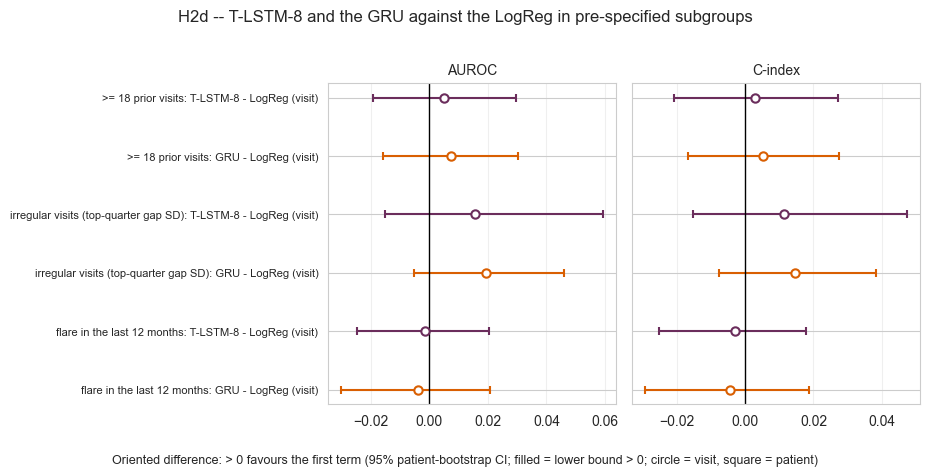

In [57]:
"""
Objective 2 (Section 8.1), machine learning against regression in subgroups (revised_v27):
  H2d  (revised_v24's H2e) T-LSTM-8 and the GRU against the LogReg in pre-specified subgroups (visit level; outcome-free
       definitions). revised_v24's H2d (flexible regression) is dropped with LogReg-Flex.
"""
_have_m = lambda m: model_res(m) is not None and bool(oof(m))


def run_pairs(hyp, pairs, title, fname, equiv=False, levels=("visit", "patient"), **kw):
    """Paired differences for `pairs` (skips pairs not yet run), printed, plotted and added to the summary."""
    pairs = [p for p in pairs if _have_m(p[0]) and _have_m(p[1])]
    if not pairs:
        print(f"{hyp} skipped: the compared models have not run.")
        return pd.DataFrame()
    long = pd.concat([delta_long(pairs, lv, **kw) for lv in levels], ignore_index=True)
    print(f"\n{hyp} -- {title}: oriented paired difference [95% patient-cluster bootstrap CI] (> 0 favours the first "
          "model); * = lower bound > 0:")
    display(delta_wide(long))
    forest_metrics(long, f"{hyp} -- {title}", fname)
    record(hyp, long)
    if equiv:
        eq = long[long["key"].isin(["auroc", "c_index"])]
        for _, r in eq.iterrows():
            OBJ_ROWS.append({"Hypothesis": f"{hyp} (equivalence)", "Comparison": r["Comparison"], "Level": r["Level"],
                             "Metric": r["Metric"], "Estimate [95% CI]": fmt_d(r),
                             "Criterion": f"95% CI within +-{EQUIV_MARGIN}",
                             "Met": bool((r["CI low"] > -EQUIV_MARGIN) and (r["CI high"] < EQUIV_MARGIN))})
    return long


h2d = pd.DataFrame()                # revised_v27: no flexible regression


# ---- H2d: pre-specified subgroups (outcome-free definitions from this and earlier visits)
def subgroup_masks():
    pos = LAND_POS.astype(int)                                    # clinic visits before the landmark
    pids = land["pid"].values
    sd_gap = np.full(len(land), np.nan)
    for i, (p, j) in enumerate(zip(pids, pos)):
        if j >= 4:
            rows = PATIENT_ROWS[p][max(1, j - LSTM_MAIN_WINDOW + 1): j + 1]
            sd_gap[i] = float(np.std(V_GAP[rows]))
    q = np.nanquantile(sd_gap, SUBGROUP_IRREGULAR_Q)
    flare_v = (visits["FLARE_AT_VISIT"].fillna(0).values > 0 if "FLARE_AT_VISIT" in visits
               else (visits.groupby("PTNO")["SLEDAI2_I"].diff() > FLARE_MILD_INCREASE).values)
    vdate = pd.to_datetime(visits["ASSDT"]).values
    recent = np.zeros(len(land), bool)
    for i, (p, j) in enumerate(zip(pids, pos)):
        rows = PATIENT_ROWS[p][: j + 1]
        dt = (vdate[rows[-1]] - vdate[rows]) / np.timedelta64(1, "D")
        recent[i] = bool((flare_v[rows] & (dt <= SUBGROUP_FLARE_DAYS)).any())
    return {f">= {SUBGROUP_LONG_HISTORY} prior visits": pos >= SUBGROUP_LONG_HISTORY,
            "irregular visits (top-quarter gap SD)": np.nan_to_num(sd_gap, nan=-1.0) >= q,
            f"flare in the last {SUBGROUP_FLARE_DAYS // 30} months": recent}


SUBGROUPS = subgroup_masks()
print("\nH2d subgroups (visit level; outcome-free definitions):")
display(pd.DataFrame({name: {"Landmarks": int(m_.sum()), "Share of landmarks": f"{m_.mean():.1%}",
                             "Patients": int(pd.Series(land['pid'].values[m_]).nunique()),
                             "Landmarks with an onset <= 30 mo": int(((Y30 == 1) & (W30 > 0) & m_).sum())}
                      for name, m_ in SUBGROUPS.items()}).T)
_h2e = []
for si, (name, m_) in enumerate(SUBGROUPS.items()):
    pairs = [p for p in H2E_PAIRS if _have_m(p[0]) and _have_m(p[1])]
    if pairs:
        d_ = delta_long(pairs, "visit", mask=m_, tag=f"h2e_{si}")
        if not d_.empty:
            _h2e.append(d_.assign(Comparison=[f"{name}: {c_}" for c_ in d_["Comparison"]], Subgroup=name))
h2e = pd.concat(_h2e, ignore_index=True) if _h2e else pd.DataFrame()
if h2e.empty:
    print("H2d skipped: the compared models have not run.")
else:
    print("\nH2d -- T-LSTM-8 and the GRU against the regression within each subgroup (visit level), oriented paired difference "
          "[95% CI]; * = lower bound > 0:")
    display(delta_wide(h2e))
    _auc_rows = {}
    for si, (name, m_) in enumerate(SUBGROUPS.items()):
        for mm in dict.fromkeys(m for p in H2E_PAIRS for m in p[:2]):
            if _have_m(mm):
                _auc_rows.setdefault(mlab(mm), {})[name] = fmt_v(core_value(mm, "auroc", "visit", mask=m_,
                                                                             tag=f"h2e_{si}"))
    print("AUROC within each subgroup, value [95% CI]:")
    display(pd.DataFrame(_auc_rows).T)
    forest_metrics(h2e[h2e["key"].isin(["auroc", "c_index"])],
                   "H2d -- T-LSTM-8 and the GRU against the LogReg in pre-specified subgroups", "revised_v27_h2d_forest.png")
    record("H2d", h2e)
pd.concat([d for d in (h2d, h2e) if not d.empty] or [pd.DataFrame()], ignore_index=True).to_csv(
    "objective2_ml_vs_regression_revised_v27.csv", index=False)

## 11.12.14 Conclusion — Objective 2

Printed from this run's estimates (Sections 11.12.1–11.12.13).

In [58]:
"""Conclusion of Objective 2, written from this run's estimates (Sections 11.12.1-11.12.13): metric by metric."""
txt = ""
if PRIMARY_RESULT is not None:
    _d = PRIMARY_RESULT["Delta"]
    txt += (f"PRIMARY TEST: visit-level AUROC {mlab(PRIMARY_PAIR[0])} {fmt_v(PRIMARY_RESULT['AUROC a'])} vs "
            f"{mlab(PRIMARY_PAIR[1])} {fmt_v(PRIMARY_RESULT['AUROC b'])}; difference {fmt_d(_d)} -- "
            f"{PRIMARY_RESULT['verdict']}. Secondary: ")
if not h2a.empty:
    _cmp = list(dict.fromkeys(h2a["Comparison"]))
    txt += "H2a (oriented paired differences, 95% CI): " + "; ".join(
        f"{c_} at the {lv} level: {verdict_words(h2a, c_, lv)}" for c_ in _cmp for lv in ("visit", "patient")
        if verdict_words(h2a, c_, lv)) + ". "
    _eqr = [r for r in OBJ_ROWS if r["Hypothesis"] == "H2a (equivalence)"]
    if _eqr:
        txt += (f"Equivalence within +-{EQUIV_MARGIN} (AUROC, C-index): met for "
                f"{sum(r['Met'] for r in _eqr)} of {len(_eqr)} comparisons"
                + (" (" + "; ".join(f"{r['Comparison']} {r['Level']} {r['Metric']}" for r in _eqr if r["Met"]) + ")"
                   if any(r["Met"] for r in _eqr) else "") + ". ")
if not h2b.empty:
    txt += "H2b (slope per doubling of the history over k = " + ", ".join(str(int(x)) for x in K_) + "): " + "; ".join(
        f"{lv} level: " + verdict_words(h2b.assign(Comparison="s"), "s", lv).replace("better on", "increases on")
        .replace("worse on", "decreases on").replace("no clear difference on", "no clear trend on")
        for lv in ("visit", "patient") if verdict_words(h2b.assign(Comparison="s"), "s", lv)) + ". "
if not h2c_df.empty and (h2c_df["m"] == OBJ2_MODEL).any():
    r = h2c_df[h2c_df["m"] == OBJ2_MODEL].iloc[0]
    txt += (f"H2c: {mlab(OBJ2_MODEL)}'s AUROC is " + ", ".join(
        f"{r[f'AUROC {a}-{b} mo']:.3f} in months {a}-{b}" for a, b in OBJ2_INTERVALS)
        + f"; first minus last interval {r['Contrast']:+.3f} [{r['CI low']:+.3f}, {r['CI high']:+.3f}] (criterion "
        f"{'met' if r['Lower bound > 0'] else 'not met'}), slope {r['Slope per year']:+.3f} per year "
        f"[{r['Slope CI low']:+.3f}, {r['Slope CI high']:+.3f}]. ")
for _hyp, _df in [("H2d (subgroups, visit level)", globals().get("h2e"))]:
    if _df is not None and not _df.empty:
        _lv = [lv for lv in ("visit", "patient") if (_df["Level"] == lv).any()]
        txt += f"{_hyp}: " + "; ".join(f"{c_} ({lv}): {verdict_words(_df, c_, lv)}"
                                         for c_ in dict.fromkeys(_df["Comparison"]) for lv in _lv
                                         if verdict_words(_df, c_, lv)) + ". "
for _h in ():
    _eqr = [r for r in OBJ_ROWS if r["Hypothesis"] == f"{_h} (equivalence)"]
    if _eqr:
        txt += (f"{_h} equivalence within +-{EQUIV_MARGIN}: met for {sum(r['Met'] for r in _eqr)} of {len(_eqr)} "
                "comparisons. ")
txt += ("A gain on the threshold metrics (sensitivity, specificity) without one on AUROC / C-index reflects where the "
        "cost-weighted threshold falls, not better ranking; the AUROC is the primary metric. Associations are predictive, "
        "not causal.")
OBJ_CONCLUSIONS["Objective 2"] = txt
print(textwrap.fill(txt, 118))

PRIMARY TEST: visit-level AUROC T-LSTM-8 (main) 0.730 [0.679, 0.773] vs LogReg (last visit) 0.719 [0.670, 0.763];
difference +0.010 [-0.004, +0.023] -- inconclusive. Secondary: H2a (oriented paired differences, 95% CI): T-LSTM-8 -
LogReg at the visit level: better on Sensitivity, Balanced accuracy; worse on Specificity; no clear difference on
AUROC, C-index; T-LSTM-8 - LogReg at the patient level: better on Sensitivity; worse on Specificity; no clear
difference on AUROC, Balanced accuracy; T-LSTM-8 - T-LSTM-1 at the visit level: better on Specificity; no clear
difference on AUROC, C-index, Sensitivity, Balanced accuracy; T-LSTM-8 - T-LSTM-1 at the patient level: worse on
AUROC; no clear difference on Sensitivity, Specificity, Balanced accuracy; T-LSTM-1 - LogReg at the visit level:
better on Sensitivity; worse on Specificity; no clear difference on AUROC, C-index, Balanced accuracy; T-LSTM-1 -
LogReg at the patient level: better on Sensitivity; worse on Specificity; no clear difference

---
# 11.13 Objective 3 — What drives a patient's risk?

Which clinical features raise or lower the predicted risk — disease activity, damage, treatment, symptoms, care
pattern — so a clinician can see why a patient is flagged: SHAP values of T-LSTM-8's final all-data refit, by feature,
by group of correlated variables and by visit position, with individual explanations; the LogReg's coefficients and
nomogram (Section 11.10.5) give the same reading on the log-odds scale. **Descriptive; these are drivers of the
prediction, not proven causes of work disability.**

## 11.13.1 SHAP of the current visit (T-LSTM-8)

SHAP attributions of the calibrated 30-month risk from the LSTM's final all-data refit, to its current-visit inputs
presented as a short constant employed trajectory. The plots show the **15 variables with the largest mean |SHAP|**
(the table lists all of them). The stack is explained by its weights (Section 11.10.11) and the regression by its
nomogram (Section 11.10.5).

In [59]:
"""SHAP explanations for the LSTM (final all-data refit).

The LSTM reads a visit history, so SHAP attributes the 30-month risk to the CURRENT visit presented as a short,
constant trajectory: the visit's encoder features are repeated over SHAP_SEQ_LEN employed visits (the history window
chosen most often, at most 4) at the cohort's median visit gap, and the risk is read at the last one. The features are the encoder's inputs; the gap and the employment
state are held fixed. This is a 'constant recent trajectory'
simplification; the risk-sensitivity curves show each feature's effect with the real histories held as observed. Values are
on the calibrated 30-month risk scale. The calendar year (an adjustment term, head only) is held at the latest
year in the extract, the year a new patient is scored at, and is not attributed. Background and explained landmarks use the first imputation's features
(every seed of the ensemble -- each trained on its own imputation -- is applied to them).
"""
import shap

SHAP_TOP = 15                                   # variables shown in the SHAP plots

SHAP_MODEL = "LSTM" if res_lstm is not None else next(m for m in ["GRU", "Transformer"] if m in MODEL_RESULTS)
_chosen = [v["best"] for k, v in cv_state["folds"].items() if k[0] == SHAP_MODEL]
_mv = seq_cfg(SHAP_MODEL, max(set(_chosen), key=_chosen.count))["max_visits"] if _chosen else None
SHAP_SEQ_LEN = min(4, _mv or 4)
fr = MODEL_RESULTS[SHAP_MODEL]["final"]
data = fr["prep"]
cols = data.cols                                                # the model columns
shap_idx = [j for j, c in enumerate(cols) if c not in ADJUST_COLS]    # attributed: the variables
adj_fixed = {cols.index(c): fr["ctx"]["seq_prep"].transform_value(cols.index(c), float(land[c].max()))
             for c in ADJUST_COLS if c in cols}                        # calendar year held at the latest year
feature_names = [DISPLAY_NAMES.get(cols[j], cols[j]) for j in shap_idx]
gap_log = float(np.median(V_GAP[V_GAP > 0]))
employed = torch.tensor([1.0, 0.0, 0.0, 0.0])


def shap_predict(Z):
    Zs = np.asarray(Z, np.float32)
    n, L = len(Zs), SHAP_SEQ_LEN
    Z = np.zeros((n, len(cols)), np.float32)
    Z[:, shap_idx] = Zs
    for j, v in adj_fixed.items():
        Z[:, j] = v
    gap = torch.full((n, L), gap_log); gap[:, 0] = 0.0
    b = dict(x=torch.from_numpy(np.repeat(Z[:, None, :], L, axis=1)), gap=gap,
             state=employed.expand(n, L, -1).contiguous(),
             elapsed=torch.cumsum(torch.expm1(gap), dim=1) / 10.0, lengths=torch.full((n,), L, dtype=torch.long))
    Hz = 0.0
    with torch.no_grad():
        for net in fr["fitted"]:
            Hz = Hz + torch.sigmoid(net(b))[:, -1].numpy() / len(fr["fitted"])
    return fr["cal"].transform(hazard_risk(Hz)[:, PRIMARY_COL])


rng = np.random.RandomState(SEED)
Z_all = data.VX[land["visit_row"].values][:, shap_idx]            # scaled variables of every landmark
background = Z_all[rng.choice(len(Z_all), 50 if SMOKE else 100, replace=False)]
explain = Z_all[rng.choice(len(Z_all), 40 if SMOKE else 200, replace=False)]
print(f"Computing SHAP values for the {SHAP_MODEL} ({len(explain)} landmarks, {len(background)} background)...")
explainer = shap.Explainer(shap_predict, shap.maskers.Independent(background, max_samples=len(background)),
                           feature_names=feature_names)
shap_values = explainer(explain)

plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=SHAP_TOP)
plt.title(f"SHAP summary -- {SHAP_MODEL}, 30-month work-disability risk ({min(SHAP_TOP, len(feature_names))} of "
          f"{len(feature_names)} variables)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
plt.figure()
shap.plots.bar(shap_values, show=False, max_display=SHAP_TOP)
plt.title(f"Mean |SHAP| -- {SHAP_MODEL}, 30-month work-disability risk")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_shap_bar.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()
preds_ = shap_predict(explain)
for label, i in [("highest-risk", int(np.argmax(preds_))), ("lowest-risk", int(np.argmin(preds_)))]:
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False, max_display=SHAP_TOP)
    plt.title(f"SHAP waterfall -- {label} landmark (30-month risk {preds_[i]:.3f})")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                                    bbox_inches="tight"); plt.show(); plt.close()
shap_imp = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)}) \
    .sort_values("Mean |SHAP|", ascending=False)
print(shap_imp.to_string(index=False, float_format=lambda v: f"{v:.4f}"))



Computing SHAP values for the LSTM (200 landmarks, 100 background)...


KeyError: 'dt'

## 11.13.2 SHAP over the visit window: by feature, by group and by visit recency

SHAP values for every variable **at every one of the last 8 visits** (and the gap to the previous visit) of T-LSTM-8's
final refit, aggregated by feature, by group and by visit position (how far back matters -- the link to Objective 2),
with three individual examples.

In [ ]:
"""
SHAP of T-LSTM-8 over the real visit window (Objective 3). For landmarks with at least LSTM_MAIN_WINDOW visits, each
variable at each of the last 8 visits, and log(1 + gap) at each visit, is one feature (8 x (variables + 1)). The
explained output is the calibrated 30-month risk of the final all-data refit (every seed of the ensemble, first
imputation's features); the masker draws replacement values from other landmarks' windows; the employment state is
held at 'employed' and the calendar year at the latest year (as in Section 11.13.1). Aggregation: per landmark, the
signed SHAP summed over visits (by feature), over the variables of a group (by group) or over the variables of a visit
(by visit position), then mean |.| over landmarks. With the skip connection, the current visit's variables also reach
the hazard heads directly, so the current visit's attribution includes that path.
"""
SHAP_W = LSTM_MAIN_WINDOW
fr8 = MODEL_RESULTS.get("LSTM", {}).get("final") if "LSTM" in MODEL_RESULTS else None
if fr8 is None:
    print("Run Section 11.10.1 (T-LSTM-8) first.")
else:
    data8, cols8 = fr8["prep"], fr8["prep"].cols
    var_idx = [j for j, c in enumerate(cols8) if c not in ADJUST_COLS]
    q8 = len(var_idx)
    adj8 = {cols8.index(c): fr8["ctx"]["seq_prep"].transform_value(cols8.index(c), float(land[c].max()))
            for c in ADJUST_COLS if c in cols8}
    R8, _ = window_rows(SHAP_W)
    elig8 = np.flatnonzero(LAND_POS >= SHAP_W - 1)

    def flat8(rows_l):
        Rw = R8[np.asarray(rows_l)]
        X = data8.VX[Rw][:, :, var_idx]
        return np.concatenate([X, V_GAP[Rw][:, :, None]], axis=2).reshape(len(rows_l), -1)

    def f8(Z):
        Z = np.asarray(Z, np.float32).reshape(-1, SHAP_W, q8 + 1)
        n = len(Z)
        x = np.zeros((n, SHAP_W, len(cols8)), np.float32)
        x[:, :, var_idx] = Z[:, :, :q8]
        for j, v in adj8.items():
            x[:, :, j] = v
        gap = torch.from_numpy(np.ascontiguousarray(Z[:, :, q8]))
        b = dict(x=torch.from_numpy(x), gap=gap, state=torch.tensor([1.0, 0.0, 0.0, 0.0]).expand(n, SHAP_W, -1).contiguous(),
                 elapsed=torch.cumsum(torch.expm1(gap), dim=1) / 10.0, lengths=torch.full((n,), SHAP_W, dtype=torch.long))
        Hz = 0.0
        with torch.no_grad():
            for net in fr8["fitted"]:
                Hz = Hz + torch.sigmoid(net(b))[:, -1].numpy() / len(fr8["fitted"])
        return fr8["cal"].transform(hazard_risk(Hz)[:, PRIMARY_COL])

    rng8 = np.random.RandomState(SEED + 4)
    bg8 = rng8.choice(elig8, min(len(elig8), 30 if SMOKE else 80), replace=False)
    ex8 = rng8.choice(np.setdiff1d(elig8, bg8), min(len(elig8) - len(bg8), 25 if SMOKE else 150), replace=False)
    var_names = [DISPLAY_NAMES.get(cols8[j], cols8[j]) for j in var_idx] + ["Visit gap"]
    POS_LAB = [f"{SHAP_W - 1 - t} back" if t < SHAP_W - 1 else "current" for t in range(SHAP_W)]   # t = 0 oldest
    t0 = time.time()
    expl8 = shap.Explainer(f8, shap.maskers.Independent(flat8(bg8), max_samples=len(bg8)),
                           feature_names=[f"{n} [{p}]" for p in POS_LAB for n in var_names])
    sv8 = expl8(flat8(ex8), max_evals=max(500, 2 * SHAP_W * (q8 + 1) + 1), silent=True)
    S8 = sv8.values.reshape(len(ex8), SHAP_W, q8 + 1)
    print(f"SHAP over the visit window: {len(ex8)} landmarks, {len(bg8)} background, {SHAP_W} visits x {q8 + 1} "
          f"inputs ({time.time() - t0:.0f}s)")
    group_of = [FEATURE_GROUP_OF.get(cols8[j], "Other") for j in var_idx] + ["Care: visit gap"]
    groups8 = list(dict.fromkeys(group_of))
    by_feat = pd.Series(np.abs(S8.sum(1)).mean(0), index=var_names).sort_values(ascending=False)
    Sg = np.stack([S8[:, :, [i for i, g in enumerate(group_of) if g == G]].sum(2) for G in groups8], 2)
    by_group = pd.Series(np.abs(Sg.sum(1)).mean(0), index=groups8).sort_values(ascending=False)
    by_pos = pd.Series(np.abs(S8.sum(2)).mean(0), index=POS_LAB)[::-1]               # current visit first
    SHAP_POS_SHARE = by_pos / by_pos.sum()
    heat = pd.DataFrame(np.abs(S8).mean(0).T, index=var_names, columns=POS_LAB)[POS_LAB[::-1]]

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    top = by_feat.iloc[:SHAP_TOP][::-1]
    axes[0].barh(top.index, top.values, color=CV_COLORS["LSTM"]); axes[0].set_title("By feature (summed over the 8 visits)")
    axes[0].set_xlabel("Mean |SHAP| (30-month risk)")
    axes[1].barh(by_group.index[::-1], by_group.values[::-1], color="#2c7da0"); axes[1].set_title("By group of variables")
    axes[1].set_xlabel("Mean |SHAP| (30-month risk)")
    axes[2].bar(by_pos.index, by_pos.values, color=CV_COLORS["LSTM"])
    for i_, (v_, s_) in enumerate(zip(by_pos.values, SHAP_POS_SHARE.values)):
        axes[2].text(i_, v_, f"{s_:.0%}", ha="center", va="bottom", fontsize=8)
    axes[2].set_title("By visit recency (share of the total)"); axes[2].set_ylabel("Mean |SHAP| (30-month risk)")
    axes[2].tick_params(axis="x", rotation=45)
    plt.suptitle("Objective 3 -- drivers of T-LSTM-8's predicted 30-month risk (not causes of work disability)", y=1.02,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective4_shap_aggregates.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    hv = heat.loc[by_feat.index[:SHAP_TOP]]
    fig, ax = plt.subplots(figsize=(10, 0.42 * len(hv) + 1.8))
    im = ax.imshow(hv.values, aspect="auto", cmap="Purples")
    ax.set_yticks(range(len(hv))); ax.set_yticklabels(hv.index); ax.set_xticks(range(SHAP_W)); ax.set_xticklabels(hv.columns)
    plt.colorbar(im, ax=ax, label="Mean |SHAP|"); ax.set_title("Mean |SHAP| by feature and visit (current visit left)")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective4_shap_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ---- individual examples: the highest-, a median- and the lowest-risk explained landmark
    risk8 = f8(flat8(ex8))
    picks = [("highest risk", int(np.argmax(risk8))), ("median risk", int(np.argsort(risk8)[len(risk8) // 2])),
             ("lowest risk", int(np.argmin(risk8)))]
    fig, axes = plt.subplots(1, 3, figsize=(22, 0.42 * SHAP_TOP + 2.2))
    rows_top = [var_names.index(n) for n in by_feat.index[:SHAP_TOP]]
    for ax, (lab_, i_) in zip(axes, picks):
        M_ = S8[i_][:, rows_top].T[:, ::-1]                                    # features x visits, current first
        vmax = float(np.abs(M_).max()) or 1e-6
        im = ax.imshow(M_, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_yticks(range(len(rows_top))); ax.set_yticklabels([var_names[j] for j in rows_top], fontsize=8)
        ax.set_xticks(range(SHAP_W)); ax.set_xticklabels(POS_LAB[::-1], rotation=45, fontsize=8)
        onset = "onset <= 30 mo" if (Y30[ex8[i_]] == 1 and W30[ex8[i_]] > 0) else "no onset <= 30 mo / unresolved"
        ax.set_title(f"{lab_}: predicted 30-month risk {risk8[i_]:.3f} ({onset})", fontsize=10)
        plt.colorbar(im, ax=ax, label="SHAP (red raises the risk)")
    plt.suptitle("Individual examples -- SHAP by feature and visit", y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_objective4_shap_examples.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("Mean |SHAP| by feature:"); print(by_feat.round(4).to_string())
    print("\nBy visit position (share):"); print(SHAP_POS_SHARE.round(3).to_string())
    pd.concat({"feature": by_feat, "group": by_group, "visit position": by_pos}).to_csv(
        "objective4_shap_aggregates_revised_v27.csv")

## 11.13.3 Conclusion — Objective 3

Printed from this run's estimates (Sections 11.13.1–11.13.2). Descriptive.

In [ ]:
"""Conclusion of Objective 3 (descriptive), written from the SHAP results of Sections 11.13.1-11.13.2."""
if "by_feat" not in globals():
    txt = "Objective 3 could not be described: the SHAP sections have not run."
else:
    txt = ("The largest drivers of T-LSTM-8's predicted 30-month risk are " + ", ".join(by_feat.index[:5])
           + "; by group, " + ", ".join(by_group.index[:3]) + ". "
           f"The current visit carries {SHAP_POS_SHARE.iloc[0]:.0%} of the attribution and the 7 earlier visits "
           f"{1 - SHAP_POS_SHARE.iloc[0]:.0%} (compare H2a and H2b). The LogReg's coefficients (Section 11.10.5) give "
           "the same reading on the log-odds scale. These are drivers of the prediction, not causes of work "
           "disability; correlated variables share attribution, so the grouped view is the safer reading.")
OBJ_CONCLUSIONS["Objective 3"] = txt
print(textwrap.fill(txt, 118))


---
# 11.14 Summary of the objectives

Every hypothesis with its estimate, 95 % CI and whether its criterion is met (`*`), then the three conclusions. No
hypothesis gatekeeps another. The primary test (T-LSTM-8 − LogReg, visit AUROC) is listed first.

In [ ]:
"""Summary of Sections 11.11-11.13: every hypothesis, then every conclusion (no gatekeeping)."""
HYP_TEXT = {"H1a": "The risk separates patients who go on to disability from those who stay at work (T-LSTM-8 vs Baseline)",
            "H1b": "The predicted 30-month risks match what happened (calibration)",
            "H1c": f"Alarms come early enough to intervene (median lead time >= {LEAD_TIME_MIN_MONTHS} months)",
            "H1d": f"Net benefit over alarming at every visit and at none ({DCA_RANGE[0]:.0%}-{DCA_RANGE[1]:.0%})",
            "H2a (primary)": "PRIMARY: T-LSTM-8 discriminates better than the LogReg (visit AUROC; verdict: superior / "
                             f"equivalent within +-{EQUIV_MARGIN} / inconclusive / inferior)",
            "H2a": "Secondary: T-LSTM-8 vs the LogReg, T-LSTM-1 and the GRU; T-LSTM-1 and the GRU vs the LogReg",
            "H2a (equivalence)": f"The main model and the simpler models are equivalent (AUROC / C-index within +-{EQUIV_MARGIN})",
            "H2b": "More visit history improves prediction (slope per doubling of k = 1, 4, 8, 16)",
            "H2c": "Accuracy is higher 0-12 months ahead than 36-48 months ahead (exclusive intervals)",
            "H2d": "T-LSTM-8 and the GRU beat the LogReg in pre-specified subgroups (visit level)"}
obj_summary = pd.DataFrame(OBJ_ROWS)
if obj_summary.empty:
    print("No objective has run.")
else:
    s_ = obj_summary.assign(Cell=[e + (" *" if m_ else "") for e, m_ in zip(obj_summary["Estimate [95% CI]"],
                                                                         obj_summary["Met"])])
    for hyp in ["H2a (primary)", "H1a", "H1b", "H1c", "H1d", "H2a", "H2a (equivalence)", "H2b", "H2c", "H2d"]:
        sub = s_[s_["Hypothesis"] == hyp]
        if sub.empty:
            continue
        print(f"\n{hyp} -- {HYP_TEXT[hyp]}; criterion: {sub['Criterion'].iloc[0]} (* = met)")
        if hyp in ("H1a", "H2a", "H2b", "H2d"):
            w = sub.pivot_table(index=["Comparison", "Level"], columns="Metric", values="Cell", aggfunc="first",
                                sort=False)
            w = w[[c for c in CORE_ORDER if c in w.columns]]
            w["Criterion met on"] = sub.groupby(["Comparison", "Level"], sort=False)["Met"].agg(
                lambda x: f"{int(x.sum())} of {len(x)} metrics")
            display(w)
        else:
            display(sub.set_index(["Comparison", "Level", "Metric"])[
                [c for c in ["Estimate [95% CI]", "Verdict", "Met"] if c in sub.columns and sub[c].notna().any()]])
    obj_summary.to_csv("objectives_summary_revised_v27.csv", index=False)
print("\nCONCLUSIONS")
for k in ["Objective 1", "Objective 2", "Objective 3"]:
    print(f"\n{k}:")
    print(textwrap.fill(OBJ_CONCLUSIONS.get(k, "not run."), 118, initial_indent="  ", subsequent_indent="  "))


---
# 11.15 Additional analyses (not tied to an objective)

The full model specification, the cause-specific survival evaluation (with the signal test against the Baseline), the
two-cause heads, the results overview and the risk trajectories.

## 11.15.1 Full model specification and model availability

TRIPOD+AI item 22: the competing-risk LogReg written out in full (coefficients, baseline hazards,
preprocessing constants and recalibration), and every final all-data refit saved to `final_models_revised_v27/`.

In [ ]:
"""
Full model specification and model availability (TRIPOD+AI items 22 and 18).

The competing-risk LogReg is written out in full: for every design term, its log-odds of each cause (work disability,
other exit, death) against 'no event' in a 3-month interval, from the final all-data refit; the interval terms are
the baseline hazards. The coefficients are the averages over the M_IMPUTATIONS per-imputation fits (Rubin's point estimates; they share
one spline basis). With the preprocessing constants (signed log1p, mean, SD, clipping at +-5 SD) anyone can
compute the 30-month cumulative incidence by hand, for a patient with complete data (missing values need the saved
imputation models; the notebook's own predictions average the per-imputation risks, which differs very slightly): per interval k, softmax over the four classes, then
CIF(30 mo) = sum_k S(k-1) h_1(k). The raw risk is then recalibrated (Section 7) with the intercept and slope below.
The Cox model's hazard ratios are in Section 11.10.8. Tree ensembles and neural networks cannot be written as an
equation, so every final refit is saved (tabular models pickled; sequence models as PyTorch state dicts + their
configuration and scaler).
"""
FINAL_MODEL_DIR = "final_models_revised_v27"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)


def logreg_specification(fr):
    prep = fr["prep"]
    m = fr["fitted"].models[0]                                  # names and the shared spline basis
    kept = [c for i, c in enumerate(m.cols) if i not in m.spl_idx]
    spl_names = list(m.spl.get_feature_names_out([m.cols[i] for i in m.spl_idx])) if m.spl is not None else []
    names = ([DISPLAY_NAMES.get(c, c) for c in kept] + spl_names
             + [f"Interval {k * INTERVAL_MONTHS}-{(k + 1) * INTERVAL_MONTHS} mo (baseline)" for k in range(N_INTERVALS)])
    coef = np.zeros((N_CLASSES, len(names)))
    icpt = np.zeros(N_CLASSES)
    for mk in fr["fitted"].models:                              # Rubin's point estimate: the mean over imputations
        coef[mk.m.classes_.astype(int)] += mk.m.coef_ / len(fr["fitted"].models)
        icpt[mk.m.classes_.astype(int)] += mk.m.intercept_ / len(fr["fitted"].models)
    tab = pd.DataFrame({CAUSE_NAMES[c]: coef[c] - coef[0] for c in range(1, N_CLASSES)}, index=names)
    tab.loc["(Intercept)"] = [icpt[c] - icpt[0] for c in range(1, N_CLASSES)]
    tab.index.name = "Design term (standardised scale)"
    pre = pd.DataFrame({"Signed log1p": [j in prep.log_idx for j in range(len(prep.cols))],
                        "Mean": prep.sc.mean_, "SD": prep.sc.scale_},
                       index=[DISPLAY_NAMES.get(c, c) for c in prep.cols])
    pre.index.name = "Variable (in model order)"
    return tab, pre


if res_logreg is not None and "final" in res_logreg:
    logreg_coef, logreg_prep = logreg_specification(res_logreg["final"])
    cal = res_logreg["final"]["cal"]
    print("Competing-risk LogReg, final all-data refit: log-odds vs 'no event' per 3-month interval "
          "(standardised predictors)")
    display(logreg_coef.round(4))
    print("Preprocessing constants (fitted on all landmarks), in the order of the model's columns:")
    display(logreg_prep.round(4))
    print(f"30-month recalibration: calibrated risk = expit({cal.a:.4f} + {cal.b:.4f} * (logit(raw) - ({cal.mu:.4f})) "
          f"/ {cal.sd:.4f})")
    logreg_coef.to_csv(f"{FINAL_MODEL_DIR}/logreg_coefficients_model_revised_v27.csv")
    logreg_prep.to_csv(f"{FINAL_MODEL_DIR}/logreg_preprocessing_model_revised_v27.csv")

for m, r in MODEL_RESULTS.items():
    fr = r.get("final")
    if fr is None:
        continue
    if m in SEQ_FITTERS:
        torch.save({"state_dicts": [net.state_dict() for net in fr["fitted"]],
                    "config": seq_cfg(m, max(set(v["best"] for k, v in cv_state["folds"].items() if k[0] == m),
                                             key=[v["best"] for k, v in cv_state["folds"].items() if k[0] == m].count)),
                    "inputs": fr["prep"].cols, "scaler": fr["ctx"]["seq_prep"], "calibrator": fr["cal"]},
                   f"{FINAL_MODEL_DIR}/{m}_final_model_revised_v27.pt")
    else:
        with open(f"{FINAL_MODEL_DIR}/{m}_final_model_revised_v27.pkl", "wb") as f:
            pickle.dump({"model": fr["fitted"], "preprocessing": fr["prep"], "calibrator": fr["cal"],
                         "features": fr["ctx"]["features"]}, f)
print(f"\nFinal refits saved in {FINAL_MODEL_DIR}/: {sorted(os.listdir(FINAL_MODEL_DIR))}")
print("Code and model availability: the analysis code (this notebook and its build scripts) and the trained models "
      "will be available at [repository link to be added].")

## 11.15.2 Cause-specific survival evaluation and the signal test (LSTM vs baseline)

Work disability as the event, other exits censored (the sequence models' estimand), follow-up truncated at 48 months.
In every outer fold `scikit-survival` takes the censoring distribution from the **training** fold and scores the
test fold: time-dependent AUROC at 12, 24 and 30 months, and Uno's C truncated at 30 months. The raw (uncalibrated)
30-month risk is compared with the Kaplan–Meier observed risk by decile.

**Signal test.** A baseline without the sequence (a linear discrete-time hazard on age, time since diagnosis, education,
race and calendar year) is run on the same folds. ΔAUROC(t) = LSTM − baseline, with a 95 % patient-cluster bootstrap CI and a paired
permutation null: within each patient, the two models' predictions are swapped at random, which is the null of no
difference between the models.

In [ ]:
"""
Cause-specific survival evaluation of the RAW risks, and the paired signal test (LSTM vs Baseline).

Per outer fold (training fold -> censoring distribution; test fold -> metrics), with sksurv:
  cumulative_dynamic_auc   time-dependent AUROC at SURV_EVAL_TIMES_MONTHS
  concordance_index_ipcw   Uno's C truncated at 30 months
  brier_score, integrated_brier_score   at SURV_EVAL_TIMES_MONTHS and over 6-48 months (CS_PROB_MODELS only)
Fold metrics are averaged within a repeat; the table gives mean (SD) over repeats. The RSF's raw output is a score and
the LogReg's a cumulative incidence, so they get discrimination only.
Delta AUROC(t): the same IPCW AUROC in weighted form (cases 1 / G(T), controls followed past t; G = Kaplan-Meier of
the training fold, as in sksurv), so a patient-cluster bootstrap is a reweighting. Permutation null: within-fold
percentile ranks of the two models, swapped per patient with probability 1/2.
"""
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw, brier_score, integrated_brier_score
from scipy.stats import rankdata

cv_state = run_repeated_cv(models=["Baseline"])          # identical folds, same checkpoint as the other models
SURV_CAP_DAYS = MAX_HORIZON_DAYS + 1
SURV_T_DAYS = [round(h * MONTH_DAYS) for h in SURV_EVAL_TIMES_MONTHS]
SURV_T_COLS = [EVAL_HORIZONS_MONTHS.index(h) for h in SURV_EVAL_TIMES_MONTHS]
CS_PROB_MODELS = ["Baseline", "CoxPH", "GRU", "LSTM", "LSTM1", "Transformer"]      # raw output = 1 - S_1(t)
SURV_MODELS = ["Baseline"] + [m for m in CV_MODELS if any(k[0] == m for k in cv_state["folds"])]


def surv_y(idx, event=None):
    """sksurv (event, time) array for rows idx: `event` (default work disability; anything else censored), follow-up
    truncated at 48 months."""
    event = E_ALL if event is None else event
    t = T_ALL[idx]
    e = (event[idx] == 1) & (t <= MAX_HORIZON_DAYS)
    return np.array(list(zip(e, np.minimum(t, SURV_CAP_DAYS))), dtype=[("event", bool), ("time", float)])


def fold_surv_metrics(f, raw, prob, event=None):
    ytr, yte = surv_y(f["tr"], event), surv_y(f["te"], event)
    auc, _ = cumulative_dynamic_auc(ytr, yte, raw[:, SURV_T_COLS], SURV_T_DAYS)
    out = {f"AUROC {h} mo": a for h, a in zip(SURV_EVAL_TIMES_MONTHS, auc)}
    out[f"Uno C ({PRIMARY_HORIZON_MONTHS} mo)"] = concordance_index_ipcw(ytr, yte, raw[:, PRIMARY_COL],
                                                                           tau=HORIZON_DAYS)[0]
    if prob:
        S = np.clip(1.0 - raw, 0.0, 1.0)
    return out


def model_folds(m):
    return {(r, k): v for (mm, r, k), v in cv_state["folds"].items() if mm == m}


def summarise_models(df, models, cols):
    rows = []
    for m in models:
        d = df[df["model"] == m]
        if len(d):
            rows.append({"Model": m, "Repeats": len(d), **{c: _fmt(d[c]) for c in cols}})
    return pd.DataFrame(rows).set_index("Model")


surv_folds = pd.DataFrame([{"model": m, "repeat": r, "fold": k, **fold_surv_metrics(f, f["raw"], m in CS_PROB_MODELS)}
                           for m in SURV_MODELS for (r, k), f in sorted(model_folds(m).items())])
surv_rep = surv_folds.groupby(["model", "repeat"]).mean(numeric_only=True).drop(columns="fold").reset_index()
surv_cols = [c for c in surv_rep.columns if c not in ("model", "repeat")]
surv_table = summarise_models(surv_rep, SURV_MODELS, surv_cols)
print("Cause-specific survival metrics of the RAW risks (work disability; other exits censored; sksurv, censoring "
      "distribution from each training fold), mean (SD) over repeats:")
display(surv_table)
surv_rep.to_csv("survival_metrics_by_repeat_model_revised_v27.csv", index=False)


# ------------------------------------------------------------------------------------------------ paired signal test
def _fold_entries(m_a="LSTM", m_b="Baseline"):
    """Per fold of both models: test rows, the two models' AUROC-at-t arrays (labels, weights) and scores."""
    fa, fb = model_folds(m_a), model_folds(m_b)
    out = []
    for key in sorted(set(fa) & set(fb)):
        a, b = fa[key], fb[key]
        assert np.array_equal(a["te"], b["te"]), "the two models must share their folds"
        tr, te = a["tr"], a["te"]
        G = CensoringKM(np.minimum(T_ALL[tr], SURV_CAP_DAYS), surv_y(tr)["event"].astype(int))
        cm = CensoringModel(censor_causes=(0, 2, 3)).fit(tr) if CENSORING_IPCW_ON else None
        T = np.minimum(T_ALL[te], SURV_CAP_DAYS)
        e = surv_y(te)["event"]
        lab = []
        for t_d, col in zip(SURV_T_DAYS, SURV_T_COLS):
            case, ctrl = e & (T <= t_d), T > t_d
            w = np.zeros(len(te))
            w[case] = 1.0 / np.maximum(G.at(T[case]), IPCW_MIN_G)
            w[ctrl] = 1.0
            wc = None
            if cm is not None:                                             # covariate-adjusted censoring weights
                wc = np.zeros(len(te))
                wc[case] = 1.0 / np.maximum(cm.G_at_days(te[case], T[case], before=True), IPCW_MIN_G)
                wc[ctrl] = 1.0 / np.maximum(cm.G_at_days(te[ctrl], t_d), IPCW_MIN_G)
            lab.append((case.astype(int), w, wc, col))
        out.append({"key": key, "tr": tr, "te": te, "code": LAND_CODE[te], "lab": lab, "pa": a["raw"], "pb": b["raw"],
                    "ra": rankdata(a["raw"][:, PRIMARY_COL]), "rb": rankdata(b["raw"][:, PRIMARY_COL])})
    return out


def delta_auc(entries, cnt=None, flip=None, covariate=False):
    """(AUROC_a, AUROC_b) at each time, mean over the folds of a repeat, then over repeats. cnt: patient bootstrap
    multiplicities; flip: per-patient swap of the two models (on percentile ranks)."""
    res = {}
    for f in entries:
        m = 1.0 if cnt is None else cnt[f["code"]]
        vals = []
        for y, w, wc, col in f["lab"]:
            ww = (wc if covariate else w) * m
            sa, sb = f["pa"][:, col], f["pb"][:, col]
            if flip is not None:
                sa, sb = rankdata(sa), rankdata(sb)
                s = flip[f["code"]]
                sa, sb = np.where(s, sb, sa), np.where(s, sa, sb)
            vals.append((w_auroc(y, sa, ww), w_auroc(y, sb, ww)))
        res.setdefault(f["key"][0], []).append(vals)
    per_rep = np.array([np.nanmean(v, axis=0) for v in res.values()])     # (repeats, times, 2)
    return np.nanmean(per_rep, axis=0)


if all(model_folds(m) for m in ("LSTM", "Baseline")):
    entries = _fold_entries()
    obs = delta_auc(entries)
    sk = np.nanmean([cumulative_dynamic_auc(surv_y(f["tr"]), surv_y(f["te"]), f["pa"][:, SURV_T_COLS], SURV_T_DAYS)[0]
                     for f in entries], axis=0)
    print(f"Check: weighted-form LSTM AUROC(t) vs sksurv cumulative_dynamic_auc, fold means: "
          + ", ".join(f"{h} mo {a:.4f} vs {s:.4f}" for h, a, s in zip(SURV_EVAL_TIMES_MONTHS, obs[:, 0], sk)))
    n_pt = len(PT_CODE)
    rng = np.random.RandomState(SEED)
    boots = np.array([delta_auc(entries, cnt=np.bincount(rng.randint(0, n_pt, n_pt), minlength=n_pt).astype(float))
                      for _ in range(BOOT_N)])
    d_obs = obs[:, 0] - obs[:, 1]
    d_boot = boots[:, :, 0] - boots[:, :, 1]
    rng = np.random.RandomState(SEED + 1)
    perms = np.array([(lambda r: r[:, 0] - r[:, 1])(delta_auc(entries, flip=rng.rand(n_pt) < 0.5))
                      for _ in range(PERM_N)])
    p_perm = (1 + (np.abs(perms) >= np.abs(d_obs)[None, :] - 1e-12).sum(0)) / (1 + PERM_N)
    signal = pd.DataFrame({
        "Horizon (mo)": SURV_EVAL_TIMES_MONTHS, "AUROC Baseline": obs[:, 1], "AUROC LSTM": obs[:, 0],
        "Delta AUROC (LSTM - Baseline)": d_obs,
        "95% CI (patient bootstrap)": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in
                                       zip(np.nanpercentile(d_boot, 2.5, 0), np.nanpercentile(d_boot, 97.5, 0))],
        "Permutation null, 95% range": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in
                                        zip(np.percentile(perms, 2.5, 0), np.percentile(perms, 97.5, 0))],
        "p (paired permutation)": p_perm}).set_index("Horizon (mo)")
    print(f"\nSIGNAL TEST -- LSTM vs Baseline ({', '.join(BASELINE_COLS)}), identical folds, "
          f"{len({f['key'][0] for f in entries})} repeat(s); {BOOT_N} bootstrap resamples, "
          f"{PERM_N} permutations:")
    display(signal.round(4))
    if CENSORING_IPCW_ON:
        cov = delta_auc(entries, covariate=True)
        print("Covariate-adjusted IPCW (censoring or competing exit modelled on the variables, fitted on "
              "each training fold): " + ", ".join(f"{h} mo: LSTM {a:.3f}, Baseline {b:.3f}, Delta {a - b:+.3f}"
                                                for h, (a, b) in zip(SURV_EVAL_TIMES_MONTHS, cov)))
else:
    print("Signal test skipped: the LSTM or the Baseline has no completed folds.")


# ------------------------------------------------------------------------------------------------ calibration vs KM
def km_risk(t, e, w=None, at=HORIZON_DAYS):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kmf = KaplanMeierFitter().fit(t, e, weights=w)
    s = float(kmf.survival_function_at_times(at).iloc[0])
    lo, hi = kmf.confidence_interval_survival_function_.asof(at).values
    return 1 - s, 1 - hi, 1 - lo


cal_models = [m for m in ["Baseline", "LSTM"] if model_folds(m)]
fig, axes = plt.subplots(1, len(cal_models), figsize=(7.2 * len(cal_models), 6.2), squeeze=False)
for ax, m in zip(axes[0], cal_models):
    fs = model_folds(m)
    p = np.concatenate([f["raw"][:, PRIMARY_COL] for f in fs.values()])
    rows = np.concatenate([f["te"] for f in fs.values()])
    t, e = np.minimum(T_ALL[rows], SURV_CAP_DAYS), surv_y(rows)["event"].astype(int)
    wpt = land["pt_weight"].values[rows]
    q = pd.qcut(p, 10, labels=False, duplicates="drop")
    pts = []
    for g in range(int(q.max()) + 1):
        k = q == g
        obs_, lo, hi = km_risk(t[k], e[k])
        pts.append((p[k].mean(), obs_, lo, hi, km_risk(t[k], e[k], wpt[k])[0]))
    pts = np.array(pts)
    ax.errorbar(pts[:, 0], pts[:, 1], yerr=[pts[:, 1] - pts[:, 2], pts[:, 3] - pts[:, 1]], fmt="o-",
                color=CV_COLORS[m], capsize=3, label="Kaplan-Meier observed (landmarks), 95% CI")
    ax.plot(pts[:, 0], pts[:, 4], "s--", color="#555555", ms=4, lw=1, label="Kaplan-Meier observed (patient-weighted)")
    hi_ = float(np.nanmax(pts[:, [0, 3]])) * 1.08
    ax.plot([0, hi_], [0, hi_], "k:", alpha=0.6, label="Perfect calibration")
    o_all = km_risk(t, e)[0]
    ax.set_title(f"{m} -- raw 30-month risk vs Kaplan-Meier (deciles, all repeats)\n"
                 f"mean predicted {p.mean():.3f}, observed {o_all:.3f}", fontsize=11)
    ax.set_xlabel("Predicted 30-month risk (raw, cause-specific)"); ax.set_ylabel("Observed 30-month risk")
    ax.set_xlim(0, hi_); ax.set_ylim(0, hi_); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_calibration_km_raw.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

## 11.15.3 Two-cause heads: work disability specifically, or leaving work for any reason?

The LSTM's second head estimates the cause-specific risk of an other exit; with the first it gives the risk of leaving
work for any reason. Each of the three risks is scored against each outcome (work disability, other exit, any exit from
work) with Uno's C and the time-dependent AUROC at 30 months, as in Section 11.15.2. A specific signal shows as the
disability head ranking work disability better than it ranks other exits. The any-exit row and column are the
composite-outcome sensitivity analysis.

In [ ]:
"""
Two-cause heads -- work disability specifically vs leaving work for any reason (composite outcome), from the LSTM's
out-of-fold predictions (ctx["aux"] of every outer fold). Uno's C at 30 months and cumulative/dynamic AUROC at 30 months,
sksurv, censoring distribution from the training fold; the outcome's competing events are censored.
"""
lstm_folds = model_folds("LSTM") if "LSTM" in CV_MODELS else {}
if lstm_folds and all(f.get("aux") for f in lstm_folds.values()):
    OUTCOMES = {"Work disability": E_ALL, "Other exit": (C_ALL >= 2).astype(int),
                "Any exit from work (composite)": (C_ALL >= 1).astype(int)}
    RISKS = {"Disability head": lambda f: f["raw"], "Exit head": lambda f: f["aux"]["exit_raw"],
             "Any exit (both heads)": lambda f: f["aux"]["composite_raw"]}
    rows = []
    for (r, k), f in sorted(lstm_folds.items()):
        for rn, get in RISKS.items():
            raw = get(f)
            for on, ev in OUTCOMES.items():
                ytr, yte = surv_y(f["tr"], ev), surv_y(f["te"], ev)
                rows.append({"repeat": r, "fold": k, "risk": rn, "outcome": on,
                             "C": concordance_index_ipcw(ytr, yte, raw[:, PRIMARY_COL], tau=HORIZON_DAYS)[0],
                             "AUROC": cumulative_dynamic_auc(ytr, yte, raw[:, [PRIMARY_COL]], [HORIZON_DAYS])[0][0]})
    two = pd.DataFrame(rows).groupby(["risk", "outcome", "repeat"])[["C", "AUROC"]].mean().reset_index()
    for metric in ["C", "AUROC"]:
        tab = two.groupby(["risk", "outcome"])[metric].agg(_fmt).unstack("outcome")
        tab = tab.reindex(index=list(RISKS), columns=list(OUTCOMES))
        print(f"LSTM two-cause heads -- {'Uno C' if metric == 'C' else 'time-dependent AUROC'} at "
              f"{PRIMARY_HORIZON_MONTHS} months, rows = risk, columns = outcome, mean (SD) over repeats:")
        display(tab)
    m_ = two.groupby(["risk", "outcome"])["C"].mean()
    print(f"Disability head: C {m_[('Disability head', 'Work disability')]:.3f} for work disability vs "
          f"{m_[('Disability head', 'Other exit')]:.3f} for other exits; exit head: "
          f"{m_[('Exit head', 'Other exit')]:.3f} for other exits vs {m_[('Exit head', 'Work disability')]:.3f} for "
          f"work disability.")
else:
    print("Two-cause analysis skipped: the LSTM was run without the exit head (SEQ_CONFIG['exit_head']) or has no "
          "completed folds.")

## 11.15.4 Results overview

The main comparisons in a few figures, from the pooled out-of-fold predictions above (nothing is refitted):

1. **Forest plot**: ΔC-index of every model against the LogReg, visit level (30-month AUROC) and patient level (the highest
   risk in the 60 months before onset; event-free patients: the risk at the last landmark), paired on identical folds, with 95 % patient-cluster bootstrap CIs and H2a's equivalence
   margin.
2. **Observed risk by predicted-risk group** (< 2 %, 2–5 %, 5–10 %, ≥ 10 % 30-month risk) and the **cumulative
   incidence** of work disability from the landmark in each group (Aalen–Johansen, other exits competing).
3. **Natural frequencies**: what the alarm rule does per 100 visits and per 100 patients.
4. **Risk before the decisive visit**: mean predicted risk and share of visits alarmed by months before the last
   landmark of the patient's window, event vs event-free patients — rising risk (early warning) or a persistently
   higher level (risk stratification)?
5. **Visit-level decision curves** of every model, with the data-driven threshold and revised_v16's R = 10 marked.
6. **The patient scoring rule**: the main rule (event patients: any alarm in the 60 months before onset; event-free: the last landmark) vs revised_v18's any alarm in the 30-month window vs revised_v17's last landmark of the 30-month window.


In [ ]:
"""
Results overview (Section 11.15.4), from the pooled out-of-fold predictions already computed (nothing is refitted):
  1. forest plot of Delta C-index vs the LogReg (visit and patient level), paired, 95% patient-cluster bootstrap CIs;
  2. observed 30-month onset rate by predicted-risk group (visit level) and cumulative incidence by group
     (Aalen-Johansen, other exits competing) for T-LSTM-8 and the LogReg;
  3. natural frequencies per 100 visits and per 100 patients;
  4. risk and share alarmed by months before the decisive (last window) landmark, event vs event-free patients;
  5. visit-level decision curves of every model;
  6. patient scoring rules side by side (last landmark / any alarm / first landmark).
"""
OV_MODELS = [m for m in CV_MODELS if m in MODEL_RESULTS]
_PT_LEVEL = "Patient (C-index, " + {"any": "highest risk in the window)", "last": "risk at the last landmark)",
                                   "run": f"highest risk in the {PATIENT_WINDOW_MONTHS}-month window)",
                                   "mixed": f"highest risk <= {EVENT_LOOKBACK_MONTHS} mo before onset / at the last "
                                            "landmark)"}[PATIENT_RULE]
OV_REF = "LogReg"
OV_BOOT = 200 if SMOKE else 1000
_lab = lambda m: MODEL_LABELS.get(m, m)
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
PI_VISIT = float(np.average(_y30[_w30 > 0], weights=_w30[_w30 > 0]))


def _pt_reps(m):
    return {r: pr["pt"] for (mm, r), pr in MODEL_RESULTS[m]["preds"].items() if mm == m}


_OV_PT_BOOT = [cnt for _, cnt in patient_boot_counts(OV_BOOT, seed=2041)]


def patient_delta_c(a, b, col="score"):
    """Delta patient C-index (a - b) on the same patients, mean over paired repeats, 95% patient bootstrap CI."""
    ra, rb = _pt_reps(a), _pt_reps(b)
    preps = []
    for r in sorted(set(ra) & set(rb)):
        ix = ra[r].index.intersection(rb[r].index)
        y = ra[r].loc[ix, "y"].values
        preps.append((auc_prep(y, ra[r].loc[ix, col].values), auc_prep(y, rb[r].loc[ix, col].values),
                      PT_CODE.get_indexer(ix)))
    if not preps:
        return None
    f = lambda cnt: np.mean([auc_w(pa, cnt[c]) - auc_w(pb, cnt[c]) for pa, pb, c in preps])
    B = np.array([f(cnt) for cnt in _OV_PT_BOOT])
    return {"Delta": f(np.ones(len(PT_CODE))), "CI low": np.nanpercentile(B, 2.5), "CI high": np.nanpercentile(B, 97.5)}


# ------------------------------------------------------------------------------------------------ 1. forest plot
forest = []
for m in [x for x in OV_MODELS if x != OV_REF]:
    dv, dp = paired_delta(m, OV_REF), patient_delta_c(m, OV_REF)
    if dv is not None:
        forest.append({"Model": _lab(m), "Level": "Visit (30-month AUROC)",
                       **{k: dv[k] for k in ("Delta", "CI low", "CI high")}})
    if dp is not None:
        forest.append({"Model": _lab(m), "Level": _PT_LEVEL, **dp})
forest_df = pd.DataFrame(forest)
if not forest_df.empty:
    forest_df["95% CI"] = forest_df.apply(lambda r: f"[{r['CI low']:+.3f}, {r['CI high']:+.3f}]", axis=1)
    print(f"1. Delta C-index vs {OV_REF} (paired on identical folds; 95% patient-cluster bootstrap CI, {OV_BOOT} resamples):")
    display(forest_df.set_index(["Level", "Model"])[["Delta", "95% CI"]].round(3))
    levels = list(dict.fromkeys(forest_df["Level"]))
    order = list(dict.fromkeys(forest_df["Model"]))[::-1]
    fig, axes = plt.subplots(1, len(levels), figsize=(7 * len(levels), 0.5 * len(order) + 1.8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, lev in zip(axes, levels):
        d = forest_df[forest_df["Level"] == lev].set_index("Model").reindex(order)
        ys = np.arange(len(order))
        ax.errorbar(d["Delta"], ys, xerr=[d["Delta"] - d["CI low"], d["CI high"] - d["Delta"]], fmt="o",
                    color="#2c3e50", ecolor="#7f8c8d", capsize=3, ms=6)
        ax.axvline(0, color="black", lw=1)
        ax.set_yticks(ys); ax.set_yticklabels(order); ax.set_title(lev)
        ax.set_xlabel(f"Delta C vs {OV_REF} (95% CI)"); ax.grid(axis="x", alpha=0.3)
    plt.suptitle(f"Every model against the competing-risk LogReg (repeated CV, pooled test folds)", y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_overview_forest.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    forest_df.to_csv("overview_delta_c_revised_v27.csv", index=False)

# ------------------------------------------------------------------------------------------------ 2. risk groups
RISK_CUTS = [0.02, 0.05, 0.10]
RISK_LABELS = ["< 2%", "2-5%", "5-10%", ">= 10%"]
rg_rows = []
for m in OV_MODELS:
    for (mm, r), pr in MODEL_RESULTS[m]["preds"].items():
        if mm != m:
            continue
        p = pr["P"][:, PRIMARY_COL]
        grp = np.digitize(p, RISK_CUTS)
        for j, lg in enumerate(RISK_LABELS):
            k = grp == j
            kr = k & (_w30 > 0)
            ok = _w30[kr].sum() > 0
            rg_rows.append({"Model": _lab(m), "Risk group": lg, "Share of visits": float(k.mean()),
                            "Patients": len(np.unique(PID_ALL[k])),
                            "Mean predicted": float(np.average(p[kr], weights=_w30[kr])) if ok else np.nan,
                            "Observed (IPCW)": float(np.average(_y30[kr], weights=_w30[kr])) if ok else np.nan})
rg = pd.DataFrame(rg_rows).groupby(["Model", "Risk group"], sort=False).mean()
print(f"\n2. Visit level by predicted 30-month risk: share of landmark visits, patients with a visit in the group, mean "
      f"predicted and observed onset rate within 30 months (IPCW), mean over repeats (overall onset rate {PI_VISIT:.3f}):")
display(rg.round(3))
rg.to_csv("overview_risk_groups_revised_v27.csv")


def aalen_johansen(t, c, grid, cause=1):
    """Cumulative incidence of `cause` at the times `grid` (Aalen-Johansen; every other observed cause competes, 0 =
    censored)."""
    t, c = np.asarray(t, float), np.asarray(c, int)
    ut = np.unique(t[c > 0])
    if not len(ut):
        return np.zeros(len(grid))
    n_at = len(t) - np.searchsorted(np.sort(t), ut, side="left")
    d1 = pd.Series((c == cause).astype(float)).groupby(t).sum().reindex(ut).fillna(0).values
    da = pd.Series((c > 0).astype(float)).groupby(t).sum().reindex(ut).fillna(0).values
    s_before = np.r_[1.0, np.cumprod(1 - da / n_at)[:-1]]
    F = np.cumsum(s_before * d1 / n_at)
    i = np.searchsorted(ut, grid, side="right") - 1
    return np.where(i >= 0, F[np.maximum(i, 0)], 0.0)


_grid_mo = np.linspace(0, MAX_HORIZON_MONTHS, 97)
_cif_models = [m for m in ["LSTM", OV_REF] if m in MODEL_RESULTS]
if _cif_models:
    fig, axes = plt.subplots(1, len(_cif_models), figsize=(7.5 * len(_cif_models), 5), sharey=True)
    axes = np.atleast_1d(axes)
    _cols = ["#2c7da0", "#f1c40f", "#e67e22", "#c0392b"]
    for ax, m in zip(axes, _cif_models):
        pr = MODEL_RESULTS[m]["preds"][(m, min(r for (mm, r) in MODEL_RESULTS[m]["preds"] if mm == m))]
        grp = np.digitize(pr["P"][:, PRIMARY_COL], RISK_CUTS)
        for j, lg in enumerate(RISK_LABELS):
            k = grp == j
            if k.sum() < 20:
                continue
            ax.step(_grid_mo, aalen_johansen(T_ALL[k] / MONTH_DAYS, C_ALL[k], _grid_mo), where="post", color=_cols[j],
                    lw=2, label=f"{lg} ({k.mean():.0%} of visits)")
        ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":")
        ax.set_xlabel("Months from the landmark visit"); ax.set_title(f"{_lab(m)} (CV repeat 1)")
        ax.grid(alpha=0.3); ax.legend(title="Predicted 30-month risk", fontsize=9)
    axes[0].set_ylabel("Cumulative incidence of work disability")
    plt.suptitle("Cumulative incidence of work disability from the landmark, by predicted-risk group "
                 "(Aalen-Johansen; other exits competing)", y=1.02, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_overview_cif_by_risk.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ 3. natural frequencies
pi = COHORT_EVENT_SHARE
nf_rows = []
for m in OV_MODELS:
    vt, pt = MODEL_RESULTS[m]["visit_table"]["Value"], MODEL_RESULTS[m]["patient_table"]["Value"]
    res_df = MODEL_RESULTS[m]["res_df"]
    sens, spec = pt["sensitivity"], pt["specificity"]
    caught, false_flag = 100 * pi * sens, 100 * (1 - pi) * (1 - spec)
    nf_rows.append({"Model": _lab(m),
                    "Alarms per 100 visits": res_df["alerts_per_100"].mean(),
                    "Of 100 alarms: onset <= 30 mo": 100 * vt["ppv"],
                    "Of 100 visits before an onset: alarmed": 100 * vt["sensitivity"],
                    "Per 100 patients: onsets flagged": caught,
                    "onsets missed": 100 * pi * (1 - sens),
                    "flagged, no onset": false_flag,
                    "not flagged, no onset": 100 * (1 - pi) * spec,
                    "Patients flagged per onset caught": (caught + false_flag) / caught if caught > 0 else np.nan})
nf_df = pd.DataFrame(nf_rows).set_index("Model")
print(f"\n3. Natural frequencies -- visit level (alarms at each fold's threshold) and per 100 patients at the cohort's event "
      f"share ({100 * pi:.0f} of 100 patients have an onset; patient rule: "
      f"{PATIENT_RULE_TEXT}):")
display(nf_df.round(1))
nf_df.to_csv("overview_natural_frequencies_revised_v27.csv")

# ------------------------------------------------------------------------------------------------ 4. risk before the decisive visit
TRAJ_BINS = np.arange(0, 61, 6)            # months before the last landmark of the window (the decisive visit)
TRAJ_BOOT = 100 if SMOKE else 300


def trajectory(m):
    """Per patient and 6-month bin before the decisive landmark: mean calibrated 30-month risk and share of landmarks
    alarmed (CV repeat 1), with y (1 = event patient)."""
    pr = MODEL_RESULTS[m]["preds"][(m, min(r for (mm, r) in MODEL_RESULTS[m]["preds"] if mm == m))]
    f = pr["pt"]
    p = pr["P"][:, PRIMARY_COL]
    dl = f["day_last"].reindex(PID_ALL).values
    mb = (dl - VDAY_ALL) / MONTH_DAYS
    k = np.isfinite(mb) & (mb >= 0) & (mb < TRAJ_BINS[-1])
    d = pd.DataFrame({"pid": PID_ALL[k], "bin": np.digitize(mb[k], TRAJ_BINS) - 1, "p": p[k],
                      "a": (p >= pr["visit_thr"]["target"])[k], "y": f["y"].reindex(PID_ALL[k]).values})
    return d.groupby(["y", "pid", "bin"]).agg(p=("p", "mean"), a=("a", "mean")).reset_index(), \
        float(np.nanmean(pr["visit_thr"]["target"]))


def _mean_ci(v, rng):
    v = np.asarray(v, float)
    b = [rng.choice(v, len(v)).mean() for _ in range(TRAJ_BOOT)]
    return v.mean(), np.percentile(b, 2.5), np.percentile(b, 97.5)


_tm = [m for m in ["LSTM", OV_REF] if m in MODEL_RESULTS]
if _tm:
    fig, axes = plt.subplots(2, len(_tm), figsize=(7.5 * len(_tm), 9), sharex=True)
    axes = np.array(axes).reshape(2, len(_tm))
    rng_t = np.random.default_rng(2042)
    mids = -(TRAJ_BINS[:-1] + 3)
    traj_rows = []
    for c_, m in enumerate(_tm):
        per, thr_m = trajectory(m)
        for yv, col, lab_y in [(1, "#c0392b", "work-disability onset"), (0, "#2c7da0", "event-free")]:
            for row_, what in [(0, "p"), (1, "a")]:
                est = [_mean_ci(per.loc[(per.y == yv) & (per.bin == b), what], rng_t)
                       if ((per.y == yv) & (per.bin == b)).sum() >= 5 else (np.nan,) * 3 for b in range(len(mids))]
                e, lo, hi = (np.array(x) for x in zip(*est))
                axes[row_, c_].plot(mids, e, "o-", color=col, lw=2, label=lab_y)
                axes[row_, c_].fill_between(mids, lo, hi, color=col, alpha=0.15)
                if row_ == 0:
                    traj_rows += [{"Model": _lab(m), "Group": lab_y, "Months before decisive visit": -mm_, "Mean risk": ee,
                                   "Patients": int(((per.y == yv) & (per.bin == b)).sum())}
                                  for b, (mm_, ee) in enumerate(zip(mids, e))]
        axes[0, c_].axhline(thr_m, color="gray", ls="--", lw=1, label=f"mean alarm threshold ({thr_m:.3f})")
        axes[0, c_].set_title(_lab(m)); axes[0, c_].set_ylabel("Mean predicted 30-month risk")
        axes[1, c_].set_ylabel("Share of visits alarmed"); axes[1, c_].set_ylim(0, 1)
        axes[1, c_].set_xlabel("Months before the decisive visit (last landmark of the 30-month window)")
        for ax in axes[:, c_]:
            ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.suptitle("Risk before the decisive visit: event vs event-free patients (CV repeat 1; 95% patient bootstrap bands)",
                 y=1.01, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_overview_risk_before_decision.png", dpi=150,
                                    bbox_inches="tight")
    plt.show(); plt.close()
    pd.DataFrame(traj_rows).to_csv("overview_risk_before_decision_revised_v27.csv", index=False)
    print("4. A flat, higher line for event patients = risk stratification (a persistently higher level); a line that "
          "rises towards the decisive visit = early warning.")

# ------------------------------------------------------------------------------------------------ 5. decision curves
_pts = np.linspace(0.005, 0.15, 59)
fig, ax = plt.subplots(figsize=(10.5, 6))
for m in OV_MODELS:
    p, y, w, _, _ = stacked(m, MODEL_RESULTS[m]["preds"])
    ax.plot(_pts, ipcw_net_benefit(y, p, w, _pts)[0], label=_lab(m), **model_style(m))
ax.plot(_pts, ipcw_net_benefit(y, p, w, _pts)[1], color="gray", ls="--", label="Alarm at every visit")
ax.axhline(0, color="black", lw=1, label="No alarms")
ax.axvline(PI_VISIT, color="#c0392b", ls=":", lw=1.5,
           label=f"data-driven threshold = onset rate {PI_VISIT:.3f} (R = {(1 - PI_VISIT) / PI_VISIT:.0f})")
ax.axvline(1 / 11, color="#7f8c8d", ls=":", lw=1.5, label="R = 10 (revised_v16), threshold 0.091")
ax.set_ylim(-0.25 * PI_VISIT, 1.1 * PI_VISIT)
ax.set_xlabel("Threshold probability t (30-month risk); cost ratio R = (1 - t) / t")
ax.set_ylabel("Net benefit (IPCW, per landmark visit)")
ax.set_title("5. Visit-level decision curves, all models (pooled test folds, all repeats)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_overview_decision_curves.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ 6. patient scoring rules
if PATIENT_RULE == "run":
    PT_RULES = [(f"{PATIENT_ALARM_RUN} alarms in a row, {PATIENT_WINDOW_MONTHS}-mo window (main)", "score", "flag"),
                (f"any alarm, {PATIENT_WINDOW_MONTHS}-mo window", "score_max", "flag_any"),
                (f"revised_v21: events any alarm <= {MIXED_LOOKBACK_MONTHS} mo / event-free last landmark",
                 "score_max_mx", "flag_any_mx"),
                ("any alarm, 30-mo window (revised_v18)", "score_max_30", "flag_any_30")]
elif PATIENT_RULE == "mixed":
    PT_RULES = [(f"events: any alarm <= {EVENT_LOOKBACK_MONTHS} mo; event-free: last landmark (main)", "score", "flag"),
                ("any alarm, 30-mo window (revised_v18)", "score_max_30", "flag_any_30"),
                ("last landmark, 30-mo window (revised_v17)", "score_last_30", "flag_last_30")]
else:
    PT_RULES = [("any alarm" + (" (main)" if PATIENT_RULE == "any" else ""), "score_max", "flag_any"),
                ("last landmark" + (" (main)" if PATIENT_RULE == "last" else ""), "score_last", "flag_last"),
                ("first landmark", "score_first", "flag_first")]
rule_rows = []
for m in OV_MODELS:
    for r, f in _pt_reps(m).items():
        row = {"Model": _lab(m)}
        for rule, sc, fl in PT_RULES:
            ok = f[sc].notna().values & f[fl].notna().values      # the 30-month rules have their own patients
            y, a = f["y"].values[ok], f[fl].values[ok] == 1
            row[(rule, "C-index")] = w_auroc(y, f[sc].values[ok], np.ones(int(ok.sum())))
            row[(rule, "sensitivity")] = float(a[y == 1].mean())
            row[(rule, "specificity")] = float(1 - a[y == 0].mean())
            row[(rule, "patients")] = int(ok.sum())
        rule_rows.append(row)
rule_df = pd.DataFrame(rule_rows).groupby("Model", sort=False).mean()
rule_df.columns = pd.MultiIndex.from_tuples(rule_df.columns)
print("\n6. Patient level under several scoring rules (mean over repeats; C-index of the patient score, sensitivity "
      "and specificity of the patient flag; the comparison rules on the main rule's patients). revised_v21's rule gives "
      f"event patients {MIXED_LOOKBACK_MONTHS} months of visits to alarm once and judges event-free patients at one "
      "visit, so its sensitivity and C-index are inflated; the window rules judge both groups over the same time:")
display(rule_df.round(3))
rule_df.to_csv("overview_patient_rules_revised_v27.csv")


## 11.15.5 Risk trajectories

How each patient's predicted risk moves over time, from the pooled out-of-fold predictions (nothing is refitted). The
time axis is **months before the work-disability onset** (event patients) or **months before the last landmark**
(event-free patients — the visit the patient rule judges them at). Risk = the calibrated 30-month risk at each
landmark, averaged over the CV repeats (every landmark is held out once per repeat); a landmark counts as alarmed when
it alarmed in at least half of the repeats.

1. **Individual trajectories** of 12 randomly drawn event and 12 event-free patients (alarmed visits marked), with the
   60 months the patient rule reads shaded.
2. **Median and interquartile range** of the risk by 6-month bin, 0–120 months back (one value per patient and bin),
   and the same for the **risk relative to the visit's alarm threshold** (log ratio; > 0 = alarm), the quantity the
   alarm rule reads.
3. **Heat map** of every event patient's risk relative to the threshold over the 60 months before onset, sorted by the
   earliest alarm: a rising band toward the right is early warning, a band that is red throughout is a persistently
   high-risk patient.
4. **Sensitivity by look-back**: the share of event patients with any alarm in the last X months before onset,
   X = 6–120 months, every model, with the event-free patients' specificity at their last landmark. The main rule is
   X = 60; revised_v18's window was 30.


In [ ]:
"""
Risk trajectories (Section 11.15.5), from the pooled out-of-fold predictions (nothing is refitted). Time axis: months
before the onset (event patients; landmarks whose follow-up ends in that onset) or before the patient's last landmark
(event-free patients). Risk = the calibrated 30-month risk per landmark averaged over the CV repeats; alarmed = alarmed
in >= half of the repeats.
"""
RT_MODELS = [m for m in ["LSTM", "LSTM1", "LogReg"] if m in MODEL_RESULTS]
RT_BACK_MONTHS, RT_BIN, RT_N_SHOW = 120, 6, 12
RT_EDGES = np.arange(0, RT_BACK_MONTHS + RT_BIN, RT_BIN)
_is_ev_land = (_stratum == "Event") & (land["event"].values == 1)
_mb_neg = (_last_land - _vdate.values) / np.timedelta64(1, "D") / MONTH_DAYS
RT_MB = np.where(_is_ev_land, T_ALL / MONTH_DAYS, np.where(_neg_any, _mb_neg, np.nan))
RT_Y = np.where(_is_ev_land, 1, 0)
RT_OK = np.isfinite(RT_MB) & (RT_MB >= 0) & (RT_MB <= RT_BACK_MONTHS)


def mean_risk_over_repeats(m):
    """Per landmark: the calibrated 30-month risk and its alarm threshold averaged over the CV repeats, and the share
    of repeats in which the landmark alarmed."""
    reps = [pr for (mm, _), pr in MODEL_RESULTS[m]["preds"].items() if mm == m]
    P = np.nanmean([pr["P"][:, PRIMARY_COL] for pr in reps], axis=0)
    T = np.nanmean([pr["visit_thr"]["target"] for pr in reps], axis=0)
    A = np.nanmean([(pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]).astype(float) for pr in reps], axis=0)
    return P, T, A


def rt_frame(m):
    P, T, A = mean_risk_over_repeats(m)
    k = np.flatnonzero(RT_OK)
    p = np.clip(P[k], 1e-6, 1)
    return pd.DataFrame({"pid": PID_ALL[k], "y": RT_Y[k], "mb": RT_MB[k], "p": p, "thr": T[k], "alarm": A[k] >= 0.5,
                         "lr": np.log(p / np.clip(T[k], 1e-6, 1))})


RT = {m: rt_frame(m) for m in RT_MODELS}
_groups = [(1, "#c0392b", "work-disability onset"), (0, "#2c7da0", "event-free")]
_xlab = {1: "Months before onset", 0: "Months before the last landmark (end of follow-up)"}

if RT_MODELS:
    # ---------------------------------------------------------------------------------------- 1. individual patients
    _n_lm = RT[RT_MODELS[0]].groupby(["y", "pid"]).size()
    _rng_rt = np.random.default_rng(2051)
    _show = {}
    for yv, _, _ in _groups:
        cand = _n_lm.loc[yv][_n_lm.loc[yv] >= 3].index.values           # patients with >= 3 landmarks in 120 months
        _show[yv] = _rng_rt.choice(cand, min(RT_N_SHOW, len(cand)), replace=False)
    fig, axes = plt.subplots(len(RT_MODELS), 2, figsize=(15, 4.2 * len(RT_MODELS)), sharex=True, sharey=True,
                             squeeze=False)
    cmap = plt.get_cmap("tab20")
    for r_, m in enumerate(RT_MODELS):
        d = RT[m]
        for c_, (yv, _, lab_y) in enumerate(_groups):
            ax = axes[r_, c_]
            for j, pid in enumerate(_show[yv]):
                g = d[(d.pid == pid) & (d.y == yv)].sort_values("mb", ascending=False)
                ax.plot(-g["mb"], g["p"], "-", color=cmap(j % 20), lw=1.2, alpha=0.85)
                ga = g[g["alarm"]]
                ax.scatter(-ga["mb"], ga["p"], color=cmap(j % 20), s=22, zorder=3, edgecolor="black", linewidth=0.4)
            thr_med = float(np.median(d["thr"]))
            ax.axhline(thr_med, color="gray", ls="--", lw=1, label=f"median alarm threshold ({thr_med:.3f})")
            if yv == 1:
                ax.axvspan(-EVENT_LOOKBACK_MONTHS, 0, color="#c0392b", alpha=0.06,
                           label=f"the {EVENT_LOOKBACK_MONTHS} months the patient rule reads")
            ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
            ax.set_title(f"{_lab(m)} -- {lab_y} ({len(_show[yv])} random patients)")
            if r_ == len(RT_MODELS) - 1:
                ax.set_xlabel(_xlab[yv])
        axes[r_, 0].set_ylabel("Calibrated 30-month risk (log scale)")
    plt.suptitle("1. Individual risk trajectories (mean over CV repeats; filled dots = alarmed visits)", y=1.01, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_risk_trajectories_individual.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ---------------------------------------------------------------------------------------- 2. median / IQR by bin
    mids = -(RT_EDGES[:-1] + RT_BIN / 2)
    bins_rows = []
    fig, axes = plt.subplots(2, len(RT_MODELS), figsize=(6.5 * len(RT_MODELS), 9), sharex=True, squeeze=False)
    for c_, m in enumerate(RT_MODELS):
        d = RT[m].assign(bin=lambda x: np.minimum((x["mb"] // RT_BIN).astype(int), len(mids) - 1))
        pb = d.groupby(["y", "pid", "bin"])[["p", "lr"]].mean().reset_index()     # one value per patient and bin
        for yv, col, lab_y in _groups:
            n = pb[pb.y == yv].groupby("bin").size().reindex(range(len(mids))).fillna(0)
            for row_, what in [(0, "p"), (1, "lr")]:
                q = (pb[pb.y == yv].groupby("bin")[what].quantile([0.25, 0.5, 0.75]).unstack()
                     .reindex(range(len(mids))))
                q.loc[n.values < 5] = np.nan
                axes[row_, c_].plot(mids, q[0.5], "o-", color=col, lw=2, ms=4, label=lab_y)
                axes[row_, c_].fill_between(mids, q[0.25], q[0.75], color=col, alpha=0.15)
                if row_ == 0:
                    bins_rows += [{"Model": _lab(m), "Group": lab_y, "Months back (bin start)": int(RT_EDGES[b]),
                                   "Patients": int(n[b]), "Risk, median": q.loc[b, 0.5], "Risk, Q1": q.loc[b, 0.25],
                                   "Risk, Q3": q.loc[b, 0.75]} for b in range(len(mids))]
        axes[0, c_].set_yscale("log"); axes[0, c_].set_title(_lab(m))
        axes[0, c_].set_ylabel("Calibrated 30-month risk, median and IQR (log scale)")
        axes[1, c_].axhline(0, color="black", lw=1, label="alarm threshold")
        axes[1, c_].set_ylabel("log(risk / alarm threshold), median and IQR")
        axes[1, c_].set_xlabel("Months before onset (event) / before the last landmark (event-free)")
        for ax in axes[:, c_]:
            ax.axvline(-EVENT_LOOKBACK_MONTHS, color="#c0392b", ls=":", lw=1.2)
            ax.axvline(-PRIMARY_HORIZON_MONTHS, color="gray", ls=":", lw=1.2)
            ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
    plt.suptitle(f"2. Risk by months before onset or the end of follow-up (dotted: {PRIMARY_HORIZON_MONTHS} and "
                 f"{EVENT_LOOKBACK_MONTHS} months)", y=1.01, fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_risk_trajectories_bins.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    pd.DataFrame(bins_rows).to_csv("risk_trajectory_bins_revised_v27.csv", index=False)

    # ---------------------------------------------------------------------------------------- 3. heat map, event patients
    m = RT_MODELS[0]
    nb_ = EVENT_LOOKBACK_MONTHS // RT_BIN
    d = RT[m]
    d = d[(d.y == 1) & (d.mb <= EVENT_LOOKBACK_MONTHS)].assign(
        bin=lambda x: np.minimum((x["mb"] // RT_BIN).astype(int), nb_ - 1))
    H = d.groupby(["pid", "bin"])["lr"].mean().unstack().reindex(columns=range(nb_))
    _earliest = d[d["alarm"]].groupby("pid")["mb"].max().reindex(H.index)        # earliest alarm, months before onset
    H = H.loc[_earliest.fillna(-1).sort_values(ascending=False).index]
    cm = plt.get_cmap("RdBu_r").copy(); cm.set_bad("#e5e5e5")
    fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.04 * len(H) + 1.8)))
    im = ax.imshow(np.ma.masked_invalid(H.values[:, ::-1]), aspect="auto", cmap=cm, vmin=-2, vmax=2,
                   interpolation="nearest")
    ax.set_xticks(np.arange(nb_)); ax.set_xticklabels([f"{-(nb_ - i) * RT_BIN}" for i in range(nb_)])
    ax.set_yticks([])
    ax.set_xlabel(f"Months before onset ({RT_BIN}-month bins, labelled by their start)")
    ax.set_ylabel(f"{len(H)} event patients, sorted by the earliest alarm\n(never alarmed at the bottom; grey = no visit)")
    plt.colorbar(im, ax=ax, label="log(risk / alarm threshold), patient mean in the bin; > 0 = alarm")
    ax.set_title(f"3. {_lab(m)}: every event patient's risk over the {EVENT_LOOKBACK_MONTHS} months before onset")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_risk_trajectories_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"3. {int(_earliest.notna().sum())} of {len(H)} event patients alarmed in the {EVENT_LOOKBACK_MONTHS} months "
          f"before onset ({_lab(m)}, alarm in >= half of the repeats); earliest alarm a median "
          f"{_earliest.median():.0f} months before onset.")

# -------------------------------------------------------------------------------------------- 4. sensitivity by look-back
lb_grid = np.arange(RT_BIN, RT_BACK_MONTHS + 1, RT_BIN)
k_ev = np.flatnonzero(_is_ev_land & (RT_MB <= RT_BACK_MONTHS))
k_neg = np.flatnonzero(_win_neg_last)
ev_pids = np.unique(PID_ALL[k_ev])
lb_rows = []
fig, ax = plt.subplots(figsize=(10.5, 6))
for m in OV_MODELS:
    sens_r, spec_r = [], []
    for (mm, r), pr in MODEL_RESULTS[m]["preds"].items():
        if mm != m:
            continue
        a = pr["P"][:, PRIMARY_COL] >= pr["visit_thr"]["target"]
        ka = k_ev[a[k_ev]]
        latest = pd.Series(RT_MB[ka]).groupby(PID_ALL[ka]).min().reindex(ev_pids)   # most recent alarm, months back
        sens_r.append([float((latest <= x).mean()) for x in lb_grid])
        spec_r.append(float(1 - a[k_neg].mean()))
    s, sp = np.mean(sens_r, axis=0), float(np.mean(spec_r))
    ax.plot(lb_grid, s, label=f"{_lab(m)} (specificity at the last landmark {sp:.2f})", **model_style(m))
    lb_rows += [{"Model": _lab(m), "Look-back (months)": int(x), "Sensitivity": v, "Specificity (last landmark)": sp}
                for x, v in zip(lb_grid, s)]
ax.axvline(PRIMARY_HORIZON_MONTHS, color="gray", ls=":", lw=1.5, label=f"{PRIMARY_HORIZON_MONTHS} months (revised_v18)")
ax.axvline(EVENT_LOOKBACK_MONTHS, color="#c0392b", ls=":", lw=1.5, label=f"{EVENT_LOOKBACK_MONTHS} months (main rule)")
ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
ax.set_xlabel("Look-back X: months before onset in which any alarm counts")
ax.set_ylabel("Sensitivity (share of event patients alarmed)")
ax.set_title(f"4. Sensitivity by look-back ({len(ev_pids)} event patients with a landmark in the {RT_BACK_MONTHS} months "
             f"before onset; mean over repeats)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_risk_trajectories_lookback.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
lb_df = pd.DataFrame(lb_rows)
lb_df.to_csv("risk_trajectory_lookback_revised_v27.csv", index=False)
print("4. Sensitivity at 30 / 60 / 120 months of look-back (patients with no landmark in the last X months count as "
      "missed, so the 60-month value can sit slightly below the main table's):")
display(lb_df[lb_df["Look-back (months)"].isin([PRIMARY_HORIZON_MONTHS, EVENT_LOOKBACK_MONTHS, RT_BACK_MONTHS])]
        .pivot(index="Model", columns="Look-back (months)", values="Sensitivity").round(3))


---
# 11.16 Sensitivity analyses

Temporal validation (development before 2012, validation from 2012) and the pre-specified sensitivity analyses
(refitted variants of the outcome, landmarks, threshold, variables, imputation and horizon).

## 11.16.1 Temporal validation (additional sensitivity analysis)

Does a model developed on earlier years transport to later years? Every model is refitted **once** on the landmarks
before 1 January 2012 (their follow-up censored at that date, so only what was known then is used) and validated on
the landmarks from 2012 on. This is **in addition to** the repeated cross-validation, which remains the primary
analysis; nothing above is replaced. Onsets become rarer in later calendar years, so this also shows how the models
cope with a shift in the outcome rate. The calendar-year adjustment is clipped to the development years, so the
validation period is scored at the rate of the last development year: this checks whether the adjusted models
transport without extrapolating the trend. Alarms use the era-standardised threshold with $f$ clipped to the
development years, so the whole validation period is thresholded at the last development year's risk level.

In [ ]:
"""
Temporal validation -- an ADDITIONAL sensitivity analysis; it replaces nothing above.

Question: does a model developed on earlier years transport to later years? Every model is refitted once:
  development : landmarks before TEMPORAL_CUTOFF, with their follow-up administratively CENSORED at the cutoff (only
                what was known at that date is used: an onset after the cutoff is not an event for training)
  validation  : landmarks on or after the cutoff, with their real follow-up
The fitting recipe is the main one (Section 8): cross-fitting inside the development set for tuning, recalibration and
the visit threshold; then the development-set model scores the validation landmarks. A patient can contribute landmarks to both periods (a temporal split, not a patient split); the sequence
models' label-free pretraining uses the covariate histories of development-period patients.

Reported per model: the visit-level table on the validation period (IPCW from the validation landmarks), a patient-level
table on the validation period's 30-month windows (discrimination and decisions; patient-probability calibration is not
reported because the patient recalibration would need development-period patient outcomes that extend past the
cutoff), and the visit-level calibration curves. Checkpointed in TEMPORAL_PATH.
"""
RUN_TEMPORAL_VALIDATION = True
TEMPORAL_CUTOFF = pd.Timestamp("2012-01-01")
TEMPORAL_PATH = "temporal_validation_revised_v27_smoke.pkl" if SMOKE else "temporal_validation_revised_v27.pkl"
TEMPORAL_BOOT = 100 if SMOKE else 500


def _temporal_split():
    d = land["visit_date"].values
    return np.flatnonzero(d < np.datetime64(TEMPORAL_CUTOFF)), np.flatnonzero(d >= np.datetime64(TEMPORAL_CUTOFF))


def temporal_recalibration_shift(res, tr):
    """Temporal recalibration (Booth et al., Int J Epidemiol 2020): per horizon, the logit shift that matches the mean
    calibrated OOF risk to the observed IPCW risk on the development landmarks of the last TEMPORAL_RECAL_YEARS before
    the cutoff (slope kept). Called while the development outcomes are censored at the cutoff."""
    recent = CAL_YEAR_ALL[tr] >= TEMPORAL_CUTOFF.year - TEMPORAL_RECAL_YEARS
    out = []
    for j, hd in enumerate(HORIZON_DAYS_GRID):
        y, w = ipcw_rows(tr, hd)
        k = recent & (w > 0)
        lp = _logit(np.clip(res["oof_P"][k, j], 1e-6, 1 - 1e-6))
        try:
            out.append(brentq(lambda a: np.average(_expit(a + lp), weights=w[k]) - np.average(y[k], weights=w[k]),
                              -10, 10))
        except ValueError:
            out.append(0.0)
    return np.array(out)


def run_temporal_validation(models=None):
    """Fits every model once on the development period (outcomes censored at the cutoff) and scores the validation
    period. The outcome arrays are swapped for the development rows during fitting and always restored."""
    global T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS, ADMIN_DAYS_ALL
    models = list(models or [m for m in CV_MODELS if m not in ABLATION_MODELS])   # revised_v27: no ablations
    state = {}
    if os.path.exists(TEMPORAL_PATH):
        with open(TEMPORAL_PATH, "rb") as f:
            state = pickle.load(f)
    tr, te = _temporal_split()
    days_to_cut = (TEMPORAL_CUTOFF - land["visit_date"]).dt.days.values.astype(float)
    in_tr = np.zeros(len(land), bool); in_tr[tr] = True
    past_cut = in_tr & (T_ALL > days_to_cut)
    saved = (T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS, land["pt_event"].values.copy(), ADMIN_DAYS_ALL)
    new_pids = set(PID_ALL[te]) - set(PID_ALL[tr])                     # patients first seen after the cutoff
    try:
        T_ALL = np.where(past_cut, days_to_cut, saved[0])
        # revised_v27: the development landmarks' potential follow-up ends at the cutoff
        ADMIN_DAYS_ALL = np.where(in_tr, np.minimum(days_to_cut, saved[8]), saved[8])
        C_ALL = np.where(past_cut, 0, saved[1])
        E_ALL = (C_ALL == 1).astype(int)
        Y_CR, M_CR = discrete_time_targets(T_ALL, C_ALL)
        S_CS, E_CS = cs_targets(T_ALL, LEFT_ALL, C_ALL)
        land["pt_event"] = pd.Series(np.where(in_tr, E_ALL, 0)).groupby(PID_ALL).transform("max").values
        if "__selection__" not in state:                                # revised_v27: the pre-specified set
            state["__selection__"] = SELECTION_ALL
        sel_tv = state["__selection__"]
        for m in models:
            if m in state:
                continue
            t0 = time.time()
            if m in STACK_SPECS:                                         # formed from the members (Section 6.3)
                mem, meta = STACK_SPECS[m]
                if any(x not in state for x in mem):
                    continue
                res = stack_fold([state[x] for x in mem], mem, tr, te, meta, CV_SEED + 777)
            else:
                res = run_fold(m, tr, te, CV_SEED + 777, model_features(m, sel_tv), sel_tv["freq"],
                               exclude_pids=new_pids)
            res["trecal_shift"] = temporal_recalibration_shift(res, tr)
            state[m] = res
            with open(TEMPORAL_PATH, "wb") as f:
                pickle.dump(state, f)
            print(f"[temporal] {m}: fitted on {len(tr):,} development landmarks in {time.time() - t0:.0f}s")
    finally:
        T_ALL, C_ALL, E_ALL, Y_CR, M_CR, S_CS, E_CS = saved[:7]
        land["pt_event"] = saved[7]
        ADMIN_DAYS_ALL = saved[8]
    return state, tr, te


def temporal_arrays(res, te):
    """(visit arrays, patient arrays) of the validation period, in the format of level_arrays."""
    y, w = ipcw_rows(te, HORIZON_DAYS)
    p = res["P"][:, PRIMARY_COL]
    k = w > 0
    visit = [(y[k], p[k], w[k], (p >= res["visit_thr"]["target"])[k], LAND_CODE[te][k])]
    f = patient_frame(te, p, res["visit_thr"]["target"])
    patient = [(f["y"].values, f["score"].values, np.ones(len(f)), f["flag"].values == 1, PT_CODE.get_indexer(f.index))]
    return visit, patient


if RUN_TEMPORAL_VALIDATION:
    temporal_state, tv_tr, tv_te = run_temporal_validation()
    print(f"Temporal validation: development = landmarks before {TEMPORAL_CUTOFF.date()} ({len(tv_tr):,} landmarks, "
          f"{len(set(PID_ALL[tv_tr]))} patients; outcomes censored at the cutoff); validation = landmarks from "
          f"{TEMPORAL_CUTOFF.date()} ({len(tv_te):,} landmarks, {len(set(PID_ALL[tv_te]))} patients).")
    tv_visit, tv_patient, tv_arrs = {}, {}, {}
    for m in [x for x in CV_MODELS if x in temporal_state]:
        va, pa = temporal_arrays(temporal_state[m], tv_te)
        tv_arrs[m] = va
        tv_visit[m] = metric_table(m, None, "visit", n_boot=TEMPORAL_BOOT, arrs=va)
        tv_patient[m] = metric_table(m, None, "patient", n_boot=TEMPORAL_BOOT, arrs=pa)
        tv_patient[m].loc[["cal_slope", "cal_intercept", "oe_ratio", "ppv_cohort", "npv_cohort"], ["Value", "CI low",
                                                                                               "CI high"]] = np.nan
    n_pos = int(tv_arrs[next(iter(tv_arrs))][0][0].sum())
    print(f"\nVISIT LEVEL, validation period ({n_pos} resolved landmarks with an onset within 30 months): "
          f"value [95% CI]")
    display(pd.DataFrame({m: {r["Metric"]: (f"{r['Value']:.3f} [{r['CI low']:.3f}, {r['CI high']:.3f}]"
                                            if np.isfinite(r["Value"]) else "n/a") for _, r in t.iterrows()}
                          for m, t in tv_visit.items()}).T)
    _pa = temporal_arrays(temporal_state[next(iter(tv_visit))], tv_te)[1][0]
    print(f"\nPATIENT LEVEL, validation period ({int(_pa[0].sum())} event vs {int((_pa[0] == 0).sum())} event-free "
          f"patients with a 30-month window in it; calibration not reported, see above): value [95% CI]")
    display(pd.DataFrame({m: {r["Metric"]: (f"{r['Value']:.3f} [{r['CI low']:.3f}, {r['CI high']:.3f}]"
                                            if np.isfinite(r["Value"]) else "n/a")
                              for k, r in t.iterrows() if k not in ("brier", "cal_slope", "cal_intercept", "oe_ratio",
                                                                     "ppv_cohort", "npv_cohort")}
                          for m, t in tv_patient.items()}).T)
    _trc = []
    for m in [x for x in CV_MODELS if x in temporal_state]:
        a_ = float(temporal_state[m]["trecal_shift"][PRIMARY_COL])
        y_, p_, w_ = tv_arrs[m][0][:3]
        p2_ = _expit(_logit(np.clip(p_, 1e-6, 1 - 1e-6)) + a_)
        _trc.append({"Model": MODEL_LABELS.get(m, m), "Intercept shift (logit, from the last "
                     f"{TEMPORAL_RECAL_YEARS} development years)": a_,
                     "O/E": np.sum(w_ * y_) / np.sum(w_ * p_), "O/E, temporally recalibrated": np.sum(w_ * y_) / np.sum(w_ * p2_),
                     "Calibration intercept": fast_calibration(y_, p_, w_)[1],
                     "Calibration intercept, temporally recalibrated": fast_calibration(y_, p2_, w_)[1]})
    print("\nTEMPORAL RECALIBRATION (Booth et al. 2020): the validation-period calibration of every model as fitted and "
          "with its intercepts re-estimated on the last development years (discrimination is unchanged):")
    display(pd.DataFrame(_trc).set_index("Model").round(3))
    pd.concat({m: t for m, t in tv_visit.items()}).to_csv("temporal_validation_visit_model_revised_v27.csv")
    pd.concat({m: t for m, t in tv_patient.items()}).to_csv("temporal_validation_patient_model_revised_v27.csv")
    _ms = list(tv_arrs)
    fig, axes = plt.subplots(int(np.ceil(len(_ms) / 4)), 4, figsize=(20.8, 4.9 * int(np.ceil(len(_ms) / 4))))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, _ms):
        plot_calibration(ax, m, None, "visit", tv_visit[m], arrs=tv_arrs[m], key=("temporal", m), title=m)
    for ax in axes[len(_ms):]:
        ax.set_visible(False)
    plt.suptitle(f"Temporal validation -- visit-level calibration in the validation period (from "
                 f"{TEMPORAL_CUTOFF.date()})", y=1.01, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_temporal_calibration.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    # the same plots after temporal recalibration of the intercept (Booth et al. 2020): does it fix the over-prediction?
    fig, axes = plt.subplots(int(np.ceil(len(_ms) / 4)), 4, figsize=(20.8, 4.9 * int(np.ceil(len(_ms) / 4))))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, _ms):
        a_ = float(temporal_state[m]["trecal_shift"][PRIMARY_COL])
        arr2 = [(y_, _expit(_logit(np.clip(p_, 1e-6, 1 - 1e-6)) + a_), w_, al_, c_) for y_, p_, w_, al_, c_ in tv_arrs[m]]
        plot_calibration(ax, m, None, "visit", None, arrs=arr2, key=("temporal_recal", m),
                         title=f"{m} (temporally recalibrated)")
    for ax in axes[len(_ms):]:
        ax.set_visible(False)
    plt.suptitle(f"Temporal validation -- visit-level calibration from {TEMPORAL_CUTOFF.date()} after temporal "
                 f"recalibration (intercept re-estimated on the last {TEMPORAL_RECAL_YEARS} development years)", y=1.01,
                 fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/revised_v27_temporal_calibration_recalibrated.png", dpi=150,
                                    bbox_inches="tight")
    plt.show(); plt.close()
else:
    print("Temporal validation skipped (set RUN_TEMPORAL_VALIDATION = True).")

In [ ]:
"""LSTM only -- alarm lead time, alert burden, and SD-shift risk-sensitivity plots.

TP  (correct): months from the earliest alarm in the 30 months before onset to onset (the patient rule of Section
      11.6), and, for TP patients alarmed at the last landmark before onset, from the start of the uninterrupted run of
      alarms that ends there.
FP  (incorrect): event-free patients alarmed in their window; for those alarmed at its last landmark, months from the
      start of that final run to the last landmark. CIs are clustered on patient.
"""
import copy
import os

assert res_lstm is not None and "final" in res_lstm, "Run the LSTM section (11.10.1) first."
LT_MODEL = "LSTM"
LT_DIR = f"{OUT_DIR}/revised_v27_lstm_leadtime"
os.makedirs(LT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------------------ patient frames
def lstm_alarm_frame(pr):
    """The patient frame of one repeat (Section 11.6) with its outcome under the patient rule (TP / FP / FN / TN)."""
    f = pr["pt"].copy()
    flag, ev = f["flag"].values == 1, f["y"].values == 1
    f["outcome"] = np.select([ev & flag, ~ev & flag, ev & ~flag], ["TP", "FP", "FN"], "TN")
    f["run_whole_window"] = f["run_len"] == f["n_win"]
    return f


_lt_preds = {r: pr for (m, r), pr in res_lstm["preds"].items() if m == LT_MODEL}
LT_FRAMES = {r: lstm_alarm_frame(pr) for r, pr in sorted(_lt_preds.items())}
_pool = pd.concat([f.assign(repeat=r) for r, f in LT_FRAMES.items()])
_tp = _pool[_pool["outcome"] == "TP"]
_nr = len(LT_FRAMES)
print(f"Correctly flagged (TP) patients alarmed at EVERY landmark of their 30-month window (the final alarm run covers the "
      f"window): {_tp['run_whole_window'].mean():.1%} (pooled over repeats); for them the lead time is set by the window "
      f"and the visit spacing rather than by a rise in risk.")
print(f"Per repeat, flagged event patients whose alarm had switched off by the last landmark before onset: "
      f"{((_pool['y'] == 1) & (_pool['flag_any'] == 1) & (_pool['flag_last'] == 0)).sum() / _nr:.1f}; flagged "
      f"event-free patients not alarmed at the last landmark of their window: "
      f"{((_pool['y'] == 0) & (_pool['flag_any'] == 1) & (_pool['flag_last'] == 0)).sum() / _nr:.1f}.")


def _boot_median_ci(s, n=BOOT_N, seed=SEED):
    """95% patient-cluster bootstrap CI of the median of `s` (index = pid, pooled over repeats)."""
    arrs = list(s.groupby(level=0).apply(np.asarray).values)
    rng = np.random.RandomState(seed)
    meds = [np.median(np.concatenate([arrs[i] for i in rng.randint(len(arrs), size=len(arrs))])) for _ in range(n)]
    return np.percentile(meds, [2.5, 97.5])


# ------------------------------------------------------------------------------------------------ lead-time table
rows = []
for oc, col, label in [("TP", "first_alarm_lead_mo", "Correct (TP patients): earliest alarm in the window -> onset"),
                       ("TP", "run_lead_mo", "TP patients alarmed at the last landmark: start of the final alarm run -> onset"),
                       ("FP", "run_mo", "Incorrect (FP patients alarmed at the last landmark): start of the final run -> "
                                        "last window landmark")]:
    per = {r: f.loc[f["outcome"] == oc, col].dropna() for r, f in LT_FRAMES.items()}
    s = pd.concat(per.values())
    if not len(s):
        continue
    per_rep = [v.median() for v in per.values() if len(v)]
    lo, hi = _boot_median_ci(s)
    rows.append({"Prediction": label, "Patients per repeat": np.mean([len(v) for v in per.values()]),
                 "Median (mo)": s.median(), "95% CI": f"[{lo:.1f}, {hi:.1f}]",
                 "IQR (mo)": f"{s.quantile(.25):.1f}-{s.quantile(.75):.1f}",
                 "Per-repeat medians": f"{np.min(per_rep):.1f}-{np.max(per_rep):.1f}"})
lead_table = pd.DataFrame(rows).set_index("Prediction")
print(f"{LT_MODEL} -- lead time and alarm-run length (pooled over {_nr} CV repeat(s); CI: {BOOT_N} patient-cluster "
      f"bootstrap resamples)")
display(lead_table.round(1))


# ------------------------------------------------------------------------------------------------ alert burden (TP)
burden = []
for r, f in LT_FRAMES.items():
    tp = f[f["outcome"] == "TP"]
    burden.append({"Alarmed visits in the final run per TP patient (median)": tp["run_len"].median(),
                   "Alarmed visits in the window per TP patient (median)": tp["n_alarm"].median(),
                   "Visits in window per TP patient (median)": tp["n_win"].median(),
                   "Share of window visits alarmed, TP (median)": (tp["n_alarm"] / tp["n_win"]).median(),
                   "Flagged patients per TP patient (1 / PPV)": f["flag"].sum() / max(len(tp), 1),
                   "All window alarms (all patients) per TP patient": f["n_alarm"].sum() / max(len(tp), 1)})
burden = pd.DataFrame(burden)
burden_table = pd.DataFrame({"Mean over repeats": burden.mean(), "Min": burden.min(), "Max": burden.max()})
print(f"\n{LT_MODEL} -- alert burden for correctly flagged (TP) patients, 30-month window")
display(burden_table.round(2))
lead_table.to_csv(f"{LT_DIR}/lead_time.csv"); burden_table.to_csv(f"{LT_DIR}/alert_burden.csv")

# ------------------------------------------------------------------------------------------------ histogram
tp_lead = _pool.loc[_pool["outcome"] == "TP"].groupby(level=0)["lead_mo"].median()   # per patient, over repeats
med = tp_lead.median()
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(tp_lead, bins=np.arange(0, HORIZON_DAYS / MONTH_DAYS + 3, 3), color="#2c3e50", edgecolor="white", alpha=0.9)
ax.axvline(med, color="#c0392b", ls="--", lw=2, label=f"Median {med:.1f} months")
ax.set_xlabel("Months from the " + ("earliest alarm" if PATIENT_RULE == "any" else "start of the final alarm run")
              + " to work-disability onset")
ax.set_ylabel("Correctly flagged patients (TP)")
ax.set_title(f"{LT_MODEL} -- lead time ({'earliest alarm' if PATIENT_RULE == 'any' else 'start of the final alarm run'}), "
             f"correct predictions\n"
             f"({len(tp_lead)} TP patients; each patient's median over the CV repeats in which it was flagged)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{LT_DIR}/lead_time_hist_TP.png", dpi=150, bbox_inches="tight"); plt.show(); plt.close()

# ------------------------------------------------------------------------------------------------ risk sensitivity
fr = res_lstm["final"]
data0 = fr["prep"]
SENS_COLS = list(data0.cols)
SD_GRID = np.arange(-2, 2.01, 0.5)
_rng = np.random.RandomState(SEED)
SENS_ROWS = np.sort(_rng.choice(len(land), size=min(150 if SMOKE else 400, len(land)), replace=False))
SENS_VROWS = np.concatenate([PATIENT_ROWS[p] for p in pd.unique(PID_ALL[SENS_ROWS])])


def _lstm_risk(data):
    return fr["cal"].transform(hazard_risk(predict_hazards_seq(fr["fitted"], data, SENS_ROWS))[:, PRIMARY_COL])


def _modified(j, shift=None, value=None):
    """Copy of the encoder data with column j shifted by `shift` SD, or set to `value` (model scale), at every visit
    of the sampled patients, in every imputation."""
    d = copy.copy(data0)
    d.VXs = [V.copy() for V in data0.VXs]
    for V in d.VXs:
        V[SENS_VROWS, j] = value if value is not None else np.clip(V[SENS_VROWS, j] + shift, -CLIP_Z, CLIP_Z)
    d.VX = d.VXs[0]
    return d


base_risk = _lstm_risk(data0)
LSTM_SENS = {}
for j, col in enumerate(SENS_COLS):
    binary = col in land and land[col].dropna().nunique() <= 2
    if binary:
        xs = np.array([0.0, 1.0])
        risks = [_lstm_risk(_modified(j, value=fr["ctx"]["seq_prep"].transform_value(j, v))) for v in xs]
    else:
        xs = SD_GRID
        risks = [base_risk if s == 0 else _lstm_risk(_modified(j, shift=s)) for s in xs]
    LSTM_SENS[col] = {"x": xs, "delta": np.array([np.mean(r - base_risk) for r in risks]), "binary": binary}
print(f"\nRisk sensitivity computed on {len(SENS_ROWS)} landmarks of {len(pd.unique(PID_ALL[SENS_ROWS]))} patients "
      f"(mean observed 30-month risk {base_risk.mean():.3f}).")


def _sens_panel(ax, col, c):
    if c["binary"]:
        ax.plot([0, 1], c["delta"], "o-", color="#2c3e50", lw=1.6, ms=6)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Absent (0)", "Present (1)"]); ax.set_xlim(-0.4, 1.4)
    else:
        ax.plot(c["x"], c["delta"], "o-", color="#2c3e50", lw=1.6, ms=5)
        ax.set_xticks([-2, -1, 0, 1, 2])
    ax.axhline(0, color="#e74c3c", ls="--", lw=1, alpha=0.8)
    ax.set_title(DISPLAY_NAMES.get(col, col), fontsize=11)
    ax.set_ylabel("Risk Delta")


ncols = 4
nrows = int(np.ceil(len(SENS_COLS) / ncols))
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.3 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, SENS_COLS):
        _sens_panel(ax, col, LSTM_SENS[col])
    for ax in axes[len(SENS_COLS):]:
        ax.set_visible(False)
    fig.suptitle(f"Risk Sensitivity Analysis -- {LT_MODEL}\n(change in mean 30-month risk when the variable is shifted "
                 f"by k SD at every visit; binary: set to 0 / 1)", fontsize=14, y=1.0)
    plt.tight_layout(); plt.savefig(f"{LT_DIR}/risk_sensitivity_grid.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    for col in SENS_COLS:                                          # one file per variable
        fig, ax = plt.subplots(figsize=(4.6, 3.6))
        _sens_panel(ax, col, LSTM_SENS[col])
        ax.set_xlabel("Value" if LSTM_SENS[col]["binary"] else "Shift (SD)")
        plt.tight_layout(); plt.savefig(f"{LT_DIR}/risk_sensitivity_{col}.png", dpi=150, bbox_inches="tight")
        plt.close()

sens_summary = pd.DataFrame([{"Variable": DISPLAY_NAMES.get(col, col), "Binary": c["binary"],
                              "Delta @ low (-2 SD / 0)": c["delta"][0], "Delta @ high (+2 SD / 1)": c["delta"][-1],
                              "Swing (max-min)": np.ptp(c["delta"])} for col, c in LSTM_SENS.items()]) \
    .sort_values("Swing (max-min)", ascending=False)
sens_summary.to_csv(f"{LT_DIR}/risk_sensitivity_summary.csv", index=False)
print(sens_summary.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(f"Per-variable plots saved in {LT_DIR}/")

## 11.16.2 Pre-specified sensitivity analyses

Section 3.1. **Evaluated on the main fits** (no refitting): the horizon (12, 24, 36 and 48 months; each horizon has
its own recalibration, and the alarm threshold, learned at 30 months, is not used) and complete-case evaluation
(landmarks resolved at 30 months, unit weights, instead of IPCW). **Refitted:** every analysis that changes the
outcome, the landmarks or the handling of death. Each runs in its own Python process that executes this notebook's
configuration, data, censoring, variable, patient-level, sequence-model and cross-validation cells with
`SLE_VARIANT` set, so the outcome and landmarks are rebuilt from the raw extract; the competing-risk LogReg and the
LSTM (`SENS_MODELS`) are cross-validated with `SENS_REPEATS` repeat(s) of the same 5-fold scheme. Each analysis is
checkpointed (`sensitivity_<analysis>_revised_v27.pkl`; its log in `sensitivity_<analysis>_revised_v27.log`), so an
interrupted run resumes. The processes read this notebook **from disk**: save it before running the cell. The main
analysis is shown on its first CV repeat so that it is comparable with the refitted analyses.

In [ ]:
"""
Pre-specified sensitivity analyses (Section 3.1): evaluation-only (horizon, complete case) on the main fits; refitted
analyses in separate processes (SLE_VARIANT), checkpointed per analysis; one summary table.
"""
import subprocess, sys, json as _json

RUN_SENSITIVITY_REFITS = True
SENS_NOTEBOOK = "SLE_30Month_WorkDisability_Model_revised_v27.ipynb"
SENS_RUN = ["grid_6mo"] if SMOKE else list(SENSITIVITY_VARIANTS)
SENS_HORIZONS = [12, 24, 36, 48]
SENS_CELL_MARKERS = ["Configuration and shared utilities.", "Visit-level variables, competing-risk outcomes",
                     "Censoring diagnostic and the censoring model", "Variables: pre-specified set",
                     "Patient-level evaluation (PATIENT_RULE", "Sequence models: the main LSTM",
                     "Repeated cross-validation, part 1/4", "Repeated cross-validation, part 2/4",
                     "Repeated cross-validation, part 3/4", "Repeated cross-validation, part 4/4"]
_SENS_DRIVER = r"""
import json, sys, warnings
import matplotlib
matplotlib.use("Agg")
warnings.filterwarnings("ignore")
nb = json.load(open(sys.argv[1]))
g = {"__name__": "__sensitivity__"}
for mk in json.loads(sys.argv[2]):
    cells = [c for c in nb["cells"] if c["cell_type"] == "code" and "".join(c["source"]).lstrip(chr(34) + chr(10) + " ").startswith(mk)]
    assert len(cells) == 1, (mk, len(cells))
    exec(compile("".join(cells[0]["source"]), mk, "exec"), g)
exec(sys.argv[3], g)
"""
_SENS_SUMMARISE = r"""
import pickle
cv_state = run_repeated_cv(models=SENS_MODELS)
res_df, preds = collect_results(cv_state, SENS_MODELS)
yy, ww = IPCW[PRIMARY_HORIZON_MONTHS]
out = {"variant": SLE_VARIANT, "landmarks": len(land), "patients": int(land["pid"].nunique()),
       "event_patients": int(land.loc[land["cause"] == 1, "pid"].nunique()),
       "onsets_30mo_resolved": int((yy[ww > 0] == 1).sum()), "models": {}}
for m in SENS_MODELS:
    out["models"][m] = {"visit": metric_table(m, preds, "visit", n_boot=SENS_BOOT),
                        "patient": metric_table(m, preds, "patient", n_boot=SENS_BOOT),
                        "burden": res_df.loc[res_df["model"] == m, ["alerts_per_py", "never_alerted_stayed"]].mean().to_dict()}
with open(SENS_RESULT_PATH, "wb") as f:
    pickle.dump(out, f)
print("sensitivity analysis done:", SLE_VARIANT)
"""


def run_sensitivity_variant(key):
    path = f"sensitivity_{key}_revised_v27{'_smoke' if SMOKE else ''}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    if not RUN_SENSITIVITY_REFITS:
        return None
    log = path.replace(".pkl", ".log")
    t0 = time.time()
    print(f"[sensitivity] {key}: {SENSITIVITY_VARIANTS[key][0]} -- running (log: {log})", flush=True)
    env = {**os.environ, "SLE_VARIANT": key, "MPLBACKEND": "Agg"}
    with open(log, "w") as lf:
        rc = subprocess.run([sys.executable, "-c", _SENS_DRIVER, SENS_NOTEBOOK, _json.dumps(SENS_CELL_MARKERS),
                             _SENS_SUMMARISE], env=env, stdout=lf, stderr=subprocess.STDOUT).returncode
    if rc != 0 or not os.path.exists(path):
        print(f"[sensitivity] {key} FAILED (exit {rc}); last lines of {log}:")
        print("".join(open(log).readlines()[-25:]))
        return None
    print(f"[sensitivity] {key}: done in {(time.time() - t0) / 60:.1f} min", flush=True)
    with open(path, "rb") as f:
        return pickle.load(f)


def _cell(t, k, nd=3):
    if t is None or k not in t.index or not np.isfinite(t.loc[k, "Value"]):
        return "n/a"
    return f"{t.loc[k, 'Value']:.{nd}f} [{t.loc[k, 'CI low']:.{nd}f}, {t.loc[k, 'CI high']:.{nd}f}]"


def _row(label, how, counts, tables):
    r = {"Analysis": label, "Run": how, **counts}
    for m, (vt, pt, burden) in tables.items():
        r.update({f"{m}: C (visit)": _cell(vt, "c_index"), f"{m}: O/E": _cell(vt, "oe_ratio", 2),
                  f"{m}: cal. slope": _cell(vt, "cal_slope", 2), f"{m}: sens (visit)": _cell(vt, "sensitivity"),
                  f"{m}: spec (visit)": _cell(vt, "specificity"), f"{m}: C (patient)": _cell(pt, "c_index"),
                  f"{m}: sens (patient)": _cell(pt, "sensitivity"), f"{m}: spec (patient)": _cell(pt, "specificity"),
                  f"{m}: alerts / pt-yr": f"{burden.get('alerts_per_py', np.nan):.2f}",
                  f"{m}: stayed employed, never alerted": f"{burden.get('never_alerted_stayed', np.nan):.3f}"})
    return r


_sens_models = [m for m in SENS_MODELS if m in MODEL_RESULTS]
_main_preds = {m: {k: v for k, v in MODEL_RESULTS[m]["preds"].items() if k[1] == 0} for m in _sens_models}
_y30, _w30 = IPCW[PRIMARY_HORIZON_MONTHS]
_main_counts = {"Landmarks": len(land), "Patients": int(land["pid"].nunique()),
                "Event patients": int(land.loc[land["cause"] == 1, "pid"].nunique()),
                "Onsets <= 30 mo (resolved landmarks)": int((_y30[_w30 > 0] == 1).sum())}
SENS_ROWS = [_row("Main analysis (CV repeat 1)", "main", _main_counts,
                  {m: (metric_table(m, _main_preds[m], "visit", n_boot=SENS_BOOT),
                       metric_table(m, _main_preds[m], "patient", n_boot=SENS_BOOT),
                       pd.DataFrame([alert_burden(pr) for pr in _main_preds[m].values()]).mean().to_dict())
                   for m in _sens_models})]


def _eval_arrs(m, horizon=None, complete_case=False):
    """Visit-level arrays of the main fits (repeat 1) at another horizon, or with complete-case weights."""
    out = []
    for (_, r), pr in _main_preds[m].items():
        h = horizon or PRIMARY_HORIZON_MONTHS
        j = EVAL_HORIZONS_MONTHS.index(h)
        y, w = IPCW[h]
        if complete_case:
            w = (w > 0).astype(float)
        k = w > 0
        p = pr["P"][:, j]
        alert = (p >= pr["visit_thr"]["target"]) if h == PRIMARY_HORIZON_MONTHS else np.zeros(len(p), bool)   # threshold: 30 mo only
        out.append((y[k], p[k], w[k], alert[k], LAND_CODE[k]))
    return out


for h in SENS_HORIZONS:
    yh, wh = IPCW[h]
    tabs = {}
    for m in _sens_models:
        vt = metric_table(m, None, "visit", n_boot=SENS_BOOT, arrs=_eval_arrs(m, horizon=h))
        vt.loc[["sensitivity", "specificity", "ppv", "npv", "bal_acc"], ["Value", "CI low", "CI high"]] = np.nan
        tabs[m] = (vt, None, {})
    SENS_ROWS.append(_row(f"Horizon {h} months", "main fits", {**_main_counts, "Onsets <= 30 mo (resolved landmarks)":
                                                             f"{int((yh[wh > 0] == 1).sum())} (by {h} mo)"}, tabs))
SENS_ROWS.append(_row("Complete-case evaluation (no IPCW)", "main fits", _main_counts,
                      {m: (metric_table(m, None, "visit", n_boot=SENS_BOOT, arrs=_eval_arrs(m, complete_case=True)),
                           None, {}) for m in _sens_models}))

for key in SENS_RUN:
    res_ = run_sensitivity_variant(key)
    if res_ is None:
        continue
    SENS_ROWS.append(_row(SENSITIVITY_VARIANTS[key][0], "refitted",
                          {"Landmarks": res_["landmarks"], "Patients": res_["patients"],
                           "Event patients": res_["event_patients"],
                           "Onsets <= 30 mo (resolved landmarks)": res_["onsets_30mo_resolved"]},
                          {m: (d["visit"], d["patient"], d["burden"]) for m, d in res_["models"].items()}))

sens_table = pd.DataFrame(SENS_ROWS).set_index("Analysis")
sens_table.to_csv("sensitivity_analyses_revised_v27.csv")
print("Pre-specified sensitivity analyses -- value [95% patient-bootstrap CI]; refitted analyses: "
      f"{SENS_REPEATS} CV repeat(s); main analysis shown on its first repeat")
_count_cols = ["Run", "Landmarks", "Patients", "Event patients", "Onsets <= 30 mo (resolved landmarks)"]
display(sens_table[_count_cols])
for m in _sens_models:
    print(f"\n{m}:")
    display(sens_table[[c for c in sens_table.columns if c.startswith(f"{m}: ")]]
            .rename(columns=lambda c: c.split(": ", 1)[1]))